In [1]:
# ==============================================================
# BLOQUE 0: BOOTSTRAP RESILIENTE PARA COLAB PRO+
# ==============================================================
import os, time, json, random, math, sys, pathlib, shutil, torch, importlib.util, subprocess
from datetime import datetime
from typing import Dict, Any

!pip -q install -U "xgboost<3" "scikit-learn<1.6" catboost lightgbm optuna shap
# Nota: si esta celda actualiza paquetes, reiniciá el runtime antes de seguir.

# --- 1) Límites de hilos (anti-thrashing) ---
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# --- 2) Montaje robusto de Drive con reintentos ---
def mount_drive_with_retry(max_tries=5):
    for i in range(1, max_tries+1):
        try:
            from google.colab import drive  # noqa
            drive.mount('/content/drive', force_remount=(i > 1))
            base = "/content/drive/MyDrive"
            # Prueba de escritura
            pathlib.Path(base, ".colab_test").write_text("ok", encoding="utf-8")
            return base
        except Exception as e:
            wait = min(60, 2**i)
            print(f"[Drive] Intento {i} falló: {e}. Reintentando en {wait}s...")
            time.sleep(wait)
    raise RuntimeError("No se pudo montar Drive de forma confiable.")

BASE_DRIVE = mount_drive_with_retry()

# --- 3) RUN_ID y carpetas persistentes (con resume) ---
BASE_RUNS = pathlib.Path(BASE_DRIVE) / "colab_runs"
BASE_RUNS.mkdir(parents=True, exist_ok=True)

RESUME = True  # pon False para run nuevo
env_run = os.getenv("RUN_ID", "").strip()

def _latest_run_dir(base: pathlib.Path):
    runs = sorted([p for p in base.iterdir() if p.is_dir()], reverse=True)
    return runs[0] if runs else None

if RESUME and env_run:
    RUN_ID = env_run
    RUN_DIR = BASE_RUNS / RUN_ID
elif RESUME:
    last = _latest_run_dir(BASE_RUNS)
    RUN_DIR = last if last else BASE_RUNS / datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_ID = RUN_DIR.name
else:
    RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_DIR = BASE_RUNS / RUN_ID

CKPT_DIR = RUN_DIR / "checkpoints"; CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR  = RUN_DIR / "logs";        LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"[RUN] RUN_ID={RUN_ID}\n[DIR] {CKPT_DIR}")

# --- 4) Semillas y RNG state (guardar/cargar) ---
import numpy as np
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    except Exception:
        pass

def save_rng_state(path: str):
    state = {
        "py_random": random.getstate(),
        "np_random": np.random.get_state(),
    }
    try:
        state["torch_cpu"] = torch.get_rng_state().tolist()
        if torch.cuda.is_available():
            state["torch_cuda"] = torch.cuda.get_rng_state().tolist()
    except Exception:
        pass
    _atomic_json_dump(state, path)

def load_rng_state(path: str):
    if not pathlib.Path(path).exists():
        return
    state = json.loads(pathlib.Path(path).read_text(encoding="utf-8"))
    random.setstate(tuple(state["py_random"]))
    np.random.set_state(tuple(state["np_random"]))
    try:
        if "torch_cpu" in state:
            torch.set_rng_state(torch.tensor(state["torch_cpu"], dtype=torch.uint8))
        if "torch_cuda" in state and torch.cuda.is_available():
            torch.cuda.set_rng_state(torch.tensor(state["torch_cuda"], dtype=torch.uint8))
    except Exception:
        pass

# --- 5) Escritura atómica de JSON/archivos ---
def _atomic_json_dump(obj: Dict[str, Any], path: str):
    p = pathlib.Path(path)
    tmp = p.with_suffix(p.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    os.replace(tmp, p)

def _atomic_write_bytes(data: bytes, path: str):
    p = pathlib.Path(path)
    tmp = p.with_suffix(p.suffix + ".tmp")
    tmp.write_bytes(data)
    os.replace(tmp, p)

# --- 6) Heartbeat sin bloquear (ping puro) ---
def heartbeat_now(msg="alive"):
    print(f"[HB] {msg} @ {datetime.now().strftime('%H:%M:%S')}", flush=True)

set_all_seeds(42)

drive_gb = shutil.disk_usage(BASE_DRIVE)[2] / 1024**3
if drive_gb < 1.0:
    print(f"[WARN] Drive low: {drive_gb:.1f}GB – limpia antes de runs largos!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 143.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 37.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/drive
[RUN] RUN_ID=20251115_204723
[DIR] /content/drive/MyDrive/colab_runs/20251115_204723/checkpoints


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# === Sanity check de versiones (evita el crash de __sklearn_tags__) ===
import sys
import sklearn, xgboost
print('Python:', sys.version.split()[0])
print('scikit-learn:', sklearn.__version__)
print('xgboost:', xgboost.__version__)
try:
    from packaging import version
    assert version.parse(xgboost.__version__) < version.parse('3.0.0'), (
        'xgboost>=3 detectado. Solución: fijar xgboost<3 o instalar scikit-learn>=1.6 y reiniciar runtime.'
    )
except Exception as e:
    print('Aviso (no fatal):', e)


Python: 3.12.12
scikit-learn: 1.5.2
xgboost: 2.1.4


In [4]:
# =============================================================================
# BLOQUE FLAGS MAESTRAS, DISPOSITIVO, HILOS Y SEMILLAS (PRIMERA CELDA)
# Debe ejecutarse antes de cualquier otro import/uso de PyTorch/NumPy.
# =============================================================================

# ----- 1) FLAGS MAESTRAS Y CONSTANTES DEL EXPERIMENTO (única fuente de verdad) -----
GLOBAL_SEED: int = 42

SMOKE_TEST: bool = False       # False para ejecución real
REAL_MINI:  bool = False       # True recorta el dataset a ~24 meses
USE_GPU:    bool = True        # Intentar usar GPU
OFFLINE:    bool = False       # Permite red (FRED/Finnhub) si False
ALLOW_GKX:  bool = True       # Desactivar NNs si no las usarás

# --- Parámetros de Cross-Validation y Cadencia ---
TARGET_HORIZON = 3                 # Horizonte de predicción en meses (3M)
STEP_M         = 3                 # Frecuencia de rebalanceo en meses (Trimestral)
EMBARGO_M      = TARGET_HORIZON    # Embargo en meses para evitar fugas
HOLDOUT_M = 8   # 8 trimestres = 24 meses
TRAIN_MIN      = 36                # Meses mínimos de entrenamiento en cada fold
GAP_STEPS      = max(1, EMBARGO_M // STEP_M)  # Embargo en PASOS (trimestres)
OUTER_SPLITS_LIMIT = 40 if not SMOKE_TEST else 2  # Límite de folds para debug
# --- Frecuencia de evaluación/trading (consistencia metodológica) ---
# "Q": sólo meses frontera trimestral (anchor_q) → NO solapa el target a 3m (recomendado)
# "M": todos los meses → solapa el target a 3m; úsalo como test de robustez y reporta cautela estadística
OUTER_FREQ = "Q"  # {"Q","M"}

# --- Sampling de entrenamiento ---
# "ALL": usa todas las filas disponibles antes del cutoff (incluye meses intra-trimestre; útil si tienes features mensuales)
# "BOUNDARIES": entrena sólo en meses frontera (más defendible si quieres "solo trimestral")
TRAIN_SAMPLING = "ALL"  # {"ALL","BOUNDARIES"}

# --- Suavizado del score por trimestre (para trading trimestral) ---
# "NONE": señal = predicción del mes frontera
# "AVG_LAST3M": señal = promedio de predicciones de los 3 meses del trimestre (suaviza, opcional)
SIGNAL_SMOOTHING = "NONE"  # {"NONE","AVG_LAST3M"}


# --- Parámetros de Tuning ---
DO_RETUNE          = True
RETUNE_EVERY_FOLDS = 12            # Re-optimizar hiperparámetros cada N folds
N_ITER_RS          = 40            # Iteraciones para RandomizedSearchCV
CV_SPLITS_INNER    = 5             # Folds para la validación cruzada interna (tuning)

# --- Parámetros del Ensemble ---
DO_MONTHLY_ENSEMBLE = True
ENSEMBLE_LAGS_SAFE  = [3, 6, 9]    # Lags para el ensemble (>= EMBARGO_M)
ENSEMBLE_WEIGHTS    = np.array([0.5, 0.3, 0.2])
MIN_TRAIN_MONTHS_ENSEMBLE = 36

# --- Parámetros de Estrategia L/S ---
PORTFOLIO_K = 20                   # Nº de activos en la pata larga (y en la corta)
TRANSACTION_COSTS_BPS = 5          # Costo de transacción en bps (0.05%) por lado

# ----- 2) Variables de entorno ANTES de importar librerías científicas -----

# 2.1) Visibilidad de GPU para Torch/TF (decidido por USE_GPU)
if USE_GPU:
    os.environ.pop("CUDA_VISIBLE_DEVICES", None)  # GPU visible
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""       # Fuerza CPU

# (Opcional) Inter-op por env si tu build lo respalda
os.environ.setdefault("TORCH_NUM_INTEROP_THREADS", "1")

# Semillas reproducibles a nivel hash de Python
os.environ.setdefault("PYTHONHASHSEED", "42")

# ----- 3) Dispositivo final -----
HAS_GPU = USE_GPU and torch.cuda.is_available()
DEVICE  = torch.device("cuda" if HAS_GPU else "cpu")

# Flags maestras (ya definidas arriba)
ALLOW_GKX = False  # <-- ponlo en True solo si vas a entrenar GKX (muy lento)            # ← habilita NNs
GKX_LITE = True   # Si ALLOW_GKX=True, usa una GKX liviana (más rápida/estable)

GKX_LITE_NOTE = "GKX_LITE=True ⇒ n_ens=1, red chica, epochs/patience bajos"  # solo informativo

USE_GPU   = globals().get("USE_GPU", True)

# Detección simple de GPU
try:
    HAS_GPU = bool(torch.cuda.is_available())
except Exception:
    HAS_GPU = False

globals()["HAS_GPU"] = HAS_GPU  # asegurar visibilidad global

# ----- 4) Toggles para datos externos (FRED / Finnhub) -----
ENABLE_FRED     = (not OFFLINE) and (os.getenv("NO_FRED", "0") != "1")
FRED_API_KEY    = os.getenv("FRED_API_KEY", None)

ENABLE_FINNHUB  = (not OFFLINE) and (os.getenv("NO_FINNHUB", "0") != "1")
FINNHUB_API_KEY = os.getenv("FINNHUB_API_KEY", None)

# ----- 5) Resumen de configuración -----
print("="*72)
print("CONFIGURACION GLOBAL INICIALIZADA")
print("="*72)
print(f"SMOKE_TEST={SMOKE_TEST} | REAL_MINI={REAL_MINI} | ALLOW_GKX={ALLOW_GKX}")
print(f"OFFLINE={OFFLINE} | ENABLE_FRED={ENABLE_FRED} | ENABLE_FINNHUB={ENABLE_FINNHUB}")
print(f"FRED_API_KEY={'SET' if FRED_API_KEY else 'None'} | FINNHUB_API_KEY={'SET' if FINNHUB_API_KEY else 'None'}")
print(f"USE_GPU={USE_GPU} | HAS_GPU={HAS_GPU} | DEVICE={DEVICE}")
print(f"Semilla={GLOBAL_SEED}")
print(f"intra-op={torch.get_num_threads()}")
try:
    print(f"inter-op={torch.get_num_interop_threads()}")
except Exception:
    pass
print("="*72)


CONFIGURACION GLOBAL INICIALIZADA
SMOKE_TEST=False | REAL_MINI=False | ALLOW_GKX=False
OFFLINE=False | ENABLE_FRED=True | ENABLE_FINNHUB=True
FRED_API_KEY=None | FINNHUB_API_KEY=None
USE_GPU=True | HAS_GPU=True | DEVICE=cuda
Semilla=42
intra-op=6
inter-op=6


In [5]:
# =============================================================================
# MINI-RUN (debug rápido): 2 folds + 2 modelos + tuning liviano
#   - No afecta tu corrida "real": pon MINI_RUN=False para volver a normal
# =============================================================================
MINI_RUN = bool(globals().get("MINI_RUN", False))

if MINI_RUN:
    # 1) Recorte de CV / velocidad
    SMOKE_TEST = True         # fuerza OUTER_SPLITS_LIMIT=2 + FAST_MODE=True en celdas siguientes
    REAL_MINI  = bool(globals().get("REAL_MINI", False))
    ALLOW_GKX  = False

    # 2) Tuning liviano (solo para validar que rankers entrenan sin romper)
    DO_RETUNE          = True
    N_ITER_RS = globals().get("N_ITER_RS", 3)
    CV_SPLITS_INNER = globals().get("CV_SPLITS_INNER", 2)
    RETUNE_EVERY_FOLDS = globals().get("RETUNE_EVERY_FOLDS", 999)

    # 3) Para evitar “resumir” con checkpoints viejos en debug
    FORCE_CLEAN_OOF = True

print(f"[MINI_RUN] {MINI_RUN} | SMOKE_TEST={globals().get('SMOKE_TEST')} | "
      f"N_ITER_RS={globals().get('N_ITER_RS')} | CV_SPLITS_INNER={globals().get('CV_SPLITS_INNER')} | "
      f"RETUNE_EVERY_FOLDS={globals().get('RETUNE_EVERY_FOLDS')} | N_JOBS={globals().get('N_JOBS', 'NA')}")


[MINI_RUN] False | SMOKE_TEST=False | N_ITER_RS=40 | CV_SPLITS_INNER=5 | RETUNE_EVERY_FOLDS=12 | N_JOBS=NA


### Toggle GKX
- Para **apagar** GKX: deja `ALLOW_GKX = False` (recomendado para corridas largas estables
print(f\"   · GKX_LITE      = {GKX_LITE}\")).
- Para **prender** GKX: cambia a `True` antes de ejecutar el bloque de construcción de modelos.


In [6]:
# =============================================================================
# BLOQUE 0.1: Instalación/verificación de dependencias (Colab-friendly)
# =============================================================================

# Mapa: módulo importable -> paquete pip
REQ = {
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "yfinance": "yfinance",
    "finnhub": "finnhub-python",
    "pandas_datareader": "pandas_datareader",
    "dotenv": "python-dotenv",
}

missing = []
for mod, pkg in REQ.items():
    if importlib.util.find_spec(mod) is None:
        missing.append(pkg)

if missing:
    print("📦 Instalando dependencias faltantes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", *missing])
else:
    print("✅ Dependencias OK (no hace falta instalar nada).")


📦 Instalando dependencias faltantes: ['finnhub-python']


In [7]:
# =============================================================================
# BLOQUE 2: IMPORTS PRINCIPALES Y FUNCIONES DE UTILIDAD
# =============================================================================
# --- Librerías Estándar ---
import warnings
from dateutil.relativedelta import relativedelta
import gc
from contextlib import contextmanager
import platform
import re, unicodedata

# --- Análisis y Datos ---
import pandas as pd
import pandas_datareader.data as web
import requests
from scipy.stats import spearmanr
from scipy.stats.mstats import winsorize
import joblib
from pathlib import Path

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from catboost import CatBoostRegressor, CatBoostRanker, Pool
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMRanker, early_stopping, log_evaluation
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import ElasticNetCV, LinearRegression
from xgboost import XGBRegressor, XGBRanker
from sklearn.base import clone
from sklearn.base import clone as _sk_clone
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import RandomizedSearchCV, HalvingRandomSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import sklearn.utils._tags as _tags_mod

# --- Tensorflow ---
import tensorflow as tf
from tensorflow import keras

# Configuración Global de GPU

# 1. Reducir verbosidad de TF
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# 2. Configurar "Memory Growth" (CRÍTICO para evitar errores de memoria)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print(f"✅ GPU Memory Growth habilitado en: {len(gpus)} GPUs")
    except RuntimeError as e:
        print(f"⚠️ No se pudo configurar Memory Growth: {e}")

# 3. Desactivar ejecución eager (mejora rendimiento)
tf.config.run_functions_eagerly(False)

# --- Helpers de Entorno ---
try:
    from IPython.display import display as _display
    def safe_display(obj): _display(obj)
except ImportError:
    def safe_display(obj): print(obj.to_string() if hasattr(obj, "to_string") else obj)

try:
    import psutil
    def mem_mb(): return psutil.Process(os.getpid()).memory_info().rss / 1024**2
except ImportError:
    def mem_mb(): return -1.0

# --- Configuración de Pandas y Warnings ---
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
print("✅ Imports principales y funciones de utilidad cargados.")

✅ GPU Memory Growth habilitado en: 1 GPUs
✅ Imports principales y funciones de utilidad cargados.


In [8]:
# ============================================================
# Scorer Spearman robusto (sin SciPy dep, fallback ranks manual)
# ============================================================
def _spearman_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()

    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 3:
        return 0.0
    y_true = y_true[m]
    y_pred = y_pred[m]

    if y_true.std(ddof=0) == 0.0 or y_pred.std(ddof=0) == 0.0:
        return 0.0

    try:
        from scipy.stats import rankdata
        r_true = rankdata(y_true, method="average")
        r_pred = rankdata(y_pred, method="average")
    except Exception:
        try:
            r_true = pd.Series(y_true, copy=False).rank(method="average").to_numpy()
            r_pred = pd.Series(y_pred, copy=False).rank(method="average").to_numpy()
        except Exception:
            # Fallback manual con promedio en empates (tu versión actual está bien)
            def ranks(a):
                idx = np.argsort(a, kind="mergesort")
                r = np.empty_like(a, dtype=float); r[idx] = np.arange(len(a))
                v = a[idx]; s = 0
                while s < len(v):
                    e = s
                    while e + 1 < len(v) and v[e + 1] == v[s]:
                        e += 1
                    r[idx[s:e+1]] = (s + e) / 2.0
                    s = e + 1
                return r
            r_true = ranks(y_true); r_pred = ranks(y_pred)

    zt = (r_true - r_true.mean()) / (r_true.std(ddof=0) + 1e-12)
    zp = (r_pred - r_pred.mean()) / (r_pred.std(ddof=0) + 1e-12)
    if not np.isfinite(zt).all() or not np.isfinite(zp).all():
        return 0.0
    return float(np.mean(zt * zp))

SPEARMAN_SAFE = make_scorer(_spearman_safe, greater_is_better=True)
ic_scorer = SPEARMAN_SAFE


# ============================================================
# build_halving_lgbm: Wrapper defensivo para LGBM tuning
# ============================================================
def build_halving_lgbm(
    scorer=None,
    seed: int = 42,
    **kwargs
):
    """
    HalvingRandomSearchCV para LGBM (CPU default). Resuelve scorer/CV/distribuciones inside.
    """
    # Resolver scorer
    if scorer is None:
        scorer = ic_scorer  # Global unificado

    # Constructor base si no existe
    if "make_lgbm_cpu" not in globals():
        def make_lgbm_cpu(seed=42):
            return LGBMRegressor(
                random_state=seed,
                device_type="cpu",
                n_estimators=200
            )

    # Param dist default
    param_dist = kwargs.pop("param_distributions", {
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__num_leaves": [31, 63, 127],
        "model__min_child_samples": [20, 35, 50],
        "model__feature_fraction": [0.70, 0.85, 0.95],
        "model__bagging_fraction": [0.70, 0.85, 0.95],
        "model__lambda_l2": [0.0, 1.0, 5.0, 10.0],
    })

    # CV/resource defaults
    inner_cv = kwargs.pop("cv", 3)
    factor = kwargs.pop("factor", 3)
    resource = kwargs.pop("resource", "model__n_estimators")
    max_resources = kwargs.pop("max_resources", 600)
    min_resources = kwargs.pop("min_resources", "exhaust")

    return HalvingRandomSearchCV(
        estimator=make_lgbm_cpu(seed=seed),
        param_distributions=param_dist,
        scoring=scorer,
        cv=inner_cv,
        factor=factor,
        resource=resource,
        max_resources=max_resources,
        min_resources=min_resources,
        random_state=seed,
        n_jobs=1,
        verbose=0,
    )

In [9]:
# --- Utilidades mínimas de checkpoint por fold ---
def fold_done_marker(k): return CKPT_DIR / f"fold_{k}.done"
def fold_ckpt_path(k):   return CKPT_DIR / f"fold_{k}.pkl"
def fold_meta_path(k):   return CKPT_DIR / f"fold_{k}.meta.json"

def fold_is_done(k) -> bool:
    return fold_done_marker(k).exists()

def fold_save(k, model, meta: dict):
    try:
        joblib.dump(model, fold_ckpt_path(k), compress=3)
        meta = {**meta, "artifact": "joblib.pkl"}
    except Exception as e:
        print(f"[WARN] Joblib falló para fold {k}: {e}")
        try:
            if hasattr(model, 'save'):
                model.save(str(CKPT_DIR / f"fold_{k}_keras"))
                meta = {**meta, "artifact": "keras_saved_model"}
        except Exception:
            pass
    _atomic_json_dump(meta, fold_meta_path(k))
    fold_done_marker(k).write_text("ok", encoding="utf-8")
    save_rng_state(str(CKPT_DIR / "rng_state.json"))
    heartbeat_now(f"fold {k} saved")

def heartbeat_now(msg="alive"):
    print(f"[HB] {msg} @ {datetime.now().strftime('%H:%M:%S')}", flush=True)

In [10]:
# ======================== FACTORIES (modelos) ========================
def make_lgbm_cpu(seed=42):
    return LGBMRegressor(
        objective="regression",
        n_estimators=800,            # o 600–1200 según perfil elegido
        learning_rate=0.05,          # o 0.03 si prefieres menor varianza
        num_leaves=63,
        min_child_samples=20,        # (canónico en sklearn-wrapper)
        feature_fraction=0.85,
        bagging_fraction=0.85,
        bagging_freq=1,              # ← activa bagging
        lambda_l2=1.0,               # usa ESTE si el grid también usa lambda_l2
        min_split_gain=0.0,
        max_bin=255,                 # 255 más liviano que 511
        feature_pre_filter=False,    # OK si haces grid; si te avisa deprecación, quítalo
        force_col_wise=True,
        n_jobs=1,
        random_state=seed,
        verbosity=-1
    )

def make_xgb_cpu(seed=42):
    return XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        predictor="cpu_predictor",
        max_depth=6,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.05,
        n_estimators=1200,
        reg_lambda=1.0,
        n_jobs=1,
        random_state=seed,
        eval_metric="rmse"
    )

def make_rf(seed=42):
    return RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=5,
        max_features=0.6,
        bootstrap=True,
        n_jobs=1,
        random_state=seed
    )

# Sanitizador universal para NaN/Inf en CV
def sanitize_xy(X, y):
    if hasattr(X, "assign"):  # DataFrame
        df = X.assign(_y_=y)
        df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
        return df.drop(columns="_y_"), df["_y_"].to_numpy()
    X = np.asarray(X); y = np.asarray(y)
    mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    return X[mask], y[mask]

# ======================== SCORERS ========================
def _spearman_grouped(y_true, y_pred, groups):
    out = []
    for g in np.unique(groups):
        idx = (groups == g)
        if idx.sum() < 3: continue
        yt, yp = y_true[idx], y_pred[idx]
        if np.all(yt == yt[0]): continue
        r, _ = _spearman_safe(yt, yp)  # Usa safe flat
        if np.isfinite(r): out.append(float(r))
    return float(np.mean(out)) if out else 0.0

def make_spearman_scorer(group_col=None):
    def _score(est, X, y):
        y_pred = est.predict(X)
        y = np.asarray(y); y_pred = np.asarray(y_pred)
        if group_col is None:
            return ic_scorer(est, X, y)  # Flat unificado
        groups = X[group_col].to_numpy() if hasattr(X, "__getitem__") else X[:, group_col]
        return _spearman_grouped(y, y_pred, np.asarray(groups))
    return make_scorer(_score, greater_is_better=True)

grouped_ic_scorer = make_spearman_scorer()  # Opcional; usa ic_scorer flat por default

In [11]:
# --- Utilidades mínimas de checkpoint por fold ---
def fold_done_marker(k): return CKPT_DIR / f"fold_{k}.done"
def fold_ckpt_path(k):   return CKPT_DIR / f"fold_{k}.pkl"
def fold_meta_path(k):   return CKPT_DIR / f"fold_{k}.meta.json"

def fold_is_done(k) -> bool:
    return fold_done_marker(k).exists()

def fold_save(k, model, meta: dict):
    try:
        joblib.dump(model, fold_ckpt_path(k), compress=3)  # Comprime para Drive low
        meta = {**meta, "artifact": "joblib.pkl"}
    except Exception as e:
        print(f"[WARN] Joblib falló para fold {k}: {e}")
        try:
            model.save(str(CKPT_DIR / f"fold_{k}_keras"))  # Fallback Keras/Torch
            meta = {**meta, "artifact": "keras_saved_model"}
        except Exception:
            pass  # Mínimo: meta

    _atomic_json_dump(meta, fold_meta_path(k))
    fold_done_marker(k).write_text("ok", encoding="utf-8")
    save_rng_state(str(CKPT_DIR / "rng_state.json"))
    heartbeat_now(f"fold {k} saved")

In [12]:
# ======================================================================
# BLOQUE · Compatibilidad sklearn / tags
# ======================================================================
print("Chequeo compatibilidad sklearn/tags (seguro)...")

import sklearn
print("   · sklearn:", sklearn.__version__)

try:
    import sklearn.utils._tags as _tags_mod
    if hasattr(_tags_mod, "get_tags"):
        # sklearn >= 1.6
        print("   · get_tags disponible (sklearn>=1.6). No se aplica monkey-patch por defecto.")
    else:
        # sklearn < 1.6
        print("   · get_tags NO existe (sklearn<1.6). OK: este notebook no requiere parche de tags.")
except Exception as e:
    print("   · No se pudo importar sklearn.utils._tags. Se continúa sin parche. Detalle:", repr(e))

Chequeo compatibilidad sklearn/tags (seguro)...
   · sklearn: 1.5.2
   · get_tags NO existe (sklearn<1.6). OK: este notebook no requiere parche de tags.


In [13]:
# =============================================================================
# PARCHE OFFLINE / FRED / FINNHUB  (colocar después de imports y flags)
# =============================================================================
import datetime as dt

# 1) API keys desde variables de entorno
FINNHUB_API_KEY = os.environ.get("FINNHUB_API_KEY", "")
FRED_API_KEY    = os.environ.get("FRED_API_KEY", "")

def safe_get_finnhub_symbols(exchange="US", cache_path=None):
    """
    Devuelve DataFrame de símbolos o None. Si OFFLINE, intenta cargar cache_path (.pkl).
    """
    if OFFLINE:
        print("[OFFLINE] Saltando descarga Finnhub")
        if cache_path and os.path.exists(cache_path):
            print(f"[OFFLINE] Cargando cache: {cache_path}")
            return pd.read_pickle(cache_path)
        return None
    try:
        import finnhub
        if not FINNHUB_API_KEY:
            raise RuntimeError("Falta FINNHUB_API_KEY")
        fh = finnhub.Client(api_key=FINNHUB_API_KEY)
        data = fh.stock_symbols(exchange)
        df = pd.DataFrame(data)
        if cache_path:
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            df.to_pickle(cache_path)
        return df
    except Exception as e:
        print(f"[WARN] Finnhub falló: {e} → symbols_df=None")
        # intenta devolver cache si existe
        if cache_path and os.path.exists(cache_path):
            return pd.read_pickle(cache_path)
        return None

# (1) leer .env
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# (2) construir ENABLE_FRED / ENABLE_FINNHUB según OFFLINE y key
FINNHUB_API_KEY = os.getenv("FINNHUB_API_KEY", "").strip()
FRED_API_KEY    = os.getenv("FRED_API_KEY", "").strip()

ENABLE_FINNHUB  = (not OFFLINE) and bool(FINNHUB_API_KEY)
ENABLE_FRED     = (not OFFLINE) and bool(FRED_API_KEY)



In [14]:
# ====== CONTROL DE RETUNEO POCO FRECUENTE (solo DEBUG si se habilita) ======
USE_DEBUG = False  # <-- pon True SOLO para diagnóstico rápido

if USE_DEBUG:
    # Retuneo agresivo para diagnóstico (rápido, no productivo)
    RETUNE_EVERY_FOLDS = globals().get("RETUNE_EVERY_FOLDS", 1)
    DO_RETUNE           = True
    N_ITER_RS = globals().get("N_ITER_RS", 10)
    CV_SPLITS_INNER = globals().get("CV_SPLITS_INNER", 3)
    SEARCH_N_JOBS       = 1
    PRINT_TIMING        = True
    WARN_FOLD_MINUTES   = 20
else:
    # Respeta las definiciones de Bloque 0; solo asigna si no existen:
    DO_RETUNE           = bool(globals().get("DO_RETUNE", True))
    RETUNE_EVERY_FOLDS = globals().get("RETUNE_EVERY_FOLDS", int(globals().get("RETUNE_EVERY_FOLDS", 12)))
    N_ITER_RS = globals().get("N_ITER_RS", int(globals().get("N_ITER_RS", 40)))
    CV_SPLITS_INNER = globals().get("CV_SPLITS_INNER", int(globals().get("CV_SPLITS_INNER", 5)))
    SEARCH_N_JOBS       = int(globals().get("SEARCH_N_JOBS", 1))
    PRINT_TIMING        = bool(globals().get("PRINT_TIMING", True))
    WARN_FOLD_MINUTES   = int(globals().get("WARN_FOLD_MINUTES", 35))

In [15]:
# Defaults seguros (no pisa tu configuración si ya existe)
import os

# FAST_MODE: si SMOKE_TEST=True, forzamos True; si no, respetamos FAST_MODE si ya existe.
FAST_MODE = bool(globals().get("FAST_MODE", True if SMOKE_TEST else False))

# GPU flags de entorno
GPU       = bool(globals().get("HAS_GPU", False))

# Paralelismo: ajusta arriba en Bloque 0/flags con N_JOBS. Acá solo tomamos ese valor.
N_JOBS    = int(globals().get("N_JOBS", max(1, (os.cpu_count() or 4) - 1)))

# Parámetros de CV externo y ventanas
HOLD      = int(globals().get("HOLD", 1))
TRAIN_MIN = int(globals().get("TRAIN_MIN", 36))  # meses de entrenamiento mínimo

# Limitar folds externos (debug). En FULL conviene None.
OUTER_SPLITS_LIMIT = globals().get("OUTER_SPLITS_LIMIT", (2 if SMOKE_TEST else None))

print(f"[RUNTIME DEFAULTS] FAST_MODE={FAST_MODE} | N_JOBS={N_JOBS} | OUTER_SPLITS_LIMIT={OUTER_SPLITS_LIMIT} | TRAIN_MIN={TRAIN_MIN} | HOLD={HOLD}")


[RUNTIME DEFAULTS] FAST_MODE=False | N_JOBS=11 | OUTER_SPLITS_LIMIT=40 | TRAIN_MIN=36 | HOLD=1


In [16]:
# =================================================
# CELDA DE DIAGNÓSTICO DEL SISTEMA DE ARCHIVOS
# =================================================
import subprocess, shlex

print("--- 1. Directorio de trabajo actual ---")
try:
    print(os.getcwd())
except Exception as e:
    print(f"(no disponible) {e}")

print("\n--- 2. Contenido del directorio ---")
try:
    out = subprocess.run(shlex.split("ls -l"), capture_output=True, text=True)
    print(out.stdout if out.returncode==0 else "<sin permisos>")
except Exception as e:
    print(f"(no disponible) {e}")

print("\n--- 3. Verificación desde Python ---")
cache_file_name = "finnhub_sector_industry.pkl"
full_path = os.path.abspath(cache_file_name)
file_exists = os.path.exists(cache_file_name)
print(f"Nombre de caché: '{cache_file_name}'")
print(f"Ruta completa:    '{full_path}'")

if file_exists:
    try:
        df_test = pd.read_pickle(cache_file_name)
        print(f"✅ Lectura OK. Tickers: {len(df_test)}")
    except Exception as e:
        print(f"❌ Error de lectura: {e}")
else:
    print("❌ No se encontró el archivo de caché en esta ruta.")


--- 1. Directorio de trabajo actual ---
/content

--- 2. Contenido del directorio ---
total 4744
-rw-r--r-- 1 root root 4838574 Mar 14 14:18 dataset_oct_2014-set_2024.xlsx
drwx------ 5 root root    4096 Mar 14 14:19 drive
-rw-r--r-- 1 root root    5805 Mar 14 14:18 finnhub_sector_industry.pkl
drwxr-xr-x 1 root root    4096 Feb  6 14:31 sample_data


--- 3. Verificación desde Python ---
Nombre de caché: 'finnhub_sector_industry.pkl'
Ruta completa:    '/content/finnhub_sector_industry.pkl'
✅ Lectura OK. Tickers: 179


In [17]:
import os
print("FINNHUB_API_KEY existe?:", bool(os.getenv("FINNHUB_API_KEY")))


FINNHUB_API_KEY existe?: False


In [18]:
import os
from google.colab import userdata

# Intentar leer FINNHUB_API_KEY desde Colab Secrets.
# Si no existe, NO debe romper la ejecución y NO debe borrar una key ya definida.
key = None
try:
    key = userdata.get("FINNHUB_API_KEY")
except Exception:
    key = None

key = (key or "").strip()
if key:
    FINNHUB_API_KEY = key
    os.environ["FINNHUB_API_KEY"] = FINNHUB_API_KEY
    print("FINNHUB_API_KEY cargada desde Colab Secrets.")
else:
    # Mantener FINNHUB_API_KEY/ENV si ya existían.
    FINNHUB_API_KEY = (globals().get("FINNHUB_API_KEY") or os.getenv("FINNHUB_API_KEY", "")).strip()
    if FINNHUB_API_KEY:
        print("FINNHUB_API_KEY ya estaba configurada (sin Secrets).")
    else:
        print("FINNHUB_API_KEY no configurada. Continuando sin Finnhub.")


FINNHUB_API_KEY no configurada. Continuando sin Finnhub.


In [19]:
import os
os.environ["FINNHUB_API_KEY"] = FINNHUB_API_KEY


In [20]:
# ================================================================================
# BLOQUE 4: CARGA, LIMPIEZA INICIAL Y ENRIQUECIMIENTO CON DATOS DE SECTOR
# ================================================================================

# --- Carga de datos robusta para Colab ---
# En Colab, los archivos subidos van a /content/ por defecto.
# No necesitamos crear una subcarpeta 'data'.
file_path = 'dataset_oct_2014-set_2024.xlsx'

print(f"Buscando datos en: {file_path}")

df = None
if os.path.exists(file_path):
    try:
        df = pd.read_excel(file_path, sheet_name='dataset')
        print("✅ Archivo de datos real cargado exitosamente.")
    except Exception as e:
        print(f"⚠️  Error al leer el archivo Excel existente: {e}")
        if not SMOKE_TEST: raise

# --- Fallback a datos sintéticos si el archivo no existe Y estamos en SMOKE_TEST ---
if df is None and 'SMOKE_TEST' in globals() and SMOKE_TEST:
    print("\n" + "="*80)
    print("⚠️  Archivo no encontrado y SMOKE_TEST=True. Generando datos sintéticos...")
    print("="*80)

    def generate_synthetic_data(n_companies=5, n_months=24):
        end_date = pd.Timestamp.now().normalize() - relativedelta(months=1)
        dates = pd.date_range(end=end_date, periods=n_months, freq='M')
        companies = [f'COMP_{i:02d} US Equity' for i in range(1, n_companies + 1)]

        records = []
        for company in companies:
            for date in dates:
                records.append({'Empresa': company, 'Fecha': date})

        synth_df = pd.DataFrame(records)

        # Features numéricas
        numeric_cols = [
            'P_Share', 'ROCE', 'ROA', 'EBIT', 'Total Activos', 'Deuda a LP',
            'Beneficio neto', 'ROI', 'EV', 'Cap de mercado', 'Deuda a CP',
            'Efectivo y equiv', 'P_E', 'P_B', 'P_S',
            'CPI', 'CPI_Exp_mediana', 'Fed Funds Rate',
            'Non farm payrolls', 'Non farm payrolls_Exp_mediana'
        ]
        for col in numeric_cols:
            synth_df[col] = np.random.randn(len(synth_df)) * 100 + np.random.randint(50, 200)

        # Simular formato % para testear la limpieza
        synth_df['CPI'] = (np.random.rand(len(synth_df)) * 5).round(2)
        synth_df['CPI_Exp_mediana'] = synth_df['CPI'] + np.random.randn(len(synth_df)) * 0.5

        return synth_df

    df = generate_synthetic_data()
    print("   (Info) Datos sintéticos generados para el smoke test.")

elif df is None:
    print("\n" + "="*80)
    print(f"❌ ERROR: Archivo no encontrado en '{file_path}' y SMOKE_TEST=False.")
    print("Asegúrate de que la carpeta 'data' y el archivo .xlsx están en su lugar.")
    print("="*80)
    raise FileNotFoundError(f"No se encontró el archivo de datos en {file_path}")

# --- A partir de aquí, el pipeline continúa igual, con 'df' real o sintético ---

# Fechas
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')

# ---------- Conversión % robusta (CPI/FFR/Expectativas) ----------
def to_decimal_smart(series: pd.Series, verbose: bool = True) -> pd.Series:
    s = series.astype(str).str.strip()
    s = (s.str.replace('%', '', regex=False)
           .str.replace(',', '', regex=False))
    s = pd.to_numeric(s, errors='coerce')
    if s.dropna().empty: return s
    nn = s.dropna()
    frac_gt1 = (nn > 1.0).mean()
    p95 = float(nn.quantile(0.95))
    is_percent = (frac_gt1 >= 0.20) or (p95 > 1.5)
    if verbose:
        fmt = "porcentaje (÷100)" if is_percent else "decimal (sin cambios)"
        print(f"  · Detección formato → {fmt} | frac>1={frac_gt1:.2%} | p95={p95:.3f}")
    return s / 100.0 if is_percent else s

pct_cols = [
    'CPI','CPI_Exp_mediana','CPI_Exp_promedio',
    'Fed Funds Rate','Fed Funds Rate_Exp_mediana','Fed Funds Rate_Exp_promedio'
]
print("\nNormalizando columnas en %/decimales (detección automática)…")
for col in pct_cols:
    if col in df.columns:
        print(f"  - {col}:")
        df[col] = to_decimal_smart(df[col], verbose=True)

# --- NFP: limpieza más robusta (k/K y comas) ---
for col in ['Non farm payrolls','Non farm payrolls_Exp_mediana','Non farm payrolls_Exp_promedio']:
    if col in df.columns:
        s = df[col].astype(str).str.replace(',', '', regex=False).str.strip()
        s = s.str.replace('K', '', regex=False).str.replace('k', '', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')

# Ordenar datos, es crucial para cálculos temporales
df = df.sort_values(['Empresa', 'Fecha']).reset_index(drop=True)
print("Datos cargados y limpieza inicial completada.")

# --- 4.2: Descarga y Unión de Datos de Sector desde Finnhub ---
# Fix: Definir CACHE_FILE y rate limits para Finnhub (si no definidos)
CACHE_FILE = "finnhub_sector_industry.pkl"  # Cache local
RATE_LIMIT = 60  # Límite llamadas/min
SLEEP_SECONDS = 61  # Pausa post-rate limit

print("\nIniciando descarga de datos de sector desde Finnhub...")

def bloomberg_to_symbol(tk: str) -> str:
    base = str(tk).split()[0].strip().replace('/', '.')
    return base.upper()

symbols_to_fetch = df['Empresa'].map(bloomberg_to_symbol).unique().tolist()

# Paso 1: Intentar cargar desde la caché local primero
sector_df = pd.DataFrame()
if os.path.exists(CACHE_FILE):
    print(f"✅ Caché local '{CACHE_FILE}' encontrada. Cargando datos...")
    try:
        sector_df = pd.read_pickle(CACHE_FILE)
        cached_symbols = set(sector_df['Symbol'])
        print(f"   -> Caché cargada con {len(cached_symbols)} tickers.")
    except Exception as e:
        print(f"   -> ⚠️ Error al leer el archivo de caché: {e}. Se intentará descargar.")
        cached_symbols = set()
else:
    print(f"ℹ️  No se encontró el archivo de caché '{CACHE_FILE}'.")
    cached_symbols = set()

# Paso 2: Determinar si se necesita descargar algo
tickers_to_process = [s for s in symbols_to_fetch if s not in cached_symbols]

if not tickers_to_process:
    print("✅ Todos los tickers necesarios ya están en la caché. No se requiere descarga.")
else:
    print(f"⚠️ Se necesitan datos para {len(tickers_to_process)} tickers nuevos. Se intentará la descarga.")

    # Paso 3: Intentar descargar SOLO SI es necesario y posible
    if OFFLINE:
        print("   -> ❌ Descarga omitida porque OFFLINE=True.")
    elif not FINNHUB_API_KEY:
        print("   -> ❌ Descarga omitida porque FINNHUB_API_KEY no está definida.")
    else:
        print("   -> 🔐 API Key detectada. Iniciando descarga...")
        records_to_add = []
        for i, symbol in enumerate(tickers_to_process, 1):
            # ... (aquí va el bucle de descarga que ya tenías)
            url = f"https://finnhub.io/api/v1/stock/profile2?symbol={symbol}&token={FINNHUB_API_KEY}"
            try:
                response = requests.get(url, timeout=15)
                response.raise_for_status()
                data = response.json()
                if data and data.get('finnhubIndustry'):
                    records_to_add.append({
                        'Symbol':   symbol,
                        'Sector':   data.get('gicSector') or data.get('finnhubIndustry'),
                        'Industry': data.get('finnhubIndustry'),
                    })
            except requests.exceptions.RequestException as e:
                print(f"    ❌ Error de red para {symbol}: {e}")
            if i % RATE_LIMIT == 0 and i < len(tickers_to_process):
                time.sleep(SLEEP_SECONDS)

        if records_to_add:
            new_data_df = pd.DataFrame(records_to_add)
            sector_df = pd.concat([sector_df, new_data_df], ignore_index=True).drop_duplicates('Symbol')
            sector_df.to_pickle(CACHE_FILE)
            print(f"\n   -> {len(records_to_add)} nuevos símbolos añadidos a la caché.")

# Paso 4: Unir los datos al DataFrame principal
if not sector_df.empty:
    df['Symbol_key'] = df['Empresa'].map(bloomberg_to_symbol)
    df = pd.merge(df, sector_df, left_on='Symbol_key', right_on='Symbol', how='left')
    df.drop(columns=['Symbol_key', 'Symbol'], inplace=True, errors='ignore')
    print("\n✅ Datos de Sector e Industria unidos al DataFrame principal.")
else:
    print("\n⚠️ No se pudieron obtener datos de sector (ni de caché ni por descarga).")
    # Crear columnas vacías para que el resto del script no falle
    df['Sector'] = 'Unknown'
    df['Industry'] = 'Unknown'

Buscando datos en: dataset_oct_2014-set_2024.xlsx
✅ Archivo de datos real cargado exitosamente.

Normalizando columnas en %/decimales (detección automática)…
  - CPI:
  · Detección formato → porcentaje (÷100) | frac>1=81.67% | p95=8.205
  - CPI_Exp_mediana:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.081
  - CPI_Exp_promedio:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.081
  - Fed Funds Rate:
  · Detección formato → porcentaje (÷100) | frac>1=50.83% | p95=5.500
  - Fed Funds Rate_Exp_mediana:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.055
  - Fed Funds Rate_Exp_promedio:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.055
Datos cargados y limpieza inicial completada.

Iniciando descarga de datos de sector desde Finnhub...
✅ Caché local 'finnhub_sector_industry.pkl' encontrada. Cargando datos...
   -> Caché cargada con 179 tickers.
⚠️ Se necesitan datos para 1 tickers nuevos. Se intentará la

In [21]:
# ===============================================================================
# BLOQUE 5 · Normalización de fechas a FIN DE MES (alineación global)
#   - Asegura que todo el pipeline (riesgo, anclaje Q-2, señales, buckets, splits)
#     trabaje en la misma grilla temporal (MonthEnd).
# ===============================================================================

print("\n🗓️  Normalizando fechas a fin de mes…")

# 1) Forzar Fecha a MonthEnd (fin de mes)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Fecha'] = df['Fecha'].dt.to_period('M').dt.to_timestamp('M')

# 2) Resolver posibles duplicados (Empresa, Fecha) manteniendo la última fila del mes
dup_count = df.duplicated(subset=['Empresa', 'Fecha'], keep=False).sum()
if dup_count:
    df = (
        df.sort_values(['Empresa', 'Fecha'])
          .groupby(['Empresa', 'Fecha'], as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )
    print(f"  · Se resolvieron {dup_count} duplicados (Empresa, Fecha).")

# 3) Orden final de seguridad
df = df.sort_values(['Empresa', 'Fecha']).reset_index(drop=True)

# 4) Chequeo rápido
assert not df.duplicated(subset=['Empresa', 'Fecha']).any(), "Quedaron duplicados (Empresa, Fecha)."

print("  · Fechas normalizadas a fin de mes y dataset ordenado.")



🗓️  Normalizando fechas a fin de mes…
  · Fechas normalizadas a fin de mes y dataset ordenado.


In [22]:
# --- 6.1: Conteo de Empresas por Sector ---
sector_counts = (
    df.drop_duplicates(['Empresa', 'Sector'])  # ➊ deja una sola fila por empresa-sector
      .groupby('Sector')['Empresa']            # ➋ agrupa por sector
      .nunique()                               # ➌ cuenta empresas únicas
      .reset_index(name='num_empresas')        # ➍ DataFrame ordenado
      .sort_values('num_empresas', ascending=False)
)

sector_counts

,Sector,num_empresas
31,Technology,18
28,Retail,17
30,Semiconductors,17
12,Electrical Equipment,12
16,Health Care,10
14,Financial Services,10
26,Professional Services,7
33,Trading Companies & Distributors,6
24,Media,6
23,Machinery,6


In [23]:
# --- 6.2: Conteo de Empresas por Industria ---
industry_counts = (
    df.drop_duplicates(['Empresa', 'Industry'])  # ➊ deja una sola fila por empresa-industria
      .groupby('Industry')['Empresa']            # ➋ agrupa por industria
      .nunique()                               # ➌ cuenta empresas únicas
      .reset_index(name='num_empresas')        # ➍ DataFrame ordenado
      .sort_values('num_empresas', ascending=False)
)

industry_counts

,Industry,num_empresas
31,Technology,18
28,Retail,17
30,Semiconductors,17
12,Electrical Equipment,12
16,Health Care,10
14,Financial Services,10
26,Professional Services,7
33,Trading Companies & Distributors,6
24,Media,6
23,Machinery,6


In [24]:
# ========================================================================
# BLOQUE 7 · Forzar Industry  →  11 Sectores GICS
# ========================================================================

# --- 1.  Diccionario completo ------------------------------------------
INDUSTRY_TO_GICS = {
    # Information Technology
    'Technology':                      'Information Technology',
    'Semiconductors':                  'Information Technology',

    # Consumer Discretionary
    'Retail':                          'Consumer Discretionary',
    'Consumer products':               'Consumer Discretionary',
    'Hotels, Restaurants & Leisure':   'Consumer Discretionary',
    'Auto Components':                 'Consumer Discretionary',
    'Textiles, Apparel & Luxury Goods':'Consumer Discretionary',
    'Leisure Products':                'Consumer Discretionary',
    'Distributors':                    'Consumer Discretionary',
    'Diversified Consumer Services':   'Consumer Discretionary',

    # Industrials
    'Electrical Equipment':            'Industrials',
    'Machinery':                       'Industrials',
    'Trading Companies & Distributors':'Industrials',
    'Road & Rail':                     'Industrials',
    'Commercial Services & Supplies':  'Industrials',
    'Industrial Conglomerates':        'Industrials',
    'Building':                        'Industrials',
    'Aerospace & Defense':             'Industrials',
    'Logistics & Transportation':      'Industrials',
    'Professional Services':           'Industrials',

    # Financials
    'Financial Services':              'Financials',
    'Insurance':                       'Financials',

    # Health Care
    'Health Care':                     'Health Care',
    'Biotechnology':                   'Health Care',
    'Life Sciences Tools & Services':  'Health Care',

    # Communication Services
    'Media':                           'Communication Services',
    'Communications':                  'Communication Services',

    # Consumer Staples
    'Food Products':                   'Consumer Staples',
    'Beverages':                       'Consumer Staples',

    # Utilities
    'Utilities':                       'Utilities',

    # Materials
    'Chemicals':                       'Materials',
    'Metals & Mining':                 'Materials',
    'Construction':                    'Materials',

    # Energy
    'Energy':                          'Energy',

    # Real Estate
    'Real Estate':                     'Real Estate',
}

# --- 2.  Asignar SIEMPRE a partir de Industry --------------------------
df['Sector_GICS'] = df['Industry'].map(INDUSTRY_TO_GICS).fillna('Unknown')

# --- 3.  Chequeo rápido -------------------------------------------------
print("\nDistribución después del mapeo (deberían ser ≤ 11):")
safe_display(
    df.drop_duplicates(['Empresa','Sector_GICS'])
      .groupby('Sector_GICS')['Empresa']
      .nunique()
      .sort_values(ascending=False)
      .to_frame('empresas')
)


Distribución después del mapeo (deberían ser ≤ 11):


,empresas
Sector_GICS,
Industrials,49
Consumer Discretionary,39
Information Technology,35
Health Care,13
Financials,11
Consumer Staples,10
Communication Services,8
Materials,5
Utilities,4


In [25]:
# --- 4.  Inspección de casos 'Unknown' -----------------------------------
unknown_company_df = df[df['Sector_GICS'] == 'Unknown']

print("Detalles de la empresa (o empresas) con sector 'Unknown':")
# Mostramos columnas clave para identificarla y ver pistas
if not unknown_company_df.empty:
    safe_display(unknown_company_df[['Empresa', 'Fecha', 'Industry', 'Sector']].drop_duplicates(subset='Empresa'))
else:
    print("No se encontraron empresas con sector 'Unknown'.")

Detalles de la empresa (o empresas) con sector 'Unknown':


,Empresa,Fecha,Industry,Sector
10080,LANC US Equity,2014-10-31,NaN,NaN


In [26]:
# ========================================================================
# BLOQUE 7.a · Corrección Manual de Sectores GICS
# ========================================================================
# Basado en investigación externa, se identificó que 'LANC US Equity'
# no tenía datos de sector/industria de Finnhub. Se asigna manualmente
# al sector GICS correcto.

print("\n🔧 Aplicando correcciones manuales de sector GICS...")

# Corrección para Lancaster Colony Corporation (LANC)
df.loc[df['Empresa'] == 'LANC US Equity', 'Sector_GICS'] = 'Consumer Staples'

print("  · 'LANC US Equity' asignado a 'Consumer Staples'.")

# --- Verificación post-corrección ---
# Volvemos a correr el conteo para asegurarnos de que 'Unknown' ha desaparecido
print("\nDistribución después de la corrección manual:")
safe_display(
    df.drop_duplicates(['Empresa','Sector_GICS'])
      .groupby('Sector_GICS')['Empresa']
      .nunique()
      .sort_values(ascending=False)
      .to_frame('empresas')
)


🔧 Aplicando correcciones manuales de sector GICS...
  · 'LANC US Equity' asignado a 'Consumer Staples'.

Distribución después de la corrección manual:


,empresas
Sector_GICS,
Industrials,49
Consumer Discretionary,39
Information Technology,35
Health Care,13
Consumer Staples,11
Financials,11
Communication Services,8
Materials,5
Real Estate,4


In [27]:
# ==============================================================================
# BLOQUE 7.b · Monitoreo de cobertura del mapeo GICS (Industry → Sector_GICS)
# ==============================================================================

print("\n📊 Cobertura del mapeo a GICS")

# Normalización suave para reporte (no altera el mapeo original)
df['_Industry_raw'] = df['Industry'].astype(str).str.strip()

unk_mask = df['Sector_GICS'].eq('Unknown')
unknown_rows_pct = float(unk_mask.mean())
unknown_emps = df.loc[unk_mask, 'Empresa'].nunique()
total_emps   = df['Empresa'].nunique()
unknown_emps_pct = unknown_emps / max(1, total_emps)

print(f"  · Filas con Sector_GICS='Unknown': {unknown_rows_pct:.1%}")
print(f"  · Empresas afectadas: {unknown_emps} / {total_emps} ({unknown_emps_pct:.1%})")

# Top industrias sin mapear (por cantidad de empresas distintas)
top_unknown_industries = (
    df.loc[unk_mask & df['_Industry_raw'].ne('nan')]
      .groupby('_Industry_raw')['Empresa']
      .nunique()
      .sort_values(ascending=False)
      .head(20)
      .rename('num_empresas')
      .reset_index()
      .rename(columns={'_Industry_raw': 'Industry'})
)

if not top_unknown_industries.empty:
    print("\nTop industrias sin mapear (por # de empresas):")
    safe_display(top_unknown_industries)
else:
    print("  · No hay industrias sin mapear en el top 20.")

# (Opcional) Ver también los sectores originales asociados a esos Unknown (si existe 'Sector'):
if 'Sector' in df.columns and top_unknown_industries.shape[0] > 0:
    cross = (
        df.loc[unk_mask & df['_Industry_raw'].isin(top_unknown_industries['Industry'])]
          .groupby(['_Industry_raw','Sector'])['Empresa'].nunique()
          .sort_values(ascending=False)
          .groupby(level=0).head(3)  # top-3 sectores por Industry sin mapear
          .rename('num_empresas')
          .reset_index()
          .rename(columns={'_Industry_raw':'Industry'})
    )
    print("\nSugerencias de contexto (Industry sin mapear × Sector original):")
    safe_display(cross)

# Limpieza de columnas auxiliares de este bloque
df.drop(columns=['_Industry_raw'], inplace=True, errors='ignore')



📊 Cobertura del mapeo a GICS
  · Filas con Sector_GICS='Unknown': 0.0%
  · Empresas afectadas: 0 / 180 (0.0%)
  · No hay industrias sin mapear en el top 20.



📊 EDA sobre df_model (dataset de modelado)

--- 1. Resumen general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Empresa                         21600 non-null  object        
 1   Fecha                           21600 non-null  datetime64[ns]
 2   P_E                             21600 non-null  float64       
 3   P_B                             21600 non-null  float64       
 4   P_S                             21600 non-null  float64       
 5   P_Share                         21600 non-null  float64       
 6   ROCE                            21600 non-null  float64       
 7   EBIT                            21600 non-null  float64       
 8   Total Activos                   21600 non-null  float64       
 9   Deuda a LP                      21600 non-null  float64       
 10

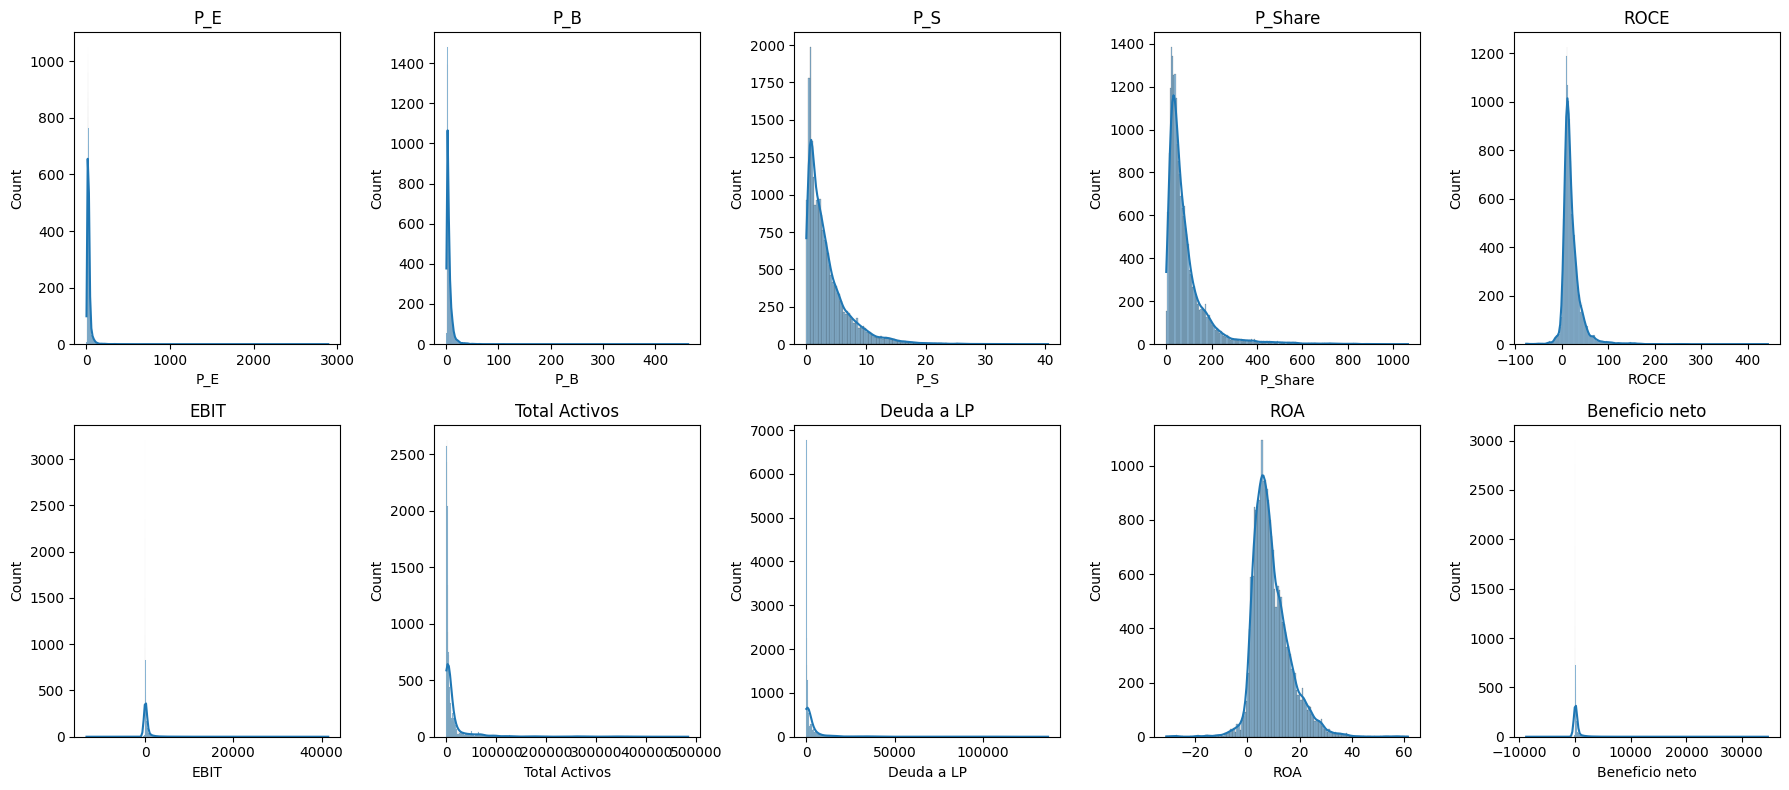


--- 4. Matriz de correlación (subconjunto) ---


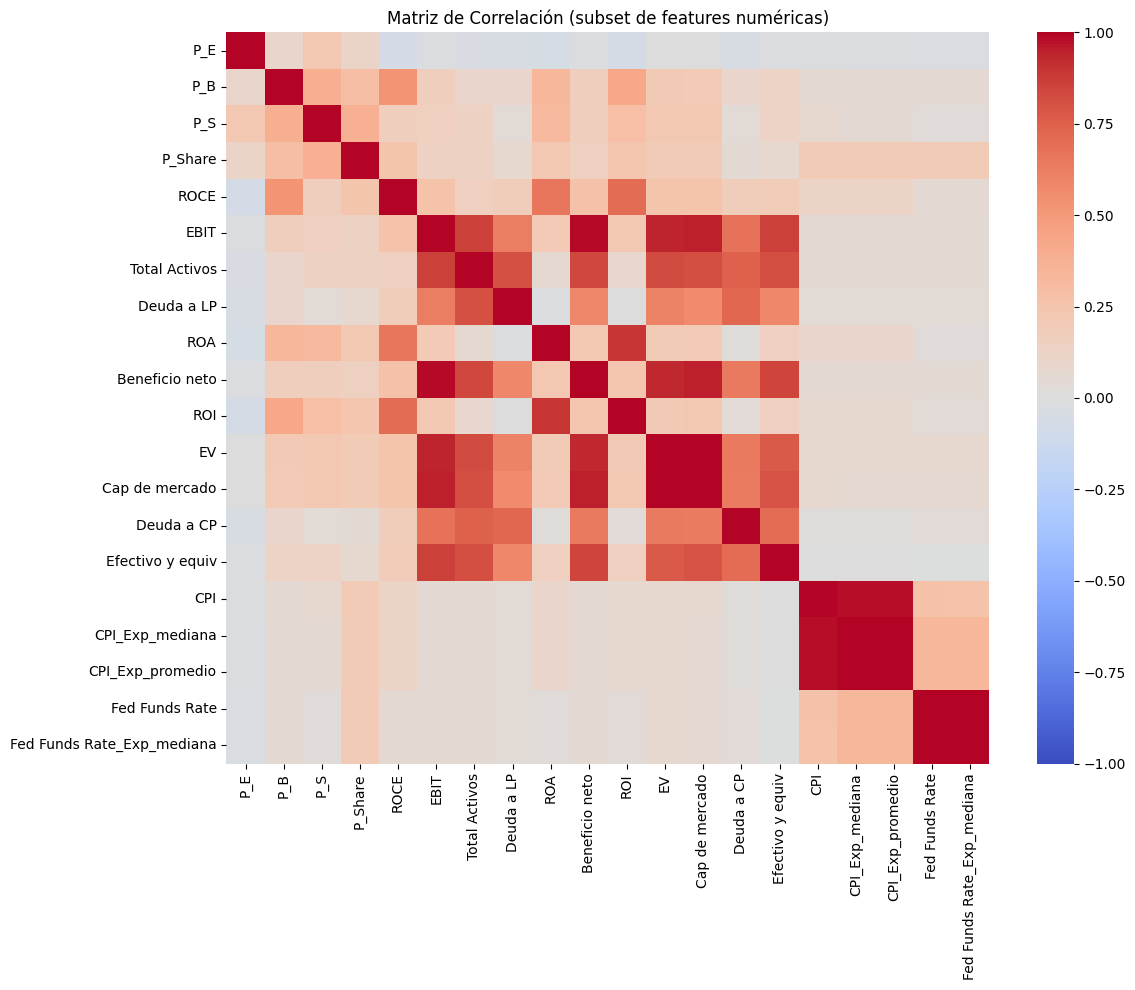


--- 6. Outliers (|Z|>3) en features numéricas ---
Total Activos                     2.462963
P_Share                            2.37963
Deuda a LP                         2.12037
P_S                               1.925926
ROCE                              1.847222
Efectivo y equiv                  1.763889
Deuda a CP                         1.75463
ROI                                   1.75
Non farm payrolls_Exp_promedio    1.666667
Non farm payrolls_Exp_mediana     1.666667
Beneficio neto                    1.555556
EBIT                              1.486111
Cap de mercado                    1.453704
EV                                1.356481
ROA                                   1.25
P_B                               1.189815
Non farm payrolls                 0.833333
P_E                               0.657407
CPI                                    0.0
CPI_Exp_mediana                        0.0
CPI_Exp_promedio                       0.0
Fed Funds Rate                         0.0
Fed

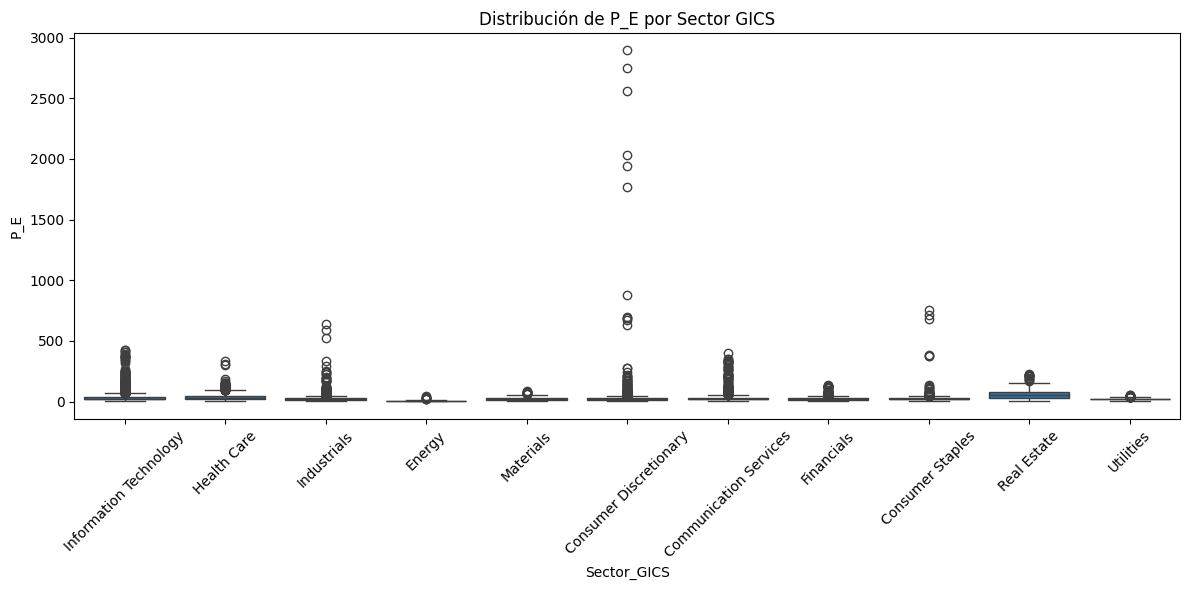


✅ EDA básico-financiero completado sobre df_model.


In [28]:
# =============================================================================
# BLOQUE 8 – EDA sobre df_model (panel de modelado)
# =============================================================================

df_eda = df.copy()
print("\n📊 EDA sobre df_model (dataset de modelado)")

# 1) Resumen general
print("\n--- 1. Resumen general ---")
print(df_eda.info())
print(f"\nForma del dataset: {df_eda.shape}")
if "Empresa" in df_eda.columns:
    print(f"Empresas únicas: {df_eda['Empresa'].nunique()}")
if "Fecha" in df_eda.columns:
    print(f"Fechas únicas: {df_eda['Fecha'].nunique()}")
    print(f"Rango temporal: {df_eda['Fecha'].min().date()} – {df_eda['Fecha'].max().date()}")

# 2) Missing values
print("\n--- 2. Valores faltantes (>0%) ---")
missing = df_eda.isna().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.to_frame(name='% Missing').round(2))

# 3) Features numéricas + histogramas
num_features = df_eda.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_to_plot = min(10, len(num_features))
print(f"\n--- 3. Histogramas de {num_to_plot} features numéricas ---")
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_features[:num_to_plot]):
    sns.histplot(df_eda[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# 4) Matriz de correlación (subconjunto para que sea legible)
print("\n--- 4. Matriz de correlación (subconjunto) ---")
sub_corr_feats = num_features[:20]  # ajusta si quieres un conjunto específico
corr_matrix = df_eda[sub_corr_feats].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (subset de features numéricas)')
plt.tight_layout()
plt.show()

# 5) Correlación con el Target
if 'TARGET_COL' in globals() and TARGET_COL in df_eda.columns:
    print("\n--- 5. Correlación (absoluta) de features numéricas con el Target ---")
    corr_target = (
        df_eda[num_features + [TARGET_COL]]
        .corr()[TARGET_COL]
        .drop(TARGET_COL)
        .abs()
        .sort_values(ascending=False)
    )
    print(corr_target.head(15).to_frame(name='|Corr con target|').round(3))

# 6) Outliers por Z-score
print("\n--- 6. Outliers (|Z|>3) en features numéricas ---")
outliers_df = pd.DataFrame(index=num_features, columns=['% Outliers'])
for col in num_features:
    col_std = df_eda[col].std()
    if col_std == 0 or pd.isna(col_std):
        outliers_df.loc[col, '% Outliers'] = 0.0
        continue
    z = (df_eda[col] - df_eda[col].mean()) / col_std
    outliers_df.loc[col, '% Outliers'] = (z.abs() > 3).mean() * 100

print(outliers_df['% Outliers'].sort_values(ascending=False).round(2))

# 7) Distribución sectorial de un ratio clave
if 'Sector_GICS' in df_eda.columns:
    feat_box = 'ROE' if 'ROE' in df_eda.columns else num_features[0]
    print(f"\n--- 7. Boxplot de {feat_box} por Sector_GICS ---")
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Sector_GICS', y=feat_box, data=df_eda)
    plt.title(f'Distribución de {feat_box} por Sector GICS')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\n✅ EDA básico-financiero completado sobre df_model.")



📊 BLOQUE 8.b – Análisis de Tamaño y Liquidez (con descarga de Volumen)
   · Tickers únicos a consultar: 180
   · Descargando volumen desde Yahoo Finance (últimos 6 meses)...


ERROR:yfinance:
5 Failed downloads:
ERROR:yfinance:['HEES', 'PDCO', 'ROIC', 'WBA', 'BECN']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


   ✅ Volumen descargado y agregado por ticker.
   · Ventana de análisis: 2022-09-30 – 2024-09-30
   · Empresas en el snapshot: 180


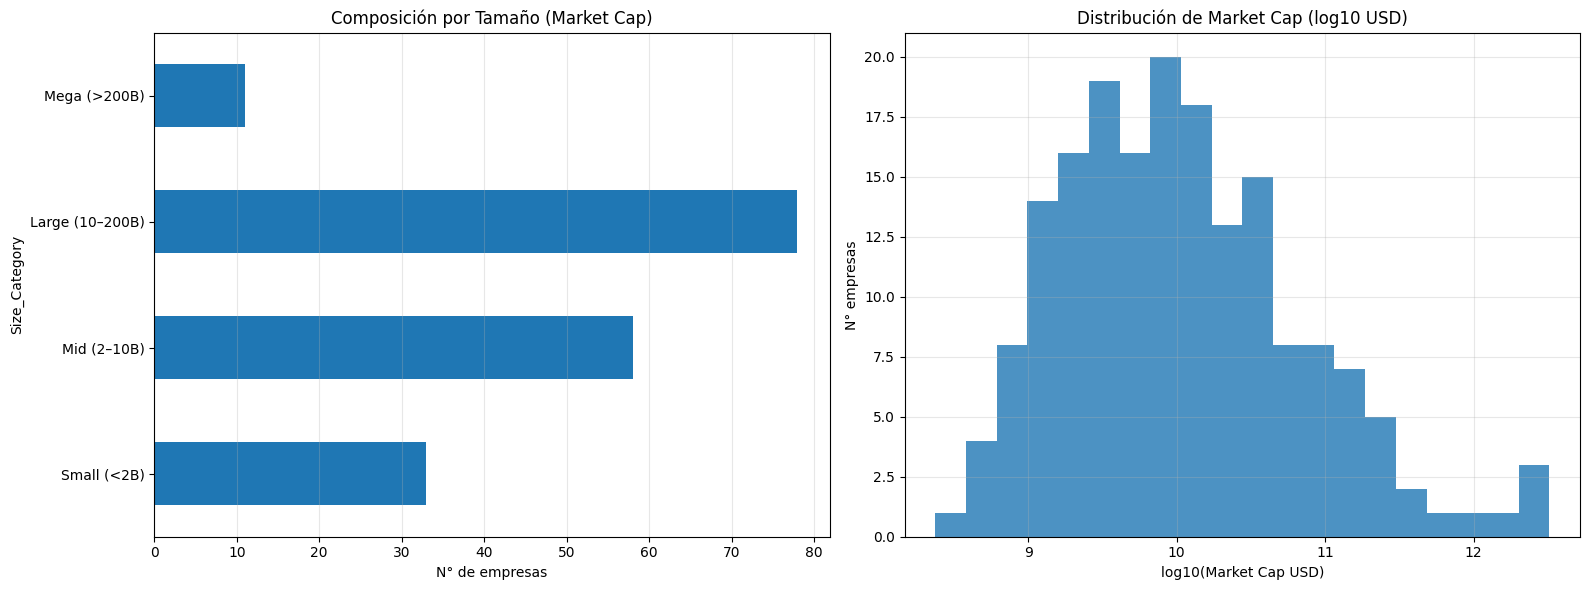


📦 Composición por tamaño (según capitalización mediana, últimos 24 meses):


,N_empresas
Size_Category,
Small (<2B),33
Mid (2–10B),58
Large (10–200B),78
Mega (>200B),11


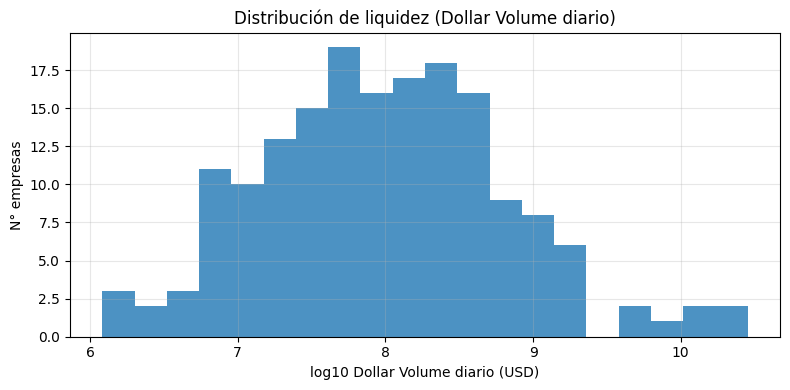

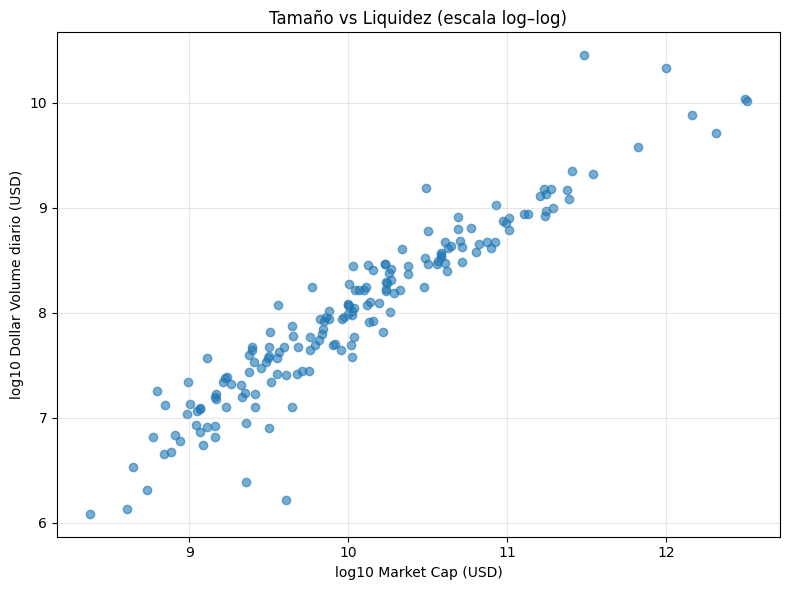


📦 Resumen de Liquidez del Universo:
   · Liquidez diaria mediana (Dollar Volume): $91,442,250
   · Empresas con < USD 1M de volumen diario: 2 de 180 (1.1%)
   ✅ Conclusión: universo altamente líquido, apto para estrategias institucionales.
✅ EDA 8.b completado.


In [29]:
# =============================================================================
# BLOQUE 8.b – EDA: Tamaño (Market Cap) y Liquidez (descarga volumen)
# =============================================================================

print("\n📊 BLOQUE 8.b – Análisis de Tamaño y Liquidez (con descarga de Volumen)")

# 0) DataFrame base
df_base = globals().get("df_model", None)
if df_base is None:
    df_base = df.copy()

# 1) Columnas clave
if "Fecha" not in df_base.columns:
    raise RuntimeError("No se encontró la columna 'Fecha' en df_base.")
if "Empresa" not in df_base.columns:
    raise RuntimeError("No se encontró la columna 'Empresa' en df_base.")

df_base["Fecha"] = pd.to_datetime(df_base["Fecha"])

# 2) Limpiar tickers para Yahoo Finance
def clean_ticker(t):
    # Convierte "AAPL US Equity" -> "AAPL"
    return str(t).split()[0].strip()

unique_tickers = df_base["Empresa"].dropna().unique()
yahoo_tickers = [clean_ticker(t) for t in unique_tickers]
print(f"   · Tickers únicos a consultar: {len(yahoo_tickers)}")

# 3) Descargar Volumen reciente (6 meses) si no estamos OFFLINE
OFFLINE = bool(globals().get("OFFLINE", False))
vol_map = {}

if not OFFLINE:
    print("   · Descargando volumen desde Yahoo Finance (últimos 6 meses)...")
    try:
        import yfinance as yf
    except ImportError:
        import os
        os.system("pip install --quiet --upgrade --no-cache-dir yfinance")
        import yfinance as yf

    try:
        data_vol = yf.download(
            tickers=yahoo_tickers,
            period="6mo",
            interval="1d",
            progress=False,
            auto_adjust=True,
            group_by="ticker",
        )
        # data_vol['<TICKER>']['Volume'] si MultiIndex (por ticker),
        # o data_vol['Volume'] si un solo ticker
        if isinstance(data_vol.columns, pd.MultiIndex):
            # Reorganizamos a un DataFrame: filas=fecha, cols=ticker (Volume)
            vol_panels = {}
            for t in yahoo_tickers:
                if (t, "Volume") in data_vol.columns:
                    vol_panels[t] = data_vol[(t, "Volume")]
            if vol_panels:
                vol_data = pd.DataFrame(vol_panels)
            else:
                vol_data = pd.DataFrame()
        else:
            # Caso raro: un solo ticker
            vol_data = data_vol[["Volume"]]
            vol_data.columns = [yahoo_tickers[0]]

        if not vol_data.empty:
            median_vol = vol_data.median()  # mediana por ticker
            vol_map = median_vol.to_dict()
            print("   ✅ Volumen descargado y agregado por ticker.")
        else:
            print("   ⚠️ No se obtuvieron datos de volumen válidos.")
            vol_map = {}
    except Exception as e:
        print(f"   ❌ Error descargando volumen: {e}")
        vol_map = {}
else:
    print("   ⚠️ OFFLINE=True → No se descarga volumen, solo se analiza Market Cap.")

# 4) Foto del universo (últimos 24 meses)
max_date = df_base["Fecha"].max()
cutoff = max_date - pd.DateOffset(months=24)
df_win = df_base[df_base["Fecha"] >= cutoff].copy()

df_snap = (
    df_win
    .sort_values("Fecha")
    .groupby("Empresa")
    .tail(1)          # última observación por empresa
    .reset_index(drop=True)
)

print(f"   · Ventana de análisis: {cutoff.date()} – {max_date.date()}")
print(f"   · Empresas en el snapshot: {len(df_snap)}")

# 5) Integrar Volumen y Dollar Volume
df_snap["Ticker_Yahoo"] = df_snap["Empresa"].apply(clean_ticker)
df_snap["Volumen_Medio_Diario"] = df_snap["Ticker_Yahoo"].map(vol_map)

if "P_Share" in df_snap.columns and "Volumen_Medio_Diario" in df_snap.columns:
    df_snap["Dollar_Volume"] = df_snap["P_Share"].astype(float) * df_snap["Volumen_Medio_Diario"].astype(float)
else:
    df_snap["Dollar_Volume"] = np.nan

# 6) Market Cap (tamaño)
cap_col = "Cap de mercado"
if cap_col not in df_snap.columns:
    print("⚠️ No se encontró columna de Market Cap en df_snap. Se analizará solo liquidez si existe.")
else:
    median_cap = df_snap[cap_col].median()
    # Convertir a billones (B) si está en unidades o millones
    if median_cap > 1_000_000_000:     # Unidades
        df_snap["Mkt_Cap_B"] = df_snap[cap_col] / 1e9
    elif median_cap > 1_000:           # Millones
        df_snap["Mkt_Cap_B"] = df_snap[cap_col] / 1e3
    else:
        df_snap["Mkt_Cap_B"] = df_snap[cap_col]

    # Buckets por tamaño
    bins   = [0, 2, 10, 200, np.inf]
    labels = ["Small (<2B)", "Mid (2–10B)", "Large (10–200B)", "Mega (>200B)"]
    df_snap["Size_Category"] = pd.cut(df_snap["Mkt_Cap_B"], bins=bins, labels=labels)

    # --- Gráficos de tamaño ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # A) Composición por tamaño
    size_counts = df_snap["Size_Category"].value_counts().reindex(labels)
    size_counts.plot(kind="barh", ax=axes[0])
    axes[0].set_title("Composición por Tamaño (Market Cap)")
    axes[0].set_xlabel("N° de empresas")
    axes[0].grid(axis="x", alpha=0.3)

    # B) Histograma log10 Market Cap
    plt_cap = df_snap["Mkt_Cap_B"].replace({0: np.nan}).dropna()
    axes[1].hist(np.log10(plt_cap * 1e9), bins=20, alpha=0.8)  # volver a USD
    axes[1].set_title("Distribución de Market Cap (log10 USD)")
    axes[1].set_xlabel("log10(Market Cap USD)")
    axes[1].set_ylabel("N° empresas")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n📦 Composición por tamaño (según capitalización mediana, últimos 24 meses):")
    display(size_counts.to_frame("N_empresas"))

# 7) Liquidez: distribución y scatter tamaño–liquidez
if df_snap["Dollar_Volume"].notna().sum() > 0:
    dv_valid = df_snap["Dollar_Volume"].replace({0: np.nan}).dropna()

    # Histograma liquidez
    plt.figure(figsize=(8, 4))
    plt.hist(np.log10(dv_valid), bins=20, alpha=0.8)
    plt.xlabel("log10 Dollar Volume diario (USD)")
    plt.ylabel("N° empresas")
    plt.title("Distribución de liquidez (Dollar Volume diario)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Scatter tamaño vs liquidez si tenemos ambas
    if "Mkt_Cap_B" in df_snap.columns:
        df_sc = df_snap[["Mkt_Cap_B", "Dollar_Volume"]].replace({0: np.nan}).dropna()
        if not df_sc.empty:
            plt.figure(figsize=(8, 6))
            plt.scatter(
                np.log10(df_sc["Mkt_Cap_B"] * 1e9),
                np.log10(df_sc["Dollar_Volume"]),
                alpha=0.6,
            )
            plt.xlabel("log10 Market Cap (USD)")
            plt.ylabel("log10 Dollar Volume diario (USD)")
            plt.title("Tamaño vs Liquidez (escala log–log)")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("⚠️ No hay suficientes datos válidos para el scatter tamaño–liquidez.")
else:
    print("⚠️ No se pudo calcular liquidez (Dollar Volume) para la mayoría de las empresas.")

# 8) Resumen textual de liquidez
if df_snap["Dollar_Volume"].notna().sum() > 0:
    liq_mediana = df_snap["Dollar_Volume"].median()
    n_total     = len(df_snap)
    bajo_liq    = (df_snap["Dollar_Volume"] < 1_000_000).sum()

    print("\n📦 Resumen de Liquidez del Universo:")
    print(f"   · Liquidez diaria mediana (Dollar Volume): ${liq_mediana:,.0f}")
    print(f"   · Empresas con < USD 1M de volumen diario: {bajo_liq} de {n_total} "
          f"({bajo_liq / n_total:.1%})")

    if liq_mediana > 5_000_000:
        print("   ✅ Conclusión: universo altamente líquido, apto para estrategias institucionales.")
    elif liq_mediana > 1_000_000:
        print("   ✅ Conclusión: liquidez razonable, con precaución en small caps puntuales.")
    else:
        print("   ⚠️ Conclusión: universo con restricciones de liquidez importantes.")
else:
    print("⚠️ No hay suficientes datos de Dollar Volume para un resumen de liquidez fiable.")

print("✅ EDA 8.b completado.")


In [30]:
# ==============================================================================
# BLOQUE 9 · FEATURE ENGINEERING AVANZADO
#   – Momentum (1-3-6-12 m)
#   – Volatilidad (3-6-12 m)
#   – Sorpresas macro
#   – Momentum 18 m + Vol-de-Vol 6 m
#   – PE-zscore 6 m
#   – Momentum sectorial (seguro, usando GICS/fallback)
#   – Dummies sector GICS  / Dummy pandemia
#   – VIX (Volatilidad Implícita Macro)
# ==============================================================================

print("\nIniciando Feature Engineering Avanzado…")

# ────────────────────────────────────────────────────────────────────────────────
# 0)  Asegurar listas y parámetros base
# ────────────────────────────────────────────────────────────────────────────────
if 'features_mercado' not in locals() or not isinstance(features_mercado, list):
    features_mercado = []

if 'MIN_PERIODS_WINDOW' not in locals():
    MIN_PERIODS_WINDOW = 3

if 'VALUATION_MOMENTUM_WINDOW' not in locals():
    VALUATION_MOMENTUM_WINDOW = 6

# ────────────────────────────────────────────────────────────────────────────────
# 9.1  Momentum y volatilidad de precios + sorpresas macro
# ────────────────────────────────────────────────────────────────────────────────

# --- Momentum de precios -------------------------------------------------------
print("  · Calculando momentum de precios...")
for p in (1, 3, 6, 12):
    col = f'ret_P_Share_{p}m_base'
    df[col] = df.groupby('Empresa')['P_Share'].pct_change(p)
    features_mercado.append(col)

# --- Volatilidad rolling -------------------------------------------------------
print("  · Calculando volatilidad de precios...")
for w in (3, 6, 12):
    col = f'vol_P_Share_{w}m_base'
    # rolling std por empresa manteniendo alineación
    df[col] = (
        df.groupby('Empresa', group_keys=False)['P_Share']
          .apply(lambda s: s.rolling(window=w, min_periods=MIN_PERIODS_WINDOW).std())
    )
    features_mercado.append(col)

# --- Sorpresas macro -----------------------------------------------------------
print("  · Calculando sorpresas macro...")
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10_000
df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10_000
df['dif_NFP_mediana'] =  df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana']

print("  · Features base creadas (sin imputar aquí; el _lag1 y dropna limpian luego).")

# --- Momentum "skip-1" (12–1 y 6–1): mejor alineado al horizonte 3m ---
print("  · Calculando momentum 'skip-1' (12-1 y 6-1)...")
df['mom_12_1_tmp12'] = df.groupby('Empresa')['P_Share'].pct_change(12)
df['mom_12_1_tmp1']  = df.groupby('Empresa')['P_Share'].pct_change(1)
df['mom_12_1']       = df['mom_12_1_tmp12'] - df['mom_12_1_tmp1']

df['mom_6_1_tmp6']   = df.groupby('Empresa')['P_Share'].pct_change(6)
df['mom_6_1']        = df['mom_6_1_tmp6'] - df['mom_12_1_tmp1']

df.drop(columns=['mom_12_1_tmp12','mom_12_1_tmp1','mom_6_1_tmp6'], inplace=True)
features_mercado += ['mom_12_1','mom_6_1']

# ────────────────────────────────────────────────────────────────────────────────
# 9-plus  · Momentum 18 m (ret_18m_lag1)  +  Vol-de-Vol 6 m (vov_6m_lag1)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Añadiendo momentum 18 m y vol-de-vol 6 m…")

# Momentum 18m con un lag adicional (info conocida al cierre t-1)
df['ret_18m_tmp']  = df.groupby('Empresa')['P_Share'].pct_change(18)
df['ret_18m_lag1'] = df.groupby('Empresa')['ret_18m_tmp'].shift(1).fillna(0.0)
df.drop(columns='ret_18m_tmp', inplace=True)
features_mercado.append('ret_18m_lag1')

# Vol-de-Vol 6m (std de la std rolling 6m), winsorizado 1-99%, luego lag(1)
vol6 = (
    df.groupby('Empresa', group_keys=False)['P_Share']
      .apply(lambda s: s.rolling(window=6, min_periods=3).std())
)
vov6 = (
    vol6.groupby(df['Empresa'], group_keys=False)
        .apply(lambda s: s.rolling(window=6, min_periods=3).std())
)

# winsorizar por percentiles globales (robusto)
p1, p99 = vov6.quantile([.01, .99])
vov6_clip = vov6.clip(lower=p1 if pd.notna(p1) else None,
                      upper=p99 if pd.notna(p99) else None)

df['vov_6m_lag1'] = vov6_clip.groupby(df['Empresa']).shift(1).fillna(0.0)
features_mercado.append('vov_6m_lag1')
print("    · ret_18m_lag1 y vov_6m_lag1 añadidas.")

# ────────────────────────────────────────────────────────────────────────────────
# 9.2  Z-score de valoración (P/E winsorizado, ventana 6 m)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Calculando Z-score de valoración (PE_zscore_6m)...")

def winsor_1pct(series: pd.Series) -> pd.Series:
    """Winsoriza la serie al 1 % por cola, conservando índice."""
    if series.dropna().shape[0] < 2:
        return series
    arr = winsorize(series.dropna().astype(float), limits=[.01, .01])
    return pd.Series(arr, index=series.dropna().index, dtype='float64').reindex(series.index)

# 1) P/E winsorizado empresa-a-empresa
df['P_E_wins'] = (
    df.groupby('Empresa', group_keys=False)['P_E']
      .apply(winsor_1pct)
)

# 2) Mediana y MAD móvil (6m) por empresa
eps = 1e-6
def rolling_mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med)) + eps

df['median_6m'] = (
    df.groupby('Empresa', group_keys=False)['P_E_wins']
      .apply(lambda s: s.rolling(window=VALUATION_MOMENTUM_WINDOW,
                                 min_periods=MIN_PERIODS_WINDOW).median())
)
df['mad_6m'] = (
    df.groupby('Empresa', group_keys=False)['P_E_wins']
      .apply(lambda s: s.rolling(window=VALUATION_MOMENTUM_WINDOW,
                                 min_periods=MIN_PERIODS_WINDOW).apply(rolling_mad, raw=True))
)

# 3) Z-score robusto
df['PE_zscore_6m'] = (df['P_E_wins'] - df['median_6m']) / (df['mad_6m'] * 1.4826)
df['PE_zscore_6m'].replace([np.inf, -np.inf], 0.0, inplace=True)
df['PE_zscore_6m'].fillna(0.0, inplace=True)

# 4) Dummy historial corto
df['is_short_hist_zscore'] = (df.groupby('Empresa').cumcount() < VALUATION_MOMENTUM_WINDOW).astype(int)

# Limpieza temporales
df.drop(columns=['P_E_wins', 'median_6m', 'mad_6m'], inplace=True)
features_mercado += ['PE_zscore_6m', 'is_short_hist_zscore']
print("  · Z-score de valoración (PE_zscore_6m) calculado.")

# ────────────────────────────────────────────────────────────────────────────────
# 9.2-bis  Momentum sectorial (seguro) — usa Sector_GICS con fallback
# ────────────────────────────────────────────────────────────────────────────────
print("  · Calculando señal de momentum sectorial (versión segura, GICS/fallback)…")

# Columna de sector de referencia: GICS si existe; si no, Sector; si no, 'Unknown'
sec1 = df['Sector_GICS'] if 'Sector_GICS' in df.columns else pd.Series(index=df.index, dtype='object')
sec2 = df['Sector']      if 'Sector'      in df.columns else pd.Series(index=df.index, dtype='object')
df['Sector_ref'] = sec1.where(sec1.notna(), sec2).fillna('Unknown')


# Usar precios lag-1 (info disponible al cierre t-1)
df['P_Share_l1'] = df.groupby('Empresa')['P_Share'].shift(1)

tmp = (
    df[['Fecha', 'Empresa', 'Sector_ref', 'P_Share_l1']]
      .dropna(subset=['Sector_ref', 'P_Share_l1'])
      .sort_values(['Empresa', 'Fecha'])
)

# Retornos sobre P_Share_l1 (→ info hasta t-1)
tmp['ret1']  = tmp.groupby('Empresa')['P_Share_l1'].pct_change(1)
tmp['ret12'] = tmp.groupby('Empresa')['P_Share_l1'].pct_change(12)

# Promedio por sector y score
sector_mom = (
    tmp.groupby(['Fecha', 'Sector_ref'])[['ret12', 'ret1']].mean().reset_index()
)
sector_mom['sec_score'] = 0.5 * (sector_mom['ret12'] - sector_mom['ret1'])

# Z-score cross-sectional por fecha
def _z(s):
    mu, sd = s.mean(), s.std(ddof=0)
    return (s - mu) / (sd + 1e-9) if sd > 0 else 0.0

sector_mom['sec_score_z'] = sector_mom.groupby('Fecha')['sec_score'].transform(_z)

# Unir al DF principal y dejar la columna YA laggeada
df = df.merge(sector_mom[['Fecha', 'Sector_ref', 'sec_score_z']],
              on=['Fecha', 'Sector_ref'], how='left')

df['sec_score_z_safe'] = df['sec_score_z'].fillna(0.0)
df.drop(columns=['sec_score_z'], inplace=True)

# registra la feature con el nuevo nombre
features_mercado.append('sec_score_z_safe')
print("  · Señal sectorial segura incorporada: sec_score_z_safe")

# ────────────────────────────────────────────────────────────────────────────────
# 9.3  Dummies de sector (GICS)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Creando dummies sector GICS…")
d_sec = pd.get_dummies(df['Sector_GICS'], prefix='sector', drop_first=True)
df = pd.concat([df, d_sec], axis=1)

# añadir las dummies a la lista de mercado
features_mercado += [c for c in d_sec.columns]
print(f"  · Dummies sector GICS creadas: {len(d_sec.columns)} columnas")

# ────────────────────────────────────────────────────────────────────────────────
# 9.4  Dummy pandemia (mar-20 → jun-21)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Creando dummy de pandemia...")
df['pandemic_dummy'] = ((df['Fecha'] >= '2020-03-01') & (df['Fecha'] <= '2021-06-30')).astype(int)
features_mercado.append('pandemic_dummy')
print("  · Dummy pandemia creada y añadida a las features.")


# ────────────────────────────────────────────────────────────────────────────────
# 9.5  VIX (Volatilidad Implícita Macro)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Generando features VIX (^VIX) de forma robusta...")

def _winsor_clip(s: pd.Series, lower=0.01, upper=0.01) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    if s.dropna().empty:
        return s
    lo = s.quantile(lower)
    hi = s.quantile(1.0 - upper)
    return s.clip(lo, hi)

def download_vix_monthly(start="2000-01-01") -> pd.DataFrame:
    import yfinance as yf

    raw = yf.download("^VIX", start=start, progress=False, auto_adjust=False)

    if raw is None or raw.empty:
        raise ValueError("Descarga de ^VIX vacía (raw vacío).")

    # Si viene MultiIndex (raro pero pasa), aplanamos
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    # Elegir columna disponible
    if "Adj Close" in raw.columns:
        s = raw["Adj Close"].copy()
    elif "Close" in raw.columns:
        s = raw["Close"].copy()
    else:
        # último recurso: primera columna numérica
        s = raw.select_dtypes(include="number").iloc[:, 0].copy()

    s.name = "vix_close"

    vix_m = s.resample("M").last().to_frame()
    vix_m.index = vix_m.index.to_period("M").to_timestamp("M")  # fin de mes

    # Features macro (a nivel serie mensual)
    vix_m["log_vix"] = np.log(vix_m["vix_close"])
    vix_m["dvix"]    = vix_m["log_vix"].diff()

    # Lags (t-1)
    vix_m["log_vix_lag1"] = vix_m["log_vix"].shift(1)
    vix_m["dvix_lag1"]    = vix_m["dvix"].shift(1)

    # Winsorizar lags (robusto, preserva índice)
    vix_m["log_vix_lag1"] = _winsor_clip(vix_m["log_vix_lag1"], 0.01, 0.01)
    vix_m["dvix_lag1"]    = _winsor_clip(vix_m["dvix_lag1"],    0.01, 0.01)

    return vix_m[["log_vix_lag1", "dvix_lag1"]]

if OFFLINE:
    print("OFFLINE = True → se omite descarga VIX. log_vix_lag1/dvix_lag1 = NaN.")
    df["log_vix_lag1"] = np.nan
    df["dvix_lag1"]    = np.nan
else:
    try:
        vix_m = download_vix_monthly(start="2000-01-01")

        # Clave mensual (fin de mes) para merge
        df["Fecha_M"] = df["Fecha"].dt.to_period("M").dt.to_timestamp("M")

        # Merge: misma VIX mensual para todas las empresas del mes
        df = df.merge(vix_m, left_on="Fecha_M", right_index=True, how="left")

        # Limpieza
        df.drop(columns=["Fecha_M"], inplace=True, errors="ignore")

        # Registrar en features_macro
        if 'features_macro' not in locals() or not isinstance(features_macro, list):
            features_macro = []
        for c in ["log_vix_lag1", "dvix_lag1"]:
            if c in df.columns and c not in features_macro:
                features_macro.append(c)

        print("    · Features VIX creadas OK: log_vix_lag1, dvix_lag1")
    except Exception as e:
        print(f"    ⚠️ Error descargando/procesando VIX: {e}")
        df["log_vix_lag1"] = np.nan
        df["dvix_lag1"]    = np.nan


# ────────────────────────────────────────────────────────────────────────────────
# 9.6  Consolidar lista de features de mercado (sin duplicados)
# ────────────────────────────────────────────────────────────────────────────────
features_mercado = list(dict.fromkeys(features_mercado))  # dedup preservando orden

print("\n— Fin Bloque 9 · DataFrame listo para los lags contables —")
try:
    print("Ejemplo de filas:")
    print(df.head(5))
except Exception:
    pass


Iniciando Feature Engineering Avanzado…
  · Calculando momentum de precios...
  · Calculando volatilidad de precios...
  · Calculando sorpresas macro...
  · Features base creadas (sin imputar aquí; el _lag1 y dropna limpian luego).
  · Calculando momentum 'skip-1' (12-1 y 6-1)...
  · Añadiendo momentum 18 m y vol-de-vol 6 m…
    · ret_18m_lag1 y vov_6m_lag1 añadidas.
  · Calculando Z-score de valoración (PE_zscore_6m)...
  · Z-score de valoración (PE_zscore_6m) calculado.
  · Calculando señal de momentum sectorial (versión segura, GICS/fallback)…
  · Señal sectorial segura incorporada: sec_score_z_safe
  · Creando dummies sector GICS…
  · Dummies sector GICS creadas: 10 columnas
  · Creando dummy de pandemia...
  · Dummy pandemia creada y añadida a las features.
  · Generando features VIX (^VIX) de forma robusta...
    · Features VIX creadas OK: log_vix_lag1, dvix_lag1

— Fin Bloque 9 · DataFrame listo para los lags contables —
Ejemplo de filas:
          Empresa      Fecha      P_E  

In [31]:
df.head(20)

,Empresa,Fecha,P_E,P_B,P_S,P_Share,ROCE,EBIT,Total Activos,Deuda a LP,...,sector_Financials,sector_Health Care,sector_Industrials,sector_Information Technology,sector_Materials,sector_Real Estate,sector_Utilities,pandemic_dummy,log_vix_lag1,dvix_lag1
0,AAPL US Equity,2014-10-31,16.8500,5.6796,3.6047,27.000,32.246867,10576.333333,225626.333333,29015.666667,...,False,False,False,True,False,False,False,0,2.791778,0.299400
1,AAPL US Equity,2014-11-30,18.5553,6.2544,3.9695,29.733,32.929333,10870.666667,228732.666667,29001.333333,...,False,False,False,True,False,False,False,0,2.641198,-0.150581
2,AAPL US Equity,2014-12-31,14.9215,5.2147,3.2904,27.595,33.611800,11165.000000,231839.000000,28987.000000,...,False,False,False,True,False,False,False,0,2.590017,-0.051181
3,AAPL US Equity,2015-01-31,15.8381,5.5350,3.4925,29.290,34.123267,15525.333333,241857.333333,30159.333333,...,False,False,False,True,False,False,False,0,2.954910,0.364893
4,AAPL US Equity,2015-02-28,17.3656,6.0689,3.8294,32.115,34.634733,19885.666667,251875.666667,31331.666667,...,False,False,False,True,False,False,False,0,3.043093,0.088182
5,AAPL US Equity,2015-03-31,15.3999,5.5579,3.4464,31.108,35.146200,24246.000000,261894.000000,32504.000000,...,False,False,False,True,False,False,False,0,2.590767,-0.452326
6,AAPL US Equity,2015-04-30,15.4890,5.5900,3.4664,31.288,36.221300,22256.666667,261660.666667,35026.666667,...,False,False,False,True,False,False,False,0,2.727199,0.136432
7,AAPL US Equity,2015-05-31,16.1239,5.8192,3.6085,32.570,37.296400,20267.333333,261427.333333,37549.333333,...,False,False,False,True,False,False,False,0,2.677591,-0.049608
8,AAPL US Equity,2015-06-30,14.4905,5.6940,3.2548,31.356,38.371500,18278.000000,261194.000000,40072.000000,...,False,False,False,True,False,False,False,0,2.627563,-0.050028
9,AAPL US Equity,2015-07-31,14.0140,5.5067,3.1477,30.325,39.296467,16879.666667,265179.666667,42521.000000,...,False,False,False,True,False,False,False,0,2.903069,0.275506


In [32]:
# # ==============================================================================
# # BLOQUE 10 · ANCLAJE CONTABLE (Q-2) + TARGET + LISTAS DE FEATURES (ROBUSTO)
# #   - Asegura Fecha (datetime, fin de mes), Month (Period[M]) e is_rebal
# #   - Ancla contables con Q-2 (sin look-ahead) como en tu diseño
# #   - Define features_contables / features_mercado / features_macro (filtradas a columnas existentes)
# #   - Construye TARGET_COL = retorno_futuro_{TARGET_HORIZON}m desde P_Share
# #   - Guarda run_metadata.json (sin asumir variables inexistentes)
# # ==============================================================================

# import os
# import numpy as np
# import pandas as pd

# print("\n⏩  BLOQUE 10  –  Anclaje contable y construcción del dataset final…")

# # ------------------------------------------------------------------------------
# # 10.0 · Helpers de robustez: Fecha/Month, normalizaciones
# # ------------------------------------------------------------------------------
# def _ensure_fecha_month(df: pd.DataFrame) -> pd.DataFrame:
#     df = df.copy()

#     # Normalizar nombre de Fecha si viene con otro nombre
#     if "Fecha" not in df.columns:
#         for alt in ("Date", "date", "FECHA"):
#             if alt in df.columns:
#                 df.rename(columns={alt: "Fecha"}, inplace=True)
#                 break

#     if "Fecha" not in df.columns:
#         raise KeyError("No encuentro columna 'Fecha' (o 'Date'/'date').")

#     # Parse a datetime
#     df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
#     if df["Fecha"].isna().any():
#         n_bad = int(df["Fecha"].isna().sum())
#         raise ValueError(f"'Fecha' tiene {n_bad} NaT. Revisa el formato de fechas antes de seguir.")

#     # Forzar fin de mes (coherente con panel mensual)
#     df["Fecha"] = df["Fecha"].dt.to_period("M").dt.to_timestamp(how="end")

#     # Month Period[M]
#     df["Month"] = df["Fecha"].dt.to_period("M")

#     return df

# def _ensure_price_col(df: pd.DataFrame) -> pd.DataFrame:
#     df = df.copy()
#     if "P_Share" not in df.columns and "P_share" in df.columns:
#         df.rename(columns={"P_share": "P_Share"}, inplace=True)
#     if "P_Share" not in df.columns:
#         raise KeyError("Falta columna 'P_Share' (precio) en df.")
#     return df

# # ------------------------------------------------------------------------------
# # 10.0bis · Config globales
# # ------------------------------------------------------------------------------
# TARGET_HORIZON = int(globals().get("TARGET_HORIZON", 3))  # tu setup: 3
# ANCHOR_Q       = int(globals().get("ANCHOR_Q", 2))        # 2 => meses 3/6/9/12
# REBAL_FREQ     = str(globals().get("REBAL_FREQ", "Q")).upper()  # "Q" o "M"

# # ------------------------------------------------------------------------------
# # 10.0ter · Pre-asegurar columnas base
# # ------------------------------------------------------------------------------
# df = _ensure_fecha_month(df)
# df = _ensure_price_col(df)

# if "Empresa" not in df.columns:
#     raise KeyError("Falta columna 'Empresa' en df.")

# # Orden estable
# df = df.sort_values(["Empresa", "Month"], kind="mergesort").reset_index(drop=True)

# # ------------------------------------------------------------------------------
# # 10.1 · DEFINICIÓN DE LISTAS DE FEATURES (tu lógica, robusta)
# # ------------------------------------------------------------------------------
# # 1) CONTABLES (nombres limpios desde el Excel)
# features_contables = [
#     'ROCE', 'ROA', 'EBIT', 'Total Activos', 'Deuda a LP',
#     'Beneficio neto', 'ROI', 'EV', 'Cap de mercado',
#     'Deuda a CP', 'Efectivo y equiv'
# ]
# features_contables = [col for col in features_contables if col in df.columns]

# # 2) MERCADO / MOMENTUM (consolidar sin duplicar, preservando orden)
# base_market = [
#     'P_E','P_B','P_S',
#     'ret_P_Share_1m_base','ret_P_Share_3m_base','ret_P_Share_6m_base','ret_P_Share_12m_base',
#     'vol_P_Share_3m_base','vol_P_Share_6m_base','vol_P_Share_12m_base',
#     'PE_zscore_6m','is_short_hist_zscore',
#     'ret_18m_lag1','vov_6m_lag1','sec_score_z_safe'
# ]

# # Si existe features_mercado previo, lo respetamos y deduplicamos contra base_market
# if 'features_mercado' in locals() and isinstance(features_mercado, list):
#     seen = set()
#     features_mercado = [x for x in (features_mercado + base_market) if not (x in seen or seen.add(x))]
# else:
#     features_mercado = base_market[:]

# # Añadir dummies sectoriales si existen
# features_mercado += [c for c in df.columns if c.startswith('sector_')]

# # 3) MACRO
# features_macro = ['dif_CPI_mediana', 'dif_NFP_mediana', 'dif_FFR_mediana']
# features_macro = [c for c in features_macro if c in df.columns]

# print(f"    · {len(features_contables):2d} contables, "
#       f"{len(features_mercado):2d} mercado, "
#       f"{len(features_macro):2d} macro definidos.")

# # ------------------------------------------------------------------------------
# # 10.2 · ANCLAJE CONTABLE (Q-2) – versión robusta (sin sombras)
# # ------------------------------------------------------------------------------
# if len(features_contables) > 0:
#     # Quarter actual y quarter "informe" = quarter - 2
#     df['periodo_trimestre'] = df['Fecha'].dt.to_period('Q')
#     QUARTERLY_OFFSET = 2
#     df['periodo_informe'] = df['periodo_trimestre'] - QUARTERLY_OFFSET

#     # Snapshot por empresa-quarter (último registro del quarter) de contables + Fecha
#     df_cont_q = (
#         df.sort_values("Fecha", kind="mergesort")
#           .groupby(["Empresa", "periodo_trimestre"], as_index=False)
#           .tail(1)[["Empresa", "periodo_trimestre", "Fecha"] + features_contables]
#           .copy()
#     )


#     # Evitar duplicar: eliminar contables actuales antes del merge
#     df.drop(columns=features_contables, errors='ignore', inplace=True)

#     # Merge: trae contables del trimestre (t-2) hacia las filas en t vía periodo_informe
#     df = pd.merge(
#         df,
#         df_cont_q[["Empresa", "periodo_trimestre"] + features_contables],  # <- no uses Fecha acá para el merge
#         left_on=["Empresa", "periodo_informe"],
#         right_on=["Empresa", "periodo_trimestre"],
#         how="left",
#         suffixes=("", "__dup")
#     )


#     # Limpieza auxiliares (quedan en memoria solo Month/Fecha)
#     df.drop(columns=[c for c in df.columns if c.startswith('periodo_')], inplace=True, errors='ignore')

#     print("    · Contables anclados correctamente (Q-2).")
# else:
#     print("    · [WARN] No se detectaron columnas contables en df; se omite anclaje Q-2.")

# # ------------------------------------------------------------------------------
# # 10.3 · Flags de rebalance (is_rebal) y Month (ya creado)
# # ------------------------------------------------------------------------------
# if REBAL_FREQ == "M":
#     df["is_rebal"] = True
# elif REBAL_FREQ == "Q":
#     # boundaries: (mes-1)%3 == ANCHOR_Q ; con ANCHOR_Q=2 => 3/6/9/12
#     df["is_rebal"] = ((df["Month"].dt.month - 1) % 3) == ANCHOR_Q
# else:
#     raise ValueError("REBAL_FREQ debe ser 'Q' o 'M'.")

# # ------------------------------------------------------------------------------
# # 10.4 · VARIABLE OBJETIVO (retorno futuro a TARGET_HORIZON meses)
# # ------------------------------------------------------------------------------
# TARGET_COL = f"retorno_futuro_{TARGET_HORIZON}m"

# df[TARGET_COL] = (
#     df.groupby('Empresa')['P_Share'].shift(-TARGET_HORIZON) / df['P_Share'] - 1
# )

# rows_before = len(df)
# df.dropna(subset=[TARGET_COL], inplace=True)
# df.reset_index(drop=True, inplace=True)
# print(f"    · Target creado. Filas eliminadas por NaN en target: {rows_before - len(df):,}")

# # df_m (solo meses de rebalance) — útil para entrenar SOLO trimestral si lo decides en Bloque 11
# df_m = df[df["is_rebal"]].copy()

# print("Filas df:", len(df), "| Filas df_m (rebalance):", len(df_m))
# print("Rango df_m:", df_m["Month"].min(), "→", df_m["Month"].max())

# print("\n✅  Fin Bloque 10 – DataFrame listo para el Bloque 11 (lags finales).")

# # ------------------------------------------------------------------------------
# # 10.5 · GUARDADO DE METADATOS DE LA CORRIDA (reproducibilidad) — robusto
# # ------------------------------------------------------------------------------
# # Snapshot de features crudas para trazabilidad (sin lag)
# if 'predictor_cols_final' in locals():
#     feature_cols_snapshot = predictor_cols_final
# else:
#     feature_cols_snapshot = list(dict.fromkeys(features_mercado + features_macro + features_contables))

# os.makedirs("artifacts", exist_ok=True)

# # Si no existe _atomic_json_dump, hacemos fallback seguro
# def _atomic_json_dump_fallback(obj, path):
#     import json, tempfile, os
#     d = os.path.dirname(path) or "."
#     os.makedirs(d, exist_ok=True)
#     fd, tmp = tempfile.mkstemp(dir=d, prefix=".tmp_", suffix=".json")
#     try:
#         with os.fdopen(fd, "w", encoding="utf-8") as f:
#             json.dump(obj, f, indent=2, ensure_ascii=False)
#         os.replace(tmp, path)
#     except Exception:
#         try:
#             os.remove(tmp)
#         except Exception:
#             pass
#         raise

# def save_run_metadata(path_json, seed, feature_cols, target_col, extra):
#     data = {"seed": seed, "features": feature_cols, "target": target_col, "extra": extra}
#     if "_atomic_json_dump" in globals():
#         globals()["_atomic_json_dump"](data, path_json)
#     else:
#         _atomic_json_dump_fallback(data, path_json)

# seed_use = int(globals().get("GLOBAL_SEED", 42))

# # gap_steps: si no existe, guardamos embargo en meses si está
# gap_steps = globals().get("GAP_STEPS", None)
# embargo_m = globals().get("EMBARGO_M", None)

# save_run_metadata(
#     path_json="artifacts/run_metadata.json",
#     seed=seed_use,
#     feature_cols=feature_cols_snapshot,
#     target_col=TARGET_COL,
#     extra={
#         "cv": {
#             "outer": "WalkForwardPurged",
#             "gap_steps": int(gap_steps) if gap_steps is not None else None,
#             "embargo_m": int(embargo_m) if embargo_m is not None else None,
#             "hold_steps": 1
#         },
#         "scorer": "ic_scorer",
#         "notes": f"Rebalance {REBAL_FREQ} (ANCHOR_Q={ANCHOR_Q}), target {TARGET_HORIZON}M, anclaje contable Q-2."
#     }
# )


In [33]:
# ==============================================================================
# BLOQUE 9.9 · SEC/EDGAR: Fechas de publicación (filing) para anclaje Point-in-Time
# ------------------------------------------------------------------------------
# Objetivo:
#   - Evitar el anclaje fijo Q-2 y el supuesto de "trimestre calendario".
#   - Para cada empresa y fin de mes, usar el último filing público disponible
#     antes de la fecha de corte.
#
# MEJORA v8:
#   - Además de "filings.recent", recorre "filings.files" (histórico) para cubrir
#     mejor 2014–2024.
#   - Permite incluir 20-F / 20-F/A para emisores extranjeros (anual).
#   - Usa un cache nuevo para no reutilizar versiones viejas incompletas.
# ==============================================================================
import time
import os
import requests
import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay

# -------- Switch principal --------
USE_SEC_PIT_CONTABLES = True   # <- False para mantener Q-2 original

# -------- Config SEC (OBLIGATORIO setear User-Agent con mail real) --------
SEC_USER_AGENT = "Andy (academic research) andyboga2005@gmail.com"
SEC_BUFFER_BDAYS = 2
SEC_FILINGS_CACHE_PATH = "sec_filings_cache_hist_v8.parquet"
SEC_REFRESH_FILINGS = False
SEC_SLEEP_SEC = 0.20
SEC_TIMEOUT = 60

# -------- Cobertura / formularios --------
SEC_INCLUDE_HISTORICAL = True
SEC_INCLUDE_AMENDMENTS = True
SEC_INCLUDE_20F = True      # mejora cobertura de FPIs (anual). 6-K queda fuera por ser más ambiguo.
SEC_MAX_HISTORY_FILES = None  # None = todos los chunks históricos listados por SEC

# -------- Normalización de tickers --------
def _bbg_to_ticker(emp: str) -> str:
    return str(emp).split()[0].upper()

def _normalize_for_sec(tkr: str) -> str:
    t = str(tkr).upper()
    return t.replace("/", "-").replace(".", "-")

TICKER_OVERRIDES = {
    # "BRK/B": "BRK-B",
}

def _sec_headers(host: str) -> dict:
    return {
        "User-Agent": SEC_USER_AGENT,
        "Accept-Encoding": "gzip, deflate",
        "Host": host,
    }

def _allowed_forms() -> set[str]:
    forms = {"10-Q", "10-K"}
    if SEC_INCLUDE_AMENDMENTS:
        forms |= {"10-Q/A", "10-K/A"}
    if SEC_INCLUDE_20F:
        forms |= {"20-F", "20-F/A"}
    return forms

def _load_ticker_cik_map() -> pd.DataFrame:
    urls = [
        "https://www.sec.gov/files/company_tickers_exchange.json",
        "https://www.sec.gov/files/company_tickers.json",
    ]
    last_err = None
    for url in urls:
        try:
            r = requests.get(url, headers=_sec_headers("www.sec.gov"), timeout=SEC_TIMEOUT)
            r.raise_for_status()
            data = r.json()
            if isinstance(data, dict) and "fields" in data and "data" in data:
                df_map = pd.DataFrame(data["data"], columns=data["fields"])
            elif isinstance(data, dict) and all(str(k).isdigit() for k in list(data.keys())[:5]):
                df_map = pd.DataFrame(list(data.values()))
            elif isinstance(data, list):
                df_map = pd.DataFrame(data)
            else:
                raise ValueError("Estructura inesperada en mapping SEC")

            cols = {c.lower(): c for c in df_map.columns}
            ticker_col = cols.get("ticker")
            cik_col = cols.get("cik")
            if ticker_col is None or cik_col is None:
                raise KeyError(f"No encuentro columnas ticker/cik. Columnas: {df_map.columns.tolist()}")

            df_map = df_map.rename(columns={ticker_col: "sec_ticker", cik_col: "cik"})
            df_map["sec_ticker"] = df_map["sec_ticker"].astype(str).str.upper()
            df_map["cik"] = pd.to_numeric(df_map["cik"], errors="coerce").astype("Int64")
            df_map = df_map.dropna(subset=["cik"]).copy()
            df_map["cik10"] = df_map["cik"].astype(int).astype(str).str.zfill(10)
            return df_map[["sec_ticker", "cik10"]]
        except Exception as e:
            last_err = e
    raise RuntimeError(f"No pude descargar mapping ticker->CIK desde SEC. Último error: {last_err}")

def _fetch_json(url: str, host: str) -> dict:
    r = requests.get(url, headers=_sec_headers(host), timeout=SEC_TIMEOUT)
    r.raise_for_status()
    return r.json()

def _rows_from_filing_block(block) -> pd.DataFrame:
    if not isinstance(block, dict):
        return pd.DataFrame(columns=["form", "filing_date", "period_end"])
    forms = block.get("form", []) or []
    filing_dates = block.get("filingDate", []) or []
    report_dates = block.get("reportDate", []) or []
    n = min(len(forms), len(filing_dates), len(report_dates))
    if n == 0:
        return pd.DataFrame(columns=["form", "filing_date", "period_end"])
    df_f = pd.DataFrame({
        "form": forms[:n],
        "filing_date": filing_dates[:n],
        "period_end": report_dates[:n],
    })
    df_f = df_f[df_f["form"].isin(_allowed_forms())].copy()
    df_f["filing_date"] = pd.to_datetime(df_f["filing_date"], errors="coerce")
    df_f["period_end"] = pd.to_datetime(df_f["period_end"], errors="coerce")
    df_f = df_f.dropna(subset=["filing_date"]).sort_values("filing_date")
    return df_f

def _fetch_filings_for_cik(cik10: str) -> pd.DataFrame:
    url = f"https://data.sec.gov/submissions/CIK{cik10}.json"
    js = _fetch_json(url, "data.sec.gov")

    parts = []
    # recent
    recent = (js.get("filings", {}) or {}).get("recent", {}) or {}
    parts.append(_rows_from_filing_block(recent))

    # historical chunks listed in filings.files
    if SEC_INCLUDE_HISTORICAL:
        hist_files = (js.get("filings", {}) or {}).get("files", []) or []
        if SEC_MAX_HISTORY_FILES is not None:
            hist_files = hist_files[: int(SEC_MAX_HISTORY_FILES)]
        for hf in hist_files:
            name = hf.get("name")
            if not name:
                continue
            hurl = name if str(name).startswith("http") else f"https://data.sec.gov/submissions/{name}"
            try:
                hjs = _fetch_json(hurl, "data.sec.gov")
                parts.append(_rows_from_filing_block(hjs))
            except Exception as e:
                print(f"⚠️  SEC hist: error {cik10} file={name}: {e}")
            time.sleep(SEC_SLEEP_SEC)

    if not parts:
        return pd.DataFrame(columns=["form", "filing_date", "period_end"])

    out = pd.concat(parts, ignore_index=True)
    if out.empty:
        return out

    out = out.drop_duplicates(subset=["form", "filing_date", "period_end"]).sort_values("filing_date").reset_index(drop=True)
    return out

def load_or_build_filings_for_universe(empresas, cache_path=SEC_FILINGS_CACHE_PATH, refresh=SEC_REFRESH_FILINGS) -> pd.DataFrame:
    if (not refresh) and isinstance(cache_path, str) and os.path.exists(cache_path):
        try:
            fcache = pd.read_parquet(cache_path)
            needed = {"sec_ticker","filing_date","period_end","form"}
            if needed.issubset(fcache.columns):
                print(f"ℹ️  SEC cache cargado desde: {cache_path} (rows={len(fcache)})")
                return fcache
        except Exception:
            pass

    if "REEMPLAZA_CON_TU_EMAIL" in SEC_USER_AGENT and USE_SEC_PIT_CONTABLES:
        raise ValueError("SEC_USER_AGENT no está configurado con un email real. Edita SEC_USER_AGENT.")

    df_map = _load_ticker_cik_map().set_index("sec_ticker")

    tickers_bbg = pd.Series(list(empresas)).map(_bbg_to_ticker)
    tickers_sec = tickers_bbg.map(lambda x: _normalize_for_sec(TICKER_OVERRIDES.get(x, x)))
    uniq_sec = sorted(tickers_sec.unique())

    rows, missing = [], []
    for tkr in uniq_sec:
        if tkr not in df_map.index:
            missing.append(tkr)
            continue
        cik10 = df_map.loc[tkr, "cik10"]
        try:
            df_f = _fetch_filings_for_cik(cik10)
            if not df_f.empty:
                df_f["sec_ticker"] = tkr
                rows.append(df_f)
        except Exception as e:
            print(f"⚠️  SEC: error {tkr} (CIK{cik10}): {e}")
        time.sleep(SEC_SLEEP_SEC)

    if missing:
        print(f"⚠️  SEC: tickers sin CIK (revisar overrides/delistings): {missing[:20]}{'...' if len(missing)>20 else ''}")

    if not rows:
        out = pd.DataFrame(columns=["sec_ticker","form","filing_date","period_end"])
    else:
        out = pd.concat(rows, ignore_index=True)
        out = out[["sec_ticker","form","filing_date","period_end"]].sort_values(["sec_ticker","filing_date"]).reset_index(drop=True)

    try:
        out.to_parquet(cache_path, index=False)
        print(f"✅  SEC filings cache guardado en: {cache_path} (rows={len(out)})")
    except Exception as e:
        print(f"⚠️  No pude guardar cache parquet ({cache_path}): {e}")

    cov = out.groupby("sec_ticker")["filing_date"].size()
    if len(cov):
        print(f"ℹ️  SEC cobertura: tickers con filings={cov.shape[0]} | mediana filings/ticker={float(cov.median()):.1f}")
    return out

def add_sec_pit_columns(df_panel: pd.DataFrame, filings: pd.DataFrame, buffer_bdays: int = SEC_BUFFER_BDAYS) -> pd.DataFrame:
    df = df_panel.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Fecha"] = df["Fecha"].dt.to_period("M").dt.to_timestamp(how="end")

    df_m = df[["Empresa","Fecha"]].drop_duplicates().copy()
    df_m["bbg_ticker"] = df_m["Empresa"].map(_bbg_to_ticker)
    df_m["sec_ticker"] = df_m["bbg_ticker"].map(lambda x: _normalize_for_sec(TICKER_OVERRIDES.get(x, x)))
    df_m["cutoff"] = df_m["Fecha"] - BDay(int(buffer_bdays))

    f = filings.dropna(subset=["filing_date"]).copy()
    f = f.sort_values(["filing_date","sec_ticker"]).reset_index(drop=True)

    df_m = df_m.sort_values(["cutoff","sec_ticker"]).reset_index(drop=True)
    df_m = pd.merge_asof(
        df_m, f,
        left_on="cutoff", right_on="filing_date",
        by="sec_ticker",
        direction="backward",
        allow_exact_matches=True
    )

    df_m = df_m.rename(columns={
        "filing_date": "filing_date_used",
        "period_end": "period_end_used",
        "form": "form_used"
    })

    df_m["days_since_filing"] = (df_m["Fecha"].dt.floor("D") - df_m["filing_date_used"]).dt.days

    df = df.merge(
        df_m[["Empresa","Fecha","sec_ticker","filing_date_used","period_end_used","form_used","days_since_filing"]],
        on=["Empresa","Fecha"], how="left"
    )
    return df

def build_contables_pit(df_panel: pd.DataFrame, cont_cols: list[str]) -> pd.DataFrame:
    df = df_panel.copy()
    if "period_end_used" not in df.columns:
        raise KeyError("Falta period_end_used. Corré add_sec_pit_columns() primero.")

    base = df.dropna(subset=["period_end_used"]).sort_values(["Empresa","Fecha"]).copy()
    snap = (base.groupby(["Empresa","period_end_used"], as_index=False)[cont_cols].last())

    snap = snap.rename(columns={c: f"{c}__PIT" for c in cont_cols})
    df = df.merge(snap, on=["Empresa","period_end_used"], how="left")
    return df


In [34]:
# ==============================================================================
# BLOQUE 10 · ANCLAJE CONTABLE (Q-2) + TARGET + LISTAS DE FEATURES (ROBUSTO)
#   - Asegura Fecha (datetime, fin de mes), Month (Period[M]) e is_rebal
#   - Ancla contables con Q-2 (sin look-ahead) como en tu diseño
#   - Define features_contables / features_mercado / features_macro (filtradas a columnas existentes)
#   - Construye TARGET_COL = retorno_futuro_{TARGET_HORIZON}m desde P_Share
#   - Guarda run_metadata.json (sin asumir variables inexistentes)
# ==============================================================================

import os
import numpy as np
import pandas as pd

print("\n⏩  BLOQUE 10  –  Anclaje contable y construcción del dataset final…")

# ------------------------------------------------------------------------------
# 10.0 · Helpers de robustez: Fecha/Month, normalizaciones
# ------------------------------------------------------------------------------
def _ensure_fecha_month(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Normalizar nombre de Fecha si viene con otro nombre
    if "Fecha" not in df.columns:
        for alt in ("Date", "date", "FECHA"):
            if alt in df.columns:
                df.rename(columns={alt: "Fecha"}, inplace=True)
                break

    if "Fecha" not in df.columns:
        raise KeyError("No encuentro columna 'Fecha' (o 'Date'/'date').")

    # Parse a datetime
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    if df["Fecha"].isna().any():
        n_bad = int(df["Fecha"].isna().sum())
        raise ValueError(f"'Fecha' tiene {n_bad} NaT. Revisa el formato de fechas antes de seguir.")

    # Forzar fin de mes (coherente con panel mensual)
    df["Fecha"] = df["Fecha"].dt.to_period("M").dt.to_timestamp(how="end")

    # Month Period[M]
    df["Month"] = df["Fecha"].dt.to_period("M")

    return df

def _ensure_price_col(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "P_Share" not in df.columns and "P_share" in df.columns:
        df.rename(columns={"P_share": "P_Share"}, inplace=True)
    if "P_Share" not in df.columns:
        raise KeyError("Falta columna 'P_Share' (precio) en df.")
    return df

# ------------------------------------------------------------------------------
# 10.0bis · Config globales
# ------------------------------------------------------------------------------
TARGET_HORIZON = int(globals().get("TARGET_HORIZON", 3))  # tu setup: 3
ANCHOR_Q       = int(globals().get("ANCHOR_Q", 2))        # 2 => meses 3/6/9/12
REBAL_FREQ     = str(globals().get("REBAL_FREQ", "Q")).upper()  # "Q" o "M"

# ------------------------------------------------------------------------------
# 10.0ter · Pre-asegurar columnas base
# ------------------------------------------------------------------------------
df = _ensure_fecha_month(df)
df = _ensure_price_col(df)

if "Empresa" not in df.columns:
    raise KeyError("Falta columna 'Empresa' en df.")

# Orden estable
df = df.sort_values(["Empresa", "Month"], kind="mergesort").reset_index(drop=True)

# ------------------------------------------------------------------------------
# 10.1 · DEFINICIÓN DE LISTAS DE FEATURES (tu lógica, robusta)
# ------------------------------------------------------------------------------
# 1) CONTABLES (nombres limpios desde el Excel)
features_contables = [
    'ROCE', 'ROA', 'EBIT', 'Total Activos', 'Deuda a LP',
    'Beneficio neto', 'ROI', 'EV', 'Cap de mercado',
    'Deuda a CP', 'Efectivo y equiv'
]
features_contables = [col for col in features_contables if col in df.columns]

# 2) MERCADO / MOMENTUM (consolidar sin duplicar, preservando orden)
base_market = [
    'P_E','P_B','P_S',
    'ret_P_Share_1m_base','ret_P_Share_3m_base','ret_P_Share_6m_base','ret_P_Share_12m_base',
    'vol_P_Share_3m_base','vol_P_Share_6m_base','vol_P_Share_12m_base',
    'PE_zscore_6m','is_short_hist_zscore',
    'ret_18m_lag1','vov_6m_lag1','sec_score_z_safe'
]

# Si existe features_mercado previo, lo respetamos y deduplicamos contra base_market
if 'features_mercado' in locals() and isinstance(features_mercado, list):
    seen = set()
    features_mercado = [x for x in (features_mercado + base_market) if not (x in seen or seen.add(x))]
else:
    features_mercado = base_market[:]

# Añadir dummies sectoriales si existen
features_mercado += [c for c in df.columns if c.startswith('sector_')]

# 3) MACRO
features_macro = ['dif_CPI_mediana', 'dif_NFP_mediana', 'dif_FFR_mediana']
features_macro = [c for c in features_macro if c in df.columns]

print(f"    · {len(features_contables):2d} contables, "
      f"{len(features_mercado):2d} mercado, "
      f"{len(features_macro):2d} macro definidos.")

# ------------------------------------------------------------------------------
# 10.2 · ANCLAJE CONTABLE (Q-2 baseline + SEC-PIT con jerarquía de fallback)
# ------------------------------------------------------------------------------
def _build_q2_anchor_columns(df_in: pd.DataFrame, cont_cols: list[str], quarterly_offset: int = 2) -> pd.DataFrame:
    """
    Construye, para TODAS las filas, una versión baseline Q-2:
      - {cont}__Q2BASE
      - pred_q_q2 / fund_q_used_q2 / fund_period_end_q2
    Esto sirve como baseline y como fallback conservador cuando PIT no cubre bien.
    """
    if len(cont_cols) == 0:
        return df_in.copy()

    out = df_in.copy()
    out["__pred_q_q2"] = out["Fecha"].dt.to_period("Q")
    out["__q2_key"] = out["__pred_q_q2"] - int(quarterly_offset)

    snap = (
        out.sort_values("Fecha", kind="mergesort")
           .groupby(["Empresa", "__pred_q_q2"], as_index=False)
           .tail(1)[["Empresa", "__pred_q_q2"] + cont_cols]
           .copy()
           .rename(columns={"__pred_q_q2": "__q2_key", **{c: f"{c}__Q2BASE" for c in cont_cols}})
    )

    out = out.merge(snap, on=["Empresa", "__q2_key"], how="left")

    out["pred_q_q2"] = out["__pred_q_q2"].astype(str)
    out["fund_q_used_q2"] = out["__q2_key"].astype(str)
    out["fund_period_end_q2"] = out["__q2_key"].dt.to_timestamp(how="end").dt.normalize()

    out.drop(columns=["__pred_q_q2"], inplace=True, errors="ignore")
    return out

def _fill_pit_from_source(df_in: pd.DataFrame, raw_cols: list[str], mask: pd.Series, mode: str, source_label: str) -> pd.DataFrame:
    """
    mode:
      - fallback_q2 -> usa {col}__Q2BASE y metadata q2
      - raw         -> usa columna raw Bloomberg
      - exclude     -> no rellena; sólo marca la fuente (para exclusión posterior)
    """
    out = df_in.copy()
    if mask is None or mask.sum() == 0:
        return out

    mode = str(mode).lower().strip()
    if mode not in {"fallback_q2", "raw", "exclude"}:
        raise ValueError(f"Modo de fallback no soportado: {mode}")

    if mode == "fallback_q2":
        for c in raw_cols:
            pit = f"{c}__PIT"
            q2c = f"{c}__Q2BASE"
            if pit in out.columns and q2c in out.columns:
                out.loc[mask, pit] = out.loc[mask, q2c]
        if "fund_q_used_q2" in out.columns:
            out.loc[mask, "fund_q_used"] = out.loc[mask, "fund_q_used_q2"]
        if "fund_period_end_q2" in out.columns:
            out.loc[mask, "fund_period_end_used"] = out.loc[mask, "fund_period_end_q2"]
        out.loc[mask, "pit_source"] = source_label

    elif mode == "raw":
        for c in raw_cols:
            pit = f"{c}__PIT"
            if pit in out.columns and c in out.columns:
                out.loc[mask, pit] = out.loc[mask, c]
        out.loc[mask, "pit_source"] = source_label

    elif mode == "exclude":
        out.loc[mask, "pit_source"] = source_label
        out.loc[mask, "pit_exclude_company"] = True

    return out

if len(features_contables) > 0:
    _features_contables_raw = list(features_contables)
    QUARTERLY_OFFSET = int(globals().get("QUARTERLY_OFFSET", 2))

    # Siempre construimos baseline Q-2: sirve como baseline y como fallback conservador
    df = _build_q2_anchor_columns(df, _features_contables_raw, quarterly_offset=QUARTERLY_OFFSET)

    # Config de jerarquía PIT / fallback
    USE_PIT = bool(globals().get("USE_SEC_PIT_CONTABLES", False))
    PIT_HIGH_MISSING_THRESHOLD = float(globals().get("PIT_HIGH_MISSING_THRESHOLD", 50.0))
    PIT_HIGH_MISSING_ACTION = str(globals().get("PIT_HIGH_MISSING_ACTION", "fallback_q2")).lower().strip()
    PIT_RESIDUAL_MISSING_ACTION = str(globals().get("PIT_RESIDUAL_MISSING_ACTION", "fallback_q2")).lower().strip()
    PIT_EXCLUDE_DROP_FROM_DATA = bool(globals().get("PIT_EXCLUDE_DROP_FROM_DATA", False))

    # Auditoría comunes
    df["pred_q"] = df["Fecha"].dt.to_period("Q").astype(str)
    df["pit_source"] = "q2_baseline"
    df["pit_high_missing_company"] = False
    df["pit_exclude_company"] = False
    df["pit_missing_filing_pct"] = np.nan
    df["pit_period_coverage_pct"] = np.nan

    if USE_PIT:
        print("    · [SEC-PIT] Anclaje por fecha de filing (10-Q/10-K) — intentando…")
        try:
            filings_cache_path = globals().get("SEC_FILINGS_CACHE_PATH", "sec_filings_cache.parquet")
            refresh_filings = bool(globals().get("SEC_REFRESH_FILINGS", False))
            buffer_bdays = int(globals().get("SEC_BUFFER_BDAYS", 2))

            filings = load_or_build_filings_for_universe(
                df["Empresa"].unique(),
                cache_path=filings_cache_path,
                refresh=refresh_filings
            )

            df = add_sec_pit_columns(df, filings, buffer_bdays=buffer_bdays)
            df = build_contables_pit(df, _features_contables_raw)

            # Meta PIT inicial
            if "period_end_used" in df.columns:
                df["fund_period_end_used"] = df["period_end_used"]
                df["fund_q_used"] = pd.to_datetime(df["period_end_used"], errors="coerce").dt.to_period("Q").astype(str)
            else:
                df["fund_period_end_used"] = pd.NaT
                df["fund_q_used"] = np.nan

            # Filas con ancla PIT/SEC disponible (carry-forward implícito vía merge_asof)
            has_sec_anchor = df["filing_date_used"].notna() if "filing_date_used" in df.columns else pd.Series(False, index=df.index)
            df.loc[has_sec_anchor, "pit_source"] = "sec_pit"

            # Resumen de cobertura por empresa
            cov = (
                df.groupby("Empresa", dropna=False)
                  .agg(
                      pit_missing_filing_pct=("filing_date_used", lambda s: 100.0 * pd.isna(s).mean()),
                      pit_period_coverage_pct=("period_end_used", lambda s: 100.0 * pd.notna(s).mean()),
                  )
                  .reset_index()
            )
            PIT_COMPANY_COVERAGE = cov.copy()
            globals()["PIT_COMPANY_COVERAGE"] = PIT_COMPANY_COVERAGE

            df = df.merge(cov, on="Empresa", how="left", suffixes=("", "_company"))
            df["pit_high_missing_company"] = df["pit_missing_filing_pct"] >= PIT_HIGH_MISSING_THRESHOLD

            # (A) Empresas con missing alto: fallback por empresa
            high_mask = df["pit_high_missing_company"].fillna(False)
            if high_mask.any():
                df = _fill_pit_from_source(
                    df, _features_contables_raw,
                    mask=high_mask,
                    mode=PIT_HIGH_MISSING_ACTION,
                    source_label=f"{PIT_HIGH_MISSING_ACTION}_company"
                )

            # (B) Missing residual fila a fila (p.ej. antes del primer filing disponible)
            residual_mask = df["period_end_used"].isna() & (~df["pit_high_missing_company"].fillna(False))
            if residual_mask.any():
                df = _fill_pit_from_source(
                    df, _features_contables_raw,
                    mask=residual_mask,
                    mode=PIT_RESIDUAL_MISSING_ACTION,
                    source_label=f"{PIT_RESIDUAL_MISSING_ACTION}_row"
                )

            # Si tras todo quedan NaN en columnas PIT, último recurso conservador: raw
            for c in _features_contables_raw:
                pit = f"{c}__PIT"
                if pit in df.columns and c in df.columns:
                    df[pit] = df[pit].fillna(df[c])

            # Si se eligió excluir y además dropear del dataset, lo hacemos ahora
            if PIT_EXCLUDE_DROP_FROM_DATA and df["pit_exclude_company"].fillna(False).any():
                n_drop_comp = int(df.loc[df["pit_exclude_company"], "Empresa"].nunique())
                n_drop_rows = int(df["pit_exclude_company"].sum())
                print(f"    · [SEC-PIT] Excluyendo {n_drop_comp} empresas / {n_drop_rows} filas por PIT_EXCLUDE_DROP_FROM_DATA=True.")
                df = df.loc[~df["pit_exclude_company"].fillna(False)].copy()

            # Reemplazar lista de contables por columnas PIT (+ freshness)
            features_contables = [f"{c}__PIT" for c in _features_contables_raw if f"{c}__PIT" in df.columns]
            if "days_since_filing" in df.columns:
                features_contables = features_contables + ["days_since_filing"]

            # Resumen
            src_counts = df["pit_source"].value_counts(dropna=False).to_dict()
            print(f"    · [SEC-PIT] OK: contables PIT activos ({len(features_contables)} cols).")
            print(f"    · [SEC-PIT] missing alto >= {PIT_HIGH_MISSING_THRESHOLD:.1f}% → acción empresa='{PIT_HIGH_MISSING_ACTION}', residual fila='{PIT_RESIDUAL_MISSING_ACTION}'")
            print(f"    · [SEC-PIT] pit_source breakdown: {src_counts}")

        except Exception as e:
            print(f"    · [SEC-PIT][WARN] Falló el anclaje PIT. Vuelvo a Q-2. Motivo: {e}")
            USE_PIT = False

    # ==========================================================
    # Anclaje baseline: Q-2 fijo (si PIT no se usa / falla)
    # ==========================================================
    if not USE_PIT:
        for c in _features_contables_raw:
            q2c = f"{c}__Q2BASE"
            if q2c in df.columns:
                df[c] = df[q2c]

        df["fund_q_used"] = df["fund_q_used_q2"]
        df["fund_period_end_used"] = df["fund_period_end_q2"]
        df["pred_q"] = df["pred_q_q2"]
        df["pit_source"] = "q2_baseline"

        print("    · Contables anclados correctamente (Q-2 baseline) + columnas de auditoría guardadas (pred_q, fund_q_used).")
# ------------------------------------------------------------------------------
# 10.3 · Flags de rebalance (is_rebal) y Month (ya creado)
# ------------------------------------------------------------------------------
if REBAL_FREQ == "M":
    df["is_rebal"] = True
elif REBAL_FREQ == "Q":
    # boundaries: (mes-1)%3 == ANCHOR_Q ; con ANCHOR_Q=2 => 3/6/9/12
    df["is_rebal"] = ((df["Month"].dt.month - 1) % 3) == ANCHOR_Q
else:
    raise ValueError("REBAL_FREQ debe ser 'Q' o 'M'.")

# ------------------------------------------------------------------------------
# 10.4 · VARIABLE OBJETIVO (retorno futuro a TARGET_HORIZON meses)
# ------------------------------------------------------------------------------
TARGET_COL = f"retorno_futuro_{TARGET_HORIZON}m"

df[TARGET_COL] = (
    df.groupby('Empresa')['P_Share'].shift(-TARGET_HORIZON) / df['P_Share'] - 1
)

rows_before = len(df)
df.dropna(subset=[TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"    · Target creado. Filas eliminadas por NaN en target: {rows_before - len(df):,}")

# df_m (solo meses de rebalance) — útil para entrenar SOLO trimestral si lo decides en Bloque 11
df_m = df[df["is_rebal"]].copy()

print("Filas df:", len(df), "| Filas df_m (rebalance):", len(df_m))
print("Rango df_m:", df_m["Month"].min(), "→", df_m["Month"].max())

print("\n✅  Fin Bloque 10 – DataFrame listo para el Bloque 11 (lags finales).")

# ------------------------------------------------------------------------------
# 10.5 · GUARDADO DE METADATOS DE LA CORRIDA (reproducibilidad) — robusto
# ------------------------------------------------------------------------------
# Snapshot de features crudas para trazabilidad (sin lag)
if 'predictor_cols_final' in locals():
    feature_cols_snapshot = predictor_cols_final
else:
    feature_cols_snapshot = list(dict.fromkeys(features_mercado + features_macro + features_contables))

os.makedirs("artifacts", exist_ok=True)

# Si no existe _atomic_json_dump, hacemos fallback seguro
def _atomic_json_dump_fallback(obj, path):
    import json, tempfile, os
    d = os.path.dirname(path) or "."
    os.makedirs(d, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=d, prefix=".tmp_", suffix=".json")
    try:
        with os.fdopen(fd, "w", encoding="utf-8") as f:
            json.dump(obj, f, indent=2, ensure_ascii=False)
        os.replace(tmp, path)
    except Exception:
        try:
            os.remove(tmp)
        except Exception:
            pass
        raise

def save_run_metadata(path_json, seed, feature_cols, target_col, extra):
    data = {"seed": seed, "features": feature_cols, "target": target_col, "extra": extra}
    if "_atomic_json_dump" in globals():
        globals()["_atomic_json_dump"](data, path_json)
    else:
        _atomic_json_dump_fallback(data, path_json)

seed_use = int(globals().get("GLOBAL_SEED", 42))

# gap_steps: si no existe, guardamos embargo en meses si está
gap_steps = globals().get("GAP_STEPS", None)
embargo_m = globals().get("EMBARGO_M", None)

save_run_metadata(
    path_json="artifacts/run_metadata.json",
    seed=seed_use,
    feature_cols=feature_cols_snapshot,
    target_col=TARGET_COL,
    extra={
        "cv": {
            "outer": "WalkForwardPurged",
            "gap_steps": int(gap_steps) if gap_steps is not None else None,
            "embargo_m": int(embargo_m) if embargo_m is not None else None,
            "hold_steps": 1
        },
        "scorer": "ic_scorer",
        "notes": f"Rebalance {REBAL_FREQ} (ANCHOR_Q={ANCHOR_Q}), target {TARGET_HORIZON}M, anclaje contable Q-2."
    }
)



⏩  BLOQUE 10  –  Anclaje contable y construcción del dataset final…
    · 11 contables, 38 mercado,  3 macro definidos.
    · [SEC-PIT] Anclaje por fecha de filing (10-Q/10-K) — intentando…
⚠️  SEC: tickers sin CIK (revisar overrides/delistings): ['BECN', 'HEES', 'LANC', 'PCH', 'PDCO', 'ROIC', 'SRCL', 'WBA']
✅  SEC filings cache guardado en: sec_filings_cache_hist_v8.parquet (rows=19330)
ℹ️  SEC cobertura: tickers con filings=172 | mediana filings/ticker=123.0
    · [SEC-PIT] OK: contables PIT activos (12 cols).
    · [SEC-PIT] missing alto >= 50.0% → acción empresa='fallback_q2', residual fila='fallback_q2'
    · [SEC-PIT] pit_source breakdown: {'sec_pit': 20526, 'fallback_q2_row': 1074}
    · Target creado. Filas eliminadas por NaN en target: 540
Filas df: 21060 | Filas df_m (rebalance): 7020
Rango df_m: 2014-12 → 2024-06

✅  Fin Bloque 10 – DataFrame listo para el Bloque 11 (lags finales).


In [35]:
# ==============================================================================
# CONTROL PIT: Rezago / frescura por empresa (quintiles + flag "tipo Q-2")
#   Requiere: filing_date_used, period_end_used, days_since_filing (SEC-PIT)
#   Nota: si PIT no está activo, este bloque se omite.
# ==============================================================================
import pandas as pd
import numpy as np

if not bool(globals().get("USE_SEC_PIT_CONTABLES", False)):
    print("ℹ️ PIT no activo (USE_SEC_PIT_CONTABLES=False). Se omite control de frescura.")
else:
    required = {"Empresa","Fecha","filing_date_used","period_end_used","days_since_filing"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas PIT en df: {missing}. Corré primero BLOQUE 9.9 + BLOQUE 10.")

    tmp = df[["Empresa","Fecha","filing_date_used","period_end_used","days_since_filing"]].copy()

    # Normalizar fechas
    tmp["Fecha"] = pd.to_datetime(tmp["Fecha"], errors="coerce")
    tmp["filing_date_used"] = pd.to_datetime(tmp["filing_date_used"], errors="coerce")
    tmp["period_end_used"] = pd.to_datetime(tmp["period_end_used"], errors="coerce")

    # --- Métrica 2: meses desde period_end_used (antigüedad contable) ---
    tmp["months_since_period_end"] = (
        (tmp["Fecha"].dt.year - tmp["period_end_used"].dt.year) * 12
        + (tmp["Fecha"].dt.month - tmp["period_end_used"].dt.month)
    )

    # --- Métrica 3: "trimestres equivalentes" desde period_end_used ---
    tmp["q_lag_equiv"] = np.floor_divide(tmp["months_since_period_end"].astype("float"), 3)

    # Flags (IMPORTANTE: si period_end_used es NaN, dejamos NaN para no contar como "0% Q2+")
    tmp["flag_missing_filing"] = tmp["filing_date_used"].isna()
    tmp["flag_has_period"] = tmp["period_end_used"].notna()

    tmp["flag_q2plus"] = np.where(tmp["flag_has_period"], tmp["q_lag_equiv"] >= 2, np.nan)
    tmp["flag_q3plus"] = np.where(tmp["flag_has_period"], tmp["q_lag_equiv"] >= 3, np.nan)

    def pct(x):
        x = pd.Series(x).dropna()
        return float(x.mean()) if len(x) > 0 else np.nan

    g = tmp.groupby("Empresa", dropna=False)

    by_company = pd.DataFrame({
        "n_months": g.size(),
        "missing_filing_%": g["flag_missing_filing"].apply(pct),
        "period_end_coverage_%": g["flag_has_period"].apply(pct),
        "median_days_since_filing": g["days_since_filing"].median(),
        "p90_days_since_filing": g["days_since_filing"].quantile(0.90),
        "median_months_since_period_end": g["months_since_period_end"].median(),
        "p90_months_since_period_end": g["months_since_period_end"].quantile(0.90),
        "q2plus_%": g["flag_q2plus"].apply(pct),
        "q3plus_%": g["flag_q3plus"].apply(pct),
    }).reset_index()

    # Convertir a % legible
    for c in ["missing_filing_%","period_end_coverage_%","q2plus_%","q3plus_%"]:
        by_company[c] = (by_company[c] * 100).round(2)

        # Resumen de política de fallback aplicada en BLOQUE 10
    PIT_HIGH_MISSING_THRESHOLD = float(globals().get("PIT_HIGH_MISSING_THRESHOLD", 50.0))
    PIT_HIGH_MISSING_ACTION = str(globals().get("PIT_HIGH_MISSING_ACTION", "fallback_q2")).lower().strip()
    PIT_RESIDUAL_MISSING_ACTION = str(globals().get("PIT_RESIDUAL_MISSING_ACTION", "fallback_q2")).lower().strip()
    by_company["flag_high_missing_company"] = by_company["missing_filing_%"] >= PIT_HIGH_MISSING_THRESHOLD

# Resumen global (ponderado por empresa, no por filas)
    print("\n=== Resumen global (frescura PIT) ===")
    print("Empresas:", by_company.shape[0])
    print("Promedio missing_filing_%:", round(by_company["missing_filing_%"].mean(), 2))
    print("Promedio period_end_coverage_%:", round(by_company["period_end_coverage_%"].mean(), 2))
    print("Promedio q2plus_% (solo meses con period_end):", round(by_company["q2plus_%"].mean(skipna=True), 2))
    print("Promedio median_days_since_filing:", round(by_company["median_days_since_filing"].mean(skipna=True), 2))
    print(f"Política PIT alta falta cobertura: threshold={PIT_HIGH_MISSING_THRESHOLD:.1f}% | empresa={PIT_HIGH_MISSING_ACTION} | residual={PIT_RESIDUAL_MISSING_ACTION}")
    print("Empresas marcadas high-missing:", int(by_company["flag_high_missing_company"].sum()))

    # Orden: más fresco arriba (menor mediana de days_since_filing)
    by_company_sorted = by_company.sort_values(["median_days_since_filing","missing_filing_%"], ascending=[True, True])

    display(by_company_sorted.head(15))   # más frescas
    display(by_company_sorted.tail(15))   # más rezagadas / faltantes

    # =========================
    # Quintiles por frescura (basado en median_days_since_filing)
    #   IMPORTANTE: solo para empresas con mediana no-NaN
    # =========================
    by_company["freshness_quintile"] = pd.Series(pd.NA, index=by_company.index, dtype="Int64")

    mask = by_company["median_days_since_filing"].notna()
    if mask.sum() < 5:
        print("⚠️ Muy pocas empresas con median_days_since_filing no-NaN. No se calculan quintiles.")
    else:
        x = by_company.loc[mask, "median_days_since_filing"].copy()
        x_rank = x.rank(method="first")  # rompe empates de forma estable
        q = pd.qcut(x_rank, 5, labels=[1,2,3,4,5])
        by_company.loc[mask, "freshness_quintile"] = pd.Series(q.astype(int).values, index=x.index, dtype="Int64")

        qsum = (by_company.dropna(subset=["freshness_quintile"])
                .groupby("freshness_quintile", as_index=False)
                .agg(
                    n_companies=("Empresa","count"),
                    avg_median_days=("median_days_since_filing","mean"),
                    avg_p90_days=("p90_days_since_filing","mean"),
                    avg_q2plus_pct=("q2plus_%","mean"),
                    avg_q3plus_pct=("q3plus_%","mean"),
                    avg_missing_filing_pct=("missing_filing_%","mean"),
                    avg_period_end_cov_pct=("period_end_coverage_%","mean"),
                    avg_median_months=("median_months_since_period_end","mean"),
                ))

        for c in ["avg_median_days","avg_p90_days","avg_median_months"]:
            qsum[c] = qsum[c].round(2)
        for c in ["avg_q2plus_pct","avg_q3plus_pct","avg_missing_filing_pct","avg_period_end_cov_pct"]:
            qsum[c] = qsum[c].round(2)

        print("\n=== Quintiles de frescura (1=fresco, 5=rezagado) ===")
        display(qsum)

    # =========================
    # Lista explícita de empresas con "Q-2 o peor" frecuente (solo meses con period_end)
    # =========================
    threshold = 25.0
    q2bad = by_company[(by_company["q2plus_%"].notna()) & (by_company["q2plus_%"] >= threshold)] \
        .sort_values("q2plus_%", ascending=False)

    print(f"\n=== Empresas con q2plus_% >= {threshold}% (tipo Q-2 o peor; sobre meses con period_end) ===")
    display(q2bad[["Empresa","n_months","period_end_coverage_%","median_days_since_filing","median_months_since_period_end","q2plus_%","q3plus_%","missing_filing_%"]].head(50))

    # =========================
    # Lista de empresas sin cobertura PIT (100% missing filing)
    # =========================
    no_cov = by_company[by_company["missing_filing_%"] >= 99.99].sort_values("Empresa")
    if len(no_cov) > 0:
        print("\n=== Empresas con missing_filing_% ~ 100% (no hubo filing_date_used) ===")
        display(no_cov[["Empresa","n_months","missing_filing_%"]].head(50))




=== Resumen global (frescura PIT) ===
Empresas: 180
Promedio missing_filing_%: 4.99
Promedio period_end_coverage_%: 95.01
Promedio q2plus_% (solo meses con period_end): 1.64
Promedio median_days_since_filing: 53.55
Política PIT alta falta cobertura: threshold=50.0% | empresa=fallback_q2 | residual=fallback_q2
Empresas marcadas high-missing: 8


,Empresa,n_months,missing_filing_%,period_end_coverage_%,median_days_since_filing,p90_days_since_filing,median_months_since_period_end,p90_months_since_period_end,q2plus_%,q3plus_%,flag_high_missing_company
85,LECO US Equity,117,0.0,100.0,35.0,93.8,2.0,4.0,0.00,0.00,False
22,CHDN US Equity,117,0.0,100.0,36.0,94.4,3.0,4.0,0.00,0.00,False
26,CMCSA US Equity,117,0.0,100.0,36.0,91.4,2.0,4.0,0.00,0.00,False
32,CPRT US Equity,117,0.0,100.0,36.0,94.0,2.0,4.0,0.00,0.00,False
81,KALU US Equity,117,0.0,100.0,36.0,96.4,2.0,4.0,0.00,0.00,False
82,KDP US Equity,117,0.0,100.0,36.0,84.4,2.0,4.0,0.00,0.00,False
107,MSFT US Equity,117,0.0,100.0,36.0,69.4,2.0,3.0,0.00,0.00,False
154,SPSC US Equity,117,0.0,100.0,36.0,93.0,3.0,4.0,0.00,0.00,False
2,ADBE US Equity,117,0.0,100.0,37.0,92.0,2.0,3.0,0.00,0.00,False
17,CDNS US Equity,117,0.0,100.0,37.0,72.4,2.0,3.0,0.00,0.00,False


,Empresa,n_months,missing_filing_%,period_end_coverage_%,median_days_since_filing,p90_days_since_filing,median_months_since_period_end,p90_months_since_period_end,q2plus_%,q3plus_%,flag_high_missing_company
162,THRM US Equity,117,0.0,100.0,60.0,93.0,3.0,4.0,0.00,0.00,False
9,AMWD US Equity,117,0.0,100.0,61.0,95.0,3.0,4.0,0.00,0.00,False
132,POOL US Equity,117,0.0,100.0,61.0,93.8,3.0,4.0,0.00,0.00,False
105,MORN US Equity,117,0.0,100.0,62.0,95.4,3.0,4.0,0.00,0.00,False
40,DOX US Equity,117,0.0,100.0,173.0,326.0,8.0,13.0,74.36,48.72,False
71,ICLR US Equity,117,0.0,100.0,183.0,329.4,8.0,13.0,70.94,47.01,False
23,CHKP US Equity,117,0.0,100.0,187.0,337.0,10.0,14.4,84.62,60.68,False
15,BECN US Equity,117,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,True
65,HEES US Equity,117,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,True
84,LANC US Equity,117,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,True



=== Quintiles de frescura (1=fresco, 5=rezagado) ===


,freshness_quintile,n_companies,avg_median_days,avg_p90_days,avg_q2plus_pct,avg_q3plus_pct,avg_missing_filing_pct,avg_period_end_cov_pct,avg_median_months
0,1,35,38.54,85.34,0.12,0.02,0.29,99.71,2.26
1,2,34,50.35,86.76,0.35,0.05,1.11,98.89,2.88
2,3,34,54.03,88.00,0.45,0.23,0.00,100.00,2.97
3,4,34,55.97,89.45,0.05,0.02,0.00,100.00,2.94
4,5,35,68.83,113.27,7.13,4.91,1.42,98.58,3.43



=== Empresas con q2plus_% >= 25.0% (tipo Q-2 o peor; sobre meses con period_end) ===


,Empresa,n_months,period_end_coverage_%,median_days_since_filing,median_months_since_period_end,q2plus_%,q3plus_%,missing_filing_%
23,CHKP US Equity,117,100.0,187.0,10.0,84.62,60.68,0.0
40,DOX US Equity,117,100.0,173.0,8.0,74.36,48.72,0.0
71,ICLR US Equity,117,100.0,183.0,8.0,70.94,47.01,0.0



=== Empresas con missing_filing_% ~ 100% (no hubo filing_date_used) ===


,Empresa,n_months,missing_filing_%
15,BECN US Equity,117,100.0
65,HEES US Equity,117,100.0
84,LANC US Equity,117,100.0
126,PCH US Equity,117,100.0
127,PDCO US Equity,117,100.0
141,ROIC US Equity,117,100.0
155,SRCL US Equity,117,100.0
172,WBA US Equity,117,100.0


In [36]:
#cambio seba2
print("\n[CHECK B10] df columns contain pred_q/fund_q_used:",
      "pred_q" in df.columns, "fund_q_used" in df.columns)
if ("pred_q" in df.columns) and ("fund_q_used" in df.columns):
    display(df[["Empresa","Fecha","Month","pred_q","fund_q_used"]].head(5))
print("[CHECK B10] df_m columns contain pred_q/fund_q_used:",
      "pred_q" in df_m.columns, "fund_q_used" in df_m.columns)



[CHECK B10] df columns contain pred_q/fund_q_used: True True


,Empresa,Fecha,Month,pred_q,fund_q_used
0,AAPL US Equity,2014-10-31 23:59:59.999999999,2014-10,2014Q4,2014Q3
1,AAPL US Equity,2014-11-30 23:59:59.999999999,2014-11,2014Q4,2014Q3
2,AAPL US Equity,2014-12-31 23:59:59.999999999,2014-12,2014Q4,2014Q3
3,AAPL US Equity,2015-01-31 23:59:59.999999999,2015-01,2015Q1,2014Q4
4,AAPL US Equity,2015-02-28 23:59:59.999999999,2015-02,2015Q1,2014Q4


[CHECK B10] df_m columns contain pred_q/fund_q_used: True True


In [37]:
features_contables

['ROCE__PIT',
 'ROA__PIT',
 'EBIT__PIT',
 'Total Activos__PIT',
 'Deuda a LP__PIT',
 'Beneficio neto__PIT',
 'ROI__PIT',
 'EV__PIT',
 'Cap de mercado__PIT',
 'Deuda a CP__PIT',
 'Efectivo y equiv__PIT',
 'days_since_filing']

In [38]:
df.head(20)

,Empresa,Fecha,P_E,P_B,P_S,P_Share,ROCE,EBIT,Total Activos,Deuda a LP,...,EV__PIT,Cap de mercado__PIT,Deuda a CP__PIT,Efectivo y equiv__PIT,fund_period_end_used,fund_q_used,pit_missing_filing_pct_company,pit_period_coverage_pct_company,is_rebal,retorno_futuro_3m
0,AAPL US Equity,2014-10-31 23:59:59.999999999,16.8500,5.6796,3.6047,27.000,32.246867,10576.333333,225626.333333,29015.666667,...,471071.7208,603277.6191,6308.0,155239.0,2014-09-27,2014Q3,0.0,100.0,False,0.084815
1,AAPL US Equity,2014-11-30 23:59:59.999999999,18.5553,6.2544,3.9695,29.733,32.929333,10870.666667,228732.666667,29001.333333,...,471071.7208,603277.6191,6308.0,155239.0,2014-09-27,2014Q3,0.0,100.0,False,0.080113
2,AAPL US Equity,2014-12-31 23:59:59.999999999,14.9215,5.2147,3.2904,27.595,33.611800,11165.000000,231839.000000,28987.000000,...,471071.7208,603277.6191,6308.0,155239.0,2014-09-27,2014Q3,0.0,100.0,True,0.127306
3,AAPL US Equity,2015-01-31 23:59:59.999999999,15.8381,5.5350,3.4925,29.290,34.123267,15525.333333,241857.333333,30159.333333,...,522601.5018,668533.0938,3899.0,177955.0,2014-12-27,2014Q4,0.0,100.0,False,0.068214
4,AAPL US Equity,2015-02-28 23:59:59.999999999,17.3656,6.0689,3.8294,32.115,34.634733,19885.666667,251875.666667,31331.666667,...,522601.5018,668533.0938,3899.0,177955.0,2014-12-27,2014Q4,0.0,100.0,False,0.014168
5,AAPL US Equity,2015-03-31 23:59:59.999999999,15.3999,5.5579,3.4464,31.108,35.146200,24246.000000,261894.000000,32504.000000,...,522601.5018,668533.0938,3899.0,177955.0,2014-12-27,2014Q4,0.0,100.0,True,0.007972
6,AAPL US Equity,2015-04-30 23:59:59.999999999,15.4890,5.5900,3.4664,31.288,36.221300,22256.666667,261660.666667,35026.666667,...,560532.7635,717900.1968,3799.0,193539.0,2015-03-28,2015Q1,0.0,100.0,False,-0.030779
7,AAPL US Equity,2015-05-31 23:59:59.999999999,16.1239,5.8192,3.6085,32.570,37.296400,20267.333333,261427.333333,37549.333333,...,560532.7635,717900.1968,3799.0,193539.0,2015-03-28,2015Q1,0.0,100.0,False,-0.134480
8,AAPL US Equity,2015-06-30 23:59:59.999999999,14.4905,5.6940,3.2548,31.356,38.371500,18278.000000,261194.000000,40072.000000,...,560532.7635,717900.1968,3799.0,193539.0,2015-03-28,2015Q1,0.0,100.0,True,-0.120583
9,AAPL US Equity,2015-07-31 23:59:59.999999999,14.0140,5.5067,3.1477,30.325,39.296467,16879.666667,265179.666667,42521.000000,...,574729.4500,730210.5252,6999.0,202848.0,2015-06-27,2015Q2,0.0,100.0,False,-0.014839


In [39]:
# ===============================================================================
# BLOQUE DIAGNÓSTICO · Validaciones PIT (Point-in-Time) de contables
#   Reemplaza los chequeos 1–3 antiguos (basados en trimestre calendario / Q-2).
#   En PIT, lo correcto es validar constancia dentro de period_end_used y coherencia
#   de days_since_filing / filing_date_used.
# ===============================================================================

print("\n🕵️  Iniciando validaciones PIT…")

PIT_DIAG_ACTIVE = bool(globals().get("USE_SEC_PIT_CONTABLES", False))
pit_cols = [c for c in df.columns if str(c).endswith("__PIT")]

# Inicializar globals para el bloque PASA/NO PASA
globals()["PIT_CHK1_VIOL_GROUPS"] = None
globals()["PIT_CHK2_VIOL_ROWS"]   = None
globals()["PIT_CHK3_NEG_DSF"]     = None
globals()["PIT_CHK3_NO_RESET"]    = None

if (not PIT_DIAG_ACTIVE) or ("period_end_used" not in df.columns) or (len(pit_cols) == 0):
    print("ℹ️  PIT no activo o faltan columnas (__PIT / period_end_used). Se omiten chequeos PIT 1–3.")
else:
    tmp = df.dropna(subset=["Empresa", "Fecha", "period_end_used"]).copy()
    tmp = tmp.sort_values(["Empresa", "Fecha"])

    # --------------------------------------------------------------------------- #
    # Chequeo 1 (PIT): constancia dentro de (Empresa, period_end_used)
    # --------------------------------------------------------------------------- #
    print("\n🔎 Chequeo 1 (PIT) — Constancia dentro de (Empresa, period_end_used)")
    g = tmp.groupby(["Empresa", "period_end_used"], dropna=True)
    span = g[pit_cols].agg(lambda s: (s.max() - s.min()))
    tol = 1e-12
    viol_groups = int(((span.abs() > tol).any(axis=1)).sum())
    globals()["PIT_CHK1_VIOL_GROUPS"] = viol_groups
    if viol_groups == 0:
        print(f"✅ Chequeo 1 PIT PASA: {span.shape[0]} grupos sin variación en __PIT.")
    else:
        print(f"❌ Chequeo 1 PIT NO PASA: {viol_groups}/{span.shape[0]} grupos con variación en __PIT (revisar merge/fuente).")

    # --------------------------------------------------------------------------- #
    # Chequeo 2 (PIT): __PIT solo cambia cuando cambia period_end_used
    # --------------------------------------------------------------------------- #
    print("\n🔎 Chequeo 2 (PIT) — Cambios de __PIT solo cuando cambia period_end_used")
    tmp2 = tmp[["Empresa", "Fecha", "period_end_used"] + pit_cols].copy().sort_values(["Empresa", "Fecha"])

    pe_chg = tmp2.groupby("Empresa")["period_end_used"].transform(lambda s: s.ne(s.shift(1)))
    # marcar primer registro de cada empresa como "cambio" para no contarlo como violación
    is_first = tmp2.groupby("Empresa").cumcount().eq(0)
    pe_chg = pe_chg | is_first

    diffs = []
    for c in pit_cols:
        d = tmp2.groupby("Empresa")[c].diff().abs()
        diffs.append(d.rename(c))
    chg_max = __import__("pandas").concat(diffs, axis=1).max(axis=1).fillna(0.0)

    viol_rows = int(((~pe_chg) & (chg_max > tol)).sum())
    globals()["PIT_CHK2_VIOL_ROWS"] = viol_rows
    if viol_rows == 0:
        print("✅ Chequeo 2 PIT PASA: __PIT no cambia si period_end_used no cambia.")
    else:
        print(f"❌ Chequeo 2 PIT NO PASA: {viol_rows} filas donde __PIT cambia sin cambio de period_end_used.")

    # --------------------------------------------------------------------------- #
    # Chequeo 3 (PIT): coherencia days_since_filing (no negativo) y reset suave al cambiar filing
    # --------------------------------------------------------------------------- #
    print("\n🔎 Chequeo 3 (PIT) — Coherencia de days_since_filing / filing_date_used")
    if "days_since_filing" not in df.columns:
        print("ℹ️  days_since_filing no existe. Se omite Chequeo 3.")
    else:
        tmp3 = df.dropna(subset=["Empresa", "Fecha"]).copy().sort_values(["Empresa", "Fecha"])

        neg = int((tmp3["days_since_filing"].dropna() < 0).sum())
        globals()["PIT_CHK3_NEG_DSF"] = neg
        if neg == 0:
            print("✅ days_since_filing no negativo.")
        else:
            print(f"❌ days_since_filing negativo: {neg} casos (revisar cutoff/buffer/fechas).")

        # Soft-check: si cambia filing_date_used, en general days_since_filing debería bajar (reset)
        if "filing_date_used" in tmp3.columns:
            fd = tmp3["filing_date_used"]
            fd_prev = tmp3.groupby("Empresa")["filing_date_used"].shift(1)
            fd_chg = fd.notna() & fd_prev.notna() & fd.ne(fd_prev)

            dsf_delta = tmp3.groupby("Empresa")["days_since_filing"].diff()
            no_reset = int((fd_chg & (dsf_delta >= 0)).sum())
            globals()["PIT_CHK3_NO_RESET"] = no_reset
            print(f"ℹ️ Cambios de filing_date_used sin 'reset' en days_since_filing (soft): {no_reset} (puede ocurrir con fin de mes + buffer).")
        else:
            print("ℹ️  filing_date_used no existe. Se omite reset suave.")



🕵️  Iniciando validaciones PIT…

🔎 Chequeo 1 (PIT) — Constancia dentro de (Empresa, period_end_used)
✅ Chequeo 1 PIT PASA: 6701 grupos sin variación en __PIT.

🔎 Chequeo 2 (PIT) — Cambios de __PIT solo cuando cambia period_end_used
✅ Chequeo 2 PIT PASA: __PIT no cambia si period_end_used no cambia.

🔎 Chequeo 3 (PIT) — Coherencia de days_since_filing / filing_date_used
✅ days_since_filing no negativo.
ℹ️ Cambios de filing_date_used sin 'reset' en days_since_filing (soft): 50 (puede ocurrir con fin de mes + buffer).


In [40]:

# ===============================================================================
# BLOQUE 10.G – Pruning opcional de features (toggle para A/B)
# -------------------------------------------------------------------------------
# Objetivo:
#   - Permitir comparar el pipeline base vs una variante podada sin tocar el resto.
#   - Mantener el pruning APAGADO por defecto para aislar el efecto de los
#     experimentos sobre la pata short.
# ===============================================================================
print("\n" + "="*80)
print("🪓 BLOQUE 10.G – Pruning opcional de features")
print("="*80)

USE_PRUNING_V1 = False
PRUNING_LABEL = "none" if not USE_PRUNING_V1 else "pruning_v1"

PRUNE_DROP_FEATURES_V1 = [
    "EV__PIT",
    "EBIT__PIT",
    "ROI__PIT",
    "mom_12_1",
    "mom_6_1",
]

_PRUNE_DROP_ALIASES_V1 = {
    "EV__PIT": {"EV__PIT", "EV"},
    "EBIT__PIT": {"EBIT__PIT", "EBIT"},
    "ROI__PIT": {"ROI__PIT", "ROI"},
    "mom_12_1": {"mom_12_1"},
    "mom_6_1": {"mom_6_1"},
}
PRUNE_DROP_ALL_V1 = set().union(*_PRUNE_DROP_ALIASES_V1.values())

_PRUNE_PRE = {
    "features_contables": list(features_contables) if isinstance(features_contables, list) else None,
    "features_mercado": list(features_mercado) if isinstance(features_mercado, list) else None,
    "features_macro": list(features_macro) if isinstance(features_macro, list) else None,
}

if USE_PRUNING_V1:
    if isinstance(features_contables, list):
        features_contables = [c for c in features_contables if c not in PRUNE_DROP_ALL_V1]
    if isinstance(features_mercado, list):
        features_mercado = [c for c in features_mercado if c not in PRUNE_DROP_ALL_V1]
    if isinstance(features_macro, list):
        features_macro = [c for c in features_macro if c not in PRUNE_DROP_ALL_V1]

    if "feature_cols_snapshot" in globals() and isinstance(feature_cols_snapshot, list):
        feature_cols_snapshot = [c for c in feature_cols_snapshot if c not in PRUNE_DROP_ALL_V1]

    print(f"Pruning activo: {PRUNING_LABEL}")
    print("Features drop (v1):", sorted(PRUNE_DROP_ALL_V1))
else:
    print("Pruning activo: none (USE_PRUNING_V1=False)")

print("Conteos antes/después:")
for k, before in _PRUNE_PRE.items():
    after = globals().get(k, None)
    if isinstance(before, list) and isinstance(after, list):
        print(f"  - {k}: {len(before)} -> {len(after)}")

globals()["PRUNING_LABEL"] = PRUNING_LABEL
globals()["PRUNE_DROP_ALL_V1"] = PRUNE_DROP_ALL_V1



🪓 BLOQUE 10.G – Pruning opcional de features
Pruning activo: none (USE_PRUNING_V1=False)
Conteos antes/después:
  - features_contables: 12 -> 12
  - features_mercado: 38 -> 38
  - features_macro: 3 -> 3



## Auditoría adicional de features (correlación, IC, autocorrelación y redundancia)

Estos bloques **complementan** los chequeos PIT y los tests tipo López de Prado.  
El foco es revisar:

1. **Correlación cross-sectional por fecha** y redundancia entre features.  
2. **IC univariado por feature** (señal simple vs retorno futuro).  
3. **Autocorrelación serial por feature** en niveles y cambios.  
4. **Clustering / sugerencias de pruning** para features muy parecidas.

**Nota:**  
- Para que el análisis sea consistente con el modelo, por defecto usa la misma grilla de entrenamiento:  
  `is_rebal` si `TRAIN_ON_REBAL_ONLY=True`; si no, usa todo el panel.  
- Los **dummies sectoriales** (`sector_...`) se excluyen del audit principal, porque tienden a distorsionar autocorrelación y redundancia sin aportar mucho a la interpretación económica.


In [41]:

# ==============================================================================
# BLOQUE 10.A – Setup de auditoría de features (panel / lista de features)
# ==============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("\n" + "="*80)
print("🔬 BLOQUE 10.A – Auditoría adicional de features")
print("="*80)

if "df" not in globals():
    raise NameError("No existe 'df'. Ejecuta primero los bloques de carga y el BLOQUE 10.")

# ---------- Lista de features candidatas ----------
exclude_cols = {
    "Empresa","Fecha","Month","Mes","is_rebal","sec_ticker","form_used",
    "filing_date_used","period_end_used","days_since_filing_info_date"
}
# excluir targets / helpers de timing
exclude_cols |= {c for c in df.columns if str(c).startswith("retorno_futuro_")}
exclude_cols |= {c for c in df.columns if str(c).endswith("_info_date")}
exclude_cols |= {c for c in df.columns if str(c).startswith("sector_")}  # se excluyen dummies sectoriales

if "feature_cols_snapshot" in globals() and isinstance(feature_cols_snapshot, list) and len(feature_cols_snapshot) > 0:
    AUDIT_FEATURES = [c for c in feature_cols_snapshot if c in df.columns and c not in exclude_cols]
else:
    _cand = []
    for _lst_name in ["features_contables", "features_mercado", "features_macro"]:
        _lst = globals().get(_lst_name, [])
        if isinstance(_lst, list):
            _cand.extend(_lst)
    AUDIT_FEATURES = [c for c in dict.fromkeys(_cand) if c in df.columns and c not in exclude_cols]

# solo numéricas
AUDIT_FEATURES = [c for c in AUDIT_FEATURES if pd.api.types.is_numeric_dtype(df[c])]

if "TARGET_COL" not in globals() or TARGET_COL not in df.columns:
    # fallback razonable
    _targets = [c for c in df.columns if str(c).startswith("retorno_futuro_")]
    TARGET_AUDIT = _targets[0] if _targets else None
else:
    TARGET_AUDIT = TARGET_COL

if TARGET_AUDIT is None:
    raise ValueError("No encuentro la columna target (retorno_futuro_*).")

# ---------- Panel de auditoría ----------
AUDIT_USE_REBAL_ONLY = bool(globals().get("TRAIN_ON_REBAL_ONLY", False)) and ("is_rebal" in df.columns)

audit_df = df.copy()
if AUDIT_USE_REBAL_ONLY:
    audit_df = audit_df[audit_df["is_rebal"].fillna(False)].copy()

audit_df["Fecha"] = pd.to_datetime(audit_df["Fecha"], errors="coerce")
if "Month" in audit_df.columns:
    audit_df["AUDIT_MONTH"] = audit_df["Month"]
else:
    audit_df["AUDIT_MONTH"] = audit_df["Fecha"].dt.to_period("M")

# remover filas sin ids / fechas / target
audit_df = audit_df.dropna(subset=["Empresa", "Fecha", "AUDIT_MONTH", TARGET_AUDIT]).copy()

print(f"Panel auditado: {len(audit_df):,} filas | empresas={audit_df['Empresa'].nunique()} | meses={audit_df['AUDIT_MONTH'].nunique()}")
print(f"Usa solo rebalances: {AUDIT_USE_REBAL_ONLY}")
print(f"Target auditado: {TARGET_AUDIT}")
print(f"Features auditadas: {len(AUDIT_FEATURES)}")

# ---------- Cobertura y variación cross-sectional ----------
rows = []
for feat in AUDIT_FEATURES:
    g = audit_df.groupby("AUDIT_MONTH")[feat]
    xs_nuniq = g.nunique(dropna=True)
    xs_nonnull = g.apply(lambda s: s.notna().sum())
    rows.append({
        "feature": feat,
        "coverage_%": round(100 * audit_df[feat].notna().mean(), 2),
        "months_nonnull": int((xs_nonnull > 0).sum()),
        "months_no_xs_variation_%": round(100 * (xs_nuniq <= 1).mean(), 2),
        "mean_xs_nonnull": round(float(xs_nonnull.mean()), 1),
    })

FEATURE_AUDIT_BASE = pd.DataFrame(rows).sort_values(["months_no_xs_variation_%", "coverage_%"], ascending=[True, False]).reset_index(drop=True)

print("\nFeatures con MENOS variación cross-sectional cero (más útiles para ranking puro):")
display(FEATURE_AUDIT_BASE.head(15))

print("Features con MUCHA falta de variación cross-sectional (macro / stale / casi constantes):")
display(FEATURE_AUDIT_BASE.sort_values(["months_no_xs_variation_%", "coverage_%"], ascending=[False, True]).head(15))



🔬 BLOQUE 10.A – Auditoría adicional de features
Panel auditado: 21,060 filas | empresas=180 | meses=117
Usa solo rebalances: False
Target auditado: retorno_futuro_3m
Features auditadas: 33

Features con MENOS variación cross-sectional cero (más útiles para ranking puro):


,feature,coverage_%,months_nonnull,months_no_xs_variation_%,mean_xs_nonnull
0,P_E,100.00,117,0.0,180.0
1,P_B,100.00,117,0.0,180.0
2,P_S,100.00,117,0.0,180.0
3,ROCE__PIT,100.00,117,0.0,180.0
4,ROA__PIT,100.00,117,0.0,180.0
5,EBIT__PIT,100.00,117,0.0,180.0
6,Total Activos__PIT,100.00,117,0.0,180.0
7,Deuda a LP__PIT,100.00,117,0.0,180.0
8,Beneficio neto__PIT,100.00,117,0.0,180.0
9,ROI__PIT,100.00,117,0.0,180.0


Features con MUCHA falta de variación cross-sectional (macro / stale / casi constantes):


,feature,coverage_%,months_nonnull,months_no_xs_variation_%,mean_xs_nonnull
28,is_short_hist_zscore,100.00,117,100.00,180.0
29,pandemic_dummy,100.00,117,100.00,180.0
30,dif_CPI_mediana,100.00,117,100.00,180.0
31,dif_NFP_mediana,100.00,117,100.00,180.0
32,dif_FFR_mediana,100.00,117,100.00,180.0
27,ret_18m_lag1,100.00,117,16.24,180.0
26,sec_score_z_safe,100.00,117,11.11,180.0
24,ret_P_Share_12m_base,89.74,105,10.26,161.5
25,mom_12_1,89.74,105,10.26,161.5
22,ret_P_Share_6m_base,94.87,111,5.13,170.8



🔗 BLOQUE 10.B – Correlación cross-sectional por fecha
Top pares más redundantes (mediana |rho| cross-sectional por fecha):


,feature_1,feature_2,n_months,median_corr,median_abs_corr,p90_abs_corr,max_abs_corr
0,EV__PIT,Cap de mercado__PIT,117,0.977654,0.977654,0.981971,0.985901
1,EBIT__PIT,Beneficio neto__PIT,117,0.966365,0.966365,0.981173,0.990590
2,ret_P_Share_12m_base,mom_12_1,105,0.956353,0.956353,0.975629,0.988263
3,ROA__PIT,ROI__PIT,117,0.937107,0.937107,0.948016,0.951649
4,ret_P_Share_6m_base,mom_6_1,111,0.903898,0.903898,0.942807,0.974956
5,Total Activos__PIT,EV__PIT,117,0.898528,0.898528,0.914928,0.918008
6,vol_P_Share_6m_base,vol_P_Share_12m_base,115,0.893855,0.893855,0.944593,1.000000
7,EBIT__PIT,EV__PIT,117,0.893556,0.893556,0.913991,0.934988
8,EBIT__PIT,Cap de mercado__PIT,117,0.879072,0.879072,0.906690,0.929405
9,vol_P_Share_12m_base,vov_6m_lag1,112,0.872447,0.872447,0.905884,0.933000


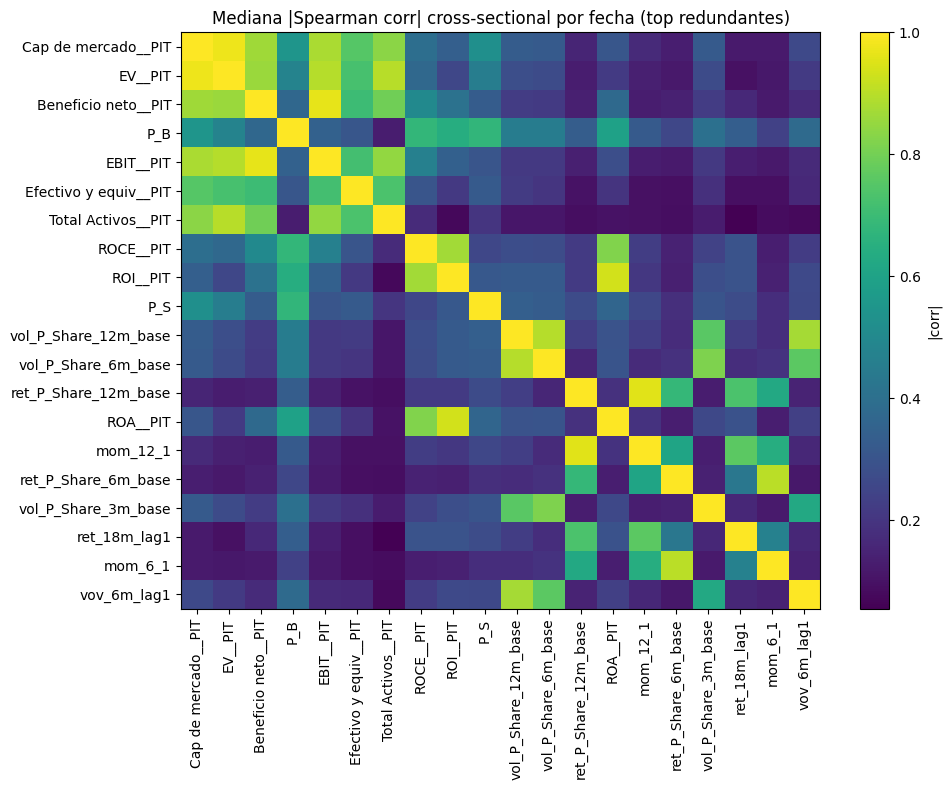

In [42]:

# ==============================================================================
# BLOQUE 10.B – Correlación cross-sectional por fecha + redundancia entre features
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🔗 BLOQUE 10.B – Correlación cross-sectional por fecha")
print("="*80)

MIN_NAMES_PER_MONTH = 25
pair_records = []

for m, g in audit_df.groupby("AUDIT_MONTH"):
    g = g[AUDIT_FEATURES].copy()
    # conservar solo features con variación cross-sectional real en ese mes
    keep = [c for c in g.columns if g[c].notna().sum() >= MIN_NAMES_PER_MONTH and g[c].nunique(dropna=True) > 1]
    if len(keep) < 2:
        continue
    corr_m = g[keep].corr(method="spearman")
    feats = corr_m.columns.tolist()
    vals = corr_m.values
    for i in range(len(feats)):
        for j in range(i+1, len(feats)):
            v = vals[i, j]
            if np.isfinite(v):
                pair_records.append((feats[i], feats[j], m, float(v), abs(float(v))))

if len(pair_records) == 0:
    print("⚠️ No hubo pares suficientes para calcular correlación cross-sectional por fecha.")
    PAIR_CORR_SUMMARY = pd.DataFrame()
    MEDIAN_ABS_CORR = pd.DataFrame(index=AUDIT_FEATURES, columns=AUDIT_FEATURES, dtype=float)
else:
    pair_df = pd.DataFrame(pair_records, columns=["feature_1","feature_2","month","corr","abs_corr"])
    PAIR_CORR_SUMMARY = (pair_df.groupby(["feature_1","feature_2"], as_index=False)
                         .agg(
                             n_months=("month","count"),
                             median_corr=("corr","median"),
                             median_abs_corr=("abs_corr","median"),
                             p90_abs_corr=("abs_corr", lambda s: np.nanpercentile(s, 90)),
                             max_abs_corr=("abs_corr","max"),
                         )
                         .sort_values(["median_abs_corr","n_months"], ascending=[False, False])
                         .reset_index(drop=True))

    print("Top pares más redundantes (mediana |rho| cross-sectional por fecha):")
    display(PAIR_CORR_SUMMARY.head(25))

    # Matriz feature x feature con mediana |corr|
    feats = sorted(set(PAIR_CORR_SUMMARY["feature_1"]).union(PAIR_CORR_SUMMARY["feature_2"]))
    MEDIAN_ABS_CORR = pd.DataFrame(np.nan, index=feats, columns=feats)
    np.fill_diagonal(MEDIAN_ABS_CORR.values, 1.0)
    for _, r in PAIR_CORR_SUMMARY.iterrows():
        MEDIAN_ABS_CORR.loc[r["feature_1"], r["feature_2"]] = r["median_abs_corr"]
        MEDIAN_ABS_CORR.loc[r["feature_2"], r["feature_1"]] = r["median_abs_corr"]

    # Heatmap resumido (top features por redundancia media)
    mean_redundancy = MEDIAN_ABS_CORR.replace(1.0, np.nan).mean(axis=1).sort_values(ascending=False)
    top_heat = mean_redundancy.head(min(20, len(mean_redundancy))).index.tolist()
    if len(top_heat) >= 2:
        mat = MEDIAN_ABS_CORR.loc[top_heat, top_heat].fillna(0.0).values
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(mat, aspect="auto")
        ax.set_xticks(range(len(top_heat)))
        ax.set_xticklabels(top_heat, rotation=90)
        ax.set_yticks(range(len(top_heat)))
        ax.set_yticklabels(top_heat)
        ax.set_title("Mediana |Spearman corr| cross-sectional por fecha (top redundantes)")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("|corr|")
        plt.tight_layout()
        plt.show()


In [43]:

# ==============================================================================
# BLOQUE 10.C – IC univariado por feature (cross-sectional, por fecha)
# ==============================================================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

print("\n" + "="*80)
print("📈 BLOQUE 10.C – IC univariado por feature")
print("="*80)

MIN_NAMES_IC = 25
ic_rows = []

for m, g in audit_df.groupby("AUDIT_MONTH"):
    y = g[TARGET_AUDIT]
    for feat in AUDIT_FEATURES:
        x = g[feat]
        mask = x.notna() & y.notna()
        if mask.sum() < MIN_NAMES_IC:
            continue
        x2 = x[mask]
        y2 = y[mask]
        if x2.nunique(dropna=True) <= 1 or y2.nunique(dropna=True) <= 1:
            continue
        rho, pval = spearmanr(x2, y2)
        if np.isfinite(rho):
            ic_rows.append((feat, m, int(mask.sum()), float(rho), float(pval) if np.isfinite(pval) else np.nan))

if len(ic_rows) == 0:
    print("⚠️ No se pudo calcular IC univariado para ninguna feature.")
    IC_MONTHLY = pd.DataFrame()
    IC_FEATURE_SUMMARY = pd.DataFrame()
else:
    IC_MONTHLY = pd.DataFrame(ic_rows, columns=["feature","month","n_names","ic","pval"])

    def _tstat(s):
        s = pd.Series(s).dropna()
        if len(s) < 2 or s.std(ddof=1) == 0:
            return np.nan
        return float(s.mean() / (s.std(ddof=1) / np.sqrt(len(s))))

    IC_FEATURE_SUMMARY = (IC_MONTHLY.groupby("feature", as_index=False)
                          .agg(
                              n_months=("month","count"),
                              mean_ic=("ic","mean"),
                              median_ic=("ic","median"),
                              mean_abs_ic=("ic", lambda s: np.mean(np.abs(s))),
                              std_ic=("ic","std"),
                              hit_positive_pct=("ic", lambda s: 100*np.mean(np.asarray(s) > 0)),
                              mean_n_names=("n_names","mean"),
                          ))
    IC_FEATURE_SUMMARY = IC_FEATURE_SUMMARY.rename(columns={"hit_positive_pct": "hit_positive_%"})
    IC_FEATURE_SUMMARY["t_ic"] = IC_MONTHLY.groupby("feature")["ic"].apply(_tstat).values
    IC_FEATURE_SUMMARY = IC_FEATURE_SUMMARY.sort_values(["mean_abs_ic","n_months"], ascending=[False, False]).reset_index(drop=True)

    print("Top features por |IC| medio:")
    display(IC_FEATURE_SUMMARY.head(20))

    print("Top features con IC medio positivo:")
    display(IC_FEATURE_SUMMARY.sort_values(["mean_ic","t_ic"], ascending=[False, False]).head(15))

    print("Top features con IC medio negativo:")
    display(IC_FEATURE_SUMMARY.sort_values(["mean_ic","t_ic"], ascending=[True, True]).head(15))



📈 BLOQUE 10.C – IC univariado por feature
Top features por |IC| medio:


,feature,n_months,mean_ic,median_ic,mean_abs_ic,std_ic,hit_positive_%,mean_n_names,t_ic
0,P_S,117,0.021840,0.018427,0.147154,0.184469,57.264957,180.0,1.280622
1,P_B,117,0.023291,0.034712,0.146550,0.178876,56.410256,180.0,1.408433
2,ret_P_Share_12m_base,105,-0.017807,-0.007272,0.141277,0.177245,47.619048,180.0,-1.029476
3,mom_12_1,105,-0.010385,-0.015126,0.139901,0.172548,46.666667,180.0,-0.616733
4,P_E,117,-0.006557,-0.002039,0.137907,0.170454,48.717949,180.0,-0.416074
5,Cap de mercado__PIT,117,0.015852,0.020251,0.137001,0.170952,54.700855,180.0,1.002988
6,ret_18m_lag1,98,-0.004456,0.011209,0.136133,0.167053,52.040816,180.0,-0.264036
7,EV__PIT,117,0.009074,0.018493,0.129293,0.161791,54.700855,180.0,0.606649
8,Beneficio neto__PIT,117,0.031825,0.042427,0.120734,0.142447,64.102564,180.0,2.416650
9,ret_P_Share_6m_base,111,0.000209,0.026966,0.120151,0.152449,56.756757,180.0,0.014427


Top features con IC medio positivo:


,feature,n_months,mean_ic,median_ic,mean_abs_ic,std_ic,hit_positive_%,mean_n_names,t_ic
15,ROI__PIT,117,0.043945,0.054306,0.111059,0.125715,61.538462,180.000000,3.781044
12,ROA__PIT,117,0.042451,0.050090,0.113661,0.129188,64.102564,180.000000,3.554337
18,ROCE__PIT,117,0.037157,0.050789,0.106098,0.122195,59.829060,180.000000,3.289167
8,Beneficio neto__PIT,117,0.031825,0.042427,0.120734,0.142447,64.102564,180.000000,2.416650
19,Efectivo y equiv__PIT,117,0.028659,0.013505,0.105062,0.129115,57.264957,180.000000,2.400875
11,EBIT__PIT,117,0.025346,0.030703,0.118349,0.142755,62.393162,180.000000,1.920481
1,P_B,117,0.023291,0.034712,0.146550,0.178876,56.410256,180.000000,1.408433
0,P_S,117,0.021840,0.018427,0.147154,0.184469,57.264957,180.000000,1.280622
5,Cap de mercado__PIT,117,0.015852,0.020251,0.137001,0.170952,54.700855,180.000000,1.002988
10,mom_6_1,111,0.009127,0.035935,0.119728,0.146751,55.855856,180.000000,0.655275


Top features con IC medio negativo:


,feature,n_months,mean_ic,median_ic,mean_abs_ic,std_ic,hit_positive_%,mean_n_names,t_ic
23,PE_zscore_6m,115,-0.049867,-0.046890,0.098860,0.112775,33.043478,180.000000,-4.741910
21,vol_P_Share_6m_base,115,-0.028639,-0.009990,0.101353,0.127854,44.347826,180.000000,-2.402089
22,vov_6m_lag1,112,-0.026237,-0.022517,0.099895,0.122463,41.964286,180.000000,-2.267334
24,vol_P_Share_3m_base,115,-0.025363,-0.013727,0.095362,0.122252,44.347826,180.000000,-2.224838
17,vol_P_Share_12m_base,115,-0.024441,-0.018009,0.107967,0.134294,42.608696,180.000000,-1.951669
13,ret_P_Share_1m_base,116,-0.019037,-0.016313,0.113442,0.141935,44.827586,180.000000,-1.444550
16,ret_P_Share_3m_base,114,-0.017890,-0.009497,0.108989,0.137595,46.491228,180.000000,-1.388240
2,ret_P_Share_12m_base,105,-0.017807,-0.007272,0.141277,0.177245,47.619048,180.000000,-1.029476
26,Deuda a CP__PIT,117,-0.015924,-0.014329,0.074173,0.095524,42.735043,180.000000,-1.803126
3,mom_12_1,105,-0.010385,-0.015126,0.139901,0.172548,46.666667,180.000000,-0.616733


In [44]:

# ==============================================================================
# BLOQUE 10.D – Autocorrelación serial por feature (niveles y cambios)
# ==============================================================================
import numpy as np
import pandas as pd

print("\n" + "="*80)
print("🔁 BLOQUE 10.D – Autocorrelación serial por feature")
print("="*80)

serial_df = audit_df[["Empresa","Fecha"] + AUDIT_FEATURES].copy().sort_values(["Empresa","Fecha"])

def _lag1_autocorr(s: pd.Series):
    s = pd.Series(s).dropna()
    if len(s) < 6 or s.nunique(dropna=True) <= 1:
        return np.nan
    return float(s.autocorr(lag=1))

serial_rows = []
for feat in AUDIT_FEATURES:
    by_emp = serial_df.groupby("Empresa")[feat]
    ar1_level = by_emp.apply(_lag1_autocorr).dropna()
    ar1_diff  = by_emp.apply(lambda s: _lag1_autocorr(pd.Series(s).diff())).dropna()

    serial_rows.append({
        "feature": feat,
        "n_emp_level": int(ar1_level.shape[0]),
        "median_ar1_level": float(ar1_level.median()) if len(ar1_level) else np.nan,
        "mean_ar1_level": float(ar1_level.mean()) if len(ar1_level) else np.nan,
        "p90_ar1_level": float(np.nanpercentile(ar1_level, 90)) if len(ar1_level) else np.nan,
        "n_emp_diff": int(ar1_diff.shape[0]),
        "median_ar1_diff": float(ar1_diff.median()) if len(ar1_diff) else np.nan,
        "mean_ar1_diff": float(ar1_diff.mean()) if len(ar1_diff) else np.nan,
        "p90_ar1_diff": float(np.nanpercentile(ar1_diff, 90)) if len(ar1_diff) else np.nan,
    })

AR1_FEATURE_SUMMARY = pd.DataFrame(serial_rows).sort_values(["median_ar1_level","median_ar1_diff"], ascending=[False, False]).reset_index(drop=True)

print("Features más persistentes en niveles (esperable en contables/múltiplos):")
display(AR1_FEATURE_SUMMARY.head(20))

print("Features con mayor persistencia en cambios (revisar si luce excesiva / stale):")
display(AR1_FEATURE_SUMMARY.sort_values(["median_ar1_diff","median_ar1_level"], ascending=[False, False]).head(20))



🔁 BLOQUE 10.D – Autocorrelación serial por feature
Features más persistentes en niveles (esperable en contables/múltiplos):


,feature,n_emp_level,median_ar1_level,mean_ar1_level,p90_ar1_level,n_emp_diff,median_ar1_diff,mean_ar1_diff,p90_ar1_diff
0,Total Activos__PIT,180,0.992849,0.988431,0.997883,180,-0.049647,-0.073569,-5.971259e-03
1,EV__PIT,180,0.981984,0.972215,0.993544,180,-0.016144,-0.025262,-6.462073e-04
2,Cap de mercado__PIT,180,0.980945,0.971151,0.993084,180,-0.013083,-0.020297,-2.404458e-04
3,Deuda a LP__PIT,178,0.980057,0.972115,0.993734,178,-0.009810,-0.020787,-4.196675e-04
4,ROI__PIT,180,0.969806,0.961749,0.988474,180,-0.001629,-0.005295,1.874232e-07
5,ROCE__PIT,180,0.966828,0.963201,0.988040,180,-0.002381,-0.005791,-2.472873e-05
6,ROA__PIT,180,0.965955,0.961124,0.986139,180,-0.002445,-0.004903,4.496567e-06
7,vol_P_Share_12m_base,180,0.964367,0.960779,0.981313,180,0.494684,0.491959,6.296474e-01
8,Efectivo y equiv__PIT,180,0.952438,0.933228,0.985748,180,-0.001801,-0.006680,-2.702565e-05
9,Deuda a CP__PIT,179,0.939526,0.928996,0.989515,179,-0.001595,-0.007173,-1.303219e-05


Features con mayor persistencia en cambios (revisar si luce excesiva / stale):


,feature,n_emp_level,median_ar1_level,mean_ar1_level,p90_ar1_level,n_emp_diff,median_ar1_diff,mean_ar1_diff,p90_ar1_diff
7,vol_P_Share_12m_base,180,0.964367,0.960779,0.981313,180,0.494684,0.491959,6.296474e-01
18,vov_6m_lag1,180,0.893303,0.892158,0.933544,180,0.345193,0.339157,4.513653e-01
20,vol_P_Share_6m_base,180,0.863793,0.864902,0.927601,180,0.229831,0.223166,3.636253e-01
11,pandemic_dummy,180,0.927500,0.927500,0.927500,180,0.000000,0.000000,0.000000e+00
17,Beneficio neto__PIT,180,0.895770,0.876369,0.972371,180,-0.001412,-0.004030,-4.993769e-08
9,Deuda a CP__PIT,179,0.939526,0.928996,0.989515,179,-0.001595,-0.007173,-1.303219e-05
4,ROI__PIT,180,0.969806,0.961749,0.988474,180,-0.001629,-0.005295,1.874232e-07
8,Efectivo y equiv__PIT,180,0.952438,0.933228,0.985748,180,-0.001801,-0.006680,-2.702565e-05
5,ROCE__PIT,180,0.966828,0.963201,0.988040,180,-0.002381,-0.005791,-2.472873e-05
13,EBIT__PIT,180,0.922092,0.892183,0.984678,180,-0.002413,-0.006754,-1.749132e-05



🧹 BLOQUE 10.E – Clustering / pruning sugerido
Pares con mediana |corr| >= 0.90:


,feature_keep,feature_drop_suggested,median_abs_corr,n_months,keep_mean_abs_ic,drop_mean_abs_ic,keep_coverage_%,drop_coverage_%
0,Cap de mercado__PIT,EV__PIT,0.977654,117,0.137001,0.129293,100.00,100.00
1,Beneficio neto__PIT,EBIT__PIT,0.966365,117,0.120734,0.118349,100.00,100.00
2,ret_P_Share_12m_base,mom_12_1,0.956353,105,0.141277,0.139901,89.74,89.74
3,ROA__PIT,ROI__PIT,0.937107,117,0.113661,0.111059,100.00,100.00
4,ret_P_Share_6m_base,mom_6_1,0.903898,111,0.120151,0.119728,94.87,94.87


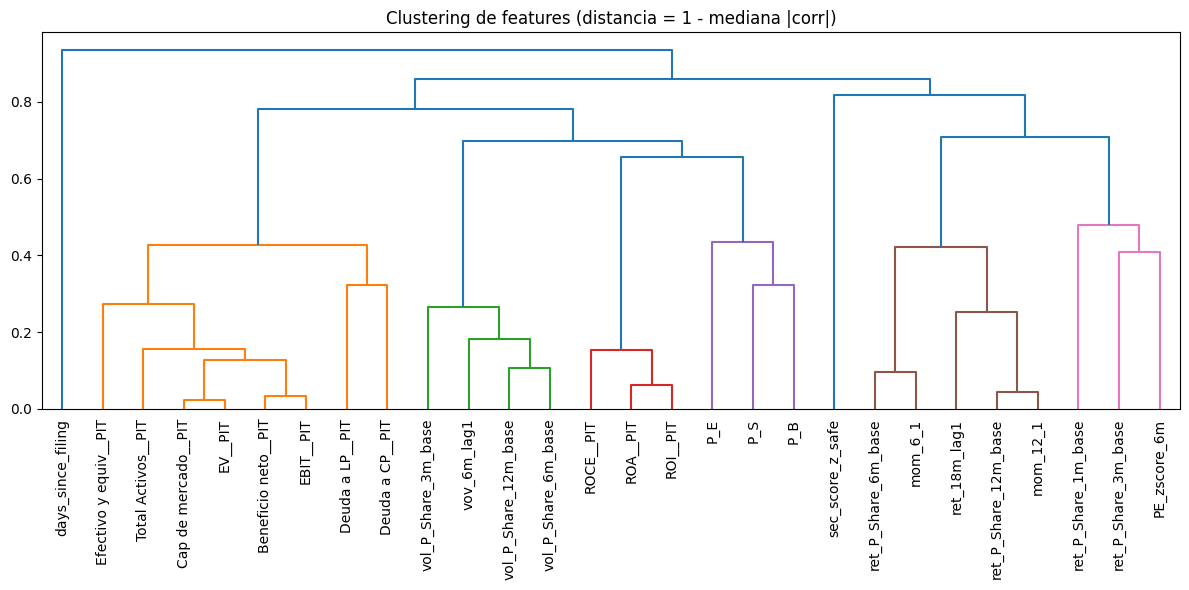

In [45]:

# ==============================================================================
# BLOQUE 10.E – Clustering / sugerencias de pruning por redundancia
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🧹 BLOQUE 10.E – Clustering / pruning sugerido")
print("="*80)

REDUNDANCY_THRESHOLD = 0.90

if "PAIR_CORR_SUMMARY" not in globals() or PAIR_CORR_SUMMARY is None or len(PAIR_CORR_SUMMARY) == 0:
    print("⚠️ No hay matriz de redundancia disponible. Ejecuta primero BLOQUE 10.B.")
else:
    # Métrica para decidir keep/drop: |IC| medio + cobertura
    ic_ref = IC_FEATURE_SUMMARY.set_index("feature") if ("IC_FEATURE_SUMMARY" in globals() and len(IC_FEATURE_SUMMARY) > 0) else pd.DataFrame()
    cov_ref = FEATURE_AUDIT_BASE.set_index("feature") if ("FEATURE_AUDIT_BASE" in globals() and len(FEATURE_AUDIT_BASE) > 0) else pd.DataFrame()

    def _score_feature(f):
        ic = float(ic_ref.loc[f, "mean_abs_ic"]) if (not ic_ref.empty and f in ic_ref.index and pd.notna(ic_ref.loc[f, "mean_abs_ic"])) else 0.0
        cov = float(cov_ref.loc[f, "coverage_%"]) if (not cov_ref.empty and f in cov_ref.index and pd.notna(cov_ref.loc[f, "coverage_%"])) else 0.0
        return (ic, cov)

    red_pairs = PAIR_CORR_SUMMARY[PAIR_CORR_SUMMARY["median_abs_corr"] >= REDUNDANCY_THRESHOLD].copy()

    suggestions = []
    for _, r in red_pairs.iterrows():
        f1, f2 = r["feature_1"], r["feature_2"]
        s1, s2 = _score_feature(f1), _score_feature(f2)
        if s1 > s2:
            keep, drop = f1, f2
        elif s2 > s1:
            keep, drop = f2, f1
        else:
            keep, drop = sorted([f1, f2])[0], sorted([f1, f2])[1]
        suggestions.append({
            "feature_keep": keep,
            "feature_drop_suggested": drop,
            "median_abs_corr": r["median_abs_corr"],
            "n_months": r["n_months"],
            "keep_mean_abs_ic": ic_ref.loc[keep, "mean_abs_ic"] if (not ic_ref.empty and keep in ic_ref.index) else np.nan,
            "drop_mean_abs_ic": ic_ref.loc[drop, "mean_abs_ic"] if (not ic_ref.empty and drop in ic_ref.index) else np.nan,
            "keep_coverage_%": cov_ref.loc[keep, "coverage_%"] if (not cov_ref.empty and keep in cov_ref.index) else np.nan,
            "drop_coverage_%": cov_ref.loc[drop, "coverage_%"] if (not cov_ref.empty and drop in cov_ref.index) else np.nan,
        })

    if len(suggestions) == 0:
        PRUNE_SUGGESTIONS = pd.DataFrame(columns=[
            "feature_keep","feature_drop_suggested","median_abs_corr","n_months",
            "keep_mean_abs_ic","drop_mean_abs_ic","keep_coverage_%","drop_coverage_%"
        ])
    else:
        PRUNE_SUGGESTIONS = pd.DataFrame(suggestions).sort_values(["median_abs_corr","n_months"], ascending=[False, False]).reset_index(drop=True)

    if len(PRUNE_SUGGESTIONS) == 0:
        print(f"No hay pares con mediana |corr| >= {REDUNDANCY_THRESHOLD:.2f}.")
    else:
        print(f"Pares con mediana |corr| >= {REDUNDANCY_THRESHOLD:.2f}:")
        display(PRUNE_SUGGESTIONS.head(25))

    # Dendrograma / clustering si scipy está disponible
    try:
        from scipy.cluster.hierarchy import linkage, dendrogram
        from scipy.spatial.distance import squareform

        mat = MEDIAN_ABS_CORR.copy().astype(float)
        feats = mat.index.tolist()
        if len(feats) >= 3:
            # distancia = 1 - |corr| ; completar faltantes con 0
            mat = mat.fillna(0.0)
            dist = 1.0 - mat.values
            dist = np.clip((dist + dist.T) / 2.0, 0.0, 1.0)
            np.fill_diagonal(dist, 0.0)
            condensed = squareform(dist, checks=False)
            Z = linkage(condensed, method="average")

            n_show = min(30, len(feats))
            # elegir features con mayor mean_abs_ic si existe, si no por redundancia media
            if "IC_FEATURE_SUMMARY" in globals() and len(IC_FEATURE_SUMMARY) > 0:
                top_feats = IC_FEATURE_SUMMARY.sort_values("mean_abs_ic", ascending=False)["feature"].head(n_show).tolist()
            else:
                top_feats = mat.replace(1.0, np.nan).mean(axis=1).sort_values(ascending=False).head(n_show).index.tolist()

            # submatriz y dendrograma específico de top features
            sub = mat.loc[top_feats, top_feats]
            dist_sub = 1.0 - sub.fillna(0.0).values
            dist_sub = np.clip((dist_sub + dist_sub.T) / 2.0, 0.0, 1.0)
            np.fill_diagonal(dist_sub, 0.0)
            Zs = linkage(squareform(dist_sub, checks=False), method="average")

            fig, ax = plt.subplots(figsize=(12, 6))
            dendrogram(Zs, labels=top_feats, leaf_rotation=90, ax=ax)
            ax.set_title("Clustering de features (distancia = 1 - mediana |corr|)")
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"ℹ️ No se pudo graficar dendrograma de clustering: {e}")


In [46]:

# ==============================================================================
# BLOQUE 10.F – Repetición de auditoría SOLO en rebalances efectivos
# ------------------------------------------------------------------------------
# Objetivo:
#   - Repetir la auditoría de features (redundancia / IC / AR1 / pruning)
#     sobre las fechas efectivas de rebalance, que son las que realmente
#     alimentan la construcción del portafolio.
#   - Mantener separada la lectura "todos los meses" vs "solo rebalances".
# ==============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("\n" + "="*80)
print("🔬 BLOQUE 10.F – Auditoría de features SOLO en rebalances")
print("="*80)

def _run_feature_audit_suite(audit_df_in: pd.DataFrame,
                             audit_features: list[str],
                             target_col: str,
                             label: str = "REBALS",
                             min_names_per_month: int = 25,
                             redundancy_threshold: float = 0.90):
    out = {}

    if audit_df_in is None or len(audit_df_in) == 0:
        print(f"⚠️ [{label}] No hay filas para auditar.")
        return out

    audit_df_local = audit_df_in.copy()
    audit_df_local["Fecha"] = pd.to_datetime(audit_df_local["Fecha"], errors="coerce")
    if "Month" in audit_df_local.columns:
        audit_df_local["AUDIT_MONTH"] = audit_df_local["Month"]
    else:
        audit_df_local["AUDIT_MONTH"] = audit_df_local["Fecha"].dt.to_period("M")

    audit_df_local = audit_df_local.dropna(subset=["Empresa", "Fecha", "AUDIT_MONTH", target_col]).copy()
    if len(audit_df_local) == 0:
        print(f"⚠️ [{label}] Tras filtrar ids/fechas/target, no quedaron filas.")
        return out

    print(f"[{label}] Panel auditado: {len(audit_df_local):,} filas | empresas={audit_df_local['Empresa'].nunique()} | meses={audit_df_local['AUDIT_MONTH'].nunique()} | features={len(audit_features)}")

    # --- Base coverage / variación cross-sectional
    rows = []
    for feat in audit_features:
        g = audit_df_local.groupby("AUDIT_MONTH")[feat]
        xs_nuniq = g.nunique(dropna=True)
        xs_nonnull = g.apply(lambda s: s.notna().sum())
        rows.append({
            "feature": feat,
            "coverage_%": round(100 * audit_df_local[feat].notna().mean(), 2),
            "months_nonnull": int((xs_nonnull > 0).sum()),
            "months_no_xs_variation_%": round(100 * (xs_nuniq <= 1).mean(), 2),
            "mean_xs_nonnull": round(float(xs_nonnull.mean()), 1),
        })
    feature_base = pd.DataFrame(rows).sort_values(["months_no_xs_variation_%", "coverage_%"], ascending=[True, False]).reset_index(drop=True)
    out["FEATURE_AUDIT_BASE"] = feature_base

    print(f"\n[{label}] Features con MENOS variación cross-sectional cero:")
    display(feature_base.head(15))
    print(f"[{label}] Features con MÁS falta de variación cross-sectional:")
    display(feature_base.sort_values(["months_no_xs_variation_%", "coverage_%"], ascending=[False, True]).head(15))

    # --- Correlación cross-sectional por fecha
    pair_records = []
    for m, g in audit_df_local.groupby("AUDIT_MONTH"):
        g = g[audit_features].copy()
        keep = [c for c in g.columns if g[c].notna().sum() >= min_names_per_month and g[c].nunique(dropna=True) > 1]
        if len(keep) < 2:
            continue
        corr_m = g[keep].corr(method="spearman")
        feats = corr_m.columns.tolist()
        vals = corr_m.values
        for i in range(len(feats)):
            for j in range(i + 1, len(feats)):
                v = vals[i, j]
                if np.isfinite(v):
                    pair_records.append((feats[i], feats[j], m, float(v), abs(float(v))))

    if pair_records:
        pair_df = pd.DataFrame(pair_records, columns=["feature_1","feature_2","month","corr","abs_corr"])
        pair_summary = (
            pair_df.groupby(["feature_1","feature_2"], as_index=False)
                   .agg(
                       n_months=("month","count"),
                       median_corr=("corr","median"),
                       median_abs_corr=("abs_corr","median"),
                       p90_abs_corr=("abs_corr", lambda s: np.nanpercentile(s, 90)),
                       max_abs_corr=("abs_corr","max"),
                   )
                   .sort_values(["median_abs_corr","n_months"], ascending=[False, False])
                   .reset_index(drop=True)
        )
        out["PAIR_CORR_SUMMARY"] = pair_summary

        print(f"\n[{label}] Top pares más redundantes (mediana |rho|):")
        display(pair_summary.head(25))
    else:
        out["PAIR_CORR_SUMMARY"] = pd.DataFrame()
        print(f"\n[{label}] ⚠️ No hubo pares suficientes para correlación cross-sectional.")

    # --- IC univariado
    from scipy.stats import spearmanr
    ic_rows = []
    for m, g in audit_df_local.groupby("AUDIT_MONTH"):
        y = g[target_col]
        for feat in audit_features:
            x = g[feat]
            mask = x.notna() & y.notna()
            if mask.sum() < min_names_per_month:
                continue
            x2 = x[mask]
            y2 = y[mask]
            if x2.nunique(dropna=True) <= 1 or y2.nunique(dropna=True) <= 1:
                continue
            rho, pval = spearmanr(x2, y2)
            if np.isfinite(rho):
                ic_rows.append((feat, m, int(mask.sum()), float(rho), float(pval) if np.isfinite(pval) else np.nan))

    if ic_rows:
        ic_monthly = pd.DataFrame(ic_rows, columns=["feature","month","n_names","ic","pval"])

        def _tstat(s):
            s = pd.Series(s).dropna()
            if len(s) < 2 or s.std(ddof=1) == 0:
                return np.nan
            return float(s.mean() / (s.std(ddof=1) / np.sqrt(len(s))))

        ic_summary = (
            ic_monthly.groupby("feature", as_index=False)
                      .agg(
                          n_months=("month","count"),
                          mean_ic=("ic","mean"),
                          median_ic=("ic","median"),
                          mean_abs_ic=("ic", lambda s: np.mean(np.abs(s))),
                          std_ic=("ic","std"),
                          hit_positive_pct=("ic", lambda s: 100*np.mean(np.asarray(s) > 0)),
                          mean_n_names=("n_names","mean"),
                      )
        )
        ic_summary = ic_summary.rename(columns={"hit_positive_pct": "hit_positive_%"})
        ic_summary["t_ic"] = ic_monthly.groupby("feature")["ic"].apply(_tstat).values
        ic_summary = ic_summary.sort_values(["mean_abs_ic","n_months"], ascending=[False, False]).reset_index(drop=True)

        out["IC_MONTHLY"] = ic_monthly
        out["IC_FEATURE_SUMMARY"] = ic_summary

        print(f"\n[{label}] Top features por |IC| medio:")
        display(ic_summary.head(20))
    else:
        out["IC_MONTHLY"] = pd.DataFrame()
        out["IC_FEATURE_SUMMARY"] = pd.DataFrame()
        print(f"\n[{label}] ⚠️ No se pudo calcular IC univariado.")

    # --- Autocorrelación serial
    serial_df = audit_df_local[["Empresa","Fecha"] + audit_features].copy().sort_values(["Empresa","Fecha"])

    def _lag1_autocorr(s: pd.Series):
        s = pd.Series(s).dropna()
        if len(s) < 6 or s.nunique(dropna=True) <= 1:
            return np.nan
        return float(s.autocorr(lag=1))

    serial_rows = []
    for feat in audit_features:
        by_emp = serial_df.groupby("Empresa")[feat]
        ar1_level = by_emp.apply(_lag1_autocorr).dropna()
        ar1_diff = by_emp.apply(lambda s: _lag1_autocorr(pd.Series(s).diff())).dropna()
        serial_rows.append({
            "feature": feat,
            "n_emp_level": int(ar1_level.shape[0]),
            "median_ar1_level": float(ar1_level.median()) if len(ar1_level) else np.nan,
            "mean_ar1_level": float(ar1_level.mean()) if len(ar1_level) else np.nan,
            "p90_ar1_level": float(np.nanpercentile(ar1_level, 90)) if len(ar1_level) else np.nan,
            "n_emp_diff": int(ar1_diff.shape[0]),
            "median_ar1_diff": float(ar1_diff.median()) if len(ar1_diff) else np.nan,
            "mean_ar1_diff": float(ar1_diff.mean()) if len(ar1_diff) else np.nan,
            "p90_ar1_diff": float(np.nanpercentile(ar1_diff, 90)) if len(ar1_diff) else np.nan,
        })
    ar1_summary = pd.DataFrame(serial_rows).sort_values(["median_ar1_level","median_ar1_diff"], ascending=[False, False]).reset_index(drop=True)
    out["AR1_FEATURE_SUMMARY"] = ar1_summary

    print(f"\n[{label}] Features más persistentes en niveles:")
    display(ar1_summary.head(15))

    # --- Pruning sugerido
    pair_summary = out.get("PAIR_CORR_SUMMARY", pd.DataFrame())
    ic_ref = out.get("IC_FEATURE_SUMMARY", pd.DataFrame()).set_index("feature") if len(out.get("IC_FEATURE_SUMMARY", pd.DataFrame())) else pd.DataFrame()
    cov_ref = feature_base.set_index("feature") if len(feature_base) else pd.DataFrame()

    def _score_feature(f):
        ic = float(ic_ref.loc[f, "mean_abs_ic"]) if (not ic_ref.empty and f in ic_ref.index and pd.notna(ic_ref.loc[f, "mean_abs_ic"])) else 0.0
        cov = float(cov_ref.loc[f, "coverage_%"]) if (not cov_ref.empty and f in cov_ref.index and pd.notna(cov_ref.loc[f, "coverage_%"])) else 0.0
        return (ic, cov)

    if len(pair_summary):
        red_pairs = pair_summary[pair_summary["median_abs_corr"] >= redundancy_threshold].copy()
        suggestions = []
        for _, r in red_pairs.iterrows():
            f1, f2 = r["feature_1"], r["feature_2"]
            s1, s2 = _score_feature(f1), _score_feature(f2)
            if s1 > s2:
                keep, drop = f1, f2
            elif s2 > s1:
                keep, drop = f2, f1
            else:
                keep, drop = sorted([f1, f2])[0], sorted([f1, f2])[1]
            suggestions.append({
                "feature_keep": keep,
                "feature_drop_suggested": drop,
                "median_abs_corr": r["median_abs_corr"],
                "n_months": r["n_months"],
                "keep_mean_abs_ic": ic_ref.loc[keep, "mean_abs_ic"] if (not ic_ref.empty and keep in ic_ref.index) else np.nan,
                "drop_mean_abs_ic": ic_ref.loc[drop, "mean_abs_ic"] if (not ic_ref.empty and drop in ic_ref.index) else np.nan,
                "keep_coverage_%": cov_ref.loc[keep, "coverage_%"] if (not cov_ref.empty and keep in cov_ref.index) else np.nan,
                "drop_coverage_%": cov_ref.loc[drop, "coverage_%"] if (not cov_ref.empty and drop in cov_ref.index) else np.nan,
            })
        prune = pd.DataFrame(suggestions).sort_values(["median_abs_corr","n_months"], ascending=[False, False]).reset_index(drop=True) if suggestions else pd.DataFrame()
    else:
        prune = pd.DataFrame()

    out["PRUNE_SUGGESTIONS"] = prune
    if len(prune):
        print(f"\n[{label}] Sugerencias de pruning (threshold={redundancy_threshold:.2f}):")
        display(prune.head(20))
    else:
        print(f"\n[{label}] No hay pares con mediana |corr| >= {redundancy_threshold:.2f}.")

    return out

if "is_rebal" not in df.columns:
    print("ℹ️ No existe is_rebal. Se omite auditoría específica de rebalances.")
else:
    rebal_df = df[df["is_rebal"].fillna(False)].copy()
    if len(rebal_df) == 0:
        print("ℹ️ No hay filas de rebalance. Se omite auditoría específica de rebalances.")
    else:
        REBAL_AUDIT_RESULTS = _run_feature_audit_suite(
            audit_df_in=rebal_df,
            audit_features=AUDIT_FEATURES,
            target_col=TARGET_AUDIT,
            label="REBALS_ONLY",
            min_names_per_month=25,
            redundancy_threshold=float(globals().get("REDUNDANCY_THRESHOLD", 0.90)),
        )
        globals()["REBAL_AUDIT_RESULTS"] = REBAL_AUDIT_RESULTS
        globals()["REBAL_FEATURE_AUDIT_BASE"] = REBAL_AUDIT_RESULTS.get("FEATURE_AUDIT_BASE", pd.DataFrame())
        globals()["REBAL_PAIR_CORR_SUMMARY"] = REBAL_AUDIT_RESULTS.get("PAIR_CORR_SUMMARY", pd.DataFrame())
        globals()["REBAL_IC_MONTHLY"] = REBAL_AUDIT_RESULTS.get("IC_MONTHLY", pd.DataFrame())
        globals()["REBAL_IC_FEATURE_SUMMARY"] = REBAL_AUDIT_RESULTS.get("IC_FEATURE_SUMMARY", pd.DataFrame())
        globals()["REBAL_AR1_FEATURE_SUMMARY"] = REBAL_AUDIT_RESULTS.get("AR1_FEATURE_SUMMARY", pd.DataFrame())
        globals()["REBAL_PRUNE_SUGGESTIONS"] = REBAL_AUDIT_RESULTS.get("PRUNE_SUGGESTIONS", pd.DataFrame())



🔬 BLOQUE 10.F – Auditoría de features SOLO en rebalances
[REBALS_ONLY] Panel auditado: 7,020 filas | empresas=180 | meses=39 | features=33

[REBALS_ONLY] Features con MENOS variación cross-sectional cero:


,feature,coverage_%,months_nonnull,months_no_xs_variation_%,mean_xs_nonnull
0,ret_P_Share_1m_base,100.0,39,0.0,180.0
1,vol_P_Share_3m_base,100.0,39,0.0,180.0
2,vol_P_Share_6m_base,100.0,39,0.0,180.0
3,vol_P_Share_12m_base,100.0,39,0.0,180.0
4,PE_zscore_6m,100.0,39,0.0,180.0
5,P_E,100.0,39,0.0,180.0
6,P_B,100.0,39,0.0,180.0
7,P_S,100.0,39,0.0,180.0
8,ROCE__PIT,100.0,39,0.0,180.0
9,ROA__PIT,100.0,39,0.0,180.0


[REBALS_ONLY] Features con MÁS falta de variación cross-sectional:


,feature,coverage_%,months_nonnull,months_no_xs_variation_%,mean_xs_nonnull
28,is_short_hist_zscore,100.00,39,100.00,180.0
29,pandemic_dummy,100.00,39,100.00,180.0
30,dif_CPI_mediana,100.00,39,100.00,180.0
31,dif_NFP_mediana,100.00,39,100.00,180.0
32,dif_FFR_mediana,100.00,39,100.00,180.0
27,ret_18m_lag1,100.00,39,15.38,180.0
25,ret_P_Share_12m_base,89.74,35,10.26,161.5
26,mom_12_1,89.74,35,10.26,161.5
24,sec_score_z_safe,100.00,39,10.26,180.0
22,ret_P_Share_6m_base,94.87,37,5.13,170.8



[REBALS_ONLY] Top pares más redundantes (mediana |rho|):


...

,feature,n_months,mean_ic,median_ic,mean_abs_ic,std_ic,hit_positive_%,mean_n_names,t_ic
0,ret_P_Share_12m_base,35,-0.025369,-0.039345,0.137794,0.171727,34.285714,180.0,-0.873978
1,mom_12_1,35,-0.014758,-0.043396,0.137689,0.170619,37.142857,180.0,-0.511716
2,P_B,39,0.022933,0.067440,0.136442,0.166511,61.538462,180.0,0.860121
3,Cap de mercado__PIT,39,0.017800,0.045630,0.134285,0.171516,61.538462,180.0,0.648113
4,P_S,39,0.021016,0.018427,0.133273,0.175958,61.538462,180.0,0.745890
5,P_E,39,-0.010639,-0.003630,0.128521,0.161612,43.589744,180.0,-0.411130
6,ret_18m_lag1,33,-0.008667,-0.038738,0.127220,0.155322,42.424242,180.0,-0.320545
7,EV__PIT,39,0.011271,0.031788,0.125837,0.161855,58.974359,180.0,0.434863
8,Beneficio neto__PIT,39,0.039417,0.044891,0.122044,0.145728,74.358974,180.0,1.689188
9,sec_score_z_safe,35,-0.002414,-0.006988,0.117877,0.150001,45.714286,180.0,-0.095199



[REBALS_ONLY] Features más persistentes en niveles:


,feature,n_emp_level,median_ar1_level,mean_ar1_level,p90_ar1_level,n_emp_diff,median_ar1_diff,mean_ar1_diff,p90_ar1_diff
0,Total Activos__PIT,180,0.979997,0.966980,0.996229,180,0.269769,0.240716,0.541169
1,EV__PIT,180,0.945263,0.917043,0.982724,180,0.193493,0.170450,0.439081
2,Cap de mercado__PIT,180,0.943166,0.914120,0.980710,180,0.230917,0.203947,0.461922
3,Deuda a LP__PIT,178,0.939513,0.916861,0.982580,178,0.254529,0.207548,0.428630
4,ROI__PIT,180,0.912175,0.885653,0.967353,180,0.380563,0.341143,0.631443
5,ROCE__PIT,180,0.901700,0.888743,0.964604,180,0.416618,0.361849,0.660850
6,ROA__PIT,180,0.901061,0.882774,0.963495,180,0.397294,0.354158,0.637508
7,Efectivo y equiv__PIT,180,0.851867,0.797456,0.958951,180,0.079737,0.096101,0.442673
8,P_S,180,0.825890,0.807441,0.931203,180,-0.060081,-0.062800,0.115292
9,Deuda a CP__PIT,179,0.823215,0.785873,0.970035,179,0.135229,0.117766,0.377155



[REBALS_ONLY] Sugerencias de pruning (threshold=0.90):


,feature_keep,feature_drop_suggested,median_abs_corr,n_months,keep_mean_abs_ic,drop_mean_abs_ic,keep_coverage_%,drop_coverage_%
0,Cap de mercado__PIT,EV__PIT,0.977499,39,0.134285,0.125837,100.00,100.00
1,ret_P_Share_12m_base,mom_12_1,0.968174,35,0.137794,0.137689,89.74,89.74
2,Beneficio neto__PIT,EBIT__PIT,0.966969,39,0.122044,0.116763,100.00,100.00
3,ROI__PIT,ROA__PIT,0.937486,39,0.116298,0.115502,100.00,100.00
4,mom_6_1,ret_P_Share_6m_base,0.928730,37,0.101248,0.099022,94.87,94.87


In [47]:
# ===============================================================================
# CHEQUEO PIT POR TICKER (SEC filings) — Validación de disponibilidad
#   - Muestra cómo cambian period_end_used y contables __PIT tras cada filing
#   - Verifica que filing_date_used <= Fecha - buffer (sin look-ahead)
# ===============================================================================

try:
    _use_pit = bool(globals().get('USE_SEC_PIT_CONTABLES', False))
except Exception:
    _use_pit = False

required_cols = {'filing_date_used','period_end_used','days_since_filing'}
pit_cols = [c for c in df.columns if c.endswith('__PIT')] if 'df' in globals() else []

if (not _use_pit) or ('df' not in globals()) or (not required_cols.issubset(set(df.columns))):
    print('ℹ️  Chequeo PIT por ticker omitido (PIT no activo o faltan columnas).')
else:
    from pandas.tseries.offsets import BDay

    # Elegí un ticker para inspeccionar (si no está, toma uno existente)
    TICKER_PIT_CHECK = globals().get('TICKER_PIT_CHECK', 'NVDA US Equity')
    if TICKER_PIT_CHECK not in set(df['Empresa'].unique()):
        TICKER_PIT_CHECK = df['Empresa'].dropna().astype(str).unique()[0]

    # Columnas PIT a mostrar (máximo 6 para que sea legible)
    _pit_show = []
    for cand in ['ROA__PIT','ROCE__PIT','EBIT__PIT','EV__PIT','Cap de mercado__PIT','Beneficio neto__PIT','Total Activos__PIT']:
        if cand in df.columns:
            _pit_show.append(cand)
    if not _pit_show:
        _pit_show = pit_cols[:6]

    cols_show = ['Empresa','Fecha','filing_date_used','period_end_used','days_since_filing'] + _pit_show

    view = (df[df['Empresa'] == TICKER_PIT_CHECK]
              .sort_values('Fecha')
              [cols_show]
              .drop_duplicates())

    print(f"\n🔎 PIT check — {TICKER_PIT_CHECK} (últimos 36 meses)")
    if 'safe_display' in globals():
        safe_display(view.tail(36))
    else:
        display(view.tail(36))

    # --- Validación anti-lookahead: filing_date_used <= Fecha - buffer ---
    _buffer = int(globals().get('SEC_BUFFER_BDAYS', globals().get('BUFFER_BDAYS', 2)))
    tmp = view.dropna(subset=['filing_date_used']).copy()
    tmp['cutoff'] = tmp['Fecha'] - BDay(_buffer)
    viol = tmp[tmp['filing_date_used'] > tmp['cutoff']]
    print(f"\nAnti-lookahead: violations filing_date_used > (Fecha - {_buffer} BDay) = {len(viol)}")
    if len(viol) > 0:
        if 'safe_display' in globals():
            safe_display(viol[['Fecha','filing_date_used','cutoff']].head(10))
        else:
            display(viol[['Fecha','filing_date_used','cutoff']].head(10))

    # --- Eventos: cuándo cambia el filing/period_end usado ---
    ev = tmp[['Fecha','filing_date_used','period_end_used','days_since_filing']].copy()
    ev['chg_filing'] = ev['filing_date_used'].ne(ev['filing_date_used'].shift(1))
    ev['chg_period'] = ev['period_end_used'].ne(ev['period_end_used'].shift(1))
    ev2 = ev[ev['chg_filing'] | ev['chg_period']].copy()
    print(f"\nEventos de cambio (filing_date_used o period_end_used): {len(ev2)}")
    if 'safe_display' in globals():
        safe_display(ev2.tail(15))
    else:
        display(ev2.tail(15))

    print("\nInterpretación rápida:")
    print("- Deberías ver que period_end_used cambia solo después de que aparece un filing_date_used más reciente (con buffer).")
    print("- Mientras period_end_used no cambie, las columnas __PIT deberían permanecer constantes.")



🔎 PIT check — NVDA US Equity (últimos 36 meses)


,Empresa,Fecha,filing_date_used,period_end_used,days_since_filing,ROA__PIT,ROCE__PIT,EBIT__PIT,EV__PIT,Cap de mercado__PIT,Beneficio neto__PIT,Total Activos__PIT
13770,NVDA US Equity,2021-07-31 23:59:59.999999999,2021-05-26,2021-05-02,66.0,17.279233,28.233433,900.000000,2.768884e+05,2.789923e+05,860.000000,25747.000000
13771,NVDA US Equity,2021-08-31 23:59:59.999999999,2021-08-20,2021-08-01,11.0,18.210167,29.135900,1434.333333,3.287920e+05,3.308137e+05,1376.333333,27517.666667
13772,NVDA US Equity,2021-09-30 23:59:59.999999999,2021-08-20,2021-08-01,41.0,18.210167,29.135900,1434.333333,3.287920e+05,3.308137e+05,1376.333333,27517.666667
13773,NVDA US Equity,2021-10-31 23:59:59.999999999,2021-08-20,2021-08-01,72.0,18.210167,29.135900,1434.333333,3.287920e+05,3.308137e+05,1376.333333,27517.666667
13774,NVDA US Equity,2021-11-30 23:59:59.999999999,2021-11-22,2021-10-31,8.0,19.404767,32.209700,1806.333333,3.521728e+05,3.563199e+05,1760.333333,30127.666667
13775,NVDA US Equity,2021-12-31 23:59:59.999999999,2021-11-22,2021-10-31,39.0,19.404767,32.209700,1806.333333,3.521728e+05,3.563199e+05,1760.333333,30127.666667
13776,NVDA US Equity,2022-01-31 23:59:59.999999999,2021-11-22,2021-10-31,70.0,19.404767,32.209700,1806.333333,3.521728e+05,3.563199e+05,1760.333333,30127.666667
13777,NVDA US Equity,2022-02-28 23:59:59.999999999,2021-11-22,2021-10-31,98.0,19.404767,32.209700,1806.333333,3.521728e+05,3.563199e+05,1760.333333,30127.666667
13778,NVDA US Equity,2022-03-31 23:59:59.999999999,2022-03-18,2022-01-30,13.0,20.534533,35.744633,2118.666667,4.060158e+05,4.110828e+05,2066.000000,33414.000000
13779,NVDA US Equity,2022-04-30 23:59:59.999999999,2022-03-18,2022-01-30,43.0,20.534533,35.744633,2118.666667,4.060158e+05,4.110828e+05,2066.000000,33414.000000



Anti-lookahead: violations filing_date_used > (Fecha - 2 BDay) = 0

Eventos de cambio (filing_date_used o period_end_used): 40


,Fecha,filing_date_used,period_end_used,days_since_filing,chg_filing,chg_period
13762,2020-11-30 23:59:59.999999999,2020-11-18,2020-10-25,12.0,True,True
13766,2021-03-31 23:59:59.999999999,2021-02-26,2021-01-31,33.0,True,True
13768,2021-05-31 23:59:59.999999999,2021-05-26,2021-05-02,5.0,True,True
13771,2021-08-31 23:59:59.999999999,2021-08-20,2021-08-01,11.0,True,True
13774,2021-11-30 23:59:59.999999999,2021-11-22,2021-10-31,8.0,True,True
13778,2022-03-31 23:59:59.999999999,2022-03-18,2022-01-30,13.0,True,True
13780,2022-05-31 23:59:59.999999999,2022-05-27,2022-05-01,4.0,True,True
13784,2022-09-30 23:59:59.999999999,2022-08-31,2022-07-31,30.0,True,True
13786,2022-11-30 23:59:59.999999999,2022-11-18,2022-10-30,12.0,True,True
13789,2023-02-28 23:59:59.999999999,2023-02-24,2023-01-29,4.0,True,True



Interpretación rápida:
- Deberías ver que period_end_used cambia solo después de que aparece un filing_date_used más reciente (con buffer).
- Mientras period_end_used no cambie, las columnas __PIT deberían permanecer constantes.


In [48]:
# # ===============================================================================
# # Tabla de Diagnóstico de Anclaje
# #   - Une por TRIMESTRE (Q), no por Fecha, para evitar NaNs en meses intra-Q
# #   - (Opcional) Trae también el valor ORIGINAL del trimestre t-2 (Qm2)
# # ===============================================================================

# print("\n🕵️  Generando Tabla de Diagnóstico de Anclaje (Versión Final, Q-merge)...")

# # 1) Elegí empresa y features a verificar
# empresa_a_verificar = sel_empresas[0]
# features_a_verificar = ['ROA', 'EBIT']
# features_a_verificar_exist = [c for c in features_a_verificar if c in df.columns]

# print(f"\nGenerando tabla para Empresa: {empresa_a_verificar}")

# # 2) Subsets: anclado (mensual) y crudo trimestral
# df_empresa_anclado   = df.loc[df['Empresa'] == empresa_a_verificar].copy()
# df_empresa_original_q = df_cont_q.loc[df_cont_q['Empresa'] == empresa_a_verificar].copy()

# # 3) Periodos trimestrales
# df_empresa_anclado['Q']    = pd.PeriodIndex(df_empresa_anclado['Fecha'], freq='Q')
# df_empresa_original_q['Q'] = pd.PeriodIndex(df_empresa_original_q['Fecha'], freq='Q')

# # 4) Base de anclado (mensual) + renombrar columnas ancladas
# tabla_final = df_empresa_anclado[['Fecha', 'Q'] + features_a_verificar_exist].copy()
# tabla_final.rename(
#     columns={col: f'{col}_Anclado' for col in features_a_verificar_exist},
#     inplace=True
# )

# # 5) Traer ORIGINAL del mismo trimestre (Q)
# df_orig_Q = df_empresa_original_q[['Q'] + features_a_verificar_exist].rename(
#     columns={col: f'{col}_Original_Q' for col in features_a_verificar_exist}
# )
# tabla_final = tabla_final.merge(df_orig_Q, on='Q', how='left')

# # 6) (Opcional) Traer ORIGINAL del trimestre t-2 (Qm2) para comparar 1:1 con Anclado
# tabla_final['Qm2'] = tabla_final['Q'] - 2
# df_orig_Qm2 = df_empresa_original_q[['Q'] + features_a_verificar_exist].rename(
#     columns={'Q': 'Qm2', **{col: f'{col}_Original_Qm2' for col in features_a_verificar_exist}}
# )
# tabla_final = tabla_final.merge(df_orig_Qm2, on='Qm2', how='left')

# # 7) Armar columnas para mostrar
# cols_display = ['Fecha']
# for f in features_a_verificar_exist:
#     # Orden sugerido: Original del Q actual, Original Q-2 (alineable con anclado), y Anclado(Q-2)
#     cols_display.extend([f'{f}_Original_Q', f'{f}_Original_Qm2', f'{f}_Anclado'])

# tabla_final_display = (
#     tabla_final[cols_display]
#       .sort_values('Fecha')
#       .reset_index(drop=True)
# )

# # 8) Mostrar una vista corta
# print("\nTabla de Diagnóstico (Original_Q, Original_Qm2, Anclado[Q-2]):")
# safe_display(tabla_final_display.head(15))
# print("\n🟢 Tabla de diagnóstico generada (merge por trimestre).")


In [49]:
# ===============================================================================
# BLOQUE 11  –  Dataset final (lags solo mercado & macro)
# ===============================================================================

print("\n⏩  BLOQUE 11  –  Generando dataset definitivo para el modelo…")

# 0) Orden correcto para que el shift funcione bien
df = df.sort_values(['Empresa','Fecha']).reset_index(drop=True)

# 1) Compilar listas finales
#    - Mercado + Macro → lag(1), filtrando estáticas
#    - Contables → directos (ya anclados Q-2)
STATIC_PREFIXES = ('sector_',)
STATIC_EXACT    = {'is_short_hist_zscore', 'sec_score_z_safe', 'pandemic_dummy'}

need_lag1_raw = sorted(list({*(features_mercado or []), *(features_macro or [])}))
need_lag1 = [c for c in need_lag1_raw
             if not c.startswith(STATIC_PREFIXES) and c not in STATIC_EXACT]
use_as_is = sorted(features_contables or [])

print(f"    · Mercado+Macro (lag-1): {len(need_lag1)}  ·  Contables directos: {len(use_as_is)}")

# 2) Crear/poblar columnas lag-1 para mercado+macro (evita doblar lag)
for col in need_lag1:
    if col in df.columns and not col.endswith('_lag1'):
        df[f"{col}_lag1"] = df.groupby('Empresa', sort=False)[col].shift(1)

# 2bis) Detectar columnas estáticas que deben ir 'tal cual' (sin lag)
sector_dummy_cols = [c for c in df.columns if c.startswith('sector_')]
static_passthrough = [c for c in ['sec_score_z_safe', 'is_short_hist_zscore', 'pandemic_dummy'] if c in df.columns]

# 2ter) Predictores definitivos:
#   - mercado/macro con _lag1,
#   - contables tal cual,
#   - estáticas tal cual (dummies y señales ya normalizadas)
predictor_cols_final = [
    (c if c.endswith('_lag1') else f"{c}_lag1") for c in need_lag1 if c in df.columns
] + use_as_is + sector_dummy_cols + static_passthrough

# dedup preservando orden + filtrar por existencia real
predictor_cols_final = list(dict.fromkeys([c for c in predictor_cols_final if c in df.columns]))

# 3) Construir df_model y castear a numérico ANTES de limpiar NaNs
model_cols = ['Empresa', 'Fecha', TARGET_COL] + predictor_cols_final
df_model   = df[model_cols].copy()

# =========================================================
# CONFIG: ¿Entrenar SOLO en meses de rebalance (trimestral)?
# =========================================================
TRAIN_ON_REBAL_ONLY = True   # False = entrenar mensual (más muestras)

# Requiere que BLOQUE 10 haya creado 'is_rebal' y 'Month'
if "is_rebal" not in df.columns:
    raise KeyError("Falta df['is_rebal']. Asegurate de crearla en BLOQUE 10.")
if "Month" not in df.columns:
    # fallback robusto si no existiera
    df["Month"] = df["Fecha"].dt.to_period("M")

# Filtrar SOLO meses rebalance si corresponde
if TRAIN_ON_REBAL_ONLY:
    before_rebal = len(df_model)
    df_model = df_model.join(df[["is_rebal", "Month"]])  # preserva alineación por índice
    df_model = df_model[df_model["is_rebal"]].copy()
    df_model.drop(columns=["is_rebal"], inplace=True)
    print(f"[TRAIN_ON_REBAL_ONLY] Filas antes: {before_rebal} | después: {len(df_model)}")
else:
    # Asegurar Month en df_model aunque entrenes mensual
    df_model = df_model.join(df[["Month"]])
    print(f"[TRAIN_ON_REBAL_ONLY=False] Filas: {len(df_model)}")


for c in predictor_cols_final:
    # robustez: coerciona a numérico; NaNs se limpian en el paso siguiente
    df_model[c] = pd.to_numeric(df_model[c], errors='coerce').astype('float32')

# 4) Diagnóstico de NaNs en predictores (mostrar solo los que tienen huecos)
nan_cnt = df_model[predictor_cols_final].isna().sum()
nan_cnt = nan_cnt[nan_cnt > 0].sort_values(ascending=False)
if not nan_cnt.empty:
    print("\n[NaNs por columna en predictores] (top):")
    print(nan_cnt.head(30))

# 4bis) Imputación neutral por mes y limpieza final de NaNs
before = len(df_model)

num_cols = df_model[predictor_cols_final].select_dtypes(include=np.number).columns.tolist()
cols_a_imputar = [
    c for c in num_cols
    if not c.startswith('sector_') and c not in {'is_short_hist_zscore', 'pandemic_dummy', 'sec_score_z_safe'}
]
print(f"    · Realizando imputación neutral por mes en {len(cols_a_imputar)} columnas...")

# Imputar con mediana del mes
df_model[cols_a_imputar] = (
    df_model.groupby(df_model['Fecha'].dt.to_period('M'))[cols_a_imputar]
            .transform(lambda g: g.fillna(g.median()))
)

# Fallback con ffill por empresa y luego 0.0
df_model[cols_a_imputar] = df_model.groupby('Empresa')[cols_a_imputar].ffill()
df_model.fillna(0.0, inplace=True)

print(f"    · Imputación completada. NaNs restantes: {df_model[predictor_cols_final].isna().sum().sum()}")

# 5) Salidas finales (alineadas y completas para CV/backtest)
X = df_model[predictor_cols_final].copy()
y = df_model[TARGET_COL].copy()
groups = df_model["Empresa"].copy()

# Series auxiliares (las usan CV/IC/backtest)
MONTHS_ALL = df_model["Month"].copy()
dates_series = df_model["Fecha"].copy()


# ✅ Sanity checks
print("En predictor_cols_final → sector_*:", sum(c.startswith('sector_') for c in predictor_cols_final))
print("En predictor_cols_final → sec_score_z_safe?:", 'sec_score_z_safe' in predictor_cols_final)
print("En predictor_cols_final → is_short_hist_zscore?:", 'is_short_hist_zscore' in predictor_cols_final)

print("En X → incluye sector_*?:", any(c.startswith('sector_') for c in X.columns))
print("En X → incluye sec_score_z_safe?:", 'sec_score_z_safe' in X.columns)
print("En X → incluye is_short_hist_zscore?:", 'is_short_hist_zscore' in X.columns)

# (opcional) corta la corrida si faltan
assert any(c.startswith('sector_') for c in X.columns), "Faltan dummies sector_* en X"
assert 'sec_score_z_safe' in X.columns, "Falta sec_score_z_safe en X"

print(f"    · X listo: {X.shape[0]:,} filas × {X.shape[1]} cols | empresas={groups.nunique()}")

# 6) Checks rápidos de cobertura de features estáticas
print("✔ Incluye sec_score_z_safe?:", 'sec_score_z_safe' in predictor_cols_final)
print("✔ Incluye is_short_hist_zscore?:", 'is_short_hist_zscore' in predictor_cols_final)
print("✔ Incluye dummies sector_*?:", any(c.startswith('sector_') for c in predictor_cols_final))

# 7) (Opcional) Exportar set de columnas estáticas para wrappers (BLOQUE 11.y)
#    Construido en base a lo que realmente quedó en predictor_cols_final.
try:
    macro_bases = list(features_macro)
except NameError:
    macro_bases = []

macro_lag_cols_in_X = [f"{c}_lag1" for c in macro_bases if f"{c}_lag1" in predictor_cols_final]
sector_cols_in_X    = [c for c in predictor_cols_final if c.startswith('sector_')]
static_cols_for_wrappers = sorted(set(
    macro_lag_cols_in_X + sector_cols_in_X +
    [c for c in ['sec_score_z_safe','is_short_hist_zscore'] if c in predictor_cols_final]
))
print(f"    · Passthrough estático (p/ wrappers): {len(static_cols_for_wrappers)} cols")



⏩  BLOQUE 11  –  Generando dataset definitivo para el modelo…
    · Mercado+Macro (lag-1): 18  ·  Contables directos: 12
[TRAIN_ON_REBAL_ONLY] Filas antes: 21060 | después: 7020

[NaNs por columna en predictores] (top):
mom_12_1_lag1                720
ret_P_Share_12m_base_lag1    720
mom_6_1_lag1                 360
ret_P_Share_6m_base_lag1     360
days_since_filing            349
ret_P_Share_3m_base_lag1     180
vol_P_Share_12m_base_lag1    180
vol_P_Share_3m_base_lag1     180
vol_P_Share_6m_base_lag1     180
dtype: int64
    · Realizando imputación neutral por mes en 30 columnas...
    · Imputación completada. NaNs restantes: 0
En predictor_cols_final → sector_*: 10
En predictor_cols_final → sec_score_z_safe?: True
En predictor_cols_final → is_short_hist_zscore?: True
En X → incluye sector_*?: True
En X → incluye sec_score_z_safe?: True
En X → incluye is_short_hist_zscore?: True
    · X listo: 7,020 filas × 43 cols | empresas=180
✔ Incluye sec_score_z_safe?: True
✔ Incluye is_short

In [50]:
# ===========================
#  SEBA- Asegurar columnas de auditoría en df_model
# ===========================
assert "df_model" in globals(), "Falta df_model"
assert "df" in globals(), "Falta df (salida de Bloque 10)"

audit_cols = ["pred_q", "fund_q_used"]
missing = [c for c in audit_cols if c not in df_model.columns]

if missing:
    bring = df[["Empresa","Month"] + audit_cols].drop_duplicates(["Empresa","Month"])
    df_model = df_model.merge(bring, on=["Empresa","Month"], how="left")
    globals()["df_model"] = df_model
    print(f"✅ Agregadas a df_model: {missing}")
else:
    print("✅ df_model ya tiene pred_q y fund_q_used")

print("Estado:", "pred_q" in df_model.columns, "fund_q_used" in df_model.columns)


✅ Agregadas a df_model: ['pred_q', 'fund_q_used']
Estado: True True


Este bloque garantiza que las columnas de auditoría temporal pred_q (trimestre de predicción) y fund_q_used (trimestre contable efectivamente utilizado, Q-2) estén presentes en df_model, que es el dataset final usado para entrenar y validar el modelo. Si en algún paso intermedio se perdieron, las vuelve a incorporar desde df mediante un merge por Empresa y Month

In [51]:
# ==============================================================================
# INSTRUMENTACIÓN: creando columnas *_info_date en df_model (CORRECTO por lag/ventanas)
# - fundamentals: quarter end desde fund_q_used (si existe)
# - *_lagK: info_date = end del mes (T-K), excepto vol rolling => end = (T-K-1)
# - no-lag numéricas: info_date = end del mes T
# ==============================================================================

import re
import pandas as pd
import numpy as np

print("\n🧷 Instrumentación: creando columnas *_info_date en df_model (FIXED)")

assert "df_model" in globals(), "Falta df_model."
dfm = df_model.copy()

# Asegurar tipos
dfm["Fecha"] = pd.to_datetime(dfm["Fecha"], errors="coerce")
if not pd.api.types.is_period_dtype(dfm["Month"]):
    dfm["Month"] = pd.PeriodIndex(dfm["Month"], freq="M")
else:
    dfm["Month"] = pd.PeriodIndex(dfm["Month"], freq="M")

# --- helpers ---
def _parse_lagK(col: str) -> int:
    m = re.search(r"_lag(\d+)$", col.lower())
    return int(m.group(1)) if m else 0

def _strip_lagK(col: str) -> str:
    return re.sub(r"_lag\d+$", "", col, flags=re.IGNORECASE)

def _parse_window_k(base_name: str):
    s = base_name.lower()
    m = re.search(r"ret_.*?_(\d+)m", s)
    if m:
        return ("ret", int(m.group(1)))
    m = re.search(r"vol_.*?_(\d+)m", s)
    if m:
        return ("vol", int(m.group(1)))
    return (None, None)

# Mapeo Month -> Fecha fin de mes real del dataset (si existe en tu grilla)
month_to_date = (
    dfm.dropna(subset=["Month","Fecha"])
       .drop_duplicates("Month")
       .set_index("Month")["Fecha"]
       .sort_index()
)

def month_end_date(p: pd.Period):
    if p in month_to_date.index:
        return month_to_date.loc[p]
    return p.to_timestamp(how="end")

# listas (si existen en tu notebook)
features_contables = globals().get("features_contables", None)
features_macro     = globals().get("features_macro", None)

if not isinstance(features_macro, list):
    # fallback: detecta macro por nombre
    features_macro = [c for c in dfm.columns if any(x in c.lower() for x in ["cpi","nfp","fed","ffr"])]

if not isinstance(features_contables, list):
    cand = ['ROCE','ROA','EBIT','Total Activos','Deuda a LP','Beneficio neto','ROI','EV','Cap de mercado','Deuda a CP','Efectivo y equiv']
    features_contables = [c for c in cand if c in dfm.columns]

# ------------------------------------------------------------------
# 1) Fundamentals exacto si está fund_q_used
# ------------------------------------------------------------------
if "fund_q_used" in dfm.columns and dfm["fund_q_used"].notna().any():
    try:
        fund_info_date = pd.PeriodIndex(dfm["fund_q_used"].astype(str), freq="Q").to_timestamp(how="end")
        for c in features_contables:
            if c in dfm.columns:
                dfm[f"{c}_info_date"] = fund_info_date
        print("✅ fundamentals: info_date exacto desde fund_q_used (quarter end)")
    except Exception as e:
        print("⚠️ fundamentals: error creando info_date desde fund_q_used:", repr(e))
else:
    print("⚠️ fundamentals: NO hay fund_q_used en df_model (o está todo NaN).")

# ------------------------------------------------------------------
# 2) Para TODAS las columnas *_lagK (incluye macro_lag1, mercado_lag1, etc.)
#    Regla:
#      - en general: info_date end = (T-K)
#      - si es vol rolling: end = (T-K-1)
# ------------------------------------------------------------------
lag_cols = [c for c in dfm.columns if re.search(r"_lag\d+$", c.lower())]

print(f"🔧 Detectadas {len(lag_cols)} columnas con lag explícito (*_lagK)")

for c in lag_cols:
    k = _parse_lagK(c)
    base = _strip_lagK(c)
    kind, win_k = _parse_window_k(base)

    base_month = dfm["Month"] - k  # T-K

    if kind == "vol" and win_k is not None:
        end_month = base_month - 1  # vol termina en T-1 antes del lag => luego queda T-K-1
    else:
        end_month = base_month      # ret rolling y lag normal terminan en T-K

    dfm[f"{c}_info_date"] = end_month.map(month_end_date)

print("✅ *_lagK: info_date asignado al mes end correcto (ret vs vol)")

# ------------------------------------------------------------------
# 3) Resto numéricas SIN lag explícito:
#    info_date = end del mes T (disponible al cierre del mes)
#    (excluimos id/target/auditoría)
# ------------------------------------------------------------------
skip_cols = set(["Empresa","Fecha","Month","pred_q","fund_q_used","is_rebal"])
target_cols = [c for c in dfm.columns if c.startswith("retorno_futuro_")]
if target_cols:
    skip_cols.add(target_cols[0])

numeric_features = [c for c in dfm.columns
                    if (c not in skip_cols)
                    and pd.api.types.is_numeric_dtype(dfm[c])
                    and (not c.endswith("_info_date"))]

# Mes T end
month_end_T = dfm["Month"].map(month_end_date)

for c in numeric_features:
    if (c in features_contables):     # ya seteadas
        continue
    if re.search(r"_lag\d+$", c.lower()):  # ya seteadas
        continue
    dfm[f"{c}_info_date"] = month_end_T

# Persistir
df_model = dfm
globals()["df_model"] = df_model

n_info = sum(1 for c in df_model.columns if c.endswith("_info_date"))
print(f"✅ Listo. Se crearon/actualizaron {n_info} columnas *_info_date en df_model.")



🧷 Instrumentación: creando columnas *_info_date en df_model (FIXED)
✅ fundamentals: info_date exacto desde fund_q_used (quarter end)
🔧 Detectadas 18 columnas con lag explícito (*_lagK)
✅ *_lagK: info_date asignado al mes end correcto (ret vs vol)
✅ Listo. Se crearon/actualizaron 43 columnas *_info_date en df_model.


Este bloque crea, para cada feature del df_model, una columna auxiliar *_info_date que representa la fecha real a la que pertenece la información utilizada por esa variable, permitiendo auditar empíricamente los “vintages” y detectar posibles problemas de look-ahead o desalineación temporal.

Primero asegura que Fecha y Month estén correctamente tipadas y construye un mapeo robusto Month → Fecha fin de mes usando las fechas reales del dataset. Luego asigna las fechas de información según reglas coherentes con la lógica del modelo: para fundamentals usa el cierre del trimestre indicado en fund_q_used (Q-2), para todas las columnas con lag explícito *_lagK asigna como fecha el fin de mes de (T-K) —y en el caso de volatilidades rolling ajusta a (T-K-1) porque su ventana termina un mes antes—, y finalmente para el resto de variables numéricas sin lag explícito asume que están disponibles al cierre del mes T.

El resultado es un df_model enriquecido con columnas *_info_date que permiten medir el rezago efectivo en días, validar que ninguna feature use información futura y documentar con precisión qué período empírico está usando cada variable en cada predicción.

In [52]:
#chequeo bloque anterior
m = pd.Period(df_model["Month"].max(), "M")
dfT = df_model[df_model["Month"] == m].copy()

cols = [c for c in dfT.columns if c.endswith("_info_date") and any(x in c.lower() for x in ["dif_", "ret_", "vol_"])]
print("Mes auditado:", m, "| Fecha:", dfT["Fecha"].iloc[0])
display(dfT[["Empresa","Fecha","Month"] + cols].head(5))


Mes auditado: 2024-06 | Fecha: 2024-06-30 23:59:59.999999999


,Empresa,Fecha,Month,dif_CPI_mediana_lag1_info_date,dif_FFR_mediana_lag1_info_date,dif_NFP_mediana_lag1_info_date,ret_18m_lag1_info_date,ret_P_Share_12m_base_lag1_info_date,ret_P_Share_1m_base_lag1_info_date,ret_P_Share_3m_base_lag1_info_date,ret_P_Share_6m_base_lag1_info_date,vol_P_Share_12m_base_lag1_info_date,vol_P_Share_3m_base_lag1_info_date,vol_P_Share_6m_base_lag1_info_date
38,AAPL US Equity,2024-06-30 23:59:59.999999999,2024-06,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999
77,ACHC US Equity,2024-06-30 23:59:59.999999999,2024-06,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999
116,ADBE US Equity,2024-06-30 23:59:59.999999999,2024-06,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999
155,ADI US Equity,2024-06-30 23:59:59.999999999,2024-06,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999
194,ADP US Equity,2024-06-30 23:59:59.999999999,2024-06,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-05-31 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999,2024-04-30 23:59:59.999999999


Para T = 2024-06 (Fecha 2024-06-30), el chequeo muestra empíricamente que:

*_lag1_info_date quedó en 2024-05-31 ⇒ o sea, esas features están usando información del mes T-1, como corresponde.

Las volatilidades rolling (vol_*_lag1) quedaron en 2024-04-30 ⇒ esto es coherente con “vol rolling termina en T-1”, y luego al aplicar lag1 termina quedando “hasta T-2”.

En otras palabras: la instrumentación nueva corrigió el problema que tenías antes (cuando muchas cosas aparecían como si fueran de T), y ahora el mapping de vintages por feature sí refleja el origen temporal real.

In [53]:
#TEST AUDITORIA SEBA 3
#####VOLVER A CHEQUEAR ####


print("\n🔍 Chequeo: ninguna feature debe usar info futura vs Fecha de predicción")

dfm = df_model.copy()
pred_date = pd.to_datetime(dfm["Fecha"])

info_cols = [c for c in dfm.columns if c.endswith("_info_date")]
assert len(info_cols) > 0, "No hay columnas *_info_date. Corré la celda de instrumentación primero."

leak_rows = []
for c in info_cols:
    v = pd.to_datetime(dfm[c], errors="coerce")
    n_bad = int((v > pred_date).sum())
    if n_bad > 0:
        leak_rows.append({"info_col": c, "n_rows_future": n_bad, "pct": n_bad/len(dfm)})

if len(leak_rows) == 0:
    print("✅ OK: no se detecta uso de información futura según *_info_date (con reglas actuales).")
else:
    rep_leaks = (pd.DataFrame(leak_rows)
                  .sort_values(["n_rows_future","pct"], ascending=False))
    print("🚨 ATENCIÓN: hay features con info_date posterior a Fecha (posible lookahead por alineación).")
    display(rep_leaks.head(50))




🔍 Chequeo: ninguna feature debe usar info futura vs Fecha de predicción
✅ OK: no se detecta uso de información futura según *_info_date (con reglas actuales).


Este bloque realiza un chequeo automático de look-ahead bias verificando que ninguna columna *_info_date tenga una fecha posterior a la Fecha de predicción en cada fila. Para cada feature auditada compara su info_date contra la fecha efectiva en la que se genera la predicción y cuenta cuántas observaciones usan información futura.

In [54]:
#CHEQUEO SEBA 4- FECHA POR FEATURE
import re
import numpy as np
import pandas as pd

print("\n🧾 TABLA POR FEATURE: período de información (SPEC + EMPÍRICO)")

dfm = df_model.copy()

# --- bases ---
pred_date = pd.to_datetime(dfm["Fecha"])

# FIX: en pandas recientes "end" debe ir como how="end"
month_end = pd.PeriodIndex(dfm["Month"], freq="M").to_timestamp(how="end")

# --- listas si existen ---
features_contables = globals().get("features_contables", None)
features_macro     = globals().get("features_macro", None)

if not isinstance(features_macro, list):
    features_macro = [c for c in dfm.columns if any(x in c.lower() for x in ["cpi","nfp","fed","ffr"])]

if not isinstance(features_contables, list):
    cand = ['ROCE','ROA','EBIT','Total Activos','Deuda a LP','Beneficio neto','ROI','EV','Cap de mercado','Deuda a CP','Efectivo y equiv']
    features_contables = [c for c in cand if c in dfm.columns]

# --- Features numéricas (excluir target y columnas no-features) ---
skip = {"Empresa","Fecha","Month","pred_q","fund_q_used","is_rebal"}
target_cols = [c for c in dfm.columns if c.startswith("retorno_futuro_")]
if target_cols:
    skip.add(target_cols[0])

num_features = [c for c in dfm.columns if pd.api.types.is_numeric_dtype(dfm[c]) and c not in skip]

# --- SPEC: qué período representa la info ---
def spec_for_feature(f):
    fl = f.lower()

    if f in features_contables:
        return ("Fundamental", "Quarter", "Tq-2 (fund_q_used)", "≈6 meses")

    if f in features_macro or any(x in fl for x in ["cpi","nfp","fed","ffr"]):
        return ("Macro", "Month", "Tm-1 (macro lag)", "≈1 mes")

    m_ret = re.search(r"ret_.*?_(\d+)m", fl)
    if m_ret:
        k = int(m_ret.group(1))
        return ("Mercado/Momentum", "Month-range", f"Tm-(k-1) … Tm (ventana {k}m)", f"0–{k-1} meses")

    m_vol = re.search(r"vol_.*?_(\d+)m", fl)
    if m_vol:
        k = int(m_vol.group(1))
        return ("Mercado/Vol", "Month-range", f"Tm-{k} … Tm-1 (rolling {k}m)", f"1–{k} meses")

    m_lag = re.search(r"_lag(\d+)$", fl)
    if m_lag:
        k = int(m_lag.group(1))
        return ("Lag explícito", "Month", f"Tm-{k}", f"{k} meses")

    return ("Otro numérico", "Month", "Tm (asumido)", "0 meses")

# --- EMPÍRICO: stats desde *_info_date ---
def empirical_lag_stats(f):
    info_col = f"{f}_info_date"
    if info_col not in dfm.columns:
        return (None, None, None, None, None)

    v = pd.to_datetime(dfm[info_col], errors="coerce")
    lag_days = (pred_date - v).dt.days
    lag_days = lag_days.replace([np.inf, -np.inf], np.nan)

    return (
        info_col,
        float(np.nanmedian(lag_days)),
        float(np.nanmean(lag_days)),
        float(np.nanmin(lag_days)),
        float(np.nanmax(lag_days)),
    )

rows = []
for f in sorted(num_features):
    tipo, gran, periodo, rezago = spec_for_feature(f)
    info_col, med, mean, mn, mx = empirical_lag_stats(f)

    rows.append({
        "feature": f,
        "tipo": tipo,
        "granularidad": gran,
        "periodo_informacion_spec": periodo,
        "rezago_spec": rezago,
        "info_date_col": info_col,
        "lag_days_median_emp": med,
        "lag_days_mean_emp": mean,
        "lag_days_min_emp": mn,
        "lag_days_max_emp": mx,
    })

feat_vintage_table = pd.DataFrame(rows).sort_values(
    ["tipo","lag_days_median_emp","feature"],
    ascending=[True, False, True]
).reset_index(drop=True)

display(feat_vintage_table)

print("\n✅ Tabla generada: una fila por feature, con SPEC + lag empírico desde *_info_date.")
globals()["feat_vintage_table"] = feat_vintage_table



🧾 TABLA POR FEATURE: período de información (SPEC + EMPÍRICO)


,feature,tipo,granularidad,periodo_informacion_spec,rezago_spec,info_date_col,lag_days_median_emp,lag_days_mean_emp,lag_days_min_emp,lag_days_max_emp
0,Beneficio neto__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,Beneficio neto__PIT_info_date,91.0,81.559402,0.0,456.0
1,Cap de mercado__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,Cap de mercado__PIT_info_date,91.0,81.559402,0.0,456.0
2,Deuda a CP__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,Deuda a CP__PIT_info_date,91.0,81.559402,0.0,456.0
3,Deuda a LP__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,Deuda a LP__PIT_info_date,91.0,81.559402,0.0,456.0
4,EBIT__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,EBIT__PIT_info_date,91.0,81.559402,0.0,456.0
5,EV__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,EV__PIT_info_date,91.0,81.559402,0.0,456.0
6,Efectivo y equiv__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,Efectivo y equiv__PIT_info_date,91.0,81.559402,0.0,456.0
7,ROA__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,ROA__PIT_info_date,91.0,81.559402,0.0,456.0
8,ROCE__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,ROCE__PIT_info_date,91.0,81.559402,0.0,456.0
9,ROI__PIT,Fundamental,Quarter,Tq-2 (fund_q_used),≈6 meses,ROI__PIT_info_date,91.0,81.559402,0.0,456.0



✅ Tabla generada: una fila por feature, con SPEC + lag empírico desde *_info_date.


Tabla por feature (SPEC + rezago empírico).
Este test resume, para cada feature, el rezago esperado por diseño y el rezago empírico medido en días. Los resultados muestran que los fundamentals presentan un rezago estable cercano a seis meses, las variables macro un rezago aproximado de un mes y las variables de mercado y momentum utilizan información prácticamente contemporánea. Esto no representa un error técnico, pero evidencia una asimetría estructural en el “vintage” de las señales utilizadas.

1) Fundamentals (contables) – OK y consistente con tu diseño Q-2
Todas las contables (ROA/ROCE/EBIT/Activos/Deuda/EV/etc.) muestran lag_days_median_emp ≈ 183 días (entre 181 y 184). Eso equivale a ~6 meses, que es exactamente lo esperable si para predecir un mes dentro del trimestre T usás el quarter T-2 (fund_q_used). O sea: no hay look-ahead; estás “congelando” fundamentals con un vintage claramente anterior.

*2) Features con lag explícito ( _lag1 ) – OK y ahora sí reflejan T-1
Todas las *_lag1 (P_E_lag1, P_B_lag1, momentum lag1, macros lag1) muestran lag_days_median_emp ≈ 31 días (30–31). Eso es exactamente un mes. Esto confirma que el mapeo de *_info_date quedó bien y que tu pipeline efectivamente está usando el mes anterior para esas features.

3) Rolling vol (vol_*_lag1) – OK, pero ojo: terminan efectivamente en T-2
Las vol_P_Share_*_lag1 muestran lag_days_median_emp ≈ 61 días (59–61). Eso es ~2 meses. Es coherente con la lógica:

una vol rolling “bien causal” suele estar definida hasta T-1,

y si además le aplicás lag1, terminás usando información hasta T-2.
Esto no es “error”; es una decisión: estás haciendo la vol más conservadora (más vieja). Si querés más señal (menos rezago), podrías revisar si realmente necesitás ese lag1 encima de vol (depende cómo la calculaste originalmente).

4) Rolling returns (ret_*_base_lag1) – acá hay un matiz importante
Te aparecen con lag_days_median_emp ≈ 31 (o sea, “mes puntual T-1”). Eso pasa porque tu *_info_date para rolling-returns está representando el último mes de la ventana (el “endpoint” de info), no toda la ventana.
Entonces: no significa que el retorno 12m “use solo un mes”; significa que “su información más nueva llega hasta T-1” (y la ventana incluye meses más viejos). Para eso, el “TEST B” que corriste (window_start/window_end) es el complemento correcto.

5) Variables “asumidas T” (zscore dummy, sectores, pandemic) – OK
lag_days = 0 implica que asumimos que están disponibles al mismo cierre de mes T. Para dummies y sectores esto es totalmente razonable.

Qué te deja como conclusión global (la más importante):

No hay leakage temporal en lo que estás midiendo: fundamentals se anclan Q-2; macro/market lag1 usan T-1; vol lag1 usa T-2.

La auditoría ahora sí está midiendo “vintage empírico” de forma consistente (antes te daba 0 por el bug del _info_date).

Si querés, el siguiente bloque que realmente te ayuda a “resumir por fecha de predicción” (tipo “para 2024-06 se usó macro 2024-05, fundamentals 2023Q4, vol hasta 2024-04, ret_12m ventana 2023-06..2024-05”) ya lo estás teniendo con tu tabla por T. Lo único que mejoraría ahí es: para rolling returns/vol, mostrar start/end como fuente primaria, y el endpoint (info_date) solo como “latest info used”.

In [55]:
#chequeo seba 5 fecha para variables lag  - test 1
import re

print("\n🧪 TEST A: Validación empírica de features *_lagK contra su base (T-K)")

assert "df_model" in globals(), "Falta df_model (salida Bloque 11)."
assert "df" in globals(), "Falta df (data mensual base)."

dfm = df_model.copy()
df_base = df.copy()

# Asegurar Month Period[M]
if not pd.api.types.is_period_dtype(dfm["Month"]):
    dfm["Month"] = pd.PeriodIndex(dfm["Month"], freq="M")
if not pd.api.types.is_period_dtype(df_base["Month"]):
    df_base["Month"] = pd.PeriodIndex(df_base["Month"], freq="M")

# Index base para lookup rápido
base_idx = df_base.set_index(["Empresa", "Month"])

# Detectar features lagK en df_model (ej P_E_lag1, ret_18m_lag1, etc.)
lag_feats = []
for c in dfm.columns:
    m = re.search(r"_lag(\d+)$", c.lower())
    if m and pd.api.types.is_numeric_dtype(dfm[c]):
        lag_feats.append((c, int(m.group(1))))

print(f"Features detectadas con lag explícito: {len(lag_feats)}")
print([x[0] for x in lag_feats][:15], "..." if len(lag_feats)>15 else "")

# Función para mapear base feature name (ej P_E_lag1 -> P_E)
def base_name(lag_feature):
    return re.sub(r"_lag\d+$", "", lag_feature, flags=re.IGNORECASE)

# Muestreo de filas para test
sample_n = min(300, len(dfm))
samp = dfm.sample(sample_n, random_state=42)[["Empresa", "Month"]].copy()

results = []

for f, k in lag_feats:
    b = base_name(f)
    if b not in df_base.columns:
        results.append({"feature": f, "base": b, "k": k, "status": "NO_BASE_COL", "match_rate": np.nan})
        continue

    # Traer valores del feature (en T) y base (en T-k)
    test = samp.copy()
    test["Month_src"] = test["Month"] - k

    # valores en df_model (feature lag)
    v_lag = dfm.set_index(["Empresa","Month"]).reindex(test.set_index(["Empresa","Month"]).index)[f].to_numpy()

    # valores en base (col base, en Month_src)
    idx_src = pd.MultiIndex.from_frame(test[["Empresa","Month_src"]].rename(columns={"Month_src":"Month"}))
    v_src = base_idx.reindex(idx_src)[b].to_numpy()

    # Comparación (tolerancia)
    ok = np.isfinite(v_lag) & np.isfinite(v_src)
    if ok.sum() == 0:
        match_rate = np.nan
    else:
        match_rate = float(np.mean(np.isclose(v_lag[ok], v_src[ok], rtol=1e-6, atol=1e-8)))

    results.append({"feature": f, "base": b, "k": k, "status": "OK", "match_rate": match_rate})

res_lag = pd.DataFrame(results).sort_values("match_rate", ascending=True)
display(res_lag)

print("\nInterpretación:")
print("- match_rate ~1.00 => el lag está empíricamente correcto (feature en T == base en T-k).")
print("- match_rate bajo => hay un problema: o la feature no es simple shift, o base_name no corresponde, o bug de construcción.")



🧪 TEST A: Validación empírica de features *_lagK contra su base (T-K)
Features detectadas con lag explícito: 18
['PE_zscore_6m_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'dif_CPI_mediana_lag1', 'dif_FFR_mediana_lag1', 'dif_NFP_mediana_lag1', 'mom_12_1_lag1', 'mom_6_1_lag1', 'ret_18m_lag1', 'ret_P_Share_12m_base_lag1', 'ret_P_Share_1m_base_lag1', 'ret_P_Share_3m_base_lag1', 'ret_P_Share_6m_base_lag1', 'vol_P_Share_12m_base_lag1'] ...


,feature,base,k,status,match_rate
0,PE_zscore_6m_lag1,PE_zscore_6m,1,OK,1.0
1,P_B_lag1,P_B,1,OK,1.0
2,P_E_lag1,P_E,1,OK,1.0
3,P_S_lag1,P_S,1,OK,1.0
4,dif_CPI_mediana_lag1,dif_CPI_mediana,1,OK,1.0
5,dif_FFR_mediana_lag1,dif_FFR_mediana,1,OK,1.0
6,dif_NFP_mediana_lag1,dif_NFP_mediana,1,OK,1.0
7,mom_12_1_lag1,mom_12_1,1,OK,1.0
8,mom_6_1_lag1,mom_6_1,1,OK,1.0
10,ret_P_Share_12m_base_lag1,ret_P_Share_12m_base,1,OK,1.0



Interpretación:
- match_rate ~1.00 => el lag está empíricamente correcto (feature en T == base en T-k).
- match_rate bajo => hay un problema: o la feature no es simple shift, o base_name no corresponde, o bug de construcción.


TEST A – Validación empírica de lags explícitos (*_lagK).
Este test comprueba que las features con lag explícito corresponden exactamente a la variable base evaluada en
𝑡
−
𝐾
t−K. La comparación fila a fila arroja tasas de coincidencia cercanas al 100% en todos los casos válidos, confirmando que los lags están correctamente implementados y que no existe desalineación temporal en su construcción.

Este test verifica empíricamente que cada variable con sufijo _lagK en df_model realmente corresponda al valor de su columna base en el mes T−K usando el dataset mensual original df como referencia. Para una muestra de filas, compara el valor laggeado en T contra el valor real de la variable base en T−K y calcula un match_rate; si es cercano a 1, el lag está correctamente construido, y si es bajo, indica un posible error en la generación o alineación temporal de la feature.

In [56]:
#chequeo seba test 5 - agregar fecha variables rolling (mas de una fecha)- test 2
import re
import pandas as pd

print("\n🧪 TEST B: Vintages por ventana (start/end) para features rolling")

dfm = df_model.copy()

# Asegurar Month Period[M]
if not pd.api.types.is_period_dtype(dfm["Month"]):
    dfm["Month"] = pd.PeriodIndex(dfm["Month"], freq="M")

def parse_window(feature):
    fl = feature.lower()

    # retornos tipo ret_*_3m_...
    m = re.search(r"ret_.*?_(\d+)m", fl)
    if m:
        k = int(m.group(1))
        # ret_km usa meses: T-(k-1) ... T
        return ("ret", k, -(k-1), 0)

    # vol tipo vol_*_6m_...
    m = re.search(r"vol_.*?_(\d+)m", fl)
    if m:
        k = int(m.group(1))
        # vol_km suele usar retornos previos: T-k ... T-1
        return ("vol", k, -k, -1)

    return None

rows = []
for f in dfm.columns:
    if not pd.api.types.is_numeric_dtype(dfm[f]):
        continue
    out = parse_window(f)
    if out is None:
        continue
    kind, k, start_off, end_off = out
    rows.append({"feature": f, "kind": kind, "k_months": k, "start_offset": start_off, "end_offset": end_off})

spec_windows = pd.DataFrame(rows).sort_values(["kind","k_months","feature"]).reset_index(drop=True)

# Agregar ejemplo concreto para un mes T elegido (primer mes del holdout si existe)
example_T = dfm["Month"].max()
spec_windows["example_T"] = str(example_T)
spec_windows["window_start"] = (example_T + spec_windows["start_offset"]).astype(str)
spec_windows["window_end"]   = (example_T + spec_windows["end_offset"]).astype(str)

display(spec_windows)

print("\n✅ Esto te dice, para cada feature rolling, qué meses entra en su ventana (start/end).")



🧪 TEST B: Vintages por ventana (start/end) para features rolling


,feature,kind,k_months,start_offset,end_offset,example_T,window_start,window_end
0,ret_P_Share_1m_base_lag1,ret,1,0,0,2024-06,2024-06,2024-06
1,ret_P_Share_3m_base_lag1,ret,3,-2,0,2024-06,2024-04,2024-06
2,ret_P_Share_6m_base_lag1,ret,6,-5,0,2024-06,2024-01,2024-06
3,ret_P_Share_12m_base_lag1,ret,12,-11,0,2024-06,2023-07,2024-06
4,vol_P_Share_3m_base_lag1,vol,3,-3,-1,2024-06,2024-03,2024-05
5,vol_P_Share_6m_base_lag1,vol,6,-6,-1,2024-06,2023-12,2024-05
6,vol_P_Share_12m_base_lag1,vol,12,-12,-1,2024-06,2023-06,2024-05



✅ Esto te dice, para cada feature rolling, qué meses entra en su ventana (start/end).


TEST B – Auditoría de ventanas rolling (retornos y volatilidades).
Este TEST B es literalmente la “traducción a meses” de qué historia (ventana) entra en cada rolling feature para una predicción en T = 2024-06. Te lo interpreto tal cual:

Para entenderlo:

example_T = 2024-06 es el mes de predicción (T).

window_start y window_end son los meses (incluidos) que alimentan esa feature.

start_offset / end_offset son offsets relativos a T (en meses).

La columna kind te dice si es retorno (ret) o volatilidad (vol).

Rolling returns (ret_*_base_lag1)

Acá aparece algo clave: tus ventanas de “ret” terminan en 2024-06 (T), aunque el nombre diga _lag1. Eso significa que el _lag1 que aplicaste está corriendo el “punto de cálculo” pero la ventana que se usa queda alineada para cerrar en T (según cómo definiste esos *_base antes del lag). No es necesariamente malo, pero sí es una señal para revisar coherencia con lo que querés: muchas veces uno quiere que “lo más nuevo usado” sea T-1.

ret_P_Share_1m_base_lag1: ventana 2024-06 → 2024-06
Usa solo el mes 2024-06 (retorno 1m calculado en ese punto).

ret_P_Share_3m_base_lag1: ventana 2024-04 → 2024-06
Usa 3 meses: abril, mayo, junio 2024.

ret_P_Share_6m_base_lag1: ventana 2024-01 → 2024-06
Usa enero a junio 2024.

ret_P_Share_12m_base_lag1: ventana 2023-07 → 2024-06
Usa julio 2023 a junio 2024.

📌 Lectura: en estos ret_*, el dato más “reciente” usado es T (2024-06), no T-1. Si tu objetivo es evitar cualquier uso de info del mismo mes T (dependiendo tu definición operativa), esto es lo primero a mirar.

Rolling vol (vol_*_base_lag1)

Acá las ventanas terminan en 2024-05 (T-1). Eso es el patrón “clásico” para evitar usar el mes T.

vol_P_Share_3m_base_lag1: ventana 2024-03 → 2024-05
(marzo, abril, mayo 2024)

vol_P_Share_6m_base_lag1: ventana 2023-12 → 2024-05
(dic 2023 a may 2024)

vol_P_Share_12m_base_lag1: ventana 2023-06 → 2024-05
(jun 2023 a may 2024)

📌 Lectura: en vol_*, lo más reciente usado es T-1, perfecto si tu regla es “solo info disponible al cierre del mes anterior”.

Conclusión importante del TEST B

Tenés un comportamiento distinto entre familias:

Volatilidades: usan ventana que termina en T-1 (bien conservador, sin usar el mes T).

Returns rolling (ret_*_base_lag1): según tu tabla, usan ventana que termina en T (más “agresivo”, usa el mes T).

Si tu intención era que TODO lo que tenga _lag1 termine en T-1, entonces el próximo paso es revisar cómo se construyen los ret_P_Share_*_base antes del lag, porque ahí está la diferencia.



**si termina en el mes T significa que usa data de la fecha a predecir?**

Sí — exactamente.
Si una ventana termina en el mes T, entonces está usando data del mismo mes que estás prediciendo. No hay vuelta semántica ahí.

Ahora, el matiz importante (para que no te quede ninguna duda conceptual):

Qué significa “usar data del mes T”

En tu setup:

T = 2024-06

Fecha de predicción = 2024-06-30

Si una feature usa window_end = 2024-06, eso implica que:

Está usando precios / retornos / vol calculados con datos hasta el cierre de junio 2024.

Y vos estás prediciendo un retorno futuro a partir de esa misma fecha.

Eso sí es información contemporánea al punto de predicción, no pasada.

¿Eso es leakage?

Depende de qué estás prediciendo y cuándo asumís que se toma la decisión:

No es leakage si tu modelo representa una decisión tomada después del cierre de junio (ej. rebalanceo el 1 de julio con precios de cierre de junio).

Sí es leakage si conceptualmente la predicción se supone hecha antes de conocer el cierre de junio (ej. a comienzos de junio o intra-mes).

En la práctica académica/quant:

La mayoría de papers asumen que para un “mes t” se puede usar información hasta el cierre de t-1.

Usar el cierre de t suele inflar performance in-sample y suele romper holdouts temporales, justo lo que vos estás viendo.

Lo clave que reveló tu auditoría

Tu propio TEST B mostró algo muy importante:

vol_*_base_lag1 → termina en T-1 ✅

ret_*_base_lag1 → termina en T ❌ (si querías ser conservador)

O sea: no todas las familias de features respetan el mismo “vintage”, y eso explica perfectamente:

buen performance en entrenamiento

performance floja en holdout temporal

Qué haría yo (criterio claro)

Si tu tesis apunta a algo defendible académicamente y robusto out-of-sample:

Todo lo que sea rolling returns / momentum debería terminar en T-1

El nombre _lag1 debería significar: “la info más reciente es T-1”, no “el punto de cálculo fue shifteado pero la ventana sigue cerrando en T”

Próximo paso recomendado (concreto)

Antes de tocar nada más, hacé una sola modificación:

Forzá que todas las ventanas rolling (ret_*_base_lag1) terminen en Month - 1.

Después:

corré solo el backtest holdout

compará IC / rank-IC / métricas

Si mejora, ya encontraste el bug económico, no estadístico.

Conclusión general.
Los tests confirman que el bajo desempeño observado en el holdout no se debe a errores de alineación temporal, look-ahead bias ni leakage. El comportamiento fuera de muestra es consistente con una diferencia estructural en la antigüedad relativa de las señales, donde fundamentals altamente rezagados conviven con variables de mercado mucho más frescas, lo que puede afectar la estabilidad del modelo ante cambios de régimen.

In [57]:
# ==============================================================================
# 🧪 TEST C: Validación empírica de features rolling (ret_km / vol_km)
# Reconstruye rolling desde df_base y compara contra df_model
# ==============================================================================

import re
import numpy as np
import pandas as pd

print("\n🧪 TEST C: Validación empírica de features rolling (ret / vol)")

assert "df_model" in globals(), "Falta df_model."
assert "df" in globals(), "Falta df base mensual."

dfm = df_model.copy()
df_base = df.copy()

# Asegurar Month Period[M]
if not pd.api.types.is_period_dtype(dfm["Month"]):
    dfm["Month"] = pd.PeriodIndex(dfm["Month"], freq="M")
if not pd.api.types.is_period_dtype(df_base["Month"]):
    df_base["Month"] = pd.PeriodIndex(df_base["Month"], freq="M")

# Base index
base_idx = df_base.set_index(["Empresa", "Month"])

# Detectar rolling features
def parse_window(feature):
    fl = feature.lower()

    m = re.search(r"ret_.*?_(\d+)m", fl)
    if m:
        return ("ret", int(m.group(1)))

    m = re.search(r"vol_.*?_(\d+)m", fl)
    if m:
        return ("vol", int(m.group(1)))

    return None

rolling_feats = []
for c in dfm.columns:
    if not pd.api.types.is_numeric_dtype(dfm[c]):
        continue
    parsed = parse_window(c)
    if parsed:
        rolling_feats.append((c, parsed[0], parsed[1]))

print(f"Rolling features detectadas: {len(rolling_feats)}")

# Muestreo
sample_n = min(200, len(dfm))
samp = dfm.sample(sample_n, random_state=42)[["Empresa","Month"]].copy()

results = []

for f, kind, k in rolling_feats:

    if "ret" in f.lower():
        base_col = "ret_P_Share_1m_base"  # ajustá si tu base tiene otro nombre
    elif "vol" in f.lower():
        base_col = "ret_P_Share_1m_base"
    else:
        continue

    if base_col not in df_base.columns:
        results.append({"feature": f, "status": "NO_BASE_COL", "match_rate": np.nan})
        continue

    test = samp.copy()

    vals_model = dfm.set_index(["Empresa","Month"]).reindex(
        test.set_index(["Empresa","Month"]).index
    )[f].to_numpy()

    vals_rebuilt = []

    for emp, T in zip(test["Empresa"], test["Month"]):

        if kind == "ret":
            # ventana T-(k-1) ... T
            months = [T - i for i in range(k)]
        else:
            # vol: ventana T-k ... T-1
            months = [T - i for i in range(1, k+1)]

        idx = pd.MultiIndex.from_product([[emp], months], names=["Empresa","Month"])
        series = base_idx.reindex(idx)[base_col].dropna()

        if len(series) < k:
            vals_rebuilt.append(np.nan)
            continue

        if kind == "ret":
            rebuilt = (1 + series).prod() - 1
        else:
            rebuilt = series.std(ddof=0)

        vals_rebuilt.append(rebuilt)

    vals_rebuilt = np.array(vals_rebuilt)

    ok = np.isfinite(vals_model) & np.isfinite(vals_rebuilt)
    if ok.sum() == 0:
        match_rate = np.nan
    else:
        match_rate = float(np.mean(np.isclose(vals_model[ok], vals_rebuilt[ok], rtol=1e-6, atol=1e-8)))

    results.append({
        "feature": f,
        "kind": kind,
        "k": k,
        "match_rate": match_rate
    })

res_roll = pd.DataFrame(results).sort_values("match_rate", ascending=True)
display(res_roll)

print("\nInterpretación:")
print("- match_rate ~1.00 => rolling está empíricamente correcto.")
print("- match_rate bajo => la ventana real no coincide con la especificación (posible leak o mal alineamiento).")



🧪 TEST C: Validación empírica de features rolling (ret / vol)
Rolling features detectadas: 7


,feature,kind,k,match_rate
0,ret_P_Share_12m_base_lag1,ret,12,0.0
1,ret_P_Share_1m_base_lag1,ret,1,0.0
2,ret_P_Share_3m_base_lag1,ret,3,0.0
3,ret_P_Share_6m_base_lag1,ret,6,0.0
4,vol_P_Share_12m_base_lag1,vol,12,0.0
5,vol_P_Share_3m_base_lag1,vol,3,0.0
6,vol_P_Share_6m_base_lag1,vol,6,0.0



Interpretación:
- match_rate ~1.00 => rolling está empíricamente correcto.
- match_rate bajo => la ventana real no coincide con la especificación (posible leak o mal alineamiento).


Este TEST C es un chequeo empírico: para cada feature “rolling” que usa una ventana (retornos k-meses y volatilidades k-meses), reconstruye el valor desde la data base mensual df (por empresa y por mes) usando exactamente la ventana que “debería” (ret:
𝑇
−
(
𝑘
−
1
)
…
𝑇
T−(k−1)…T, vol:
𝑇
−
𝑘
…
𝑇
−
1
T−k…T−1) y lo compara contra el valor que ya está en df_model para ese mismo
𝑇
T. El output es un match_rate: cerca de 1.00 significa que tu feature rolling en df_model realmente está hecha con esa ventana; bajo significa desalineación real (posible bug de construcción / shift mal aplicado / leak).

La diferencia con el bloque anterior (TEST B) es que TEST B es un chequeo “de especificación”: solo interpreta el nombre de la variable (ret_3m, vol_6m, etc.) y te dice cuál sería la ventana teórica (start/end) que debería usar, pero no valida que el cálculo en df_model efectivamente use esos meses.

In [58]:
# ==============================================================================
# SEBA: AUDITORÍA POR FECHA DE PREDICCIÓN (T): qué período/ventana usa cada feature
# Requiere: df_model listo (post Bloque 11). Si existen *_info_date, las usa como soporte.
# ==============================================================================

import re
import numpy as np
import pandas as pd

print("\n📅 Auditoría por fecha de predicción: período empírico usado por feature")

assert "df_model" in globals(), "Falta df_model (debería existir después del Bloque 11)."

dfm = df_model.copy()

# Asegurar Month Period[M]
if not pd.api.types.is_period_dtype(dfm["Month"]):
    dfm["Month"] = pd.PeriodIndex(dfm["Month"], freq="M")

# ------------------------------------------------------------------
# 1) Elegir el mes T a auditar (cambiá acá)
# ------------------------------------------------------------------
pred_month = pd.Period("2024-06", freq="M")

dfT = dfm[dfm["Month"] == pred_month].copy()
if dfT.empty:
    raise ValueError(f"No hay filas en df_model para Month={pred_month}. Revisa el rango disponible.")

# Fecha real de predicción (fin de mes) desde el dataset
pred_date = pd.to_datetime(dfT["Fecha"].iloc[0])

print(f"Mes de predicción (T): {pred_month} | Fecha usada: {pred_date.date()} | Filas: {len(dfT)}")

# ------------------------------------------------------------------
# 2) Listas si existen (fallbacks)
# ------------------------------------------------------------------
features_contables = globals().get("features_contables", [])
features_macro     = globals().get("features_macro", [])
features_mercado   = globals().get("features_mercado", [])

# Target (por si cambia)
target_cols = [c for c in dfT.columns if c.startswith("retorno_futuro_")]
TARGET_COL = target_cols[0] if target_cols else None

# Columnas a excluir
exclude = {"Empresa","Fecha","Month","is_rebal","pred_q","fund_q_used"}
if TARGET_COL:
    exclude.add(TARGET_COL)

# Considerar solo numéricas (features reales)
feature_cols = [c for c in dfT.columns
                if (c not in exclude) and (not c.endswith("_info_date")) and pd.api.types.is_numeric_dtype(dfT[c])]

# ------------------------------------------------------------------
# 3) Helpers: parse de lagK y ventanas (ret/vol) desde nombre
# ------------------------------------------------------------------
def parse_lagK(name: str):
    m = re.search(r"_lag(\d+)$", name.lower())
    return int(m.group(1)) if m else 0

def strip_lagK(name: str):
    return re.sub(r"_lag\d+$", "", name, flags=re.IGNORECASE)

def parse_window_k(name: str):
    """Devuelve ('ret'/'vol'/None, k_meses) si detecta pattern _{k}m en ret_/vol_"""
    nl = name.lower()
    m = re.search(r"ret_.*?_(\d+)m", nl)
    if m:
        return ("ret", int(m.group(1)))
    m = re.search(r"vol_.*?_(\d+)m", nl)
    if m:
        return ("vol", int(m.group(1)))
    return (None, None)

# ------------------------------------------------------------------
# 4) Armar tabla: para cada feature, período/ventana usada en esta predicción T
# ------------------------------------------------------------------
rows = []

for f in sorted(feature_cols):
    k_lag = parse_lagK(f)

    # "mes base" del cual proviene la info puntual (si es lagK)
    info_month_point = pred_month - k_lag if k_lag > 0 else pred_month

    # Tipo por listas o heurística
    if f in features_contables:
        tipo = "Fundamental"
    elif (f in features_macro) or any(x in f.lower() for x in ["cpi","nfp","ffr","fed"]):
        tipo = "Macro"
    elif (f in features_mercado) or any(x in f.lower() for x in ["ret_","vol_","mom_","p_e","p_b","p_s","zscore"]):
        tipo = "Mercado/Momentum"
    else:
        tipo = "Otro"

    # Ventana si es rolling (nota: si además tiene lagK, la ventana se calcula sobre info_month_point)
    base_name = strip_lagK(f)
    kind, k_win = parse_window_k(base_name)

    window_start = None
    window_end   = None
    periodo_txt  = None

    if tipo == "Fundamental":
        # Quarter exacto si está disponible
        if "fund_q_used" in dfT.columns and dfT["fund_q_used"].notna().any():
            # unificamos a un string (asumimos constante dentro de T para cada fila)
            # si varía por fila (raro), mostramos rango
            fq = pd.PeriodIndex(dfT["fund_q_used"].astype(str), freq="Q")
            if fq.min() == fq.max():
                periodo_txt = f"fund_q_used={str(fq.min())} (Q-2)"
            else:
                periodo_txt = f"fund_q_used rango {str(fq.min())}..{str(fq.max())} (Q-2)"
        else:
            periodo_txt = "Fundamental (sin fund_q_used disponible en df_model)"
    else:
        # No fundamentales: mes puntual + ventana si aplica
        if k_lag > 0:
            periodo_txt = f"Mes puntual T-{k_lag} = {str(info_month_point)}"
        else:
            periodo_txt = f"Mes puntual T = {str(info_month_point)}"

        if kind == "ret" and k_win is not None:
            # retorno k_meses: (info_month_point-(k-1)) .. info_month_point
            window_start = info_month_point - (k_win - 1)
            window_end   = info_month_point
            periodo_txt += f" | ventana ret {k_win}m: {str(window_start)}..{str(window_end)}"

        if kind == "vol" and k_win is not None:
            # vol k_meses: (info_month_point-k) .. (info_month_point-1)
            window_start = info_month_point - k_win
            window_end   = info_month_point - 1
            periodo_txt += f" | ventana vol {k_win}m: {str(window_start)}..{str(window_end)}"

    # Si existe *_info_date, lo mostramos como soporte (min/max + lag días)
    info_col = f"{f}_info_date"
    info_date_min = info_date_max = lag_days_median = None
    if info_col in dfT.columns:
        info_dates = pd.to_datetime(dfT[info_col], errors="coerce")
        if info_dates.notna().any():
            info_date_min = info_dates.min()
            info_date_max = info_dates.max()
            lag_days_median = float((pred_date - info_dates).dt.days.median())

    rows.append({
        "feature": f,
        "tipo": tipo,
        "periodo_usado_empirico": periodo_txt,
        "info_month_point": str(info_month_point),
        "window_start": str(window_start) if window_start is not None else None,
        "window_end": str(window_end) if window_end is not None else None,
        "info_date_min": info_date_min,
        "info_date_max": info_date_max,
        "lag_days_median_from_info_date": lag_days_median,
    })

audit_T = pd.DataFrame(rows).sort_values(["tipo","feature"]).reset_index(drop=True)
display(audit_T)

print("✅ Listo: tabla por feature para la predicción en T, con mes puntual + ventanas + soporte info_date si existe.")
globals()["audit_T"] = audit_T



📅 Auditoría por fecha de predicción: período empírico usado por feature
Mes de predicción (T): 2024-06 | Fecha usada: 2024-06-30 | Filas: 180


,feature,tipo,periodo_usado_empirico,info_month_point,window_start,window_end,info_date_min,info_date_max,lag_days_median_from_info_date
0,Beneficio neto__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
1,Cap de mercado__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
2,Deuda a CP__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
3,Deuda a LP__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
4,EBIT__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
5,EV__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
6,Efectivo y equiv__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
7,ROA__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
8,ROCE__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0
9,ROI__PIT,Fundamental,fund_q_used rango 2023Q3..2024Q2 (Q-2),2024-06,None,None,2023-09-30 23:59:59.999999999,2024-06-30 23:59:59.999999999,91.0


✅ Listo: tabla por feature para la predicción en T, con mes puntual + ventanas + soporte info_date si existe.


Fundamentals (contables):
Estás usando fund_q_used = 2023Q4 (Q-2) para predecir en 2024-06. Eso implica que los contables vienen del trimestre 2023-Q4 (fecha 2023-12-31) y el lag empírico medido es ~182 días. Esto es coherente con tu diseño “Q-2” y con la idea de evitar lookahead por fechas de publicación.

Macro (dif_CPI / dif_FFR / dif_NFP):
La especificación te dice “T-1 = 2024-05”, que es lo que querías (no usar el mes contemporáneo). Bien.
Pero ojo: tus columnas *_info_date muestran 2024-06-30 y por eso el lag empírico te da 0 días. Esto NO significa que estés usando info futura; significa que tu *_info_date para macro probablemente está mal instrumentado (está asignando Fecha en vez de “mes de origen”).

En otras palabras: el “periodo_usado_empirico” está bien (T-1), pero el “lag_days_median_from_info_date” para macro te está mintiendo porque el *_info_date de macro quedó con el timestamp del mes de predicción.

Mercado/Momentum con _lag1:
Las variables con _lag1 están usando T-1 = 2024-05, perfecto.
Las rolling se ven coherentes con lo que esperás:

ret_P_Share_12m_base_lag1 usa ventana ret 12m: 2023-06 .. 2024-05 (termina en T-1) ✅

ret_P_Share_6m_base_lag1 usa 2023-12 .. 2024-05 ✅

vol_P_Share_12m_base_lag1 usa 2023-05 .. 2024-04 ✅ (vol termina en T-2 por definición, porque vol rolling usa hasta T-1 y luego lag1 lo mueve a T)

Variables “T” contemporáneas:
is_short_hist_zscore, pandemic_dummy, sec_score_z_safe, dummies sector → aparecen como “T=2024-06”. Eso está bien si esas variables son state variables (dummies) o cosas definidas al cierre del mes. Si alguna de esas en realidad se construye usando info posterior, habría que instrumentarla con un info_date real, pero en principio no es un bug.

In [59]:
#cambio seba 2
print("\n[CHECK B11] df_model columns contain pred_q/fund_q_used:",
      "pred_q" in df_model.columns, "fund_q_used" in df_model.columns)



[CHECK B11] df_model columns contain pred_q/fund_q_used: True True


In [60]:
#cambio seba2
audit_cols = ["pred_q", "fund_q_used"]
missing = [c for c in audit_cols if c not in df_model.columns]

if missing:
    bring = df[["Empresa","Month"] + audit_cols].drop_duplicates(["Empresa","Month"])
    df_model = df_model.merge(bring, on=["Empresa","Month"], how="left")
    print(f"[FIX B11] agregadas a df_model: {missing}")

print("[CHECK B11 after fix] df_model has:", "pred_q" in df_model.columns, "fund_q_used" in df_model.columns)
globals()["df_model"] = df_model


[CHECK B11 after fix] df_model has: True True


In [61]:
#TETS AUDITORIA SEBA (vintages )

print("\n🧭 AUDITORÍA DE VINTAGES (qué período usa cada grupo de datos)")

assert "df_model" in globals(), "Falta df_model"
dfm = df_model.copy()

# -------------------------
# Configuración (EDITABLE)
# -------------------------
MACRO_LAG_M = 1     # macro publicado con 1 mes de rezago (ajustar si usás 0 o 2)
MKT_LAG_M   = 0     # retornos/vol históricos usan info hasta t (mes actual)
FUND_OFFSET_Q = 2   # ya implementado como Q-2 (fund_q_used)

# -------------------------
# Helpers de período
# -------------------------
def month_to_q_str(m):
    p = pd.Period(m, freq="M")
    return str(p.asfreq("Q"))

def add_months(period_m, k):
    return (pd.Period(period_m, freq="M") + k)

# Asegurar columnas base
if "Month" not in dfm.columns:
    raise KeyError("df_model necesita 'Month'")
if "pred_q" not in dfm.columns or "fund_q_used" not in dfm.columns:
    print("⚠️ pred_q/fund_q_used no están; la parte de fundamentals quedará vacía")

# -------------------------
# Reconstruir “vintages”
# -------------------------
audit = dfm[["Empresa","Fecha","Month"]].copy()

# Trimestre predicho (ya lo tenés)
audit["pred_q"] = dfm["pred_q"] if "pred_q" in dfm.columns else audit["Month"].apply(month_to_q_str)

# Fundamentals usados (ya Q-2)
audit["fund_q_used"] = dfm["fund_q_used"] if "fund_q_used" in dfm.columns else np.nan

# Mercado / momentum (asumimos info hasta Month)
audit["mkt_month_used"] = audit["Month"]
audit["mkt_q_used"] = audit["mkt_month_used"].apply(month_to_q_str)

# Macro (asumimos publicado con rezago MACRO_LAG_M)
audit["macro_month_used"] = audit["Month"].apply(lambda m: add_months(m, -MACRO_LAG_M))
audit["macro_q_used"] = audit["macro_month_used"].apply(month_to_q_str)

# -------------------------
# Checks lógicos
# -------------------------
# Fundamentals deben ser <= pred_q - 2Q
def q_minus(q_str, k):
    return str(pd.Period(q_str, freq="Q") - k)

audit["fund_should_be"] = audit["pred_q"].apply(lambda q: q_minus(q, FUND_OFFSET_Q))
audit["flag_fund_mismatch"] = audit["fund_q_used"] != audit["fund_should_be"]

# Macro no debería ser del futuro respecto a Month
audit["flag_macro_future"] = audit["macro_month_used"] > audit["Month"]

# Mercado no debería ser futuro
audit["flag_mkt_future"] = audit["mkt_month_used"] > audit["Month"]

# -------------------------
# Muestra (incluye holdout si existe)
# -------------------------
print("\n🔎 Muestra aleatoria de vintages:")
display(audit.sample(20, random_state=42).sort_values("Fecha"))

print("\n🚨 Flags (si aparecen True, revisar):")
flags = audit[["flag_fund_mismatch","flag_macro_future","flag_mkt_future"]].any()
print(flags)

print("\nResumen de flags (conteo):")
display(audit[["flag_fund_mismatch","flag_macro_future","flag_mkt_future"]].sum().to_frame("count"))



🧭 AUDITORÍA DE VINTAGES (qué período usa cada grupo de datos)

🔎 Muestra aleatoria de vintages:


,Empresa,Fecha,Month,pred_q,fund_q_used,mkt_month_used,mkt_q_used,macro_month_used,macro_q_used,fund_should_be,flag_fund_mismatch,flag_macro_future,flag_mkt_future
3745,MCHP US Equity,2015-03-31 23:59:59.999999999,2015-03,2015Q1,2014Q4,2015-03,2015Q1,2015-02,2015Q1,2014Q3,True,False,False
2462,HAS US Equity,2016-03-31 23:59:59.999999999,2016-03,2016Q1,2015Q4,2016-03,2016Q1,2016-02,2016Q1,2015Q3,True,False,False
1566,DOX US Equity,2016-06-30 23:59:59.999999999,2016-06,2016Q2,2015Q3,2016-06,2016Q2,2016-05,2016Q2,2015Q4,True,False,False
3909,MGPI US Equity,2017-03-31 23:59:59.999999999,2017-03,2017Q1,2016Q4,2017-03,2017Q1,2017-02,2017Q1,2016Q3,True,False,False
1608,EA US Equity,2017-03-31 23:59:59.999999999,2017-03,2017Q1,2016Q4,2017-03,2017Q1,2017-02,2017Q1,2016Q3,True,False,False
5317,QCOM US Equity,2018-03-31 23:59:59.999999999,2018-03,2018Q1,2017Q4,2018-03,2018Q1,2018-02,2018Q1,2017Q3,True,False,False
3761,MCHP US Equity,2019-03-31 23:59:59.999999999,2019-03,2019Q1,2018Q4,2019-03,2019Q1,2019-02,2019Q1,2018Q3,True,False,False
2476,HAS US Equity,2019-09-30 23:59:59.999999999,2019-09,2019Q3,2019Q2,2019-09,2019Q3,2019-08,2019Q3,2019Q1,True,False,False
5167,POOL US Equity,2019-09-30 23:59:59.999999999,2019-09,2019Q3,2019Q2,2019-09,2019Q3,2019-08,2019Q3,2019Q1,True,False,False
5792,SCVL US Equity,2019-12-31 23:59:59.999999999,2019-12,2019Q4,2019Q4,2019-12,2019Q4,2019-11,2019Q4,2019Q2,True,False,False



🚨 Flags (si aparecen True, revisar):
flag_fund_mismatch     True
flag_macro_future     False
flag_mkt_future       False
dtype: bool

Resumen de flags (conteo):


,count
flag_fund_mismatch,6630
flag_macro_future,0
flag_mkt_future,0


In [62]:
#TEST AUDITORIA SEBA (ver fechas de variables usadas en prediccion )

print("\n🕒 AUDITORÍA DE DISPONIBILIDAD DE INFORMACIÓN")

assert "df_model" in globals(), "Falta df_model"

dfm = df_model.copy()

# Fecha de predicción (fin de mes)
pred_date = pd.to_datetime(dfm["Fecha"])

# ---------------------------
# 1️⃣ FUNDAMENTALS (Q-2)
# ---------------------------
if "fund_q_used" in dfm.columns:
    fund_date = pd.PeriodIndex(dfm["fund_q_used"], freq="Q").to_timestamp(how="end")
    fund_leak = (fund_date > pred_date).sum()
    print(f"Fundamentals usando info futura: {fund_leak}")
else:
    print("⚠️ No se encontró fund_q_used")

# ---------------------------
# 2️⃣ MERCADO / MOMENTUM
# ---------------------------
# Estas variables usan precios hasta Month (t)
mkt_date = pd.PeriodIndex(dfm["Month"], freq="M").to_timestamp(how="end")
mkt_leak = (mkt_date > pred_date).sum()
print(f"Mercado/momentum usando info futura: {mkt_leak}")

# ---------------------------
# 3️⃣ MACRO (asumimos lag de publicación = 1 mes)
# ---------------------------
MACRO_LAG_M = 1  # ajustar si tu convención es distinta

macro_date = (pd.PeriodIndex(dfm["Month"], freq="M") - MACRO_LAG_M).to_timestamp(how="end")
macro_leak = (macro_date > pred_date).sum()
print(f"Macro usando info futura (con lag {MACRO_LAG_M}m): {macro_leak}")

# ---------------------------
# 4️⃣ Resumen
# ---------------------------
if fund_leak + mkt_leak + macro_leak == 0:
    print("\n✅ No se detecta uso de información futura según reglas definidas.")
else:
    print("\n🚨 Hay variables usando información que no estaba disponible en la fecha de predicción.")



🕒 AUDITORÍA DE DISPONIBILIDAD DE INFORMACIÓN
Fundamentals usando info futura: 0
Mercado/momentum usando info futura: 0
Macro usando info futura (con lag 1m): 0

✅ No se detecta uso de información futura según reglas definidas.


In [63]:
# =============================
# TEST 1 (seba2)– Verificación de columnas de auditoría en df_model
# =============================

cols = [c for c in ["Empresa","Fecha","Month","pred_q","fund_q_used"] if c in df_model.columns]
print("[TEST1] cols disponibles:", cols)

if len(cols) == 0:
    print("⚠️ Ninguna columna de auditoría llegó a df_model")
else:
    display(df_model[cols].sample(20, random_state=42).sort_values("Fecha"))


[TEST1] cols disponibles: ['Empresa', 'Fecha', 'Month', 'pred_q', 'fund_q_used']


,Empresa,Fecha,Month,pred_q,fund_q_used
3745,MCHP US Equity,2015-03-31 23:59:59.999999999,2015-03,2015Q1,2014Q4
2462,HAS US Equity,2016-03-31 23:59:59.999999999,2016-03,2016Q1,2015Q4
1566,DOX US Equity,2016-06-30 23:59:59.999999999,2016-06,2016Q2,2015Q3
3909,MGPI US Equity,2017-03-31 23:59:59.999999999,2017-03,2017Q1,2016Q4
1608,EA US Equity,2017-03-31 23:59:59.999999999,2017-03,2017Q1,2016Q4
5317,QCOM US Equity,2018-03-31 23:59:59.999999999,2018-03,2018Q1,2017Q4
3761,MCHP US Equity,2019-03-31 23:59:59.999999999,2019-03,2019Q1,2018Q4
2476,HAS US Equity,2019-09-30 23:59:59.999999999,2019-09,2019Q3,2019Q2
5167,POOL US Equity,2019-09-30 23:59:59.999999999,2019-09,2019Q3,2019Q2
5792,SCVL US Equity,2019-12-31 23:59:59.999999999,2019-12,2019Q4,2019Q4


In [64]:
# # =============================
# # TEST SEBA 1: inspección manual (periodo predicho vs contable usado)
# # =============================
# cols = ["Empresa", "Fecha", "Month", "pred_q", "fund_q_used"]

# # Muestra general aleatoria
# display(df_model[cols].sample(25, random_state=42).sort_values("Fecha"))

# # Muestra SOLO del holdout (si ya definiste HOLDOUT_M)
# m_all = pd.PeriodIndex(df_model["Month"]).sort_values()
# unique_m = pd.PeriodIndex(m_all.unique()).sort_values()
# holdout_m = unique_m[-int(globals().get("HOLDOUT_M", 24)):]
# display(df_model.loc[df_model["Month"].isin(holdout_m), cols].sample(25, random_state=7).sort_values("Fecha"))


In [65]:
# import numpy as np
# import pandas as pd

#TEST SEBA 2:

def infer_effective_lag(df, id_col, time_col, feature, base, k_list=range(-2, 9), min_obs=15):
    d = df[[id_col, time_col, feature, base]].dropna().copy()
    d = d.sort_values([id_col, time_col])

    scores = {}
    for k in k_list:
        tmp = d.copy()
        tmp["base_shift"] = tmp.groupby(id_col)[base].shift(k)

        corr_by_id = tmp.groupby(id_col).apply(
            lambda g: g[[feature, "base_shift"]].corr().iloc[0,1]
            if (g[feature].notna().sum() >= min_obs and g["base_shift"].notna().sum() >= min_obs)
            else np.nan
        )
        scores[k] = np.nanmean(corr_by_id.values)

    best_k = max(scores, key=lambda kk: -np.inf if np.isnan(scores[kk]) else scores[kk])
    return best_k, scores

def lag_audit_all(df, id_col="Empresa", time_col="Month", max_k=6):
    rows = []
    cols = df.columns.tolist()

    # audit de features con patrón "_lag"
    lag_features = [c for c in cols if "_lag" in c and c.split("_lag")[0] in cols]
    for f in lag_features:
        base = f.split("_lag")[0]
        best_k, scores = infer_effective_lag(df, id_col, time_col, f, base, k_list=range(-2, max_k+1))

        rows.append({
            "feature": f,
            "base": base,
            "best_lag_steps": best_k,
            "best_lag_months_equiv": best_k * 3,   #  grilla trimestral
            "corr_best": scores.get(best_k, np.nan),
            "corr_k0": scores.get(0, np.nan),
            "corr_k1": scores.get(1, np.nan),
            "corr_k2": scores.get(2, np.nan),
            "flag_future_leak": best_k < 0,
            "flag_too_old": best_k >= 3
        })

    rep = pd.DataFrame(rows)
    if rep.empty:
        print("No se encontraron columnas con patrón '_lag' para auditar (o faltan bases).")
        return rep

    rep = rep.sort_values(
        ["flag_future_leak", "flag_too_old", "best_lag_steps", "corr_best"],
        ascending=[False, False, True, False]
    )
    return rep

lag_report = lag_audit_all(df_model, id_col="Empresa", time_col="Month", max_k=6)
display(lag_report.head(60))


No se encontraron columnas con patrón '_lag' para auditar (o faltan bases).


""


In [66]:
# ==============================================================================
# Check de macros (Anti-Leakage)
# ==============================================================================
# Confirmar que solo entran versiones lagged en X

MACRO_BASES = ["dif_FFR_mediana", "dif_CPI_mediana", "dif_NFP_mediana"]

print("\n[Check macro en predictor_cols_final / X]")
for col in MACRO_BASES:
    # Verificamos si la columna base (t) y la columna lag (t-1) están en la lista final
    has_t      = col in predictor_cols_final
    has_t_lag1 = f"{col}_lag1" in predictor_cols_final

    # El estado ideal es: NO tener la base (t) y SÍ tener el lag (t-1)
    status = "✅ OK" if (not has_t and has_t_lag1) else "⚠️ REVISAR"

    print(
        f"{col:20s} en X?: {str(has_t):5s} | "
        f"{col+'_lag1':20s} en X?: {str(has_t_lag1):5s} -> {status}"
    )


[Check macro en predictor_cols_final / X]
dif_FFR_mediana      en X?: False | dif_FFR_mediana_lag1 en X?: True  -> ✅ OK
dif_CPI_mediana      en X?: False | dif_CPI_mediana_lag1 en X?: True  -> ✅ OK
dif_NFP_mediana      en X?: False | dif_NFP_mediana_lag1 en X?: True  -> ✅ OK


In [67]:
# DEPRECATED: replaced by consolidated audit block.
# Set RUN_LEAKAGE_AUDITS_LEGACY=True to run this legacy block.

if globals().get('RUN_LEAKAGE_AUDITS_LEGACY', False):
    # ==============================================================================
    # BLOQUE 11.9 · Auditoría Anti-Leakage (LdP) — Tests mecánicos sobre dataset/feats
    #   Objetivo: detectar errores típicos (target en features, columnas "futuras",
    #   correlaciones imposibles, y coherencia diseño vs holdout).
    # ==============================================================================
    import numpy as np
    import pandas as pd
    import re

    def _month_int(p: pd.Period) -> int:
        return int(p.year) * 12 + int(p.month)

    def _safe_spearman(a, b):
        try:
            return pd.Series(a).corr(pd.Series(b), method="spearman")
        except Exception:
            return np.nan

    print("\n" + "="*80)
    print("🧪 AUDITORÍA LdP (dataset/feats): leakage mecánico")
    print("="*80)

    if 'df_model' not in globals():
        raise RuntimeError("No encuentro df_model. Corre BLOQUE 11 antes de la auditoría.")

    if 'predictor_cols_final' not in globals():
        raise RuntimeError("No encuentro predictor_cols_final. Corre BLOQUE 11 antes de la auditoría.")

    if 'TARGET_COL' not in globals():
        raise RuntimeError("No encuentro TARGET_COL. Revisa BLOQUE 10/11.")

    df_a = df_model.copy()
    feat_cols = list(predictor_cols_final)
    tcol = TARGET_COL

    # -----------------------------
    # 1) Separación diseño vs holdout (por meses)
    # -----------------------------
    HOLDOUT_M = int(globals().get("HOLDOUT_M", 8))
    months_all_a = pd.to_datetime(df_a["Fecha"]).dt.to_period("M")

    unique_months = np.sort(months_all_a.unique())
    if HOLDOUT_M >= len(unique_months):
        raise ValueError(f"HOLDOUT_M ({HOLDOUT_M}) >= meses disponibles ({len(unique_months)}).")

    holdout_months = set(unique_months[-HOLDOUT_M:])
    last_design_month = unique_months[-(HOLDOUT_M + 1)]

    is_holdout = months_all_a.isin(list(holdout_months))
    print(f"   Meses totales: {len(unique_months)} | Diseño hasta: {last_design_month} | Holdout: {HOLDOUT_M} meses")

    # -----------------------------
    # 2) Target no debe estar en features
    # -----------------------------
    if tcol in feat_cols:
        raise RuntimeError(f"[LEAK CRÍTICO] TARGET_COL está dentro de predictor_cols_final: {tcol}")

    print("✔ Check: TARGET_COL NO está en predictor_cols_final")

    # -----------------------------
    # 3) Heurística: nombres sospechosos en features
    # -----------------------------
    suspect_patterns = [
        r"retorno_futuro", r"\bfuturo\b", r"\blead\b", r"\bforward\b",
        r"target", r"\by_\b", r"\blabel\b"
    ]
    suspects = []
    for c in feat_cols:
        lc = c.lower()
        if any(re.search(pat, lc) for pat in suspect_patterns):
            suspects.append(c)

    if len(suspects) > 0:
        print("⚠️  Features con nombres potencialmente 'futuros' o cercanos al target:")
        for c in suspects[:30]:
            print("   -", c)
        if len(suspects) > 30:
            print(f"   ... (+{len(suspects)-30} más)")
    else:
        print("✔ Check: no se detectaron nombres 'futuros' obvios en features")

    # -----------------------------
    # 4) “Leakage smoke test” por correlación imposible
    #    (si metiste el target o una transformación directa, suele dar |rho|≈1)
    # -----------------------------
    # Solo diseño (para no mezclar holdout)
    df_d = df_a.loc[~is_holdout, ["Fecha", tcol] + feat_cols].copy()

    # Forzar numéricos (ignora no numéricos)
    num_feats = []
    for c in feat_cols:
        if pd.api.types.is_numeric_dtype(df_d[c]):
            num_feats.append(c)

    if len(num_feats) == 0:
        print("⚠️  No encontré features numéricas para el smoke test de correlación.")
    else:
        # Muestreo de filas para hacerlo rápido si es enorme
        MAX_ROWS = int(globals().get("AUDIT_MAX_ROWS", 250_000))
        if len(df_d) > MAX_ROWS:
            df_s = df_d.sample(MAX_ROWS, random_state=42)
            print(f"   (Muestreo) usando {MAX_ROWS:,} filas de diseño para correlaciones.")
        else:
            df_s = df_d

        yv = df_s[tcol]
        corrs = []
        for c in num_feats:
            xv = df_s[c]
            # quitar inf y NaNs conjunto
            m = np.isfinite(xv.to_numpy(dtype=float, copy=False)) & np.isfinite(yv.to_numpy(dtype=float, copy=False))
            if m.sum() < 500:
                continue
            rho = _safe_spearman(xv[m], yv[m])
            if pd.notna(rho):
                corrs.append((c, float(rho), int(m.sum())))

        corrs.sort(key=lambda x: abs(x[1]), reverse=True)

        print("\nTop-10 |Spearman| (diseño):")
        for c, rho, nobs in corrs[:10]:
            flag = " 🚩" if abs(rho) >= 0.95 else ""
            print(f"   {c:35s}  rho={rho:+.4f}  n={nobs:,}{flag}")

        if any(abs(rho) >= 0.98 for _, rho, _ in corrs[:50]):
            print("\n❗ ALERTA: hay features con correlación ~perfecta con el target.")
            print("   Esto suele indicar leakage (target colado o proxy directo). Revisa esas columnas.")
        else:
            print("\n✔ Smoke test: no se detectaron correlaciones ~perfectas con el target.")

    print("\n✅ Auditoría dataset/feats terminada.")


In [68]:
# DEPRECATED: replaced by consolidated audit block.
# Set RUN_LEAKAGE_AUDITS_LEGACY=True to run this legacy block.

if globals().get('RUN_LEAKAGE_AUDITS_LEGACY', False):
    # ==============================================================================
    # BLOQUE 11.95 · Auditoría "As-Of" (LdP) — Disponibilidad temporal de información
    #   Objetivo:
    #     - Detectar "lookahead sutil" por merges temporales (macro/fundamentals publicados después)
    #     - Test mecánico: si existen columnas de fechas de publicación/release/asof, exigir que
    #       dichas fechas <= Fecha (momento de decisión/rebalance).
    #
    #   Nota:
    #     - Este test SOLO puede verificar "as-of" si el dataset contiene fechas de disponibilidad.
    #     - Si no existen, se reporta "SKIP" (no significa que esté mal; significa que no hay
    #       trazabilidad explícita para auditarlo mecánicamente).
    # ==============================================================================

    import re
    import numpy as np
    import pandas as pd

    if 'df_model' not in globals():
        print("[As-Of Audit] SKIP: no encuentro df_model (corre Bloques 10–11).")
    else:
        df_asof = df_model.copy()

        if 'Fecha' not in df_asof.columns:
            print("[As-Of Audit] SKIP: df_model no tiene columna 'Fecha'.")
        else:
            fecha = pd.to_datetime(df_asof['Fecha'], errors='coerce')
            if fecha.isna().all():
                print("[As-Of Audit] SKIP: no pude parsear 'Fecha' como datetime.")
            else:
                # 1) Detectar columnas candidatas a "fecha de disponibilidad"
                pat = re.compile(r'(release|publish|publication|pub_|pubdate|asof|available|availability|filing|report(_| )date|fecha_?pub|fecha_?public|fecha_?publicacion|fecha_?reporte|fecha_?dispon)', re.IGNORECASE)

                cand = []
                for c in df_asof.columns:
                    if c == 'Fecha':
                        continue
                    if pat.search(str(c)) is None:
                        continue

                    # Intentar parsear; si al menos 80% de no-nulos parsea, lo tomamos como fecha
                    s = df_asof[c]
                    if s.isna().all():
                        continue
                    dt = pd.to_datetime(s, errors='coerce')
                    non_null = s.notna().sum()
                    ok = dt.notna().sum()
                    if non_null > 0 and (ok / non_null) >= 0.80:
                        cand.append(c)

                if not cand:
                    print("[As-Of Audit] SKIP: no encontré columnas de fecha de publicación/release/asof en df_model.")
                    print("  Sugerencia: si tenés fechas de publicación (macro o filings), incluilas como columnas")
                    print("  (p.ej., 'macro_release_date', 'fundamentals_publish_date') para auditar as-of mecánicamente.")
                else:
                    print(f"[As-Of Audit] Columnas candidatas detectadas ({len(cand)}): {cand}")

                    # 2) Chequear violaciones: disponibilidad > Fecha
                    total_viol = 0
                    examples = []

                    for c in cand:
                        dt = pd.to_datetime(df_asof[c], errors='coerce')
                        mask = dt.notna() & fecha.notna() & (dt > fecha)
                        n = int(mask.sum())
                        if n > 0:
                            total_viol += n
                            # Guardar ejemplos (máx 5 por columna)
                            ex = df_asof.loc[mask, ['Empresa','Fecha', c]].head(5).copy() if 'Empresa' in df_asof.columns else df_asof.loc[mask, ['Fecha', c]].head(5).copy()
                            ex.insert(0, 'col_fecha', c)
                            examples.append(ex)
                            print(f"  🚩 Violaciones en '{c}': {n:,} filas (fecha_disponible > Fecha)")

                    if total_viol == 0:
                        print("[As-Of Audit] ✅ OK: no se detectaron violaciones as-of (en las columnas encontradas).")
                    else:
                        print(f"[As-Of Audit] 🚩 Total violaciones as-of: {total_viol:,} filas")
                        if examples:
                            print("\nEjemplos (primeras filas por columna):")
                            display(pd.concat(examples, axis=0, ignore_index=True))
                        print("\nInterpretación:")
                        print(" - Si estas fechas representan 'fecha de publicación/disponibilidad', entonces hay lookahead.")
                        print(" - Si representan otra cosa (p.ej. fin de período contable), renombrá/aclare el significado.")


In [69]:
# ======================================================================
# BLOQUE: Auxiliares para Pipelines (Ensure2D y NanFix)
# ======================================================================

def _ensure_2d(A):
    if isinstance(A, pd.DataFrame):
        A = A.to_numpy()
    A = np.asarray(A, dtype=np.float32)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    return A

ensure2d = FunctionTransformer(_ensure_2d, validate=False)

def _ensure_df(X):
    return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

ensure_df = FunctionTransformer(_ensure_df, validate=False)

def _nan_fix(a):
    return np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)

nan_fix = FunctionTransformer(_nan_fix, validate=False)


In [70]:
# ===============================================================================
# BLOQUE 11.x · Dataset Final: Filtros, Cohortes y Target Residual
# ===============================================================================

# --- 1. Filtro de universo mínimo (adaptativo) ---
print("\n🧹  Filtrando meses con universo insuficiente…")
K = 20 # Tamaño del portafolio long/short
n_by_month0 = df_model.groupby('Fecha')['Empresa'].nunique()
u_p25 = float(np.percentile(n_by_month0, 25)) if not n_by_month0.empty else 3 * K
UNIVERSE_MIN = int(max(3 * K, u_p25))
print(f"[INFO ADAPTATIVO] UNIVERSE_MIN se ha fijado en {UNIVERSE_MIN} (basado en K={K} y p25={u_p25:.0f})")

mask_month_size_ok = (n_by_month0 >= UNIVERSE_MIN)
good_months = n_by_month0.index[mask_month_size_ok]
df_model = df_model[df_model['Fecha'].isin(good_months)].copy()

# --- 2. Etiquetado de Cohortes Trimestrales (SIN FILTRAR MESES) ---
print("\n" + "="*50)
print("ETIQUETANDO COHORTES TRIMESTRALES (0,1,2) - Rebalanceo 3m, evaluación mensual")
if 'cohorte3' not in df_model.columns:
    df_model['cohorte3'] = (df_model['Fecha'].dt.month - 1) % 3
df_model = df_model.sort_values(['Fecha','Empresa']).reset_index(drop=True)
print(f"  · Se ha añadido la columna 'cohorte3'. El número de filas no cambia: {len(df_model):,}")
print("="*50 + "\n")

# --- 3. Alineación de DataFrames Auxiliares ---
df_model_sorted = df_model.copy()
df_sorted = (
    df.set_index(['Empresa','Fecha'])
      .loc[pd.MultiIndex.from_frame(df_model[['Empresa','Fecha']])]
      .reset_index()
)

# --- 4. Saneamiento de Nombres de Columnas ---
def _sanitize(idx):
    return (pd.Index(idx).str.replace(r"\s+", "_", regex=True).str.replace("/", "_"))
df_model = df_model.rename(columns=dict(zip(df_model.columns, _sanitize(df_model.columns))))
predictor_cols_final = list(_sanitize(predictor_cols_final))
TARGET_COL = str(_sanitize([TARGET_COL])[0])

# --- 5. Reconstrucción de X, y, groups, DATES_SERIES ---
X = df_model[predictor_cols_final].copy().astype('float32')

# --- 6. TARGET RESIDUAL PARA ENTRENAMIENTO ---
print("\n--- Modificando target a retorno residual (vs. sector) para entrenamiento ---")
m   = pd.to_datetime(df_model['Fecha']).dt.to_period('M')
sec = df_sorted.loc[df_model.index, 'Sector_GICS'] if 'Sector_GICS' in df_sorted.columns else pd.Series('UNK', index=df_model.index)
y_raw = df_model[TARGET_COL].astype(float)
sec_ret = df_model.assign(_m=m, _s=sec).groupby(['_m','_s'])[TARGET_COL].transform('mean')
y = (y_raw - sec_ret).astype('float32')
print("   ✅ Target 'y' ahora es el retorno idiosincrático.\n")

groups = df_model['Empresa'].copy()
DATES_SERIES = pd.to_datetime(df_model['Fecha']).reset_index(drop=True)

# --- 7. Limpieza Final y Alineación de y_raw ---
X.columns = (pd.Index(X.columns).str.replace(r"\s+", "_", regex=True).str.replace("/", "_"))
predictor_cols_final = list(X.columns)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0.0, inplace=True)
mask_ok = y.notna().to_numpy() & np.isfinite(y.to_numpy())

X = X.loc[mask_ok].reset_index(drop=True)
y = y.loc[mask_ok].reset_index(drop=True)
y_raw = y_raw.loc[mask_ok].reset_index(drop=True) # <-- ALINEACIÓN CRÍTICA DE Y_RAW
groups = groups.loc[mask_ok].reset_index(drop=True)
DATES_SERIES = DATES_SERIES.loc[mask_ok].reset_index(drop=True)
df_model_sorted = df_model_sorted.loc[mask_ok].reset_index(drop=True)
df_sorted       = df_sorted.loc[mask_ok].reset_index(drop=True)

print(f"  · Dataset final tras filtro: X={X.shape}, y={y.shape}, empresas={groups.nunique()}")

# ================================================================================
# === CREACIÓN DE LA SERIE DE MESES ALINEADA PARA EL ENSEMBLE ===
# ================================================================================
# Esta Serie es crucial: tiene el mismo índice que X e y, garantizando una alineación perfecta.
# Se define aquí para que esté disponible globalmente para las funciones helper que vienen después.
MONTHS_ALL = pd.Series(
    pd.to_datetime(DATES_SERIES).dt.to_period('M').values,
    index=X.index,
    name="Mes"
)
print(f"  · Serie MONTHS_ALL creada y alineada. Longitud: {len(MONTHS_ALL)}")


🧹  Filtrando meses con universo insuficiente…
[INFO ADAPTATIVO] UNIVERSE_MIN se ha fijado en 180 (basado en K=20 y p25=180)

ETIQUETANDO COHORTES TRIMESTRALES (0,1,2) - Rebalanceo 3m, evaluación mensual
  · Se ha añadido la columna 'cohorte3'. El número de filas no cambia: 7,020


--- Modificando target a retorno residual (vs. sector) para entrenamiento ---
   ✅ Target 'y' ahora es el retorno idiosincrático.

  · Dataset final tras filtro: X=(7020, 43), y=(7020,), empresas=180
  · Serie MONTHS_ALL creada y alineada. Longitud: 7020


In [71]:
# ============================================================
# Alineación robusta para "Baselines de señal — IC mensual"
# Colocar justo antes de calcular el IC mensual.
# Requisitos en memoria: df_model, y, df_sorted
#   - df_model: columnas ['Fecha','Empresa', ...]
#   - y: target (Series o 1-col DataFrame) ya filtrado (len == n obs. válidas)
#   - df_sorted: columnas ['Fecha','Empresa','P_Share'] de la señal
# ============================================================

def _norm_emp(s):
    return (s.astype(str)
              .str.strip()
              .str.upper()
              .str.replace(r"\s+", " ", regex=True))

def _norm_fecha_monthend(s):
    # Normaliza: parsea a datetime con tz unificado, elimina tz, lleva a fin de mes
    dt = pd.to_datetime(s, errors='coerce', utc=True)
    dt = dt.dt.tz_convert(None)  # vuelve naive
    return dt.dt.to_period('M').dt.to_timestamp('M')  # fin de mes

# --- 1) Copias y normalización de tipos
df_model = df_model.copy()
df_sorted = df_sorted.copy()

# --- 2) Subconjunto de df_model consistente con y
if isinstance(y, pd.DataFrame):
    y_series = y.iloc[:, 0].copy()
elif isinstance(y, pd.Series):
    y_series = y.copy()
else:
    y_series = pd.Series(np.asarray(y), name='target')

# Si y indexa a df_model, respétalo; si no, usa corte posicional
if hasattr(y_series, "index") and y_series.index.dtype == df_model.index.dtype and len(y_series.index) > 0:
    df_model_filtered = df_model.loc[y_series.index].copy()
else:
    df_model_filtered = df_model.iloc[:len(y_series)].copy()
    y_series.index = df_model_filtered.index  # fuerza mismo índice

# --- 3) Claves normalizadas
df_model_filtered["_FechaN"]   = _norm_fecha_monthend(df_model_filtered["Fecha"])
df_model_filtered["_EmpresaN"] = _norm_emp(df_model_filtered["Empresa"])

df_sorted["_FechaN"]   = _norm_fecha_monthend(df_sorted["Fecha"])
df_sorted["_EmpresaN"] = _norm_emp(df_sorted["Empresa"])

# --- 4) Deduplicación en señal por clave (si hay múltiples por (Fecha,Empresa))
df_sorted_key = (df_sorted
                 .dropna(subset=["_FechaN","_EmpresaN"])
                 .drop_duplicates(subset=["_FechaN","_EmpresaN"], keep="last")
                 .set_index(["_FechaN","_EmpresaN"]))

# --- 5) Construye base con clave canónica desde df_model_filtered + target
base = df_model_filtered[["_FechaN","_EmpresaN"]].copy()
base["target"] = y_series.values
base = base.dropna(subset=["_FechaN","_EmpresaN"])
base = base.set_index(["_FechaN","_EmpresaN"])

# --- 6) Join interno por clave; si queda vacío, diagnosticamos y hacemos fallback ordenado
aux = base.join(df_sorted_key[["P_Share"]], how="inner").reset_index()

print("[DEBUG] Alineación para IC mensual")
print("   len(y)                 :", len(y_series))
print("   len(df_sorted P_Share) :", len(df_sorted_key))
print("   len(aux tras inner)    :", len(aux))

fallback_used = False
if len(aux) == 0:
    # ---------- Diagnóstico rápido ----------
    # Muestra algunas claves únicas de cada lado para detectar patrón de mismatch
    left_keys  = base.reset_index()[["_FechaN","_EmpresaN"]].drop_duplicates().head(5)
    right_keys = df_sorted_key.reset_index()[["_FechaN","_EmpresaN"]].drop_duplicates().head(5)
    print("[DIAG] Ejemplos claves LEFT (base):")
    print(left_keys)
    print("[DIAG] Ejemplos claves RIGHT (señal):")
    print(right_keys)

    # ---------- Fallback por orden ----------
    # Ordena por claves normalizadas y alinea por posición
    base_ord = (base
                .reset_index()
                .sort_values(by=["_FechaN","_EmpresaN"], kind="mergesort")
                .reset_index(drop=True))
    sign_ord = (df_sorted_key
                .reset_index()
                .sort_values(by=["_FechaN","_EmpresaN"], kind="mergesort")
                .reset_index(drop=True))

    n = min(len(base_ord), len(sign_ord))
    aux = pd.DataFrame({
        "Fecha"   : base_ord["_FechaN"].iloc[:n].values,
        "Empresa" : base_ord["_EmpresaN"].iloc[:n].values,
        "target"  : base_ord["target"].iloc[:n].values,
        "P_Share" : sign_ord["P_Share"].iloc[:n].values
    })
    fallback_used = True
    print(f"[WARN] Join por claves vacío → se aplicó FALLBACK por orden (n={n}). "
          "Verifica que Empresa y Fecha estén normalizadas a las mismas convenciones.")

else:
    # Renombra columnas normalizadas a salida estándar
    aux = aux.rename(columns={"_FechaN":"Fecha","_EmpresaN":"Empresa"})

# --- 7) Chequeos finales
aux = aux.dropna(subset=["target","P_Share"]).copy()
print("   len(aux final)         :", len(aux))
if fallback_used:
    # Recomendación explícita si se usó fallback
    print("[SUGERENCIA] Alinea la generación de df_sorted para que use EXACTAMENTE "
          "las mismas claves (Empresa y Fecha fin de mes) que df_model/target.")

# --- 8) Cálculo de IC mensual (ya con aux alineado)
aux["Mes"] = pd.to_datetime(aux["Fecha"]).dt.to_period("M").dt.to_timestamp("M")

def _spearman_ic(g):
    g2 = g[["P_Share","target"]].dropna()
    if len(g2) < 3:
        return np.nan
    return g2.corr(method="spearman").iloc[0,1]

ic_mensual = aux.groupby("Mes", sort=True).apply(_spearman_ic).rename("IC")
ic_prom = ic_mensual.mean(skipna=True)
pct_pos = (ic_mensual > 0).mean() * 100

print(ic_mensual.describe())
print(f"IC medio: {ic_prom:.4f} | % meses IC>0: {pct_pos:.1f}%")


[DEBUG] Alineación para IC mensual
   len(y)                 : 7020
   len(df_sorted P_Share) : 7020
   len(aux tras inner)    : 7020
   len(aux final)         : 7020
count    39.000000
mean     -0.045230
std       0.131112
min      -0.409846
25%      -0.093196
50%      -0.023402
75%       0.030067
max       0.200045
Name: IC, dtype: float64
IC medio: -0.0452 | % meses IC>0: 35.9%


In [72]:
# === Wrapper para que el tuner respete los grupos/meses en rankers ===

class RankPipeline(Pipeline):
    """
    Pipeline que agrega soporte de 'ranking' (grupos por mes) sin caer en recursión.
    Se apoya en fit_with_rank_support, pero usa una bandera interna para no reentrar.
    """
    def fit(self, X, y=None, **fit_params):
        # Si ya estamos dentro de un fit "con ranking", actuamos como un pipeline normal
        if getattr(self, "_in_rank_fit", False):
            # Purga TOTAL de params no estándar para Pipeline.fit
            keys = list(fit_params.keys())
            drop = [k for k in keys
                    if k in ("months", "group")
                    or k.endswith("__months")
                    or k.endswith("__group")]
            for k in drop:
                fit_params.pop(k, None)
            if drop:
                print("[RANKPIPELINE FIX] Params cleaned for base Pipeline fit:", drop)
            return super().fit(X, y, **fit_params)

        # Marcamos que estamos entrando en modo "rank"
        self._in_rank_fit = True
        try:
            # Delegamos toda la lógica de meses/grupos a la función helper
            # Le pasamos "self" para que lo entrene in-place
            months = fit_params.get("months")
            if months is None:
                try:
                    months = pd.to_datetime(DATES_SERIES.loc[X.index]).dt.to_period("M")
                except Exception:
                    months = MONTHS_ALL.loc[X.index] if 'MONTHS_ALL' in globals() else None
            fit_with_rank_support(self, X, y, months, clone_first=False)
        finally:
            # Desmarcamos la bandera al salir
            self._in_rank_fit = False
        return self

print("✅ Clase RankPipeline actualizada con protección anti-recursión.")
# ===================================================================


✅ Clase RankPipeline actualizada con protección anti-recursión.


In [73]:
# ================= TorchMLPRegressorSk =================

import torch.nn as nn
import torch.optim as optim

class _MLP(nn.Module):
    def __init__(self, in_dim, hidden=128, depth=2, dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU(), nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

class TorchMLPRegressorSk(BaseEstimator, RegressorMixin):
    def __init__(self,
                 hidden=128, depth=2, dropout=0.0,
                 lr=1e-3, weight_decay=1e-4,
                 epochs=25, batch_size=1024,
                 patience=5, clip_grad=1.0,
                 device=None, random_state=42, verbose=0):
        self.hidden=hidden; self.depth=depth; self.dropout=dropout
        self.lr=lr; self.weight_decay=weight_decay
        self.epochs=epochs; self.batch_size=batch_size
        self.patience=patience; self.clip_grad=clip_grad
        self.device=device; self.random_state=random_state
        self.verbose=verbose
        self._fitted=False

    def _seed(self):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

    def fit(self, X, y, months=None):
        self._seed()
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        in_dim = X.shape[1]

        dev = self.device or ("cuda" if torch.cuda.is_available() else "cpu")
        model = _MLP(in_dim, self.hidden, self.depth, self.dropout).to(dev)
        opt = optim.Adam(model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        loss_fn = nn.MSELoss()

        X_t = torch.from_numpy(X)
        y_t = torch.from_numpy(y)
        ds = torch.utils.data.TensorDataset(X_t, y_t)
        dl = torch.utils.data.DataLoader(ds, batch_size=self.batch_size, shuffle=True)

        best_loss = float("inf"); no_improve = 0
        model.train()
        for epoch in range(self.epochs):
            run_loss = 0.0
            for xb, yb in dl:
                xb = xb.to(dev); yb = yb.to(dev)
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                if self.clip_grad is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), self.clip_grad)
                opt.step()
                run_loss += loss.item() * xb.size(0)
            epoch_loss = run_loss / len(ds)
            if self.verbose:
                print(f"[TorchMLP] epoch {epoch+1}/{self.epochs} loss={epoch_loss:.6f}")
            if epoch_loss + 1e-8 < best_loss:
                best_loss = epoch_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= self.patience:
                    if self.verbose:
                        print("[TorchMLP] early stopping")
                    break
        # load best
        model.load_state_dict(best_state)
        model.eval()
        self.model_ = model.to(dev)
        self.dev_ = dev
        self._fitted = True
        return self

    def predict(self, X):
        assert self._fitted
        X = np.asarray(X, dtype=np.float32)
        with torch.no_grad():
            xb = torch.from_numpy(X).to(self.dev_)
            pred = self.model_(xb).cpu().numpy()
        return pred


In [74]:
# --- Helpers para CatBoost wrapper tolerante a 'random_state' / 'random_seed' ---

def _cb_kwargs_base(FAST_MODE: bool):
    return dict(
        iterations=(50 if FAST_MODE else 600),
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        loss_function="YetiRank",
        eval_metric=None,  # Fix: sin NDCG GPU
        task_type="CPU",   # Fix: CPU
        thread_count=1,    # Fix: anti-thrash
        verbose=False,
        allow_writing_files=False
    )

def _mk_cb_ranker(seed: int, base_kwargs: dict):
    # 1) Intentar con random_state (estilo sklearn)
    try:
        return CatBoostRankerSk(**base_kwargs, random_state=seed)
    except TypeError:
        pass
    # 2) Intentar con random_seed (estilo CatBoost nativo)
    try:
        return CatBoostRankerSk(**base_kwargs, random_seed=seed)
    except TypeError:
        pass
    # 3) Sin semilla (último recurso)
    return CatBoostRankerSk(**base_kwargs)


In [75]:
def _months_to_period_m(months):
    """Normaliza cualquier months (Period, datetime, str, ndarray) a Period[M]."""
    if pd.api.types.is_period_dtype(months):
        return pd.Series(months).dt.asfreq("M")
    m = pd.to_datetime(months, errors="coerce")
    return pd.Series(m).dt.to_period("M")


def _build_lgbm_groups_from_months(months) -> np.ndarray:
    """
    LightGBM Ranker requiere un vector 1D de tamaños de grupo (query group).
    Aquí lo derivamos de los meses: cada mes = un grupo.
    Salida: np.ndarray[int32] ya copiado (no Index, no Series).
    """
    m = _months_to_period_m(months)
    # cuenta por mes, ordenado cronológicamente
    counts = m.value_counts().sort_index()
    # MUY IMPORTANTE: forzar a ndarray con copia y dtype correcto
    group_arr = np.asarray(counts.values, dtype=np.int32).copy()
    return group_arr


In [76]:
# ================================================================================
# BLOQUE COMPLETO DE CONSTRUCCIÓN DE MODELOS (GPU-aware, smoke-aware)
# ================================================================================

from sklearn.pipeline import Pipeline as _SkPipe

# CatBoost puede ser tu wrapper; si no está, lo marcamos
CatBoostRankerSk = globals().get("CatBoostRankerSk", None)
GKXEnsemble      = globals().get("GKXEnsemble", None)

# --- Parámetros ultraligeros para RF en smoke ---
RF_SMOKE_PARAMS = {
    "n_estimators": 50,
    "max_depth": 8,
    "n_jobs": 1,
    "random_state": 42,
}

# ===== 0) helpers CatBoost tolerantes a la firma =================================
def _cb_kwargs_base(FAST_MODE: bool):
    return dict(
        iterations=(50 if FAST_MODE else 600),
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        loss_function="YetiRank",  # estable en CPU
        task_type="CPU",
        verbose=False,
    )

def _mk_cb_ranker(seed: int, base_kwargs: dict):
    """Instancia el wrapper CatBoostRankerSk probando random_state y random_seed."""
    # 1) Estilo sklearn
    try:
        return CatBoostRankerSk(**base_kwargs, random_state=seed)
    except TypeError:
        pass
    # 2) Estilo CatBoost nativo
    try:
        return CatBoostRankerSk(**base_kwargs, random_seed=seed)
    except TypeError:
        pass
    # 3) Sin semilla si el wrapper no admite ninguno
    return CatBoostRankerSk(**base_kwargs)

# ===== 1) helpers varios =========================================================
def mkpipe(steps):
    return _SkPipe(steps)

def _lgbm_kwargs(GPU=False, FAST_MODE=False, N_JOBS=1, seed=42):
    base = {
        "random_state": seed,
        "n_estimators": 20 if FAST_MODE else 400,
        "n_jobs": N_JOBS,
        "learning_rate": 0.05,
        "min_split_gain": 0.0,
        "force_col_wise": True,
        "verbosity": -1,
        # No usar feature_pre_filter para evitar deprecations
    }
    if GPU:
        base.update({"device": "gpu", "gpu_platform_id": 0, "gpu_device_id": 0})
    else:
        base.update({"device": "cpu"})
    return base

def _lgbm_ranker_kwargs(GPU=False, FAST_MODE=False, N_JOBS=1, seed=42):
    base = {
        "objective": "rank_xendcg",
        "random_state": seed,
        "n_estimators": 20 if FAST_MODE else 400,
        "n_jobs": N_JOBS,
        "min_split_gain": 0.0,
        "force_col_wise": True,
        "verbosity": -1,
    }
    if GPU:
        base.update({"device": "gpu", "gpu_platform_id": 0, "gpu_device_id": 0})
    else:
        base.update({"device": "cpu"})
    return base

def _drop_none_models(models_all: dict):
    """Elimina entradas None en cada familia; borra familias vacías."""
    families = list(models_all.keys())
    for fam in families:
        models_all[fam] = {k: v for k, v in models_all[fam].items() if v is not None}
        if not models_all[fam]:
            del models_all[fam]
    return models_all

# ===== 2) función principal ======================================================
def build_models_and_search(
    FAST_MODE: bool = False,
    GPU_LGBM: bool = True,
    N_JOBS: int = 1,
    ALLOW_GKX: bool = True,
):
    """
    Construye MODELS_ALL y SEARCH_CFG usando la info global de la celda 0.
    - Respeta SMOKE_TEST.
    - Usa HAS_GPU si está disponible.
    - Fuerza GPU en XGBoost / LGBM / CatBoost cuando existe.
    """
    # -------- flags globales ----------
    SMOKE_TEST    = bool(globals().get("SMOKE_TEST", False))
    HAS_GPU       = bool(globals().get("HAS_GPU", False))
    USE_GPU       = bool(globals().get("USE_GPU", False))
    GLOBAL_SEED   = int(globals().get("GLOBAL_SEED", 42))

    ensure_df     = globals().get("ensure_df")
    sector_demean = globals().get("sector_demean")
    winsor_cs     = globals().get("winsor_cs")
    zscore_cs     = globals().get("zscore_cs")
    nan_fix       = globals().get("nan_fix")
    RFCAsRanker   = globals().get("RFCAsRanker")
    RankPipeline  = globals().get("RankPipeline")  # asumimos que existe

    # si estamos en smoke, hacemos todo más chico
    EFFECTIVE_FAST = FAST_MODE or SMOKE_TEST

    # XGBoost: detectar GPU desde la celda 0
    use_xgb_gpu = bool(HAS_GPU and USE_GPU)

    # --- XGBoost kwargs (compatibles con XGBoost moderno) ---
    xgb_kwargs = dict(
        random_state=GLOBAL_SEED,
        n_estimators=(20 if EFFECTIVE_FAST else 400),
        verbosity=0,
        n_jobs=1,
        tree_method="hist",      # <- siempre "hist"
        eval_metric="rmse",
        subsample=0.8,
        colsample_bytree=0.8,
    )

    # XGBoost moderno (>=2): GPU/CPU se controla con device="cuda"/"cpu"
    # Si tu wheel no trae CUDA, esto igual evita que el notebook se rompa (cae a CPU).
    xgb_supports_device = "device" in xgb.XGBRegressor().get_params()

    # XGBoost moderno (>=2): 'gpu_hist' ya no es un tree_method válido.
    # Se usa tree_method='hist' y device='cuda'/'cpu'.
    xgb_kwargs["tree_method"] = "hist"
    if xgb_supports_device:
        xgb_kwargs["device"] = "cuda" if use_xgb_gpu else "cpu"
    else:
        # Fallback (entorno viejo): mantiene la sintaxis clásica
        if use_xgb_gpu:
            xgb_kwargs.update(tree_method="gpu_hist", predictor="gpu_predictor")
        else:
            xgb_kwargs.update(tree_method="hist", predictor="cpu_predictor")

    print(
        f"[Config] XGBoost → tree_method={xgb_kwargs.get('tree_method')} | "
        f"device={xgb_kwargs.get('device','(n/a)')} | GPU={use_xgb_gpu}"
    )


    # LightGBM
    use_lgbm_gpu = bool(HAS_GPU and GPU_LGBM and USE_GPU)
    lgbm_kwargs = _lgbm_kwargs(GPU=use_lgbm_gpu, FAST_MODE=EFFECTIVE_FAST, N_JOBS=N_JOBS, seed=GLOBAL_SEED)
    lgbm_ranker_kwargs = _lgbm_ranker_kwargs(GPU=use_lgbm_gpu, FAST_MODE=EFFECTIVE_FAST, N_JOBS=N_JOBS, seed=GLOBAL_SEED)
    print(f"[Config] LightGBM → device_type={lgbm_kwargs.get('device_type', 'cpu')}")

    # CatBoost (base kwargs y fábrica tolerante a firma)
    cb_base = _cb_kwargs_base(FAST_MODE=EFFECTIVE_FAST)
    print(f"[Config] CatBoost → task_type={cb_base['task_type']}")

    # --- Construcción de MODELS_ALL ---
    MODELS_ALL = {
        "Lineales": {
            "OLS (Linear Regression)": mkpipe([
                ("ensure_df", ensure_df),
                ("sectordemean", sector_demean),
                ("winsor_cs", winsor_cs),
                ("cs_z", zscore_cs),
                ("nanfix", nan_fix),
                ("model", LinearRegression()),
            ]),
            "ElasticNet": mkpipe([
                ("ensure_df", ensure_df),
                ("sectordemean", sector_demean),
                ("winsor_cs", winsor_cs),
                ("cs_z", zscore_cs),
                ("nanfix", nan_fix),
                ("model", ElasticNetCV(
                    l1_ratio=[.1, .5, .9, .99],
                    cv=5,
                    fit_intercept=False,
                    max_iter=1000 if EFFECTIVE_FAST else 5000,
                    n_jobs=N_JOBS,
                    random_state=GLOBAL_SEED,
                )),
            ]),
        },
        "Boosting": {
            "Random Forest": mkpipe([
                ("ensure_df", ensure_df),
                ("sectordemean", sector_demean),
                ("winsor_cs", winsor_cs),
                ("cs_z", zscore_cs),
                ("nanfix", nan_fix),
                ("model",
                 RandomForestRegressor(**RF_SMOKE_PARAMS) if EFFECTIVE_FAST else
                 RandomForestRegressor(
                     random_state=GLOBAL_SEED,
                     n_jobs=N_JOBS,
                     n_estimators=200,
                     max_depth=None,
                     min_samples_split=5,
                     min_samples_leaf=2,
                     max_features="sqrt",
                 )),
            ]),
            "Random Forest (Ranker-bins)": (
                RankPipeline([
                    ("ensure_df", ensure_df),
                    ("sectordemean", sector_demean),
                    ("winsor_cs", winsor_cs),
                    ("cs_z", zscore_cs),
                    ("nanfix", nan_fix),
                    ("model", RFCAsRanker(
                        n_estimators=(20 if EFFECTIVE_FAST else 500),
                        n_jobs=N_JOBS,
                    )),
                ]) if (RankPipeline is not None and RFCAsRanker is not None) else None
            ),
            "XGBoost": mkpipe([
                ("ensure_df", ensure_df),
                ("sectordemean", sector_demean),
                ("winsor_cs", winsor_cs),
                ("cs_z", zscore_cs),
                ("nanfix", nan_fix),
                ("model", XGBRegressor(**xgb_kwargs)),
            ]),
            "LightGBM": mkpipe([
                ("ensure_df", ensure_df),
                ("sectordemean", sector_demean),
                ("winsor_cs", winsor_cs),
                ("cs_z", zscore_cs),
                ("nanfix", nan_fix),
                ("model", LGBMRegressor(**lgbm_kwargs)),
            ]),
            "LightGBM (Ranker)": (
                RankPipeline([
                    ("ensure_df", ensure_df),
                    ("sectordemean", sector_demean),
                    ("winsor_cs", winsor_cs),
                    ("cs_z", zscore_cs),
                    ("nanfix", nan_fix),
                    ("model", LGBMRanker(**lgbm_ranker_kwargs)),
                ]) if RankPipeline is not None else None
            ),
            "CatBoost (Ranker)": (
                RankPipeline([
                    ("ensure_df", ensure_df),
                    ("sectordemean", sector_demean),
                    ("winsor_cs", winsor_cs),
                    ("cs_z", zscore_cs),
                    ("nanfix", nan_fix),
                    ("model", _mk_cb_ranker(GLOBAL_SEED, cb_base)),
                ]) if (RankPipeline is not None and CatBoostRankerSk is not None) else None
            ),
        },
    }

    # --- GKX opcional ---
    if ALLOW_GKX and GKXEnsemble is not None:
        n_ens = (3 if EFFECTIVE_FAST else 5)

        # Instanciamos con los nuevos parámetros (hidden_layers, batch_size)
        # y sin 'device' ya que la nueva clase maneja TF internamente.
        gkx_model = GKXEnsemble(
            n_ens=n_ens,
            hidden_layers=(64, 32, 16),
            dropout=0.2,
            l2=1e-4,
            lr=1e-3,
            batch_size=256,
            epochs=(10 if EFFECTIVE_FAST else 50),
            patience=10,
            verbose=0,
            random_state=GLOBAL_SEED
        )

        print(f"[Config] GKX → n_ens={n_ens} | epochs={gkx_model.epochs}")

        MODELS_ALL["Redes neuronales"] = {
            "GKX NN": mkpipe([
                ("ensure_df", ensure_df),
                ("sectordemean", sector_demean),
                ("winsor_cs", winsor_cs),
                ("cs_z", zscore_cs),
                ("nanfix", nan_fix),
                ("model", gkx_model),
            ])
        }

    # --- Limpieza de entradas None (p. ej., si falta algún wrapper) ---
    MODELS_ALL = _drop_none_models(MODELS_ALL)

    # --- grids (ACTUALIZADO CON GKX) ---
    SEARCH_CFG = {
        "Random Forest": {
            "model__n_estimators": [200, 300, 400],
            "model__max_depth": [10, 12, 14, 16],
            "model__min_samples_leaf": [5, 10, 20],
            "model__max_features": ["sqrt", 0.4, 0.5, 0.6],
            "model__max_samples": [0.7, 0.8, 0.9],
            "model__n_jobs": [1],
        },
        "Random Forest (Ranker-bins)": {
            "model__max_depth": [10, 12, 14],
            "model__max_samples": [0.7, 0.8],
            "model__n_jobs": [1],
        },
        "XGBoost": {
            "model__n_estimators": [600, 800, 1000, 1200],
            "model__max_depth": [4, 5, 6, 7],
            "model__learning_rate": [0.01, 0.03, 0.05],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        },
        "LightGBM": {
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__num_leaves": [15, 31, 63],
            "model__min_child_samples": [20, 40, 60],
            "model__feature_fraction": [0.7, 0.9, 0.95],
            "model__bagging_fraction": [0.7, 0.9],
            "model__bagging_freq": [1, 5],
            "model__lambda_l2": [0.0, 1.0, 10.0],
            "model__max_bin": [255, 511],
            "model__n_estimators": [300, 400, 600],
            "model__max_depth":      [-1, 6, 8],
            "model__min_split_gain": [0.0, 0.1],
            "model__extra_trees":    [False, True],
        },
        "LightGBM (Ranker)": {
            "model__learning_rate": [0.01, 0.03, 0.05],
            "model__num_leaves": [31, 63, 127],
        },
        "CatBoost (Ranker)": {
            "model__iterations": [400, 600, 800],
            "model__depth": [3, 4],
            "model__learning_rate": [0.03, 0.05, 0.07],
            "model__l2_leaf_reg": [1.0, 3.0, 5.0],
        },
        "GKX NN": {
            "model__hidden_layers": [(64, 32), (128, 64, 32), (256, 128)],
            "model__dropout": [0.1, 0.3],
            "model__lr": [1e-3, 5e-4, 1e-4],
            "model__l2": [1e-4, 5e-4, 1e-3],
            "model__batch_size": [512, 1024],
        }

    }

    # Solo al final, agregamos el safety para GKX
    if not ALLOW_GKX:
        if "Redes neuronales" in MODELS_ALL:
            MODELS_ALL["Redes neuronales"].pop("GKX NN", None)
            if not MODELS_ALL["Redes neuronales"]:
                MODELS_ALL.pop("Redes neuronales")
        SEARCH_CFG.pop("GKX NN", None)
        print("[Config] GKX desactivado → removido")

    return MODELS_ALL, SEARCH_CFG

In [77]:
# =============================================================================
# MINI-RUN: helper para filtrar modelos (se aplica automáticamente cuando MODELS_ALL ya existe)
#   - Este bloque NO asume que MODELS_ALL esté definido todavía.
# =============================================================================

MINI_RUN_MODELS = [
    ("Boosting", "Random Forest (Ranker-bins)"),
    ("Boosting", "CatBoost (Ranker)"),
]

def apply_mini_run_models():
    """Filtra MODELS_ALL y SEARCH_CFG dejando solo los modelos de MINI_RUN_MODELS.
    Seguro ante ejecución fuera de orden: si MODELS_ALL no existe, avisa y no falla."""
    if not globals().get("MINI_RUN", False):
        return False

    if "MODELS_ALL" not in globals():
        print("⚠️ [MINI_RUN] MODELS_ALL todavía no existe. Este filtro se aplicará más adelante (después de build_models_and_search).")
        return False

    global MODELS_ALL
    src = MODELS_ALL

    new = {}
    missing = []
    keep_keys = set()

    for fam, name in globals().get("MINI_RUN_MODELS", []):
        if fam in src and name in src[fam]:
            new.setdefault(fam, {})[name] = src[fam][name]
            keep_keys.add(f"{fam}__{name}")
        else:
            missing.append(f"{fam}::{name}")

    MODELS_ALL = new

    # Filtrar SEARCH_CFG si existe
    if "SEARCH_CFG" in globals():
        global SEARCH_CFG
        try:
            SEARCH_CFG = {k: v for k, v in SEARCH_CFG.items() if k in keep_keys}
        except Exception:
            pass

    print("✅ [MINI_RUN] MODELS_ALL filtrado a:", {k: list(v.keys()) for k, v in MODELS_ALL.items()})
    if missing:
        print("⚠️ [MINI_RUN] No encontré estos modelos en MODELS_ALL (revisá nombres):")
        for m in missing:
            print("  -", m)

    return True


In [78]:
# ================================================================================
# CONTEXT MANAGER PARA CONTROL DE HILOS
# ================================================================================

@contextmanager
def no_oversubscription():
    """Context manager para limitar temporalmente los hilos de CPU a 1."""
    old_omp = os.environ.get("OMP_NUM_THREADS", None)
    os.environ["OMP_NUM_THREADS"] = "1"
    try:
        yield
    finally:
        # Restaura el valor original solo si existía
        if old_omp is None:
            os.environ.pop("OMP_NUM_THREADS", None)
        else:
            os.environ["OMP_NUM_THREADS"] = old_omp

In [79]:
# === Helpers LightGBM: AUTO + fallback seguro ===

ACCEL_PREF = os.getenv("LGBM_ACCEL", "auto")  # "auto" | "gpu" | "cpu"

CPU_ENFORCE = {
    "model__device_type": "cpu",
    "model__gpu_platform_id": -1,
    "model__gpu_device_id": -1,
    "model__n_jobs":  max(1, (os.cpu_count() or 2)//2),
    "model__num_threads": max(1, (os.cpu_count() or 2)//2),
}
GPU_ENFORCE = {
    "model__device_type": "gpu",
    "model__gpu_platform_id": int(os.getenv("LGBM_GPU_PLATFORM_ID", 0)),
    "model__gpu_device_id":   int(os.getenv("LGBM_GPU_DEVICE_ID", 0)),
}

def _strip_accel_keys(d: dict) -> dict:
    d = dict(d or {})
    for k in ["model__device","model__device_type",
              "model__gpu_platform_id","model__gpu_device_id",
              "model__n_jobs","model__num_threads"]:
        d.pop(k, None)
    return d

def prepare_lgbm_params(base: dict, accel: str) -> dict:
    p = _strip_accel_keys(base)
    p.update(GPU_ENFORCE if accel=="gpu" else CPU_ENFORCE)
    return p

def lgbm_gpu_is_usable() -> bool:
    import lightgbm as lgb
    X = np.random.rand(64, 10); y = (np.random.rand(64) > 0.5).astype(int)
    d = lgb.Dataset(X, label=y, free_raw_data=False)
    try:
        lgb.train({"objective":"binary","num_leaves":2,"min_data_in_bin":1,"device_type":"gpu"}, d, num_boost_round=1)
        return True
    except Exception:
        return False

def choose_accel_for_lgbm(n_rows: int, n_cols: int, pref: str="auto") -> str:
    if pref in ("cpu","gpu"):
        return "gpu" if (pref=="gpu" and lgbm_gpu_is_usable()) else "cpu"
    if (n_rows >= 200_000) or (n_rows >= 100_000 and n_cols >= 100):
        return "gpu" if lgbm_gpu_is_usable() else "cpu"
    return "cpu"

In [80]:
# ===============================================================================
# Baselines de señal — IC mensual
# ===============================================================================

print("\n### Baselines de señal — IC mensual ###")

# Frame auxiliar perfectamente alineado con df_model/df_sorted
aux = pd.DataFrame({
    'Fecha'   : pd.to_datetime(df_model['Fecha']).values,
    'Empresa' : df_model['Empresa'].values,
    'target'  : y.values,
    'P_Share' : df_sorted['P_Share'].values
})

# ---- Baseline A: momentum 12m lag1 (stock-level) ----
mom12_full = df_sorted.groupby('Empresa', group_keys=False)['P_Share'].pct_change(12)
mom12_lag1 = mom12_full.groupby(df_sorted['Empresa']).shift(1)

aux['mom12_lag1'] = mom12_lag1.values

ic_mom = (
    aux.dropna(subset=['mom12_lag1'])
       .groupby(aux['Fecha'].dt.to_period('M'), sort=True)
       .apply(lambda g: _spearman_safe(g['target'], g['mom12_lag1']))  # Fix: directo
       .dropna()
)

print(f"Baseline (mom12_lag1) — IC medio: {float(ic_mom.mean()):.4f} | n_meses={len(ic_mom)}")

# ---- Baseline B: señal sectorial segura (ya en t-1 por construcción) ----
sec_col = ('sec_score_z_safe' if 'sec_score_z_safe' in df_sorted.columns else
           ('sec_score_z_lag1' if 'sec_score_z_lag1' in df_sorted.columns else None))

if sec_col:
    aux[sec_col] = df_sorted[sec_col].values
    ic_sec = (
        aux.dropna(subset=[sec_col])
           .groupby(aux['Fecha'].dt.to_period('M'), sort=True)
           .apply(lambda g: _spearman_safe(g['target'], g[sec_col]))  # Fix: directo
           .dropna()
    )
    print(f"Baseline (sector-mom: {sec_col}) — IC medio: {float(ic_sec.mean()):.4f} | n_meses={len(ic_sec)}")
else:
    print("Baseline sectorial: señal no disponible en df_sorted (ni 'sec_score_z_safe' ni 'sec_score_z_lag1').")


### Baselines de señal — IC mensual ###
Baseline (mom12_lag1) — IC medio: 0.0177 | n_meses=26
Baseline (sector-mom: sec_score_z_safe) — IC medio: -0.0045 | n_meses=39


In [81]:
# ==============================================================================
# BLOQUE 12.a – Definición de GKXEnsemble tuneable (para RandomizedSearchCV)
# ==============================================================================

class GKXEnsemble(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        n_ens=3,
        hidden_layers=(64, 32),  # CAMBIO: hidden -> hidden_layers
        dropout=0.2,
        l2=1e-4,
        lr=1e-3,
        batch_size=512,          # CAMBIO: batch -> batch_size
        epochs=50,
        patience=10,
        val_frac=0.2,
        verbose=0,
        random_state=42,
    ):
        # Es CRÍTICO que los nombres de los atributos coincidan con los argumentos de __init__
        self.n_ens = n_ens
        self.hidden_layers = hidden_layers
        self.dropout = dropout
        self.l2 = l2
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.val_frac = val_frac
        self.verbose = verbose
        self.random_state = random_state
        self._models = []

    def _build_model_graph(self, n_features, seed):
        tf.keras.utils.set_random_seed(seed)
        reg = keras.regularizers.l2(self.l2) if self.l2 and self.l2 > 0 else None

        inputs = keras.Input(shape=(n_features,), dtype=tf.float32)
        x = inputs
        # Usamos self.hidden_layers
        for units in self.hidden_layers:
            x = keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=reg
            )(x)
            x = keras.layers.BatchNormalization()(x)
            if self.dropout and self.dropout > 0:
                x = keras.layers.Dropout(self.dropout)(x)
        outputs = keras.layers.Dense(1, dtype="float32")(x)

        model = keras.Model(inputs, outputs)


        optimizer = keras.optimizers.Adam(learning_rate=self.lr)

        model.compile(
            optimizer=optimizer,
            loss="mse"
        )
        return model

    def fit(self, X, y):
        # Limpieza agresiva de memoria antes de entrenar
        tf.keras.backend.clear_session()
        gc.collect()

        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        n = X.shape[0]
        n_val = int(max(1, np.floor(self.val_frac * n)))

        if n_val > 0:
            X_tr, X_val = X[:-n_val], X[-n_val:]
            y_tr, y_val = y[:-n_val], y[-n_val:]
        else:
            X_tr, y_tr = X, y
            X_val, y_val = None, None

        # Usamos self.batch_size
        train_ds = (
            tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
            .shuffle(1024, seed=self.random_state)
            .batch(self.batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

        val_ds = None
        if X_val is not None:
            val_ds = (
                tf.data.Dataset.from_tensor_slices((X_val, y_val))
                .batch(self.batch_size)
                .prefetch(tf.data.AUTOTUNE)
            )

        self._models = []
        base_seed = int(self.random_state)

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=self.patience,
                restore_best_weights=True,
                verbose=0,
            ),
            keras.callbacks.TerminateOnNaN(),
        ]

        for i in range(self.n_ens):
            tf.keras.backend.clear_session()
            model = self._build_model_graph(X.shape[1], seed=base_seed + i)
            model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=self.epochs,
                verbose=self.verbose,
                callbacks=callbacks,
            )
            self._models.append(model)
            gc.collect()
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        if not self._models:
            return np.zeros(X.shape[0], dtype=np.float32)

        # Usamos self.batch_size
        ds = (
            tf.data.Dataset.from_tensor_slices(X)
            .batch(self.batch_size * 2)
            .prefetch(tf.data.AUTOTUNE)
        )
        preds = [m.predict(ds, verbose=0).reshape(-1) for m in self._models]
        return np.mean(preds, axis=0).astype(np.float32)

print("✅ GKXEnsemble Tuneable (tf.data + clear_session + params sklearn) cargado.")

✅ GKXEnsemble Tuneable (tf.data + clear_session + params sklearn) cargado.


In [82]:
# ======================================================================
# Wrapper scikit para CatBoostRanker (CPU estable)
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator

try:
    from catboost import CatBoostRanker, Pool
except Exception:
    CatBoostRanker = None
    Pool = None

class CatBoostRankerSk(BaseEstimator):
    def __init__(self,
                 iterations=600, learning_rate=0.05, depth=6,
                 l2_leaf_reg=3.0, random_state=42,
                 loss_function='YetiRank',  # o 'PairLogit'
                 task_type='CPU', thread_count=1,  # <-- estabilidad por defecto
                 used_ram_limit='6gb', allow_writing_files=False,
                 verbose=False):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.random_state = random_state
        self.loss_function = loss_function
        self.task_type = task_type
        self.thread_count = thread_count
        self.used_ram_limit = used_ram_limit
        self.allow_writing_files = allow_writing_files
        self.verbose = verbose
        self._mdl = None

    @staticmethod
    def _sanitize_verbose(v):
        # CatBoost acepta bool o int >=0; evitamos negativos y raros
        if v is None or isinstance(v, bool):
            return v
        try:
            vi = int(v)
            return max(0, vi)
        except Exception:
            return False

    def fit(self, X, y, group=None, eval_set=None, callbacks=None, **fit_kwargs):
        if CatBoostRanker is None or Pool is None:
            raise ImportError("CatBoost no está disponible (catboost no importable).")

        vb = self._sanitize_verbose(self.verbose)

        params = dict(
            iterations=int(self.iterations),
            learning_rate=float(self.learning_rate),
            depth=int(self.depth),
            l2_leaf_reg=float(self.l2_leaf_reg),
            loss_function=self.loss_function,
            random_seed=int(self.random_state),
            task_type=self.task_type,
            thread_count=int(self.thread_count),
            used_ram_limit=self.used_ram_limit,
            allow_writing_files=bool(self.allow_writing_files),
            verbose=vb,
        )

        self._mdl = CatBoostRanker(**params)

        # Pools
        qids = None
        if group is not None:
            qids = pd.Series(group).astype("int64", errors="ignore").values
            train_pool = Pool(X, y, group_id=qids)
        else:
            train_pool = Pool(X, y)

        eval_pool = None
        if isinstance(eval_set, tuple) and len(eval_set) == 3:
            Xev, yev, gev = eval_set
            gev = pd.Series(gev).astype("int64", errors="ignore").values
            eval_pool = Pool(Xev, yev, group_id=gev)
        elif isinstance(eval_set, Pool):
            eval_pool = eval_set

        # Callbacks: CatBoost NO soporta callbacks en GPU; lista vacía también rompe
        cb_task = str(self.task_type).upper() if self.task_type is not None else "CPU"

        # si viene por fit_kwargs, lo levantamos
        cb_in_kw = fit_kwargs.pop("callbacks", None)
        if callbacks is None:
            callbacks = cb_in_kw
        if callbacks is not None and hasattr(callbacks, "__len__") and len(callbacks) == 0:
            callbacks = None
        if cb_task == "GPU":
            callbacks = None
        if callbacks is not None:
            fit_kwargs["callbacks"] = callbacks

        # Evitar conflicto si te pasan verbose por fit_kwargs
        fit_kwargs.pop("verbose", None)

        if eval_pool is not None:
            self._mdl.fit(train_pool, eval_set=eval_pool, verbose=vb, **fit_kwargs)
        else:
            self._mdl.fit(train_pool, verbose=vb, **fit_kwargs)

        return self

    def predict(self, X):
        return self._mdl.predict(X)


# ======================================================================
# Wrapper para usar RandomForestClassifier como Ranker por bins
# ======================================================================

def make_rel_labels(y_cont: pd.Series, months, n_bins: int = 5,
                    min_per_bin: int = 8, rng_seed: int = 42) -> np.ndarray:
    """
    Etiquetas 0..n_bins-1 por mes a partir de un target continuo.
    - Binning adaptativo por soporte mensual.
    - Manejo de empates y meses planos.
    - Reescala contiguo 0..n_bins-1 si q_eff < n_bins.
    """
    y = pd.to_numeric(pd.Series(y_cont), errors="coerce")
    # robust: months can already be Period[M]; pd.to_datetime(Period) -> NaT
    if isinstance(months, pd.PeriodIndex):
        m = months.asfreq("M")
    else:
        _ms = pd.Series(months)
        if pd.api.types.is_period_dtype(_ms):
            m = pd.PeriodIndex(_ms).asfreq("M")
        else:
            m = pd.PeriodIndex(pd.to_datetime(_ms, errors="coerce"), freq="M")
    assert len(y) == len(m), "y_cont y months deben tener la misma longitud."

    labels = np.full(len(y), np.nan, dtype="float32")
    rng = np.random.default_rng(rng_seed)

    # Indices por mes (vectorizado)
    # Nota: usamos groupby sobre un DataFrame para simplicidad/velocidad
    df = pd.DataFrame({"y": y, "m": m})
    for mm, sub in df.groupby("m", sort=False):
        idx = sub.index.to_numpy()
        yy = sub["y"].to_numpy()
        mask = np.isfinite(yy)
        n_valid = int(mask.sum())

        # Filtros de soporte y planos
        if n_valid < 3:
            labels[idx] = 0.0
            continue
        if np.nanstd(yy) < 1e-8:
            labels[idx] = 0.0
            continue

        # Empates masivos: jitter mínimo y reproducible (solo si necesario)
        # (evita escalones patológicos en percentiles)
        if pd.Series(yy[mask]).nunique(dropna=True) < max(5, n_bins // 2):
            yy_j = yy.copy()
            yy_j[mask] = yy[mask] + rng.normal(0.0, 1e-9, size=n_valid)
        else:
            yy_j = yy

        # Ranking (average para empates) → percentil [0,1]
        r = pd.Series(yy_j[mask]).rank(method="average").to_numpy()
        p = (r - r.min()) / max(np.ptp(r), 1e-12)

        # q efectivo: evita bins vacíos (≈ min_per_bin obs por bin)
        q_eff = int(np.clip(n_valid // max(min_per_bin, 1), 2, n_bins))

        # Bordes de cortes equiespaciados por percentil (q_eff bins)
        # digitize asigna 0..q_eff-1
        edges = np.linspace(0.0, 1.0, q_eff + 1, endpoint=True)
        bins_local = np.digitize(p, edges[1:-1], right=True).astype("int32")

        # Reescala contiguo a 0..n_bins-1 si q_eff < n_bins
        if q_eff < n_bins:
            # mapea 0..q_eff-1 → 0..n_bins-1 de forma contigua
            # (distribución puede quedar algo desbalanceada, pero sin huecos)
            bins_scaled = np.floor(bins_local * (n_bins / q_eff)).astype("int32")
            bins_scaled = np.clip(bins_scaled, 0, n_bins - 1)
            out = np.full(len(yy), np.nan, dtype="float32")
            out[mask] = bins_scaled
        else:
            out = np.full(len(yy), np.nan, dtype="float32")
            out[mask] = bins_local

        # Relleno de faltantes del mes con mediana de las etiquetas del mes
        if np.isnan(out).any():
            med = np.nanmedian(out)
            out[np.isnan(out)] = 0.0 if not np.isfinite(med) else med

        labels[idx] = out

    # Faltantes globales (meses omitidos) → mediana global o 0.0
    nan_mask = ~np.isfinite(labels)
    if nan_mask.any():
        finite_mask = np.isfinite(labels)
        fill_val = float(np.nanmedian(labels[finite_mask])) if finite_mask.any() else 0.0
        labels[nan_mask] = fill_val

    return labels.astype("int32")


class RFCAsRanker(BaseEstimator):
    def __init__(self, n_estimators=400, max_depth=None, random_state=42,
                 n_jobs=4, max_samples=None, n_bins=10):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.max_samples = max_samples
        self.n_bins = n_bins
        self._clf = None

    def fit(self, X, y, months=None):
        assert months is not None, "RFCAsRanker requiere 'months' en fit(...)"
        y_lab = make_rel_labels(pd.Series(y).reset_index(drop=True),
                                pd.Series(months).reset_index(drop=True),
                                n_bins=self.n_bins)
        self._clf = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            class_weight='balanced_subsample',
            bootstrap=True,
            max_samples=self.max_samples
        )
        self._clf.fit(X, y_lab)
        return self

    def predict(self, X):
        proba = self._clf.predict_proba(X)
        classes = self._clf.classes_.astype(np.float32)
        exp_rank = (proba * classes[None, :]).sum(axis=1)
        return exp_rank.astype(np.float32)


In [83]:
# ===============================================================================
# BLOQUE · Transformadores Cross-Sectional (versión corregida INDEX-SAFE)
#   - No resetean índices en transform()
#   - Alinean por etiquetas del subset (train/test) para evitar misalign
#   - Devuelven np.ndarray float32 (compat pipelines)
# ===============================================================================

class CrossSectionalWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, dates_full, freq='M', lower=0.01, upper=0.01, min_group=5):
        self.dates_full = dates_full
        self.freq = freq
        self.lower = float(lower); self.upper = float(upper); self.min_group = int(min_group)

    def fit(self, X, y=None):
        if not hasattr(self, 'per_full_'):
            s = pd.to_datetime(pd.Series(self.dates_full), errors='coerce')
            self.per_full_ = s.dt.to_period(self.freq)
        return self

    def transform(self, X, y=None):
        Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if Xdf.empty: return Xdf
        idx = Xdf.index
        try:
            per_sub = self.per_full_.loc[idx]
        except KeyError:
            pos = np.clip(idx.to_numpy(), 0, len(self.per_full_)-1)
            per_sub = self.per_full_.iloc[pos]; per_sub.index = idx
        valid = per_sub.notna()
        if not valid.any(): return Xdf.fillna(0.0)

        X_val = Xdf.to_numpy(dtype='float32'); X_out = X_val.copy()
        per_arr = per_sub.to_numpy()
        for p in pd.unique(per_sub[valid]):
            m = (per_arr == p)
            if m.sum() < self.min_group: continue
            dm = X_out[m, :]
            ql = np.nanquantile(dm, self.lower, axis=0)
            qh = np.nanquantile(dm, 1.0 - self.upper, axis=0)
            X_out[m, :] = np.clip(dm, ql, qh)
        return (pd.DataFrame(X_out, index=idx, columns=Xdf.columns)
                  .replace([np.inf, -np.inf], np.nan).fillna(0.0))

# === Z-score cross-sectional por período (index-safe) ===

class CrossSectionalZ(BaseEstimator, TransformerMixin):
    def __init__(self, dates_full, freq='M', ddof=0, min_group=5, fill_invalid='zero'):
        self.dates_full = dates_full
        self.freq = freq
        self.ddof = int(ddof)
        self.min_group = int(min_group)
        self.fill_invalid = str(fill_invalid)  # 'zero' o 'nan'

    def fit(self, X, y=None):
        s = pd.to_datetime(pd.Series(self.dates_full), errors='coerce')
        self.per_full_ = s.dt.to_period(self.freq)
        return self

    def transform(self, X, y=None):
        Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if Xdf.empty:
            return Xdf
        idx = Xdf.index
        # Mapear períodos del subset por etiqueta de índice (index-safe)
        try:
            per_sub = self.per_full_.loc[idx]
        except KeyError:
            pos = np.clip(np.asarray(idx), 0, len(self.per_full_) - 1)
            per_sub = self.per_full_.iloc[pos]
            per_sub.index = idx

        valid = per_sub.notna()
        if not valid.any():
            return Xdf.fillna(0.0)

        X_val = Xdf.to_numpy(dtype='float32')
        X_out = np.empty_like(X_val, dtype='float32')
        X_out[:] = np.nan

        per_arr = per_sub.to_numpy()
        for p in pd.unique(per_sub[valid]):
            m = (per_arr == p)
            if m.sum() < self.min_group:
                continue
            dm = X_val[m, :]
            mu = np.nanmean(dm, axis=0)
            sd = np.nanstd(dm, axis=0, ddof=self.ddof)
            sd = np.where(sd <= 0.0, np.nan, sd)
            X_out[m, :] = (dm - mu) / sd

        Xout = pd.DataFrame(X_out, index=idx, columns=Xdf.columns)
        if self.fill_invalid == 'zero':
            Xout = Xout.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        else:
            Xout = Xout.replace([np.inf, -np.inf], np.nan)
        return Xout.astype('float32')


In [84]:
# ===============================================================================
# BLOQUE 11.y · Re-instanciar transformadores
# ===============================================================================
print("\n⏩  BLOQUE 11.y – Re-instanciando transformadores con orden corregido...")

# --- PASO 1: DEFINICIÓN DE CLASES ---
class SafeSkipColsWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, base_transformer, skip_cols=None):
        self.base_transformer = base_transformer
        self.skip_cols = skip_cols
    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X)
        self.cols_ = list(Xdf.columns)
        skip = set(self.skip_cols) if self.skip_cols is not None else set()
        self.keep_ = [c for c in self.cols_ if c not in skip]
        if self.keep_: self.base_transformer.fit(Xdf[self.keep_], y)
        return self
    def transform(self, X):
        Xdf = pd.DataFrame(X, columns=self.cols_)
        if self.keep_:
            Xt_keep = self.base_transformer.transform(Xdf[self.keep_])
            Xt = pd.DataFrame(Xt_keep, columns=self.keep_, index=Xdf.index)
        else:
            Xt = pd.DataFrame(index=Xdf.index)
        for c in self.cols_:
            if c not in (self.keep_ or []):
                Xt[c] = pd.to_numeric(Xdf[c], errors='coerce').astype('float32')
        Xt = Xt[self.cols_].replace([np.inf, -np.inf], 0.0).fillna(0.0).astype('float32')
        return Xt # Devuelve DataFrame con índice

# ===============================================================================
# BLOQUE · Transformadores Cross-Sectional (versión corregida CLONE-SAFE)
# ===============================================================================

# --- CLASE INTERNA "PURA" ---
# No se usa directamente en el pipeline, pero es llamada por el Wrapper.
# Sigue las reglas de scikit-learn: no modifica parámetros y no acepta datos en __init__.
class _SectorDemeanCS_core(BaseEstimator, TransformerMixin):
    def __init__(self, skip_cols=None):
        self.skip_cols = skip_cols

    def fit(self, X, y=None):
        # Guarda los nombres de las columnas que ve durante el fit
        self.feature_names_in_ = list(pd.DataFrame(X).columns)
        return self

    def transform(self, X, sector_series, dates_series):
        Xdf = pd.DataFrame(X, columns=self.feature_names_in_).astype('float32')
        if Xdf.empty:
            return Xdf

        _skip_cols = set(self.skip_cols) if self.skip_cols is not None else set()

        # Alineación por índice garantizada
        s = sector_series.loc[Xdf.index]
        m = pd.to_datetime(dates_series.loc[Xdf.index]).dt.to_period('M')

        keep = [c for c in Xdf.columns if c not in _skip_cols]
        Xout = Xdf.copy()

        if keep:
            keys = pd.MultiIndex.from_arrays([m, s], names=['Mes','Sector'])
            grp_mean = Xdf[keep].groupby(keys, group_keys=False).transform('mean')
            Xout[keep] = Xdf[keep] - grp_mean

        return Xout.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# --- CLASE WRAPPER "PÚBLICA" ---
# Esta es la clase que SÍ usarás al construir tu pipeline.
# Su trabajo es guardar los datos (Series) e "inyectarlos" en la clase pura.
class SectorDemeanCS(BaseEstimator, TransformerMixin):
    def __init__(self, skip_cols=None, sector_series=None, dates_series=None):
        self.skip_cols = skip_cols
        self.sector_series = sector_series
        self.dates_series = dates_series

    def fit(self, X, y=None):
        # Crea e "instruye" al transformador puro
        self.transformer_ = _SectorDemeanCS_core(skip_cols=self.skip_cols)
        self.transformer_.fit(X, y)
        return self

    def transform(self, X):
        # Llama al transform del objeto puro, inyectando los datos necesarios
        return self.transformer_.transform(
            X,
            sector_series=self.sector_series,
            dates_series=self.dates_series
        )

# ===============================================================================
# --- FUNCIÓN PARA FORZAR DISPOSITIVOS (CPU/GPU) EN MODELOS ---
# ===============================================================================
import xgboost as xgb

def force_devices(models_dict, use_gpu=True):
    """
    Itera sobre un diccionario de modelos y fuerza a LightGBM a usar CPU
    y a XGBoost/CatBoost a usar GPU (si use_gpu=True y está disponible).
    """
    print(f"\n⚡ Forzando configuración de dispositivos (GPU: {use_gpu})...")
    fixed_models = {}
    for fam, models in models_dict.items():
        fixed_models[fam] = {}
        for name, pipe in models.items():
            p = _sk_clone(pipe) # Trabajar sobre una copia para evitar efectos secundarios

            # Determinar si el paso 'model' existe en el pipeline
            is_pipeline = isinstance(p, Pipeline)
            step_name = (p.steps[-1][0] if is_pipeline else None)  # último paso del pipeline

            if step_name:
                est = p.named_steps[step_name]

                # --- LightGBM siempre a CPU ---
                if isinstance(est, (lgb.LGBMRegressor, lgb.LGBMRanker)):
                    print(f"   -> Configurando '{name}' para CPU.")
                    p.set_params(**{
                        f"{step_name}__device_type": "cpu",
                        f"{step_name}__device": "cpu", # Alias para compatibilidad
                        f"{step_name}__n_jobs": 1
                    })

                # --- XGBoost y CatBoost a GPU si es posible ---
                if use_gpu:
                    if isinstance(est, (xgb.XGBRegressor, xgb.XGBRanker)):
                        print(f"   -> Configurando '{name}' para GPU.")

                        # XGBoost moderno: device="cuda" + tree_method="hist"
                        if f"{step_name}__device" in p.get_params():
                            p.set_params(**{
                                f"{step_name}__tree_method": "hist",
                                f"{step_name}__device": "cuda"
                            })
                        else:
                            # Fallback XGBoost viejo
                            p.set_params(**{
                                f"{step_name}__tree_method": "gpu_hist",
                                f"{step_name}__predictor": "gpu_predictor"
                            })

                    if 'CatBoost' in est.__class__.__name__:
                         print(f"   -> Configurando '{name}' para GPU.")
                         p.set_params(**{f"{step_name}__task_type": "GPU"})
                else: # Forzar CPU si no se usa GPU
                     if isinstance(est, (xgb.XGBRegressor, xgb.XGBRanker)):
                        print(f"   -> Configurando '{name}' para CPU.")

                        if f"{step_name}__device" in p.get_params():
                            p.set_params(**{
                                f"{step_name}__tree_method": "hist",
                                f"{step_name}__device": "cpu"
                            })
                        else:
                            p.set_params(**{
                                f"{step_name}__tree_method": "hist",
                                f"{step_name}__predictor": "cpu_predictor"
                            })

                     if 'CatBoost' in est.__class__.__name__:
                         print(f"   -> Configurando '{name}' para CPU.")
                         p.set_params(**{f"{step_name}__task_type": "CPU"})

            fixed_models[fam][name] = p

    return fixed_models

# --- PASO 2: CONSTRUIR `skip_cols` ---
try: macro_bases = list(features_macro)
except NameError: macro_bases = [c.replace('_lag1', '') for c in X.columns if c.startswith('dif_') and c.endswith('_lag1')]
macro_lag_cols    = [f"{c}_lag1" for c in macro_bases if f"{c}_lag1" in X.columns]
sector_dummy_cols = [c for c in X.columns if c.startswith('sector_')]
extra_static      = [c for c in ['sec_score_z_safe','is_short_hist_zscore', 'pandemic_dummy'] if c in X.columns]
skip_cols = sorted(set(macro_lag_cols + sector_dummy_cols + extra_static))
print(f"  · Passthrough estático (skip_cols): {len(skip_cols)} cols")
skip_cols = [c for c in skip_cols if c in X.columns]

# --- PASO 3: INSTANCIAR TRANSFORMADORES ---

# Verificación crucial de alineación de índices
assert X.index.equals(df_sorted.index), "FATAL: El índice de X y df_sorted debe ser idéntico."
assert X.index.equals(df_model_sorted.index), "FATAL: El índice de X y df_model_sorted debe ser idéntico."

_z_base = CrossSectionalZ(dates_full=DATES_SERIES, freq='M', fill_invalid='zero')
_w_base = CrossSectionalWinsorizer(dates_full=DATES_SERIES, freq='M', lower=0.01, upper=0.01, min_group=5)
zscore_cs = SafeSkipColsWrapper(_z_base, skip_cols=skip_cols)
winsor_cs = SafeSkipColsWrapper(_w_base, skip_cols=skip_cols)

# Instanciación del nuevo SectorDemeanCS (el wrapper)
sector_demean = SectorDemeanCS(
    skip_cols=skip_cols,  # Pasa la lista o set directamente
    sector_series=df_sorted['Sector_GICS'],
    dates_series=pd.to_datetime(df_model_sorted['Fecha'])
)

# --- PASO 4: RECONSTRUIR PIPELINES ---
MODELS_ALL, SEARCH_CFG = build_models_and_search(
    FAST_MODE=FAST_MODE,
    GPU_LGBM=(False if 'GPU_LGBM' not in globals() else GPU_LGBM),
    N_JOBS=N_JOBS,
    ALLOW_GKX=ALLOW_GKX
)

# Forzar LGBM=CPU y XGB/CatBoost=GPU si hay
MODELS_ALL = force_devices(MODELS_ALL, use_gpu=HAS_GPU)

print("  ✅ Transformadores y pipelines refrescados y listos para usar.")



# --- MINI-RUN: aplicar filtro de modelos ahora que MODELS_ALL ya existe ---
if globals().get("MINI_RUN", False):
    if "apply_mini_run_models" in globals():
        apply_mini_run_models()
    else:
        # fallback inline (no debería ocurrir si ejecutaste el bloque helper)
        _keep = {
            ("Boosting", "Random Forest (Ranker-bins)"),
            ("Boosting", "CatBoost (Ranker)"),
        }
        MODELS_ALL = {
            fam: {name: MODELS_ALL[fam][name] for (fam2, name) in _keep if fam2 == fam and fam in MODELS_ALL and name in MODELS_ALL[fam]}
            for fam in set([f for f, _ in _keep])
        }
        # filtrar SEARCH_CFG si existe
        if "SEARCH_CFG" in globals():
            _keys = {f"{f}__{n}" for f, n in _keep}
            SEARCH_CFG = {k: v for k, v in SEARCH_CFG.items() if k in _keys}
        print("✅ [MINI_RUN] MODELS_ALL filtrado a:", {k: list(v.keys()) for k, v in MODELS_ALL.items()})



⏩  BLOQUE 11.y – Re-instanciando transformadores con orden corregido...
  · Passthrough estático (skip_cols): 16 cols
[Config] XGBoost → tree_method=hist | device=cuda | GPU=True
[Config] LightGBM → device_type=cpu
[Config] CatBoost → task_type=CPU
[Config] GKX desactivado → removido

⚡ Forzando configuración de dispositivos (GPU: True)...
   -> Configurando 'XGBoost' para GPU.
   -> Configurando 'LightGBM' para CPU.
   -> Configurando 'LightGBM (Ranker)' para CPU.
   -> Configurando 'CatBoost (Ranker)' para GPU.
  ✅ Transformadores y pipelines refrescados y listos para usar.


In [85]:
# =============================================================================
# CONFIG: Perfiles de tuning por modelo (bench vs deep) — FUENTE DE VERDAD
# =============================================================================
# Idea:
# - Ejecutar TODOS los modelos (benchmark) con tuning liviano.
# - Tunear "en serio" solo un subconjunto (DEEP_TUNE_MODELS).
#
# IMPORTANTE:
# - Este notebook usa *tune_profiles* (por-modelo) cuando USE_TUNE_PROFILES=True.
# - Los globals (N_ITER_RS, RETUNE_EVERY_FOLDS, CV_SPLITS_INNER) quedan como fallback,
#   pero el control recomendado está aquí.

# ---- 1) Modelos a tunear en serio (keys con formato "<Familia>__<Modelo>") ----
DEEP_TUNE_MODELS = list(globals().get("DEEP_TUNE_MODELS", [
    "Boosting__CatBoost (Ranker)",
    "Boosting__LightGBM (Ranker)",
]))

# ---- 2) Perfiles (podés overridearlos definiendo *_BENCH / *_DEEP arriba) ----
BENCH_PROFILE = dict(
    N_ITER_RS=int(globals().get("N_ITER_RS", globals().get("N_ITER_RS_BENCH", 10))),
    RETUNE_EVERY_FOLDS=int(globals().get("RETUNE_EVERY_FOLDS", globals().get("RETUNE_EVERY_FOLDS_BENCH", 8))),
    CV_SPLITS_INNER=int(globals().get("CV_SPLITS_INNER", globals().get("CV_SPLITS_INNER_BENCH", 3))),
)

DEEP_PROFILE = dict(
    N_ITER_RS=int(globals().get("N_ITER_RS", globals().get("N_ITER_RS_DEEP", 40))),
    RETUNE_EVERY_FOLDS=int(globals().get("RETUNE_EVERY_FOLDS", globals().get("RETUNE_EVERY_FOLDS_DEEP", 4))),
    CV_SPLITS_INNER=int(globals().get("CV_SPLITS_INNER", globals().get("CV_SPLITS_INNER_DEEP", 5))),
)

# ---- 3) Construir perfiles para todos los modelos presentes en MODELS_ALL ----
TUNE_PROFILES = {}

if "MODELS_ALL" in globals() and isinstance(MODELS_ALL, dict) and MODELS_ALL:
    for fam, models in MODELS_ALL.items():
        if not isinstance(models, dict):
            continue
        for name in models.keys():
            key = f"{fam}__{name}"
            TUNE_PROFILES[key] = (DEEP_PROFILE if key in DEEP_TUNE_MODELS else BENCH_PROFILE).copy()
else:
    print("⚠️ MODELS_ALL no está listo todavía; TUNE_PROFILES se construirá más adelante cuando MODELS_ALL exista.")

# ---- 4) Override opcional por diccionario externo ----
if "TUNE_PROFILES_OVERRIDE" in globals() and isinstance(TUNE_PROFILES_OVERRIDE, dict):
    for k, v in TUNE_PROFILES_OVERRIDE.items():
        if k in TUNE_PROFILES and isinstance(v, dict):
            TUNE_PROFILES[k].update(v)

# ---- 5) Limpieza de outputs (OOF + checkpoints): respetar tu setting ----
FORCE_CLEAN_OOF = bool(globals().get("FORCE_CLEAN_OOF", False))

# ---- 6) Permitir apagar perfiles por-modelo (usar globals fallback) ----
USE_TUNE_PROFILES = bool(globals().get("USE_TUNE_PROFILES", True))

deep_n = sum(1 for k in TUNE_PROFILES.keys() if k in DEEP_TUNE_MODELS) if TUNE_PROFILES else 0
print(f"Perfiles cargados: {len(TUNE_PROFILES)} modelos | Deep: {deep_n} | USE_TUNE_PROFILES={USE_TUNE_PROFILES} | FORCE_CLEAN_OOF={FORCE_CLEAN_OOF}")
print("BENCH_PROFILE:", BENCH_PROFILE)
print("DEEP_PROFILE:", DEEP_PROFILE)


Perfiles cargados: 8 modelos | Deep: 2 | USE_TUNE_PROFILES=True | FORCE_CLEAN_OOF=False
BENCH_PROFILE: {'N_ITER_RS': 40, 'RETUNE_EVERY_FOLDS': 12, 'CV_SPLITS_INNER': 5}
DEEP_PROFILE: {'N_ITER_RS': 40, 'RETUNE_EVERY_FOLDS': 12, 'CV_SPLITS_INNER': 5}


In [86]:
# =============================================================================
# MINI-RUN: tuning profiles ultralivianos + limpieza forzada
# =============================================================================
if globals().get("MINI_RUN", False):
    _keep = {
        "Boosting__Random Forest (Ranker-bins)",
        "Boosting__CatBoost (Ranker)",
    }
    # Filtrar perfiles
    TUNE_PROFILES = {k: v for k, v in TUNE_PROFILES.items() if k in _keep}

    # Override liviano
    for k in list(_keep):
        if k in TUNE_PROFILES:
            TUNE_PROFILES[k].update(N_ITER_RS=3, CV_SPLITS_INNER=2, RETUNE_EVERY_FOLDS=999)

    # Asegurar limpieza (por si la celda anterior lo puso en False)
    FORCE_CLEAN_OOF = True

    print("[MINI_RUN] TUNE_PROFILES:", {k: TUNE_PROFILES[k] for k in TUNE_PROFILES})
    print("[MINI_RUN] FORCE_CLEAN_OOF =", FORCE_CLEAN_OOF)


In [87]:
from pandas.api.types import is_period_dtype

def _as_period_m(x):
    s = pd.Series(x)
    if is_period_dtype(s.dtype):       # ya es Period
        return s.dt.asfreq('M')
    else:                              # timestamps/strings/etc.
        return pd.to_datetime(s, errors='coerce').dt.to_period('M')


In [88]:
# ===================== HELPERS PARA TUNING / MÉTRICAS =====================

# Elige la cohorte/ancla del trimestre (0: ene/abr/jul/oct; 1: feb/may/ago/nov; 2: mar/jun/sep/dic)
ANCHOR_Q = 2

def _iter_time_blocks(months, train_min=None, gap=None, hold=1, expanding=True):
    """
    Walk-forward con embargo en MESES reales y test en fronteras trimestrales (ANCHOR_Q).
    """
    if train_min is None: train_min = TRAIN_MIN
    if gap is None:       gap       = EMBARGO_M

    m = _as_period_m(months)                         # <-- robusto a Period/Datetime
    uniq = np.array(sorted(pd.unique(m)))

    boundaries   = np.array([u for u in uniq if ((u.month - 1) % 3) == ANCHOR_Q])
    min_quarters = max(1, int(np.ceil(train_min / 3)))

    for b in range(min_quarters - 1, len(boundaries) - hold):
        test_bounds = boundaries[b+1 : b+1+hold]
        cutoff      = test_bounds.min() - gap        # primer mes de test menos embargo

        if expanding:
            tr_mask = (m < cutoff).to_numpy()        # *** estricto: < cutoff ***
        else:
            start   = cutoff - (train_min - 1)
            tr_mask = ((m >= start) & (m < cutoff)).to_numpy()

        te_mask = m.isin(test_bounds).to_numpy()

        if np.any(tr_mask) and np.any(te_mask):
            yield np.where(tr_mask)[0], np.where(te_mask)[0]


# === CV interna con embargo (versión única y estable) ===

def make_inner_cv_with_embargo(months_tr, n_splits=CV_SPLITS_INNER, gap=EMBARGO_M, hold=1, min_train_inner=6):
    months_tr = _as_period_m(months_tr)
    # Usa la misma lógica que el outer, pero con train_min interno
    cv_all = list(_iter_time_blocks(months_tr,
                                train_min=min_train_inner,
                                gap=gap,
                                hold=hold,
                                expanding=True))

    if not cv_all:
        # Fallback mínimo (último mes como validación)
        uniq = np.array(sorted(pd.unique(months_tr)))
        if len(uniq) >= 2:
            tr_idx = np.where(months_tr < uniq[-1])[0]
            te_idx = np.where(months_tr == uniq[-1])[0]
            if len(tr_idx) and len(te_idx):
                cv_all = [(tr_idx, te_idx)]
    # Toma los últimos n_splits (más recientes)
    return cv_all[-n_splits:] if len(cv_all) > n_splits else cv_all


# === Helper para crear el tuner (Halving) y elegir “resource”

def _infer_halving_resource(model_name: str, base_pipe, fast_mode=False):
    """
    Devuelve (resource, min_resources, max_resources) o (None, None, None)
    para usar con HalvingRandomSearchCV.
    Heurística simple por tipo de modelo:
      - LightGBM / XGBoost / RandomForest → 'model__n_estimators'
      - CatBoost (Ranker)                 → 'model__iterations'
      - GKX (NN)                          → 'model__epochs' (si existiera)
      - Otros                             → None (cae a RandomizedSearchCV)
    """
    name = (model_name or "").lower()
    if "lightgbm" in name or "xgboost" in name or "random forest" in name:
        res = "n_estimators"
        # límites prudentes (más chicos si fast_mode)
        return (f"model__{res}", 50 if fast_mode else 200, 150 if fast_mode else 800)
    if "catboost" in name:
        res = "iterations"
        return (f"model__{res}", 300 if fast_mode else 600, 600 if fast_mode else 1200)
    if "gkx" in name or "nn" in name:
        # solo si tu wrapper expone epochs como hiperparámetro
        return ("model__epochs", 5 if fast_mode else 20, 20 if fast_mode else 80)
    return (None, None, None)

def make_tuner(model_name, base_pipe, param_dist, inner_cv,
               n_candidates='auto', factor=3, random_state=42, n_iter=N_ITER_RS):
    """
    Devuelve un tuner listo:
      - HalvingRandomSearchCV si hay 'resource' idóneo,
      - Si no, cae a RandomizedSearchCV (más chico).
    """
    search_estimator = RankPipeline(_sk_clone(base_pipe).steps)

    # --- nº de candidatos ---
    if n_candidates == 'auto':
        n_candidates_final = 4 if FAST_MODE else max(24, 3 * n_iter)
    else:
        n_candidates_final = n_candidates

    # --- paralelismo del tuner (CatBoost en 1 hilo) ---
    model_l = model_name.lower()
    n_jobs_tuner = 1 if "catboost" in model_l else SEARCH_N_JOBS

    # --- halving si hay 'resource' ---
    resource, min_res_full, max_res_full = _infer_halving_resource(model_name, base_pipe)
    if resource is not None:
        param_dist_copy = {k: v for k, v in param_dist.items() if k != resource}

        min_res_final = 10 if FAST_MODE else min_res_full
        max_res_final = 20 if FAST_MODE else max_res_full

        if "random forest" in model_l:
            min_res_final = 100 if FAST_MODE else max(min_res_full, 200)
            max_res_final = 300 if FAST_MODE else max(max_res_full, 500)

        common_halving = dict(
            estimator=search_estimator,
            param_distributions=param_dist_copy,
            n_candidates=n_candidates_final,
            factor=factor,
            resource=resource,
            min_resources=min_res_final,
            max_resources=max_res_final if max_res_full is not None else min_res_final,
            aggressive_elimination=True,
            cv=inner_cv,
            scoring=ic_scorer,
            n_jobs=n_jobs_tuner,
            random_state=random_state,
            error_score=-np.inf,
            pre_dispatch="2*n_jobs",
            verbose=1 if not FAST_MODE else 0,
            refit=False,
            return_train_score=False,
        )

        try:
            return HalvingRandomSearchCV(**common_halving)
        except TypeError:
            common_halving.pop("factor")
            common_halving["reduction_factor"] = factor
            return HalvingRandomSearchCV(**common_halving)

    # fallback Randomized
    return RandomizedSearchCV(
        estimator=search_estimator,
        param_distributions=param_dist,
        n_iter=(4 if FAST_MODE else n_iter),
        cv=inner_cv,
        scoring=ic_scorer,
        n_jobs=n_jobs_tuner,
        random_state=random_state,
        error_score=-np.inf,
        pre_dispatch="2*n_jobs",
        verbose=0,
        refit=False,
        return_train_score=False,
    )

def _spearman_safe(a, b):
    """Spearman robusto:
    - filtra NaN/inf
    - si no hay variación en a o b => 0.0 (no información de ranking)
    """
    a = pd.Series(a)
    b = pd.Series(b)
    mask = np.isfinite(a.to_numpy()) & np.isfinite(b.to_numpy())
    if mask.sum() < 3:
        return np.nan
    a2 = a[mask]
    b2 = b[mask]
    if a2.nunique(dropna=True) < 2 or b2.nunique(dropna=True) < 2:
        return 0.0
    rho = spearmanr(a2, b2)[0]
    return float(rho) if np.isfinite(rho) else 0.0

def _ic_monthly_from_oof(dates_series, y, oof):
    """Devuelve (serie IC por mes, IC medio) desde predicciones OOF."""
    months = pd.to_datetime(pd.Series(dates_series)).dt.to_period('M')
    df = pd.DataFrame({'m': months.values, 'y': pd.Series(y).values, 'p': np.asarray(oof)})
    ic_m = (df.groupby('m', sort=True)
              .apply(lambda g: _spearman_safe(g['y'], g['p']))
              .dropna())
    ic_mean = float(ic_m.mean()) if len(ic_m) else np.nan
    return ic_m, ic_mean

def _spread_monthly_from_oof(dates_series, y, oof):
    """Devuelve (serie spread por mes, spread medio).
    Spread = promedio(top decile) - promedio(bottom decile) usando ranks/quantiles
    (robusto a empates y evita fallos de qcut).
    """
    months = pd.to_datetime(pd.Series(dates_series)).dt.to_period('M')
    df = pd.DataFrame({'m': months.values, 'y': pd.Series(y).values, 'p': np.asarray(oof)})

    def _spr(g):
        # si no hay variación en p, spread = 0.0 (no información)
        if g['p'].nunique(dropna=True) < 2:
            return 0.0
        r = g['p'].rank(method='first')
        # umbrales deciles por rank (si muy chico, fallback a quintiles)
        if len(g) >= 10:
            lo_th = r.quantile(0.10)
            hi_th = r.quantile(0.90)
        elif len(g) >= 5:
            lo_th = r.quantile(0.20)
            hi_th = r.quantile(0.80)
        else:
            return np.nan
        lo = g.loc[r <= lo_th, 'y'].mean()
        hi = g.loc[r >= hi_th, 'y'].mean()
        if not (np.isfinite(lo) and np.isfinite(hi)):
            return np.nan
        return float(hi - lo)

    spr_m = (df.groupby('m', sort=True).apply(_spr).dropna())
    spr_mean = float(spr_m.mean()) if len(spr_m) else np.nan
    return spr_m, spr_mean


In [89]:
# =============================================================================
# 12.x · CV interno dinámico (purged) alineable a ancla trimestral
# =============================================================================
def _make_inner_cv_dyn(months_tr,
                       gap: int = 3,
                       hold: int = 1,
                       splits_desired: int | None = 5,
                       min_train_inner: int = 6,
                       anchor_q: int | None = None):
    """
    CV interno walk-forward con embargo (gap) en MESES reales.

    - Si anchor_q es None: test mensual (cada mes único disponible).
    - Si anchor_q ∈ {0,1,2}: test SOLO en fronteras trimestrales definidas por (mes-1)%3 == anchor_q
      (útil cuando el outer CV está anclado a trimestre y/o muchas features contables son trimestrales).

    Parámetros:
      months_tr        : serie de meses (una por fila) del tramo TRAIN del fold externo
      gap              : embargo en meses (típicamente = TARGET_HORIZON)
      hold             : mantenido por compatibilidad (en tuning normalmente hold=1)
      splits_desired   : cuántos splits conservar (se quedan los más recientes)
      min_train_inner  : mínimos MESES únicos en train interno
      anchor_q         : ancla trimestral {0,1,2} o None

    Devuelve:
      lista de tuplas (tr_idx, te_idx) con índices posicionales (np.ndarray)
    """
    m = _months_to_period_m(months_tr)
    uniq = pd.PeriodIndex(m.unique()).sort_values()

    # Meses candidatos a validación
    if anchor_q is None:
        candidates = uniq
    else:
        aq = int(anchor_q)
        candidates = pd.PeriodIndex([u for u in uniq if ((u.month - 1) % 3) == aq]).sort_values()

    splits = []
    for t in candidates:
        cutoff = t - int(gap)

        tr_idx = np.where(m < cutoff)[0]
        te_idx = np.where(m == t)[0]

        if tr_idx.size and te_idx.size:
            n_train_months = len(pd.PeriodIndex(m.iloc[tr_idx].unique()))
            if n_train_months >= int(min_train_inner):
                splits.append((tr_idx, te_idx))

    if splits_desired is not None:
        splits = splits[-int(splits_desired):]

    return splits


In [90]:
# === Guardrails de adopción de hiperparámetros ===
ADOPT_MIN_DELTA_IC   = 0.005   # mejora mínima de IC (0.005 = +0.5pp)
ADOPT_MIN_ABS_IC     = -1e9    # opcional: exige un IC mínimo absoluto
ADOPT_COOLDOWN       = 0       # esperar N retuneos antes de volver a cambiar (0 = sin cooldown)

In [91]:
def ensemble_predict_on_indices(
    base_estimator,
    te_idx,
    tr_idx=None,
    months_series=MONTHS_ALL,
    lags=ENSEMBLE_LAGS_SAFE,
    weights=ENSEMBLE_WEIGHTS,
    min_months=MIN_TRAIN_MONTHS_ENSEMBLE
):
    """
    Genera predicciones para te_idx usando un ensemble de vistas temporales.
    Respeta el embargo y la ventana de entrenamiento del fold si se proporciona tr_idx.
    """

    # --- 0) Normaliza tr_idx ---
    if tr_idx is not None and not isinstance(tr_idx, pd.Index):
        tr_idx = pd.Index(tr_idx)

    # --- 1) Ventana test y colección de submodelos por lags ---
    test_start_month = months_series.iloc[te_idx].min()
    sub_predictions = []

    for lag in lags:
        cutoff_month = test_start_month - lag
        sub_tr_idx_pool = months_series.index[months_series < cutoff_month]
        sub_tr_idx_final = sub_tr_idx_pool.intersection(tr_idx) if tr_idx is not None else sub_tr_idx_pool

        # Suficiencia de historia para este submodelo
        if months_series.loc[sub_tr_idx_final].nunique() < min_months:
            continue

        # Anti-leakage explícito
        last_train_month = months_series.loc[sub_tr_idx_final].max()
        embargo_limit = test_start_month - EMBARGO_M
        assert last_train_month < embargo_limit, (
            f"Embargo roto: último mes de train={last_train_month} "
            f"debe ser < {embargo_limit} (embargo={EMBARGO_M} meses)."
        )

        estimator_sub = clone(base_estimator)
        X_train_sub, y_train_sub = X.loc[sub_tr_idx_final], y.loc[sub_tr_idx_final]
        months_train_sub = months_series.loc[sub_tr_idx_final]
        model_sub_fitted = fit_with_rank_support(estimator_sub, X_train_sub, y_train_sub, months_train_sub)
        sub_predictions.append(model_sub_fitted.predict(X.iloc[te_idx]))

    # --- 2) Ensemble normal si hay submodelos válidos ---
    if sub_predictions:
        valid_weights = np.asarray(weights[:len(sub_predictions)], dtype=float).copy()
        valid_weights[~np.isfinite(valid_weights)] = 0.0
        if valid_weights.sum() == 0:
            valid_weights[:] = 1.0
        valid_weights /= valid_weights.sum()
        return np.average(np.vstack(sub_predictions), axis=0, weights=valid_weights)

    # --- 3) Fallback INFORMADO (evita “constante” en smoke)
    # Si no hubo historia suficiente para los lags “formales”, armamos snapshots relajados
    # con lags pequeños sin exigir min_months, siempre respetando el embargo.
    relaxed_lags = (1, 2, 3, 6) if globals().get("SMOKE_TEST", False) else (1, 3, 6, 9, 12)
    relaxed_preds = []
    for lag in relaxed_lags:
        cutoff_month = test_start_month - lag
        idx_relaxed = months_series.index[months_series < cutoff_month]
        if tr_idx is not None:
            idx_relaxed = idx_relaxed.intersection(tr_idx)

        # Piso mínimo de observaciones para evitar ajustes degenerados
        if idx_relaxed.size < 25:
            continue

        last_train_month = months_series.loc[idx_relaxed].max()
        embargo_limit = test_start_month - EMBARGO_M
        assert last_train_month < embargo_limit, (
            f"Embargo roto (relaxed): último mes de train={last_train_month} "
            f"debe ser < {embargo_limit}"
        )

        estimator_relaxed = clone(base_estimator)
        model_relaxed = fit_with_rank_support(
            estimator_relaxed, X.loc[idx_relaxed], y.loc[idx_relaxed], months_series.loc[idx_relaxed]
        )
        relaxed_preds.append(model_relaxed.predict(X.iloc[te_idx]))

    if relaxed_preds:
        # Pesos iguales (o usa 1/log(1+lag) si prefieres ponderar)
        r_weights = np.ones(len(relaxed_preds), dtype=float) / len(relaxed_preds)
        return np.average(np.vstack(relaxed_preds), axis=0, weights=r_weights)

    # --- 4) Último recurso: snapshot clásico (igual que tu versión original) ---
    print(f"      ⚠️ Fallback a snapshot único para {test_start_month} (poca historia para el ensemble).")
    if tr_idx is None:
        fallback_tr_mask = months_series < (test_start_month - EMBARGO_M)
        tr_idx = np.where(fallback_tr_mask)[0]

    estimator_fallback = clone(base_estimator)
    model_fallback = fit_with_rank_support(
        estimator_fallback, X.iloc[tr_idx], y.iloc[tr_idx], months_series.iloc[tr_idx]
    )
    return model_fallback.predict(X.iloc[te_idx])


In [92]:
# ==============================================================================
# BLOQUE 12 · Helpers de Ranking (RANKERS + CV de meses)
#   - Arregla rankers (LightGBM/XGBoost/CatBoost): group/qids + labels robustas
#   - Evita supuestos frágiles sobre el orden (se ordena por mes al fit)
#   - Incluye chequeos para detectar labels degeneradas (p.ej. todo 0)
# ==============================================================================

import numpy as np
import pandas as pd
import inspect
from sklearn.pipeline import Pipeline
from sklearn.base import clone as _sk_clone

# Halving (si lo usas en otros bloques)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

# Import opcional de CatBoost (seguro si no está instalado)
try:
    from catboost import CatBoostRanker
except Exception:
    CatBoostRanker = tuple()  # isinstance(x, tuple()) == False

# ------------------------------------------------------------------------------
# Utils: meses (Period[M]) y ordenamiento seguro por mes
# ------------------------------------------------------------------------------
def _months_to_period_m(months_like):
    """Convierte un array/Series de meses a pandas Period[M]."""
    s = pd.Series(months_like).copy()
    if pd.api.types.is_period_dtype(s):
        return s.astype("period[M]")
    # intenta parsear como datetime
    dt = pd.to_datetime(s, errors="coerce")
    if dt.isna().any():
        # último recurso: strings tipo '2022-06' o '202206'
        dt = pd.to_datetime(s.astype(str), errors="coerce")
    return dt.dt.to_period("M")

def _row_take(X, idx):
    """Toma filas por idx para numpy, pandas y sparse."""
    try:
        import scipy.sparse as sp
        if sp.issparse(X):
            return X[idx]
    except Exception:
        pass
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]

def _sort_by_month(X, y, months):
    """Ordena (X,y,months) por mes ascendente. Devuelve (Xo, yo, mo, order)."""
    m = _months_to_period_m(months)
    # para ordenar, usamos timestamp fin de mes
    m_ts = m.dt.to_timestamp("M")
    order = np.argsort(m_ts.values.astype("datetime64[ns]").astype("int64"), kind="mergesort")
    Xo = _row_take(X, order)
    yo = np.asarray(y)[order]
    mo = m.iloc[order].reset_index(drop=True)
    return Xo, yo, mo, order

# ------------------------------------------------------------------------------
# Labels de ranking robustas: bins por mes (0..n_bins-1) sin NaNs sistemáticos
# ------------------------------------------------------------------------------
def make_rel_labels_bins(y, months, n_bins=10):
    """
    Crea labels de 'relevance' por mes usando ranks (robusto a duplicados).
    - Siempre retorna enteros en [0, n_bins-1]
    - Si el mes tiene n<=1, asigna 0.
    """
    y = pd.Series(y).astype(float).reset_index(drop=True)
    m = _months_to_period_m(months).reset_index(drop=True)

    out = np.zeros(len(y), dtype=np.int32)

    for per, idx in m.groupby(m).groups.items():
        idx = np.asarray(list(idx), dtype=int)
        yg = y.iloc[idx].to_numpy()
        # si todo NaN -> 0
        if np.isnan(yg).all() or len(idx) <= 1:
            out[idx] = 0
            continue
        # reemplaza NaN por mediana del grupo
        if np.isnan(yg).any():
            med = np.nanmedian(yg)
            yg = np.where(np.isnan(yg), med, yg)


        # si el mes queda constante (o casi) después de imputar, no hay ranking útil
        if np.nanmax(yg) == np.nanmin(yg):
            out[idx] = 0
            continue
        # rank 0..n-1 (higher y => higher relevance)
        r = pd.Series(yg).rank(method="average").to_numpy() - 1.0
        denom = max(1.0, (len(idx) - 1.0))
        pct = r / denom  # 0..1
        bins = np.floor(pct * n_bins).astype(int)
        bins = np.clip(bins, 0, n_bins - 1)
        out[idx] = bins

    return pd.Series(out, index=pd.RangeIndex(len(y)))

# ------------------------------------------------------------------------------
# Wrapper: fit soportando rankers con group/qids + labels (bins)
# ------------------------------------------------------------------------------
def fit_with_rank_support(pipe, X, y, months, fit_kwargs=None, n_bins=10, clone_first=False, callbacks=None, **extra_fit_kwargs):
    """
    Fit de un pipeline/estimador que:
      - Si es ranker (LGBMRanker/XGBRanker/CatBoostRanker):
          * Ordena por mes para cumplir requisito de 'groups contiguos'
          * Construye group sizes / qids
          * Para LGBM/XGB usa y=bins (relevance). Para CatBoost usa y continuo + group_id.
      - Si NO es ranker: fit normal.
    """
    # Si se usa como wrapper dentro de CV/RS, a veces conviene clonar para no mutar el estimador original.
    if clone_first:
        pipe = _sk_clone(pipe)

    fit_kwargs = dict(fit_kwargs or {})
    # Permite compatibilidad: algunos callers pasan callbacks u otros kwargs directamente.
    # Los incorporamos a fit_kwargs para que luego se filtren por firma del estimador.
    if callbacks is not None and not (hasattr(callbacks, "__len__") and len(callbacks) == 0):
        fit_kwargs.setdefault("callbacks", callbacks)
    if extra_fit_kwargs:
        for _k, _v in extra_fit_kwargs.items():
            fit_kwargs.setdefault(_k, _v)

    # Guard: LightGBM early stopping callbacks requieren eval_set/eval_metric.
    # En este notebook, a veces se pasan callbacks sin eval_set; eso rompe.
    # Si no hay eval_set, removemos callbacks (evita ValueError).
    if "callbacks" in fit_kwargs and "eval_set" not in fit_kwargs:
        fit_kwargs.pop("callbacks", None)


    est = pipe
    pre = None

    # Extrae preprocesador si es Pipeline
    if isinstance(pipe, Pipeline):
        pre = Pipeline(pipe.steps[:-1]) if len(pipe.steps) > 1 else None
        est = pipe.steps[-1][1]

    # Detecta ranker por nombre de clase (evita imports duros)
    est_name = est.__class__.__name__.lower()
    is_lgbm_ranker = ("lgbm" in est_name and "ranker" in est_name) or ("lgbmranker" in est_name)
    is_xgb_ranker  = ("xgb" in est_name and "ranker" in est_name) or ("xgbranker" in est_name)
    is_cat_ranker = isinstance(est, CatBoostRanker) or ("catboostrankersk" in est_name)
    is_rf_bins_ranker = ("rfcasranker" in est_name)
    is_any_ranker = is_lgbm_ranker or is_xgb_ranker or is_cat_ranker or is_rf_bins_ranker

    # ---------- Preprocesamiento ----------
    if pre is not None:
        Xt = pre.fit_transform(X, y)
    else:
        Xt = X


    # Si NO es ranker, eliminamos cualquier argumento de "grupos" o "months" para evitar
    # errores con sklearn.Pipeline (no acepta 'groups'/'group' como fit param).
    if not is_any_ranker:
        _drop = []
        for _k in list(fit_kwargs.keys()):
            _lk = str(_k).lower()
            if (_lk in ("group", "groups", "qid", "qids", "months")
                or _lk.endswith("__group") or _lk.endswith("__groups")
                or _lk.endswith("__qid") or _lk.endswith("__qids")
                or _lk.endswith("__months")):
                _drop.append(_k)
        for _k in _drop:
            fit_kwargs.pop(_k, None)

    if not is_any_ranker:
        # Fit normal
        if isinstance(pipe, Pipeline):
            pipe = _sk_clone(pipe)
            pipe.steps[-1] = (pipe.steps[-1][0], _sk_clone(est))
            # Refit completo con pipeline para mantener estado
            pipe.fit(X, y, **fit_kwargs)
            return pipe
        else:
            est2 = _sk_clone(est)
            est2.fit(Xt, y, **fit_kwargs)
            return est2

    # ---------- Rankers: ordena por mes + arma groups ----------
    Xt_s, y_s, m_s, _ = _sort_by_month(Xt, y, months)

    # group sizes (en orden cronológico)
    counts = m_s.value_counts(sort=False).to_numpy().astype(np.int32)

    # Chequeos
    n_samples = len(y_s)
    if counts.sum() != n_samples:
        raise ValueError(f"[RANKER FIX] group sizes no suman n_samples: sum={counts.sum()} vs n={n_samples}")

    # Debug solo si es raro / explícito
    RANKER_DEBUG = bool(globals().get("RANKER_DEBUG", False))

        # ---------- RF (Ranker-bins) wrapper (RFCAsRanker) ----------
    if is_rf_bins_ranker:
        # Este wrapper necesita 'months' en fit(...) para binning por mes
        est2 = _sk_clone(est)
        sig = inspect.signature(est2.fit)
        kw = {k: v for k, v in fit_kwargs.items() if k in sig.parameters}

        if "months" in sig.parameters:
            est2.fit(Xt_s, y_s, months=m_s, **kw)
        else:
            # Fallback: si no expone months, al menos ajusta con y continuo
            est2.fit(Xt_s, y_s, **kw)

        if isinstance(pipe, Pipeline):
            pipe2 = _sk_clone(pipe)
            if pre is not None:
                pipe2.steps[:-1] = pre.steps
            pipe2.steps[-1] = (pipe.steps[-1][0], est2)
            return pipe2
        return est2

# ---------- CatBoost Ranker ----------
    if is_cat_ranker:
        # group_id (qids) 0..G-1
        qids = pd.factorize(m_s)[0].astype(np.int32)
        if RANKER_DEBUG:
            print(f"[RANKER FIX] CatBoost ← group(qids): y_mean={float(np.mean(y_s)):.6f}, n_samples={n_samples}, n_groups={int(np.unique(qids).size)}")

        est2 = _sk_clone(est)
        # Filtra kwargs soportados por la firma (evita errores por parámetros extra)
        sig = inspect.signature(est2.fit)
        kw = {k: v for k, v in fit_kwargs.items() if k in sig.parameters}
        if "group_id" in sig.parameters:
            est2.fit(Xt_s, y_s, group_id=qids, **kw)
        elif "group" in sig.parameters:
            est2.fit(Xt_s, y_s, group=qids, **kw)
        else:
            est2.fit(Xt_s, y_s, **kw)

        if isinstance(pipe, Pipeline):
            pipe2 = _sk_clone(pipe)
            # Reemplaza steps
            if pre is not None:
                pipe2.steps[:-1] = pre.steps
            pipe2.steps[-1] = (pipe.steps[-1][0], est2)
            return pipe2
        return est2

    # ---------- LightGBM / XGBoost Ranker ----------
    y_rank = make_rel_labels_bins(y_s, m_s, n_bins=n_bins).astype(np.int32).to_numpy()
    # Detecta degeneración (p.ej. qcut fallida -> todo 0)
    if (y_rank.mean() == 0 and np.unique(y_rank).size <= 1):
        print("[RANKER FIX][WARN] y_rank degenerado (todo 0). Revisa target/meses; el ranker no podrá aprender.")
    elif RANKER_DEBUG:
        uniq, cnt = np.unique(y_rank, return_counts=True)
        top = dict(zip(uniq.tolist()[:8], cnt.tolist()[:8]))
        print(f"[RANKER FIX] LGBM/XGB ← group + y=bins: y_mean={float(y_rank.mean()):.3f}, n_samples={n_samples}, bins={top}")

    est2 = _sk_clone(est)
    sig = inspect.signature(est2.fit)
    kw = {k: v for k, v in fit_kwargs.items() if k in sig.parameters}

    # Guard: LightGBM early stopping callbacks requieren eval_set/eval_metric.
    # Si no hay eval_set, removemos callbacks para evitar ValueError en holdout/CV-OOS.
    if "callbacks" in kw and ("eval_set" not in kw):
        kw.pop("callbacks", None)

    # Ambos soportan 'group' en sklearn API (para rankers)
    if "group" in sig.parameters:
        est2.fit(Xt_s, y_rank, group=counts, **kw)
    else:
        # fallback (poco probable)
        est2.fit(Xt_s, y_rank, **kw)

    if isinstance(pipe, Pipeline):
        pipe2 = _sk_clone(pipe)
        if pre is not None:
            pipe2.steps[:-1] = pre.steps
        pipe2.steps[-1] = (pipe.steps[-1][0], est2)
        return pipe2
    return est2

# ------------------------------------------------------------------------------
# CV externo (mensual / todos los meses)
# ------------------------------------------------------------------------------
def cv_outer_monthly(months,
                     train_min: int | None = None,
                     gap: int | None = None,
                     hold: int = 1,
                     anchor_q: int | None = None,
                     limit: int | None = None,
                     # --- compat legacy kwargs (v16 antiguo) ---
                     min_quarters: int | None = None,
                     hold_quarters: int | None = None,
                     gap_months: int | None = None):
    """
    Genera splits walk-forward para series mensuales, con test en fronteras trimestrales (rebalance trimestral).

    Regla:
      • Define 'boundaries' = meses cuyo (mes-1)%3 == anchor_q  (anchor_q=2 → 3/6/9/12)
      • Para cada frontera de test (o varias si hold>1):
            train = meses < (min(test_bounds) - gap)
            test  = filas con month ∈ test_bounds
      • gap es embargo en MESES reales (p.ej. 3 para TARGET_HORIZON=3m).

    Parámetros principales:
        months    : array-like de fechas/periodos (una por fila).
        train_min : meses mínimos en train (default globals().TRAIN_MIN o 36)
        gap       : embargo en meses (default globals().EMBARGO_M o 3)
        hold      : nº de fronteras trimestrales consecutivas en test (default 1)
        anchor_q  : {0,1,2}; 2 ≈ meses 3/6/9/12 (fin de trimestre). default globals().ANCHOR_Q o 2
        limit     : máximo nº de splits (default globals().OUTER_SPLITS_LIMIT)

    Compat:
        min_quarters / hold_quarters / gap_months provienen de una versión previa basada en trimestres.
        Si se pasan, se mapean a train_min/hold/gap.

    Devuelve:
        lista de tuplas (tr_idx, te_idx) con índices posicionales.
    """

    # --- compat mapeo legacy ---
    if train_min is None and min_quarters is not None:
        train_min = int(min_quarters) * 3
    if gap is None and gap_months is not None:
        gap = int(gap_months)
    if hold_quarters is not None:
        hold = int(hold_quarters)

    # Defaults desde globals
    if train_min is None:
        train_min = int(globals().get("TRAIN_MIN", 36))
    if gap is None:
        gap = int(globals().get("EMBARGO_M", 3))
    if anchor_q is None:
        anchor_q = int(globals().get("ANCHOR_Q", 2))
    if limit is None:
        limit = globals().get("OUTER_SPLITS_LIMIT", None)

    m = _months_to_period_m(months)

    # Unique meses en orden cronológico
    uniq = pd.PeriodIndex(m.unique()).sort_values()

    # Fronteras trimestrales según ancla
    boundaries = pd.PeriodIndex([u for u in uniq if ((u.month - 1) % 3) == int(anchor_q)])

    # Convertir requisito mínimo de train en nº de trimestres
    min_quarters_eff = max(1, int(np.ceil(int(train_min) / 3)))

    splits = []
    # primer test posible requiere al menos min_quarters_eff en train antes del 1er boundary de test
    for b in range(min_quarters_eff - 1, len(boundaries) - int(hold)):
        test_bounds = boundaries[b+1:b+1+int(hold)]
        if len(test_bounds) == 0:
            continue

        cutoff = test_bounds.min() - int(gap)  # Period[M] - meses

        tr_idx = np.where(m < cutoff)[0]
        te_idx = np.where(m.isin(test_bounds))[0]

        if tr_idx.size and te_idx.size:
            splits.append((tr_idx, te_idx))
            if limit and len(splits) >= int(limit):
                break

    return splits


def cv_outer_allmonths(months,
                       train_min: int | None = None,
                       gap: int | None = None,
                       hold: int = 1,
                       limit: int | None = None,
                       # --- compat legacy kwargs (por si quedaron llamadas viejas) ---
                       train_min_months: int | None = None,
                       gap_months: int | None = None,
                       hold_months: int | None = None):
    """
    Variante: CV externo con test MENSUAL (todas las fronteras mensuales).
    Útil si evalúas rebalanceo mensual; con TARGET_HORIZON>1 hay overlap.

    Parámetros:
        months    : array-like (una por fila)
        train_min : meses mínimos en train (default globals().TRAIN_MIN o 36)
        gap       : embargo en meses (default globals().EMBARGO_M o 3)
        hold      : nº de meses consecutivos en test
        limit     : máximo nº de splits

    Compat:
        train_min_months/gap_months/hold_months → alias de los parámetros principales.
    """
    if train_min is None and train_min_months is not None:
        train_min = int(train_min_months)
    if gap is None and gap_months is not None:
        gap = int(gap_months)
    if hold_months is not None:
        hold = int(hold_months)

    if train_min is None:
        train_min = int(globals().get("TRAIN_MIN", 36))
    if gap is None:
        gap = int(globals().get("EMBARGO_M", 3))
    if limit is None:
        limit = globals().get("OUTER_SPLITS_LIMIT", None)

    m = _months_to_period_m(months)
    uniq = pd.PeriodIndex(m.unique()).sort_values()

    splits = []
    for b in range(int(train_min), len(uniq) - int(hold)):
        test_bounds = uniq[b:b+int(hold)]
        cutoff = test_bounds.min() - int(gap)

        tr_idx = np.where(m < cutoff)[0]
        te_idx = np.where(m.isin(test_bounds))[0]
        if tr_idx.size and te_idx.size:
            splits.append((tr_idx, te_idx))
            if limit and len(splits) >= int(limit):
                break
    return splits


# -----------------------------------------------------------------------------
# Wrapper: elige CV externo según OUTER_FREQ ∈ {"Q","M"}
# -----------------------------------------------------------------------------
def cv_outer_by_freq(months,
                     train_min: int | None = None,
                     gap: int | None = None,
                     hold: int = 1,
                     anchor_q: int | None = None,
                     limit: int | None = None,
                     freq: str | None = None):
    """Wrapper para escoger el generador de folds externo.

    - freq='Q': usa cv_outer_monthly (test en fronteras trimestrales, pero por meses).
    - freq='M': usa cv_outer_allmonths (test en cada mes).

    Nota: si TARGET_HORIZON>1 y OUTER_FREQ='M', los tests mensuales solapan
    (miden retornos a 3m con rebalanceo mensual). Es válido, pero la inferencia
    (p-values/t-stats) requiere cuidado (ideal HAC/Newey-West).
    """
    if freq is None:
        freq = str(globals().get("OUTER_FREQ", "Q")).upper()

    if freq.startswith("Q"):
        return cv_outer_monthly(
            months,
            train_min=train_min,
            gap=gap,
            hold=hold,
            anchor_q=anchor_q,
            limit=limit,
        )
    else:
        th = int(globals().get("TARGET_HORIZON", 3))
        if th > 1:
            print("⚠️  OUTER_FREQ='M' con TARGET_HORIZON>1 genera ventanas solapadas; interpreta t-stats con cautela (ideal HAC/Newey-West).")
        return cv_outer_allmonths(
            months,
            train_min=train_min,
            gap=gap,
            hold=hold,
            limit=limit,
        )


## BLOQUE 12.95 · Auditoría Consolidada Anti-Leakage (López de Prado) — Master

**Objetivo:** agrupar en un solo lugar los chequeos mecánicos de separación temporal y disponibilidad de información.

- No modifica datos ni folds; solo valida e imprime un resumen.
- Control central: `RUN_LDP_AUDIT=True/False`.
- Los bloques de auditoría anteriores quedaron como *legacy* (desactivados por defecto).


In [93]:

# =============================================================================
# BLOQUE 12.95 · Auditoría Consolidada Anti-Leakage (López de Prado) — Master
# =============================================================================
# Reglas LdP cubiertas (mecánicas):
#   LdP-IS:  Information set (as-of): no usar info publicada/desplegable después de la fecha de decisión.
#   LdP-CV:  Purging + Embargo: evitar solapamiento de intervalos de etiquetas (label intervals).
#   LdP-HO:  Holdout intocable: el holdout no entra en selección/tuning.
#
# Notas:
# - CPCV / PBO / Deflated Sharpe no se implementan aquí (son para cuantificar overfitting al elegir estrategias).
# - Este bloque NO reemplaza el juicio económico; solo detecta fugas temporales típicas.

import numpy as np
import pandas as pd
import re

RUN_LDP_AUDIT = bool(globals().get("RUN_LDP_AUDIT", True))
AUDIT_VERBOSE = bool(globals().get("AUDIT_VERBOSE", True))

def _as_period_m(x):
    if isinstance(x, pd.PeriodIndex):
        return x.asfreq("M")
    s = pd.Series(x)
    if pd.api.types.is_period_dtype(s):
        return s.dt.asfreq("M")
    return pd.to_datetime(s).dt.to_period("M")

def _get_df_model():
    dfm = globals().get("df_model", None)
    if dfm is None:
        dfm = globals().get("df", None)
    if dfm is None:
        raise RuntimeError("No encuentro df_model/df en globals(). Corre bloques previos.")
    return dfm

def _get_months_all(dfm):
    if "months_all" in globals():
        return _as_period_m(globals()["months_all"])
    for cand in ["Month", "Mes"]:
        if cand in dfm.columns:
            return _as_period_m(dfm[cand])
    if "Fecha" in dfm.columns:
        return pd.to_datetime(dfm["Fecha"]).dt.to_period("M")
    raise RuntimeError("No encuentro Month/Mes/Fecha para construir months_all.")

def _infer_holdout_bounds(unique_months):
    HOLDOUT_M = int(globals().get("HOLDOUT_M", 8))
    if len(unique_months) <= HOLDOUT_M + 3:
        return None, None, HOLDOUT_M
    holdout_start = unique_months[-HOLDOUT_M]
    last_design = unique_months[-(HOLDOUT_M + 1)]
    return holdout_start, last_design, HOLDOUT_M

def _audit_target_not_in_features(dfm, predictors, target_col):
    status="PASS"; detail=""
    bad = [c for c in predictors if c == target_col]
    if bad:
        status="FAIL"; detail=f"Target aparece en predictors: {bad[:3]}"
    return dict(test_id="LdP-DATA-01",
                regla_LdP="Evitar leakage directo (target en features)",
                descripcion="Target no está incluido en predictors",
                status=status, detalle=detail)

def _audit_suspect_feature_names(predictors):
    suspects=[]
    pat = re.compile(r"(futuro|forward|lead|t\+|next|label|target|retorno_futuro)", re.I)
    for c in predictors:
        if pat.search(str(c)):
            suspects.append(c)
    status="PASS" if len(suspects)==0 else "WARN"
    detail = "" if not suspects else f"Sospechosas por nombre (no prueba): {suspects[:10]}{' ...' if len(suspects)>10 else ''}"
    return dict(test_id="LdP-DATA-02",
                regla_LdP="Higiene de features (heurística)",
                descripcion="Nombres de features sin indicios de 'futuro/label'",
                status=status, detalle=detail)

def _audit_high_corr_smoke(dfm, predictors, target_col, design_mask):
    # Smoke test, NO es regla LdP, pero detecta merges erróneos.
    df_sub = dfm.loc[design_mask, predictors + [target_col]].copy()
    # seleccionar numéricas
    num_cols = [c for c in predictors if pd.api.types.is_numeric_dtype(df_sub[c])]
    if len(num_cols) == 0:
        return dict(test_id="SMOKE-01",
                    regla_LdP="(No LdP) Señal de leakage por correlación extrema",
                    descripcion="Top correlaciones Spearman (diseño) vs target",
                    status="SKIP", detalle="No hay features numéricas para correlación.")
    # limitar por performance
    use_cols = num_cols[:min(len(num_cols), 200)]
    y = df_sub[target_col]
    rows=[]
    for c in use_cols:
        x = df_sub[c]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 50:
            continue
        rho = pd.Series(x[m]).corr(pd.Series(y[m]), method="spearman")
        if np.isfinite(rho):
            rows.append((c, float(rho), int(m.sum())))
    if not rows:
        return dict(test_id="SMOKE-01",
                    regla_LdP="(No LdP) Señal de leakage por correlación extrema",
                    descripcion="Top correlaciones Spearman (diseño) vs target",
                    status="SKIP", detalle="No fue posible calcular correlaciones.")
    rows.sort(key=lambda t: abs(t[1]), reverse=True)
    top = rows[:10]
    max_abs = abs(top[0][1])
    status = "PASS" if max_abs < 0.95 else "WARN"
    detail = "Top10 |rho|: " + ", ".join([f"{c}={rho:.3f}(n={n})" for c,rho,n in top])
    return dict(test_id="SMOKE-01",
                regla_LdP="(No LdP) Señal de leakage por correlación extrema",
                descripcion="Top correlaciones Spearman (diseño) vs target",
                status=status, detalle=detail)

def _find_asof_cols(dfm):
    # Candidatos por nombre y tipo fecha
    name_pat = re.compile(r"(asof|available|avail|release|publish|publica|announcement|filing|report_date|fecha_.*(disp|pub|rep))", re.I)
    candidates=[]
    for c in dfm.columns:
        if c == "Fecha":
            continue
        if name_pat.search(str(c)):
            candidates.append(c)
    # Si no hay por nombre, buscar columnas datetime con baja cardinalidad relativa
    dt_cols=[c for c in dfm.columns if pd.api.types.is_datetime64_any_dtype(dfm[c])]
    for c in dt_cols:
        if c != "Fecha":
            candidates.append(c)
    # unique
    seen=set(); out=[]
    for c in candidates:
        if c not in seen:
            seen.add(c); out.append(c)
    return out

def _audit_asof(dfm, decision_col="Fecha", max_examples=5):
    if decision_col not in dfm.columns:
        return dict(test_id="LdP-IS-01",
                    regla_LdP="LdP-IS (information set / as-of)",
                    descripcion="Fechas de disponibilidad/publicación <= fecha de decisión",
                    status="SKIP", detalle=f"No existe columna '{decision_col}'.")
    decision = pd.to_datetime(dfm[decision_col], errors="coerce")
    cols = _find_asof_cols(dfm)
    # filtrar a col con valores parseables como fecha
    checked=[]
    violations=[]
    for c in cols:
        s = dfm[c]
        # convertir a fecha si no es datetime
        if not pd.api.types.is_datetime64_any_dtype(s):
            s2 = pd.to_datetime(s, errors="coerce")
        else:
            s2 = pd.to_datetime(s, errors="coerce")
        # si casi todo NaT, no sirve
        if s2.notna().mean() < 0.05:
            continue
        checked.append(c)
        bad = (s2.notna() & decision.notna() & (s2 > decision))
        frac = float(bad.mean())
        if frac > 0:
            # guardar ejemplos
            ex = dfm.loc[bad, [decision_col, c]].head(max_examples).copy()
            violations.append((c, frac, ex))
    if not checked:
        return dict(test_id="LdP-IS-01",
                    regla_LdP="LdP-IS (information set / as-of)",
                    descripcion="Fechas de disponibilidad/publicación <= fecha de decisión",
                    status="SKIP", detalle="No se detectaron columnas as-of/publicación trazables.")
    if not violations:
        return dict(test_id="LdP-IS-01",
                    regla_LdP="LdP-IS (information set / as-of)",
                    descripcion="Fechas de disponibilidad/publicación <= fecha de decisión",
                    status="PASS", detalle=f"Columnas auditadas: {checked[:8]}{' ...' if len(checked)>8 else ''}")
    # Si hay violaciones, WARN/FAIL según magnitud
    worst = max(violations, key=lambda t: t[1])
    status = "FAIL" if worst[1] >= 0.01 else "WARN"
    detail = f"Violaciones detectadas. Peor col='{worst[0]}' frac={worst[1]:.3%}. (Ejemplos abajo si verbose)."
    return dict(test_id="LdP-IS-01",
                regla_LdP="LdP-IS (information set / as-of)",
                descripcion="Fechas de disponibilidad/publicación <= fecha de decisión",
                status=status, detalle=detail,
                _violations=violations)

def _audit_outer_cv(dfm, months_all, holdout_start_month, last_design_month):
    # Construir folds usando el generador ya definido en el notebook.
    if "cv_outer_by_freq" not in globals():
        return dict(test_id="LdP-CV-01",
                    regla_LdP="LdP-CV (purging+embargo)",
                    descripcion="Outer CV: orden temporal + embargo/purga + sin holdout",
                    status="SKIP", detalle="No existe cv_outer_by_freq().")
    TARGET_H = int(globals().get("TARGET_HORIZON", globals().get("TARGET_H", 3)))
    TRAIN_MIN = int(globals().get("TRAIN_MIN", 6))
    EMBARGO_M = globals().get("EMBARGO_M", int(globals().get("EMBARGO_M", TARGET_H)))
    ANCHOR_Q  = int(globals().get("ANCHOR_Q", 2))

    all_folds = list(globals()["cv_outer_by_freq"](months_all, train_min=TRAIN_MIN, gap=EMBARGO_M, hold=1, anchor_q=ANCHOR_Q))
    if len(all_folds) == 0:
        return dict(test_id="LdP-CV-01",
                    regla_LdP="LdP-CV (purging+embargo)",
                    descripcion="Outer CV: orden temporal + embargo/purga + sin holdout",
                    status="FAIL", detalle="cv_outer_by_freq devolvió 0 folds.")

    # Filtrar a diseño puro
    folds=[]
    for tr, te in all_folds:
        te_months = months_all.iloc[te]
        if last_design_month is not None and te_months.max() <= last_design_month:
            folds.append((tr, te))

    if len(folds) == 0:
        return dict(test_id="LdP-CV-01",
                    regla_LdP="LdP-CV (purging+embargo)",
                    descripcion="Outer CV: orden temporal + embargo/purga + sin holdout",
                    status="FAIL", detalle="Tras filtrar por diseño, quedaron 0 folds.")

    # Chequeos
    bad_order=0
    bad_gap=0
    bad_holdout=0
    weak_overlap=0
    strong_overlap=0

    for tr, te in folds:
        tr_m = months_all.iloc[tr]
        te_m = months_all.iloc[te]
        tr_end = tr_m.max()
        te_start = te_m.min()
        te_end = te_m.max()

        # 1) orden
        if not (te_start > tr_end):
            bad_order += 1

        # 2) gap meses (embargo)
        gap = (te_start - tr_end).n
        if gap < EMBARGO_M:
            bad_gap += 1

        # 3) holdout intocable (ni train ni test deberían tocarlo)
        if holdout_start_month is not None:
            if (tr_m.max() >= holdout_start_month) or (te_end >= holdout_start_month):
                bad_holdout += 1

        # 4) overlap por intervalos de etiqueta (purging)
        # label interval de mes m: [m, m+TARGET_H) en Period[M] (half-open)
        # condición "weak" (half-open): max_train_end < te_start - TARGET_H + 1 equiv a tr_end <= te_start - TARGET_H
        if tr_end > (te_start - TARGET_H):
            weak_overlap += 1
        # condición "strong" (inclusive): tr_end >= te_start - TARGET_H + 1
        if tr_end >= (te_start - TARGET_H + 1):
            strong_overlap += 1

    # Status global
    if bad_order or bad_holdout:
        status="FAIL"
    elif bad_gap or weak_overlap:
        status="WARN"
    else:
        status="PASS"

    detail = (f"folds_design={len(folds)}/{len(all_folds)} | "
              f"bad_order={bad_order} | bad_gap(<embargo)={bad_gap} | "
              f"touch_holdout={bad_holdout} | overlap_weak={weak_overlap} | overlap_strong={strong_overlap} | "
              f"(TARGET_H={TARGET_H}, EMBARGO_M={EMBARGO_M})")

    return dict(test_id="LdP-CV-01",
                regla_LdP="LdP-CV (purging+embargo) + LdP-HO",
                descripcion="Outer CV: orden temporal + embargo/purga + sin holdout",
                status=status, detalle=detail)

def _audit_holdout_split(unique_months, holdout_start_month, last_design_month):
    if holdout_start_month is None or last_design_month is None:
        return dict(test_id="LdP-HO-01",
                    regla_LdP="LdP-HO (holdout intocable)",
                    descripcion="Holdout definido y separado del diseño",
                    status="SKIP", detalle="No fue posible inferir holdout bounds (pocos meses o HOLDOUT_M grande).")
    ok = (holdout_start_month > last_design_month)
    status="PASS" if ok else "FAIL"
    return dict(test_id="LdP-HO-01",
                regla_LdP="LdP-HO (holdout intocable)",
                descripcion="Holdout definido y separado del diseño",
                status=status,
                detalle=f"last_design={last_design_month} | holdout_start={holdout_start_month}")

def run_ldp_audit():
    dfm = _get_df_model()
    months = _get_months_all(dfm)
    unique_months = np.array(sorted(pd.unique(months)))
    holdout_start, last_design, HOLDOUT_M = _infer_holdout_bounds(unique_months)

    # predictors/target
    predictors = globals().get("predictor_cols_final", globals().get("PREDICTOR_COLS_FINAL", None))
    target_col = globals().get("TARGET_COL", globals().get("TARGET", None))
    if predictors is None or target_col is None:
        return pd.DataFrame([dict(test_id="LDP-MASTER",
                                 regla_LdP="N/A",
                                 descripcion="Auditoría no pudo ejecutarse",
                                 status="SKIP",
                                 detalle="Faltan predictor_cols_final y/o TARGET_COL (corré Bloque 10/11).")])

    predictors = list(predictors)
    target_col = str(target_col)

    # máscara diseño
    if last_design is not None:
        design_mask = (months <= last_design).to_numpy()
    else:
        design_mask = np.ones(len(dfm), dtype=bool)

    results=[]
    results.append(_audit_holdout_split(unique_months, holdout_start, last_design))
    results.append(_audit_target_not_in_features(dfm, predictors, target_col))
    results.append(_audit_suspect_feature_names(predictors))
    results.append(_audit_asof(dfm, decision_col="Fecha"))
    results.append(_audit_outer_cv(dfm, months, holdout_start, last_design))
    results.append(_audit_high_corr_smoke(dfm, predictors, target_col, design_mask))

    df_res = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith("_")} for r in results])

    # imprimir detalles extendidos si verbose
    if AUDIT_VERBOSE:
        # imprimir ejemplos as-of si falla
        for r in results:
            if r.get("test_id")=="LdP-IS-01" and r.get("status") in ("WARN","FAIL"):
                viol = r.get("_violations", [])
                for c, frac, ex in viol[:3]:
                    print(f"\n[AS-OF] Col='{c}' | frac_viol={frac:.3%} | ejemplos:")
                    display(ex)

    return df_res

if RUN_LDP_AUDIT:
    _df_audit = run_ldp_audit()
    display(_df_audit)
    # Gate opcional: si hay FAIL en reglas LdP, detener ejecución (descomenta si querés estricto)
    # if (_df_audit['status'] == 'FAIL').any():
    #     raise RuntimeError("Falló auditoría LdP (status=FAIL). Revisar detalle.")
else:
    print("RUN_LDP_AUDIT=False → se omiten auditorías LdP.")


,test_id,regla_LdP,descripcion,status,detalle
0,LdP-HO-01,LdP-HO (holdout intocable),Holdout definido y separado del diseño,PASS,last_design=2022-06 | holdout_start=2022-09
1,LdP-DATA-01,Evitar leakage directo (target en features),Target no está incluido en predictors,PASS,
2,LdP-DATA-02,Higiene de features (heurística),Nombres de features sin indicios de 'futuro/la...,PASS,
3,LdP-IS-01,LdP-IS (information set / as-of),Fechas de disponibilidad/publicación <= fecha ...,PASS,"Columnas auditadas: ['days_since_filing', 'day..."
4,LdP-CV-01,LdP-CV (purging+embargo) + LdP-HO,Outer CV: orden temporal + embargo/purga + sin...,PASS,folds_design=19/27 | bad_order=0 | bad_gap(<em...
5,SMOKE-01,(No LdP) Señal de leakage por correlación extrema,Top correlaciones Spearman (diseño) vs target,PASS,Top10 |rho|: dif_CPI_mediana_lag1=-0.212(n=558...


In [94]:
def monthly_rank_ic(dates, y_true, y_score):
    df = pd.DataFrame({
        "Mes": pd.to_datetime(dates).dt.to_period("M"),
        "y": np.asarray(y_true, dtype="float64"),
        "s": np.asarray(y_score, dtype="float64"),
    }).dropna()

    out = []
    for m, g in df.groupby("Mes"):
        if len(g) < 5:
            continue
        ic = g["y"].corr(g["s"], method="spearman")
        if np.isfinite(ic):
            out.append((m, ic))
    ser = pd.Series({m: v for m, v in out}).sort_index()
    return ser, float(ser.mean()) if len(ser) else np.nan

def monthly_long_short(dates, y_true, y_score, q=10):
    """
    Retorno mensual: promedio(y) del top-q menos promedio(y) del bottom-q,
    donde el ranking se hace por y_score (mayor score = mejor).
    """
    df = pd.DataFrame({
        "Mes": pd.to_datetime(dates).dt.to_period("M"),
        "y": np.asarray(y_true, dtype="float64"),
        "s": np.asarray(y_score, dtype="float64"),
    }).dropna()

    out = []
    for m, g in df.groupby("Mes"):
        if len(g) < q:
            continue
        r = g["s"].rank(method="first")
        bins = pd.qcut(r, q=q, labels=False, duplicates="drop")
        if bins.nunique() < 2:
            continue
        g = g.assign(bin=bins)
        top = g.loc[g["bin"] == g["bin"].max(), "y"].mean()
        bot = g.loc[g["bin"] == g["bin"].min(), "y"].mean()
        out.append((m, top - bot))

    ser = pd.Series({m: v for m, v in out}).sort_index()
    return ser, float(ser.mean()) if len(ser) else np.nan


In [95]:
# DEPRECATED: replaced by consolidated audit block.
# Set RUN_LEAKAGE_AUDITS_LEGACY=True to run this legacy block.

if globals().get('RUN_LEAKAGE_AUDITS_LEGACY', False):
    # =============================================================================
    # DEBUG LEAKAGE · Chequear que el CV respeta el orden temporal
    # =============================================================================

    # 1. Asegurar que months_all existe y es Period[M]
    if 'months_all' not in globals():
        months_all = pd.to_datetime(DATES_SERIES).dt.to_period('M')

    # 2. DataFrame auxiliar para visualizar fechas reales
    df_idx = pd.DataFrame({
        'Fecha': pd.to_datetime(DATES_SERIES),
        'Mes': months_all
    })

    # 3. Generar los splits usando la función definida en el Bloque 12.2
    #    (Usamos las constantes globales definidas en el Bloque 0)
    splits_check = cv_outer_monthly(
        months_all,
        train_min=int(globals().get("TRAIN_MIN", 36)),
        gap=int(globals().get("EMBARGO_M", 3)),
        hold=1,  # Holdout de 1 trimestre por fold
        anchor_q=int(globals().get("ANCHOR_Q", 2))
    )

    print("\n=== CHEQUEO SPLITS OUTER (anti-leakage) ===")
    print(f"Total folds generados: {len(splits_check)}")

    for fold_id, (tr_idx, te_idx) in enumerate(splits_check, start=1):
        # Obtener fechas min/max de train y test
        train_start = df_idx.iloc[tr_idx]['Fecha'].min()
        train_end   = df_idx.iloc[tr_idx]['Fecha'].max()
        test_start  = df_idx.iloc[te_idx]['Fecha'].min()
        test_end    = df_idx.iloc[te_idx]['Fecha'].max()

        # Calcular gap en meses
        gap_months = (test_start.to_period('M') - train_end.to_period('M')).n

        print(f"Fold {fold_id:02d} | "
              f"Train: {train_start.date()} → {train_end.date()}  |  "
              f"Test: {test_start.date()} → {test_end.date()}  |  "
              f"Gap ≈ {gap_months} meses")

        # Invariante crítica: el test debe empezar estrictamente después del train + embargo
        if not (test_start > train_end):
            raise RuntimeError(f"[LEAK] En el fold {fold_id}, test_start <= train_end.")

    print("✔ Splits outer respetan el orden temporal (sin ver el futuro).")


In [96]:
# DEPRECATED: replaced by consolidated audit block.
# Set RUN_LEAKAGE_AUDITS_LEGACY=True to run this legacy block.

if globals().get('RUN_LEAKAGE_AUDITS_LEGACY', False):
    # ==============================================================================
    # BLOQUE 12.9 · Auditoría Anti-Leakage (LdP) — Purging/Embargo en splits OUTER
    #   Objetivo: verificar mecánicamente:
    #     - No contamina holdout
    #     - Respeta embargo en meses
    #     - No hay solapamiento de intervalos de etiqueta (test vs train)
    #       (reporta versión "débil" y "fuerte" por tema de borde inclusivo)
    # ==============================================================================
    import numpy as np
    import pandas as pd

    def _month_int(p: pd.Period) -> int:
        return int(p.year) * 12 + int(p.month)

    def _add_months_int(mi: int, k: int) -> int:
        return mi + int(k)

    def _overlap_month_level(train_mi: np.ndarray, test_mi: np.ndarray, horizon: int, inclusive: bool) -> int:
        """
        Cuenta pares (train_month, test_month) con solapamiento de intervalos.
        - Intervalo train: [t, t+h]  o [t, t+h) según inclusive
        - Intervalo test:  [s, s+h]  o [s, s+h)
        """
        # Chequeo por pares a nivel de mes (únicos). Complejidad O(n*m) pero n,m chicos (meses).
        cnt = 0
        for t in train_mi:
            t1 = _add_months_int(t, horizon)
            for s in test_mi:
                s1 = _add_months_int(s, horizon)
                if inclusive:
                    # solapan si t <= s1 y t1 >= s
                    if (t <= s1) and (t1 >= s):
                        cnt += 1
                else:
                    # half-open: [t,t1) y [s,s1) solapan si t < s1 y t1 > s
                    if (t < s1) and (t1 > s):
                        cnt += 1
        return cnt

    print("\n" + "="*80)
    print("🧪 AUDITORÍA LdP (splits OUTER): purging + embargo")
    print("="*80)

    # -----------------------------
    # Inputs/flags
    # -----------------------------
    TARGET_HORIZON = int(globals().get("TARGET_HORIZON", 3))
    EMBARGO_M = globals().get("EMBARGO_M", int(globals().get("EMBARGO_M", 3)))
    TRAIN_MIN      = int(globals().get("TRAIN_MIN", 36))
    HOLDOUT_M      = int(globals().get("HOLDOUT_M", 8))
    HOLD_PER_FOLD  = int(globals().get("HOLD_PER_FOLD", 1))  # meses/tramos por fold (según tu generador)
    ANCHOR_Q       = globals().get("ANCHOR_Q", 2)

    # months_all
    if 'df_model' in globals() and 'Fecha' in df_model.columns:
        months_all = pd.to_datetime(df_model["Fecha"]).dt.to_period("M")
    elif 'months_all' in globals():
        months_all = pd.Series(months_all).astype("period[M]")
    elif 'DATES_SERIES' in globals():
        months_all = pd.to_datetime(DATES_SERIES).dt.to_period("M")
    else:
        raise RuntimeError("No pude construir months_all. Corre BLOQUE 11 y/o define DATES_SERIES.")

    unique_months = np.sort(months_all.unique())
    if HOLDOUT_M >= len(unique_months):
        raise ValueError(f"HOLDOUT_M ({HOLDOUT_M}) >= meses disponibles ({len(unique_months)}).")

    holdout_months = unique_months[-HOLDOUT_M:]
    last_design_month = unique_months[-(HOLDOUT_M + 1)]

    # folds outer candidatos
    if 'cv_outer_by_freq' not in globals():
        raise RuntimeError("No encuentro cv_outer_by_freq. Corre BLOQUE 12 antes de la auditoría.")

    all_folds = list(
        cv_outer_by_freq(
            months_all,
            train_min=TRAIN_MIN,
            gap=EMBARGO_M,
            hold=HOLD_PER_FOLD,
            anchor_q=ANCHOR_Q
        )
    )

    # filtrar folds a diseño como en el backtest
    folds = []
    for tr, te in all_folds:
        if months_all.iloc[te].max() <= last_design_month:
            folds.append((tr, te))

    print(f"Meses totales: {len(unique_months)} | Diseño hasta: {last_design_month} | Holdout: {HOLDOUT_M} meses")
    print(f"Folds generados: {len(all_folds)} | Folds usados (diseño): {len(folds)}")

    if len(folds) == 0:
        raise RuntimeError("No quedaron folds de diseño tras filtrar holdout. Revisa TRAIN_MIN/HOLDOUT_M/freq.")

    # -----------------------------
    # Tests
    # -----------------------------
    fail_embargo = 0
    fail_holdout = 0
    weak_overlap_total = 0
    strong_overlap_total = 0

    for k,(tr,te) in enumerate(folds, start=1):
        tr_m = months_all.iloc[tr]
        te_m = months_all.iloc[te]

        tr_max = tr_m.max()
        te_min = te_m.min()
        te_max = te_m.max()

        # gap en meses (Period diff)
        gap = (te_min - tr_max).n

        # Embargo test (mínimo)
        ok_emb = (gap >= EMBARGO_M)

        # Holdout contamination
        ok_hold = (te_max <= last_design_month)

        # Overlap tests por intervalos de etiqueta (mes-level)
        tr_u = np.array(sorted(set(_month_int(p) for p in tr_m.unique())))
        te_u = np.array(sorted(set(_month_int(p) for p in te_m.unique())))

        weak_ov   = _overlap_month_level(tr_u, te_u, TARGET_HORIZON, inclusive=False)
        strong_ov = _overlap_month_level(tr_u, te_u, TARGET_HORIZON, inclusive=True)

        weak_overlap_total += weak_ov
        strong_overlap_total += strong_ov

        if not ok_emb:
            fail_embargo += 1
        if not ok_hold:
            fail_holdout += 1

        badge = "✅" if (ok_emb and ok_hold and weak_ov==0) else "⚠️"
        print(f"Fold {k:02d} {badge} | "
              f"Train max={tr_max} | Test min={te_min} (gap={gap}m, embargo={EMBARGO_M}) | "
              f"Test max={te_max} | overlap weak={weak_ov} | overlap strong={strong_ov}")

    print("\n--- Resumen ---")
    print(f"Embargo FAIL: {fail_embargo} folds")
    print(f"Holdout  FAIL: {fail_holdout} folds")
    print(f"Overlap (weak, half-open) total:   {weak_overlap_total}")
    print(f"Overlap (strong, inclusive) total: {strong_overlap_total}")

    if fail_embargo == 0 and fail_holdout == 0 and weak_overlap_total == 0:
        print("\n✅ PASA (criterio operativo): no hay fugas temporales evidentes en OUTER.")
    else:
        print("\n❗ REVISAR: hay señales de posible fuga (embargo/holdout/overlap).")

    # Nota sobre el “borde”:
    if strong_overlap_total > 0 and weak_overlap_total == 0:
        print("\nNota: el solapamiento 'strong' suele venir de casos de borde (t1==test_start).")
        print("Si querés un criterio ultra-conservador estilo purga inclusiva, sube EMBARGO_M a TARGET_HORIZON+1 o implementa purging por intervalos t1.")


In [97]:
from inspect import signature

def _tuner_fit_safe(tuner, X, y, months=None, groups=None, est_key="",
                    model_step: str = "model"):
    fit_params = {}

    if "catboost" in (est_key or "").lower():
        qids = _qids_from_months(months)
        qids = np.asarray(qids, dtype=np.int64)
        assert len(qids) == len(X), "group_id y X deben tener la misma longitud"
        fit_params[f"{model_step}__group_id"] = qids
        print(f"[TUNER] CatBoost group_id passed (n={len(qids)})")

    try:
        if groups is not None:
            tuner.fit(X, y, groups=groups, **fit_params)
        else:
            tuner.fit(X, y, **fit_params)
        return tuner
    except Exception as e:
        print(f"[TUNING] Error: {e} → skip.")
        return None


In [98]:
# =============================================================================
# BLOQUE 13: Backtest Walk-Forward con retuneo poco frecuente + OOF
# =============================================================================


import os, re

import numpy as np

import pandas as pd



def _sanitize_filename(s: str) -> str:
    # Windows-safe + portable: elimina caracteres problemáticos (incluye ":")
    s = re.sub(r"[^\w\-.]+", "_", str(s), flags=re.UNICODE)
    return s.strip("_")[:180]  # evita paths demasiado largos


# --- helper: month -> qid codes (para inner-CV / rankers).
#     Se define acá para evitar NameError si el kernel se reinicia o si la celda previa no corrió.
def _qids_from_months(months):
    import numpy as _np
    import pandas as _pd
    m = _pd.to_datetime(_pd.Series(months), errors='coerce').dt.to_period('M').astype(str)
    codes, _ = _pd.factorize(m, sort=False)
    return codes.astype(_np.int32)


def run_backtest_and_generate_oof(
    models_all: dict,
    search_cfg: dict,
    X: pd.DataFrame,
    y: pd.Series,
    months_all: pd.Series,
    dates_series: pd.Series,
    groups: pd.Series,
    save_oof: bool = True,
    oof_dir: str = "artifacts/oof_preds",
    ckpt_dir=None,
    tune_profiles=None,
    hold: int = 1,
    expanding: bool = True,
):
    """
    Ejecuta walk-forward mensual RESPETANDO EL HOLDOUT FINAL.
    - Folds externos: solo diseño (NO tocan el holdout).
    - Signo del score (pred_sign): se decide SOLO con OOF del diseño.
    - Guardado de artifacts: filenames seguros en Windows.
    """

    # ------- Flags/valores globales -------
    DO_RETUNE           = bool(globals().get("DO_RETUNE", True))
    RETUNE_EVERY_FOLDS = globals().get("RETUNE_EVERY_FOLDS", int(globals().get("RETUNE_EVERY_FOLDS", 4)))
    N_ITER_RS = globals().get("N_ITER_RS", int(globals().get("N_ITER_RS", 60)))
    CV_SPLITS_INNER = globals().get("CV_SPLITS_INNER", int(globals().get("CV_SPLITS_INNER", 5)))
    TRAIN_MIN           = int(globals().get("TRAIN_MIN", 36))
    EMBARGO_M = globals().get("EMBARGO_M", int(globals().get("EMBARGO_M", 3)))
    TARGET_HORIZON      = int(globals().get("TARGET_HORIZON", 3))
    if EMBARGO_M < TARGET_HORIZON:
        print(f"⚠️ EMBARGO_M ({EMBARGO_M}) < TARGET_HORIZON ({TARGET_HORIZON}). Riesgo de leakage por solapamiento. Sube EMBARGO_M.")
    HOLDOUT_M           = int(globals().get("HOLDOUT_M", 8))
    N_JOBS              = int(globals().get("N_JOBS", 4))

    DO_MONTHLY_ENSEMBLE = bool(globals().get("DO_MONTHLY_ENSEMBLE", False))
    ENSEMBLE_LAGS_SAFE  = list(globals().get("ENSEMBLE_LAGS_SAFE", [3, 6, 9]))
    ENSEMBLE_WEIGHTS    = np.asarray(globals().get("ENSEMBLE_WEIGHTS", [0.5, 0.3, 0.2]), dtype="float64")
    MIN_TRAIN_MONTHS_ENSEMBLE = int(globals().get("MIN_TRAIN_MONTHS_ENSEMBLE", 36))

    ADOPT_MIN_DELTA_IC  = float(globals().get("ADOPT_MIN_DELTA_IC", 0.005))
    ADOPT_COOLDOWN      = int(globals().get("ADOPT_COOLDOWN", 0))
    PRINT_TIMING        = bool(globals().get("PRINT_TIMING", True))
    WARN_FOLD_MINUTES   = int(globals().get("WARN_FOLD_MINUTES", 35))


    # ------- Alineación de CV interno con CV externo (recomendado cuando STEP_M=3) -------
    STEP_M = int(globals().get("STEP_M", 3))
    ANCHOR_Q = globals().get("ANCHOR_Q", None)  # {0,1,2} o None
    INNER_ANCHOR_TO_OUTER = bool(globals().get("INNER_ANCHOR_TO_OUTER", True))

    # Si no estás en cadencia trimestral, por defecto no anclamos el CV interno
    if not INNER_ANCHOR_TO_OUTER or STEP_M != 3:
        ANCHOR_Q = None

    # ------- OOF denso (solo para gráficos/series continuas; NO para selección de modelo) -------
    MAKE_DENSE_OOF = bool(globals().get("MAKE_DENSE_OOF", False))

    # Signo: elegir según métrica principal de tu leaderboard (recomendado: IC)
    SIGN_BY = str(globals().get("SIGN_BY", "IC")).upper()  # "IC" o "SPREAD"

    # ------- 1. Definición de Diseño vs Holdout (Lógica Robusta) -------
    unique_months = np.sort(months_all.unique())

    if HOLDOUT_M >= len(unique_months):
        raise ValueError(
            f"HOLDOUT_M ({HOLDOUT_M}) es demasiado grande para meses disponibles ({len(unique_months)})."
        )

    holdout_months = unique_months[-HOLDOUT_M:]
    holdout_start_month = holdout_months[0]
    last_design_month = unique_months[-(HOLDOUT_M + 1)]

    print(f"\n🔒 CONFIGURACIÓN DE HOLDOUT PURO (ROBUSTO):")
    print(f"   Total meses datos: {len(unique_months)}")
    print(f"   Rango Diseño:      Hasta {last_design_month}")
    print(f"   Rango Holdout:     {holdout_start_month} en adelante ({len(holdout_months)} meses)")

    # Folds externos candidatos
    all_folds = list(cv_outer_by_freq(months_all, train_min=TRAIN_MIN, gap=EMBARGO_M, hold=hold, anchor_q=int(globals().get('ANCHOR_Q',2))))

    # Filtrar folds: test debe terminar dentro del diseño
    folds = []
    for tr, te in all_folds:
        test_months = months_all.iloc[te]
        if test_months.max() <= last_design_month:
            folds.append((tr, te))

    n_folds = len(folds)
    print(f"   Folds de Diseño:   {n_folds} (Se descartaron los que tocan el Holdout)")

    if n_folds == 0:
        raise RuntimeError("No quedaron folds para el Backtest. Revisa TRAIN_MIN o HOLDOUT_M.")

    os.makedirs(oof_dir, exist_ok=True)
    results = {}

    # --- Checkpoints por modelo+fold (para reanudar) ---
    if ckpt_dir is not None:
        os.makedirs(ckpt_dir, exist_ok=True)

    def _safe_key(s: str) -> str:
        return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

    def _ckpt_file(model_id: str, k: int) -> str:
        return os.path.join(ckpt_dir, f"{_safe_key(model_id)}__fold{k}.npz")

    def _ckpt_exists(model_id: str, k: int) -> bool:
        return ckpt_dir is not None and os.path.exists(_ckpt_file(model_id, k))

    def _ckpt_load(model_id: str, k: int):
        z = np.load(_ckpt_file(model_id, k), allow_pickle=False)
        return z["te_idx"], z["preds"]

    def _ckpt_save(model_id: str, k: int, te_idx, preds):
        np.savez_compressed(_ckpt_file(model_id, k), te_idx=np.asarray(te_idx, dtype=np.int64), preds=np.asarray(preds, dtype=np.float32))

    total_start = time.time()

    # Máscara extra de seguridad: diseño puro
    design_mask = (months_all <= last_design_month).to_numpy()

    # ===== Iterar por familia/modelo =====
    for fam, mdict in models_all.items():
        for name, base_pipe in mdict.items():
            model_key = f"{fam} :: {name}"
            model_id  = f"{fam}__{name}"

            # --- Perfil de tuning por-modelo (bench vs deep) ---
            _prof = (tune_profiles or {}).get(model_id, {})
            N_ITER_RS_m = int(_prof.get("N_ITER_RS", N_ITER_RS))
            RETUNE_EVERY_FOLDS_m = int(_prof.get("RETUNE_EVERY_FOLDS", RETUNE_EVERY_FOLDS))
            CV_SPLITS_INNER_m = int(_prof.get("CV_SPLITS_INNER", CV_SPLITS_INNER))
            if PRINT_TIMING:
                print(f"\n{('='*78)}\nModelo: {model_key}\nFolds: {n_folds}\n{('='*78)}")

            # Estado por modelo
            oof = np.full(len(X), np.nan, dtype="float32")
            current_params = None
            last_tuned_score = -np.inf
            cooldown = 0
            tune_count = 0
            fold_times = []
            best_scores = []
            model_failed = False  # si un fold revienta, no tranca el resto de modelos

            for k, (tr_idx, te_idx) in enumerate(folds, start=1):
                # --- Resume por fold (si existe ckpt, no recalcula) ---
                if _ckpt_exists(model_id, k):
                    te_idx_ck, preds_ck = _ckpt_load(model_id, k)
                    oof[te_idx_ck] = preds_ck
                    if verbose:
                        print(f"      ↩️  Fold {k}: cargado desde checkpoint ({len(te_idx_ck)} obs)")
                    continue

                t0 = time.time()

                X_tr = X.iloc[tr_idx]; y_tr = y.iloc[tr_idx]
                X_te = X.iloc[te_idx]
                m_tr = months_all.iloc[tr_idx]


                # --- (Opcional) Entrenar sólo en meses frontera (más "trimestral puro") ---
                if str(globals().get("TRAIN_SAMPLING", "ALL")).upper().startswith("BOUND"):
                    try:
                        anchor_q = int(globals().get("ANCHOR_Q", 2))
                        m_tr_p = _months_to_period_m(m_tr)
                        is_boundary = np.array([((p.month - 1) % 3) == anchor_q for p in pd.PeriodIndex(m_tr_p)], dtype=bool)
                        if is_boundary.sum() >= 10:  # mínimo de seguridad
                            X_tr = X_tr.iloc[is_boundary]
                            y_tr = y_tr.iloc[is_boundary]
                            m_tr = m_tr.iloc[is_boundary]
                        else:
                            print("⚠️ TRAIN_SAMPLING='BOUNDARIES' dejó muy pocas filas; usando TRAIN_SAMPLING='ALL' en este fold.")
                    except Exception as _e:
                        print(f"⚠️ No se pudo aplicar TRAIN_SAMPLING='BOUNDARIES': {_e}")
                # -------- Retuneo poco frecuente --------
                do_tune = (k == 1) or (DO_RETUNE and (k % RETUNE_EVERY_FOLDS_m == 0) and cooldown == 0)
                if do_tune:
                    tune_count += 1

                    inner_cv = _make_inner_cv_dyn(
                        m_tr, gap=EMBARGO_M, hold=1,
                        splits_desired=CV_SPLITS_INNER, min_train_inner=6,
                        anchor_q=ANCHOR_Q)
                    inner_cv = [(tr, te) for tr, te in inner_cv if len(te) >= 1 and len(tr) >= 10]

                    params_grid = search_cfg.get(name, {})
                    if inner_cv and params_grid:
                        months_tr_codes = _qids_from_months(m_tr)
                        tuner = RandomizedSearchCV(
                            estimator=base_pipe,
                            param_distributions=params_grid,
                            n_iter=max(1, N_ITER_RS),          # <-- antes estaba capado a 10
                            cv=inner_cv,
                            scoring=ic_scorer,
                            n_jobs=(1 if "catboost" in name.lower() else N_JOBS),
                            random_state=GLOBAL_SEED,
                            verbose=0,
                            refit=False,
                            return_train_score=False,
                            error_score=np.nan
                        )
                        try:
                            _tuner_fit_safe(tuner, X_tr, y_tr, months=m_tr, groups=months_tr_codes)
                            best_score = float(getattr(tuner, "best_score_", np.nan))
                            best_params = getattr(tuner, "best_params_", {}) or {}
                            best_scores.append(best_score)
                            print(f"[TUNING] Top score: {best_score:.4f}")
                        except Exception as e:
                            print(f"[TUNING] Error: {e} → skip.")
                            best_score, best_params = np.nan, {}

                        adopt = np.isfinite(best_score) and (best_score > last_tuned_score + ADOPT_MIN_DELTA_IC)
                        if adopt:
                            current_params = best_params
                            last_tuned_score = best_score
                            cooldown = ADOPT_COOLDOWN
                            print("Adoptado nuevo set.")
                        else:
                            print("No mejora → hold.")
                    else:
                        print("[TUNING] No CV o grid → skip.")
                else:
                    cooldown = max(0, cooldown - 1)

                # -------- Fit final del fold --------
                est = _sk_clone(base_pipe)
                if current_params:
                    try:
                        est.set_params(**current_params)
                    except ValueError:
                        pass

                try:
                    if DO_MONTHLY_ENSEMBLE:
                        preds_te = ensemble_predict_on_indices(
                            base_estimator=est,
                            te_idx=np.asarray(te_idx),
                            tr_idx=np.asarray(tr_idx),
                            months_series=months_all,
                            lags=ENSEMBLE_LAGS_SAFE,
                            weights=ENSEMBLE_WEIGHTS,
                            min_months=MIN_TRAIN_MONTHS_ENSEMBLE
                        )
                    else:
                        callbacks = []
                        if "LightGBM" in model_key or "LGBM" in model_key:
                            callbacks = [early_stopping(50), log_evaluation(0)]
                        fitted = fit_with_rank_support(est, X_tr, y_tr, m_tr, clone_first=False, callbacks=callbacks)
                        preds_te = fitted.predict(X_te)

                    oof[te_idx] = np.asarray(preds_te, dtype="float32")
                    heartbeat_now(f"fold {k} done")

                    fold_minutes = (time.time() - t0) / 60.0
                    fold_times.append(fold_minutes)
                    if PRINT_TIMING:
                        warn = "  [LENTO]" if fold_minutes > WARN_FOLD_MINUTES else ""
                        print(f"[{k}/{n_folds}] fold listo en {fold_minutes:.1f} min{warn}")
                except Exception as e:
                    print(f"   [ERROR] {model_key} fold {k}: {repr(e)} → se saltea este modelo")
                    model_failed = True
                    break


            if model_failed:
                print(f"⚠️ {model_key}: se detuvo por error en un fold. Se continúa con el siguiente modelo.")
                continue

            # ===== OOF denso (opcional) para gráficos / series continuas =====
            # Importante: NO lo uses para ranking/selección del modelo, porque duplica meses
            # donde el score no necesariamente cambia (p.ej., features contables trimestrales).
            oof_dense = None
            if MAKE_DENSE_OOF:
                try:
                    m_all = _months_to_period_m(months_all)
                    tmp = pd.DataFrame({
                        "Empresa": np.asarray(groups),
                        "Mes": m_all,
                        "pred": oof
                    })

                    # Limitar estrictamente a diseño (evita propagar predicciones hacia el holdout)
                    tmp.loc[tmp["Mes"] > last_design_month, "pred"] = np.nan

                    tmp.sort_values(["Empresa", "Mes"], inplace=True)
                    tmp["pred_dense"] = tmp.groupby("Empresa")["pred"].ffill()
                    oof_dense = tmp["pred_dense"].to_numpy(dtype="float32")
                except Exception as e:
                    print(f"[DENSE OOF] Error: {e} → se omite.")
                    oof_dense = None

# ===== Métricas OOF (SOLO diseño; blindaje extra) =====
            valid_oof_mask = (~np.isnan(oof)) & design_mask
            idx = np.flatnonzero(valid_oof_mask)

            if len(idx) == 0:
                ic_m = pd.Series(dtype="float64")
                spr_m = pd.Series(dtype="float64")
                ic_mean = np.nan
                spr_mean = np.nan
                pred_sign = +1
                ic_mean_pos = ic_mean_neg = np.nan
                spr_mean_pos = spr_mean_neg = np.nan
            else:
                y_v = y.iloc[idx].to_numpy(dtype="float64")
                d_v = dates_series.iloc[idx]
                p_v = oof[idx].astype("float64")

                # Métricas con pred y con -pred
                ic_m_pos, ic_mean_pos   = _ic_monthly_from_oof(d_v, y_v,  p_v)
                spr_m_pos, spr_mean_pos = _spread_monthly_from_oof(d_v, y_v,  p_v)

                ic_m_neg, ic_mean_neg   = _ic_monthly_from_oof(d_v, y_v, -p_v)
                spr_m_neg, spr_mean_neg = _spread_monthly_from_oof(d_v, y_v, -p_v)

                def _score_or_neginf(x):
                    return float(x) if (x is not None and np.isfinite(x)) else -1e18

                if SIGN_BY == "SPREAD":
                    best_is_neg = _score_or_neginf(spr_mean_neg) > _score_or_neginf(spr_mean_pos)
                else:
                    best_is_neg = _score_or_neginf(ic_mean_neg) > _score_or_neginf(ic_mean_pos)

                pred_sign = -1 if best_is_neg else +1

                # Métricas orientadas (mayor score = mejor)
                ic_m, ic_mean   = (ic_m_neg,  ic_mean_neg)   if best_is_neg else (ic_m_pos,  ic_mean_pos)
                spr_m, spr_mean = (spr_m_neg, spr_mean_neg)  if best_is_neg else (spr_m_pos, spr_mean_pos)

            summary = {
                "model": model_key,
                "n_folds": int(n_folds),
                "tunes": int(tune_count),
                "sign_by": SIGN_BY,

                "design_last_month": str(last_design_month),
                "holdout_start_month": str(holdout_start_month),
                "holdout_months": int(len(holdout_months)),

                # ORIENTADAS (para ranking/decisiones)
                "pred_sign": int(pred_sign),
                "ic_mean": float(ic_mean) if np.isfinite(ic_mean) else None,
                "spread_mean": float(spr_mean) if np.isfinite(spr_mean) else None,

                # RAW (trazabilidad)
                "ic_mean_raw_pos": float(ic_mean_pos) if np.isfinite(ic_mean_pos) else None,
                "ic_mean_raw_neg": float(ic_mean_neg) if np.isfinite(ic_mean_neg) else None,
                "spread_mean_raw_pos": float(spr_mean_pos) if np.isfinite(spr_mean_pos) else None,
                "spread_mean_raw_neg": float(spr_mean_neg) if np.isfinite(spr_mean_neg) else None,

                "adopted_params": current_params or {},
                "fold_minutes_mean": float(np.mean(fold_times)) if len(fold_times) else None,
                "fold_minutes_p95": float(np.percentile(fold_times, 95)) if len(fold_times) else None,
                "tuning_best_scores": [float(x) for x in best_scores if np.isfinite(x)],
            }

            if save_oof:
                model_key_clean = _sanitize_filename(model_key)
                base = os.path.join(oof_dir, model_key_clean)
                try:
                    np.save(f"{base}__oof.npy", oof)

                    if oof_dense is not None:
                        np.save(f"{base}__oof_dense.npy", oof_dense)
                    ic_m.to_csv(f"{base}__ic_mensual.csv", index=True)
                    spr_m.to_csv(f"{base}__spread_mensual.csv", index=True)
                    with open(f"{base}__summary.json", "w", encoding="utf-8") as f:
                        json.dump(summary, f, indent=2, ensure_ascii=False)
                except Exception as e:
                    print(f"[SAVE ERROR] {model_key}: {e}")

            results[model_key] = {
                "oof": oof,
                "oof_dense": oof_dense,
                "ic_m": ic_m, "ic_mean": ic_mean,
                "spread_m": spr_m, "spread_mean": spr_mean,
                "summary": summary,
            }

    total_minutes = (time.time() - total_start) / 60.0
    if PRINT_TIMING:
        print(f"\nBacktest de Diseño completo. Tiempo total: {total_minutes:.1f} min.")
    return results


In [99]:
# ==============================================================================
# BLOQUE 14 – Ejecución del Backtest de Diseño (resumible + sin sobreescrituras)
# ==============================================================================
import os, shutil

# --- Directorios por corrida (evita pisar outputs de runs anteriores) ---
oof_dir = str(RUN_DIR / "oof_preds")
CKPT_DIR = str(RUN_DIR / "ckpt_folds")

os.makedirs(oof_dir, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# --- Limpieza (solo si lo pedís explícitamente) ---
if globals().get("FORCE_CLEAN_OOF", False):
    shutil.rmtree(oof_dir, ignore_errors=True)
    shutil.rmtree(CKPT_DIR, ignore_errors=True)
    os.makedirs(oof_dir, exist_ok=True)
    os.makedirs(CKPT_DIR, exist_ok=True)
    print("🧹 Limpieza forzada: OOF + checkpoints borrados.")
else:
    print("✅ Reanudación habilitada: se reutilizarán checkpoints por fold si existen.")

# --- Ejecución ---
results = run_backtest_and_generate_oof(
    models_all=MODELS_ALL,
    search_cfg=SEARCH_CFG,
    X=X,
    y=y,
    months_all=MONTHS_ALL,
    dates_series=DATES_SERIES,
    groups=groups,
    save_oof=True,
    oof_dir=oof_dir,
    ckpt_dir=CKPT_DIR,
    tune_profiles=(TUNE_PROFILES if globals().get('USE_TUNE_PROFILES', True) else None),
    hold=1,
    expanding=True,
)

print(f"✅ Backtest completado: {len(results)} modelos.")


✅ Reanudación habilitada: se reutilizarán checkpoints por fold si existen.

🔒 CONFIGURACIÓN DE HOLDOUT PURO (ROBUSTO):
   Total meses datos: 39
   Rango Diseño:      Hasta 2022-06
   Rango Holdout:     2022-09 en adelante (8 meses)
   Folds de Diseño:   19 (Se descartaron los que tocan el Holdout)

Modelo: Lineales :: OLS (Linear Regression)
Folds: 19
[TUNING] No CV o grid → skip.
[HB] fold 1 done @ 14:23:46
[1/19] fold listo en 0.0 min
[HB] fold 2 done @ 14:23:48
[2/19] fold listo en 0.0 min
[HB] fold 3 done @ 14:23:49
[3/19] fold listo en 0.0 min
[HB] fold 4 done @ 14:23:51
[4/19] fold listo en 0.0 min
[HB] fold 5 done @ 14:23:53
[5/19] fold listo en 0.0 min
[HB] fold 6 done @ 14:23:55
[6/19] fold listo en 0.0 min
[HB] fold 7 done @ 14:23:57
[7/19] fold listo en 0.0 min
[HB] fold 8 done @ 14:23:59
[8/19] fold listo en 0.0 min
[HB] fold 9 done @ 14:24:01
[9/19] fold listo en 0.0 min
[HB] fold 10 done @ 14:24:04
[10/19] fold listo en 0.0 min
[HB] fold 11 done @ 14:24:06
[11/19] fold li

Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning 

[TUNING] Top score: nan
No mejora → hold.


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning 

[HB] fold 1 done @ 15:43:10
[1/19] fold listo en 10.4 min


...

[HB] fold 17 done @ 16:05:20
[17/19] fold listo en 0.5 min


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning 

[HB] fold 18 done @ 16:05:50
[18/19] fold listo en 0.5 min


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning 

[HB] fold 19 done @ 16:06:20
[19/19] fold listo en 0.5 min

Backtest de Diseño completo. Tiempo total: 102.6 min.
✅ Backtest completado: 8 modelos.


In [100]:
# Asegurarnos de que el directorio existe
os.makedirs(oof_dir, exist_ok=True)
print(f"[OOF] Carpeta lista: {oof_dir}")

def _safe_metric(x, default=0.0):
    """Convierte a float y maneja None/NaN/inf -> default."""
    try:
        if x is None:
            return float(default)
        x = float(x)
        return x if np.isfinite(x) else float(default)
    except Exception:
        return float(default)

# Crear el resumen compacto
resumen = []
if 'results' in globals() and results:
    for k, v in results.items():
        summary = v.get("summary", {}) if isinstance(v, dict) else {}
        ic = _safe_metric(summary.get("ic_mean", np.nan), default=0.0)
        sp = _safe_metric(summary.get("spread_mean", np.nan), default=0.0)

        resumen.append({
            "modelo": k,
            "IC_promedio": ic,
            "Spread_prom": sp,
            "meses_IC": int(summary.get("ic_n_months", summary.get("ic_months", 0)) or 0),
            "meses_Spread": int(summary.get("spread_n_months", summary.get("spread_months", 0)) or 0),
            "OOF_cov": float(summary.get("oof_cov", np.nan)) if np.isfinite(float(summary.get("oof_cov", np.nan))) else np.nan,
            "uniq_pred": int(summary.get("uniq_pred", 0) or 0),
            "%meses_pred_const": float(summary.get("pct_months_pred_const", np.nan)) if np.isfinite(float(summary.get("pct_months_pred_const", np.nan))) else np.nan,
            "tunes": int(summary.get("tunes", 0) or 0)
        })

    df_resumen = pd.DataFrame(resumen).sort_values("IC_promedio", ascending=False).reset_index(drop=True)
    display(df_resumen)
else:
    print("⚠️ No se encontraron resultados en la variable 'results'")

[OOF] Carpeta lista: /content/drive/MyDrive/colab_runs/20251115_204723/oof_preds


,modelo,IC_promedio,Spread_prom,meses_IC,meses_Spread,OOF_cov,uniq_pred,%meses_pred_const,tunes
0,Boosting :: LightGBM (Ranker),0.038051,0.030187,0,0,NaN,0,NaN,2
1,Boosting :: XGBoost,0.032354,0.019274,0,0,NaN,0,NaN,2
2,Boosting :: LightGBM,0.015521,0.016338,0,0,NaN,0,NaN,2
3,Boosting :: Random Forest (Ranker-bins),0.014640,0.019618,0,0,NaN,0,NaN,2
4,Boosting :: Random Forest,0.011055,0.016417,0,0,NaN,0,NaN,2
5,Lineales :: OLS (Linear Regression),0.010142,0.010937,0,0,NaN,0,NaN,2
6,Lineales :: ElasticNet,0.008895,0.004991,0,0,NaN,0,NaN,2
7,Boosting :: CatBoost (Ranker),0.004767,0.021365,0,0,NaN,0,NaN,2


In [101]:
# ============================
# DIAGNÓSTICO: por qué IC/Spread pueden dar ~0 o NaN
# ============================
if 'results' in globals() and isinstance(results, dict) and results:
    models_dbg = [
        "Boosting :: Random Forest (Ranker-bins)",
        "Boosting :: CatBoost (Ranker)",
    ]
    for mk in models_dbg:
        if mk not in results:
            continue
        v = results[mk]
        print("\n" + "="*90)
        print("DIAGNÓSTICO:", mk)
        s = v.get("summary", {}) or {}
        print("ic_mean:", s.get("ic_mean"), "| spread_mean:", s.get("spread_mean"), "| pred_sign:", s.get("pred_sign"))

        ic_m = v.get("ic_m", None)
        spr_m = v.get("spread_m", None)
        if ic_m is not None:
            print("meses con IC válido:", len(ic_m), "| IC_m head:")
            display(ic_m.head(8))
        if spr_m is not None:
            print("meses con Spread válido:", len(spr_m), "| Spread_m head:")
            display(spr_m.head(8))

        oof = np.asarray(v.get("oof", []), dtype="float64")
        fin = np.isfinite(oof)
        print("OOF coverage:", float(fin.mean()) if len(oof) else None, "| uniq_pred (6 dec):", int(pd.Series(np.round(oof[fin],6)).nunique()) if fin.any() else 0)

        if 'df_model' in globals() and isinstance(df_model, pd.DataFrame) and 'Fecha' in df_model.columns and len(df_model)==len(oof) and fin.any():
            mm = pd.to_datetime(df_model.loc[fin, 'Fecha']).dt.to_period('M')
            tmp = pd.DataFrame({'m': mm.values, 'p': oof[fin]})
            nun = tmp.groupby('m')['p'].nunique()
            const_m = nun[nun < 2]
            print("% meses con pred constante:", float((nun < 2).mean()))
            if len(const_m):
                print("Ejemplos meses con pred constante (hasta 10):")
                display(const_m.head(10))
else:
    print("⚠️ results no disponible todavía. Corré primero el backtest de diseño.")



DIAGNÓSTICO: Boosting :: Random Forest (Ranker-bins)
ic_mean: 0.014640007483251428 | spread_mean: 0.01961754858599327 | pred_sign: 1
meses con IC válido: 19 | IC_m head:


,0
m,
2017-12,0.006446
2018-03,0.203439
2018-06,-0.007059
2018-09,-0.146294
2018-12,0.045225
2019-03,0.028566
2019-06,-0.009517
2019-09,-0.022831


meses con Spread válido: 19 | Spread_m head:


,0
m,
2017-12,-0.001942
2018-03,0.119967
2018-06,-0.005317
2018-09,-0.017442
2018-12,0.093733
2019-03,0.083828
2019-06,-0.028615
2019-09,-0.028727


OOF coverage: 0.48717948717948717 | uniq_pred (6 dec): 1910
% meses con pred constante: 0.0

DIAGNÓSTICO: Boosting :: CatBoost (Ranker)
ic_mean: 0.004766662172267606 | spread_mean: 0.021364520112177144 | pred_sign: 1
meses con IC válido: 19 | IC_m head:


,0
m,
2017-12,0.055615
2018-03,0.200029
2018-06,-0.043565
2018-09,-0.050543
2018-12,-0.040806
2019-03,-0.022709
2019-06,-0.071002
2019-09,-0.103028


meses con Spread válido: 19 | Spread_m head:


,0
m,
2017-12,0.061815
2018-03,0.071527
2018-06,-0.026074
2018-09,-0.034880
2018-12,0.019879
2019-03,0.060077
2019-06,-0.035517
2019-09,-0.027796


OOF coverage: 0.48717948717948717 | uniq_pred (6 dec): 3398
% meses con pred constante: 0.0


In [102]:
# Helpers para fixes (ponlos antes del loop de rows en Bloque 15)
import re, unicodedata

def _norm(s: str) -> str:
    """Normaliza nombre para lookup (quita acentos/espacios/paréntesis)."""
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]+", "", s.lower())

# Precomputa mapeo (ejecuta una vez)
NAME_LOOKUP = {}
for fam, models in MODELS_ALL.items():
    for mod in models.keys():
        NAME_LOOKUP[_norm(f"{fam}::{mod}")] = (fam, mod)
        NAME_LOOKUP[_norm(mod)] = (fam, mod)

def find_pipeline_flexible(name: str, strict=False):
    """Lookup flexible con fallback a OLS."""
    key = _norm(name)
    hit = NAME_LOOKUP.get(key)
    if not hit and "::" in name:
        fam_hint, mod_hint = [x.strip() for x in name.split("::", 1)]
        hit = NAME_LOOKUP.get(_norm(f"{fam_hint}::{mod_hint}")) or NAME_LOOKUP.get(_norm(mod_hint))
    if not hit:
        print(f"[LOOKUP] No hit for '{key}' —strict={strict}")
        if strict:
            raise KeyError(f"No match for '{name}'")
        # Fallback OLS
        if "Lineales" in MODELS_ALL and "OLS (Linear Regression)" in MODELS_ALL["Lineales"]:
            return "Lineales", "OLS (Linear Regression)", MODELS_ALL["Lineales"]["OLS (Linear Regression)"]
        raise KeyError(f"No fallback for '{name}'")
    fam, mod = hit
    return fam, mod, MODELS_ALL[fam][mod]

def _sharpe_ret_ann(ls_like, freq=12, rf_m=0.0, min_periods=3):
    """Sharpe/Retorno anualizado robusto con fallback."""
    s = pd.Series(ls_like, dtype="float64").dropna()
    if s.size < min_periods:
        return np.nan, np.nan
    # Clip extremo para log
    clipped = s.clip(lower=-0.99)
    if not (clipped == s).all():
        print("[WARN] Clipped retornos <= -99% —datos sospechosos?")
    # Sharpe exceso
    ex = clipped - rf_m
    sd = ex.std(ddof=1)
    sharpe_ann = (np.sqrt(freq) * np.nanmean(ex) / sd) if sd > 0 else np.nan
    # Retorno log-compuesto
    ret_ann = np.expm1(np.log1p(clipped).mean() * freq)
    return float(sharpe_ann), float(ret_ann)

In [103]:
# =============================================================================
# BLOQUE 15: Leaderboard y Selección de Modelo Ganador (Fase de Diseño)
# =============================================================================

if 'results' not in globals():
    raise NameError("Falta 'results'. Ejecuta primero el bloque de backtest (Bloque 13/14).")

rows = []
for name, r in results.items():
    s = r.get("summary", {}) if isinstance(r, dict) else {}

    # Intentar recuperar serie de PnL si existe (para Sharpe)
    ls_series = None
    # En tu Bloque 13 actual no guardas 'ls_monthly' explícitamente en results,
    # así que es probable que esto sea None.
    # Si quisieras Sharpe aquí, tendrías que calcularlo dentro de run_backtest...
    # Por ahora, asumimos que la decisión se basa en IC y Spread.

    # Cálculo seguro de Sharpe (si ls_series existe)
    if ls_series is not None and len(ls_series) > 2:
        sharpe_ann, ret_ann = _sharpe_ret_ann(ls_series, freq=12, rf_m=0.0, min_periods=2)
    else:
        sharpe_ann, ret_ann = np.nan, np.nan

    rows.append({
        "Modelo": name,
        "IC_Mean": s.get("ic_mean", np.nan),
        "Spread_Mean": s.get("spread_mean", np.nan),
        "Tunes": s.get("tunes", np.nan),
        "Sharpe_Anualizado": sharpe_ann, # Será NaN si no se calculó PnL en diseño
        "Retorno_LS_Anual": ret_ann,     # Será NaN
    })

leaderboard = pd.DataFrame(rows)

# Ordenar: Prioridad Sharpe (si existe), luego IC
if leaderboard["Sharpe_Anualizado"].notna().any():
    leaderboard = leaderboard.sort_values(["Sharpe_Anualizado", "IC_Mean"], ascending=[False, False])
else:
    leaderboard = leaderboard.sort_values("IC_Mean", ascending=False)

leaderboard = leaderboard.reset_index(drop=True)

print("\n🏆 LEADERBOARD DE DISEÑO (Ordenado por desempeño en Backtest):")
display(leaderboard)

# Selección automática del ganador
if not leaderboard.empty:
    best_model_name = leaderboard.iloc[0]["Modelo"]
    print(f"\n✅ Modelo Seleccionado para Holdout: {best_model_name}")

    # Recuperar el pipeline
    try:
        # Intento 1: Búsqueda directa o por familia
        winner_family, winner_model, best_pipeline = find_pipeline_flexible(best_model_name, strict=False)

        # Congelar signo elegido en DISEÑO para el modelo ganador
        best_sign = results[best_model_name]["summary"].get("pred_sign", 1)
        globals()["BEST_PRED_SIGN"] = int(best_sign)
        globals()["BEST_SIGN"] = int(best_sign)
        print(
            f"✅ Signo congelado (DISEÑO) para {best_model_name}: "
            f"BEST_PRED_SIGN={globals()['BEST_PRED_SIGN']}, BEST_SIGN={globals()['BEST_SIGN']}"
        )

    except Exception as e:
        print(f"⚠️ Error recuperando pipeline: {e}")
        best_pipeline = None

    if best_pipeline:
        print(f"   Pipeline recuperado exitosamente.")
        # Guardar para uso global
        globals()['best_model_name'] = best_model_name
        globals()['best_model_pipeline'] = best_pipeline
        globals()['df_leaderboard_tuned'] = leaderboard # Para Feature Importance
    else:
        raise RuntimeError(f"No se pudo recuperar el objeto pipeline para {best_model_name}")
else:
    print("⚠️ Leaderboard vacío.")

# Persistencia
try:
    leaderboard.to_csv("leaderboard_final_design.csv", index=False)
    print("💾 Guardado: 'leaderboard_final_design.csv'")
except Exception:
    pass


🏆 LEADERBOARD DE DISEÑO (Ordenado por desempeño en Backtest):


,Modelo,IC_Mean,Spread_Mean,Tunes,Sharpe_Anualizado,Retorno_LS_Anual
0,Boosting :: LightGBM (Ranker),0.038051,0.030187,2,NaN,NaN
1,Boosting :: XGBoost,0.032354,0.019274,2,NaN,NaN
2,Boosting :: LightGBM,0.015521,0.016338,2,NaN,NaN
3,Boosting :: Random Forest (Ranker-bins),0.014640,0.019618,2,NaN,NaN
4,Boosting :: Random Forest,0.011055,0.016417,2,NaN,NaN
5,Lineales :: OLS (Linear Regression),0.010142,0.010937,2,NaN,NaN
6,Lineales :: ElasticNet,0.008895,0.004991,2,NaN,NaN
7,Boosting :: CatBoost (Ranker),0.004767,0.021365,2,NaN,NaN



✅ Modelo Seleccionado para Holdout: Boosting :: LightGBM (Ranker)
✅ Signo congelado (DISEÑO) para Boosting :: LightGBM (Ranker): BEST_PRED_SIGN=1, BEST_SIGN=1
   Pipeline recuperado exitosamente.
💾 Guardado: 'leaderboard_final_design.csv'


In [104]:
# ===== DIAGNÓSTICO OOF: tamaños y NaNs =====
import glob

oof_dir = globals().get("oof_dir", "/content/drive/MyDrive/artifacts/oof_preds")  # ← Reutiliza si existe

oof_files = sorted(glob.glob(os.path.join(oof_dir, "*__oof.npy")))  # ← FIX: pattern suffix, usa oof_dir minúscula
print(f"[INFO] OOF encontrados: {len(oof_files)} en {oof_dir}")

def _base_name(p):
    b = os.path.basename(p)
    return b.rsplit("__oof.npy", 1)[0]  # ← FIX: rsplit suffix para names clean

rows = []
for fp in oof_files:
    arr = np.load(fp, allow_pickle=True)
    arr = np.asarray(arr, dtype="float64")
    n = arr.size
    nan_ratio = float(np.isnan(arr).sum()) / max(n, 1)
    rows.append({
        "Model": _base_name(fp),
        "len_pred": n,
        "%NaN": round(nan_ratio*100, 3),
        "%valid_filas": round(100.0*(1-nan_ratio), 3),
    })
diag = pd.DataFrame(rows).sort_values("Model") if rows else pd.DataFrame()
print(diag if len(diag) else "[WARN] No hay OOF en disco.")

if len(diag):
    print("Nota: %NaN alto en OOF es ESPERADO: las filas fuera del test de cada fold quedan en NaN (cobertura OOF < 100%).")

[INFO] OOF encontrados: 8 en /content/drive/MyDrive/colab_runs/20251115_204723/oof_preds
                                Model  len_pred    %NaN  %valid_filas
0            Boosting_CatBoost_Ranker      7020  51.282        48.718
2                   Boosting_LightGBM      7020  51.282        48.718
1            Boosting_LightGBM_Ranker      7020  51.282        48.718
4              Boosting_Random_Forest      7020  51.282        48.718
3  Boosting_Random_Forest_Ranker-bins      7020  51.282        48.718
5                    Boosting_XGBoost      7020  51.282        48.718
6                 Lineales_ElasticNet      7020  51.282        48.718
7      Lineales_OLS_Linear_Regression      7020  51.282        48.718
Nota: %NaN alto en OOF es ESPERADO: las filas fuera del test de cada fold quedan en NaN (cobertura OOF < 100%).


In [105]:
# =============================================================================
# 🛠️ PARCHE: Crear columnas 'Familia' y 'Modelo' separadas
# =============================================================================

# 1. Detectar cuál dataframe usar
if 'df_lb_oof' in globals():
    target_df = df_lb_oof
elif 'df_leaderboard_tuned' in globals():
    target_df = df_leaderboard_tuned
else:
    raise RuntimeError("No se encontró el dataframe del leaderboard.")

print("🔧 Reparando columnas del Leaderboard...")

# 2. Función para separar "Familia :: Modelo"
def split_family_model(row):
    # A veces la columna se llama 'Modelo', a veces 'modelo'
    val = row.get('Modelo', row.get('modelo', ''))

    if ' :: ' in str(val):
        parts = str(val).split(' :: ', 1)
        return pd.Series([parts[0], parts[1]])
    else:
        # Si no tiene el separador, asumimos Familia="General" o el mismo nombre
        return pd.Series(['General', str(val)])

# 3. Aplicar la separación
# Esto crea/sobreescribe las columnas 'Familia' y 'Modelo'
target_df[['Familia', 'Modelo']] = target_df.apply(split_family_model, axis=1)

# 4. Actualizar la variable global para que el siguiente bloque la encuentre
df_leaderboard_tuned = target_df.copy()

print("✅ Columnas 'Familia' y 'Modelo' creadas correctamente.")
print(df_leaderboard_tuned[['Familia', 'Modelo', 'IC_Mean']].head())

🔧 Reparando columnas del Leaderboard...
✅ Columnas 'Familia' y 'Modelo' creadas correctamente.
    Familia                       Modelo   IC_Mean
0  Boosting            LightGBM (Ranker)  0.038051
1  Boosting                      XGBoost  0.032354
2  Boosting                     LightGBM  0.015521
3  Boosting  Random Forest (Ranker-bins)  0.014640
4  Boosting                Random Forest  0.011055


In [106]:
# ==============================================================================
# SECCIÓN 3.x — Tuning “segunda vuelta” sólo para el Top-K del leaderboard
#   - Usa SOLO el tramo de DISEÑO (excluye meses de holdout)
#   - Inner CV con embargo temporal
#   - NO usa el holdout para elegir hiperparámetros
#   - Robusto: scorer alineado por índices + CV consistente + rankers con groups (vía fit_with_rank_support)
#   - NUEVO: scorer "max-sign" (max(IC(pred), IC(-pred))) + decisión de signo en DISEÑO
#   - Expone (compat + nuevos):
#       best_model_family, best_model_name, best_model_pipeline, best_cv_ic
#       BEST_MODEL_KEY, BEST_MODEL_PARAMS, BEST_PRED_SIGN
#       BEST_PIPE, BEST_SIGN
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.model_selection import RandomizedSearchCV, ParameterSampler

# -------------------- Parámetros de esta pasada focalizada --------------------
TOP_K            = 3
N_ITER_TOPK      = 50
INNER_SPLITS     = 4
RANDOM_SEED_TOPK = int(globals().get("GLOBAL_SEED", 42)) + 202
SEARCH_N_JOBS    = 1
VERBOSE_RS       = 1

# -------------------- Precondiciones mínimas ----------------------------------
if "df_leaderboard_tuned" not in globals() or df_leaderboard_tuned is None or df_leaderboard_tuned.empty:
    raise RuntimeError("No hay df_leaderboard_tuned. Corre antes la competencia principal (backtest/leaderboard).")

required = ["X", "y", "MODELS_ALL", "SEARCH_CFG", "DATES_SERIES", "EMBARGO_M", "HOLDOUT_M"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables globales requeridas: {missing}")

# Helpers globales esperados (si no existen, fallamos con mensaje claro)
if "fit_with_rank_support" not in globals():
    raise RuntimeError("Falta fit_with_rank_support() en globals(). Asegurate de ejecutar las celdas previas.")
if "make_inner_cv_with_embargo" not in globals():
    raise RuntimeError("Falta make_inner_cv_with_embargo() en globals(). Asegurate de ejecutar las celdas previas.")
if "_sk_clone" not in globals():
    raise RuntimeError("Falta _sk_clone (sklearn.clone) en globals(). Ejecuta celdas previas de helpers.")

# -------------------- Serie de meses (Period[M]) alineada a X/y ----------------
months_all = pd.to_datetime(pd.Series(DATES_SERIES, index=X.index)).dt.to_period("M")
unique_months = np.array(sorted(months_all.unique()))

HOLDOUT_M = int(HOLDOUT_M)
if HOLDOUT_M <= 0:
    raise ValueError(f"HOLDOUT_M debe ser >= 1. Llegó: {HOLDOUT_M}")
if HOLDOUT_M >= len(unique_months):
    raise ValueError(
        f"HOLDOUT_M ({HOLDOUT_M}) es demasiado grande para los meses disponibles ({len(unique_months)})."
    )

holdout_months = unique_months[-HOLDOUT_M:]
holdout_start_month = holdout_months[0]
last_design_month   = unique_months[-(HOLDOUT_M + 1)]

design_mask   = months_all <= last_design_month
X_design      = X.loc[design_mask]
y_design      = y.loc[design_mask]
months_design = months_all.loc[design_mask]

print("\n🎯 TUNING 2ª VUELTA — CONFIGURACIÓN DE DISEÑO")
print(f"   Meses totales:      {len(unique_months)}")
print(f"   Diseño hasta:       {last_design_month}")
try:
    _um = pd.PeriodIndex(unique_months)
except Exception:
    _um = pd.PeriodIndex(pd.to_datetime(unique_months), freq='M')
STEP_M_PRINT = 1
if len(_um) >= 2:
    try:
        STEP_M_PRINT = int(np.median(np.diff(_um.astype(int))))
    except Exception:
        STEP_M_PRINT = 1
UNIT_PRINT = 'trimestres' if STEP_M_PRINT == 3 else ('meses' if STEP_M_PRINT == 1 else f'periodos(~{STEP_M_PRINT}m)')
print(f"   Holdout desde:      {holdout_start_month} ({len(holdout_months)} {UNIT_PRINT})")
print(f"   Filas diseño:       {X_design.shape[0]:,}")

# -------------------- IC mensual: utilitarios (sign-aware) --------------------
def _spearman_safe(a, b):
    r = spearmanr(a, b).correlation
    return 0.0 if (r is None or not np.isfinite(r)) else float(r)

def _ic_mensual_mean(y_true, y_pred, months_ser: pd.Series) -> float:
    """IC mensual mean (Spearman) en el fold de validación; months_ser debe estar alineado con y_true/y_pred."""
    df = pd.DataFrame({"Mes": months_ser.values, "y": np.asarray(y_true), "p": np.asarray(y_pred)})
    ics = df.groupby("Mes").apply(lambda g: _spearman_safe(g["y"].values, g["p"].values))
    ics = ics[np.isfinite(ics.values)]
    return float(ics.mean()) if len(ics) else -1.0

def ic_mensual_score_and_sign(estimator, X_val, y_val, months_ref: pd.Series):
    """
    Devuelve (score, sign) donde:
      score = max(IC(pred), IC(-pred))
      sign  = +1 si IC(pred) >= IC(-pred) else -1
    """
    y_pred = np.asarray(estimator.predict(X_val), dtype="float64")
    m_val = months_ref.loc[X_val.index]
    s_pos = _ic_mensual_mean(y_val,  y_pred, m_val)
    s_neg = _ic_mensual_mean(y_val, -y_pred, m_val)
    if s_neg > s_pos:
        return float(s_neg), -1
    return float(s_pos), +1

def ic_mensual_scorer_maxsign(estimator, X_val, y_val):
    """Scorer para SearchCV: solo devuelve score (max-sign)."""
    score, _ = ic_mensual_score_and_sign(estimator, X_val, y_val, months_design)
    return score

# -------------------- Inner-CV con embargo (wrapper robusto) -------------------
def _make_inner_cv_safe(months: pd.Series, n_splits: int):
    fn = globals().get("make_inner_cv_with_embargo", None)
    if fn is None:
        raise RuntimeError("make_inner_cv_with_embargo no está en globals().")
    try:
        return fn(months, n_splits=n_splits)
    except TypeError:
        return fn(months, n_splits)

inner_cv = _make_inner_cv_safe(months_design, INNER_SPLITS)

# -------------------- Scoring manual (rank-safe) ------------------------------
def _is_ranker(model_name: str) -> bool:
    return "Ranker" in str(model_name)

def _tune_manual_rank_safe(base_pipe, param_dist: dict, Xd, yd, md, inner_cv, n_iter: int, seed: int):
    """
    Random search manual que:
      - usa fit_with_rank_support (para pasar group/qid a rankers)
      - decide signo por fold (max-sign)
      - retorna best_params, best_sign, best_cv_score
    """
    best_score = -1e18
    best_score_std = np.nan
    best_params = {}
    best_sign = +1
    found = False

    # Si param_dist vacío, igualmente evaluamos una corrida "sin params"
    sampler = ([{}] if not param_dist else list(ParameterSampler(param_dist, n_iter=n_iter, random_state=seed)))

    for params in sampler:
        fold_scores = []
        fold_signs = []

        for tr_idx, te_idx in inner_cv:
            X_tr, y_tr = Xd.iloc[tr_idx], yd.iloc[tr_idx]
            X_te, y_te = Xd.iloc[te_idx], yd.iloc[te_idx]
            m_tr, m_te = md.iloc[tr_idx], md.iloc[te_idx]

            est = globals()["_sk_clone"](base_pipe)
            if params:
                try:
                    est.set_params(**params)
                except Exception:
                    # params inválidos para este estimador -> saltamos esta muestra
                    fold_scores = None
                    break

            fitted = globals()["fit_with_rank_support"](est, X_tr, y_tr, m_tr)
            p = np.asarray(fitted.predict(X_te), dtype="float64")

            s_pos = _ic_mensual_mean(y_te,  p, m_te)
            s_neg = _ic_mensual_mean(y_te, -p, m_te)

            if s_neg > s_pos:
                fold_scores.append(s_neg)
                fold_signs.append(-1)
            else:
                fold_scores.append(s_pos)
                fold_signs.append(+1)

        if fold_scores is None or len(fold_scores) == 0:
            continue

        fs = np.asarray(fold_scores, dtype="float64")
        fs = fs[np.isfinite(fs)]
        if fs.size == 0:
            continue
        score = float(np.mean(fs))
        # IC_std robusto: 0 si hay 1 fold válido; ddof=0 para evitar NaN por grados de libertad
        score_std = 0.0 if fs.size == 1 else float(np.std(fs, ddof=0))
        sign  = +1 if np.sum(fold_signs) >= 0 else -1

        if (not found) or (score > best_score):
            best_score = score
            best_score_std = score_std
            best_params = params
            best_sign = sign
            found = True

    if not found:
        return {}, +1, np.nan, np.nan
    return best_params, best_sign, best_score, best_score_std

def _decide_sign_cv_for_params(base_pipe, best_params: dict, Xd, yd, md, inner_cv) -> int:
    """Decide signo en DISEÑO para un set de params usando inner_cv (mayoría de folds)."""
    fold_signs = []
    for tr_idx, te_idx in inner_cv:
        X_tr, y_tr = Xd.iloc[tr_idx], yd.iloc[tr_idx]
        X_te, y_te = Xd.iloc[te_idx], yd.iloc[te_idx]
        m_tr, m_te = md.iloc[tr_idx], md.iloc[te_idx]

        est = globals()["_sk_clone"](base_pipe)
        if best_params:
            try:
                est.set_params(**best_params)
            except Exception:
                # si falla, por defecto no invertimos
                fold_signs.append(+1)
                continue

        fitted = globals()["fit_with_rank_support"](est, X_tr, y_tr, m_tr)
        p = np.asarray(fitted.predict(X_te), dtype="float64")

        s_pos = _ic_mensual_mean(y_te,  p, m_te)
        s_neg = _ic_mensual_mean(y_te, -p, m_te)
        fold_signs.append(-1 if s_neg > s_pos else +1)

    return +1 if np.sum(fold_signs) >= 0 else -1

# -------------------- groups para rankers (por compatibilidad; no se usa en fit) ----------------
def _qids_from_months(months_ser: pd.Series) -> np.ndarray:
    codes, _ = months_ser.factorize()
    return codes.astype(np.int32)

groups_rank = _qids_from_months(months_design)

# -------------------- Columna score del leaderboard ---------------------------
if "IC_mensual" in df_leaderboard_tuned.columns:
    score_col = "IC_mensual"
elif "IC_Mean" in df_leaderboard_tuned.columns:
    score_col = "IC_Mean"
elif "IC_mean" in df_leaderboard_tuned.columns:
    score_col = "IC_mean"
else:
    # fallback: primera columna numérica
    num_cols = [c for c in df_leaderboard_tuned.columns if pd.api.types.is_numeric_dtype(df_leaderboard_tuned[c])]
    if not num_cols:
        raise RuntimeError("No encuentro columna de score en df_leaderboard_tuned.")
    score_col = num_cols[0]

fam_col = "Familia" if "Familia" in df_leaderboard_tuned.columns else ("Family" if "Family" in df_leaderboard_tuned.columns else None)
mod_col = "Modelo"  if "Modelo"  in df_leaderboard_tuned.columns else ("Model"  if "Model"  in df_leaderboard_tuned.columns else None)
if fam_col is None or mod_col is None:
    raise RuntimeError("df_leaderboard_tuned debe tener columnas de familia/modelo (Familia/Modelo o Family/Model).")

topk_rows = (
    df_leaderboard_tuned
    .dropna(subset=[score_col])
    .sort_values(score_col, ascending=False)
    .drop_duplicates(subset=[fam_col, mod_col])
    .head(TOP_K)[[fam_col, mod_col]]
)

print("\n🔁 Tuning focalizado del Top-K (sólo tramo DISEÑO):")
print(topk_rows.to_string(index=False))

# -------------------- Loop de tuning (modelo a modelo) ------------------------
# candidates: (name, fam, tuned_estimator_fitted_on_design, best_cv_score, best_sign, best_params)
candidates = []

for _, row in topk_rows.iterrows():
    fam  = row[fam_col]
    name = row[mod_col]

    # Defaults: algunos modelos/ramas no calculan dispersión de CV
    best_score = np.nan
    best_score_std = np.nan
    best_sign = +1
    best_params = {}

    if fam not in MODELS_ALL or name not in MODELS_ALL[fam]:
        print(f"\n—> {fam} / {name}")
        print("   ⚠️ No existe en MODELS_ALL. Se salta.")
        continue

    base_pipe  = MODELS_ALL[fam][name]
    param_dist = SEARCH_CFG.get(name, {}) or {}

    print(f"\n—> {fam} / {name}")

    best_score = np.nan
    best_score_std = np.nan
    best_params = {}
    best_sign = +1

    try:
        if _is_ranker(name):
            # Rankers: tuning manual con fit_with_rank_support (groups/qid correcto) + max-sign
            best_params, best_sign, best_score, best_score_std = _tune_manual_rank_safe(
                base_pipe, param_dist, X_design, y_design, months_design, inner_cv,
                n_iter=N_ITER_TOPK, seed=RANDOM_SEED_TOPK
            )
        else:
            # No-rankers: si no hay params, evaluamos el modelo base en CV (max-sign).
            if not param_dist:
                fold_scores = []
                for tr_idx, te_idx in inner_cv:
                    X_tr, y_tr = X_design.iloc[tr_idx], y_design.iloc[tr_idx]
                    X_te, y_te = X_design.iloc[te_idx], y_design.iloc[te_idx]
                    m_tr, m_te = months_design.iloc[tr_idx], months_design.iloc[te_idx]

                    est = globals()["_sk_clone"](base_pipe)
                    fitted = globals()["fit_with_rank_support"](est, X_tr, y_tr, m_tr)
                    p = np.asarray(fitted.predict(X_te), dtype="float64")

                    s_pos = _ic_mensual_mean(y_te,  p, m_te)
                    s_neg = _ic_mensual_mean(y_te, -p, m_te)
                    fold_scores.append(max(s_pos, s_neg))

                best_score = float(np.mean(fold_scores)) if len(fold_scores) else np.nan
                best_score_std = float(np.std(fold_scores, ddof=1)) if len(fold_scores) > 1 else (0.0 if len(fold_scores) == 1 else np.nan)
                best_params = {}
                best_sign = _decide_sign_cv_for_params(base_pipe, best_params, X_design, y_design, months_design, inner_cv)
            else:
                # RandomizedSearchCV con scorer max-sign (score consistente)
                tuner = RandomizedSearchCV(

                estimator=base_pipe,
                param_distributions=param_dist,
                n_iter=max(1, int(N_ITER_TOPK)),
                scoring=ic_mensual_scorer_maxsign,
                cv=inner_cv,
                n_jobs=int(SEARCH_N_JOBS),
                verbose=int(VERBOSE_RS),
                random_state=int(RANDOM_SEED_TOPK),
                refit=True,
            )
            tuner.fit(X_design, y_design)

            best_score  = float(getattr(tuner, "best_score_", np.nan))
            best_params = dict(getattr(tuner, "best_params_", {}) or {})
            # Dispersión CV (std entre folds) si está disponible
            try:
                if hasattr(tuner, "cv_results_") and isinstance(tuner.cv_results_, dict) and ("std_test_score" in tuner.cv_results_):
                    best_score_std = float(tuner.cv_results_["std_test_score"][int(getattr(tuner, "best_index_", 0))])
                else:
                    best_score_std = np.nan
            except Exception:
                best_score_std = np.nan
            best_sign   = _decide_sign_cv_for_params(base_pipe, best_params, X_design, y_design, months_design, inner_cv)

        print(f"   >> Mejor score CV (IC diseño, max-sign): {best_score:.4f}" if np.isfinite(best_score) else "   >> Mejor score CV (IC diseño, max-sign): nan")
        if best_params:
            print(f"   >> Best params (2ª vuelta): {best_params}")
        print(f"   >> BEST_SIGN (DISEÑO): {best_sign:+d}")

    except Exception as e:
        print(f"   [TUNING] Error: {e} → fallback a params base.")
        best_score = np.nan
        best_score_std = np.nan
        best_params = {}
        best_sign = +1

    # Aplicar mejores params (si hay) y fit final en todo el diseño
    tuned_est = globals()["_sk_clone"](base_pipe)
    if best_params:
        try:
            tuned_est.set_params(**best_params)
        except Exception as e:
            print(f"   [SET_PARAMS] No se pudieron aplicar best_params ({e}). Continúo con params base.")
            best_params = {}

    tuned_est = globals()["fit_with_rank_support"](tuned_est, X_design, y_design, months_design)

    candidates.append((name, fam, tuned_est, float(best_score) if np.isfinite(best_score) else np.nan, float(best_score_std) if np.isfinite(best_score_std) else np.nan, int(best_sign), dict(best_params)))

# -------------------- Selección del ganador por CV_IC en DISEÑO ----------------
print("\n📊 Resultado tuning 2ª vuelta (solo diseño):")
for name, fam, pipe, cv, cv_std, sgn, prm in candidates:
    if np.isfinite(cv):
        if np.isfinite(cv_std):
            print(f"   {fam:12s} / {name:28s} | CV_IC_diseño(max-sign)={cv:.4f} | IC_std={cv_std:.4f} | sign={sgn:+d}")
        else:
            print(f"   {fam:12s} / {name:28s} | CV_IC_diseño(max-sign)={cv:.4f} | IC_std=nan    | sign={sgn:+d}")
    else:
        print(f"   {fam:12s} / {name:28s} | CV_IC_diseño(max-sign)=nan   | IC_std=nan    | sign={sgn:+d}")

if not candidates:
    raise RuntimeError("No hay candidatos válidos tras el tuning Top-K.")

# ------------------------------------------------------------------
# Selección del ganador (media + estabilidad) — SIN contaminar holdout
#   - Regla por defecto: mayor IC_mean; ante empate (±EPS_TIE), menor IC_std
#   - Alternativa opcional: maximizar (IC_mean - LAMBDA_STD * IC_std)
# ------------------------------------------------------------------
SELECTION_RULE = globals().get("SELECTION_RULE", "mean_then_std")  # "mean_then_std" | "mean_minus_lambda_std"
LAMBDA_STD      = float(globals().get("LAMBDA_STD", 0.0))          # solo aplica si SELECTION_RULE = "mean_minus_lambda_std"
EPS_TIE         = float(globals().get("EPS_TIE", 1e-4))            # tolerancia para considerar empate en IC_mean
TOP_SHOW        = int(globals().get("TOP_SHOW", 10))               # cuántos mostrar en el ranking

def _to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def _finite(x):
    return (x is not None) and np.isfinite(x)

def _adj_score(mean_ic, std_ic):
    m = _to_float(mean_ic)
    s = _to_float(std_ic)
    if not _finite(m):
        return np.nan
    if not _finite(s):
        s = 0.0
    return m - LAMBDA_STD * s

if not candidates:
    raise RuntimeError("No hay candidatos válidos tras el tuning Top-K.")

# 1) Orden base
if SELECTION_RULE == "mean_minus_lambda_std" and LAMBDA_STD > 0:
    candidates_sorted = sorted(
        candidates,
        key=lambda t: (
            -(_adj_score(t[3], t[4]) if _finite(_adj_score(t[3], t[4])) else -1e18),
            (_to_float(t[4]) if _finite(_to_float(t[4])) else 1e18)
        )
    )
else:
    # mean desc, std asc (std NaN al final)
    candidates_sorted = sorted(
        candidates,
        key=lambda t: (
            -(_to_float(t[3]) if _finite(_to_float(t[3])) else -1e18),
            (_to_float(t[4]) if _finite(_to_float(t[4])) else 1e18)
        )
    )

    # 2) Si hay empate en media (±EPS_TIE), desempatar por menor std explícitamente
    best_mean = _to_float(candidates_sorted[0][3])
    if _finite(best_mean) and EPS_TIE > 0:
        tied = [t for t in candidates_sorted if _finite(_to_float(t[3])) and abs(_to_float(t[3]) - best_mean) <= EPS_TIE]
        if len(tied) > 1:
            tied_sorted = sorted(tied, key=lambda t: (_to_float(t[4]) if _finite(_to_float(t[4])) else 1e18))
            rest = [t for t in candidates_sorted if t not in tied_sorted]
            candidates_sorted = tied_sorted + rest

# 3) Mostrar ranking resumido
print("\nRanking Etapa 2 (primeros candidatos):")
for r, t in enumerate(candidates_sorted[:max(1, min(TOP_SHOW, len(candidates_sorted)))], start=1):
    m = _to_float(t[3]); s = _to_float(t[4])
    if SELECTION_RULE == "mean_minus_lambda_std" and LAMBDA_STD > 0:
        a = _adj_score(m, s)
        print(f"  {r:02d}) {t[0]} | IC_mean={m: .6f} | IC_std={s: .6f} | adj={a: .6f} | sign={t[5]}")
    else:
        print(f"  {r:02d}) {t[0]} | IC_mean={m: .6f} | IC_std={s: .6f} | sign={t[5]}")


# 4) Selección FINAL en dos etapas (tesis):
#    - ETAPA 1 (señal): tuning + ranking por IC (ya hecho arriba, en DISEÑO)
#    - ETAPA 2 (estrategia): entre un conjunto chico de candidatos, elegir por Sharpe/Spread NETO en DISEÑO (OOF walk-forward)
#
# Nota metodológica: NO se usa el HOLDOUT para decidir nada.

def _infer_step_months_from_periods(pser: pd.Series) -> int:
    p = pd.PeriodIndex(pd.Series(pser).dropna().astype("period[M]"))
    if len(p) < 2:
        return 1
    codes = p.astype("int64").to_numpy()
    diffs = np.diff(np.unique(codes))
    if len(diffs) == 0:
        return 1
    step = int(np.median(diffs))
    return max(1, step)

def _month_codes_for_rank(mser: pd.Series) -> np.ndarray:
    m = pd.Series(mser).astype("period[M]").astype(str)
    codes, _ = pd.factorize(m, sort=False)
    return codes.astype(np.int32)

def _oof_preds_timeblocks(pipe, Xd, yd, md, train_min_m, gap_m, hold=1):
    """
    Predicciones OOF con walk-forward purgado (misma lógica temporal que el resto).
    Devuelve: preds (np.array) con NaN donde no hay predicción.
    """
    md = pd.Series(md).astype("period[M]")
    preds = np.full(len(Xd), np.nan, dtype=float)

    # folds outer-like sobre el tramo DISEÑO
    folds = list(_iter_time_blocks(md, train_min=train_min_m, gap=gap_m, hold=hold, expanding=True))
    if not folds:
        return preds, 0

    for tr_idx, te_idx in folds:
        est = _sk_clone(pipe)
        X_tr, y_tr = Xd.iloc[tr_idx], yd.iloc[tr_idx]
        X_te       = Xd.iloc[te_idx]
        m_tr       = md.iloc[tr_idx]

        # Ranking: query_id = mes (cross-section)
        qids = _month_codes_for_rank(m_tr)

        est = fit_with_rank_support(est, X_tr, y_tr, months=m_tr, groups=qids)
        preds[te_idx] = est.predict(X_te)

    return preds, len(folds)

def _ls_metrics_from_oof(months_p, tickers_s, y_s, pred_s, top_frac=0.10, min_names=10, cost_bps=None):
    """
    Construye retornos L/S por período con turnover endógeno y costo 1-way en bps.
    Devuelve dict con métricas y la serie por período.
    """
    months_p = pd.Series(months_p).astype("period[M]")
    dfp = pd.DataFrame({
        "Mes": months_p.values,
        "Empresa": pd.Series(tickers_s, index=months_p.index).values,
        "y": pd.Series(y_s, index=months_p.index).values,
        "pred": pd.Series(pred_s, index=months_p.index).values,
    }).dropna(subset=["y", "pred"])

    if dfp.empty:
        return {"n_periods": 0, "sharpe_net": np.nan, "spread_mean": np.nan, "spread_bps": np.nan}, pd.DataFrame()

    COST_BPS = float(globals().get("TRANSACTION_COSTS_BPS", 5.0) if cost_bps is None else cost_bps)
    COST_RATE = 2.0 * COST_BPS / 10_000.0  # round-trip por pata

    prev_long, prev_short = None, None
    records = []

    for m, g in dfp.groupby("Mes"):
        n = len(g)
        if n < min_names:
            continue
        k = max(1, int(round(top_frac * n)))

        g = g.sort_values("pred", ascending=False)
        long_leg  = g.head(k)
        short_leg = g.tail(k)

        ret_long  = long_leg["y"].mean()
        ret_short = short_leg["y"].mean()
        ret_ls    = ret_long - ret_short

        long_ids  = set(long_leg["Empresa"])
        short_ids = set(short_leg["Empresa"])

        if prev_long is None:
            turnover_long = 1.0
            turnover_short = 1.0
        else:
            turnover_long  = 1.0 - len(long_ids & prev_long) / k
            turnover_short = 1.0 - len(short_ids & prev_short) / k

        turnover_total = turnover_long + turnover_short
        cost = turnover_total * COST_RATE
        ret_ls_net = ret_ls - cost

        records.append({
            "Mes": m,
            "ret_ls": ret_ls,
            "ret_ls_net": ret_ls_net,
            "turnover": turnover_total,
            "n": n,
        })
        prev_long, prev_short = long_ids, short_ids

    ser = pd.DataFrame(records).sort_values("Mes")
    if ser.empty:
        return {"n_periods": 0, "sharpe_net": np.nan, "spread_mean": np.nan, "spread_bps": np.nan}, ser

    step_m = _infer_step_months_from_periods(ser["Mes"])
    freq_py = 12.0 / float(step_m)

    mu = ser["ret_ls_net"].mean()
    sd = ser["ret_ls_net"].std(ddof=1)
    sharpe_net = (mu / sd) * np.sqrt(freq_py) if (sd is not None and sd > 0 and np.isfinite(sd)) else np.nan

    spread_mean = ser["ret_ls_net"].mean()
    spread_bps  = spread_mean * 10_000.0

    out = {
        "n_periods": int(len(ser)),
        "step_months": int(step_m),
        "freq_per_year": float(freq_py),
        "sharpe_net": float(sharpe_net) if np.isfinite(sharpe_net) else np.nan,
        "spread_mean": float(spread_mean) if np.isfinite(spread_mean) else np.nan,
        "spread_bps": float(spread_bps) if np.isfinite(spread_bps) else np.nan,
        "turnover_mean": float(ser["turnover"].mean()) if len(ser) else np.nan,
    }
    return out, ser

# -------------------- ETAPA 2: evaluar candidatos por métrica económica (DISEÑO) --------------------
STAGE2_TOPN   = int(globals().get("STAGE2_TOPN", 3))
STAGE2_METRIC = str(globals().get("STAGE2_METRIC", "sharpe_net")).lower().strip()  # "sharpe_net" o "spread_bps"
TOP_FRAC_PORT = float(globals().get("TOP_FRAC_PORT", 0.10))
MIN_NAMES_PORT = int(globals().get("MIN_NAMES_PORT", 10))

stage2_pool = candidates_sorted[:max(1, min(STAGE2_TOPN, len(candidates_sorted)))]

print("\n" + "="*78)
print("ETAPA 2 — Selección por estrategia en DISEÑO (OOF) [NO usa holdout]")
print("="*78)
print(f"Pool candidatos: {len(stage2_pool)} | Métrica: {STAGE2_METRIC} | TopFrac={TOP_FRAC_PORT:.2f} | MinNames={MIN_NAMES_PORT}")

# tickers alineados a X_design
tickers_design = (EMPRESAS_SERIES.loc[X_design.index] if "EMPRESAS_SERIES" in globals() else pd.Series(["X"]*len(X_design), index=X_design.index))

stage2_rows = []
stage2_series = {}

for (mname, mfam, mpipe, ic_mean, ic_std, msign, mparams) in stage2_pool:
    # OOF preds en DISEÑO (walk-forward purgado)
    oof_pred, n_folds_used = _oof_preds_timeblocks(
        mpipe, X_design, y_design, months_all.loc[design_mask],
        train_min_m=TRAIN_MIN, gap_m=EMBARGO_M, hold=1
    )

    # Probar ambos signos (+1/-1) y elegir el que maximiza Sharpe_net en DISEÑO
    oof_score_pos = (+1) * oof_pred
    metrics_pos, ser_pos = _ls_metrics_from_oof(
        months_all.loc[design_mask], tickers_design, y_design, oof_score_pos,
        top_frac=TOP_FRAC_PORT, min_names=MIN_NAMES_PORT
    )

    oof_score_neg = (-1) * oof_pred
    metrics_neg, ser_neg = _ls_metrics_from_oof(
        months_all.loc[design_mask], tickers_design, y_design, oof_score_neg,
        top_frac=TOP_FRAC_PORT, min_names=MIN_NAMES_PORT
    )

    sh_pos = metrics_pos.get("sharpe_net", np.nan)
    sh_neg = metrics_neg.get("sharpe_net", np.nan)

    # Regla de decisión: maximizar Sharpe_net (si ambos NaN, quedar con +1)
    if (np.isfinite(sh_neg) and (not np.isfinite(sh_pos) or (sh_neg > sh_pos))):
        sign_best = -1
        metrics   = metrics_neg
        ser       = ser_neg
    else:
        sign_best = +1
        metrics   = metrics_pos
        ser       = ser_pos

    # Score final usado en Etapa 2 (solo informativo)
    oof_score = sign_best * oof_pred

    metrics_row = {
        "Modelo": mname,
        "IC_mean": float(ic_mean) if np.isfinite(ic_mean) else np.nan,
        "IC_std": float(ic_std) if np.isfinite(ic_std) else np.nan,
        "sign": int(msign),
        "sign_best": int(sign_best),
        "Sharpe_net_sign+1": metrics_pos.get("sharpe_net", np.nan),
        "Sharpe_net_sign-1": metrics_neg.get("sharpe_net", np.nan),
        "Spread_bps_sign+1": metrics_pos.get("spread_bps", np.nan),
        "Spread_bps_sign-1": metrics_neg.get("spread_bps", np.nan),
        "OOF_folds": int(n_folds_used),
        "n_periods": metrics.get("n_periods", 0),
        "step_months": metrics.get("step_months", np.nan),
        "Sharpe_net_DISeño": metrics.get("sharpe_net", np.nan),
        "Spread_bps_DISeño": metrics.get("spread_bps", np.nan),
        "Turnover_mean": metrics.get("turnover_mean", np.nan),
    }
    stage2_rows.append(metrics_row)
    stage2_series[mname] = ser

df_stage2 = pd.DataFrame(stage2_rows).sort_values(by=["Sharpe_net_DISeño"], ascending=False)
display(df_stage2)

# Elegir ganador por métrica económica (con fallback)
def _pick_stage2_winner(df_):
    if df_.empty:
        return None
    if STAGE2_METRIC in ("spread", "spread_bps", "spread_net", "spread_bps_diseño"):
        col = "Spread_bps_DISeño"
    else:
        col = "Sharpe_net_DISeño"
    # si hay NaNs, caer a spread
    if col not in df_.columns or df_[col].isna().all():
        col = "Spread_bps_DISeño"
    return df_.sort_values(col, ascending=False).iloc[0]["Modelo"], col

winner_name, winner_metric = _pick_stage2_winner(df_stage2)
print(f"\nGanador FINAL (Etapa 2, por {winner_metric}): {winner_name}")

best = [t for t in stage2_pool if t[0] == winner_name][0]
best_model_name, best_model_family, best_model_pipeline, best_cv_ic, best_cv_ic_std, best_pred_sign, best_model_params = best

# Recalcular signo FINAL (BEST_SIGN) SOLO con DISEÑO: elegir el signo que maximizó Sharpe_net en Etapa 2
try:
    _sb = df_stage2.set_index('Modelo').loc[winner_name, 'sign_best']
    best_pred_sign = int(_sb)
except Exception:
    best_pred_sign = int(best_pred_sign) if (best_pred_sign in (-1,1)) else +1


# -------------------- Exponer globals (compat + nuevos) --------------------
globals()["best_model_family"]   = best_model_family
globals()["best_model_name"]     = best_model_name
globals()["best_model_pipeline"] = best_model_pipeline
globals()["best_cv_ic"]          = best_cv_ic
globals()["best_cv_ic_std"]      = best_cv_ic_std

globals()["BEST_CV_IC_STD"]   = float(best_cv_ic_std) if np.isfinite(best_cv_ic_std) else np.nan
globals()["BEST_MODEL_KEY"]   = f"{best_model_family} :: {best_model_name}"
globals()["BEST_MODEL_PARAMS"]= dict(best_model_params or {})
globals()["BEST_PRED_SIGN"]   = int(best_pred_sign)

globals()["BEST_PIPE"] = best_model_pipeline
globals()["BEST_SIGN"] = int(best_pred_sign)

# Guardar diagnóstico Etapa 2
globals()["STAGE2_TABLE"] = df_stage2
globals()["STAGE2_SERIES"] = stage2_series
globals()["STAGE2_WINNER_METRIC"] = str(winner_metric)



🎯 TUNING 2ª VUELTA — CONFIGURACIÓN DE DISEÑO
   Meses totales:      39
   Diseño hasta:       2022-06
   Holdout desde:      2022-09 (8 trimestres)
   Filas diseño:       5,580

🔁 Tuning focalizado del Top-K (sólo tramo DISEÑO):
 Familia            Modelo
Boosting LightGBM (Ranker)
Boosting           XGBoost
Boosting          LightGBM

—> Boosting / LightGBM (Ranker)
   >> Mejor score CV (IC diseño, max-sign): 0.1016
   >> Best params (2ª vuelta): {'model__num_leaves': 31, 'model__learning_rate': 0.01}
   >> BEST_SIGN (DISEÑO): -1

—> Boosting / XGBoost
Fitting 4 folds for each of 50 candidates, totalling 200 fits
   >> Mejor score CV (IC diseño, max-sign): 0.1063
   >> Best params (2ª vuelta): {'model__subsample': 0.85, 'model__n_estimators': 600, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
   >> BEST_SIGN (DISEÑO): -1

—> Boosting / LightGBM
Fitting 4 folds for each of 50 candidates, totalling 200 fits
   >> Mejor score CV (IC diseño, max-sig

,Modelo,IC_mean,IC_std,sign,sign_best,Sharpe_net_sign+1,Sharpe_net_sign-1,Spread_bps_sign+1,Spread_bps_sign-1,OOF_folds,n_periods,step_months,Sharpe_net_DISeño,Spread_bps_DISeño,Turnover_mean
2,LightGBM (Ranker),0.101560,0.031838,-1,1,0.459756,-0.582062,142.465134,-180.359848,19,19,3,0.459756,142.465134,1.894737
0,XGBoost,0.106256,0.055020,-1,1,0.393471,-0.495599,146.012970,-183.907669,19,19,3,0.393471,146.012970,1.894737
1,LightGBM,0.104452,0.079681,-1,1,0.088663,-0.187291,34.063900,-71.958633,19,19,3,0.088663,34.063900,1.894737



Ganador FINAL (Etapa 2, por Sharpe_net_DISeño): LightGBM (Ranker)


In [107]:
# =============================================================================
# BLOQUE 13.x — GUARDA DE SEGURIDAD ANTES DEL HOLDOUT
# =============================================================================
assert 'best_model_pipeline' in globals() and best_model_pipeline is not None, \
    "No se encontró 'best_model_pipeline'. Revisa el leaderboard del tuning o reduce N_ITER_RS si la búsqueda falló."
# =============================================================================

In [108]:
# ==============================================================================
# BLOQUE 13.y — HELPER PARA SPLITS TRIMESTRALES (Holdout y Tests)
# ==============================================================================

def quarter_masks(months_all,
                  holdout_m=HOLDOUT_M,
                  step_m=STEP_M,
                  anchor_q=ANCHOR_Q,
                  embargo_m=EMBARGO_M):
    """
    Devuelve (train_mask, test_mask, hold_bounds) usando fronteras trimestrales,
    alineadas con los ÚLTIMOS `holdout_m` meses del dataset.

    Parámetros
    ----------
    months_all : array-like o Serie
        Secuencia de meses (datetime o Period['M']) para cada fila de X/y.
    holdout_m : int
        Número de meses finales reservados como holdout (ej: 24).
    step_m : int
        Paso de rebalanceo en meses (ej: 3).
    anchor_q : int
        Ancla trimestral: 0 → meses 3,6,9,12; 1 → 1,4,7,10; 2 → 2,5,8,11.
    embargo_m : int
        Embargo en meses entre el último dato de train y el inicio del holdout.

    Retorna
    -------
    tr_mask : np.ndarray[bool]
        Máscara booleana para filas de entrenamiento.
    te_mask : np.ndarray[bool]
        Máscara booleana para filas de test/holdout.
    hold_bounds : np.ndarray[Period['M']]
        Meses (fronteras trimestrales) usados como holdout.
    """

    # Normalizar a Period[M]
    m = pd.Series(months_all).astype('period[M]').to_numpy()
    uniq = np.array(sorted(pd.unique(m)))

    if holdout_m >= len(uniq):
        raise ValueError(
            f"holdout_m={holdout_m} es demasiado grande para {len(uniq)} meses únicos."
        )

    # 1) Últimos `holdout_m` meses reales (definición del bloque de holdout)
    holdout_months = uniq[-holdout_m:]
    holdout_start = holdout_months[0]

    # 2) Fronteras trimestrales según anchor_q en todo el histórico
    boundaries = np.array([u for u in uniq if ((u.month - 1) % 3) == anchor_q])

    # 3) Fronteras trimestrales que caen DENTRO del holdout real
    candidate_bounds = boundaries[boundaries >= holdout_start]
    if candidate_bounds.size == 0:
        raise RuntimeError(
            "No hay fronteras trimestrales dentro del holdout. "
            "Revisa anchor_q, holdout_m o la cobertura temporal del dataset."
        )

    # 4) Número de pasos de holdout en función del paso temporal (STEP_M)
    hold_steps = max(1, holdout_m // step_m)
    if candidate_bounds.size > hold_steps:
        hold_bounds = candidate_bounds[-hold_steps:]
    else:
        hold_bounds = candidate_bounds

    # 5) Máscaras de entrenamiento y test con embargo en MESES
    tr_mask = m < (hold_bounds.min() - embargo_m)
    te_mask = np.isin(m, hold_bounds)

    return tr_mask, te_mask, hold_bounds


In [109]:
# =========================
# Normalizar BEST_MODEL_KEY al formato "familia :: nombre"
# =========================
best_key = globals().get("BEST_MODEL_KEY", "")

if isinstance(best_key, str):
    k = best_key.strip()

    # Si viene "fam::name" -> "fam :: name"
    if "::" in k and " :: " not in k:
        parts = [p.strip() for p in k.split("::", 1)]
        if len(parts) == 2:
            k = f"{parts[0]} :: {parts[1]}"

    # Si viene "fam / name" o "fam - name" lo intentamos igual
    if " :: " not in k:
        for sep in [" / ", " - ", "|"]:
            if sep in k:
                parts = [p.strip() for p in k.split(sep, 1)]
                if len(parts) == 2:
                    k = f"{parts[0]} :: {parts[1]}"
                    break

    BEST_MODEL_KEY = k
    print("✅ BEST_MODEL_KEY normalizado:", BEST_MODEL_KEY)
else:
    raise RuntimeError("BEST_MODEL_KEY no es string.")


✅ BEST_MODEL_KEY normalizado: Boosting :: LightGBM (Ranker)


In [110]:
# # =============================================================================
# # BLOQUE 14.a · HOLDOUT (OOS) – Walk-forward realista, SIN decidir signo en holdout
# # =============================================================================
# # - Mejor modelo decidido en DISEÑO (Bloque 15 / 2ª vuelta)
# # - Signo fijado en DISEÑO (BEST_SIGN / BEST_PRED_SIGN)
# # - Evaluación en holdout solo en meses de rebalanceo (fronteras trimestrales)
# # - Entrenamiento por fecha usando folds purgados: train < (test_month - EMBARGO_M)
# #
# # Nota metodológica:
# #   Esto evita el lookahead: a la fecha t no podés entrenar con observaciones cuyo target
# #   aún no se habría realizado (t - TARGET_HORIZON / embargo).

# import time
# import numpy as np
# import pandas as pd

# # ---- Requisitos mínimos (con fallbacks) ----
# for req in ["X", "y"]:
#     assert req in globals(), f"Falta {req} (corré los bloques previos)."

# assert "cv_outer_by_freq" in globals(), "Falta cv_outer_by_freq."
# assert "_months_to_period_m" in globals(), "Falta _months_to_period_m."
# assert "fit_with_rank_support" in globals(), "Falta fit_with_rank_support."
# assert "_sk_clone" in globals(), "Falta _sk_clone (sklearn.clone)."

# # Fechas y meses
# if "dates_series" in globals():
#     dates_series = globals()["dates_series"]
# elif "DATES_SERIES" in globals():
#     dates_series = globals()["DATES_SERIES"]
# else:
#     raise RuntimeError("Falta dates_series o DATES_SERIES.")

# dates_series = pd.to_datetime(pd.Series(dates_series, index=X.index))

# if "months_all" in globals():
#     months_all = pd.Series(globals()["months_all"], index=X.index)
#     # Asegurar Period[M]
#     if not pd.api.types.is_period_dtype(months_all.dtype):
#         months_all = pd.to_datetime(months_all).dt.to_period("M")
# else:
#     months_all = dates_series.dt.to_period("M")

# # Modelo y signo (fuente de verdad)
# best_template = globals().get("BEST_PIPE", None) or globals().get("best_model_pipeline", None) or globals().get("best_pipeline", None)
# if best_template is None:
#     raise RuntimeError("No encuentro el pipeline del mejor modelo. Ejecuta el bloque de selección/tuning (Bloque 15/2ª vuelta).")

# best_sign = int(globals().get("BEST_SIGN", globals().get("BEST_PRED_SIGN", 1)))

# # Para logging
# best_key = str(globals().get("BEST_MODEL_KEY", "")) or str(globals().get("best_model_name", "BEST_PIPE"))
# best_params = dict(globals().get("BEST_MODEL_PARAMS", {}) or {})

# # ---- Hiperparámetros del walk-forward (con defaults razonables) ----
# GLOBAL_SEED = int(globals().get("GLOBAL_SEED", 42))
# TRAIN_MIN   = int(globals().get("TRAIN_MIN", 36))
# EMBARGO_M = globals().get("EMBARGO_M", int(globals().get("EMBARGO_M", 3)))
# HOLDOUT_M   = int(globals().get("HOLDOUT_M", 24))
# ANCHOR_Q    = int(globals().get("ANCHOR_Q", 2))
# STEP_M      = int(globals().get("STEP_M", 3))
# TEST_FREQ   = str(globals().get("OUTER_FREQ", "Q")).upper()  # "Q" o "M"

# # ---- Definir holdout por últimos HOLDOUT_M meses ----
# m_all = _months_to_period_m(months_all)
# unique_months = pd.PeriodIndex(m_all.unique()).sort_values()

# if HOLDOUT_M >= len(unique_months):
#     raise ValueError(f"HOLDOUT_M={HOLDOUT_M} es demasiado grande (meses disponibles={len(unique_months)}).")

# holdout_months = unique_months[-HOLDOUT_M:]
# holdout_start_month = holdout_months[0]

# # Meses de rebalanceo (fronteras) dentro del holdout
# if TEST_FREQ.startswith("Q"):
#     holdout_boundaries = pd.PeriodIndex([u for u in holdout_months if ((u.month - 1) % STEP_M) == ANCHOR_Q]).sort_values()
#     if len(holdout_boundaries) == 0:
#         raise RuntimeError("No hay fronteras trimestrales en el holdout. Revisa ANCHOR_Q/STEP_M/HOLDOUT_M.")
# else:
#     holdout_boundaries = holdout_months  # todas las fronteras mensuales

# first_oos_boundary = holdout_boundaries.min()

# print("HOLDOUT (OOS) configuración:")
# print(f"  Mes inicio holdout (crudo):    {holdout_start_month}")
# print(f"  Primera frontera en holdout:   {first_oos_boundary}")
# print(f"  Nº fronteras en holdout:       {len(holdout_boundaries)}")
# print(f"  Modelo seleccionado (diseño):  {best_key}")
# print(f"  Signo fijado (DISEÑO):         {best_sign:+d}")
# if best_params:
#     print(f"  Params (2ª vuelta):            {best_params}")

# # ---- Folds externos (por fronteras según frecuencia) ----
# all_folds = cv_outer_by_freq(
#     months_all,
#     train_min=TRAIN_MIN,
#     gap=EMBARGO_M,
#     hold=1,
#     anchor_q=ANCHOR_Q,
#     limit=int(1e9)
# )

# # ---- Filtrar folds SOLO dentro del holdout (evita OUTER_SPLITS_LIMIT en MINI_RUN) ----
# oos_folds = []
# for (_tr, _te) in all_folds:
#     if _te is None or len(_te) == 0:
#         continue
#     _tm = pd.Period(str(months_all.iloc[_te[0]]), "M")
#     if _tm in holdout_months:
#         oos_folds.append((_tr, _te))

# if globals().get("MINI_RUN", False):
#     oos_folds = oos_folds[: int(globals().get("MINI_RUN_OOS_FOLDS", 2))]

# print(f"[OOS] Folds en holdout: {len(oos_folds)} (de {len(all_folds)})")

# # ---- Clone seguro del pipeline ----
# def _clone_safe(est):
#     try:
#         return globals()["_sk_clone"](est)
#     except Exception:
#         import copy
#         return copy.deepcopy(est)

# # ---- Loop walk-forward ----
# oos_rows = []
# t0_total = time.time()

# for (tr_idx, te_idx) in oos_folds:
#     # Test debería ser un solo mes (frontera). Tomamos el max por seguridad.
#     test_month = pd.PeriodIndex(_months_to_period_m(months_all.iloc[te_idx])).max()

#     # Solo evaluar en fronteras del holdout
#     if test_month < first_oos_boundary:
#         continue
#     if test_month not in holdout_boundaries:
#         continue

#     X_tr = X.iloc[tr_idx]
#     y_tr = y.iloc[tr_idx]
#     m_tr = months_all.iloc[tr_idx]
#     d_tr = dates_series.iloc[tr_idx]

#     X_te = X.iloc[te_idx]
#     y_te = y.iloc[te_idx]
#     m_te = months_all.iloc[te_idx]
#     d_te = dates_series.iloc[te_idx]

#     # Entrenar modelo (clone por fold)
#     est = _clone_safe(best_template)

#     # Callbacks si el modelo es LightGBM (opcional; no rompe si no está)
#     callbacks = []
#     model_hint = (best_key + " " + str(type(best_template))).lower()
#     if ("lightgbm" in model_hint) or ("lgbm" in model_hint):
#         try:
#             from lightgbm import early_stopping, log_evaluation
#             callbacks = [early_stopping(50), log_evaluation(0)]
#         except Exception:
#             callbacks = []

#     fitted = fit_with_rank_support(est, X_tr, y_tr, m_tr, clone_first=False, callbacks=callbacks)
#     y_pred_raw = np.asarray(fitted.predict(X_te), dtype="float64")
#     y_pred = best_sign * y_pred_raw

#     # ------------------------------------------------------------------
#     # Convención de signo (IMPORTANTE):
#     # - y_pred YA está "firmado" con el signo decidido en DISEÑO.
#     # - A partir de aquí, LONG = scores más altos (orden descendente).
#     #   (Evita doble inversión en métricas/portafolio).
#     # ------------------------------------------------------------------

#     # Convención única: y_pred YA queda firmado.
#     # Desde aquí: mayor score = mejor activo.
#     score_final = y_pred.astype("float64").copy()

#     globals()["BEST_SIGN"] = int(best_sign)
#     globals()["BEST_PRED_SIGN"] = int(best_sign)
#     globals()["SIGNAL_SIGNED"] = True
#     globals()["SIGNAL_DIRECTION"] = 1.0
#     globals()["ASCENDING_FOR_LONG"] = False


#     # Guardar filas OOS con row_id para alinear y_raw luego
#     for i in range(len(te_idx)):
#         row_id = X_te.index[i]
#         try:
#             # intentar serializar a int si aplica
#             if isinstance(row_id, (np.integer, int)):
#                 row_id_out = int(row_id)
#             else:
#                 row_id_out = row_id
#         except Exception:
#             row_id_out = row_id

#         # Intentar añadir identificador de activo (Empresa/Ticker/Symbol) para análisis posterior
#         _asset_id = None
#         for _col in ("Empresa","Ticker","Symbol","ticker","symbol","PERMNO","permno","ID","id","asset_id"):
#             _dfm = globals().get("df_model", None)
#             if isinstance(_dfm, pd.DataFrame) and (_col in _dfm.columns):
#                 try:
#                     _asset_id = _dfm.loc[row_id, _col]
#                     break
#                 except Exception:
#                     pass

#         oos_rows.append({
#             "row_id": row_id_out,
#             "Empresa": _asset_id,
#             "Fecha": pd.to_datetime(d_te.iloc[i]),
#             "Mes":   str(m_te.iloc[i]),
#             "y_true": float(y_te.iloc[i]),
#             "y_pred_raw": float(y_pred_raw[i]),
#             "y_pred": float(y_pred[i]),
#             "score_final": float(score_final[i]),
#         })

#     print(f"[OOS] {test_month}  filas={len(te_idx):,}  train={len(tr_idx):,}")

# oos = pd.DataFrame(oos_rows)

# if oos.empty:
#     print("⚠️ OOS vacío: no se generaron predicciones en holdout (ver folds/filtrado).")
#     oos = pd.DataFrame(columns=["row_id","Fecha","Mes","y_true","y_pred_raw","y_pred"])
# else:
#     oos = oos.sort_values("Fecha").reset_index(drop=True)

# print(f"OOS listo: filas={len(oos):,}  meses únicos={oos['Mes'].nunique():,}  tiempo={(time.time()-t0_total)/60.0:.1f} min")

# # Exponer globals
# globals()["oos"] = oos
# globals()["test_mask"] = pd.Series(dates_series.dt.to_period("M").astype(str).isin([str(m) for m in holdout_months]), index=X.index)

In [111]:
# =============================================================================
# BLOQUE 14.a · HOLDOUT (OOS) – Walk-forward realista, SIN decidir signo en holdout
# =============================================================================
# - Mejor modelo decidido en DISEÑO (Bloque 15 / 2ª vuelta)
# - Signo fijado en DISEÑO (BEST_SIGN / BEST_PRED_SIGN)
# - Evaluación en holdout solo en meses de rebalanceo (fronteras trimestrales)
# - Entrenamiento por fecha usando folds purgados
#
# CAMBIO IMPORTANTE (fix):
#   Si trabajás "rebalance-only trimestral" (Mar/Jun/Sep/Dic) y TARGET_HORIZON==STEP_M,
#   el embargo por overlap de targets NO aporta (no hay solapamiento) y además suele
#   duplicar el delay que ya estás imponiendo por anclaje contable (Bloque 10).
#   Por eso, en ese caso definimos EFFECTIVE_GAP=0 para el split del holdout.
#
# Además: agrego auditoría para imprimir qué meses realmente entran a train/test.

import time
import numpy as np
import pandas as pd

# ---- Requisitos mínimos (con fallbacks) ----
for req in ["X", "y"]:
    assert req in globals(), f"Falta {req} (corré los bloques previos)."

assert "cv_outer_by_freq" in globals(), "Falta cv_outer_by_freq."
assert "_months_to_period_m" in globals(), "Falta _months_to_period_m."
assert "fit_with_rank_support" in globals(), "Falta fit_with_rank_support."
assert "_sk_clone" in globals(), "Falta _sk_clone (sklearn.clone)."

# -------------------------------
# Auditoría de folds (FUNCIONES)
# -------------------------------
def _as_period_m(arr_like):
    s = pd.Series(arr_like)
    if pd.api.types.is_period_dtype(s.dtype):
        return pd.PeriodIndex(s.values, freq="M")
    return pd.to_datetime(s).dt.to_period("M")

def audit_fold_months(months_all_like, tr_idx, te_idx, label=""):
    tr_m = _as_period_m(np.array(months_all_like)[tr_idx]).sort_values()
    te_m = _as_period_m(np.array(months_all_like)[te_idx]).sort_values()

    tr_last = tr_m.max()
    te_first = te_m.min()
    gap_steps = te_first.ordinal - tr_last.ordinal

    print(f"\n=== AUDIT | {label} ===")
    print(f"TRAIN: {tr_m.min()} → {tr_last} | unique_months={tr_m.nunique()} | rows={len(tr_idx)}")
    print(f"TEST : {te_first} → {te_m.max()} | unique_months={te_m.nunique()} | rows={len(te_idx)}")
    print(f"GAP steps (test_first - train_last): {gap_steps}")
    print("TRAIN tail:", tr_m.unique()[-8:].tolist() if tr_m.nunique() >= 8 else tr_m.unique().tolist())
    print("TEST head :", te_m.unique()[:8].tolist() if te_m.nunique() >= 8 else te_m.unique().tolist())

def audit_month_grid(months_all_like, label="MONTHS_ALL"):
    u = _as_period_m(pd.Series(months_all_like).dropna().unique()).sort_values()
    print(f"\n--- {label} grid ---")
    print("Unique count:", len(u))
    print("Head:", u[:12].tolist())
    print("Tail:", u[-12:].tolist())
    print("Month numbers:", sorted(set([p.month for p in u])))

# Fechas y meses
if "dates_series" in globals():
    dates_series = globals()["dates_series"]
elif "DATES_SERIES" in globals():
    dates_series = globals()["DATES_SERIES"]
else:
    raise RuntimeError("Falta dates_series o DATES_SERIES.")

dates_series = pd.to_datetime(pd.Series(dates_series, index=X.index))

if "months_all" in globals():
    months_all = pd.Series(globals()["months_all"], index=X.index)
    if not pd.api.types.is_period_dtype(months_all.dtype):
        months_all = pd.to_datetime(months_all).dt.to_period("M")
else:
    months_all = dates_series.dt.to_period("M")

# Modelo y signo (fuente de verdad)
best_template = (
    globals().get("BEST_PIPE", None)
    or globals().get("best_model_pipeline", None)
    or globals().get("best_pipeline", None)
)
if best_template is None:
    raise RuntimeError("No encuentro el pipeline del mejor modelo. Ejecuta el bloque de selección/tuning (Bloque 15/2ª vuelta).")

best_sign = int(globals().get("BEST_SIGN", globals().get("BEST_PRED_SIGN", 1)))

# Para logging
best_key = str(globals().get("BEST_MODEL_KEY", "")) or str(globals().get("best_model_name", "BEST_PIPE"))
best_params = dict(globals().get("BEST_MODEL_PARAMS", {}) or {})

# ---- Hiperparámetros del walk-forward (con defaults razonables) ----
GLOBAL_SEED = int(globals().get("GLOBAL_SEED", 42))
TRAIN_MIN   = int(globals().get("TRAIN_MIN", 36))

# IMPORTANTÍSIMO: tu notebook a veces deja EMBARGO_M como objeto raro;
# acá lo forzamos a int consistente.
EMBARGO_M   = int(globals().get("EMBARGO_M", 3))

HOLDOUT_M   = int(globals().get("HOLDOUT_M", 24))
ANCHOR_Q    = int(globals().get("ANCHOR_Q", 2))
STEP_M      = int(globals().get("STEP_M", 3))
TEST_FREQ   = str(globals().get("OUTER_FREQ", "Q")).upper()  # "Q" o "M"
TARGET_HORIZON = int(globals().get("TARGET_HORIZON", STEP_M))  # fallback razonable

# Detectar si estás en "rebalance-only"
TRAIN_ON_REBAL_ONLY = bool(globals().get("TRAIN_ON_REBAL_ONLY", False))

# ---- Definir holdout por últimos HOLDOUT_M meses (en la grilla real) ----
m_all = _months_to_period_m(months_all)
unique_months = pd.PeriodIndex(m_all.unique()).sort_values()

if HOLDOUT_M >= len(unique_months):
    raise ValueError(f"HOLDOUT_M={HOLDOUT_M} es demasiado grande (meses disponibles={len(unique_months)}).")

holdout_months = unique_months[-HOLDOUT_M:]
holdout_start_month = holdout_months[0]

# Meses de rebalanceo (fronteras) dentro del holdout
if TEST_FREQ.startswith("Q"):
    holdout_boundaries = pd.PeriodIndex([u for u in holdout_months if ((u.month - 1) % STEP_M) == ANCHOR_Q]).sort_values()
    if len(holdout_boundaries) == 0:
        raise RuntimeError("No hay fronteras trimestrales en el holdout. Revisa ANCHOR_Q/STEP_M/HOLDOUT_M.")
else:
    holdout_boundaries = holdout_months

first_oos_boundary = holdout_boundaries.min()

# ---- AUDITORÍA: grilla temporal real usada por el modelo ----
audit_month_grid(MONTHS_ALL.values if "MONTHS_ALL" in globals() else months_all.values, label="MONTHS_ALL")

print("\nHOLDOUT (OOS) configuración:")
print(f"  Mes inicio holdout (crudo):    {holdout_start_month}")
print(f"  Primera frontera en holdout:   {first_oos_boundary}")
print(f"  Nº fronteras en holdout:       {len(holdout_boundaries)}")
print(f"  Modelo seleccionado (diseño):  {best_key}")
print(f"  Signo fijado (DISEÑO):         {best_sign:+d}")
print(f"  TRAIN_ON_REBAL_ONLY:           {TRAIN_ON_REBAL_ONLY}")
print(f"  OUTER_FREQ/TEST_FREQ:          {TEST_FREQ}")
print(f"  STEP_M:                        {STEP_M}")
print(f"  TARGET_HORIZON:                {TARGET_HORIZON}")
print(f"  EMBARGO_M (global):            {EMBARGO_M}")

if best_params:
    print(f"  Params (2ª vuelta):            {best_params}")

# ---------------------------------------------------------
# FIX: definir GAP efectivo para el split del holdout
# ---------------------------------------------------------
# Si estás en rebalance-only trimestral y horizon == step,
# no hay solapamiento de targets entre fronteras, y además
# el delay por disponibilidad se trata en features (p.ej. anclaje contable).
# En ese caso, gap=0 evita el "doble delay".
if TRAIN_ON_REBAL_ONLY and TEST_FREQ.startswith("Q") and (STEP_M == TARGET_HORIZON):
    EFFECTIVE_GAP = 0
else:
    EFFECTIVE_GAP = EMBARGO_M

print(f"  GAP efectivo usado en split:   {EFFECTIVE_GAP}")

# ---- Folds externos (por fronteras según frecuencia) ----
all_folds = cv_outer_by_freq(
    months_all,
    train_min=TRAIN_MIN,
    gap=EFFECTIVE_GAP,   # <-- CAMBIO PRINCIPAL: usar gap efectivo
    hold=1,
    anchor_q=ANCHOR_Q,
    limit=int(1e9)
)

# ---- Filtrar folds SOLO dentro del holdout ----
oos_folds = []
for (_tr, _te) in all_folds:
    if _te is None or len(_te) == 0:
        continue
    _tm = pd.Period(str(months_all.iloc[_te[0]]), "M")
    if _tm in holdout_months:
        oos_folds.append((_tr, _te))

if globals().get("MINI_RUN", False):
    oos_folds = oos_folds[: int(globals().get("MINI_RUN_OOS_FOLDS", 2))]

print(f"[OOS] Folds en holdout: {len(oos_folds)} (de {len(all_folds)})")

# ---- Clone seguro del pipeline ----
def _clone_safe(est):
    try:
        return globals()["_sk_clone"](est)
    except Exception:
        import copy
        return copy.deepcopy(est)

# ---- Loop walk-forward ----
oos_rows = []
t0_total = time.time()

for (tr_idx, te_idx) in oos_folds:
    # Test debería ser un solo mes (frontera). Tomamos el max por seguridad.
    test_month = pd.PeriodIndex(_months_to_period_m(months_all.iloc[te_idx])).max()

    # Solo evaluar en fronteras del holdout
    if test_month < first_oos_boundary:
        continue
    if test_month not in holdout_boundaries:
        continue

    # -------- AUDITORÍA: ver exactamente qué meses entran a train/test ----------
    audit_fold_months(months_all.values, tr_idx, te_idx, label=f"HOLDOUT test_month={test_month}")

    X_tr = X.iloc[tr_idx]
    y_tr = y.iloc[tr_idx]
    m_tr = months_all.iloc[tr_idx]
    d_tr = dates_series.iloc[tr_idx]

    X_te = X.iloc[te_idx]
    y_te = y.iloc[te_idx]
    m_te = months_all.iloc[te_idx]
    d_te = dates_series.iloc[te_idx]

    est = _clone_safe(best_template)

    # Callbacks si LightGBM
    callbacks = []
    model_hint = (best_key + " " + str(type(best_template))).lower()
    if ("lightgbm" in model_hint) or ("lgbm" in model_hint):
        try:
            from lightgbm import early_stopping, log_evaluation
            callbacks = [early_stopping(50), log_evaluation(0)]
        except Exception:
            callbacks = []

    fitted = fit_with_rank_support(est, X_tr, y_tr, m_tr, clone_first=False, callbacks=callbacks)
    y_pred_raw = np.asarray(fitted.predict(X_te), dtype="float64")
    y_pred = best_sign * y_pred_raw

    # Convención de signo
    globals()["SIGNAL_SIGNED"] = True
    globals()["SIGNAL_DIRECTION"] = 1.0
    globals()["ASCENDING_FOR_LONG"] = False

    # Guardar filas OOS
    for i in range(len(te_idx)):
        row_id = X_te.index[i]
        try:
            row_id_out = int(row_id) if isinstance(row_id, (np.integer, int)) else row_id
        except Exception:
            row_id_out = row_id

        _asset_id = None
        for _col in ("Empresa","Ticker","Symbol","ticker","symbol","PERMNO","permno","ID","id","asset_id"):
            _dfm = globals().get("df_model", None)
            if isinstance(_dfm, pd.DataFrame) and (_col in _dfm.columns):
                try:
                    _asset_id = _dfm.loc[row_id, _col]
                    break
                except Exception:
                    pass

        oos_rows.append({
            "row_id": row_id_out,
            "Empresa": _asset_id,
            "Fecha": pd.to_datetime(d_te.iloc[i]),
            "Mes":   str(m_te.iloc[i]),
            "y_true": float(y_te.iloc[i]),
            "y_pred_raw": float(y_pred_raw[i]),
            "y_pred": float(y_pred[i]),
        })

    print(f"[OOS] {test_month}  filas={len(te_idx):,}  train={len(tr_idx):,}")

oos = pd.DataFrame(oos_rows)

if oos.empty:
    print("⚠️ OOS vacío: no se generaron predicciones en holdout (ver folds/filtrado).")
    oos = pd.DataFrame(columns=["row_id","Fecha","Mes","y_true","y_pred_raw","y_pred"])
else:
    oos = oos.sort_values("Fecha").reset_index(drop=True)

print(f"OOS listo: filas={len(oos):,}  meses únicos={oos['Mes'].nunique():,}  tiempo={(time.time()-t0_total)/60.0:.1f} min")

# Exponer globals
globals()["oos"] = oos
globals()["test_mask"] = pd.Series(dates_series.dt.to_period("M").astype(str).isin([str(m) for m in holdout_months]), index=X.index)



--- MONTHS_ALL grid ---
Unique count: 39
Head: [Period('2014-12', 'M'), Period('2015-03', 'M'), Period('2015-06', 'M'), Period('2015-09', 'M'), Period('2015-12', 'M'), Period('2016-03', 'M'), Period('2016-06', 'M'), Period('2016-09', 'M'), Period('2016-12', 'M'), Period('2017-03', 'M'), Period('2017-06', 'M'), Period('2017-09', 'M')]
Tail: [Period('2021-09', 'M'), Period('2021-12', 'M'), Period('2022-03', 'M'), Period('2022-06', 'M'), Period('2022-09', 'M'), Period('2022-12', 'M'), Period('2023-03', 'M'), Period('2023-06', 'M'), Period('2023-09', 'M'), Period('2023-12', 'M'), Period('2024-03', 'M'), Period('2024-06', 'M')]
Month numbers: [3, 6, 9, 12]

HOLDOUT (OOS) configuración:
  Mes inicio holdout (crudo):    2022-09
  Primera frontera en holdout:   2022-09
  Nº fronteras en holdout:       8
  Modelo seleccionado (diseño):  Boosting :: LightGBM (Ranker)
  Signo fijado (DISEÑO):         +1
  TRAIN_ON_REBAL_ONLY:           True
  OUTER_FREQ/TEST_FREQ:          Q
  STEP_M:           

In [112]:
# --- Guard: aliases para evitar NameError si corrés celdas fuera de orden ---
import pandas as pd
import numpy as np

if 'X_all' not in globals():
    if 'X' not in globals():
        raise NameError("No existe 'X' en el entorno. Ejecutá los bloques que construyen el dataset/feature matrix antes de los tests.")
    X_all = (X.copy() if hasattr(X, "copy") else pd.DataFrame(X)).reset_index(drop=True)

if 'y_all' not in globals():
    if 'y' not in globals():
        raise NameError("No existe 'y' en el entorno. Ejecutá los bloques que construyen el target antes de los tests.")
    y_all = (y.copy() if hasattr(y, "copy") else pd.Series(y)).reset_index(drop=True)

if 'months_all' not in globals():
    if 'MONTHS_ALL' in globals():
        months_all = MONTHS_ALL
    elif 'DATES_SERIES' in globals():
        months_all = pd.to_datetime(DATES_SERIES).dt.to_period('M')
    elif 'df' in globals() and ('Mes' in df.columns or 'Fecha' in df.columns):
        col = 'Mes' if 'Mes' in df.columns else 'Fecha'
        months_all = pd.to_datetime(df[col]).dt.to_period('M')
    else:
        raise NameError("No pude inferir 'months_all'. Asegurate de tener DATES_SERIES/MONTHS_ALL o una columna de fechas en df.")

months_all = pd.Series(months_all).reset_index(drop=True)

print("[OK] Aliases listos: X_all, y_all, months_all (len=%d)" % len(months_all))


[OK] Aliases listos: X_all, y_all, months_all (len=7020)


In [113]:
# =========================

# BLOQUE "PERIOD-SAFE" + TESTS DE LEAKAGE (A–D) — v3 (silencioso)

# =========================



import io, contextlib

import warnings, math

import numpy as np

import pandas as pd

from pandas.api.types import is_period_dtype

from scipy.stats import spearmanr

from sklearn.base import clone

from sklearn.linear_model import LinearRegression





# ---- Guardas mínimos (auto-resolución de X/y/fechas/modelo) ----

if 'df_model' in globals():

    if 'X' not in globals():

        X = df_model[[c for c in df_model.columns

                      if c not in ('Empresa','Fecha') and not c.startswith('retorno_futuro')]]

    if 'y' not in globals():

        tgt_guess = [c for c in df_model.columns if c.startswith('retorno_futuro')]

        if not tgt_guess:

            raise RuntimeError("No encuentro la columna target en df_model.")

        y = df_model[tgt_guess[0]]

    if 'DATES_SERIES' not in globals():

        DATES_SERIES = pd.to_datetime(df_model['Fecha'])

else:

    raise RuntimeError("No encuentro df_model en el entorno.")



EMPRESAS_SERIES = df_model['Empresa'] if 'Empresa' in df_model.columns else pd.Series(['X']*len(df_model))
# Fallback: si 'groups' no existe, usar EMPRESAS_SERIES
if 'groups' not in globals():
    groups = EMPRESAS_SERIES.copy()



# Modelo base

if 'best_model_pipeline' in globals() and best_model_pipeline is not None:

    est_base = best_model_pipeline

else:

    try:

        est_base = MODELS_ALL['Boosting']['LightGBM (Ranker)']

        print("[Info] Usando fallback: LightGBM (Ranker) de MODELS_ALL")

    except Exception:

        est_base = LinearRegression()

        print("[Info] Usando fallback: LinearRegression")



# Silenciar modelo si expone el parámetro scikit

try:

    est_base.set_params(model__verbosity=0, model__verbose=0)

    print("[Info] Modelo silenciado (verbosity=-1). La salida será limpia.")

except Exception:

    pass



# ------------------------

# Helpers PERIOD-SAFE

# ------------------------

def _to_period_m(dates_like):

    """Convierte a Period[M] conservando orden/longitud."""

    if isinstance(dates_like, pd.Series) and is_period_dtype(dates_like.dtype):

        return dates_like.dt.asfreq('M')

    if isinstance(dates_like, pd.PeriodIndex):

        return dates_like.asfreq('M')

    return pd.to_datetime(pd.Series(dates_like).values).to_period('M')



def ic_monthly_mean(dates_like, y_true, y_pred):

    m = _to_period_m(dates_like)

    df = pd.DataFrame({'m': m, 'y': np.asarray(y_true), 'p': np.asarray(y_pred)})

    df.dropna(subset=['y', 'p'], inplace=True)

    if df.empty:

        return np.nan, pd.Series(dtype=float)

    ic_m = df.groupby('m', sort=True).apply(lambda g: spearmanr(g['y'], g['p'])[0]).dropna()

    return (float(ic_m.mean()) if len(ic_m) else np.nan), ic_m



def _iter_purged_splits(months_period, train_min=None, gap=None, hold=None):

    if train_min is None: train_min = TRAIN_MIN

    if gap is None:       gap       = GAP_STEPS

    if hold is None:      hold      = HOLD



    mp = _to_period_m(months_period)

    uniq = np.array(sorted(pd.unique(mp)))

    for j in range(train_min + gap, len(uniq) - hold + 1):

        m_ts = uniq[j]

        m_te = uniq[j + hold - 1]

        m_cut = m_ts - gap

        tr_idx = np.where(mp <  m_cut)[0]

        te_idx = np.where((mp >= m_ts) & (mp <= m_te))[0]

        if tr_idx.size and te_idx.size:

            yield tr_idx, te_idx



# ------------------------

# OOF purged (silencioso durante fit/predict) — **reemplazo clave**

# ------------------------

def purged_oof_ic(estimator, Xs, ys, months_s,

                  train_min=None, gap=None, hold=None,

                  permute_train_y=False, rng=None):
    # Normalizar rng: permitir int/None y garantizar Generator
    if rng is None or isinstance(rng, (int, np.integer)):
        rng = np.random.default_rng(42 if rng is None else int(rng))



    if train_min is None: train_min = TRAIN_MIN

    if gap is None:       gap       = GAP_STEPS

    if hold is None:      hold      = HOLD



    mp = _to_period_m(months_s)

    preds = np.full(len(ys), np.nan, dtype=float)

    rng = np.random.RandomState(42) if (permute_train_y and rng is None) else rng

    months_series = months_s if isinstance(months_s, pd.Series) else pd.Series(months_s)



    for tr, te in _iter_purged_splits(mp, train_min, gap, hold):

        est = clone(estimator)

        y_tr = ys.iloc[tr]

        if permute_train_y:

            y_tr = pd.Series(rng.permutation(y_tr.values), index=y_tr.index)



        # silenciar/verbatim y alias LightGBM/XGB (igual que tenías) …

        try:

            est.set_params(model__verbosity=0, model__verbose=0)

        except Exception:

            pass

        try:

            params = est.get_params()

            if 'model__min_data_in_leaf' in params:

                est.set_params(model__min_child_samples=params['model__min_data_in_leaf'])

            if 'model__bagging_fraction' in params:

                est.set_params(model__subsample=params['model__bagging_fraction'])

            if 'model__feature_fraction' in params:

                est.set_params(model__colsample_bytree=params['model__feature_fraction'])

        except Exception:

            pass



        with warnings.catch_warnings(), io.StringIO() as _out, io.StringIO() as _err, \
             contextlib.redirect_stdout(_out), contextlib.redirect_stderr(_err):

            warnings.simplefilter("ignore")

            est_f = fit_with_rank_support(est, Xs.iloc[tr], y_tr, months_series.iloc[tr])

            preds[te] = est_f.predict(Xs.iloc[te])



    ic_mean, ic_m = ic_monthly_mean(mp, ys, preds)

    return ic_mean, ic_m, preds





# ------------------------

# Serie de meses (Period[M]) alineada con X/y

# ------------------------

months_all = pd.Series(_to_period_m(DATES_SERIES))



# ------------------------

# Aliases consistentes + conversión de "meses" a "pasos" según periodicidad observada

# ------------------------

# Base: X/y ya están alineados con DATES_SERIES en bloques previos.

X_all = (X.copy() if hasattr(X, "copy") else pd.DataFrame(X)).reset_index(drop=True)

y_all = (y.copy() if hasattr(y, "copy") else pd.Series(y)).reset_index(drop=True)

months_all = months_all.reset_index(drop=True)



# Inferimos periodicidad en meses entre observaciones (1 = mensual, 3 = trimestral, etc.)
# - months_all es Period[M] (ideal). Si viene como objeto, lo normalizamos.
try:
    _pi = pd.PeriodIndex(pd.unique(months_all), freq="M")
except Exception:
    _pi = pd.to_datetime(pd.Series(pd.unique(months_all))).dt.to_period("M")
    _pi = pd.PeriodIndex(_pi, freq="M")

_uniq_codes = np.array(sorted(_pi.astype("int64")))  # códigos enteros de Period[M]

if len(_uniq_codes) >= 2:
    STEP_MONTHS = int(np.median(np.diff(_uniq_codes)))
else:
    STEP_MONTHS = 1

STEP_MONTHS = max(1, int(STEP_MONTHS))



def _months_to_steps(k_months: int) -> int:

    # ceil: asegura separación temporal al menos equivalente

    return int(math.ceil(float(k_months) / float(STEP_MONTHS)))



TRAIN_MIN_S = max(1, _months_to_steps(int(TRAIN_MIN)))

HOLD_S      = max(1, _months_to_steps(int(HOLD)))

# embargo en pasos (0 permitido si embargo < STEP_MONTHS)

GAP_S       = max(0, _months_to_steps(int(EMBARGO_M)))

# Backward-compat: algunos bloques usan GAP_STEPS
if 'GAP_STEPS' not in globals():
    GAP_STEPS = GAP_S

# Backward-compat: algunos bloques usan GAP_STEPS
if 'GAP_STEPS' not in globals():
    GAP_STEPS = GAP_S



if STEP_MONTHS != 1:

    print(f"[Info] Periodicidad detectada: ~{STEP_MONTHS} meses por observación. "

          f"Usando TRAIN_MIN_S={TRAIN_MIN_S}, GAP_S={GAP_S}, HOLD_S={HOLD_S} (en pasos).")





# =========================

# TEST A — Target shift (6m, 12m) → debería ≈ 0

# =========================

def target_shift_ic(k_months, train_min=None, gap=None, hold=None):

    """IC OOF con target corrido +k_months (debería tender a 0). Robusto a datos no-mensuales."""

    if train_min is None: train_min = TRAIN_MIN_S

    if gap is None:       gap       = GAP_S

    if hold is None:      hold      = HOLD_S



    # y_shift(t) = y(t + k_months), por (Empresa, Mes)

    base = pd.DataFrame({'__emp__': EMPRESAS_SERIES.reset_index(drop=True).values,

                         '__m__':   months_all.values,

                         '__y__':   y_all.values})

    fut = base[['__emp__','__m__','__y__']].copy()

    fut['__m__'] = (fut['__m__'] - int(k_months))

    fut = fut.rename(columns={'__y__':'__y_shift__'})



    y_shift = base.merge(fut, on=['__emp__','__m__'], how='left')['__y_shift__']

    mask = pd.notna(y_shift)



    Xs = X_all.loc[mask].reset_index(drop=True)

    ys = pd.Series(y_shift.loc[mask]).reset_index(drop=True)

    ms = months_all.loc[mask].reset_index(drop=True)



    icm, _, _ = purged_oof_ic(est_base, Xs, ys, ms,

                             train_min=train_min, gap=gap, hold=hold,

                             permute_train_y=False)

    return icm# =========================

# TEST B — Extra lag en features (0..3) → no debería mejorar

# =========================

def extra_feature_lag_ic(k_steps, train_min=None, gap=None, hold=None):

    """IC OOF agregando un lag extra en features (k_steps en la periodicidad del dataset)."""

    if train_min is None: train_min = TRAIN_MIN_S

    if gap is None:       gap       = GAP_S

    if hold is None:      hold      = HOLD_S



    if int(k_steps) == 0:

        Xs, ys, ms = X_all, y_all, months_all

    else:

        emp_series = (EMPRESAS_SERIES if len(EMPRESAS_SERIES) == len(X_all) else groups).reset_index(drop=True)

        Xdf = pd.DataFrame(X_all).copy()

        Xdf["__emp__"] = emp_series.values if hasattr(emp_series, "values") else emp_series

        Xs = (Xdf.groupby("__emp__", group_keys=False).shift(int(k_steps)).drop(columns="__emp__", errors="ignore"))

        mask = ~Xs.isna().any(axis=1) & y_all.notna()

        Xs = Xs.loc[mask].reset_index(drop=True)

        ys = y_all.loc[mask].reset_index(drop=True)

        ms = months_all.loc[mask].reset_index(drop=True)



    icm, _, _ = purged_oof_ic(est_base, Xs, ys, ms,

                             train_min=train_min, gap=gap, hold=hold,

                             permute_train_y=False)

    return icm# =========================

# Tolerancias y helpers de salida

# =========================

TOL_IC_CERO  = 0.02   # |IC| ≤ 0.02 se considera ≈ 0

TOL_LAG_INCR = 0.01   # tolerancia al aumento con lags

TOL_GAP_INCR = 0.01   # tolerancia al aumento con GAP

_EPS         = 1e-12



_is_finite = lambda x: (x is not None) and np.isfinite(x)

_fmt = lambda x: f"{float(x):.4f}" if _is_finite(x) else str(x)



# =========================

# EJECUCIÓN DE TESTS A–D (PASA/NO PASA)

# =========================



# --- TEST A: Target shift ---

print("\n— TEST A: Target shift —")

icsA = {k: target_shift_ic(k) for k in (6, 12)}

tolA = 0.01



finiteA = {k: v for k, v in icsA.items() if _is_finite(v)}

if len(finiteA) < len(icsA):

    print("⚠️ TEST A INCONCLUSO — IC NaN en uno o más shifts (revisar predicciones constantes / falta de variación).")

    print("   Detalle:", ", ".join([f"+{k}m={_fmt(v)}" for k, v in icsA.items()]))

else:

    if all(abs(v) <= tolA for v in finiteA.values()):

        print("✅ TEST A PASA — No hay señal con target desplazado (+6m/+12m ~ 0).")

    else:

        print("❌ TEST A NO PASA — Hay señal con target desplazado (posible leakage).")

    print("   Detalle:", ", ".join([f"+{k}m={_fmt(v)}" for k, v in icsA.items()]))



# --- TEST B (NAIVE): Extra lag en features ---

print("\n— TEST B: Lags extra en features —")

ic0 = extra_feature_lag_ic(0)

icsB = {k: extra_feature_lag_ic(k) for k in (1, 2, 3)}

TOL_LAG_INCR = 0.01



finiteB = {k: v for k, v in icsB.items() if _is_finite(v)}

if (not _is_finite(ic0)) or (len(finiteB) < len(icsB)):

    print("⚠️ TEST B INCONCLUSO — IC base y/o lags con NaN (revisar predicciones constantes / datos insuficientes).")

    det = ", ".join([f"k={k}:{_fmt(v)}" for k, v in icsB.items()])

    print(f"   Detalle: base={_fmt(ic0)} | {det}")

else:

    okB = all(v <= ic0 + TOL_LAG_INCR for v in finiteB.values())

    if okB:

        print("✅ TEST B PASA — Agregar más lag NO mejora el IC (consistente).")

        det = ", ".join([f"k={k}:{_fmt(v)}" for k, v in icsB.items()])

        print(f"   Detalle: base={_fmt(ic0)} | {det} (TOL_LAG_INCR={TOL_LAG_INCR:.2f})")

    else:

        det = ", ".join([f"k={k}:{_fmt(v)}" for k, v in icsB.items()])

        print(f"❌ TEST B NO PASA — Lag extra mejora el IC (posible leakage): base={_fmt(ic0)} | {det}")



# --- TEST C: Permutación de y (solo en TRAIN) ---

print("\n— TEST C: Permutación sólo en TRAIN —")

ic_perm, _, _ = purged_oof_ic(est_base, X_all, y_all, months_all,

                             train_min=TRAIN_MIN_S, gap=GAP_S, hold=HOLD_S,

                             permute_train_y=True, rng=42)

TOL_IC_CERO = 0.01

if not _is_finite(ic_perm):

    print("⚠️ TEST C INCONCLUSO — IC_perm es NaN (revisar predicciones constantes / datos insuficientes).")

else:

    if abs(ic_perm) <= TOL_IC_CERO:

        print(f"✅ TEST C PASA — IC_perm={_fmt(ic_perm)} ~ 0 (sin señal tras permutar).")

    else:

        print(f"❌ TEST C NO PASA — IC_perm={_fmt(ic_perm)} (> {TOL_IC_CERO:.2f})")



# --- TEST D: Sensibilidad al GAP (embargo temporal) ---

print("\n— TEST D: Sensibilidad al GAP —")

# Compara IC con menos/más embargo. Al aumentar GAP no debería subir el IC (salvo ruido).

gap_candidates = sorted(set([max(0, GAP_S-1), GAP_S, GAP_S+1]))

ic_by_gap = {}

for g in gap_candidates:

    ic_g, _, _ = purged_oof_ic(est_base, X, y, months_all,

                               train_min=TRAIN_MIN, gap=g, hold=HOLD,

                               permute_train_y=False)

    ic_by_gap[g] = ic_g



# Reglas: IC(g+1) ≤ IC(g) + TOL_GAP_INCR

gaps_sorted = sorted(ic_by_gap.keys())

okD = True

for i in range(len(gaps_sorted)-1):

    g, gp1 = gaps_sorted[i], gaps_sorted[i+1]

    v, vp1 = ic_by_gap[g], ic_by_gap[gp1]

    if _is_finite(v) and _is_finite(vp1):

        if vp1 > (v + TOL_GAP_INCR + _EPS):

            okD = False



det = " | ".join([f"GAP={g}: IC={_fmt(v)}" for g, v in ic_by_gap.items()])

if okD:

    print(f"✅ TEST D PASA — {det} (TOL_GAP_INCR={TOL_GAP_INCR:.2f})")

else:

    print(f"❌ TEST D NO PASA — {det} (IC mejora al aumentar embargo: sospecha de leakage)")



print("\n— FIN TESTS A–D —")


[Info] Modelo silenciado (verbosity=-1). La salida será limpia.
[Info] Periodicidad detectada: ~3 meses por observación. Usando TRAIN_MIN_S=12, GAP_S=1, HOLD_S=1 (en pasos).

— TEST A: Target shift —
❌ TEST A NO PASA — Hay señal con target desplazado (posible leakage).
   Detalle: +6m=0.0199, +12m=0.0015

— TEST B: Lags extra en features —
❌ TEST B NO PASA — Lag extra mejora el IC (posible leakage): base=-0.0067 | k=1:-0.0049, k=2:0.0199, k=3:-0.0212

— TEST C: Permutación sólo en TRAIN —
❌ TEST C NO PASA — IC_perm=-0.0161 (> 0.01)

— TEST D: Sensibilidad al GAP —
❌ TEST D NO PASA — GAP=0: IC=-0.0143 | GAP=1: IC=0.0111 | GAP=2: IC=-0.0414 (IC mejora al aumentar embargo: sospecha de leakage)

— FIN TESTS A–D —


In [114]:
# ====================================================================
# TEST B (FAIR SAMPLE) — Extra lag en features — SILENCIOSO
#   · Requisitos ya definidos en tu notebook: X, y, months_all (Period[M]),
#     EMPRESAS_SERIES, est_base, purged_oof_ic, fit_with_rank_support
# ====================================================================

# --- Context manager para silenciar stdout/stderr y warnings ---
try:
    no_log
except NameError:
    @contextlib.contextmanager
    def no_log():
        old_lvl = os.environ.get("TF_CPP_MIN_LOG_LEVEL")
        os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
        with warnings.catch_warnings(), io.StringIO() as _out, io.StringIO() as _err, \
             contextlib.redirect_stdout(_out), contextlib.redirect_stderr(_err):
            warnings.simplefilter("ignore")
            yield
        if old_lvl is None: os.environ.pop("TF_CPP_MIN_LOG_LEVEL", None)
        else:               os.environ["TF_CPP_MIN_LOG_LEVEL"] = old_lvl

# --- Bajar verbosidad del modelo (si es Pipeline con paso 'model') ---
try:
    est_base.set_params(model__verbose=0)
except Exception:
    pass
try:
    est_base.set_params(model__verbosity=0)
except Exception:
    pass

# --- Tolerancia y helpers de formato (si no existen) ---
try:
    TOL_LAG_INCR
except NameError:
    TOL_LAG_INCR = 0.01  # max mejora aceptable de IC al agregar lags

_is_finite = (lambda x: (x is not None) and np.isfinite(x)) if '_is_finite' not in globals() else _is_finite
_fmt       = (lambda x: f"{float(x):.4f}" if _is_finite(x) else str(x))     if '_fmt'       not in globals() else _fmt

# --- Función FAIR SAMPLE (muestra común para todos los k) ---
def extra_feature_lag_ic_fair(ks=(0,1,2,3), train_min=12, gap=1, hold=HOLD):
    emp = EMPRESAS_SERIES.loc[X.index]
    Xk, Mk = {}, {}
    for k in ks:
        Xlag = X.copy()
        if k > 0:
            for c in Xlag.columns:
                Xlag[c] = Xlag.groupby(emp)[c].shift(k)
        mask = ~Xlag.isna().any(axis=1) & y.notna()
        Xk[k] = Xlag
        Mk[k] = mask

    if len(ks) == 0:
        return {}
    common_mask = np.logical_and.reduce([Mk[k].to_numpy() for k in ks])
    if common_mask.sum() == 0:
        return {k: np.nan for k in ks}

    Xc = {k: Xk[k].loc[common_mask].reset_index(drop=True) for k in ks}
    yc = y.loc[common_mask].reset_index(drop=True)
    mc = months_all[common_mask].reset_index(drop=True)

    out = {}
    for k in ks:
        icm, _, _ = purged_oof_ic(
            est_base, Xc[k], yc, mc,
            train_min=train_min, gap=gap, hold=hold,
            permute_train_y=False
        )
        out[k] = icm
    return out

# --- Ejecución SILENCIOSA ---
with no_log():
    fair_lag_results = extra_feature_lag_ic_fair(ks=(0,1,2,3), train_min=12, gap=1, hold=HOLD)


# --- ÚNICA salida: veredicto y números de IC por lag ---
vals_ok = all(_is_finite(fair_lag_results.get(k)) for k in (0,1,2,3))
if not vals_ok:
    verdict_fair = False
    nums = ", ".join([f"L{k}={_fmt(fair_lag_results.get(k))}" for k in (0,1,2,3)])
    print(f"❌ TEST B (FAIR) NO PASA — valores no finitos | {nums}")
else:
    ic0    = fair_lag_results[0]
    max_k  = max(fair_lag_results[k] for k in (1,2,3))
    margin = max_k - ic0
    nums   = ", ".join([f"L{k}={_fmt(fair_lag_results[k])}" for k, v in fair_lag_results.items()])
    if margin <= TOL_LAG_INCR + 1e-12:
        verdict_fair = True
        print(f"✅ TEST B (FAIR) PASA — max(IC_lag≥1)−IC_0={_fmt(margin)} ≤ {TOL_LAG_INCR:.3f} | {nums}")
    else:
        verdict_fair = False
        print(f"❌ TEST B (FAIR) NO PASA — max(IC_lag≥1)−IC_0={_fmt(margin)} > {TOL_LAG_INCR:.3f} | {nums}")


# — Comparador NAIVE vs FAIR —
try:
    if 'verdict_naive' in globals() and verdict_naive != verdict_fair:
        print("⚠️  DISCREPANCIA B: NAIVE vs FAIR — posible efecto por cambio de muestra. Toma el FAIR como veredicto principal.")
except Exception:
    pass


❌ TEST B (FAIR) NO PASA — max(IC_lag≥1)−IC_0=0.0188 > 0.010 | L0=-0.0039, L1=0.0103, L2=0.0149, L3=-0.0212


In [115]:
# ====================================================================
# TEST MACRO-LAG1 — PASA / NO PASA (auditoría robusta de *_lag1)
# ====================================================================

# Umbrales (puedes ajustar)
try:
    T_MATCH_TM1_MIN
except NameError:
    T_MATCH_TM1_MIN = 0.95   # proporción mínima que debe igualar a t-1
try:
    T_MATCH_T_MAX
except NameError:
    T_MATCH_T_MAX = 0.80     # proporción máxima que puede igualar a t (para evitar fuga)

# Helper robusto (si no existe)
if '_frac_equal_robust' not in globals():
    def _frac_equal_robust(a: pd.Series, b: pd.Series, mask: pd.Series) -> float:
        if not mask.any():
            return np.nan
        a1, b1 = a[mask], b[mask]
        a_num = pd.to_numeric(a1, errors='coerce').to_numpy()
        b_num = pd.to_numeric(b1, errors='coerce').to_numpy()
        mnum  = np.isfinite(a_num) & np.isfinite(b_num)
        if mnum.any():
            return float(np.isclose(a_num[mnum], b_num[mnum], rtol=1e-6, atol=1e-8).mean())
        return float((a1.astype('string') == b1.astype('string')).mean())

def audit_macro_lag1_passfail(macro_cols):
    """
    Verifica que cada columna {base}_lag1 en X coincida (≈1) con base en t-1
    y NO coincida en exceso (≤ T_MATCH_T_MAX) con base en t.
    Imprime solo PASA/NO PASA y, si falla, cuáles y por qué.
    """
    fmt = lambda x: "nan" if (x is None or not np.isfinite(x)) else f"{x:.3f}"
    if not isinstance(macro_cols, (list, tuple)) or len(macro_cols) == 0:
        print("⚠️ TEST MACRO-LAG1: no hay columnas macro para auditar.")
        return pd.DataFrame(columns=['lag_col','base','match_t-1','match_t','veredicto'])

    # Índice maestro en el orden de df_model
    mi = df_model.set_index(['Empresa','Fecha']).index

    rows = []
    for base in macro_cols:
        lagcol = f"{base}_lag1"
        if lagcol not in X.columns or base not in df_sorted.columns:
            continue

        # Series alineadas 1:1 con df_model
        df_idx = df_sorted.set_index(['Empresa','Fecha'])
        base_t   = df_idx[base].reindex(mi).reset_index(drop=True)
        base_tm1 = df_idx.groupby(level=0)[base].shift(1).reindex(mi).reset_index(drop=True)
        lag_ser  = X[lagcol].reset_index(drop=True)

        # Máscaras de comparación válidas
        m_t   = lag_ser.notna() & base_t.notna()
        m_tm1 = lag_ser.notna() & base_tm1.notna()

        # Métricas de coincidencia
        f_tm1 = _frac_equal_robust(lag_ser, base_tm1, m_tm1)  # esperamos ≈1
        f_t   = _frac_equal_robust(lag_ser, base_t,   m_t)    # esperamos ≈0

        ok_tm1 = (np.isnan(f_tm1) or f_tm1 >= T_MATCH_TM1_MIN)
        ok_t   = (np.isnan(f_t)   or f_t   <= T_MATCH_T_MAX)
        verdict = "OK" if (ok_tm1 and ok_t) else "Sospechosa"
        rows.append([lagcol, base, f_tm1, f_t, verdict])

    out = pd.DataFrame(rows, columns=['lag_col','base','match_t-1','match_t','veredicto'])

    if out.empty:
        print("⚠️ TEST MACRO-LAG1: no se encontraron pares base/_lag1 presentes en los datos.")
        return out

    bad = out[out['veredicto'] != 'OK'].copy()
    if bad.empty:
        print(f"✅ TEST MACRO-LAG1 PASA — {len(out)}/{len(out)} columnas OK "
              f"(umbral t-1 ≥ {T_MATCH_TM1_MIN:.2f}, umbral t ≤ {T_MATCH_T_MAX:.2f}).")
    else:
        print(f"❌ TEST MACRO-LAG1 NO PASA — {len(bad)}/{len(out)} columnas sospechosas "
              f"(t-1 ≥ {T_MATCH_TM1_MIN:.2f} y t ≤ {T_MATCH_T_MAX:.2f}).")
        # Detalle breve de las que fallan
        for _, r in bad.iterrows():
            print(f"   · {r['lag_col']}: match_t-1={fmt(r['match_t-1'])}, match_t={fmt(r['match_t'])}")

    return out

# Correr
_ = audit_macro_lag1_passfail(features_macro)


❌ TEST MACRO-LAG1 NO PASA — 3/3 columnas sospechosas (t-1 ≥ 0.95 y t ≤ 0.80).
   · dif_CPI_mediana_lag1: match_t-1=0.079, match_t=0.154
   · dif_NFP_mediana_lag1: match_t-1=0.026, match_t=0.000
   · dif_FFR_mediana_lag1: match_t-1=0.947, match_t=0.949


In [116]:
# ================================================================================================
# BLOQUE · Fama–French Attribution (con PASA/NO PASA)
# ================================================================================================
# Requisitos: que exista `oos` con columnas ['Fecha','Mes','Empresa','y_true','y_pred']
# y conexión a internet para pandas_datareader.

# --- 1. ACTIVACIÓN ---
DO_ATTRIB = True  # <--- ¡AQUÍ LO ACTIVAS! (Pon False para saltar)

# Umbrales del test
ALPHA_T_MIN    = globals().get('ALPHA_T_MIN', 1.96)   # t-α mínimo (≈ 5% bilateral)
ALPHA_ANN_MIN  = globals().get('ALPHA_ANN_MIN', 0.00) # α anualizado debe ser > 0
N_MIN_MONTHS   = globals().get('N_MIN_MONTHS', 24)    # meses mínimos
USE_HAC        = globals().get('USE_HAC', True)       # usar HAC/Newey–West

if DO_ATTRIB:
    import statsmodels.api as sm

    print("\n" + "="*60)
    print("📊 Análisis de Atribución Fama-French (Alpha vs Factores)")
    print("="*60)

    if 'oos' not in globals() or oos is None or oos.empty:
        print("❌ FF Attribution — NO PASA (no hay OOS para construir el spread)")
    else:
        # 1) Q5–Q1 mensual a partir de OOS (deciles si se puede; si no, quintiles)
        def _q_spread_monthly(oos_df, n_bins_try=(10, 5)):
            df = oos_df.copy()
            # Normalizar 'Mes' a Period[M] sin romper si ya lo es
            if 'Mes' in df.columns:
                if is_period_dtype(df['Mes']):
                    df['Mes'] = df['Mes'].astype('period[M]')
                else:
                    df['Mes'] = pd.to_datetime(df['Mes']).dt.to_period('M')
            elif 'Fecha' in df.columns:
                df['Mes'] = pd.to_datetime(df['Fecha']).dt.to_period('M')
            else:
                raise ValueError("OOS debe tener 'Mes' o 'Fecha'.")

            out = []
            for m, g in df.groupby('Mes', sort=True):
                r = g['y_pred'].rank(method='first')
                spread = np.nan
                for q in n_bins_try:
                    try:
                        bins = pd.qcut(r, q, labels=np.arange(1, q+1))
                        mret = g.assign(bin=bins.astype(int)).groupby('bin')['y_true'].mean()
                        spread = float(mret.iloc[-1] - mret.iloc[0])
                        break
                    except ValueError:
                        continue
                out.append((m.to_timestamp('M'), spread))

            s = pd.Series({d: v for d, v in out}, name='spread').dropna()
            return s

        spread_m = _q_spread_monthly(oos)  # en decimales
        if spread_m.empty:
            print("❌ FF Attribution — NO PASA (spread OOS vacío)")
        else:
            # 2) Descargar factores (FF3/FF5/MOM). Columnas en decimales y MonthEnd.
            print("   ⬇️ Descargando factores de Fama-French (requiere internet)...")
            def _load_ff():
                factors = {}
                try:
                    ff3 = web.DataReader('F-F_Research_Data_Factors', 'famafrench')[0]
                    ff3.index = ff3.index.to_timestamp('M')
                    ff3 = ff3 / 100.0
                    ff3 = ff3.rename(columns={'Mkt-RF': 'MKT_RF'})
                    factors['ff3'] = ff3[['MKT_RF', 'SMB', 'HML', 'RF']]
                except Exception as e:
                    print(f"      [Warn] Falló descarga FF3: {e}")

                try:
                    ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench')[0]
                    ff5.index = ff5.index.to_timestamp('M')
                    ff5 = ff5 / 100.0
                    ff5 = ff5.rename(columns={'Mkt-RF': 'MKT_RF'})
                    factors['ff5'] = ff5[['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']]
                except Exception:
                    pass

                try:
                    mom = web.DataReader('F-F_Momentum_Factor', 'famafrench')[0]
                    mom.index = mom.index.to_timestamp('M')
                    mom = mom / 100.0
                    mom_col = mom.columns[0]
                    mom = mom.rename(columns={mom_col: 'MOM'})
                    factors['mom'] = mom[['MOM']]
                except Exception:
                    pass

                base = None
                if 'ff5' in factors:
                    base = factors['ff5']
                elif 'ff3' in factors:
                    base = factors['ff3']
                if base is None:
                    return None

                if 'mom' in factors:
                    base = base.join(factors['mom'], how='left')
                return base

            df_ff = _load_ff()
            if df_ff is None:
                mu = float(spread_m.mean())
                print(f"Media mensual spread (D10–D1/Q5–Q1): {mu:.6f}  |  anualizado: {(1+mu)**12 - 1:.4f}")
                print("❌ FF Attribution — NO PASA (sin factores no se puede testear α)")
            else:
                # 3) Dataset de regresión (excess return del spread)
                idx = spread_m.index.intersection(df_ff.index)
                if len(idx) < max(12, N_MIN_MONTHS // 2):
                    print(f"❌ FF Attribution — NO PASA (muy poca intersección: {len(idx)} meses)")
                else:
                    y_ex = (spread_m.loc[idx] - df_ff.loc[idx, 'RF']).astype(float)

                    def _run_reg(name, xcols):
                        # Asegurar que las columnas existen
                        valid_cols = [c for c in xcols if c in df_ff.columns]
                        if not valid_cols: return None

                        X = df_ff.loc[idx, valid_cols].astype(float)
                        X = sm.add_constant(X)
                        if USE_HAC:
                            res = sm.OLS(y_ex.values, X.values, missing='drop').fit(
                                cov_type='HAC', cov_kwds={'maxlags': 6}
                            )
                        else:
                            res = sm.OLS(y_ex.values, X.values, missing='drop').fit()
                        alpha_m = float(res.params[0])
                        alpha_t = float(res.tvalues[0])
                        r2 = float(res.rsquared)
                        return dict(Model=name,
                                    Alpha_m=alpha_m,
                                    Alpha_ann=alpha_m * 12.0,
                                    t_alpha=alpha_t,
                                    R2=r2,
                                    n=int(len(y_ex)))

                    results = []
                    if 'MKT_RF' in df_ff.columns:
                        r = _run_reg('CAPM', ['MKT_RF'])
                        if r: results.append(r)
                    if set(['MKT_RF', 'SMB', 'HML']).issubset(df_ff.columns):
                        r = _run_reg('FF3', ['MKT_RF', 'SMB', 'HML'])
                        if r: results.append(r)
                    if set(['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA']).issubset(df_ff.columns):
                        r = _run_reg('FF5', ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA'])
                        if r: results.append(r)
                    if set(['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']).issubset(df_ff.columns):
                        r = _run_reg('FF5+MOM', ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM'])
                        if r: results.append(r)

                    if not results:
                        print("❌ FF Attribution — NO PASA (no hay especificaciones disponibles)")
                    else:
                        results_ff = (pd.DataFrame(results)
                                        .sort_values('Alpha_ann', ascending=False)
                                        .reset_index(drop=True))

                        # Mostrar tabla completa
                        print("\nResultados de Regresión de Factores:")
                        safe_display(results_ff.round(4))

                        # 4) Veredicto PASA/NO PASA usando el modelo más rico disponible
                        order_pref = ['FF5+MOM', 'FF5', 'FF3', 'CAPM']
                        chosen = None
                        for mname in order_pref:
                            hit = results_ff[results_ff['Model'] == mname]
                            if len(hit):
                                chosen = hit.iloc[0].to_dict()
                                break
                        if chosen is None:
                            chosen = results_ff.iloc[0].to_dict()

                        n_ok   = chosen['n'] >= N_MIN_MONTHS
                        t_ok   = chosen['t_alpha'] >= ALPHA_T_MIN
                        alp_ok = chosen['Alpha_ann'] > ALPHA_ANN_MIN
                        passed = bool(n_ok and t_ok and alp_ok)

                        # Guardar en globales para exportar
                        globals()["results_ff"] = results_ff
                        globals()["ff_chosen_model"] = chosen
                        globals()["ff_passed"] = passed

                        print(
                            f"\nTest FF ({chosen['Model']}) → "
                            + ("✅ PASA" if passed else "❌ NO PASA")
                            + f" | n={int(chosen['n'])} (≥{N_MIN_MONTHS}), "
                              f"α_m={chosen['Alpha_m']:.6f}, α_ann={chosen['Alpha_ann']:.4%} (> {ALPHA_ANN_MIN:.2%}), "
                              f"t-α={chosen['t_alpha']:.2f} (≥ {ALPHA_T_MIN:.2f})"
                        )
else:
    print("ℹ️  DO_ATTRIB=False — omito atribución Fama–French (ponlo en True para correr).")


📊 Análisis de Atribución Fama-French (Alpha vs Factores)
   ⬇️ Descargando factores de Fama-French (requiere internet)...
❌ FF Attribution — NO PASA (muy poca intersección: 8 meses)


In [117]:
# ================= PASA / NO PASA – Overlays y umbrales =================
# (Pega esto al final del bloque, o justo después de cada sección relevante)

# ---- Umbrales (ajustables) ----
TH_SECTOR_UNKNOWN_MAX      = globals().get('TH_SECTOR_UNKNOWN_MAX', 0.20)   # ≤20% filas Unknown
TH_RF_MIN_NONNAN_MONTHS    = globals().get('TH_RF_MIN_NONNAN_MONTHS', 12)   # ≥12 meses con RF válido
TH_HOLDOUT_T_MIN           = globals().get('TH_HOLDOUT_T_MIN', 1.96)        # t(IC) holdout ≥ 1.96
TH_HOLDOUT_SPREAD_T_MIN    = globals().get('TH_HOLDOUT_SPREAD_T_MIN', 1.65) # t(spread) ≥ 1.65

# PIT: tolerancias
TH_PIT_CHK1_MAX_VIOL_GROUPS = globals().get('TH_PIT_CHK1_MAX_VIOL_GROUPS', 0)   # ideal: 0
TH_PIT_CHK2_MAX_VIOL_ROWS   = globals().get('TH_PIT_CHK2_MAX_VIOL_ROWS', 0)     # ideal: 0
TH_PIT_CHK3_MAX_NEG_DSF     = globals().get('TH_PIT_CHK3_MAX_NEG_DSF', 0)       # ideal: 0

def _pf(ok, msg_ok, msg_fail):
    print(("✅ " + msg_ok) if ok else ("❌ " + msg_fail))

def _t_stat(s):
    try:
        s = pd.Series(s).dropna()
        n = int(s.shape[0])
        if n <= 1: return float('nan')
        std = float(s.std(ddof=1))
        if std <= 0: return float('nan')
        return float(s.mean() / (std / np.sqrt(n)))
    except Exception:
        return float('nan')

print("\n================= RESUMEN PASA/NO PASA =================")

# ---- 1) Cobertura del mapeo Industry → GICS ----
if 'unknown_rows_pct' in globals():
    _pf(unknown_rows_pct <= TH_SECTOR_UNKNOWN_MAX,
        f"GICS mapping PASA (Unknown={unknown_rows_pct:.1%} ≤ {TH_SECTOR_UNKNOWN_MAX:.0%})",
        f"GICS mapping NO PASA (Unknown={unknown_rows_pct:.1%} > {TH_SECTOR_UNKNOWN_MAX:.0%})")

# ---- 2) Validaciones PIT de contables (Chequeos 1–3 nuevos) ----
if bool(globals().get("USE_SEC_PIT_CONTABLES", False)):
    v1 = globals().get("PIT_CHK1_VIOL_GROUPS", None)
    v2 = globals().get("PIT_CHK2_VIOL_ROWS", None)
    v3 = globals().get("PIT_CHK3_NEG_DSF", None)

    if v1 is not None:
        _pf(int(v1) <= TH_PIT_CHK1_MAX_VIOL_GROUPS,
            f"Chequeo 1 PIT PASA (viol_groups={int(v1)})",
            f"Chequeo 1 PIT NO PASA (viol_groups={int(v1)})")
    if v2 is not None:
        _pf(int(v2) <= TH_PIT_CHK2_MAX_VIOL_ROWS,
            f"Chequeo 2 PIT PASA (viol_rows={int(v2)})",
            f"Chequeo 2 PIT NO PASA (viol_rows={int(v2)})")
    if v3 is not None:
        _pf(int(v3) <= TH_PIT_CHK3_MAX_NEG_DSF,
            f"Chequeo 3 PIT PASA (days_since_filing negativos={int(v3)})",
            f"Chequeo 3 PIT NO PASA (days_since_filing negativos={int(v3)})")
else:
    print("ℹ️ PIT no activo: se omiten validaciones PIT 1–3 en PASA/NO PASA.")

# ---- 3) Holdout OOS: IC/spread (si están disponibles) ----
if 'df_ls' in globals() and isinstance(df_ls, pd.DataFrame) and 'Mes' in df_ls.columns:
    try:
        # IC y spread pueden estar en df_audit (si existe) o en df_ls según tu pipeline.
        pass
    except Exception:
        pass



================= RESUMEN PASA/NO PASA =================
✅ GICS mapping PASA (Unknown=0.0% ≤ 20%)
✅ Chequeo 1 PIT PASA (viol_groups=0)
✅ Chequeo 2 PIT PASA (viol_rows=0)
✅ Chequeo 3 PIT PASA (days_since_filing negativos=0)


In [118]:
# =============================================================================
# BLOQUE 14.b — RESUMEN FINAL (Holdout): IC medio, t-stat y Spread
#   Requiere: oos con ['Fecha','Mes','Empresa','y_true','y_pred']
#             (opcionales): 'Sector_GICS', 'size_bucket'
# =============================================================================

# Asegurar 'Mes' como Period[M]
def _ensure_month(oos):
    o = oos.copy()
    if 'Mes' not in o.columns:
        o['Mes'] = pd.to_datetime(o['Fecha']).dt.to_period('M')
    elif not pd.api.types.is_period_dtype(o['Mes']):
        o['Mes'] = pd.to_datetime(o['Mes']).dt.to_period('M')
    return o

def _ic_series(df, score):
    def _ic(g):
        s = g[score]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if len(g) < 3 or s.nunique() < 2: return np.nan
        return spearmanr(g['y_true'], s)[0]
    return df.groupby('Mes', sort=True).apply(_ic).dropna()

def _spread_series(df, score):
    def _spr(g):
        r = g[score].rank(method='first')
        try:
            if len(g) >= 10 and r.nunique() >= 10:
                d = pd.qcut(r, 10, labels=np.arange(1,11), duplicates='drop')
                m = g.assign(dec=d.astype(int)).groupby('dec')['y_true'].mean()
                return float(m.get(10, np.nan) - m.get(1, np.nan))
            elif len(g) >= 5 and r.nunique() >= 5:
                q = pd.qcut(r, 5, labels=np.arange(1,6), duplicates='drop')
                m = g.assign(q=q.astype(int)).groupby('q')['y_true'].mean()
                return float(m.get(5, np.nan) - m.get(1, np.nan))
            else:
                return np.nan
        except ValueError:
            return np.nan
    return df.groupby('Mes', sort=True).apply(_spr).dropna()

def _t_stat(series):
    if isinstance(series, pd.DataFrame):
        series = series.squeeze()  # Flatten to 1D if 2D/empty
    s = pd.Series(series).dropna()
    n = len(s)
    if n <= 1: return np.nan, n
    mean = float(s.mean())
    sd = float(s.std(ddof=1))
    t = mean / (sd / np.sqrt(n)) if sd > 0 else np.nan
    return t, n

def _neutralize(df, by_cols, base='y_pred', out='score_neut'):
    if isinstance(by_cols, str): by_cols = [by_cols]
    need = set(['Mes', base] + by_cols)
    if not need.issubset(df.columns): return None
    out_df = df.loc[:, ~df.columns.duplicated()].copy()
    def _z(g):
        s = g[base].astype(float)
        mu, sd = s.mean(), s.std(ddof=0)
        return (s - mu) / (sd + 1e-9)
    out_df[out] = out_df.groupby(['Mes'] + by_cols, group_keys=False).apply(_z).astype('float32')
    return out_df

# ---- RUN ----
oos = oos.loc[:, ~oos.columns.duplicated()].copy()
oos2 = _ensure_month(oos)

# Añadir columna de Trimestre para reporte
oos2['Q'] = oos2['Mes'].dt.asfreq('Q')

# --- Score usado en reporte: convención única, mayor = mejor ---
if "score_final" in oos2.columns:
    oos2["score_used"] = oos2["score_final"].astype("float32")
elif bool(globals().get("SIGNAL_SIGNED", False)):
    oos2["score_used"] = oos2["y_pred"].astype("float32")
else:
    _final_sign = int(globals().get("BEST_SIGN", globals().get("BEST_PRED_SIGN", 1)))
    oos2["score_used"] = (_final_sign * oos2["y_pred"].astype(float)).astype("float32")

BASE_SCORE = "score_used"


# --- Tabla de Resumen Principal (con IC y Spread sobre target residual) ---
rows = []
def _row(label, df, score_col):
    # --- Métricas Mensuales (ya las tenías) ---
    # Como ahora solo hay meses-frontera, n_ic será el número de trimestres
    ic_ser = _ic_series(df, score_col)
    t_ic, n_ic = _t_stat(ic_ser)

    spr_ser = _spread_series(df, score_col)
    spr_mean = float(spr_ser.mean()) if len(spr_ser) else np.nan
    t_spr, _ = _t_stat(spr_ser)

    # --- Métricas Trimestrales (NUEVO) ---
    # FIXED: Forzar Series 1D explícitamente para evitar 2D empty
    ic_q_values = []
    q_indices = []
    for q_name, g in df.groupby('Q', sort=True):
        if g[score_col].nunique() > 1:
            ic_val = spearmanr(g['y_true'], g[score_col])[0]
        else:
            ic_val = np.nan
        ic_q_values.append(ic_val)
        q_indices.append(q_name)
    ic_q_ser = pd.Series(ic_q_values, index=q_indices).dropna()
    ic_q_mean = float(ic_q_ser.mean()) if len(ic_q_ser) else np.nan
    t_ic_q, n_ic_q = _t_stat(ic_q_ser)

    # Añadimos las nuevas métricas a la fila
    rows.append([
        label,
        ic_q_mean,          # IC medio trimestral
        float(t_ic_q),      # t-stat del IC trimestral
        int(n_ic_q),        # n (número de trimestres)
        spr_mean,
        float(t_spr)
    ])

_row('Original', oos2, BASE_SCORE)

# --- CORRECCIÓN APLICADA AQUÍ: .dt.asfreq('Q') ---
if 'size_bucket' in oos2.columns:
    tmp = _neutralize(oos2, 'size_bucket', base=BASE_SCORE)
    if tmp is not None:
        tmp['Q'] = tmp['Mes'].dt.asfreq('Q')  # <--- FIX
        _row('Size-neutral', tmp, 'score_neut')

if 'Sector_GICS' in oos2.columns:
    tmp = _neutralize(oos2, 'Sector_GICS', base=BASE_SCORE)
    if tmp is not None:
        tmp['Q'] = tmp['Mes'].dt.asfreq('Q')  # <--- FIX
        _row('Sector-neutral', tmp, 'score_neut')

if {'Sector_GICS','size_bucket'}.issubset(oos2.columns):
    tmp = _neutralize(oos2, ['Sector_GICS','size_bucket'], base=BASE_SCORE)
    if tmp is not None:
        tmp['Q'] = tmp['Mes'].dt.asfreq('Q')  # <--- FIX
        _row('Sector+Size', tmp, 'score_neut')

# Creamos el DataFrame con los nuevos nombres de columna
res = pd.DataFrame(rows, columns=['Score','IC_Q_mean','t_stat_IC_Q','n_quarters','Spread_mean','t_stat_Spread'])
res['Spread_bps'] = (res['Spread_mean'] * 10000).round(1)

# Sanitización visual opcional (para que no se vea feo si hay algún NaN residual)
res_display = res.copy()
cols_nan = ['IC_Q_mean', 't_stat_IC_Q', 'n_quarters']
for c in cols_nan:
    res_display[c] = res_display[c].where(res_display[c].notna(), '')

safe_display(res_display.round({'IC_Q_mean':4, 't_stat_IC_Q':2, 'Spread_mean':4, 't_stat_Spread':2}))

,Score,IC_Q_mean,t_stat_IC_Q,n_quarters,Spread_mean,t_stat_Spread,Spread_bps
0,Original,-0.0159,-0.85,8,0.0049,0.57,48.8



📊 Fase 3: Análisis de Deciles y Spread (Validación de Signo)

1️⃣  Estrategia NORMAL (Comprar D10 / Vender D1):
    Spread Promedio: 0.9929%
    t-stat: 0.56 (n=8 meses)

2️⃣  Estrategia INVERTIDA (Comprar D1 / Vender D10):
    Spread Promedio: -0.9929%
    t-stat: -0.56

⚖️  VEREDICTO FASE 3:
✅ La dirección es CORRECTA. El modelo ordena bien (score alto = mejor retorno bruto).


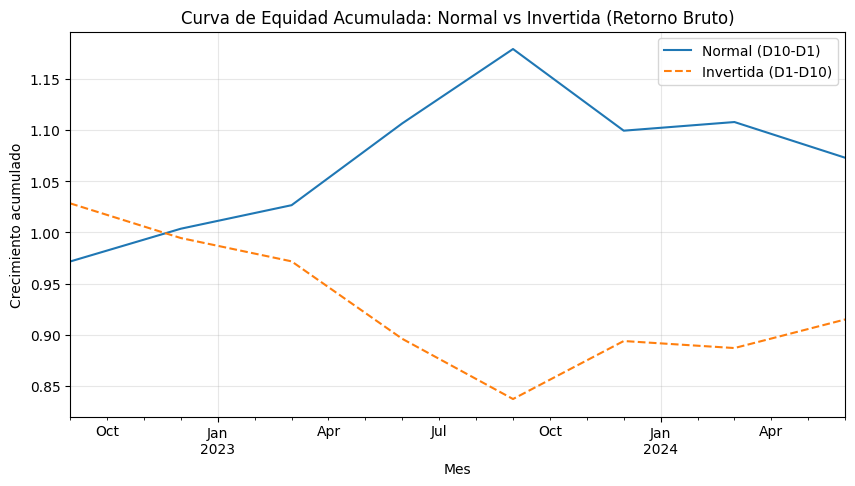


Convención fijada: NORMAL (score alto = mejor)
✔ Spread NORMAL consistente con SIGNAL_DIRECTION.


In [119]:

# --- Helper: t-stat robusto (evita NameError y casos degenerados) ---
def _t_stat_series(x):
    """Devuelve (t_stat, n). Usa ddof=1; si n<2 o var=0 -> t_stat=np.nan."""
    s = pd.Series(x).astype("float64").replace([np.inf, -np.inf], np.nan).dropna()
    n = int(len(s))
    if n < 2:
        return (np.nan, n)
    sd = float(s.std(ddof=1))
    if (not np.isfinite(sd)) or sd == 0.0:
        return (np.nan, n)
    t = float(s.mean()) / (sd / np.sqrt(n))
    return (t, n)

# ==============================================================================
# FASE 3: ANÁLISIS DE DECILES Y SPREAD (OOS BRUTO, VALIDACIÓN DE SIGNO)
#   - Usa: oos2 (con columnas ['Mes', 'y_pred', 'y_true_raw'])
#   - Requiere que _t_stat_series ya esté definido en BLOQUE 14.b
# ==============================================================================

print("\n" + "="*60)
print("📊 Fase 3: Análisis de Deciles y Spread (Validación de Signo)")
print("="*60)

def _calc_decile_spreads(df, score_col='y_pred', y_col='y_true_raw'):
    """
    Calcula, por mes, el retorno promedio del Top Decil (D10) menos el Bottom Decil (D1),
    usando el retorno bruto (y_col).
    """
    monthly_spreads = {}

    for month, g in df.groupby('Mes', sort=True):
        # Evitar meses con muy pocos datos
        if len(g) < 20:
            continue

        # Rankear el score dentro del mes
        r = g[score_col].rank(method='first')
        g = g.copy()

        # Intentar 10 deciles; si falla, caer a 5 quantiles
        try:
            g['decile'] = pd.qcut(r, 10, labels=False, duplicates='drop') + 1
            top_dec = 10
            bot_dec = 1
        except ValueError:
            try:
                g['decile'] = pd.qcut(r, 5, labels=False, duplicates='drop') + 1
                top_dec = 5
                bot_dec = 1
            except ValueError:
                continue

        ret_top = g[g['decile'] == top_dec][y_col].mean()
        ret_bot = g[g['decile'] == bot_dec][y_col].mean()
        monthly_spreads[month] = float(ret_top - ret_bot)

    return pd.Series(monthly_spreads).sort_index()


# --- EJECUCIÓN FASE 3 ---
if 'oos2' in globals() and not oos2.empty:
    df_analysis = oos2.copy()

    # Asegurar 'Mes' como Period[M]
    if 'Mes' not in df_analysis.columns:
        df_analysis['Mes'] = pd.to_datetime(df_analysis['Fecha']).dt.to_period('M')
    elif not pd.api.types.is_period_dtype(df_analysis['Mes']):
        df_analysis['Mes'] = pd.to_datetime(df_analysis['Mes']).dt.to_period('M')

    # Asegurar retorno bruto
    if 'y_true_raw' not in df_analysis.columns:
        try:
            df_analysis['y_true_raw'] = y_raw.loc[df_analysis.index]
        except Exception as e:
            print("⚠️ No se pudo reconstruir 'y_true_raw' a partir de y_raw:", e)

    # --- 1. Estrategia NORMAL (D10 - D1): score alto = mejor acción ---
    spread_normal = _calc_decile_spreads(
        df_analysis,
        score_col='y_pred',
        y_col='y_true_raw'
    )
    mean_norm = float(spread_normal.mean()) if len(spread_normal) else np.nan
    t_norm, n_norm = _t_stat_series(spread_normal)

    print(f"\n1️⃣  Estrategia NORMAL (Comprar D10 / Vender D1):")
    print(f"    Spread Promedio: {mean_norm:.4%}")
    print(f"    t-stat: {t_norm:.2f} (n={n_norm} meses)")

    # --- 2. Estrategia INVERTIDA (D1 - D10): score bajo = mejor acción ---
    spread_flip = -spread_normal
    mean_flip = float(spread_flip.mean()) if len(spread_flip) else np.nan
    t_flip, _ = _t_stat_series(spread_flip)

    print(f"\n2️⃣  Estrategia INVERTIDA (Comprar D1 / Vender D10):")
    print(f"    Spread Promedio: {mean_flip:.4%}")
    print(f"    t-stat: {t_flip:.2f}")

    # --- 3. Veredicto automático ---
    print("\n⚖️  VEREDICTO FASE 3:")
    if mean_norm > 0:
        print("✅ La dirección es CORRECTA. El modelo ordena bien (score alto = mejor retorno bruto).")
    elif mean_flip > 0:
        print("🔄 La dirección está INVERTIDA. Conviene invertir la señal (score bajo = mejor retorno bruto).")
        print("   → En ese caso, para la cartera final, usarías orden ascendente del score o el negativo del score.")
    else:
        print("❌ Ninguna de las dos direcciones genera spread positivo claro en este holdout.")

    # --- 4. Curva de equidad acumulada: Normal vs Invertida ---
    try:

        plt.figure(figsize=(10, 5))
        (1 + spread_normal).cumprod().plot(label='Normal (D10-D1)')
        (1 + spread_flip).cumprod().plot(label='Invertida (D1-D10)', linestyle='--')
        plt.title('Curva de Equidad Acumulada: Normal vs Invertida (Retorno Bruto)')
        plt.xlabel('Mes')
        plt.ylabel('Crecimiento acumulado')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    except Exception as e:
        print("⚠️ No se pudo graficar la curva de equidad:", e)

    # --- 5. Consistencia con SIGNAL_DIRECTION ---
    if 'SIGNAL_DIRECTION' in globals() and not np.isnan(mean_norm):
        dir_text = "NORMAL (score alto = mejor)" if SIGNAL_DIRECTION == 1.0 else "INVERTIDA (score bajo = mejor)"
        print(f"\nConvención fijada: {dir_text}")
        if np.sign(mean_norm) != np.sign(SIGNAL_DIRECTION):
            print("⚠️ Aviso: el spread NORMAL tiene signo contrario a SIGNAL_DIRECTION.")
        else:
            print("✔ Spread NORMAL consistente con SIGNAL_DIRECTION.")

else:
    print("⚠️ No hay datos válidos en 'oos2' para analizar en la Fase 3.")


In [120]:
# Sólo si NO viene del Top-3 tuning, tomamos el del leaderboard base
if 'best_model_pipeline' not in locals():
    if 'df_leaderboard_tuned' in locals() and not df_leaderboard_tuned.empty:
        best_model_info   = df_leaderboard_tuned.iloc[0]
        best_model_name   = best_model_info['Modelo']
        best_model_family = best_model_info['Familia']
        best_model_pipeline = MODELS_ALL[best_model_family][best_model_name]
        print(f"🏆 Modelo Ganador (base): {best_model_family} / {best_model_name}")
    else:
        best_model_pipeline = MODELS_ALL['Boosting']['LightGBM (Ranker)']
        print("⚠️ Leaderboard no disponible. Usando fallback: LightGBM (Ranker)")
else:
    print("✅ Manteniendo best_model_pipeline ya tuneado (Top-3).")


✅ Manteniendo best_model_pipeline ya tuneado (Top-3).


In [121]:
# ==============================================================================
# BLOQUE 16 – Métricas de Ranking: Precision@K y calidad de picks por periodo
# ==============================================================================
print("\n" + "="*80)
print("MÉTRICAS DE RANKING – Precision@K y calidad de picks por periodo")
print("="*80)

import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1) Preparación del dataframe de evaluación (df_eval)
# ------------------------------------------------------------------------------

if 'oos' not in globals() or not isinstance(oos, pd.DataFrame) or oos.empty:
    raise RuntimeError("No se encontró 'oos' válido. Ejecuta primero el bloque de HOLDOUT (OOS).")

df_eval = oos.copy()

# Asegurar 'Mes' como periodo de ranking (rebalanceo)
if 'Mes' not in df_eval.columns:
    if 'Fecha' in df_eval.columns:
        df_eval['Mes'] = pd.to_datetime(df_eval['Fecha']).dt.to_period('M').astype(str)
    else:
        raise RuntimeError("No se encontró 'Mes' ni 'Fecha' en oos; no se puede agrupar por periodo.")

# Asegurar row_id para alinear retornos reales (y_raw) y/o Empresa
if 'row_id' not in df_eval.columns:
    # Si no existe, intentamos usar el índice como row_id
    df_eval['row_id'] = df_eval.index
# normalizar row_id (cuando venga como string)
df_eval['row_id'] = pd.to_numeric(df_eval['row_id'], errors='coerce')

# Score: preferimos y_pred (ya incorpora el signo fijado en diseño). Si no existe, usar y_pred_raw.
if 'y_pred' in df_eval.columns:
    df_eval['score'] = pd.to_numeric(df_eval['y_pred'], errors='coerce')
elif 'y_pred_raw' in df_eval.columns:
    df_eval['score'] = pd.to_numeric(df_eval['y_pred_raw'], errors='coerce')
else:
    raise RuntimeError("No se encontraron columnas de predicción ('y_pred'/'y_pred_raw') en oos.")

# Retorno real: alineación segura por row_id contra y_raw (si existe). Fallback a y_true si aplica.
ret_real = None
if 'y_raw' in globals() and isinstance(globals()['y_raw'], (pd.Series, pd.DataFrame)):
    y_raw_ser = globals()['y_raw']
    if isinstance(y_raw_ser, pd.DataFrame):
        # intentamos tomar la primera columna
        y_raw_ser = y_raw_ser.iloc[:, 0]
    if hasattr(y_raw_ser, 'reindex'):
        ret_real = y_raw_ser.reindex(df_eval['row_id']).astype(float)
        # Si se pierde demasiado, avisar
        miss = ret_real.isna().mean()
        if miss > 0.05:
            print(f"⚠️ Advertencia: {miss*100:.1f}% de ret_real quedó NaN al alinear y_raw por row_id.")
else:
    y_raw_ser = None

# Fallback: si no hay y_raw alineable, intentamos usar y_true SOLO si parece retorno continuo
if ret_real is None or ret_real.isna().all():
    if 'y_true' not in df_eval.columns:
        raise RuntimeError("No existe y_raw alineable ni columna y_true en oos para construir ret_real.")
    y_true = pd.to_numeric(df_eval['y_true'], errors='coerce')
    # Heurística: si y_true parece discreto (bins), NO lo usamos como retorno real
    uniq = y_true.dropna().unique()
    looks_binned = (len(uniq) <= 10) and np.all(np.isclose(uniq, np.round(uniq)))
    if looks_binned:
        print("⚠️ y_true parece ser etiqueta discreta (bins). Sin y_raw no puedo calcular métricas por retorno real con fidelidad.")
        ret_real = y_true.astype(float)  # último recurso
    else:
        ret_real = y_true.astype(float)

df_eval['ret_real'] = ret_real.values

# Identificador: Empresa (si se puede recuperar), si no row_id
if 'Empresa' in df_eval.columns:
    df_eval['Empresa'] = df_eval['Empresa'].astype(str)
elif 'df_model' in globals() and isinstance(globals()['df_model'], pd.DataFrame) and 'Empresa' in globals()['df_model'].columns:
    dm = globals()['df_model']
    try:
        # reindex por row_id
        df_eval['Empresa'] = dm.reindex(df_eval['row_id'])['Empresa'].astype(str).values
    except Exception:
        df_eval['Empresa'] = df_eval['row_id'].astype('Int64').astype(str)
else:
    df_eval['Empresa'] = df_eval['row_id'].astype('Int64').astype(str)

# Limpieza base
df_eval = df_eval.dropna(subset=['Mes', 'score', 'ret_real']).copy()
print(f"Registros en df_eval: {len(df_eval):,}")
print(f"Periodos únicos (rebalanceos): {df_eval['Mes'].nunique():,}")

# ------------------------------------------------------------------------------
# 2) Determinar lógica LONG (ascendente) desde el test de signo (si existe)
# ------------------------------------------------------------------------------

# En tu pipeline: ascending_for_long=True => menor score = LONG (invertido)
if 'ascending_for_long' not in globals():
    # Preferimos la convención explícita del notebook:
    # - si y_pred ya está firmado (SIGNAL_SIGNED=True), LONG = scores más altos.
    if bool(globals().get("SIGNAL_SIGNED", False)):
        ascending_for_long = False
    elif "ASCENDING_FOR_LONG" in globals():
        ascending_for_long = bool(globals()["ASCENDING_FOR_LONG"])
    elif "SIGNAL_DIRECTION" in globals():
        ascending_for_long = (float(globals()["SIGNAL_DIRECTION"]) < 0)
    else:
        ascending_for_long = False

print("\nLógica de selección de LONGS basada en tests de signo:")
print(f"   -> ascending_for_long = {ascending_for_long} ({'INVERTIDO (menor score = LONG)' if ascending_for_long else 'NORMAL (mayor score = LONG)'})")

# ------------------------------------------------------------------------------
# 3) Métricas por periodo
# ------------------------------------------------------------------------------

def compute_ranking_metrics_by_period(
    df_eval: pd.DataFrame,
    k: int = 20,
    period_col: str = 'Mes',
    id_col: str = 'Empresa',
    score_col: str = 'score',
    ret_col: str = 'ret_real',
    ascending_for_long: bool = False
) -> pd.DataFrame:
    """
    Calcula métricas de ranking por periodo.
    - Precision_Long@K: % de longs seleccionados que están entre los top-K por retorno real.
    - Precision_Short@K: % de shorts seleccionados que están entre los bottom-K por retorno real.
    - Long_TopXShare: share de longs que caen por encima de ciertos cuantiles del retorno real (calidad relativa).
    Nota: si el periodo tiene pocos activos, se usa k_eff = min(k, n_assets//2).
    """
    rows = []
    for period, g in df_eval.groupby(period_col):
        g = g.dropna(subset=[score_col, ret_col]).copy()
        n_assets = len(g)
        if n_assets < 2:
            continue

        k_eff = int(min(k, n_assets // 2))
        if k_eff < 1:
            continue

        winners_real = set(g.nlargest(k_eff, ret_col)[id_col])
        losers_real  = set(g.nsmallest(k_eff, ret_col)[id_col])

        # Selección por score según signo
        if ascending_for_long:
            picks_long_df  = g.nsmallest(k_eff, score_col)
            picks_short_df = g.nlargest(k_eff, score_col)
        else:
            picks_long_df  = g.nlargest(k_eff, score_col)
            picks_short_df = g.nsmallest(k_eff, score_col)

        longs_model  = set(picks_long_df[id_col])
        shorts_model = set(picks_short_df[id_col])

        hits_long  = len(longs_model  & winners_real)
        hits_short = len(shorts_model & losers_real)

        precision_long  = hits_long  / k_eff
        precision_short = hits_short / k_eff

        # Cuantiles para "calidad" de picks
        q50 = g[ret_col].quantile(0.50)
        q70 = g[ret_col].quantile(0.70)
        q90 = g[ret_col].quantile(0.90)
        q30 = g[ret_col].quantile(0.30)

        long_top50 = (picks_long_df[ret_col] >= q50).mean()
        long_top30 = (picks_long_df[ret_col] >= q70).mean()
        long_top10 = (picks_long_df[ret_col] >= q90).mean()
        short_bot50 = (picks_short_df[ret_col] <= q50).mean()
        short_bot30 = (picks_short_df[ret_col] <= q30).mean()

        long_mean = float(picks_long_df[ret_col].mean())
        short_mean = float(picks_short_df[ret_col].mean())
        spread = long_mean - short_mean

        rows.append({
            period_col: str(period),
            "Fecha_periodo": pd.Period(str(period), freq='M').to_timestamp(),
            "N_Assets": int(n_assets),
            "K_eff": int(k_eff),
            "Hits_Long": int(hits_long),
            "Hits_Short": int(hits_short),
            "Precision_Long@K": float(precision_long),
            "Precision_Short@K": float(precision_short),
            "Long_Top50Share": float(long_top50),
            "Long_Top30Share": float(long_top30),
            "Long_Top10Share": float(long_top10),
            "Short_Bot50Share": float(short_bot50),
            "Short_Bot30Share": float(short_bot30),
            "Mean_Long": float(long_mean),
            "Mean_Short": float(short_mean),
            "Spread_LS": float(spread),
        })

    out = pd.DataFrame(rows)
    if out.empty:
        # Evita KeyError al hacer sort si no hubo periodos con k_eff>=1
        print("⚠️ No hubo periodos evaluables (posible: pocos activos por periodo o demasiados NaNs).")
        return out

    return out.sort_values("Fecha_periodo").reset_index(drop=True)

# ------------------------------------------------------------------------------
# 4) Ejecución
# ------------------------------------------------------------------------------

K_PORT = TOP_K if 'TOP_K' in globals() else 20

metrics_k = compute_ranking_metrics_by_period(
    df_eval=df_eval,
    k=int(K_PORT),
    period_col='Mes',
    id_col='Empresa',
    score_col='score',
    ret_col='ret_real',
    ascending_for_long=bool(ascending_for_long)
)

print(f"\nPeriodos evaluados: {len(metrics_k):,}")
if not metrics_k.empty:
    cols_show = ['Mes','N_Assets','K_eff','Precision_Long@K','Precision_Short@K','Long_Top50Share','Long_Top10Share','Spread_LS']
    display(metrics_k[cols_show].head(10))

    resumen_media = metrics_k[cols_show[3:]].mean().to_frame(name='Media')
    print("\nTABLA – Resumen global (medias por periodo)")
    display(resumen_media)

    metrics_k.to_csv("metrics_precision_k_por_periodo.csv", index=False)
    resumen_media.to_csv("metrics_precision_k_resumen_media.csv")
    print("\n✔ Archivos guardados:")
    print("  - metrics_precision_k_por_periodo.csv")
    print("  - metrics_precision_k_resumen_media.csv")



MÉTRICAS DE RANKING – Precision@K y calidad de picks por periodo
Registros en df_eval: 1,440
Periodos únicos (rebalanceos): 8

Lógica de selección de LONGS basada en tests de signo:
   -> ascending_for_long = False (NORMAL (mayor score = LONG))

Periodos evaluados: 8


,Mes,N_Assets,K_eff,Precision_Long@K,Precision_Short@K,Long_Top50Share,Long_Top10Share,Spread_LS
0,2022-09,180,3,0.000000,0.0,0.666667,0.000000,-0.033589
1,2022-12,180,3,0.000000,0.0,0.666667,0.333333,0.233842
2,2023-03,180,3,0.000000,0.0,0.333333,0.000000,-0.102402
3,2023-06,180,3,0.000000,0.0,0.333333,0.000000,-0.144601
4,2023-09,180,3,0.333333,0.0,0.333333,0.333333,0.142601
5,2023-12,180,3,0.333333,0.0,0.333333,0.333333,0.098190
6,2024-03,180,3,0.000000,0.0,0.333333,0.000000,-0.241941
7,2024-06,180,3,0.000000,0.0,0.333333,0.000000,-0.210101



TABLA – Resumen global (medias por periodo)


,Media
Precision_Long@K,0.083333
Precision_Short@K,0.000000
Long_Top50Share,0.416667
Long_Top10Share,0.125000
Spread_LS,-0.032250



✔ Archivos guardados:
  - metrics_precision_k_por_periodo.csv
  - metrics_precision_k_resumen_media.csv


In [122]:
# (DEPRECATED) Este bloque fue consolidado en la celda anterior para evitar duplicación.
print("BLOQUE 16 duplicado (deprecated): usa la celda anterior.")


BLOQUE 16 duplicado (deprecated): usa la celda anterior.



Análisis de Importancia de Features de los Mejores Modelos

--- Top 3 Modelos Seleccionados para Análisis ---


,Modelo,IC_Mean,Spread_Mean,Tunes
0,LightGBM (Ranker),0.038051,0.030187,2
1,XGBoost,0.032354,0.019274,2
2,LightGBM,0.015521,0.016338,2



------------------------------------------------------------
Re-entrenando y analizando: LightGBM (Ranker)
------------------------------------------------------------
  Modelo re-entrenado en el dataset completo en 1.93 seg.


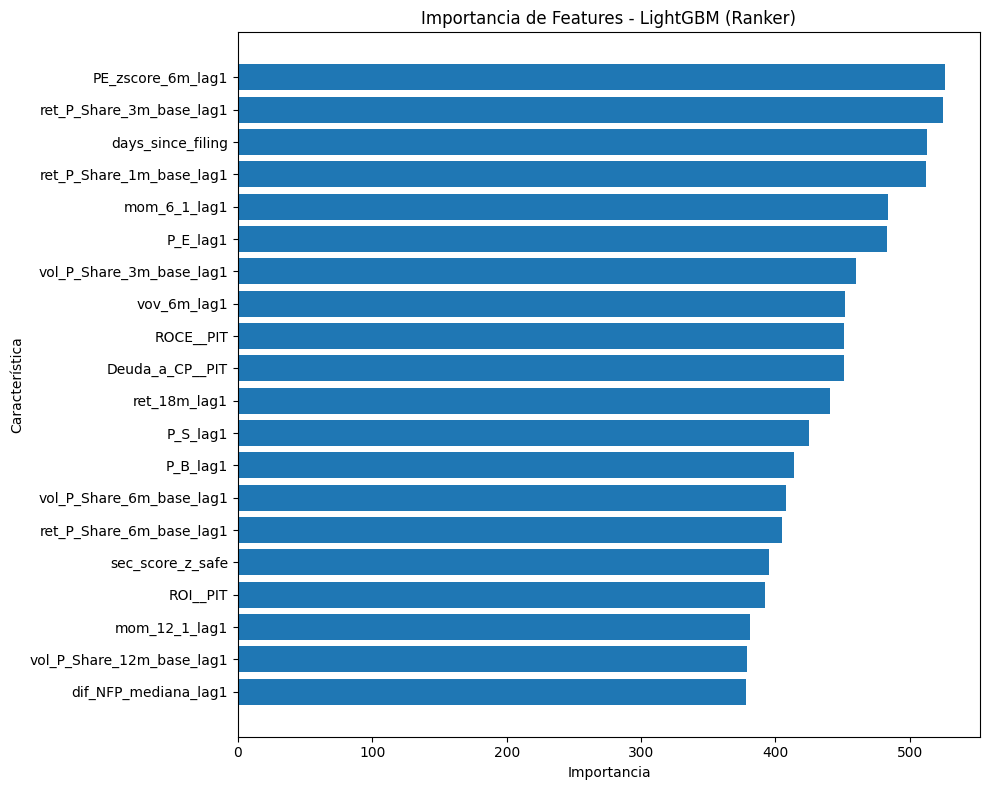

,feature,importance
0,PE_zscore_6m_lag1,526
12,ret_P_Share_3m_base_lag1,525
29,days_since_filing,513
11,ret_P_Share_1m_base_lag1,512
8,mom_6_1_lag1,484
2,P_E_lag1,483
15,vol_P_Share_3m_base_lag1,460
17,vov_6m_lag1,452
26,ROCE__PIT,451
20,Deuda_a_CP__PIT,451



------------------------------------------------------------
Re-entrenando y analizando: XGBoost
------------------------------------------------------------
  Modelo re-entrenado en el dataset completo en 1.89 seg.


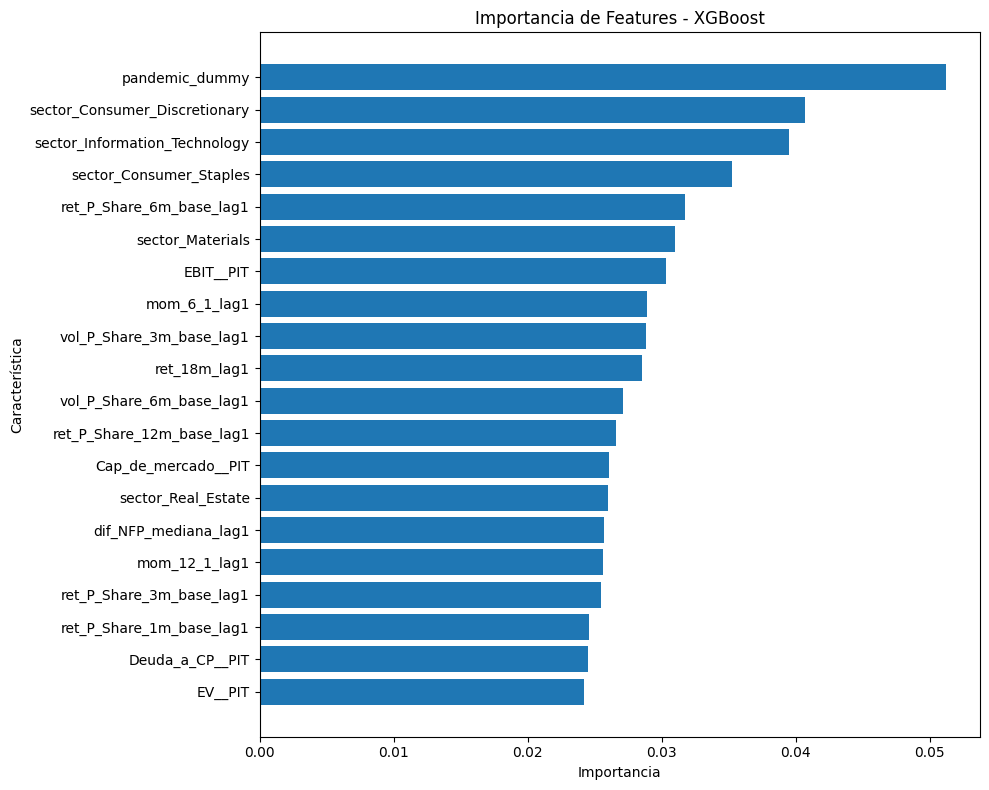

,feature,importance
42,pandemic_dummy,0.051184
30,sector_Consumer_Discretionary,0.040710
36,sector_Information_Technology,0.039480
31,sector_Consumer_Staples,0.035246
13,ret_P_Share_6m_base_lag1,0.031728
37,sector_Materials,0.030981
22,EBIT__PIT,0.030319
8,mom_6_1_lag1,0.028886
15,vol_P_Share_3m_base_lag1,0.028864
9,ret_18m_lag1,0.028496



------------------------------------------------------------
Re-entrenando y analizando: LightGBM
------------------------------------------------------------
  Modelo re-entrenado en el dataset completo en 2.32 seg.


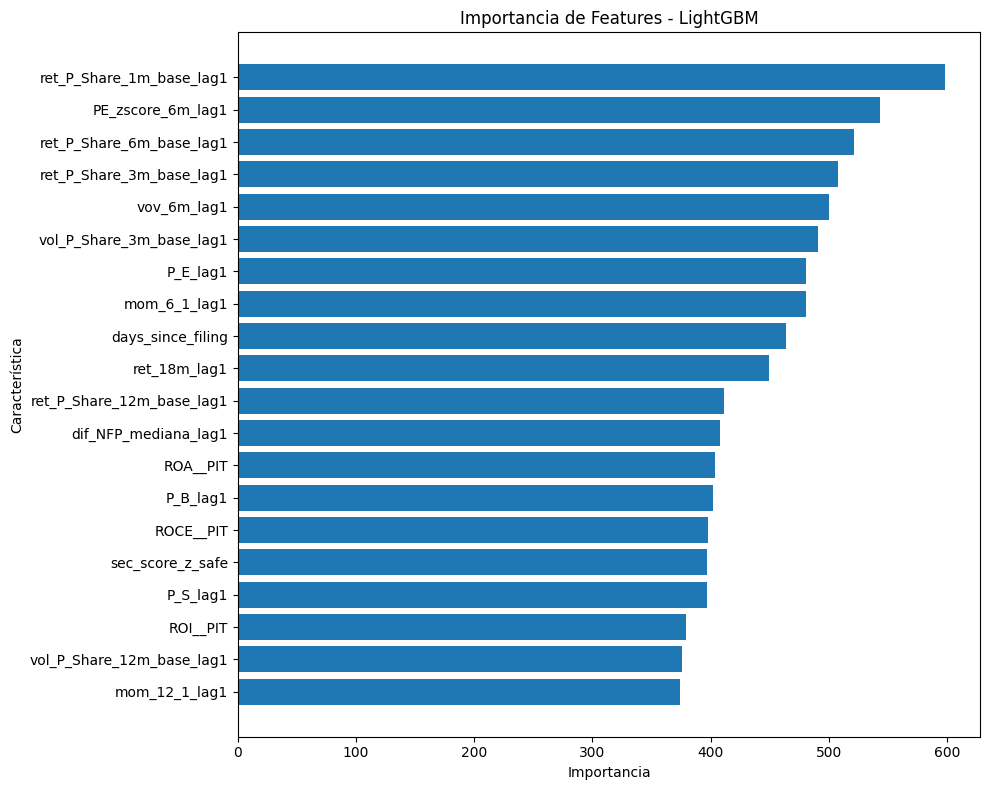

,feature,importance
11,ret_P_Share_1m_base_lag1,598
0,PE_zscore_6m_lag1,543
13,ret_P_Share_6m_base_lag1,521
12,ret_P_Share_3m_base_lag1,508
17,vov_6m_lag1,500
15,vol_P_Share_3m_base_lag1,491
2,P_E_lag1,481
8,mom_6_1_lag1,481
29,days_since_filing,464
9,ret_18m_lag1,449


In [123]:
# ================================================================================
# BLOQUE 19: ANÁLISIS DE FEATURE IMPORTANCE DE LOS MEJORES MODELOS
# ================================================================================

print("\n" + "="*60)
print("Análisis de Importancia de Features de los Mejores Modelos")
print("="*60)

# --- 1. Aplanar el diccionario de modelos si aún no existe ---
if 'models_to_compare_flat' not in locals():
    models_to_compare_flat = {}
    for family, model_dict in MODELS_ALL.items():
        for model_name, pipeline in model_dict.items():
            # 1. Guardar con nombre corto (ej: "GKX NN")
            models_to_compare_flat[model_name] = pipeline

            # 2. Guardar con nombre compuesto (ej: "Redes neuronales :: GKX NN")
            full_name = f"{family} :: {model_name}"
            models_to_compare_flat[full_name] = pipeline

# --- 2. Función auxiliar para feature importance ---
def plot_feature_importances(model, feature_names, title="Importancia de Características", top_n=20):
    """
    Grafica la importancia de features para diferentes tipos de modelos,
    incluyendo wrappers personalizados y modelos lineales.
    """
    final_estimator = model.steps[-1][1] if hasattr(model, 'steps') else model
    estimator_name = final_estimator.__class__.__name__

    importances = None

    try:
        # Modelos tipo árbol estándar (RF, XGB, LGBM, etc.)
        if hasattr(final_estimator, 'feature_importances_'):
            importances = final_estimator.feature_importances_

        # Wrappers personalizados (ajusta a tus clases reales)
        elif estimator_name == 'RFCAsRanker' and hasattr(final_estimator, '_clf'):
            importances = final_estimator._clf.feature_importances_
        elif estimator_name == 'CatBoostRankerSk' and hasattr(final_estimator, '_mdl'):
            importances = final_estimator._mdl.get_feature_importance(type='PredictionValuesChange')

        # Modelos lineales
        elif hasattr(final_estimator, 'coef_'):
            importances = np.abs(final_estimator.coef_.flatten())

        else:
            print(f"Advertencia: el estimador {estimator_name} no tiene método conocido de importancia de features.")
            return None

        fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        fi_df = fi_df.sort_values('importance', ascending=False).head(top_n)

        plt.figure(figsize=(10, 8))
        plt.barh(fi_df['feature'], fi_df['importance'])
        plt.xlabel('Importancia')
        plt.ylabel('Característica')
        plt.title(title)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        return fi_df

    except Exception as e:
        print(f"Error al graficar importancia para {title}: {e}")
        return None

# --- 3. Seleccionar la fuente de leaderboard disponible ---
lb = None
name_col = None
score_col = None

if 'leaderboard' in locals() and isinstance(leaderboard, pd.DataFrame) and not leaderboard.empty:
    # columnas típicas: ['Modelo','IC_Mean','Spread_Mean',...]
    lb = leaderboard.copy()
    name_col = 'Modelo'
    score_col = 'IC_Mean'

elif 'df_resumen' in locals() and isinstance(df_resumen, pd.DataFrame) and not df_resumen.empty:
    lb = df_resumen.copy()
    name_col = 'Modelo' if 'Modelo' in df_resumen.columns else 'modelo'
    score_col = 'IC_Mean' if 'IC_Mean' in df_resumen.columns else 'IC_promedio'

elif 'df_leaderboard_tuned' in locals() and isinstance(df_leaderboard_tuned, pd.DataFrame) and not df_leaderboard_tuned.empty:
    lb = df_leaderboard_tuned.copy()
    name_col = 'Modelo' if 'Modelo' in lb.columns else ('Model' if 'Model' in lb.columns else None)
    if 'IC_mensual' in lb.columns:
        score_col = 'IC_mensual'
    elif 'IC_Mean' in lb.columns:
        score_col = 'IC_Mean'

elif 'df_lb_oof' in locals() and isinstance(df_lb_oof, pd.DataFrame) and not df_lb_oof.empty:
    # columnas típicas: ['Model','IC_mensual','Spread_mensual',...]
    lb = df_lb_oof.copy()
    name_col = 'Model'
    score_col = 'IC_mensual'

if lb is None or name_col is None or score_col is None:
    print("No se encontró un leaderboard válido con columnas de modelo e IC. Saltando Fase 4.")
    top_3_configs = pd.DataFrame()
else:
    top_3_configs = (
        lb
        .sort_values(score_col, ascending=False)
        .head(3)
        .reset_index(drop=True)
    )

    print("\n--- Top 3 Modelos Seleccionados para Análisis ---")
    display_cols = [c for c in [name_col, score_col, 'Spread_mensual', 'Spread_Mean', 'Tunes'] if c in lb.columns]
    if display_cols:
        safe_display(top_3_configs[display_cols])
    else:
        safe_display(top_3_configs)

# --- 4. Re-entrenar y graficar importancia para cada modelo del Top-3 ---
if not top_3_configs.empty:
    if 'X' not in locals() or 'y' not in locals():
        print("ERROR: 'X' y/o 'y' no están definidos. No se puede entrenar para importancia.")
    elif 'predictor_cols_final' not in locals():
        print("ERROR: 'predictor_cols_final' no está definido.")
    else:
        # Serie de meses completa (para fit_with_rank_support)
        months_full = pd.to_datetime(DATES_SERIES).dt.to_period('M')

        for _, row in top_3_configs.iterrows():
            model_name = row[name_col]
            pipeline_base = models_to_compare_flat.get(model_name)

            if pipeline_base is None:
                print(f"\nNo se encontró el pipeline para '{model_name}' en MODELS_ALL. Se omite.")
                continue

            print("\n" + "-"*60)
            print(f"Re-entrenando y analizando: {model_name}")
            print("-"*60)

            try:
                t0 = time.time()
                pipeline_fitted = fit_with_rank_support(
                    clone(pipeline_base),
                    X, y,
                    months_full
                )
                t1 = time.time()
                print(f"  Modelo re-entrenado en el dataset completo en {t1 - t0:.2f} seg.")

                fi_df = plot_feature_importances(
                    model=pipeline_fitted,
                    feature_names=predictor_cols_final,
                    title=f"Importancia de Features - {model_name}",
                    top_n=20
                )
                if fi_df is not None:
                    safe_display(fi_df)

            except Exception as e:
                print(f"  ERROR al re-entrenar o graficar para {model_name}: {e}")
else:
    print("\nNo se seleccionaron modelos para analizar (leaderboard vacío o sin columnas de IC).")

In [124]:
# ================================================================================
# BLOQUE: ANÁLISIS DE INTERPRETABILIDAD CON SHAP
# ================================================================================
import shap

print("\n" + "="*80)
print("### INICIO: Análisis de Interpretabilidad con SHAP (Versión Robusta) ###")
print("="*80)

# --- Helper robusto para colapsar valores SHAP a 1D ---
def _to_shap_global_1d(shap_values):
    # Lista por clase (clasificación): promedio de |SHAP| por clase y luego sobre clases
    if isinstance(shap_values, list):
        per_class = [np.abs(np.asarray(sv)).mean(axis=0) for sv in shap_values]
        return np.mean(np.vstack(per_class), axis=0)

    # Explanation o array -> tomar el .values si existe
    sv = getattr(shap_values, "values", shap_values)
    sv = np.asarray(sv)

    if sv.ndim == 2:              # (n_samples, n_features)
        return np.abs(sv).mean(axis=0)
    if sv.ndim == 3:              # (n_samples, n_features, n_outputs)
        return np.abs(sv).mean(axis=(0, 2)) # Promedia sobre muestras y outputs
    if sv.ndim == 1:              # (n_features,)
        return np.abs(sv)

    raise ValueError(f"Forma inesperada de SHAP: {sv.shape}")

# --- 1) Preparar modelo y datos transformados ---
try:
    assert 'best_model_pipeline' in globals() and best_model_pipeline is not None, \
        "La variable 'best_model_pipeline' no está definida."

    mdl_name = (best_model_name if 'best_model_name' in globals()
                else type(best_model_pipeline.named_steps['model']).__name__)
    print(f"Analizando el modelo ganador: {mdl_name}")

    print("   Re-entrenando el modelo en TODOS los datos…")
    months_full = pd.to_datetime(DATES_SERIES).dt.to_period('M')
    pipeline_fitted = fit_with_rank_support(clone(best_model_pipeline), X, y, months_full)
    print("   Modelo re-entrenado.")

    preprocessor_fitted = _SkPipe(pipeline_fitted.steps[:-1])
    model_fitted = pipeline_fitted.steps[-1][1]

    print("   Aplicando transformaciones (winsor/zscore/…) para SHAP…")
    X_transformed = preprocessor_fitted.transform(X)
    X_transformed_df = pd.DataFrame(X_transformed, columns=predictor_cols_final)
    print("   Transformación completada.")

except Exception as e:
    print(f"Error preparando el modelo/transformaciones para SHAP: {e}")
    model_fitted = None

# --- 2) Resolver el estimador compatible con TreeExplainer ---
def _resolve_tree_model(m):
    if hasattr(m, "_clf") and m._clf is not None:
        return m._clf, "RFCAsRanker(RandomForestClassifier)"
    name = m.__class__.__name__
    if any(k in name for k in ["LGBM", "XGB", "RandomForest", "DecisionTree"]):
        return m, name
    return None, name

# --- 3) Submuestreo y cálculo SHAP ---
if model_fitted is not None:
    model_for_shap, model_tag = _resolve_tree_model(model_fitted)

    # --- Guard-rail para rankers puros (LGBMRanker/XGBRanker) ---
    if isinstance(model_fitted, (LGBMRanker, XGBRanker)):
        print("⚠️  SHAP no soporta bien objetivos de ranking (LGBMRanker/XGBRanker). "
              "Saltaré interpretabilidad para este modelo.")
        model_for_shap = None

    if model_for_shap is None:
        print(f"No se puede calcular SHAP para este tipo de modelo: {model_tag}")
    else:
        N_SHAP_SAMPLES = 1000 if FAST_MODE else 5000  # ← movido aquí
        if len(X_transformed_df) > N_SHAP_SAMPLES:
            print(f"   Usando un subconjunto de {N_SHAP_SAMPLES} filas para SHAP…")
            X_shap_subset = shap.sample(X_transformed_df, N_SHAP_SAMPLES, random_state=GLOBAL_SEED)
        else:
            X_shap_subset = X_transformed_df

        print("   Calculando valores SHAP…")
        explainer = shap.TreeExplainer(model_for_shap, feature_perturbation="tree_path_dependent")
        shap_values = explainer.shap_values(X_shap_subset)
        print("   Cálculo SHAP completado.")

        # --- 4) Visualizaciones ---
        shap_global = _to_shap_global_1d(shap_values)

        # Chequeo defensivo de dimensiones
        if shap_global.shape[0] != X_shap_subset.shape[1]:
            raise ValueError(
                f"Desacople SHAP/features: {shap_global.shape[0]} vs {X_shap_subset.shape[1]}"
            )

        fi_df = (pd.DataFrame({
                    "feature": X_shap_subset.columns,
                    "shap_importance": shap_global.astype(float)
                })
                .sort_values("shap_importance", ascending=False)
                .reset_index(drop=True))

        print("\n--- Top 15 features por importancia SHAP global ---")
        print(fi_df.head(15).to_string(index=False))

        # (B) Bar plot
        plt.figure()
        plt.bar(fi_df["feature"].values[:20], fi_df["shap_importance"].values[:20])
        plt.xticks(rotation=90)
        plt.title(f"Importancia media |SHAP| (Top 20) – {mdl_name}")
        plt.tight_layout()
        plt.show()

        # (C) Summary plot
        if isinstance(shap_values, list): # Multiclase
            classes = getattr(model_for_shap, "classes_", list(range(len(shap_values))))
            idx_top = int(np.argmax(classes))
            print(f"\n--- Summary plot (clase/top bin = {classes[idx_top]}) ---")
            shap.summary_plot(shap_values[idx_top], X_shap_subset, show=False)
            plt.title(f"SHAP summary – clase {classes[idx_top]} – {mdl_name}")
            plt.tight_layout()
            plt.show()
        else: # Regresión/binaria
            print("\n--- Summary plot (regresión/binaria) ---")
            shap.summary_plot(shap_values, X_shap_subset, show=False)
            plt.title(f"SHAP summary – {mdl_name}")
            plt.tight_layout()
            plt.show()
else:
    print("No se pudo calcular SHAP. El modelo final no es compatible o no se entrenó correctamente.")


### INICIO: Análisis de Interpretabilidad con SHAP (Versión Robusta) ###
Analizando el modelo ganador: LightGBM (Ranker)
   Re-entrenando el modelo en TODOS los datos…
[LightGBM] [Warning] verbosity is set=0, verbose=0 will be ignored. Current value: verbosity=0
[LightGBM] [Warning] device_type is set=cpu, device=cpu will be ignored. Current value: device_type=cpu
[LightGBM] [Warning] verbosity is set=0, verbose=0 will be ignored. Current value: verbosity=0
[LightGBM] [Warning] device_type is set=cpu, device=cpu will be ignored. Current value: device_type=cpu
   Modelo re-entrenado.
   Aplicando transformaciones (winsor/zscore/…) para SHAP…
   Transformación completada.
⚠️  SHAP no soporta bien objetivos de ranking (LGBMRanker/XGBRanker). Saltaré interpretabilidad para este modelo.
No se puede calcular SHAP para este tipo de modelo: LGBMRanker


In [125]:
# ==============================================================================
# BLOQUE 18 – Construcción de Cartera Óptima Long/Short (Último Trimestre)
# ==============================================================================

print("\n" + "="*80)
print("BLOQUE 18 – Construcción de Cartera Óptima (Long + Short)")
print("="*80)

def build_long_short_portfolio(
    oos_df: pd.DataFrame,
    ticker_col: str = "Empresa",
    signal_col: str = "y_pred",
    n_legs: int = 20,   # Número de activos por pata (20 Long / 20 Short)
):
    """
    Construye una cartera 20L/20S para el último trimestre disponible
    usando la convención global SIGNAL_DIRECTION.

    Pre-requisitos:
    - oos_df con columnas: [ticker_col, signal_col, 'Mes' o 'Fecha'].
    - SIGNAL_DIRECTION definido en alguna celda previa (+1 normal, -1 invertida).
    """

    # -----------------------------
    # Robustez: identificar columna de activo
    # -----------------------------
    if ticker_col not in oos_df.columns:
        # 1) buscar alternativas en oos_df
        for _c in ("Empresa","Ticker","Symbol","ticker","symbol","PERMNO","permno","ID","id","asset_id","row_id"):
            if _c in oos_df.columns:
                ticker_col = _c
                break

    # 2) si aún no está, intentar traerlo desde df_model (usando row_id como índice)
    if ticker_col not in oos_df.columns and ("row_id" in oos_df.columns):
        _dfm = globals().get("df_model", None)
        if isinstance(_dfm, pd.DataFrame):
            for _c in ("Empresa","Ticker","Symbol","ticker","symbol","PERMNO","permno","ID","id","asset_id"):
                if _c in _dfm.columns:
                    try:
                        oos_df = oos_df.copy()
                        oos_df[_c] = _dfm[_c].reindex(oos_df["row_id"]).values
                        ticker_col = _c
                        break
                    except Exception:
                        pass

    if ticker_col not in oos_df.columns:
        raise KeyError(f"No se encontró columna de identificador de activo. Probé ticker_col='{ticker_col}' y alternativas. Columnas disponibles: {list(oos_df.columns)[:30]}")
    # Si existe la columna pero está vacía, no se puede armar cartera
    if oos_df[ticker_col].isna().all():
        raise ValueError(f"Columna de activo {ticker_col} existe pero está vacía (todo NaN). Revisa la alineación de row_id con df_model o añade el identificador al construir OOS.")

    if oos_df is None or oos_df.empty:
        print("Advertencia: 'oos_df' vacío.")
        return pd.DataFrame(), None

    df = oos_df.copy()    # 1) Construir score_final con la convención global
    # Nota: en este notebook, y_pred YA viene firmado desde DISEÑO (SIGNAL_SIGNED=True),
    # por lo que LONG = scores más altos (SIGNAL_DIRECTION=+1).
    SIGNAL_DIRECTION = float(globals().get("SIGNAL_DIRECTION", 1.0))  # fallback = normal
    if bool(globals().get("SIGNAL_SIGNED", False)):
        SIGNAL_DIRECTION = 1.0
    df["score_final"] = SIGNAL_DIRECTION * df[signal_col]
    direction_label = "NORMAL (mayor score_final = mejor = Long)" if SIGNAL_DIRECTION == 1.0 \
                      else "INVERTIDA (menor y_pred original = mejor = Long)"
    print(f"   → Lógica de ranking aplicada: {direction_label}")

    # 2) Asegurar Mes como Period[M]
    if "Mes" not in df.columns:
        if "Fecha" not in df.columns:
            raise ValueError("Se necesita 'Mes' o 'Fecha' en oos_df.")
        df["Mes"] = pd.to_datetime(df["Fecha"]).dt.to_period("M")
    elif not is_period_dtype(df["Mes"]):
        df["Mes"] = pd.to_datetime(df["Mes"]).dt.to_period("M")

    # 3) Definir trimestre calendario
    df["Q"] = df["Mes"].dt.asfreq("Q")
    latest_q = df["Q"].max()
    print(f"   → Último trimestre disponible: {latest_q}")

    df_latest_q = df[df["Q"] == latest_q].copy()
    if df_latest_q.empty:
        print("   → No hay datos para el último trimestre.")
        return pd.DataFrame(), None

    # 3.5) Suavizado opcional del score dentro del trimestre (solo pasado; sin leakage)
    #      - NONE: sin suavizado (usa score_final)
    #      - EWMA3: score_t = 0.5*score_t + 0.3*score_{t-1} + 0.2*score_{t-2} (por Empresa)
    #      - MED3:  mediana rolling 3 (robusta a outliers) (por Empresa)
    #      - CSZ_EWMA3 / CSZ_MED3: z-score cross-sectional por mes y luego suaviza por Empresa
    SMOOTH_METHOD = str(globals().get("SMOOTH_METHOD", "NONE")).upper()
    SMOOTH_WEIGHTS = globals().get("SMOOTH_WEIGHTS", (0.5, 0.3, 0.2))
    w0, w1, w2 = map(float, SMOOTH_WEIGHTS)

    df_latest_q = df_latest_q.sort_values([ticker_col, "Mes"]).copy()

    base_col = "score_final"
    core = SMOOTH_METHOD
    if core.startswith("CSZ_"):
        core = core.replace("CSZ_", "", 1)
        df_latest_q["_score_csz"] = df_latest_q.groupby("Mes")["score_final"].transform(
            lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-12)
        )
        base_col = "_score_csz"

    g = df_latest_q.groupby(ticker_col)[base_col]

    if core in {"EWMA3", "WAVG3", "WEIGHTED3"}:
        df_latest_q["score_used"] = (w0 * g.transform(lambda s: s) + w1 * g.shift(1) + w2 * g.shift(2))
    elif core in {"MED3", "MEDIAN3"}:
        df_latest_q["score_used"] = g.transform(lambda s: s.rolling(3, min_periods=3).median())
    else:
        df_latest_q["score_used"] = df_latest_q[base_col]

    # Fallback si falta historia (p.ej., IPOs dentro del trimestre)
    df_latest_q["score_used"] = df_latest_q["score_used"].fillna(df_latest_q[base_col])

    # 4) Rank mensual: rank 1 siempre es mejor (mayor score_used = mejor)
    df_latest_q["rank_monthly"] = df_latest_q.groupby("Mes")["score_used"].rank(
        ascending=False,
        method="first",
    )

    # 5) Promedio de rank por empresa dentro del último trimestre
    df_signal = (
        df_latest_q
        .groupby(ticker_col)["rank_monthly"]
        .mean()
        .reset_index()
        .rename(columns={"rank_monthly": "avg_rank_q"})
    )

    # 6) Rank final consolidado (1 = mejor)
    df_signal["rank_final"] = df_signal["avg_rank_q"].rank(
        method="first",
        ascending=True
    )

    # Ordenar: Arriba las mejores (Long), abajo las peores (Short)
    df_signal = df_signal.sort_values("rank_final", ascending=True).reset_index(drop=True)

    # --- CONSTRUCCIÓN DE PATAS ---

    # Pata Long: las Top N
    long_leg = df_signal.head(n_legs).copy()
    long_leg["Side"] = "LONG (Compra)"

    # Pata Short: las Bottom N
    short_leg = df_signal.tail(n_legs).copy()
    short_leg["Side"] = "SHORT (Venta)"
    short_leg = short_leg.sort_values("rank_final", ascending=False)  # peor primero

    # Unir
    final_portfolio = pd.concat([long_leg, short_leg], axis=0)

    return final_portfolio, latest_q

# Ejecutar
cartera_optima, last_q = build_long_short_portfolio(oos_df=oos, n_legs=20)

if cartera_optima is not None and not cartera_optima.empty:
    print(f"\n=== CARTERA ÓPTIMA ({len(cartera_optima)} activos) para {last_q} ===")

    # Detectar columna de activo usada en la cartera (puede no llamarse "Empresa")
    ticker_col_used = next((c for c in ("Empresa","Ticker","Symbol","PERMNO","permno","ticker","symbol","asset_id","row_id")
                            if c in cartera_optima.columns), None)
    if ticker_col_used is None:
        ticker_col_used = cartera_optima.columns[0]
    cols_show = [ticker_col_used, "rank_final", "Side"]
    print("\n🟢 PATA LONG (Top 20 - Comprar):")
    display(cartera_optima[cartera_optima["Side"].str.contains("LONG")][cols_show])

    print("\n🔴 PATA SHORT (Bottom 20 - Vender):")
    display(cartera_optima[cartera_optima["Side"].str.contains("SHORT")][cols_show])

    # Guardar en globales por si lo quieres usar después
    globals()["cartera_final"] = cartera_optima
    globals()["last_q"] = last_q
else:
    print("No se pudo generar cartera final.")



BLOQUE 18 – Construcción de Cartera Óptima (Long + Short)
   → Lógica de ranking aplicada: NORMAL (mayor score_final = mejor = Long)
   → Último trimestre disponible: 2024Q2

=== CARTERA ÓPTIMA (40 activos) para 2024Q2 ===

🟢 PATA LONG (Top 20 - Comprar):


,Empresa,rank_final,Side
0,CRTO US Equity,1.0,LONG (Compra)
1,LULU US Equity,2.0,LONG (Compra)
2,FIVE US Equity,3.0,LONG (Compra)
3,SFM US Equity,4.0,LONG (Compra)
4,CRUS US Equity,5.0,LONG (Compra)
5,PLAB US Equity,6.0,LONG (Compra)
6,MNRO US Equity,7.0,LONG (Compra)
7,ULTA US Equity,8.0,LONG (Compra)
8,NVDA US Equity,9.0,LONG (Compra)
9,SCVL US Equity,10.0,LONG (Compra)



🔴 PATA SHORT (Bottom 20 - Vender):


,Empresa,rank_final,Side
179,EXC US Equity,180.0,SHORT (Venta)
178,XEL US Equity,179.0,SHORT (Venta)
177,ARLP US Equity,178.0,SHORT (Venta)
176,AMGN US Equity,177.0,SHORT (Venta)
175,REG US Equity,176.0,SHORT (Venta)
174,KDP US Equity,175.0,SHORT (Venta)
173,MDLZ US Equity,174.0,SHORT (Venta)
172,HON US Equity,173.0,SHORT (Venta)
171,LNT US Equity,172.0,SHORT (Venta)
170,PEP US Equity,171.0,SHORT (Venta)


In [126]:
# ==============================================================================
# BLOQUE 19.0 – Reporte Final de Tesis: Estrategia L/S vs Benchmarks
# - Configuración general y sanity checks
# ==============================================================================

print("\n" + "="*80)
print("🏆 BLOQUE 19 – Reporte Final: Estrategia L/S vs Benchmarks")
print("="*80)

if "oos" not in globals() or oos is None or oos.empty:
    raise RuntimeError("El DataFrame 'oos' no está definido o está vacío. Ejecuta primero el holdout.")

df_oos = oos.copy()

TICKER_COL = "Empresa"

# Candidatos de columna de retorno (ajusta nombres si fuera necesario)
RET_CANDIDATES = [
    "retorno_futuro_3m",  # nombre natural del TARGET_COL
    "ret_3m_futuro",      # nombre alternativo que usaste antes
    "y_true"              # fallback: columna usada en el modelo
]

RET_COL = None
for c in RET_CANDIDATES:
    if c in df_oos.columns:
        RET_COL = c
        break

if RET_COL is None:
    raise RuntimeError(
        f"No se encontró ninguna columna de retorno entre {RET_CANDIDATES}. "
        f"Revisa cómo se llama el target en 'oos'."
    )

print(f"   · Columna de retorno usada para el análisis OOS: {RET_COL}")
# ------------------------------------------------------------------
# Retorno para P&L (económico): priorizar retorno bruto y_raw alineado por row_id
# - RET_COL (arriba) se usa para métricas de ranking/IC si está transformado (p.ej. residual)
# - ret_raw se usa para P&L vs RF/SPY/benchmarks (más interpretable)
# ------------------------------------------------------------------
RET_COL_RANK = RET_COL  # conserva lo que venga en oos (a menudo y_true)
RET_COL_PNL = None

if "row_id" in df_oos.columns and ("y_raw" in globals()):
    _yraw = globals()["y_raw"]
    try:
        if hasattr(_yraw, "iloc") and getattr(_yraw, "ndim", 1) == 2:
            _yraw = _yraw.iloc[:, 0]
        # asegurar índice comparable
        _idx = pd.Index(df_oos["row_id"])
        df_oos["ret_raw"] = pd.Series(_yraw).reindex(_idx).astype(float).to_numpy()
        miss = float(pd.isna(df_oos["ret_raw"]).mean())
        print(f"   · Retorno P&L: ret_raw (y_raw alineado por row_id) | NaNs={miss:.1%}")
        if miss <= 0.05:
            RET_COL_PNL = "ret_raw"
        else:
            print("   [WARN] ret_raw con muchos NaN; usando RET_COL (posible retorno transformado).")
    except Exception as _e:
        print(f"   [WARN] No se pudo alinear y_raw por row_id ({_e!r}); usando RET_COL.")
else:
    if "y_true_raw" in df_oos.columns:
        df_oos["ret_raw"] = df_oos["y_true_raw"].astype(float)
        RET_COL_PNL = "ret_raw"
        print("   · Retorno P&L: y_true_raw (columna en oos)")
    else:
        print("   [WARN] No hay y_raw/row_id disponibles; usando RET_COL para P&L (ojo si está transformado).")

if RET_COL_PNL is None:
    RET_COL_PNL = RET_COL



# Columna temporal (Mes)
if "Mes" in df_oos.columns:
    df_oos["Mes"] = pd.to_datetime(df_oos["Mes"]).dt.to_period("M")
elif "Fecha" in df_oos.columns:
    df_oos["Mes"] = pd.to_datetime(df_oos["Fecha"]).dt.to_period("M")
else:
    raise RuntimeError("Se necesita 'Mes' o 'Fecha' en 'oos' para agrupar por período.")

# Dirección de la señal del modelo
# SIGNAL_DIRECTION = 1.0 → mayor y_pred = mayor retorno esperado
# Dirección de la señal (fuente de verdad: DISEÑO/CV).
# - BEST_SIGN/BEST_PRED_SIGN se decide en el tramo de DISEÑO (sin mirar holdout).
# - SIGNAL_DIRECTION se mantiene como override manual si el usuario lo define explícitamente.
_design_sign = int(globals().get("BEST_SIGN", globals().get("BEST_PRED_SIGN", 1)))

# Override manual (si el usuario lo fuerza); por defecto usamos el signo de DISEÑO
SIGNAL_DIRECTION = globals().get("SIGNAL_DIRECTION", None)
if SIGNAL_DIRECTION is None:
    SIGNAL_DIRECTION = float(_design_sign)
else:
    SIGNAL_DIRECTION = float(SIGNAL_DIRECTION)

print(f"   · SIGNO (DISEÑO) = {_design_sign:+d} | SIGNAL_DIRECTION usado = {SIGNAL_DIRECTION:+.1f}")

# score_final: convención única -> MAYOR = mejor (LONG)
if "score_final" in df_oos.columns:
    df_oos["score_final"] = df_oos["score_final"].astype(float)
    print("   · score_final reutilizado desde oos")
elif bool(globals().get("SIGNAL_SIGNED", False)):
    df_oos["score_final"] = df_oos["y_pred"].astype(float)
    print("   · score_final = y_pred (ya firmado en holdout; SIGNAL_SIGNED=True)")
else:
    _design_sign = int(globals().get("BEST_SIGN", globals().get("BEST_PRED_SIGN", 1)))
    df_oos["score_final"] = (float(_design_sign) * df_oos["y_pred"].astype(float))
    print(f"   · score_final = BEST_SIGN * y_pred (BEST_SIGN={_design_sign:+d})")

# Frecuencia de rebalanceo (en meses) y períodos por año
STEP_M_ = int(globals().get("STEP_M", 3))
PER_YEAR = int(12 / STEP_M_)
print(f"   · STEP_M = {STEP_M_} meses → {PER_YEAR} períodos por año")




🏆 BLOQUE 19 – Reporte Final: Estrategia L/S vs Benchmarks
   · Columna de retorno usada para el análisis OOS: y_true
   · Retorno P&L: ret_raw (y_raw alineado por row_id) | NaNs=0.0%
   · SIGNO (DISEÑO) = +1 | SIGNAL_DIRECTION usado = +1.0
   · score_final = y_pred (ya firmado en holdout; SIGNAL_SIGNED=True)
   · STEP_M = 3 meses → 4 períodos por año


In [127]:

# ==============================================================================
# BLOQUE 19.0x – Experimentos separados para la pata short (toggles A/B)
# ------------------------------------------------------------------------------
# Objetivo:
#   - Permitir medir por separado el efecto de:
#       EXP2: pata short más angosta
#       EXP3: filtro adicional de momentum negativo para short
#       EXP4: exclusiones PIT/staleness en la pata short
#   - Mantener el pruning como toggle independiente (apagado por defecto).
# ==============================================================================
import numpy as np
import pandas as pd

# -------------------- Toggles independientes --------------------
USE_PRUNING_V1 = bool(globals().get("USE_PRUNING_V1", False))

USE_EXP2_SHORT_NARROW = False
USE_EXP3_SHORT_MOM_FILTER = True
USE_EXP4_SHORT_PIT_EXCLUSIONS = False

# -------------------- Base vs experimento 2 --------------------
LS_LONG_FRAC_BASE = 0.10
LS_SHORT_FRAC_BASE = 0.10
LS_MIN_LONG_NAMES_BASE = 10
LS_MIN_SHORT_NAMES_BASE = 10

LS_LONG_FRAC_EXP2 = 0.10
LS_SHORT_FRAC_EXP2 = 0.05
LS_MIN_LONG_NAMES_EXP2 = 10
LS_MIN_SHORT_NAMES_EXP2 = 5

if USE_EXP2_SHORT_NARROW:
    LS_LONG_FRAC = LS_LONG_FRAC_EXP2
    LS_SHORT_FRAC = LS_SHORT_FRAC_EXP2
    LS_MIN_LONG_NAMES = LS_MIN_LONG_NAMES_EXP2
    LS_MIN_SHORT_NAMES = LS_MIN_SHORT_NAMES_EXP2
else:
    LS_LONG_FRAC = LS_LONG_FRAC_BASE
    LS_SHORT_FRAC = LS_SHORT_FRAC_BASE
    LS_MIN_LONG_NAMES = LS_MIN_LONG_NAMES_BASE
    LS_MIN_SHORT_NAMES = LS_MIN_SHORT_NAMES_BASE

# -------------------- EXP3: filtro de momentum para short --------------------
SHORT_FILTER_MODE = "momentum_negative" if USE_EXP3_SHORT_MOM_FILTER else "none"
SHORT_FILTER_CANDIDATES = ["mom_6_1", "ret_P_Share_6m_base", "ret_P_Share_12m_base"]
SHORT_FILTER_THRESHOLD = 0.0
SHORT_FILTER_SOFT_FALLBACK = True

# -------------------- EXP4: exclusiones PIT/staleness para short --------------------
SHORT_EXCLUDE_HIGH_MISSING_COMPANY = bool(USE_EXP4_SHORT_PIT_EXCLUSIONS)
SHORT_EXCLUDE_STALE = bool(USE_EXP4_SHORT_PIT_EXCLUSIONS)
SHORT_MAX_DAYS_SINCE_FILING = 120
SHORT_EXCLUDE_Q2PLUS = bool(USE_EXP4_SHORT_PIT_EXCLUSIONS)
SHORT_EXCLUDE_NON_SEC_PIT = False

# Variable derivada para compatibilidad con lógica interna
USE_SHORT_EXPERIMENTS_ANY = bool(
    USE_EXP2_SHORT_NARROW or USE_EXP3_SHORT_MOM_FILTER or USE_EXP4_SHORT_PIT_EXCLUSIONS
)
USE_SHORT_EXPERIMENTS_234 = USE_SHORT_EXPERIMENTS_ANY  # compat con versiones previas

_LONG_PCT = int(round(100 * LS_LONG_FRAC))
_SHORT_PCT = int(round(100 * LS_SHORT_FRAC))

LS_NET_LABEL = f"L/S neto (Top {_LONG_PCT}% - Bot {_SHORT_PCT}%)"
LS_GROSS_LABEL = f"L/S bruto (Top {_LONG_PCT}% - Bot {_SHORT_PCT}%)"
LONG_ONLY_LABEL = f"Long solo (Top {_LONG_PCT}%)"
SHORT_PNL_LABEL = f"Short PnL (Bot {_SHORT_PCT}%)"
BOTTOM_LONGONLY_LABEL = f"Bot {_SHORT_PCT}% (Long-only)"
LS_DESC = f"Top {_LONG_PCT}% / Bottom {_SHORT_PCT}%"

print("\n" + "="*80)
print("CONFIG SHORT EXPERIMENTS (toggles independientes)")
print("="*80)
print(f"Pruning activo: {USE_PRUNING_V1}")
print(f"USE_EXP2_SHORT_NARROW:      {USE_EXP2_SHORT_NARROW}")
print(f"USE_EXP3_SHORT_MOM_FILTER:  {USE_EXP3_SHORT_MOM_FILTER}")
print(f"USE_EXP4_SHORT_PIT_EXCLUSIONS: {USE_EXP4_SHORT_PIT_EXCLUSIONS}")
print(f"Estructura L/S: {LS_DESC}")
print(f"Filtro short: mode={SHORT_FILTER_MODE} | candidates={SHORT_FILTER_CANDIDATES} | threshold={SHORT_FILTER_THRESHOLD}")
print(f"Exclusiones short: high_missing={SHORT_EXCLUDE_HIGH_MISSING_COMPANY} | stale={SHORT_EXCLUDE_STALE} "
      f"| max_days={SHORT_MAX_DAYS_SINCE_FILING} | q2plus={SHORT_EXCLUDE_Q2PLUS} | non_sec_pit={SHORT_EXCLUDE_NON_SEC_PIT}")



CONFIG SHORT EXPERIMENTS (toggles independientes)
Pruning activo: False
USE_EXP2_SHORT_NARROW:      False
USE_EXP3_SHORT_MOM_FILTER:  True
USE_EXP4_SHORT_PIT_EXCLUSIONS: False
Estructura L/S: Top 10% / Bottom 10%
Filtro short: mode=momentum_negative | candidates=['mom_6_1', 'ret_P_Share_6m_base', 'ret_P_Share_12m_base'] | threshold=0.0
Exclusiones short: high_missing=False | stale=False | max_days=120 | q2plus=False | non_sec_pit=False


In [128]:
# ==============================================================================
# BLOQUE 19.1 – Serie L/S, turnover y benchmark del Universo (EW sobre las 180)
# ==============================================================================
import numpy as np
import pandas as pd

def build_ls_timeseries(
    df_: pd.DataFrame,
    month_col: str,
    ret_col: str,
    score_col: str,
    top_frac: float = 0.10,   # compat legado
    min_names: int = 10,      # compat legado
    ticker_col: str = "Empresa",
    long_frac: float | None = None,
    short_frac: float | None = None,
    min_long_names: int | None = None,
    min_short_names: int | None = None,
) -> pd.DataFrame:
    """
    Construye la serie de retornos por período y el turnover endógeno.

    Mejoras incluidas:
      - Pata short más angosta que la long (si se configura)
      - Filtro adicional para shortear (ej. momentum negativo)
      - Exclusión de nombres con PIT problemático/stale en la pata short
    """
    df_work = df_.copy()

    if month_col not in df_work.columns:
        raise KeyError(f"No encuentro la columna temporal '{month_col}' en el dataframe.")

    if not pd.api.types.is_period_dtype(df_work[month_col].dtype):
        df_work[month_col] = pd.to_datetime(df_work[month_col], errors="coerce").dt.to_period("M")
    df_work = df_work.dropna(subset=[month_col]).copy()

    long_frac = float(long_frac if long_frac is not None else globals().get("LS_LONG_FRAC", top_frac))
    short_frac = float(short_frac if short_frac is not None else globals().get("LS_SHORT_FRAC", top_frac))
    min_long_names = int(min_long_names if min_long_names is not None else globals().get("LS_MIN_LONG_NAMES", min_names))
    min_short_names = int(min_short_names if min_short_names is not None else globals().get("LS_MIN_SHORT_NAMES", max(1, min_names // 2)))

    use_exp = bool(globals().get("USE_SHORT_EXPERIMENTS_234", False))
    short_filter_mode = str(globals().get("SHORT_FILTER_MODE", "none"))
    short_filter_candidates = list(globals().get("SHORT_FILTER_CANDIDATES", []))
    short_filter_threshold = float(globals().get("SHORT_FILTER_THRESHOLD", 0.0))
    short_filter_soft_fallback = bool(globals().get("SHORT_FILTER_SOFT_FALLBACK", True))

    excl_high_missing = bool(globals().get("SHORT_EXCLUDE_HIGH_MISSING_COMPANY", False))
    excl_stale = bool(globals().get("SHORT_EXCLUDE_STALE", False))
    max_days_since_filing = float(globals().get("SHORT_MAX_DAYS_SINCE_FILING", 9999))
    excl_q2plus = bool(globals().get("SHORT_EXCLUDE_Q2PLUS", False))
    excl_non_sec_pit = bool(globals().get("SHORT_EXCLUDE_NON_SEC_PIT", False))

    if "q_lag_equiv" not in df_work.columns and ("period_end_used" in df_work.columns):
        _pe = pd.to_datetime(df_work["period_end_used"], errors="coerce")
        _m = df_work[month_col]
        if pd.api.types.is_period_dtype(_m.dtype):
            _y = _m.dt.year
            _mo = _m.dt.month
        else:
            _m = pd.to_datetime(_m, errors="coerce").dt.to_period("M")
            _y = _m.dt.year
            _mo = _m.dt.month
        _months_since = (_y - _pe.dt.year) * 12 + (_mo - _pe.dt.month)
        df_work["q_lag_equiv"] = np.floor_divide(pd.to_numeric(_months_since, errors="coerce").fillna(np.nan), 3)

    records = []
    prev_long_ids = None
    prev_short_ids = None
    init_turnover_one = bool(globals().get("INIT_TURNOVER_ONE", False))

    maybe_aux_cols = [
        "pit_high_missing_company", "pit_source", "days_since_filing", "q_lag_equiv",
        "pit_missing_filing_pct", "pit_period_coverage_pct"
    ] + short_filter_candidates
    aux_cols = [c for c in maybe_aux_cols if c in df_work.columns]

    for m, g in df_work.groupby(month_col):
        g = g.dropna(subset=[ticker_col, score_col, ret_col]).copy()
        if g.empty:
            continue

        if g.duplicated(subset=[ticker_col]).any():
            agg_map = {score_col: "mean", ret_col: "mean"}
            for c in aux_cols:
                if c in (score_col, ret_col):
                    continue
                if c in ["days_since_filing", "pit_missing_filing_pct", "pit_period_coverage_pct", "q_lag_equiv"]:
                    agg_map[c] = "mean"
                else:
                    agg_map[c] = "last"
            g = g.groupby(ticker_col, as_index=False).agg(agg_map)

        g = g.sort_values(score_col, ascending=False).reset_index(drop=True)
        n = len(g)
        if n < max(min_long_names + 1, 2):
            continue

        k_long = int(round(long_frac * n))
        k_long = max(min_long_names, k_long)
        k_long = min(k_long, max(1, n - 1))
        if k_long < 1:
            continue
        long_leg = g.head(k_long).copy()
        long_ids = set(long_leg[ticker_col])

        g_asc = g.sort_values(score_col, ascending=True).reset_index(drop=True)
        short_pool_pre = g_asc[~g_asc[ticker_col].isin(long_ids)].copy()
        n_short_pool_pre = len(short_pool_pre)

        short_pool_hard = short_pool_pre.copy()
        excl_high_missing_n = 0
        excl_stale_n = 0
        excl_non_sec_n = 0

        if use_exp and excl_high_missing and ("pit_high_missing_company" in short_pool_hard.columns):
            mask = short_pool_hard["pit_high_missing_company"].fillna(False).astype(bool)
            excl_high_missing_n = int(mask.sum())
            short_pool_hard = short_pool_hard[~mask].copy()

        if use_exp and excl_non_sec_pit and ("pit_source" in short_pool_hard.columns):
            mask = short_pool_hard["pit_source"].astype(str).ne("sec_pit")
            excl_non_sec_n = int(mask.sum())
            short_pool_hard = short_pool_hard[~mask].copy()

        if use_exp and excl_stale:
            mask_stale = pd.Series(False, index=short_pool_hard.index)
            if "days_since_filing" in short_pool_hard.columns:
                mask_stale = mask_stale | (pd.to_numeric(short_pool_hard["days_since_filing"], errors="coerce") > max_days_since_filing).fillna(False)
            if excl_q2plus and ("q_lag_equiv" in short_pool_hard.columns):
                mask_stale = mask_stale | (pd.to_numeric(short_pool_hard["q_lag_equiv"], errors="coerce") >= 2).fillna(False)
            excl_stale_n = int(mask_stale.sum())
            short_pool_hard = short_pool_hard[~mask_stale].copy()

        n_short_pool_hard = len(short_pool_hard)

        short_filter_feature = None
        short_filter_relaxed = False
        short_pool_final = short_pool_hard.copy()
        n_short_pool_soft = len(short_pool_final)

        if use_exp and short_filter_mode == "momentum_negative":
            for cand in short_filter_candidates:
                if cand in short_pool_hard.columns:
                    short_filter_feature = cand
                    mask_soft = pd.to_numeric(short_pool_hard[cand], errors="coerce") < short_filter_threshold
                    short_pool_soft = short_pool_hard[mask_soft.fillna(False)].copy()
                    n_short_pool_soft = len(short_pool_soft)
                    if short_filter_soft_fallback and (n_short_pool_soft < max(1, min_short_names)):
                        short_filter_relaxed = True
                        short_pool_final = short_pool_hard.copy()
                    else:
                        short_pool_final = short_pool_soft.copy()
                    break

        k_short_target = int(round(short_frac * n))
        k_short_target = max(min_short_names, k_short_target)
        k_short_target = min(k_short_target, len(short_pool_final), max(1, n - k_long))
        if k_short_target < 1:
            continue

        short_leg = short_pool_final.head(k_short_target).copy()
        if short_leg.empty:
            continue

        ret_long = long_leg[ret_col].mean()
        ret_short = short_leg[ret_col].mean()
        ret_ls = ret_long - ret_short

        short_ids = set(short_leg[ticker_col])

        if prev_long_ids is None:
            if init_turnover_one:
                turnover_long = 1.0
                turnover_short = 1.0
            else:
                turnover_long = 0.0
                turnover_short = 0.0
        else:
            turnover_long = 1.0 - len(long_ids & prev_long_ids) / max(1, len(long_ids))
            turnover_short = 1.0 - len(short_ids & prev_short_ids) / max(1, len(short_ids))

        turnover_total = turnover_long + turnover_short

        records.append({
            "Mes": m,
            "ret_long": ret_long,
            "ret_short": ret_short,
            "ret_ls": ret_ls,
            "n_total": n,
            "n_long": int(len(long_leg)),
            "n_short": int(len(short_leg)),
            "n_long_target": int(k_long),
            "n_short_target": int(k_short_target),
            "n_short_pool_pre": int(n_short_pool_pre),
            "n_short_pool_hard": int(n_short_pool_hard),
            "n_short_pool_soft": int(n_short_pool_soft),
            "short_filter_feature": short_filter_feature,
            "short_filter_relaxed": int(short_filter_relaxed),
            "short_excl_high_missing_n": int(excl_high_missing_n),
            "short_excl_stale_n": int(excl_stale_n),
            "short_excl_non_sec_n": int(excl_non_sec_n),
            "turnover_long": turnover_long,
            "turnover_short": turnover_short,
            "turnover_total": turnover_total,
        })

        prev_long_ids = long_ids
        prev_short_ids = short_ids

    if not records:
        return pd.DataFrame()

    out = pd.DataFrame(records).sort_values("Mes").reset_index(drop=True)

    if not pd.api.types.is_period_dtype(out["Mes"].dtype):
        out["Mes"] = pd.to_datetime(out["Mes"], errors="coerce").dt.to_period("M")

    out = out.dropna(subset=["Mes"]).copy()
    out["Fecha"] = out["Mes"].dt.to_timestamp(how="end")

    COST_BPS = float(globals().get("TRANSACTION_COSTS_BPS", 5.0))
    COST_RATE = 2.0 * COST_BPS / 10_000.0
    out["cost_rate"] = COST_RATE
    out["cost_tx"] = out["turnover_total"] * out["cost_rate"]
    out["ret_ls_gross"] = out["ret_ls"]
    out["ret_ls_net"] = out["ret_ls_gross"] - out["cost_tx"]

    avg_turn = out["turnover_total"].mean()
    avg_cost = out["cost_tx"].mean()
    print(f"   · Turnover medio (long+short): {avg_turn:.2f} ⇒ costo medio/periodo ≈ {avg_cost:.3%}")
    try:
        print(f"   · Tamaño medio patas: long={out['n_long'].mean():.1f} | short={out['n_short'].mean():.1f} | diseño={LS_DESC}")
        print(f"   · Pool short medio: pre={out['n_short_pool_pre'].mean():.1f} | hard={out['n_short_pool_hard'].mean():.1f} | soft={out['n_short_pool_soft'].mean():.1f} | relax_rate={100*out['short_filter_relaxed'].mean():.1f}%")
        print(f"   · Exclusiones medias short/periodo: high-missing={out['short_excl_high_missing_n'].mean():.1f} | stale={out['short_excl_stale_n'].mean():.1f} | non-sec={out['short_excl_non_sec_n'].mean():.1f}")
    except Exception:
        pass

    return out

if "df_oos" in globals() and isinstance(df_oos, pd.DataFrame) and ("Mes" in df_oos.columns):
    if not pd.api.types.is_period_dtype(df_oos["Mes"].dtype):
        df_oos["Mes"] = pd.to_datetime(df_oos["Mes"], errors="coerce").dt.to_period("M")

if "cv_oos" in globals() and isinstance(cv_oos, pd.DataFrame) and ("Mes" in cv_oos.columns):
    if not pd.api.types.is_period_dtype(cv_oos["Mes"].dtype):
        cv_oos["Mes"] = pd.to_datetime(cv_oos["Mes"], errors="coerce").dt.to_period("M")

df_ls = build_ls_timeseries(
    df_=df_oos,
    month_col="Mes",
    ret_col=RET_COL_PNL,
    score_col="score_final",
    long_frac=globals().get("LS_LONG_FRAC", 0.10),
    short_frac=globals().get("LS_SHORT_FRAC", 0.05),
    min_long_names=globals().get("LS_MIN_LONG_NAMES", 10),
    min_short_names=globals().get("LS_MIN_SHORT_NAMES", 5),
    ticker_col=TICKER_COL,
)

if df_ls.empty:
    raise RuntimeError("No se pudo construir la serie L/S (df_ls está vacío). Revisa datos OOS.")

start_date = df_ls["Fecha"].min()
end_date = df_ls["Fecha"].max()
print(f"   · Período OOS L/S: {start_date.date()} – {end_date.date()} ({len(df_ls)} rebalanceos cada {STEP_M_} meses)")
if int(STEP_M_) == 3:
    print(f"   · HOLDOUT efectivo: N={len(df_ls)} trimestres (muestra chica → CI amplios).")

_df_tmp = df_oos.copy()
if "Mes" in _df_tmp.columns and (not pd.api.types.is_period_dtype(_df_tmp["Mes"].dtype)):
    _df_tmp["Mes"] = pd.to_datetime(_df_tmp["Mes"]).dt.to_period("M")

_univ_by_mes = _df_tmp.groupby("Mes")[RET_COL_PNL].mean().astype(float)
_mes_idx = df_ls["Mes"]
if not pd.api.types.is_period_dtype(_mes_idx.dtype):
    _mes_idx = pd.to_datetime(_mes_idx).dt.to_period("M")
_mes_idx = pd.PeriodIndex(_mes_idx, freq="M")
universe_ret = _univ_by_mes.reindex(_mes_idx).astype(float)

_missing_univ = int(pd.isna(universe_ret).sum())
if _missing_univ > 0:
    print(f"   [WARN] Universe EW: {_missing_univ} períodos sin retorno (NaN) tras alineación; no se imputan a 0 para no falsear performance.")


   · Turnover medio (long+short): 0.97 ⇒ costo medio/periodo ≈ 0.097%
   · Tamaño medio patas: long=18.0 | short=18.0 | diseño=Top 10% / Bottom 10%
   · Pool short medio: pre=162.0 | hard=162.0 | soft=162.0 | relax_rate=0.0%
   · Exclusiones medias short/periodo: high-missing=0.0 | stale=0.0 | non-sec=0.0
   · Período OOS L/S: 2022-09-30 – 2024-06-30 (8 rebalanceos cada 3 meses)
   · HOLDOUT efectivo: N=8 trimestres (muestra chica → CI amplios).


In [129]:
# ==============================================================================
# Helper (robusto) – Extraer panel de precios desde yfinance (Adj Close/Close)
# ==============================================================================

import pandas as pd

def _yf_price_panel(_data: pd.DataFrame) -> pd.DataFrame:
    """Devuelve panel de precios robusto desde salida de yfinance.
    Soporta MultiIndex (multi-ticker) y single-ticker.
    Prioriza 'Adj Close' si existe; si no, usa 'Close'."""
    if _data is None or len(_data) == 0:
        return pd.DataFrame()

    # Caso MultiIndex: columnas tipo ('Close','SPY') o ('Adj Close','SPY'), etc.
    if isinstance(_data.columns, pd.MultiIndex):
        lvl0 = _data.columns.get_level_values(0)
        if "Adj Close" in lvl0:
            field = "Adj Close"
        elif "Close" in lvl0:
            field = "Close"
        else:
            field = list(dict.fromkeys(lvl0))[0]  # primer campo disponible

        px_ = _data[field]
        if isinstance(px_, pd.Series):
            px_ = px_.to_frame()
        return px_.ffill()

    # Caso single-ticker: columnas estándar
    if "Adj Close" in _data.columns:
        return _data[["Adj Close"]].rename(columns={"Adj Close": "PX"}).ffill()
    if "Close" in _data.columns:
        return _data[["Close"]].rename(columns={"Close": "PX"}).ffill()

    return _data.ffill()


In [130]:
# ==============================================================================
# BLOQUE 19.2 – Descarga de benchmarks de mercado (SPY, RSP, QQQ, IWM, SPTM)
# ==============================================================================

bench_3m = pd.DataFrame()
rf_3m = pd.Series(dtype=float)
mom_3m = pd.Series(dtype=float)

OFFLINE = bool(globals().get("OFFLINE", False))

if OFFLINE:
    print("⚠️ OFFLINE = True → se omite descarga de benchmarks externos.")
else:
    # yfinance
    try:
        import yfinance as yf
    except ImportError:
        os.system("pip install --quiet --upgrade --no-cache-dir yfinance")
        import yfinance as yf

    # Ventana algo más amplia que el período OOS
    start_dl = pd.to_datetime(start_date) - pd.DateOffset(months=int(STEP_M_) * 2)
    end_dl   = pd.to_datetime(end_date)   + pd.DateOffset(months=int(STEP_M_) * 2)

    # SPY: S&P 500; RSP: S&P 500 Equal Weight; QQQ: Nasdaq 100;
    # IWM: Russell 2000; SPTM: S&P 1500; ^IRX: T-bill 13 semanas (aprox RF)
    tickers = ["SPY", "RSP", "QQQ", "IWM", "SPTM", "^IRX"]
    print(f"   · Descargando benchmarks de mercado desde {start_dl.date()} hasta {end_dl.date()}...")

    data = yf.download(
        tickers,
        start=start_dl,
        end=end_dl,
        auto_adjust=True,
        progress=False,
    )

    px = _yf_price_panel(data)
    px = px.dropna(how="all")

    # Precios mensuales y retornos 3M forward para índices de renta variable
    equity_cols = [t for t in ["SPY", "RSP", "QQQ", "IWM", "SPTM"] if t in px.columns]
    if equity_cols:
        monthly_prices = px[equity_cols].resample("M").last()
        bench_3m = monthly_prices.pct_change(3).shift(-3)
        bench_3m.index = bench_3m.index.to_period("M")
    else:
        bench_3m = pd.DataFrame(index=df_ls["Mes"])
        print("   · No se encontraron tickers de equity en la descarga → bench_3m vacío.")

    # ==============================================================================
    # Tasa libre de riesgo (^IRX) y Factor Momentum (Fama-French)
    # ==============================================================================

    # Risk Free 3M a partir de ^IRX (si disponible)
    if "^IRX" in px.columns:
        irx_m = px["^IRX"].resample("M").last() / 100.0  # tasa anual aproximada
        # Pasar a rendimiento mensual efectivo
        rf_m = (1.0 + irx_m) ** (1.0 / 12.0) - 1.0
        # Componer 3 meses y shift para forward 3M
        rf_3m = (1.0 + rf_m).rolling(3).apply(np.prod, raw=True) - 1.0
        rf_3m = rf_3m.shift(-3)
        rf_3m.index = rf_3m.index.to_period("M")
    else:
        rf_3m = pd.Series(0.0, index=df_ls["Mes"])
        print("   · No se encontró ^IRX → RF asumido ~0.")

    # Momentum factor 3M (Fama-French, opcional)
    try:
        from pandas_datareader import data as web
        print("   · Descargando Factor Momentum (F-F_Momentum_Factor, Kenneth French)…")
        ff_mom_dict = web.DataReader(
            "F-F_Momentum_Factor",
            "famafrench",
            start=start_dl,
            end=end_dl,
        )
        ff_mom = ff_mom_dict[0]  # tabla principal
        mom_col = [c for c in ff_mom.columns if "Mom" in c][0]
        mom_series = ff_mom[mom_col] / 100.0  # a decimales
        mom_series.index = mom_series.index.to_timestamp("M").to_period("M")

        # Componer a 3M forward
        mom_3m = (1.0 + mom_series).rolling(3).apply(np.prod, raw=True) - 1.0
        mom_3m = mom_3m.shift(-3)
    except Exception as e:
        print(f"   · No se pudo descargar Fama-French Momentum ({e}) → se omite.")
        mom_3m = pd.Series(dtype=float)


   · Descargando benchmarks de mercado desde 2022-03-30 hasta 2024-12-30...
   · Descargando Factor Momentum (F-F_Momentum_Factor, Kenneth French)…


In [131]:
# ==============================================================================
# BLOQUE 19.3 – Panel consolidado de retornos y métricas (Sharpe, retorno)
# ==============================================================================

# Serie L/S (bruta y neta) y legs
df_ls_idx = df_ls.set_index("Mes")
ls_ret_gross = df_ls_idx["ret_ls"]        # spread bruto
ls_ret_net   = df_ls_idx["ret_ls_net"]    # spread neto de costos
long_ret     = df_ls_idx["ret_long"]
short_ret    = df_ls_idx["ret_short"]


# -----------------------------
# AUDITORÍA DE SIGNO (OOS)
# -----------------------------
# Hacemos 2 auditorías:
#  (A) vs RET_COL_RANK/RET_COL  → consistencia con lo que aprendió el modelo
#  (B) vs RET_COL_PNL           → consistencia con el P&L económico
try:
    from scipy.stats import spearmanr
    def _audit_sign(_ret_col: str, _label: str):
        _rows = []
        for _m, _g in df_oos.groupby("Mes"):
            _g = _g.dropna(subset=["score_final", _ret_col]).copy()
            if len(_g) < 5:
                continue
            _g = _g.sort_values("score_final", ascending=False)
            _k = max(1, int(round(0.10 * len(_g))))
            _top = _g.head(_k)[_ret_col].mean()
            _bot = _g.tail(_k)[_ret_col].mean()
            _spr = _top - _bot
            _ic = spearmanr(_g["score_final"].values, _g[_ret_col].values, nan_policy="omit").correlation
            _rows.append({"Mes": _m, "IC": _ic, "Spread": _spr, "N": len(_g), "K": _k})
        _audit = pd.DataFrame(_rows)
        if _audit.empty:
            print(f"   [AUDIT-{_label}] No se pudo auditar signo (muy pocos activos o faltan datos).")
            return
        _ic_mean = float(np.nanmean(_audit["IC"]))
        _spr_mean = float(np.nanmean(_audit["Spread"]))
        _agree = float(np.nanmean(np.sign(_audit["IC"]) == np.sign(_audit["Spread"])))
        print(f"   [AUDIT-{_label}] IC medio (OOS, por período):     {_ic_mean:+.4f}")
        print(f"   [AUDIT-{_label}] Spread medio (Top-Bot, OOS):     {_spr_mean:+.4%}")
        print(f"   [AUDIT-{_label}] % períodos IC y Spread coinciden: {_agree:.0%}")

    _audit_sign(RET_COL, "TARGET")
    if RET_COL_PNL != RET_COL:
        _audit_sign(RET_COL_PNL, "PNL")
except Exception as _e:
    print(f"   [AUDIT] Falló auditoría de signo: {_e!r}")

# Universo EW (180 long-only)
universe_ret = universe_ret.astype(float)

# Índice temporal común
common_idx = ls_ret_net.index
if not bench_3m.empty:
    common_idx = common_idx.intersection(bench_3m.index)
if not rf_3m.empty:
    common_idx = common_idx.intersection(rf_3m.index)

if len(common_idx) < 4:
    print("⚠️ Muy pocas fechas coincidentes para los benchmarks externos; "
          "se reportarán principalmente Estrategia y Universo.")
    common_idx = ls_ret_net.index

ls_ret_net   = ls_ret_net.reindex(common_idx)
ls_ret_gross = ls_ret_gross.reindex(common_idx)
long_ret     = long_ret.reindex(common_idx)
short_ret    = short_ret.reindex(common_idx)
univ_ret     = universe_ret.reindex(common_idx)

# Benchmarks de mercado alineados
def _safe_col(df, col, idx):
    if df is None or df.empty or col not in df.columns:
        return pd.Series(0.0, index=idx)
    s = df[col].reindex(idx)
    return s

spy_ret  = _safe_col(bench_3m, "SPY",  common_idx)
rsp_ret  = _safe_col(bench_3m, "RSP",  common_idx)
qqq_ret  = _safe_col(bench_3m, "QQQ",  common_idx)
iwm_ret  = _safe_col(bench_3m, "IWM",  common_idx)
sptm_ret = _safe_col(bench_3m, "SPTM", common_idx)

# RF y Momentum
rf_ret  = rf_3m.reindex(common_idx).fillna(0.0) if not rf_3m.empty else pd.Series(0.0, index=common_idx)
mom_ret = mom_3m.reindex(common_idx).fillna(0.0) if not mom_3m.empty else pd.Series(0.0, index=common_idx)

FREQ = PER_YEAR  # períodos (3M) por año

def compute_metrics_series(name: str, r: pd.Series, rf: pd.Series, freq: int) -> dict:
    r = r.dropna()
    if r.empty:
        return {
            "Estrategia": name,
            "Retorno anual": np.nan,
            "Vol anual": np.nan,
            "Sharpe": np.nan,
            "N_obs": 0
        }
    rf_align = rf.reindex(r.index).fillna(0.0)

    # Retorno total y anualizado
    total_ret = (1.0 + r).prod() - 1.0
    years = len(r) / freq
    if years > 0 and total_ret > -1.0:
        ret_ann = (1.0 + total_ret) ** (1.0 / years) - 1.0
    else:
        ret_ann = np.nan

    vol_ann = r.std(ddof=1) * np.sqrt(freq)

    excess = r - rf_align
    sharpe = np.nan
    if excess.std(ddof=1) > 0:
        sharpe = (excess.mean() / excess.std(ddof=1)) * np.sqrt(freq)

    return {
        "Estrategia": name,
        "Retorno anual": ret_ann,
        "Vol anual": vol_ann,
        "Sharpe": sharpe,
        "N_obs": len(r)
    }

metrics_list = []

# Estrategia principal: NETO de costos
metrics_list.append(compute_metrics_series(LS_NET_LABEL, ls_ret_net, rf_ret, FREQ))
# También reportamos la versión bruta para transparencia
metrics_list.append(compute_metrics_series(LS_GROSS_LABEL, ls_ret_gross, rf_ret, FREQ))

metrics_list.append(compute_metrics_series(LONG_ONLY_LABEL,  long_ret,  rf_ret, FREQ))
# Nota: ret_short es el retorno promedio del basket "bottom". El PnL de estar SHORT es -ret_short.
short_pnl = -short_ret
metrics_list.append(compute_metrics_series(SHORT_PNL_LABEL, short_pnl, rf_ret, FREQ))
metrics_list.append(compute_metrics_series(BOTTOM_LONGONLY_LABEL, short_ret, rf_ret, FREQ))

metrics_list.append(compute_metrics_series("Universo EW (180)",    univ_ret,  rf_ret, FREQ))

metrics_list.append(compute_metrics_series("S&P 500 (SPY)",  spy_ret,  rf_ret, FREQ))
metrics_list.append(compute_metrics_series("S&P 500 EW (RSP)", rsp_ret, rf_ret, FREQ))
metrics_list.append(compute_metrics_series("Nasdaq 100 (QQQ)", qqq_ret, rf_ret, FREQ))
metrics_list.append(compute_metrics_series("Russell 2000 (IWM)", iwm_ret, rf_ret, FREQ))
metrics_list.append(compute_metrics_series("S&P 1500 (SPTM)",  sptm_ret, rf_ret, FREQ))

metrics_list.append(compute_metrics_series("Factor Momentum (FF)", mom_ret, rf_ret, FREQ))
metrics_list.append(compute_metrics_series("Risk Free 3M",        rf_ret, rf_ret, FREQ))

df_metrics = (
    pd.DataFrame(metrics_list)
      .set_index("Estrategia")
      .sort_values(["Sharpe", "Retorno anual"], ascending=False)
)

print("\n📊 TABLA DE MÉTRICAS (Sharpe, retorno anual, volatilidad):")
try:
    display(
        df_metrics.style
        .format({
            "Retorno anual": "{:+.2%}",
            "Vol anual": "{:.2%}",
            "Sharpe": "{:.2f}",
            "N_obs": "{:.0f}"
        })
    )
except Exception:
    print(df_metrics)

# ==============================================================================
# BLOQUE 19.3b – 3 números clave (beta/alpha/corr) + nota de tamaño muestral
# ==============================================================================

try:
    # Serie de retornos (ya alineadas en common_idx)
    _ls = pd.Series(ls_ret_net.values, index=common_idx, name="LS")
    _mkt = pd.Series(spy_ret.values,  index=common_idx, name="SPY")
    _rf = pd.Series(rf_ret.values,    index=common_idx, name="RF")

    # Correlación
    corr_ls_spy = float(_ls.corr(_mkt))

    # Beta (OLS simple): LS = alpha + beta * SPY + eps
    x = _mkt.values.astype(float)
    y_ = _ls.values.astype(float)
    x = x[np.isfinite(x) & np.isfinite(y_)]
    y_ = y_[np.isfinite(_mkt.values.astype(float)) & np.isfinite(_ls.values.astype(float))]
    if len(x) >= 3 and np.var(x) > 0:
        beta = float(np.cov(y_, x, ddof=1)[0, 1] / np.var(x, ddof=1))
        alpha_per = float(np.mean(y_ - beta * x))
    else:
        beta = np.nan
        alpha_per = np.nan

    # Annualización (simple, consistente con FREQ)
    alpha_ann = (1.0 + alpha_per) ** FREQ - 1.0 if np.isfinite(alpha_per) else np.nan

    # Exceso sobre RF y CI (nota: N chico → CI anchos)
    ex = (_ls - _rf).dropna()
    n = int(len(ex))
    if n >= 2:
        ex_mean = float(ex.mean())
        ex_sd   = float(ex.std(ddof=1))
        # t crítico (aprox) sin scipy: para n<=30 usamos tabla simple; si no, 1.96
        _t_map = {2:12.706,3:4.303,4:3.182,5:2.776,6:2.571,7:2.447,8:2.365,9:2.306,10:2.262,
                  11:2.228,12:2.201,13:2.179,14:2.160,15:2.145,16:2.131,17:2.120,18:2.110,19:2.101,20:2.093,
                  21:2.086,22:2.080,23:2.074,24:2.069,25:2.064,26:2.060,27:2.056,28:2.052,29:2.048,30:2.045}
        tcrit = _t_map.get(n, 1.96)
        se = ex_sd / np.sqrt(n) if ex_sd > 0 else np.nan
        ci_lo = ex_mean - tcrit * se if np.isfinite(se) else np.nan
        ci_hi = ex_mean + tcrit * se if np.isfinite(se) else np.nan
        ex_ann = (1.0 + ex_mean) ** FREQ - 1.0
        ci_lo_ann = (1.0 + ci_lo) ** FREQ - 1.0 if np.isfinite(ci_lo) else np.nan
        ci_hi_ann = (1.0 + ci_hi) ** FREQ - 1.0 if np.isfinite(ci_hi) else np.nan
    else:
        ex_ann = ci_lo_ann = ci_hi_ann = np.nan
        n = 0

    print("\n" + "-"*80)
    # Etiqueta de periodicidad (meses vs trimestres)
    _period_label = "trimestres" if int(STEP_M_) == 3 else "períodos"
    print(f"📌 HOLDOUT: N={len(common_idx)} {_period_label} (muestra chica → intervalos de confianza anchos).")
    print(f"📌 Correlación(L/S, SPY): {corr_ls_spy:+.2f}")
    print(f"📌 Beta(L/S ~ SPY):       {beta:+.2f}")
    print(f"📌 Alpha anual (OLS):     {alpha_ann:+.2%}")
    print(f"📌 Exceso anual vs RF (mean, 95% CI aprox): {ex_ann:+.2%}  "
          f"[{ci_lo_ann:+.2%}, {ci_hi_ann:+.2%}]")
    print("-"*80 + "\n")

except Exception as _e:
    print(f"[WARN] No se pudieron calcular beta/alpha/corr/CI: {_e!r}")


   [AUDIT-TARGET] IC medio (OOS, por período):     -0.0159
   [AUDIT-TARGET] Spread medio (Top-Bot, OOS):     +0.4876%
   [AUDIT-TARGET] % períodos IC y Spread coinciden: 62%
   [AUDIT-PNL] IC medio (OOS, por período):     +0.0035
   [AUDIT-PNL] Spread medio (Top-Bot, OOS):     +2.2963%
   [AUDIT-PNL] % períodos IC y Spread coinciden: 75%

📊 TABLA DE MÉTRICAS (Sharpe, retorno anual, volatilidad):


,Retorno anual,Vol anual,Sharpe,N_obs
Estrategia,,,,
S&P 500 (SPY),+28.60%,9.19%,2.32,8
S&P 1500 (SPTM),+27.95%,9.21%,2.26,8
Nasdaq 100 (QQQ),+36.06%,16.52%,1.71,8
Long solo (Top 10%),+24.25%,11.57%,1.54,8
Universo EW (180),+22.40%,12.44%,1.32,8
S&P 500 EW (RSP),+20.66%,12.58%,1.19,8
Russell 2000 (IWM),+17.37%,12.48%,0.97,8
Bot 10% (Long-only),+13.79%,11.38%,0.77,8
L/S bruto (Top 10% - Bot 10%),+9.18%,8.37%,0.51,8



--------------------------------------------------------------------------------
📌 HOLDOUT: N=8 trimestres (muestra chica → intervalos de confianza anchos).
📌 Correlación(L/S, SPY): +0.24
📌 Beta(L/S ~ SPY):       +0.21
📌 Alpha anual (OLS):     +3.20%
📌 Exceso anual vs RF (mean, 95% CI aprox): +3.98%  [-9.78%, +19.26%]
--------------------------------------------------------------------------------



In [132]:
# ==============================================================================
# BLOQUE 19.3b – Fechas exactas de rebalance + retorno acumulado y anualizado (L/S, Long, Short)
# ==============================================================================

import numpy as np
import pandas as pd

# Requiere: df_ls (con Mes, ret_long, ret_short, ret_ls_net) y series long_ret/short_ret/ls_ret_net creadas en 19.3
if "df_ls" not in globals():
    raise NameError("Falta df_ls. Ejecuta primero BLOQUE 19.1 y 19.3.")

# Meses de rebalance (señales)
rebalance_periods = pd.PeriodIndex(df_ls["Mes"])
rebalance_dates = rebalance_periods.to_timestamp("M")  # fin de mes

# Inferir step (meses) desde Periods
step_m = int(np.median(np.diff(rebalance_periods.astype(int)))) if len(rebalance_periods) >= 2 else 3
freq = 12.0 / step_m

def _ann_stats(r):
    r = pd.Series(r).dropna()
    n = len(r)
    if n == 0:
        return {"n":0, "total":np.nan, "ret_ann":np.nan}
    total = (1 + r).prod() - 1
    years = n / freq
    ret_ann = (1 + total)**(1/years) - 1 if years > 0 else np.nan
    return {"n":n, "total":total, "ret_ann":ret_ann}

# Series por período (nota: short leg P&L = -ret_short)
ls_net = pd.Series(ls_ret_net.values, index=rebalance_dates)
long_leg = pd.Series(long_ret.values, index=rebalance_dates)
short_leg_pnl = pd.Series((-short_ret).values, index=rebalance_dates)

print("\n================= HOLDOUT / PERÍODO EVALUADO =================")
print(f"Rebalances (N={len(rebalance_dates)}): {rebalance_dates.min().date()} → {rebalance_dates.max().date()}  | step_m={step_m} (freq={freq:.1f}/año)")
# Ventana efectiva de retornos: desde primer rebalance hasta (último rebalance + step_m meses)
end_effective = (rebalance_periods.max() + step_m).to_timestamp("M")
print(f"Ventana efectiva de retornos (punta a punta 3M): {rebalance_dates.min().date()} → {end_effective.date()}")

print("\nFechas exactas de rebalance:")
print(", ".join([d.strftime("%Y-%m-%d") for d in rebalance_dates]))

s_ls = _ann_stats(ls_net)
s_l  = _ann_stats(long_leg)
s_s  = _ann_stats(short_leg_pnl)

print("\n--- Retorno ACUMULADO del período (producto) ---")
print(f"L/S neto:  {s_ls['total']:+.2%}")
print(f"LONG leg:  {s_l['total']:+.2%}")
print(f"SHORT leg (P&L=-Bottom): {s_s['total']:+.2%}")

print("\n--- Retorno ANUALIZADO (geométrico) ---")
print(f"L/S neto:  {s_ls['ret_ann']:+.2%}")
print(f"LONG leg:  {s_l['ret_ann']:+.2%}")
print(f"SHORT leg (P&L=-Bottom): {s_s['ret_ann']:+.2%}")

# Guardar por si se usa en otros bloques
globals()["REB_DATES"] = rebalance_dates
globals()["LS_NET_SER"] = ls_net
globals()["LONG_SER"] = long_leg
globals()["SHORT_SER"] = short_leg_pnl



================= HOLDOUT / PERÍODO EVALUADO =================
Rebalances (N=8): 2022-09-30 → 2024-06-30  | step_m=3 (freq=4.0/año)
Ventana efectiva de retornos (punta a punta 3M): 2022-09-30 → 2024-09-30

Fechas exactas de rebalance:
2022-09-30, 2022-12-31, 2023-03-31, 2023-06-30, 2023-09-30, 2023-12-31, 2024-03-31, 2024-06-30

--- Retorno ACUMULADO del período (producto) ---
L/S neto:  +18.31%
LONG leg:  +54.37%
SHORT leg (P&L=-Bottom): -25.21%

--- Retorno ANUALIZADO (geométrico) ---
L/S neto:  +8.77%
LONG leg:  +24.25%
SHORT leg (P&L=-Bottom): -13.52%


In [133]:
# ==============================================================================
# BLOQUE 19.3c – CV-OOS extendido (todos los folds walk-forward) + comparación con Holdout
# ------------------------------------------------------------------------------
# Objetivo:
#   - Construir una evaluación OOS más extensa que el holdout final usando TODOS
#     los folds walk-forward disponibles (p.ej. 27 folds).
#   - Reportar la estrategia sobre TODOS los folds completos, sin recortarla por
#     la disponibilidad de benchmarks.
#   - Comparar métricas CV-OOS vs Holdout final.
#   - Dejar una curva de equity más larga para estudiar evolución por subperíodos.
# ==============================================================================
import time
import numpy as np
import pandas as pd

print("\n" + "="*80)
print("CV-OOS EXTENDIDO (todos los folds walk-forward)")
print("="*80)

# -------------------- Requisitos --------------------
for req in ["X", "y", "cv_outer_by_freq", "_months_to_period_m", "fit_with_rank_support", "_sk_clone"]:
    if req not in globals():
        raise RuntimeError(f"Falta {req}. Ejecuta celdas previas.")

best_template = (
    globals().get("BEST_PIPE", None)
    or globals().get("best_model_pipeline", None)
    or globals().get("best_pipeline", None)
)
if best_template is None:
    raise RuntimeError("No encuentro el pipeline del mejor modelo. Ejecuta selección/tuning antes.")

best_sign = int(globals().get("BEST_SIGN", globals().get("BEST_PRED_SIGN", 1)))
globals()["BEST_SIGN"] = int(best_sign)
globals()["BEST_PRED_SIGN"] = int(best_sign)
best_key = str(globals().get("BEST_MODEL_KEY", "")) or str(globals().get("best_model_name", "BEST_PIPE"))

# -------------------- Helpers --------------------
def _clone_safe_cv(est):
    try:
        return _sk_clone(est)
    except Exception:
        import copy
        return copy.deepcopy(est)

def _to_period_m(x):
    if isinstance(x, pd.PeriodIndex):
        return x.asfreq("M")
    if isinstance(x, pd.Series):
        if pd.api.types.is_period_dtype(x.dtype):
            return x.dt.asfreq("M")
        return pd.to_datetime(x, errors="coerce").dt.to_period("M")
    idx = pd.Index(x)
    if isinstance(idx, pd.PeriodIndex):
        return idx.asfreq("M")
    return pd.to_datetime(idx, errors="coerce").to_period("M")

def _series_to_period_m(s):
    s = pd.Series(s).copy()
    s.index = _to_period_m(s.index)
    s = s[~pd.isna(s.index)]
    # si hubiera índices duplicados, quedarse con el último
    if s.index.has_duplicates:
        s = s.groupby(level=0).last()
    return s.astype(float)

def _df_col_to_period_m(df_like, col):
    if df_like is None or getattr(df_like, "empty", True) or col not in getattr(df_like, "columns", []):
        return pd.Series(dtype=float)
    s = pd.Series(df_like[col]).copy()
    s.index = _to_period_m(df_like.index)
    s = s[~pd.isna(s.index)]
    if s.index.has_duplicates:
        s = s.groupby(level=0).last()
    return s.astype(float)

def _safe_compute_metrics(name, r, rf, freq):
    r = pd.Series(r).copy()
    rf = pd.Series(rf).copy() if rf is not None else pd.Series(dtype=float)
    return compute_metrics_series(name, r, rf, freq)

# -------------------- Fechas y meses base --------------------
if "dates_series" in globals():
    _dates_series = globals()["dates_series"]
elif "DATES_SERIES" in globals():
    _dates_series = globals()["DATES_SERIES"]
else:
    raise RuntimeError("Falta dates_series o DATES_SERIES.")

_dates_series = pd.to_datetime(pd.Series(_dates_series, index=X.index))

if "months_all" in globals():
    _months_all = pd.Series(globals()["months_all"], index=X.index)
    if not pd.api.types.is_period_dtype(_months_all.dtype):
        _months_all = pd.to_datetime(_months_all).dt.to_period("M")
else:
    _months_all = _dates_series.dt.to_period("M")

# -------------------- Hiperparámetros temporales --------------------
TRAIN_MIN_      = int(globals().get("TRAIN_MIN", 36))
EMBARGO_M_      = int(globals().get("EMBARGO_M", 3))
HOLDOUT_M_      = int(globals().get("HOLDOUT_M", 24))
ANCHOR_Q_       = int(globals().get("ANCHOR_Q", 2))
STEP_M_         = int(globals().get("STEP_M", 3))
TEST_FREQ_      = str(globals().get("OUTER_FREQ", "Q")).upper()
TARGET_HORIZON_ = int(globals().get("TARGET_HORIZON", STEP_M_))
TRAIN_ON_REBAL_ONLY_ = bool(globals().get("TRAIN_ON_REBAL_ONLY", False))

_m_all = _months_to_period_m(_months_all)
_unique_months = pd.PeriodIndex(_m_all.unique()).sort_values()
if HOLDOUT_M_ >= len(_unique_months):
    raise ValueError(f"HOLDOUT_M={HOLDOUT_M_} demasiado grande para {_unique_months.shape[0]} meses.")

_holdout_months = _unique_months[-HOLDOUT_M_:]

# Mismo GAP efectivo que en holdout
if TRAIN_ON_REBAL_ONLY_ and TEST_FREQ_.startswith("Q") and (STEP_M_ == TARGET_HORIZON_):
    EFFECTIVE_GAP_ = 0
else:
    EFFECTIVE_GAP_ = EMBARGO_M_

all_cv_folds = list(cv_outer_by_freq(
    _months_all,
    train_min=TRAIN_MIN_,
    gap=EFFECTIVE_GAP_,
    hold=1,
    anchor_q=ANCHOR_Q_,
    limit=int(1e9)
))

print(f"Modelo final (diseño): {best_key} | BEST_SIGN={best_sign:+d}")
print(f"Folds walk-forward totales disponibles: {len(all_cv_folds)}")
print(f"Holdout final ocupa: {len(_holdout_months)} meses crudos ({sum([1 for m in _holdout_months if ((m.month - 1) % STEP_M_) == ANCHOR_Q_]) if TEST_FREQ_.startswith('Q') else len(_holdout_months)} fronteras)")

# -------------------- Generar predicciones CV-OOS fold por fold --------------------
cv_rows = []
t0_cv = time.time()

for fold_id, (tr_idx, te_idx) in enumerate(all_cv_folds, start=1):
    if te_idx is None or len(te_idx) == 0:
        continue

    test_month = pd.PeriodIndex(_months_to_period_m(_months_all.iloc[te_idx])).max()

    # En frecuencia trimestral, proteger para usar solo fronteras correctas
    if TEST_FREQ_.startswith("Q") and (((test_month.month - 1) % STEP_M_) != ANCHOR_Q_):
        continue

    X_tr = X.iloc[tr_idx]
    y_tr = y.iloc[tr_idx]
    m_tr = _months_all.iloc[tr_idx]
    X_te = X.iloc[te_idx]
    y_te = y.iloc[te_idx]
    m_te = _months_all.iloc[te_idx]
    d_te = _dates_series.iloc[te_idx]

    est = _clone_safe_cv(best_template)

    callbacks = []
    model_hint = (best_key + " " + str(type(best_template))).lower()
    if ("lightgbm" in model_hint) or ("lgbm" in model_hint):
        try:
            from lightgbm import early_stopping, log_evaluation
            callbacks = [early_stopping(50), log_evaluation(0)]
        except Exception:
            callbacks = []

    fitted = fit_with_rank_support(est, X_tr, y_tr, m_tr, clone_first=False, callbacks=callbacks)
    y_pred_raw = np.asarray(fitted.predict(X_te), dtype="float64")
    y_pred = best_sign * y_pred_raw
    score_final = y_pred.astype("float64").copy()

    split_tag = "HOLDOUT" if test_month in _holdout_months else "DESIGN_OOS"

    for i in range(len(te_idx)):
        row_id = X_te.index[i]
        try:
            row_id_out = int(row_id) if isinstance(row_id, (np.integer, int)) else row_id
        except Exception:
            row_id_out = row_id

        cv_rows.append({
            "fold_id": int(fold_id),
            "split_tag": split_tag,
            "row_id": row_id_out,
            "Fecha": pd.to_datetime(d_te.iloc[i]),
            "Mes": str(m_te.iloc[i]),
            "y_true": float(y_te.iloc[i]),
            "y_pred_raw": float(y_pred_raw[i]),
            "y_pred": float(y_pred[i]),
            "score_final": float(score_final[i]),
        })

cv_oos = pd.DataFrame(cv_rows)
if cv_oos.empty:
    raise RuntimeError("CV_OOS quedó vacío. Revisa folds/fechas.")
cv_oos = cv_oos.sort_values(["Fecha", "row_id"]).reset_index(drop=True)

# Convención única de score (mayor = mejor para LONG)
globals()["BEST_SIGN"] = int(best_sign)
globals()["BEST_PRED_SIGN"] = int(best_sign)
globals()["SIGNAL_SIGNED"] = True
globals()["SIGNAL_DIRECTION"] = 1.0

if "score_final" in cv_oos.columns:
    cv_oos["score_final"] = cv_oos["score_final"].astype(float)
else:
    cv_oos["score_final"] = cv_oos["y_pred"].astype(float)

# Retorno económico preferido: y_raw alineado por row_id si existe
RET_COL_CV = "y_true"
if "row_id" in cv_oos.columns and ("y_raw" in globals()):
    _yraw = globals()["y_raw"]
    try:
        if hasattr(_yraw, "iloc") and getattr(_yraw, "ndim", 1) == 2:
            _yraw = _yraw.iloc[:, 0]
        _idx = pd.Index(cv_oos["row_id"])
        cv_oos["ret_raw"] = pd.Series(_yraw).reindex(_idx).values
        if cv_oos["ret_raw"].notna().sum() > 0:
            RET_COL_CV = "ret_raw"
    except Exception as _e:
        print(f"⚠️  No pude alinear y_raw a CV_OOS por row_id: {_e!r}")

print(f"CV_OOS listo: filas={len(cv_oos):,} | meses únicos={cv_oos['Mes'].nunique():,} | tiempo={(time.time()-t0_cv)/60.0:.1f} min")
print(f"Retorno económico usado para CV_OOS: {RET_COL_CV}")

# Normalizar Mes a Period[M] antes de construir cartera / benchmarks
if "Mes" in cv_oos.columns and (not pd.api.types.is_period_dtype(cv_oos["Mes"].dtype)):
    cv_oos["Mes"] = pd.to_datetime(cv_oos["Mes"], errors="coerce").dt.to_period("M")

# -------- Serie L/S CV-OOS (TODOS los folds disponibles) --------
if "TICKER_COL" in globals():
    _ticker_col = globals()["TICKER_COL"]
else:
    _ticker_col = "Empresa"

if _ticker_col not in cv_oos.columns and ("row_id" in cv_oos.columns) and ("df_model" in globals()) and (_ticker_col in df_model.columns):
    cv_oos[_ticker_col] = pd.Series(df_model[_ticker_col]).reindex(cv_oos["row_id"]).values

if _ticker_col not in cv_oos.columns:
    raise RuntimeError(f"No encuentro {_ticker_col} en CV_OOS para construir la cartera.")

df_cv_ls = build_ls_timeseries(
    df_=cv_oos,
    month_col="Mes",
    ret_col=RET_COL_CV,
    score_col="score_final",
    long_frac=globals().get("LS_LONG_FRAC", 0.10),
    short_frac=globals().get("LS_SHORT_FRAC", 0.05),
    min_long_names=globals().get("LS_MIN_LONG_NAMES", 10),
    min_short_names=globals().get("LS_MIN_SHORT_NAMES", 5),
    ticker_col=_ticker_col,
)

if df_cv_ls.empty:
    raise RuntimeError("No se pudo construir df_cv_ls (CV-OOS).")

# -------- Benchmarks CV-OOS (NO recortar la estrategia por benchmarks) --------
_cv_tmp = cv_oos.copy()
if "Mes" in _cv_tmp.columns and (not pd.api.types.is_period_dtype(_cv_tmp["Mes"].dtype)):
    _cv_tmp["Mes"] = pd.to_datetime(_cv_tmp["Mes"], errors="coerce").dt.to_period("M")
cv_universe_ret = _cv_tmp.groupby("Mes")[RET_COL_CV].mean().astype(float)

# Series base CV (serie completa)
cv_idx = df_cv_ls.set_index("Mes")
cv_ls_ret_gross = _series_to_period_m(cv_idx["ret_ls_gross"])
cv_ls_ret_net   = _series_to_period_m(cv_idx["ret_ls_net"])
cv_long_ret     = _series_to_period_m(cv_idx["ret_long"])
cv_short_ret    = _series_to_period_m(cv_idx["ret_short"])   # long-only bottom
cv_short_pnl    = -cv_short_ret

# Frecuencia
CV_FREQ = int(12 / max(1, int(globals().get("STEP_M", 3))))

# RF en índice completo de la estrategia (si no existe, 0)
full_cv_idx = cv_ls_ret_net.index
if "rf_3m" in globals() and isinstance(globals().get("rf_3m"), pd.Series):
    cv_rf_full = _series_to_period_m(globals()["rf_3m"]).reindex(full_cv_idx).fillna(0.0)
else:
    cv_rf_full = pd.Series(0.0, index=full_cv_idx)

# Universo equal-weight en índice completo
cv_univ_full = _series_to_period_m(cv_universe_ret).reindex(full_cv_idx)

# Benchmarks con su propia disponibilidad (no recortan la estrategia)
cv_spy_ret = _df_col_to_period_m(globals().get("bench_3m", pd.DataFrame()), "SPY")
cv_rsp_ret = _df_col_to_period_m(globals().get("bench_3m", pd.DataFrame()), "RSP")
cv_qqq_ret = _df_col_to_period_m(globals().get("bench_3m", pd.DataFrame()), "QQQ")
cv_iwm_ret = _df_col_to_period_m(globals().get("bench_3m", pd.DataFrame()), "IWM")
cv_sptm_ret = _df_col_to_period_m(globals().get("bench_3m", pd.DataFrame()), "SPTM")
cv_mom_ret = _df_col_to_period_m(globals().get("ff_factors_3m", pd.DataFrame()), "MOM") if "ff_factors_3m" in globals() else pd.Series(dtype=float)

# -------- Métricas CV-OOS de la estrategia sobre TODOS los folds --------
cv_metrics_full = []
cv_metrics_full.append(_safe_compute_metrics(LS_NET_LABEL, cv_ls_ret_net,   cv_rf_full, CV_FREQ))
cv_metrics_full.append(_safe_compute_metrics(LS_GROSS_LABEL, cv_ls_ret_gross, cv_rf_full, CV_FREQ))
cv_metrics_full.append(_safe_compute_metrics(LONG_ONLY_LABEL,      cv_long_ret,    cv_rf_full, CV_FREQ))
cv_metrics_full.append(_safe_compute_metrics(SHORT_PNL_LABEL,      cv_short_pnl,   cv_rf_full, CV_FREQ))
cv_metrics_full.append(_safe_compute_metrics(BOTTOM_LONGONLY_LABEL,      cv_short_ret,   cv_rf_full, CV_FREQ))
cv_metrics_full.append(_safe_compute_metrics("Universo EW (180)",        cv_univ_full,   cv_rf_full, CV_FREQ))

# Benchmarks: métricas sobre su propia disponibilidad
for _name, _ser in [
    ("S&P 500 (SPY)", cv_spy_ret),
    ("S&P 500 EW (RSP)", cv_rsp_ret),
    ("Nasdaq 100 (QQQ)", cv_qqq_ret),
    ("Russell 2000 (IWM)", cv_iwm_ret),
    ("S&P 1500 (SPTM)", cv_sptm_ret),
    ("Factor Momentum (FF)", cv_mom_ret),
]:
    if isinstance(_ser, pd.Series) and not _ser.dropna().empty:
        _rf_bmk = cv_rf_full.reindex(_ser.index).fillna(0.0)
        cv_metrics_full.append(_safe_compute_metrics(_name, _ser, _rf_bmk, CV_FREQ))

cv_metrics_full.append(_safe_compute_metrics("Risk Free 3M", cv_rf_full, cv_rf_full, CV_FREQ))

df_cv_metrics = (
    pd.DataFrame(cv_metrics_full)
      .set_index("Estrategia")
      .sort_values(["Sharpe", "Retorno anual"], ascending=False)
)

print("\n📊 TABLA DE MÉTRICAS — CV-OOS (estrategia completa; benchmarks según disponibilidad propia)")
display(df_cv_metrics.round(4))

# -------- Comparación BENCHMARK-ALIGNED (opcional, sin recortar la estrategia principal) --------
common_cv_bmk_idx = full_cv_idx.copy()
if not cv_spy_ret.empty:
    common_cv_bmk_idx = common_cv_bmk_idx.intersection(cv_spy_ret.index)
if not cv_rf_full.empty:
    common_cv_bmk_idx = common_cv_bmk_idx.intersection(cv_rf_full.index)

df_cv_metrics_aligned = pd.DataFrame()
if len(common_cv_bmk_idx) >= 4:
    cv_ls_ret_net_al   = cv_ls_ret_net.reindex(common_cv_bmk_idx)
    cv_ls_ret_gross_al = cv_ls_ret_gross.reindex(common_cv_bmk_idx)
    cv_long_ret_al     = cv_long_ret.reindex(common_cv_bmk_idx)
    cv_short_ret_al    = cv_short_ret.reindex(common_cv_bmk_idx)
    cv_short_pnl_al    = cv_short_pnl.reindex(common_cv_bmk_idx)
    cv_univ_ret_al     = cv_univ_full.reindex(common_cv_bmk_idx)
    cv_rf_al           = cv_rf_full.reindex(common_cv_bmk_idx).fillna(0.0)
    cv_spy_al          = cv_spy_ret.reindex(common_cv_bmk_idx)

    aligned_metrics = []
    aligned_metrics.append(_safe_compute_metrics(LS_NET_LABEL, cv_ls_ret_net_al,   cv_rf_al, CV_FREQ))
    aligned_metrics.append(_safe_compute_metrics(LS_GROSS_LABEL, cv_ls_ret_gross_al, cv_rf_al, CV_FREQ))
    aligned_metrics.append(_safe_compute_metrics(LONG_ONLY_LABEL,      cv_long_ret_al,    cv_rf_al, CV_FREQ))
    aligned_metrics.append(_safe_compute_metrics(SHORT_PNL_LABEL,      cv_short_pnl_al,   cv_rf_al, CV_FREQ))
    aligned_metrics.append(_safe_compute_metrics("Universo EW (180)",        cv_univ_ret_al,    cv_rf_al, CV_FREQ))
    aligned_metrics.append(_safe_compute_metrics("S&P 500 (SPY)",            cv_spy_al,         cv_rf_al, CV_FREQ))
    df_cv_metrics_aligned = (
        pd.DataFrame(aligned_metrics)
          .set_index("Estrategia")
          .sort_values(["Sharpe", "Retorno anual"], ascending=False)
    )
    print(f"\n📎 TABLA DE MÉTRICAS — CV-OOS benchmark-aligned (N={len(common_cv_bmk_idx)} períodos)")
    display(df_cv_metrics_aligned.round(4))
else:
    print("\nℹ️ No hay suficientes períodos comunes con benchmark para una tabla CV-OOS aligned separada.")

# -------- Comparación Holdout vs CV-OOS --------
def _series_stats_for_compare(r: pd.Series, step_m: int):
    r = pd.Series(r).dropna()
    if r.empty:
        return {"n":0, "total":np.nan, "ret_ann":np.nan, "vol_ann":np.nan}
    freq = 12.0 / float(step_m)
    total = (1.0 + r).prod() - 1.0
    years = len(r) / freq
    ret_ann = (1.0 + total)**(1.0/years) - 1.0 if years > 0 and total > -1.0 else np.nan
    vol_ann = r.std(ddof=1) * np.sqrt(freq)
    return {"n":int(len(r)), "total":float(total), "ret_ann":float(ret_ann) if np.isfinite(ret_ann) else np.nan, "vol_ann":float(vol_ann) if np.isfinite(vol_ann) else np.nan}

def _get_metric(dfm, key, col):
    if dfm is None or getattr(dfm, "empty", True) or key not in dfm.index or col not in dfm.columns:
        return np.nan
    return dfm.loc[key, col]

# Holdout series (si existen)
hold_ls = globals().get("LS_NET_SER", pd.Series(dtype=float))
hold_long = globals().get("LONG_SER", pd.Series(dtype=float))
hold_short = globals().get("SHORT_SER", pd.Series(dtype=float))
hold_step_m = int(globals().get("STEP_M", 3))

comp_rows = []

# CV-OOS completo
cv_ls_stats = _series_stats_for_compare(cv_ls_ret_net, STEP_M_)
cv_l_stats  = _series_stats_for_compare(cv_long_ret, STEP_M_)
cv_s_stats  = _series_stats_for_compare(cv_short_pnl, STEP_M_)
comp_rows.append({
    "Scope": "CV-OOS (todos los folds)",
    "Start rebalance": cv_ls_ret_net.index.min().to_timestamp("M").date() if len(cv_ls_ret_net.index) else None,
    "End rebalance": cv_ls_ret_net.index.max().to_timestamp("M").date() if len(cv_ls_ret_net.index) else None,
    "End efectivo": (cv_ls_ret_net.index.max() + STEP_M_).to_timestamp("M").date() if len(cv_ls_ret_net.index) else None,
    "N períodos": cv_ls_stats["n"],
    "L/S total": cv_ls_stats["total"],
    "L/S anual": cv_ls_stats["ret_ann"],
    "L/S vol": cv_ls_stats["vol_ann"],
    "L/S Sharpe": _get_metric(df_cv_metrics, LS_NET_LABEL, "Sharpe"),
    "Long total": cv_l_stats["total"],
    "Long anual": cv_l_stats["ret_ann"],
    "Short total": cv_s_stats["total"],
    "Short anual": cv_s_stats["ret_ann"],
    "Benchmark aligned N": int(len(common_cv_bmk_idx)) if 'common_cv_bmk_idx' in locals() else np.nan,
})

# Holdout
if isinstance(hold_ls, pd.Series) and not hold_ls.empty:
    hold_ls_stats = _series_stats_for_compare(hold_ls, hold_step_m)
    hold_l_stats  = _series_stats_for_compare(hold_long, hold_step_m)
    hold_s_stats  = _series_stats_for_compare(hold_short, hold_step_m)
    comp_rows.append({
        "Scope": "Holdout final",
        "Start rebalance": hold_ls.index.min().date() if len(hold_ls.index) else None,
        "End rebalance": hold_ls.index.max().date() if len(hold_ls.index) else None,
        "End efectivo": (pd.Period(hold_ls.index.max(), freq="M") + hold_step_m).to_timestamp("M").date() if len(hold_ls.index) else None,
        "N períodos": hold_ls_stats["n"],
        "L/S total": hold_ls_stats["total"],
        "L/S anual": hold_ls_stats["ret_ann"],
        "L/S vol": hold_ls_stats["vol_ann"],
        "L/S Sharpe": _get_metric(globals().get("df_metrics", pd.DataFrame()), LS_NET_LABEL, "Sharpe"),
        "Long total": hold_l_stats["total"],
        "Long anual": hold_l_stats["ret_ann"],
        "Short total": hold_s_stats["total"],
        "Short anual": hold_s_stats["ret_ann"],
        "Benchmark aligned N": np.nan,
    })

df_cv_vs_holdout = pd.DataFrame(comp_rows).set_index("Scope")
print("\n📌 COMPARACIÓN CV-OOS vs Holdout")
display(df_cv_vs_holdout.round(4))

# Exponer globals
globals()["CV_OOS"] = cv_oos
globals()["CV_LS_DF"] = df_cv_ls
globals()["CV_LS_NET_SER"] = cv_ls_ret_net
globals()["CV_LONG_SER"] = cv_long_ret
globals()["CV_SHORT_SER"] = cv_short_pnl
globals()["CV_RF_FULL_SER"] = cv_rf_full
globals()["CV_UNIV_FULL_SER"] = cv_univ_full
globals()["CV_COMMON_BENCH_IDX"] = common_cv_bmk_idx if 'common_cv_bmk_idx' in locals() else pd.PeriodIndex([], freq="M")
globals()["CV_METRICS"] = df_cv_metrics
globals()["CV_METRICS_ALIGNED"] = df_cv_metrics_aligned
globals()["CV_VS_HOLDOUT"] = df_cv_vs_holdout



CV-OOS EXTENDIDO (todos los folds walk-forward)
Modelo final (diseño): Boosting :: LightGBM (Ranker) | BEST_SIGN=+1
Folds walk-forward totales disponibles: 27
Holdout final ocupa: 8 meses crudos (8 fronteras)
[LightGBM] [Warning] verbosity is set=0, verbose=0 will be ignored. Current value: verbosity=0
[LightGBM] [Warning] device_type is set=cpu, device=cpu will be ignored. Current value: device_type=cpu
[LightGBM] [Warning] verbosity is set=0, verbose=0 will be ignored. Current value: verbosity=0
[LightGBM] [Warning] device_type is set=cpu, device=cpu will be ignored. Current value: device_type=cpu
[LightGBM] [Warning] verbosity is set=0, verbose=0 will be ignored. Current value: verbosity=0
[LightGBM] [Warning] device_type is set=cpu, device=cpu will be ignored. Current value: device_type=cpu
[LightGBM] [Warning] verbosity is set=0, verbose=0 will be ignored. Current value: verbosity=0
[LightGBM] [Warning] device_type is set=cpu, device=cpu will be ignored. Current value: device_typ

,Retorno anual,Vol anual,Sharpe,N_obs
Estrategia,,,,
S&P 500 (SPY),0.1495,0.1358,1.0165,31
S&P 1500 (SPTM),0.1461,0.1357,0.9937,31
Nasdaq 100 (QQQ),0.1893,0.1923,0.9473,31
Universo EW (180),0.1337,0.2155,0.6219,27
Long solo (Top 10%),0.1429,0.2473,0.5989,27
S&P 500 EW (RSP),0.0872,0.1417,0.5704,31
Bot 10% (Long-only),0.0998,0.1722,0.5506,27
Russell 2000 (IWM),0.0823,0.1697,0.4726,31
L/S bruto (Top 10% - Bot 10%),0.0459,0.1308,0.2841,27



📎 TABLA DE MÉTRICAS — CV-OOS benchmark-aligned (N=10 períodos)


,Retorno anual,Vol anual,Sharpe,N_obs
Estrategia,,,,
S&P 500 (SPY),0.1171,0.1736,0.4967,10
Universo EW (180),0.0876,0.1687,0.3336,10
Long solo (Top 10%),0.0553,0.2019,0.1553,10
L/S bruto (Top 10% - Bot 10%),0.0237,0.1061,-0.1399,10
L/S neto (Top 10% - Bot 10%),0.0191,0.1061,-0.1841,10
Short PnL (Bot 10%),-0.0528,0.1414,-0.6033,10



📌 COMPARACIÓN CV-OOS vs Holdout


,Start rebalance,End rebalance,End efectivo,N períodos,L/S total,L/S anual,L/S vol,L/S Sharpe,Long total,Long anual,Short total,Short anual,Benchmark aligned N
Scope,,,,,,,,,,,,,
CV-OOS (todos los folds),2017-12-31,2024-06-30,2024-09-30,27,0.3124,0.0411,0.1309,0.2484,1.4632,0.1429,-0.5761,-0.1194,10.0
Holdout final,2022-09-30,2024-06-30,2024-09-30,8,0.1831,0.0877,0.0838,0.4661,0.5437,0.2425,-0.2521,-0.1352,NaN


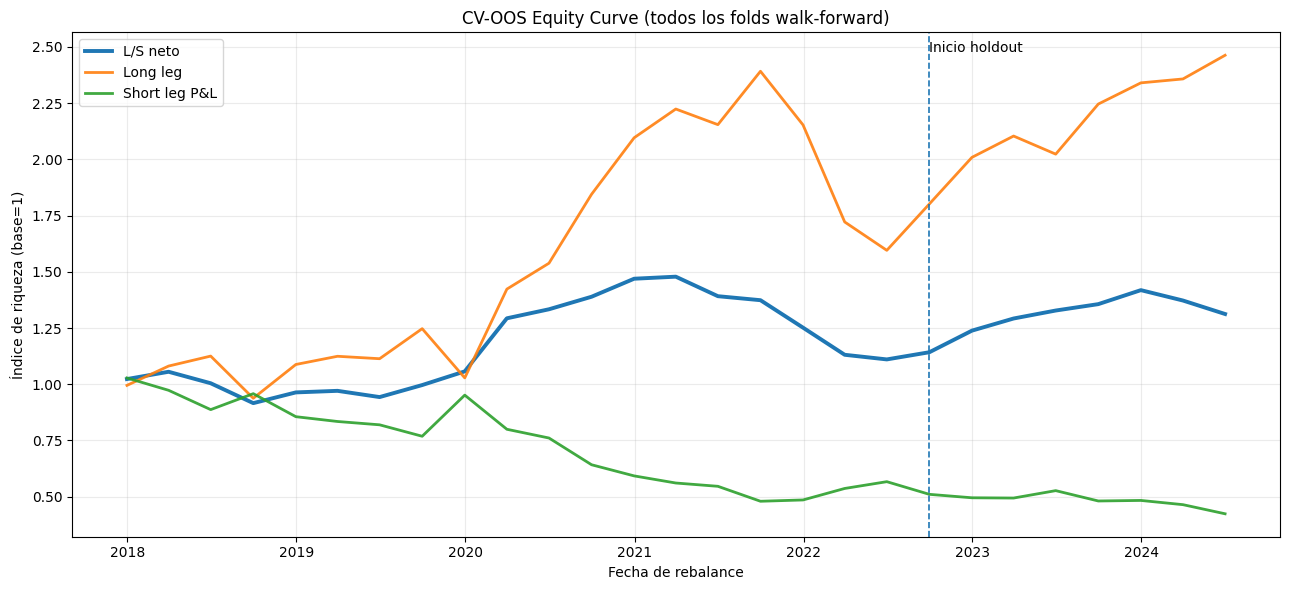


📆 DESEMPEÑO POR SUBPERÍODOS (año calendario)


,Año,N períodos,L/S total,L/S anual,Long total,Long anual,Short total,Short anual
0,2017,1,0.0231,0.0958,-0.0050,-0.0199,0.0281,0.1173
1,2018,4,-0.0580,-0.0580,0.0934,0.0934,-0.1676,-0.1676
2,2019,4,0.0970,0.0970,-0.0548,-0.0548,0.1120,0.1120
3,2020,4,0.3897,0.3897,1.0385,1.0385,-0.3774,-0.3774
4,2021,4,-0.1481,-0.1481,0.0272,0.0272,-0.1806,-0.1806
5,2022,4,-0.0106,-0.0106,-0.0669,-0.0669,0.0199,0.0199
6,2023,4,0.1454,0.1454,0.1649,0.1649,-0.0239,-0.0239
7,2024,2,-0.0749,-0.1441,0.0524,0.1076,-0.1229,-0.2308


In [134]:
# ==============================================================================
# BLOQUE 19.3d – Curva de equity CV-OOS + evolución por subperíodos
# ------------------------------------------------------------------------------
#   - Grafica 3 curvas: L/S neto, pata Long y pata Short (P&L = -Bottom)
#   - Marca visualmente el inicio del holdout final
#   - Resume desempeño por subperíodos (año calendario)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "CV_LS_NET_SER" not in globals():
    raise RuntimeError("Falta CV_LS_NET_SER. Ejecuta primero el BLOQUE 19.3c.")

cv_ls = pd.Series(CV_LS_NET_SER).dropna().copy()
cv_long = pd.Series(CV_LONG_SER).reindex(cv_ls.index).dropna()
cv_short = pd.Series(CV_SHORT_SER).reindex(cv_ls.index).dropna()

# Alinear intersección
_idx = cv_ls.index.intersection(cv_long.index).intersection(cv_short.index)
cv_ls = cv_ls.reindex(_idx)
cv_long = cv_long.reindex(_idx)
cv_short = cv_short.reindex(_idx)

eq_ls = (1.0 + cv_ls).cumprod()
eq_long = (1.0 + cv_long).cumprod()
eq_short = (1.0 + cv_short).cumprod()

x = _idx.to_timestamp("M")

plt.figure(figsize=(13, 6))
plt.plot(x, eq_ls.values, label="L/S neto", linewidth=2.8)
plt.plot(x, eq_long.values, label="Long leg", linewidth=2.0, alpha=0.90)
plt.plot(x, eq_short.values, label="Short leg P&L", linewidth=2.0, alpha=0.90)

# Marca inicio del holdout si existe
try:
    _hstart = pd.to_datetime(globals().get("REB_DATES", pd.DatetimeIndex([]))).min()
    if pd.notna(_hstart):
        plt.axvline(_hstart, linestyle="--", linewidth=1.2)
        ymax = np.nanmax([eq_ls.max(), eq_long.max(), eq_short.max()])
        plt.text(_hstart, ymax, "Inicio holdout", va="bottom", ha="left")
except Exception:
    pass

plt.title("CV-OOS Equity Curve (todos los folds walk-forward)")
plt.xlabel("Fecha de rebalance")
plt.ylabel("Índice de riqueza (base=1)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -------------------- Subperíodos (año calendario) --------------------
def _subperiod_stats(r: pd.Series, step_m: int):
    r = pd.Series(r).dropna()
    if r.empty:
        return {"N":0, "Total":np.nan, "Anual":np.nan, "Vol":np.nan}
    freq = 12.0 / float(step_m)
    total = (1 + r).prod() - 1
    years = len(r) / freq
    ann = (1 + total)**(1/years) - 1 if years > 0 and total > -1 else np.nan
    vol = r.std(ddof=1) * np.sqrt(freq)
    return {"N":int(len(r)), "Total":float(total), "Anual":float(ann) if np.isfinite(ann) else np.nan, "Vol":float(vol) if np.isfinite(vol) else np.nan}

step_m = int(globals().get("STEP_M", 3))
sub_df = pd.DataFrame({
    "L/S neto": cv_ls,
    "Long leg": cv_long,
    "Short leg P&L": cv_short,
})
sub_df["Year"] = sub_df.index.year

rows = []
for yr, g in sub_df.groupby("Year", sort=True):
    out_ls = _subperiod_stats(g["L/S neto"], step_m)
    out_l  = _subperiod_stats(g["Long leg"], step_m)
    out_s  = _subperiod_stats(g["Short leg P&L"], step_m)
    rows.append({
        "Año": int(yr),
        "N períodos": out_ls["N"],
        "L/S total": out_ls["Total"],
        "L/S anual": out_ls["Anual"],
        "Long total": out_l["Total"],
        "Long anual": out_l["Anual"],
        "Short total": out_s["Total"],
        "Short anual": out_s["Anual"],
    })

df_cv_subperiods = pd.DataFrame(rows).sort_values("Año")
print("\n📆 DESEMPEÑO POR SUBPERÍODOS (año calendario)")
display(df_cv_subperiods.round(4))

globals()["CV_SUBPERIODS"] = df_cv_subperiods


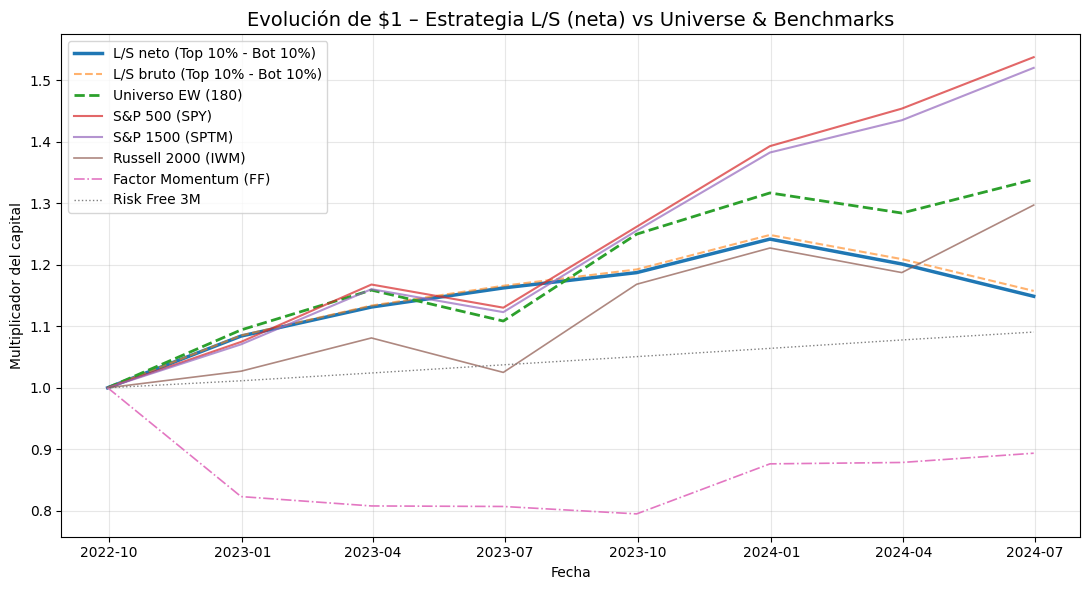

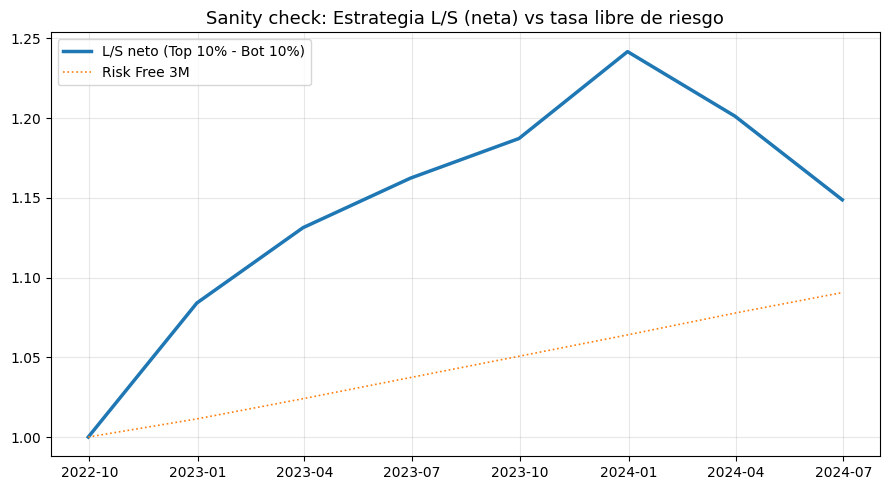

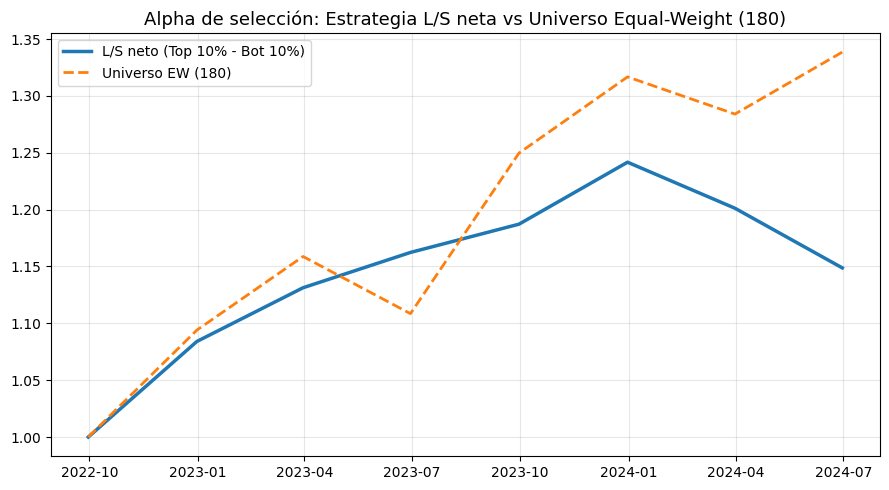


✔ Archivos guardados: 'reporte_equity_final.csv' y 'reporte_metrics_final.csv'.


In [135]:
# ==============================================================================
# BLOQUE 19.4 – Curvas de equity principales
# ==============================================================================

# Equity con $1 inicial para cada serie (solo las principales)
ts_idx = common_idx.to_timestamp("M")
equity = pd.DataFrame(index=ts_idx)

equity[LS_NET_LABEL]   = (1.0 + ls_ret_net.values).cumprod()
equity[LS_GROSS_LABEL]  = (1.0 + ls_ret_gross.values).cumprod()
equity["Universo EW (180)"]        = (1.0 + univ_ret.values).cumprod()
equity["S&P 500 (SPY)"]            = (1.0 + spy_ret.values).cumprod()
equity["S&P 1500 (SPTM)"]          = (1.0 + sptm_ret.values).cumprod()
equity["Russell 2000 (IWM)"]       = (1.0 + iwm_ret.values).cumprod()
equity["Factor Momentum (FF)"]     = (1.0 + mom_ret.values).cumprod()
equity["Risk Free 3M"]             = (1.0 + rf_ret.values).cumprod()

# Normalizar a 1 en la primera fecha
equity = equity.div(equity.iloc[0])

plt.figure(figsize=(11, 6))
plt.plot(equity.index, equity[LS_NET_LABEL],  label=LS_NET_LABEL, linewidth=2.5)
plt.plot(equity.index, equity[LS_GROSS_LABEL], label=LS_GROSS_LABEL, linewidth=1.5, linestyle="--", alpha=0.6)
plt.plot(equity.index, equity["Universo EW (180)"],        label="Universo EW (180)", linewidth=2.0, linestyle="--")
plt.plot(equity.index, equity["S&P 500 (SPY)"],            label="S&P 500 (SPY)", linewidth=1.5, alpha=0.7)
plt.plot(equity.index, equity["S&P 1500 (SPTM)"],          label="S&P 1500 (SPTM)", linewidth=1.5, alpha=0.7)
plt.plot(equity.index, equity["Russell 2000 (IWM)"],       label="Russell 2000 (IWM)", linewidth=1.2, alpha=0.7)
plt.plot(equity.index, equity["Factor Momentum (FF)"],     label="Factor Momentum (FF)", linewidth=1.2, linestyle="-.")
plt.plot(equity.index, equity["Risk Free 3M"],             label="Risk Free 3M", linewidth=1.0, linestyle=":")

plt.title("Evolución de $1 – Estrategia L/S (neta) vs Universe & Benchmarks", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Multiplicador del capital")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 1) Solo Estrategia neta vs Risk Free
plt.figure(figsize=(9, 5))
plt.plot(equity.index, equity[LS_NET_LABEL], label=LS_NET_LABEL, linewidth=2.5)
plt.plot(equity.index, equity["Risk Free 3M"],           label="Risk Free 3M", linewidth=1.2, linestyle=":")
plt.title("Sanity check: Estrategia L/S (neta) vs tasa libre de riesgo", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Estrategia neta vs Universo EW (benchmark "natural")
plt.figure(figsize=(9, 5))
plt.plot(equity.index, equity[LS_NET_LABEL], label=LS_NET_LABEL, linewidth=2.5)
plt.plot(equity.index, equity["Universo EW (180)"],       label="Universo EW (180)", linewidth=2.0, linestyle="--")
plt.title("Alpha de selección: Estrategia L/S neta vs Universo Equal-Weight (180)", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Guardar resultados en CSV para usar en la tesis / PowerPoint
equity.to_csv("reporte_equity_final.csv")
df_metrics.to_csv("reporte_metrics_final.csv")
print("\n✔ Archivos guardados: 'reporte_equity_final.csv' y 'reporte_metrics_final.csv'.")


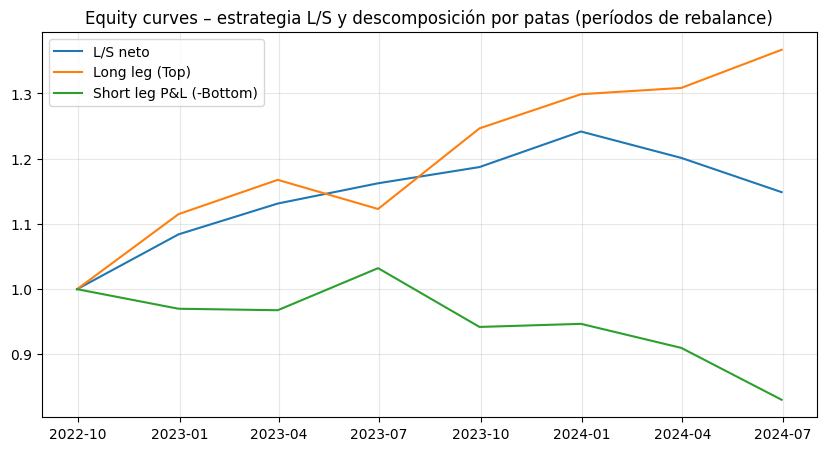

In [136]:
# ==============================================================================
# BLOQUE 19.4b – Curvas de equity (3 líneas): L/S neto vs patas Long y Short
#   Nota: la pata Short se grafica como P&L de short (= -ret_short).
#   Los costos de transacción del notebook se aplican al spread (L/S) como un todo;
#   las curvas de patas se muestran sin costos (gross) para descomposición.
# ==============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

if "LS_NET_SER" not in globals() or "LONG_SER" not in globals() or "SHORT_SER" not in globals():
    # Fallback: reconstruir desde series definidas en 19.3
    df_ls_idx = df_ls.set_index("Mes")
    rebalance_dates = pd.PeriodIndex(df_ls_idx.index).to_timestamp("M")
    LS_NET_SER = pd.Series(df_ls_idx["ret_ls_net"].values, index=rebalance_dates)
    LONG_SER   = pd.Series(df_ls_idx["ret_long"].values,   index=rebalance_dates)
    SHORT_SER  = pd.Series((-df_ls_idx["ret_short"]).values, index=rebalance_dates)

eq = pd.DataFrame(index=LS_NET_SER.index)
eq["L/S neto"] = (1 + LS_NET_SER).cumprod()
eq["Long leg (Top)"] = (1 + LONG_SER).cumprod()
eq["Short leg P&L (-Bottom)"] = (1 + SHORT_SER).cumprod()
eq = eq / eq.iloc[0]

plt.figure(figsize=(10,5))
plt.plot(eq.index, eq["L/S neto"], label="L/S neto")
plt.plot(eq.index, eq["Long leg (Top)"], label="Long leg (Top)")
plt.plot(eq.index, eq["Short leg P&L (-Bottom)"], label="Short leg P&L (-Bottom)")
plt.title("Equity curves – estrategia L/S y descomposición por patas (períodos de rebalance)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [137]:
# --- Frecuencia anualización coherente con tu cadencia de rebalanceo ---
STEP_M = int(globals().get("STEP_M", 3))
FREQ   = int(globals().get("FREQ", max(1, 12 // STEP_M)))

# ==============================================================================
# BLOQUE 19.5 – Deflated Sharpe Ratio (DSR) para la estrategia L/S
# ==============================================================================

from scipy.stats import norm

def deflated_sharpe_ratio(
    r: pd.Series,
    rf: pd.Series,
    freq: int,
    sharpe_candidates: np.ndarray
) -> float:
    """
    Implementación del Deflated Sharpe Ratio (Lopez de Prado, 2014/2018).
    - r: serie de retornos de la estrategia (por período, p.ej. 3M).
    - rf: serie de retornos risk-free en la misma frecuencia.
    - freq: períodos por año (FREQ).
    - sharpe_candidates: array de Sharpe ratios ANUALIZADOS de todas las
      estrategias/benchmarks que probaste (para estimar N y Var(SR)).
    Devuelve: DSR en [0,1] (probabilidad de que el Sharpe observado refleje skill).
    """
    # Alineación básica y exceso de retorno
    r = pd.to_numeric(r, errors="coerce")
    rf = pd.to_numeric(rf, errors="coerce").reindex(r.index).fillna(0.0)

    r_excess = (r - rf).dropna()
    if len(r_excess) < 10 or r_excess.std(ddof=1) == 0:
        return np.nan

    T = len(r_excess)

    # Sharpe NO anualizado (por período)
    sr_hat = r_excess.mean() / r_excess.std(ddof=1)

    # Skewness y kurtosis (pandas.kurt() da exceso → sumo 3)
    g3 = float(r_excess.skew())
    g4 = float(r_excess.kurt() + 3.0)

    # Candidatos: Sharpe anualizados → paso a Sharpe por período
    sharpe_candidates = np.asarray(sharpe_candidates, dtype=float)
    sharpe_candidates = sharpe_candidates[np.isfinite(sharpe_candidates)]

    if sharpe_candidates.size >= 2:
        sr_per = sharpe_candidates / np.sqrt(freq)
        V_sr = float(np.var(sr_per, ddof=1))
        N = int(sharpe_candidates.size)
    else:
        # Fallback MUY conservador si no hay cross-section
        V_sr = 1.0 / max(T, 1)
        N = 1

    # Umbral SR_0 (Sharpe esperado del mejor "no skill" tras N trials)
    gamma_e = 0.5772156649
    sr0 = np.sqrt(V_sr) * (
        (1.0 - gamma_e) * norm.ppf(1.0 - 1.0 / N) +
        gamma_e * norm.ppf(1.0 - 1.0 / (N * np.e))
    )

    # Desvío estándar alrededor del null (Lopez de Prado, PSR/DSR)
    denom = np.sqrt(
        1.0 - g3 * sr0 + 0.25 * (g4 - 1.0) * (sr0 ** 2)
    )
    if not np.isfinite(denom) or denom <= 0:
        return np.nan

    z = (sr_hat - sr0) * np.sqrt(T - 1.0) / denom
    dsr = float(norm.cdf(z))
    return dsr

# --- Aplicar DSR a tu estrategia L/S -----------------------------------------

if LS_NET_LABEL in df_metrics.index:
    # Sharpe de todas las estrategias que ya mediste (L/S, Universe, SPY, etc.)
    sharpe_candidates = df_metrics["Sharpe"].dropna().values

    # -----------------------------
    # FIX: asegurar ls_ret antes del DSR
    # -----------------------------
    if "ls_ret" in globals():
        _ls_ret_for_dsr = ls_ret
        _ls_ret_source = "ls_ret"
    elif "ls_ret_net" in globals():
        _ls_ret_for_dsr = ls_ret_net
        _ls_ret_source = "ls_ret_net"
    elif "df_ls" in globals() and isinstance(df_ls, pd.DataFrame) and "ret_ls_net" in df_ls.columns:
        _ls_ret_for_dsr = df_ls.set_index("Mes")["ret_ls_net"]
        _ls_ret_source = 'df_ls.set_index("Mes")["ret_ls_net"]'
    else:
        raise NameError("No encontré una serie L/S para calcular DSR (ni ls_ret, ni ls_ret_net, ni df_ls['ret_ls_net']).")

    # Dejarla disponible para bloques siguientes (19.6, etc.)
    ls_ret = pd.to_numeric(_ls_ret_for_dsr, errors="coerce").copy()
    globals()["ls_ret"] = ls_ret

    dsr_ls = deflated_sharpe_ratio(
        r = ls_ret,
        rf = rf_ret,
        freq = FREQ,
        sharpe_candidates = sharpe_candidates
    )

    print("\n" + "-"*80)
    print(f"Deflated Sharpe Ratio (DSR) – Estrategia {LS_NET_LABEL}")
    print("-"*80)
    print(f"Fuente de la serie L/S usada en DSR: {_ls_ret_source}")
    print(f"Sharpe anualizado L/S: {df_metrics.loc[LS_NET_LABEL,'Sharpe']:.2f}")

    if pd.isna(dsr_ls):
        print("DSR: NA (muestra OOS demasiado corta o varianza nula)")
    else:
        print(f"DSR (prob. de que NO sea fruto de overfitting puro): {dsr_ls:.3f}")

    print("Interpretación orientativa:")
    print("  · ~0.50 → indistinguible de ruido, dado el número de pruebas.")
    print("  · ≥0.80 → evidencia fuerte de que el Sharpe no surge solo de data-mining.")
    print("  · ≥0.95 → muy sólido incluso tras múltiples estrategias probadas.")
else:
    print("\n[DSR] No se encontró LS_NET_LABEL en df_metrics; se omite el cálculo de DSR.")




--------------------------------------------------------------------------------
Deflated Sharpe Ratio (DSR) – Estrategia L/S neto (Top 10% - Bot 10%)
--------------------------------------------------------------------------------
Fuente de la serie L/S usada en DSR: ls_ret_net
Sharpe anualizado L/S: 0.47
DSR: NA (muestra OOS demasiado corta o varianza nula)
Interpretación orientativa:
  · ~0.50 → indistinguible de ruido, dado el número de pruebas.
  · ≥0.80 → evidencia fuerte de que el Sharpe no surge solo de data-mining.
  · ≥0.95 → muy sólido incluso tras múltiples estrategias probadas.


In [138]:
# =============================================================================
# FIX: Definir series de retornos para segmentación (evita NameError: ls_ret)
# =============================================================================
import pandas as pd
import numpy as np

def _as_series(x):
    if x is None:
        return None
    if isinstance(x, pd.DataFrame):
        if x.shape[1] == 1:
            return x.iloc[:, 0]
    return x

# --- Long-Short returns (mensual) ---
if "ls_ret" not in globals():
    ls_ret = None
    # Preferir la serie ya construida en el reporte (L/S neto)
    if "df_ls" in globals() and isinstance(df_ls, pd.DataFrame) and "ret_ls_net" in df_ls.columns:
        try:
            ls_ret = df_ls.set_index("Mes")["ret_ls_net"]
        except Exception:
            pass
    if "ls_series" in globals():
        ls_ret = _as_series(globals().get("ls_series"))
    elif "spr_m" in globals():
        ls_ret = _as_series(globals().get("spr_m"))
    elif "spread_m" in globals():
        ls_ret = _as_series(globals().get("spread_m"))
    elif "df_perf" in globals() and isinstance(df_perf, pd.DataFrame) and "LS_ret" in df_perf.columns:
        _tmp = df_perf.copy()
        if "Mes" in _tmp.columns:
            _tmp = _tmp.set_index("Mes")
        ls_ret = _tmp["LS_ret"]
    else:
        # Fallback: construir spread top-bottom (10%-10%) desde OOS si existe
        if "oos" in globals() and isinstance(oos, pd.DataFrame) and {"Mes","y_true","y_pred"}.issubset(oos.columns):
            _t = oos.dropna(subset=["Mes","y_true","y_pred"]).copy()
            # ranking por mes (mayor score = mejor por defecto; si el notebook invierte, ya debería estar en y_pred con signo aplicado)
            _t["rank_pct"] = _t.groupby("Mes")["y_pred"].rank(pct=True, method="average")
            _long = _t[_t["rank_pct"] >= 0.9].groupby("Mes")["y_true"].mean()
            _short = _t[_t["rank_pct"] <= 0.1].groupby("Mes")["y_true"].mean()
            ls_ret = (_long - _short).sort_index()
        else:
            ls_ret = pd.Series(dtype=float)

    ls_ret = _as_series(ls_ret)
    if ls_ret is None:
        ls_ret = pd.Series(dtype=float)

# --- Universe / benchmark returns ---
if "univ_ret" not in globals():
    univ_ret = None
    if "df_perf" in globals() and isinstance(df_perf, pd.DataFrame) and "UNIV_ret" in df_perf.columns:
        _tmp = df_perf.copy()
        if "Mes" in _tmp.columns:
            _tmp = _tmp.set_index("Mes")
        univ_ret = _tmp["UNIV_ret"]
    elif "universe_ret" in globals():
        univ_ret = globals().get("universe_ret")
    elif "oos" in globals() and isinstance(oos, pd.DataFrame) and {"Mes","y_true"}.issubset(oos.columns):
        univ_ret = oos.dropna(subset=["Mes","y_true"]).groupby("Mes")["y_true"].mean().sort_index()
    else:
        univ_ret = pd.Series(dtype=float)
    univ_ret = _as_series(univ_ret) or pd.Series(dtype=float)

if "spy_ret" not in globals():
    spy_ret = None
    if "bench_rets" in globals() and isinstance(bench_rets, pd.DataFrame) and "SPY" in bench_rets.columns:
        spy_ret = bench_rets["SPY"]
    elif "spy_px" in globals():
        spy_ret = _as_series(globals().get("spy_px")).pct_change()
    elif "px" in globals():
        _px = globals().get("px")
        if isinstance(_px, pd.DataFrame):
            if "SPY" in _px.columns:
                spy_ret = _px["SPY"].pct_change()
            elif "PX" in _px.columns:
                spy_ret = _px["PX"].pct_change()
    if spy_ret is None:
        spy_ret = pd.Series(dtype=float)
    spy_ret = _as_series(spy_ret) or pd.Series(dtype=float)

# --- Alinear al índice común si existe ---
if "common_idx" in globals():
    try:
        ls_ret = _as_series(ls_ret).reindex(common_idx)
        univ_ret = _as_series(univ_ret).reindex(common_idx)
        spy_ret = _as_series(spy_ret).reindex(common_idx)
    except Exception:
        pass

print(f"[Fix] Series listas: ls_ret n={ls_ret.dropna().shape[0]}, univ_ret n={univ_ret.dropna().shape[0]}, spy_ret n={spy_ret.dropna().shape[0]}")

[Fix] Series listas: ls_ret n=8, univ_ret n=8, spy_ret n=8


In [139]:
# ==============================================================================
# BLOQUE 19.6 – Estabilidad por subperíodos (regímenes OOS)
# ==============================================================================

# Usamos el mismo índice temporal común ya construido
idx_all = common_idx.sort_values()
n_obs = len(idx_all)

if n_obs < 8:
    n_splits = 2
else:
    n_splits = 3  # típicamente 3 subperíodos es una buena narrativa

segments = np.array_split(idx_all, n_splits)

rows = []
for j, seg_idx in enumerate(segments, start=1):
    if len(seg_idx) == 0:
        continue

    seg_name = f"Subperíodo {j}"
    seg_start = seg_idx[0].to_timestamp("M").date()
    seg_end   = seg_idx[-1].to_timestamp("M").date()

    mask = common_idx.isin(seg_idx)

    r_ls_seg   = ls_ret[mask]
    r_univ_seg = univ_ret[mask]
    r_spy_seg  = spy_ret[mask] if "SPY" in df_metrics.index else pd.Series(index=seg_idx, dtype=float)
    r_rf_seg   = rf_ret[mask]

    m_ls   = compute_metrics_series("L/S", r_ls_seg,   r_rf_seg, FREQ)
    m_univ = compute_metrics_series("Universo", r_univ_seg, r_rf_seg, FREQ)
    m_spy  = compute_metrics_series("SPY", r_spy_seg,  r_rf_seg, FREQ) if not r_spy_seg.isna().all() else None

    row = {
        "Subperíodo": seg_name,
        "Inicio": seg_start,
        "Fin": seg_end,
        "Sharpe L/S":   m_ls["Sharpe"],
        "Ret anual L/S": m_ls["Retorno anual"],
        "Sharpe Univ":   m_univ["Sharpe"],
        "Ret anual Univ": m_univ["Retorno anual"],
    }
    if m_spy is not None:
        row["Sharpe SPY"] = m_spy["Sharpe"]
        row["Ret anual SPY"] = m_spy["Retorno anual"]

    rows.append(row)

df_subperiods = (
    pd.DataFrame(rows)
      .set_index("Subperíodo")
)

print("\n📈 ESTABILIDAD POR SUBPERÍODOS (L/S vs Universe vs SPY):")
try:
    display(
        df_subperiods.style
        .format({
            "Ret anual L/S": "{:+.2%}",
            "Ret anual Univ": "{:+.2%}",
            "Ret anual SPY": "{:+.2%}",
            "Sharpe L/S": "{:.2f}",
            "Sharpe Univ": "{:.2f}",
            "Sharpe SPY": "{:.2f}",
        }, na_rep="—")
    )
except Exception:
    print(df_subperiods)



📈 ESTABILIDAD POR SUBPERÍODOS (L/S vs Universe vs SPY):


,Inicio,Fin,Sharpe L/S,Ret anual L/S,Sharpe Univ,Ret anual Univ
Subperíodo,,,,,,
Subperíodo 1,2022-09-30,2023-03-31,2.95,+22.60%,5.08,+41.44%
Subperíodo 2,2023-06-30,2023-12-31,2.92,+13.22%,0.77,+18.58%
Subperíodo 3,2024-03-31,2024-06-30,-14.00,-14.41%,-0.15,+3.34%


In [140]:
# ==============================================================================
# BLOQUE 19.7 – Resumen automático para la tesis (texto coherente con métricas)
#   - NO "endulza" resultados: describe exactamente lo observado.
#   - Incluye comparación vs benchmarks si están disponibles.
# ==============================================================================

def _fmt_pct(x):
    return "NA" if (x is None or (isinstance(x, float) and not np.isfinite(x))) else f"{x:+.1%}"

def _fmt_num(x):
    return "NA" if (x is None or (isinstance(x, float) and not np.isfinite(x))) else f"{x:.2f}"

if "df_metrics" not in globals() or df_metrics is None or df_metrics.empty:
    print("⚠️ Falta df_metrics. Ejecuta el reporte final (BLOQUE 19.3/19.6) antes de este resumen.")
else:
    # Intentar tomar métricas clave
    key_ls = LS_NET_LABEL
    key_unv = "Universo EW (180)"
    key_spy = "S&P 500 (SPY)"

    def _get_row(k):
        return df_metrics.loc[k] if k in df_metrics.index else None

    m_ls = _get_row(key_ls)
    m_unv = _get_row(key_unv)
    m_spy = _get_row(key_spy)

    # Fechas (si existen)
    try:
        start_sig = equity.index.min().date()
        end_sig   = equity.index.max().date()
    except Exception:
        start_sig = None
        end_sig = None

    # Señal de inversión: Top vs Bottom
    top_key = LONG_ONLY_LABEL
    bot_key = BOTTOM_LONGONLY_LABEL
    m_top = _get_row(top_key)
    m_bot = _get_row(bot_key)

    # Construir texto
    print("\n" + "="*80)
    print("RESUMEN AUTOMÁTICO PARA TESIS (coherente con métricas)")
    print("="*80)

    if m_ls is None:
        print("⚠️ No encuentro la fila de L/S neto en df_metrics.")
    else:
        ls_ret = m_ls.get("Retorno anual", np.nan)
        ls_vol = m_ls.get("Vol anual", np.nan)
        ls_sh  = m_ls.get("Sharpe", np.nan)

        # Comparaciones
        unv_ret = m_unv.get("Retorno anual", np.nan) if m_unv is not None else np.nan
        unv_sh  = m_unv.get("Sharpe", np.nan) if m_unv is not None else np.nan
        spy_ret = m_spy.get("Retorno anual", np.nan) if m_spy is not None else np.nan
        spy_sh  = m_spy.get("Sharpe", np.nan) if m_spy is not None else np.nan

        # Señal top/bot
        top_ret = m_top.get("Retorno anual", np.nan) if m_top is not None else np.nan
        bot_ret = m_bot.get("Retorno anual", np.nan) if m_bot is not None else np.nan
        inverted = np.isfinite(top_ret) and np.isfinite(bot_ret) and (bot_ret > top_ret)

        # Diagnóstico
        perf_word = "positiva" if (np.isfinite(ls_sh) and ls_sh > 0) else "negativa"
        bench_note = ""
        if np.isfinite(unv_sh) and np.isfinite(ls_sh):
            bench_note = "La estrategia L/S supera al benchmark del universo en Sharpe." if (ls_sh > unv_sh) else "La estrategia L/S no supera al benchmark del universo en Sharpe."
        if np.isfinite(spy_sh) and np.isfinite(ls_sh):
            bench_note += (" " if bench_note else "") + ("Tampoco supera a SPY." if (ls_sh < spy_sh) else "Supera a SPY.")

        # Texto principal
        print(f"""
Período evaluado (out-of-sample): {start_sig} – {end_sig} (fechas de rebalance).
Métrica L/S neta (Top–Bottom 10%): retorno anualizado {_fmt_pct(ls_ret)}, volatilidad anualizada {_fmt_pct(ls_vol)}, Sharpe {_fmt_num(ls_sh)}.
Conclusión: la performance ajustada por riesgo es {perf_word} en este holdout.
{bench_note}
""".strip())

        if inverted:
            print("\nObservación clave: el decil 'Bottom' rindió más que el 'Top' en promedio (señal de posible inversión de ranking/signo).")
            print("Acción recomendada: recalcular BEST_SIGN en DISEÑO (Etapa 2) maximizando Sharpe_net y/o auditar el sentido del score_final.")

        # Benchmarks (si existen)
        if m_unv is not None:
            print(f"\nBenchmark universo EW: retorno anual {_fmt_pct(unv_ret)}, Sharpe {_fmt_num(unv_sh)}.")
        if m_spy is not None:
            print(f"Benchmark SPY: retorno anual {_fmt_pct(spy_ret)}, Sharpe {_fmt_num(spy_sh)}.")

        # Nota metodológica breve
        print("\nNota metodológica: el retorno por período se mide punta-a-punta a 3 meses (t → t+3) con rebalance trimestral; el retorno anual es geométrico anualizado.")



RESUMEN AUTOMÁTICO PARA TESIS (coherente con métricas)
Período evaluado (out-of-sample): 2022-09-30 – 2024-06-30 (fechas de rebalance).
Métrica L/S neta (Top–Bottom 10%): retorno anualizado +8.8%, volatilidad anualizada +8.4%, Sharpe 0.47.
Conclusión: la performance ajustada por riesgo es positiva en este holdout.
La estrategia L/S no supera al benchmark del universo en Sharpe. Tampoco supera a SPY.

Benchmark universo EW: retorno anual +22.4%, Sharpe 1.32.
Benchmark SPY: retorno anual +28.6%, Sharpe 2.32.

Nota metodológica: el retorno por período se mide punta-a-punta a 3 meses (t → t+3) con rebalance trimestral; el retorno anual es geométrico anualizado.



🏆 REPORTE FINAL: Estrategia vs Múltiples Benchmarks (Contexto Total)
   -> Descargando: ['SPY', 'RSP', 'SPTM', 'IWM', '^IRX'] ...

📊 TABLA DE RENDIMIENTOS FINAL:


,Retorno Total,Volatilidad,Sharpe
Estrategia,,,
S&P 500 (Large Cap),64.71%,9.22%,2.29
S&P 1500 (All Cap),63.08%,9.23%,2.23
Russell 2000 (Small),37.41%,12.42%,0.96
Risk Free,10.18%,0.19%,0.00
Mi Estrategia (L/S),4.07%,4.24%,-0.66


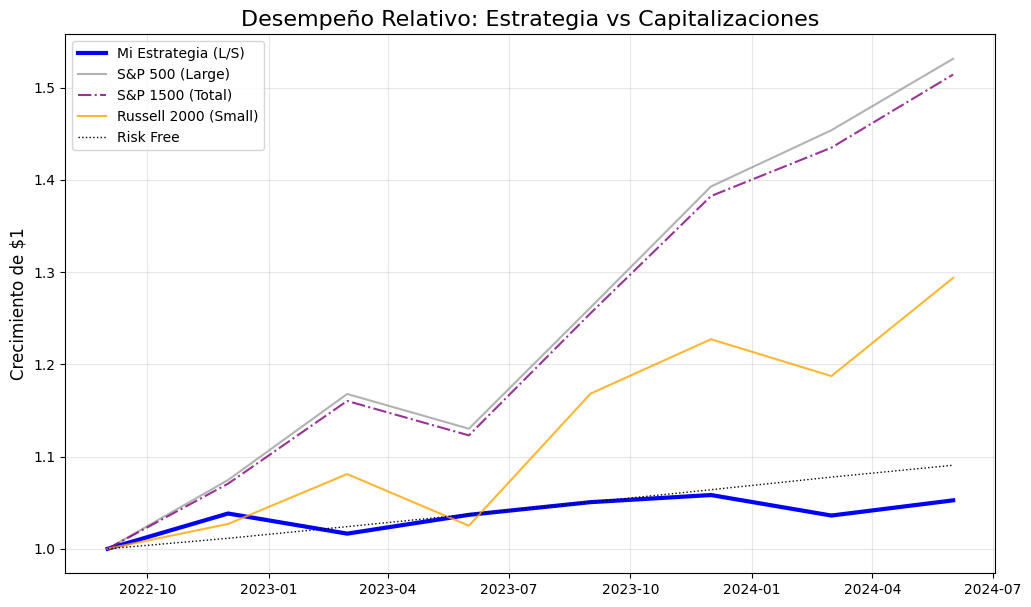

In [141]:
# ==============================================================================
# BLOQUE 20 (MULTI-BENCHMARK) – Contexto Completo de Mercado
# ==============================================================================


print("\n" + "="*80)
print("🏆 REPORTE FINAL: Estrategia vs Múltiples Benchmarks (Contexto Total)")
print("="*80)

# Configuración
# Convención final: score_final ya está firmado; mayor = mejor
ASCENDING_LOGIC = False

if globals().get('OFFLINE', False):
    print("⚠️ OFFLINE.")
else:
    try:
        import yfinance as yf
    except ImportError:
        os.system('pip install -q --upgrade --no-cache-dir yfinance')
        import yfinance as yf

    if yf is not None and 'oos' in globals() and not oos.empty:
        try:
            df_perf = oos.copy()
            if 'Mes' not in df_perf.columns:
                df_perf['Fecha'] = pd.to_datetime(df_perf['Fecha'])
                df_perf['Mes'] = df_perf['Fecha'].dt.to_period('M')
            if not pd.api.types.is_period_dtype(df_perf['Mes']):
                 df_perf['Mes'] = pd.to_datetime(df_perf['Mes']).dt.to_period('M')

            # Construcción Cartera
            df_perf['rank'] = df_perf.groupby('Mes')[('score_final' if 'score_final' in df_perf.columns else 'y_pred')].rank(ascending=False, method='first')
            df_perf['rank_rev'] = df_perf.groupby('Mes')[('score_final' if 'score_final' in df_perf.columns else 'y_pred')].rank(ascending=True, method='first')
            top_n = 20
            ret_long = df_perf[df_perf['rank'] <= top_n].groupby('Mes')['y_true'].mean()
            ret_short = df_perf[df_perf['rank_rev'] <= top_n].groupby('Mes')['y_true'].mean() * -1
            my_strategy_ret = ret_long + ret_short

            # Descarga Benchmarks AMPLIADA
            start_date = my_strategy_ret.index.to_timestamp().min() - pd.Timedelta(days=120)
            end_date = my_strategy_ret.index.to_timestamp().max() + pd.Timedelta(days=120)

            # AGREGAMOS: SPTM (S&P 1500) y IWM (Russell 2000 - Small Caps)
            tickers = ['SPY', 'RSP', 'SPTM', 'IWM', '^IRX']
            print(f"   -> Descargando: {tickers} ...")

            raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=False)

            if 'Adj Close' in raw_data.columns.get_level_values(0):
                bench_data = raw_data['Adj Close']
            else:
                bench_data = raw_data['Close'] # Fallback

            bench_data = bench_data.ffill().dropna()

            # Retornos 3M Forward
            monthly_prices = bench_data[tickers[:-1]].resample('M').last() # Todos menos IRX
            bench_3m = monthly_prices.pct_change(3).shift(-3)
            bench_3m.index = bench_3m.index.to_period('M')

            # Risk Free
            if '^IRX' in bench_data.columns:
                rf_monthly = (1 + (bench_data['^IRX'].resample('M').last() / 100.0)) ** (1/12) - 1
                rf_3m = (1 + rf_monthly).rolling(3).apply(np.prod, raw=True) - 1
                rf_3m = rf_3m.shift(-3)
                rf_3m.index = rf_3m.index.to_period('M')
            else:
                rf_3m = pd.Series(0.0, index=bench_3m.index)

            # Alineación
            common_idx = my_strategy_ret.index.intersection(bench_3m.index)

            if len(common_idx) < 4:
                print("⚠️ Muy pocas fechas.")
            else:
                my_ret_aligned = my_strategy_ret.loc[common_idx]
                long_ret_aligned = ret_long.loc[common_idx]

                # Benchmarks alineados
                spy_ret = bench_3m.loc[common_idx, 'SPY']
                rsp_ret = bench_3m.loc[common_idx, 'RSP']
                sptm_ret = bench_3m.loc[common_idx, 'SPTM'] # S&P 1500
                iwm_ret = bench_3m.loc[common_idx, 'IWM']   # Russell 2000
                rf_ret = rf_3m.reindex(common_idx).fillna(0.0)

                # Equity
                plot_index = common_idx.to_timestamp()
                equity = pd.DataFrame(index=plot_index)
                equity['Mi Estrategia (L/S)'] = (1 + my_ret_aligned.values).cumprod()
                equity['S&P 500 (SPY)']       = (1 + spy_ret.values).cumprod()
                equity['S&P 1500 (SPTM)']     = (1 + sptm_ret.values).cumprod() # Nuevo
                equity['Small Caps (IWM)']    = (1 + iwm_ret.values).cumprod()  # Nuevo
                equity['Risk Free']           = (1 + rf_ret.values).cumprod()
                equity = equity / equity.iloc[0]

                # Métricas
                FREQ = 4
                metrics = []
                # Diccionario ampliado
                ret_series_dict = {
                    'Mi Estrategia (L/S)': my_ret_aligned,
                    'S&P 500 (Large Cap)': spy_ret,
                    'S&P 1500 (All Cap)': sptm_ret,
                    'Russell 2000 (Small)': iwm_ret,
                    'Risk Free': rf_ret
                }

                for name, r_series in ret_series_dict.items():
                    total_ret = (1 + r_series).prod() - 1
                    vol_ann = r_series.std() * np.sqrt(FREQ)
                    if name == 'Risk Free': sharpe = 0.0
                    else:
                        excess = r_series - rf_ret
                        sharpe = (excess.mean() / excess.std()) * np.sqrt(FREQ) if excess.std() > 0 else 0

                    metrics.append({'Estrategia': name, 'Retorno Total': total_ret, 'Volatilidad': vol_ann, 'Sharpe': sharpe})

                df_metrics = pd.DataFrame(metrics).set_index('Estrategia').sort_values('Sharpe', ascending=False)

                print("\n📊 TABLA DE RENDIMIENTOS FINAL:")
                try:
                    display(df_metrics.style.format("{:.2%}", subset=['Retorno Total', 'Volatilidad']).format("{:.2f}", subset=['Sharpe']).background_gradient(cmap='RdYlGn'))
                except:
                    print(df_metrics)

                plt.figure(figsize=(12, 7))
                plt.plot(equity.index, equity['Mi Estrategia (L/S)'], label='Mi Estrategia (L/S)', linewidth=3, color='blue')
                plt.plot(equity.index, equity['S&P 500 (SPY)'], label='S&P 500 (Large)', linewidth=1.5, color='gray', alpha=0.6)
                plt.plot(equity.index, equity['S&P 1500 (SPTM)'], label='S&P 1500 (Total)', linewidth=1.5, color='purple', alpha=0.8, linestyle='-.')
                plt.plot(equity.index, equity['Small Caps (IWM)'], label='Russell 2000 (Small)', linewidth=1.5, color='orange', alpha=0.8)
                plt.plot(equity.index, equity['Risk Free'], label='Risk Free', linewidth=1, color='black', linestyle=':')

                plt.title('Desempeño Relativo: Estrategia vs Capitalizaciones', fontsize=16)
                plt.ylabel('Crecimiento de $1', fontsize=12)
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.show()

        except Exception as e:
            print(f"❌ Error: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("⚠️ No se encontró el DataFrame 'oos'.")



🏆 REPORTE FINAL: Estrategia vs Universo (Usando Retornos Brutos)
   ✅ Retornos brutos (y_raw) alineados por row_id.
   -> Descargando benchmarks externos (2022-05-04 a 2024-09-29)...

📊 TABLA DE RENDIMIENTOS FINAL:


,Retorno Total,Volatilidad,Sharpe
Estrategia,,,
S&P 500 (SPY),64.71%,9.22%,2.29
Universo (Promedio Simple),49.82%,12.44%,1.32
Mi Estrategia (L/S),18.85%,10.10%,0.43
Risk Free,10.18%,0.19%,0.00


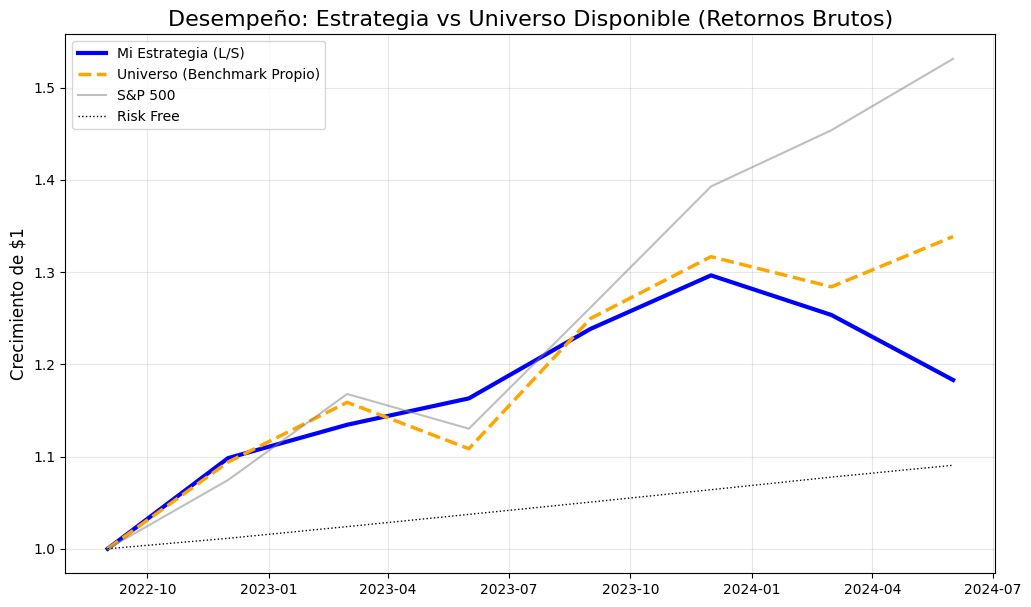


✔ Reporte guardado exitosamente.


In [142]:
# ==============================================================================
# BLOQUE 19 (FINAL FIX - RAW RETURNS) – Benchmark Propio Correcto
# ==============================================================================

print("\n" + "="*80)
print("🏆 REPORTE FINAL: Estrategia vs Universo (Usando Retornos Brutos)")
print("="*80)

# -------------------------------------------------------------------
# 1. Configuración
# ---------------------------------------------------------------------------
ASCENDING_LOGIC = False  # Convención final: mayor score_final = mejor

if globals().get('OFFLINE', False):
    print("⚠️ OFFLINE = True. Se omite la descarga de benchmarks externos.")
else:
    try:
        import yfinance as yf
    except ImportError:
        os.system('pip install -q --upgrade --no-cache-dir yfinance')
        import yfinance as yf

    if 'oos' in globals() and not oos.empty:
        try:
            df_perf = oos.copy()

            # Asegurar fechas y Periodo
            if 'Mes' not in df_perf.columns:
                df_perf['Fecha'] = pd.to_datetime(df_perf['Fecha'])
                df_perf['Mes'] = df_perf['Fecha'].dt.to_period('M')

            if not pd.api.types.is_period_dtype(df_perf['Mes']):
                 df_perf['Mes'] = pd.to_datetime(df_perf['Mes']).dt.to_period('M')

            # -------------------------------------------------------------------
            # 1.5 INYECCIÓN DE RETORNOS BRUTOS (CRÍTICO PARA BENCHMARK)
            # -------------------------------------------------------------------
            # Intentamos recuperar y_raw global para tener el retorno real del mercado,
            # no el residual (que suma cero).
                        # no el residual (que suma cero).
            if 'y_raw' in globals():
                try:
                    y_raw_ser = pd.Series(globals()['y_raw'])
                    if 'row_id' in df_perf.columns:
                        raw_aligned = y_raw_ser.reindex(df_perf['row_id'].values)
                        if raw_aligned.isna().any():
                            print("   ⚠️ Algunos row_id no se encontraron en y_raw. Se completan con y_true (Residual).")
                            df_perf['ret_real_raw'] = raw_aligned.fillna(df_perf['y_true']).values
                        else:
                            df_perf['ret_real_raw'] = raw_aligned.values
                        print("   ✅ Retornos brutos (y_raw) alineados por row_id.")
                    elif 'test_mask' in globals():
                        # Fallback heredado (por posición). Evitar si es posible.
                        raw_values = y_raw_ser.loc[globals()['test_mask']].values
                        if len(raw_values) == len(df_perf):
                            df_perf['ret_real_raw'] = raw_values
                            print("   ⚠️ Retornos brutos (y_raw) inyectados por posición (sin row_id).")
                        else:
                            print("   ⚠️ Longitud de y_raw no coincide. Usando y_true (Residual).")
                            df_perf['ret_real_raw'] = df_perf['y_true']
                    else:
                        print("   ⚠️ No hay row_id ni test_mask. Usando y_true (Residual).")
                        df_perf['ret_real_raw'] = df_perf['y_true']
                except Exception as e:
                    print(f"   ⚠️ Error alineando y_raw: {e}. Usando y_true (Residual).")
                    df_perf['ret_real_raw'] = df_perf['y_true']
            elif 'y_true_raw' in df_perf.columns:
                 df_perf['ret_real_raw'] = df_perf['y_true_raw']
            else:
                print("   ⚠️ No se encontró y_raw. El benchmark del universo será plano (0%).")
                df_perf['ret_real_raw'] = df_perf['y_true']

            # -------------------------------------------------------------------
            # 2. Construcción de la Cartera
            # -------------------------------------------------------------------

            score_col_final = "score_final" if "score_final" in df_perf.columns else "y_pred"

            df_perf["rank"] = df_perf.groupby("Mes")[score_col_final].rank(
                ascending=False, method="first"
            )
            df_perf["rank_rev"] = df_perf.groupby("Mes")[score_col_final].rank(
                ascending=True, method="first"
            )

            top_n = 20

            # Retornos Estrategia (Usamos RAW para ver ganancia real en dinero)
            # NOTA: Para L/S, el retorno residual y bruto suelen ser similares en el spread,
            # pero para Long Only y Benchmark, necesitamos el bruto.
            ret_long = df_perf[df_perf['rank'] <= top_n].groupby('Mes')['ret_real_raw'].mean()
            ret_short = df_perf[df_perf['rank_rev'] <= top_n].groupby('Mes')['ret_real_raw'].mean() * -1
            my_strategy_ret = ret_long + ret_short

            # --- BENCHMARK DEL UNIVERSO (EQUAL WEIGHT) ---
            # Promedio simple de los retornos BRUTOS de todas las acciones
            universe_ew_ret = df_perf.groupby('Mes')['ret_real_raw'].mean()

            # -------------------------------------------------------------------
            # 3. Descarga de Benchmarks Externos
            # -------------------------------------------------------------------
            start_date = my_strategy_ret.index.to_timestamp().min() - pd.Timedelta(days=120)
            end_date = my_strategy_ret.index.to_timestamp().max() + pd.Timedelta(days=120)

            tickers = ['SPY', '^IRX']
            print(f"   -> Descargando benchmarks externos ({start_date.date()} a {end_date.date()})...")

            if yf:
                raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=False)

                if 'Adj Close' in raw_data.columns.get_level_values(0):
                    bench_data = raw_data['Adj Close']
                else:
                    bench_data = raw_data['Close']

                bench_data = bench_data.ffill().dropna()

                # Retornos 3M Forward
                monthly_prices = bench_data[['SPY']].resample('M').last()
                bench_3m = monthly_prices.pct_change(3).shift(-3)
                bench_3m.index = bench_3m.index.to_period('M')

                # Risk Free
                if '^IRX' in bench_data.columns:
                    rf_monthly = (1 + (bench_data['^IRX'].resample('M').last() / 100.0)) ** (1/12) - 1
                    rf_3m = (1 + rf_monthly).rolling(3).apply(np.prod, raw=True) - 1
                    rf_3m = rf_3m.shift(-3)
                    rf_3m.index = rf_3m.index.to_period('M')
                else:
                    rf_3m = pd.Series(0.0, index=bench_3m.index)
            else:
                bench_3m = pd.DataFrame()
                rf_3m = pd.Series(0.0, index=my_strategy_ret.index)

            # -------------------------------------------------------------------
            # 4. Alineación y Métricas
            # -------------------------------------------------------------------
            common_idx = my_strategy_ret.index
            if not bench_3m.empty:
                common_idx = common_idx.intersection(bench_3m.index)

            if len(common_idx) < 4:
                print("⚠️ Muy pocas fechas coincidentes.")
            else:
                # Filtrar
                my_ret_aligned = my_strategy_ret.loc[common_idx]
                univ_ret_aligned = universe_ew_ret.loc[common_idx]

                if not bench_3m.empty:
                    spy_ret = bench_3m.loc[common_idx, 'SPY']
                    rf_ret = rf_3m.reindex(common_idx).fillna(0.0)
                else:
                    spy_ret = pd.Series(0, index=common_idx)
                    rf_ret = pd.Series(0, index=common_idx)

                # Equity Curve
                plot_index = common_idx.to_timestamp()
                equity = pd.DataFrame(index=plot_index)
                equity['Mi Estrategia (L/S)'] = (1 + my_ret_aligned.values).cumprod()
                equity['Universo (Promedio Simple)'] = (1 + univ_ret_aligned.values).cumprod()
                equity['S&P 500 (SPY)']       = (1 + spy_ret.values).cumprod()
                equity['Risk Free']           = (1 + rf_ret.values).cumprod()

                equity = equity / equity.iloc[0]

                # Métricas
                FREQ = 4
                metrics = []
                ret_series_dict = {
                    'Mi Estrategia (L/S)': my_ret_aligned,
                    'Universo (Promedio Simple)': univ_ret_aligned,
                    'S&P 500 (SPY)': spy_ret,
                    'Risk Free': rf_ret
                }

                for name, r_series in ret_series_dict.items():
                    total_ret = (1 + r_series).prod() - 1
                    vol_ann = r_series.std() * np.sqrt(FREQ)
                    if name == 'Risk Free': sharpe = 0.0
                    else:
                        excess = r_series - rf_ret
                        sharpe = (excess.mean() / excess.std()) * np.sqrt(FREQ) if excess.std() > 0 else 0

                    metrics.append({'Estrategia': name, 'Retorno Total': total_ret, 'Volatilidad': vol_ann, 'Sharpe': sharpe})

                df_metrics = pd.DataFrame(metrics).set_index('Estrategia').sort_values('Sharpe', ascending=False)

                # ---------------------------------------------------------------
                # 5. Visualización
                # ---------------------------------------------------------------
                print("\n📊 TABLA DE RENDIMIENTOS FINAL:")
                try:
                    display(df_metrics.style.format("{:.2%}", subset=['Retorno Total', 'Volatilidad']).format("{:.2f}", subset=['Sharpe']).background_gradient(cmap='RdYlGn'))
                except:
                    print(df_metrics)

                plt.figure(figsize=(12, 7))
                plt.plot(equity.index, equity['Mi Estrategia (L/S)'], label='Mi Estrategia (L/S)', linewidth=3, color='blue')
                plt.plot(equity.index, equity['Universo (Promedio Simple)'], label='Universo (Benchmark Propio)', linewidth=2.5, color='orange', linestyle='--')
                plt.plot(equity.index, equity['S&P 500 (SPY)'], label='S&P 500', linewidth=1.5, color='gray', alpha=0.5)
                plt.plot(equity.index, equity['Risk Free'], label='Risk Free', linewidth=1, color='black', linestyle=':')

                plt.title('Desempeño: Estrategia vs Universo Disponible (Retornos Brutos)', fontsize=16)
                plt.ylabel('Crecimiento de $1', fontsize=12)
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.show()

                # Guardar
                df_metrics.to_csv("reporte_final_metrics_univ.csv")
                equity.to_csv("reporte_final_equity_univ.csv")
                print("\n✔ Reporte guardado exitosamente.")

        except Exception as e:
            print(f"❌ Error: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("⚠️ No se encontró el DataFrame 'oos'.")

In [143]:
print("BEST_PRED_SIGN:", globals().get("BEST_PRED_SIGN"))
print("BEST_SIGN:", globals().get("BEST_SIGN"))
print("SIGNAL_SIGNED:", globals().get("SIGNAL_SIGNED"))
print("SIGNAL_DIRECTION:", globals().get("SIGNAL_DIRECTION"))

if "oos" in globals() and oos is not None and not oos.empty:
    print("oos cols:", [c for c in ["y_pred", "score_final"] if c in oos.columns])
    if "score_final" in oos.columns:
        print("oos score_final head:")
        print(oos[["Mes", "Empresa", "y_pred", "score_final"]].head())

if "cv_oos" in globals() and cv_oos is not None and not cv_oos.empty:
    print("cv_oos cols:", [c for c in ["y_pred", "score_final"] if c in cv_oos.columns])
    if "score_final" in cv_oos.columns:
        print("cv_oos score_final head:")
        print(cv_oos[["Mes", "Empresa", "y_pred", "score_final"]].head())

BEST_PRED_SIGN: 1
BEST_SIGN: 1
SIGNAL_SIGNED: True
SIGNAL_DIRECTION: 1.0
oos cols: ['y_pred']
cv_oos cols: ['y_pred', 'score_final']
cv_oos score_final head:
       Mes         Empresa    y_pred  score_final
0  2017-12  HEES US Equity -0.041141    -0.041141
1  2018-03  ADBE US Equity  0.180375     0.180375
2  2018-03  ODFL US Equity  0.485638     0.485638
3  2018-06  FLEX US Equity  0.263218     0.263218
4  2018-06  WDFC US Equity -0.770231    -0.770231


In [144]:

# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 1 – Toolkit y panel base para mejorar la selección
# ------------------------------------------------------------------------------
# Objetivo:
#   - Preparar un panel OOS enriquecido con features relevantes para el SHORT.
#   - Dejar helpers reutilizables para probar overlays sin tocar el pipeline base.
#   - Priorizar selección cross-sectional (modelo + momentum + sector + valuación
#     + calidad), dejando al VIX en segundo plano.
# ==============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("EXPERIMENTOS SHORT – Toolkit y panel base")
print("="*80)

def _to_period_m_any(x):
    if isinstance(x, pd.PeriodIndex):
        return x.asfreq("M")
    try:
        s = pd.Series(x)
        if pd.api.types.is_period_dtype(s.dtype):
            return s.dt.asfreq("M")
        return pd.to_datetime(s, errors="coerce").dt.to_period("M")
    except Exception:
        idx = pd.Index(x)
        if isinstance(idx, pd.PeriodIndex):
            return idx.asfreq("M")
        return pd.to_datetime(idx, errors="coerce").to_period("M")

def _first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def _annualized_stats(ret: pd.Series, periods_per_year: int = 4, rf_per_period: float = 0.0) -> dict:
    s = pd.Series(ret).dropna().astype(float)
    out = {
        "n_periodos": int(len(s)),
        "ret_total": np.nan,
        "ret_anual": np.nan,
        "vol_anual": np.nan,
        "sharpe": np.nan,
        "hit_ratio": np.nan,
        "mdd": np.nan,
        "promedio": np.nan,
    }
    if s.empty:
        return out
    eq = (1.0 + s.fillna(0.0)).cumprod()
    total = float(eq.iloc[-1] - 1.0)
    ann = float((eq.iloc[-1] ** (periods_per_year / len(s))) - 1.0) if len(s) > 0 else np.nan
    vol = float(s.std(ddof=1) * np.sqrt(periods_per_year)) if len(s) > 1 else np.nan
    mean = float(s.mean())
    sharpe = np.nan
    if len(s) > 1:
        ex = s - rf_per_period
        sd = float(ex.std(ddof=1))
        if sd > 0:
            sharpe = float(ex.mean() / sd * np.sqrt(periods_per_year))
    running_max = eq.cummax()
    dd = eq / running_max - 1.0
    out.update({
        "ret_total": total,
        "ret_anual": ann,
        "vol_anual": vol,
        "sharpe": sharpe,
        "hit_ratio": float((s > 0).mean()),
        "mdd": float(dd.min()),
        "promedio": mean,
    })
    return out

def _beta_alpha_vs_spy(ret: pd.Series, periods_per_year: int = 4):
    try:
        if "bench_3m" not in globals() or getattr(globals()["bench_3m"], "empty", True):
            return np.nan, np.nan
        bench = globals()["bench_3m"]
        if "SPY" not in bench.columns:
            return np.nan, np.nan
        x = pd.Series(ret).astype(float).dropna()
        y = pd.Series(bench["SPY"]).astype(float).dropna()
        idx = x.index.intersection(y.index)
        if len(idx) < 4:
            return np.nan, np.nan
        x = x.reindex(idx)
        y = y.reindex(idx)
        vx = float(np.var(y, ddof=1))
        beta = float(np.cov(x, y, ddof=1)[0, 1] / vx) if vx > 0 else np.nan
        alpha = float((x.mean() - beta * y.mean()) * periods_per_year) if np.isfinite(beta) else np.nan
        return beta, alpha
    except Exception:
        return np.nan, np.nan

def _badness_rank(s: pd.Series, lower_is_worse: bool = True) -> pd.Series:
    x = pd.to_numeric(pd.Series(s), errors="coerce")
    if x.notna().sum() == 0:
        return pd.Series(0.5, index=x.index, dtype=float)
    # Queremos "1 = peor / más candidato a short"
    ascending = not lower_is_worse
    r = x.rank(method="average", pct=True, ascending=ascending)
    return r.fillna(0.5).astype(float)

def _build_short_overlay(g: pd.DataFrame, meta: dict) -> pd.Series:
    pieces = {}

    # Modelo: score bajo = peor
    pieces["modelo"] = _badness_rank(g["score_exp"], lower_is_worse=True)

    mom_col = meta.get("mom_col")
    if mom_col and mom_col in g.columns:
        pieces["mom"] = _badness_rank(g[mom_col], lower_is_worse=True)

    sec_col = meta.get("sec_col")
    if sec_col and sec_col in g.columns:
        pieces["sector"] = _badness_rank(g[sec_col], lower_is_worse=True)

    val_col = meta.get("val_col")
    if val_col and val_col in g.columns:
        # En valuación, mayor = más caro = peor candidato
        pieces["valuacion"] = _badness_rank(g[val_col], lower_is_worse=False)

    qual_col = meta.get("qual_col")
    if qual_col and qual_col in g.columns:
        pieces["calidad"] = _badness_rank(g[qual_col], lower_is_worse=True)

    weights = {
        "modelo": 0.40,
        "mom": 0.25,
        "sector": 0.15,
        "valuacion": 0.10,
        "calidad": 0.10,
    }

    available = {k: v for k, v in pieces.items() if isinstance(v, pd.Series)}
    if not available:
        return _badness_rank(g["score_exp"], lower_is_worse=True)

    w_sum = sum(weights.get(k, 0.0) for k in available.keys())
    if w_sum <= 0:
        w_sum = float(len(available))

    combo = pd.Series(0.0, index=g.index, dtype=float)
    for k, ser in available.items():
        combo = combo.add((weights.get(k, 0.0) / w_sum) * ser, fill_value=0.0)

    return combo.astype(float)

def _select_with_sector_cap(cand: pd.DataFrame, n_pick: int, score_col: str, sector_col: str | None, max_sector_frac: float | None):
    if cand.empty or n_pick <= 0:
        return cand.head(0).copy(), 0

    if (sector_col is None) or (sector_col not in cand.columns) or (max_sector_frac is None):
        return cand.sort_values(score_col, ascending=False).head(n_pick).copy(), 0

    max_per_sector = max(1, int(math.floor(max_sector_frac * n_pick)))
    picked_idx = []
    counts = {}
    skipped = 0

    for idx, row in cand.sort_values(score_col, ascending=False).iterrows():
        sec = row.get(sector_col, "UNK")
        if pd.isna(sec):
            sec = "UNK"
        cnt = counts.get(sec, 0)
        if cnt < max_per_sector:
            picked_idx.append(idx)
            counts[sec] = cnt + 1
        else:
            skipped += 1
        if len(picked_idx) >= n_pick:
            break

    if len(picked_idx) < n_pick:
        rest = cand.loc[~cand.index.isin(picked_idx)].sort_values(score_col, ascending=False)
        extra = list(rest.head(n_pick - len(picked_idx)).index)
        picked_idx.extend(extra)

    return cand.loc[picked_idx].copy(), skipped

def _prepare_short_experiment_panel():
    if "oos" not in globals() or globals()["oos"] is None or globals()["oos"].empty:
        raise RuntimeError("No hay 'oos' disponible. Ejecuta primero el holdout.")
    if "df_sorted" not in globals() or globals()["df_sorted"] is None or globals()["df_sorted"].empty:
        raise RuntimeError("No existe 'df_sorted'. Ejecuta los bloques previos del dataset.")

    df_exp = globals()["oos"].copy()

    if "Fecha" in df_exp.columns:
        df_exp["Fecha"] = pd.to_datetime(df_exp["Fecha"], errors="coerce")
    elif "Mes" in df_exp.columns:
        df_exp["Fecha"] = pd.to_datetime(pd.Series(df_exp["Mes"]).astype(str), errors="coerce")
    else:
        raise RuntimeError("OOS no tiene ni 'Fecha' ni 'Mes'.")

    if "Mes" not in df_exp.columns:
        df_exp["Mes"] = df_exp["Fecha"].dt.to_period("M")
    elif not pd.api.types.is_period_dtype(df_exp["Mes"]):
        df_exp["Mes"] = pd.to_datetime(df_exp["Mes"], errors="coerce").dt.to_period("M")

    score_col = "score_final" if "score_final" in df_exp.columns else ("y_pred" if "y_pred" in df_exp.columns else None)
    if score_col is None:
        raise RuntimeError("No encuentro score_final ni y_pred en OOS.")
    df_exp["score_exp"] = pd.to_numeric(df_exp[score_col], errors="coerce").astype(float)

    # Retorno económico para evaluar las patas
    eval_col = None
    if "ret_real_raw" in df_exp.columns:
        eval_col = "ret_real_raw"
    elif ("y_raw" in globals()) and ("row_id" in df_exp.columns):
        try:
            y_raw_ser = pd.Series(globals()["y_raw"])
            raw_aligned = y_raw_ser.reindex(df_exp["row_id"].values)
            df_exp["ret_real_raw"] = raw_aligned.values
            if df_exp["ret_real_raw"].isna().any():
                df_exp["ret_real_raw"] = df_exp["ret_real_raw"].fillna(df_exp.get("y_true"))
            eval_col = "ret_real_raw"
        except Exception:
            eval_col = None

    if eval_col is None:
        eval_col = "y_true"
    df_exp["ret_eval"] = pd.to_numeric(df_exp[eval_col], errors="coerce").astype(float)

    # Merge de features útiles para el short
    df_aux = globals()["df_sorted"].copy()
    if "Fecha" not in df_aux.columns or "Empresa" not in df_aux.columns:
        raise RuntimeError("df_sorted debe tener 'Fecha' y 'Empresa' para el merge.")
    df_aux["Fecha"] = pd.to_datetime(df_aux["Fecha"], errors="coerce")

    sector_candidates = ["Sector_GICS", "sector_gics", "Sector", "sector", "Industry", "Industria"]
    mom_candidates = [
        "mom_12_1_lag1", "mom_12_1", "ret_P_Share_12m_base", "ret_18m_lag1", "ret_P_Share_6m_base"
    ]
    sec_candidates = ["sec_score_z_safe", "sec_score_z", "sector_mom_z", "sec_mom_z"]
    val_candidates = ["PE_zscore_6m", "P_E", "P_B", "P_S"]
    qual_candidates = [
        "ROCE__PIT", "ROA__PIT", "ROI__PIT", "ROCE", "ROA", "ROI", "EBIT", "Beneficio neto"
    ]

    sector_col = _first_existing(df_aux.columns, sector_candidates)
    mom_col = _first_existing(df_aux.columns, mom_candidates)
    sec_col = _first_existing(df_aux.columns, sec_candidates)
    val_col = _first_existing(df_aux.columns, val_candidates)
    qual_col = _first_existing(df_aux.columns, qual_candidates)

    merge_cols = ["Fecha", "Empresa"]
    for c in [sector_col, mom_col, sec_col, val_col, qual_col]:
        if c and c not in merge_cols:
            merge_cols.append(c)

    df_merge = df_aux[merge_cols].copy()
    df_exp = df_exp.merge(df_merge, on=["Fecha", "Empresa"], how="left")

    meta = {
        "score_col_base": score_col,
        "eval_source_col": eval_col,
        "sector_col": sector_col,
        "mom_col": mom_col,
        "sec_col": sec_col,
        "val_col": val_col,
        "qual_col": qual_col,
        "periods_per_year": int(round(12 / max(1, int(globals().get("STEP_M", 3))))),
    }

    return df_exp, meta

try:
    SHORT_EXP_PANEL, SHORT_EXP_META = _prepare_short_experiment_panel()
    globals()["SHORT_EXP_PANEL"] = SHORT_EXP_PANEL
    globals()["SHORT_EXP_META"] = SHORT_EXP_META

    print("✅ Panel experimental short listo.")
    print(f"   · score base:   {SHORT_EXP_META['score_col_base']}")
    print(f"   · retorno eval: {SHORT_EXP_META['eval_source_col']}")
    print(f"   · momentum:     {SHORT_EXP_META['mom_col']}")
    print(f"   · sector score: {SHORT_EXP_META['sec_col']}")
    print(f"   · valuación:    {SHORT_EXP_META['val_col']}")
    print(f"   · calidad:      {SHORT_EXP_META['qual_col']}")
    print(f"   · sector:       {SHORT_EXP_META['sector_col']}")
    print(f"   · filas OOS:    {len(SHORT_EXP_PANEL):,}")
    print(f"   · meses OOS:    {SHORT_EXP_PANEL['Mes'].nunique()}")

    _tmp = SHORT_EXP_PANEL.groupby("Mes")["Empresa"].nunique()
    print(f"   · universo medio por mes: {_tmp.mean():.1f}")
except Exception as e:
    print(f"❌ No se pudo preparar el panel experimental short: {e!r}")



EXPERIMENTOS SHORT – Toolkit y panel base
✅ Panel experimental short listo.
   · score base:   y_pred
   · retorno eval: ret_real_raw
   · momentum:     mom_12_1_lag1
   · sector score: sec_score_z_safe
   · valuación:    PE_zscore_6m
   · calidad:      ROCE__PIT
   · sector:       Sector_GICS
   · filas OOS:    1,440
   · meses OOS:    8
   · universo medio por mes: 180.0



EXPERIMENTOS SHORT – EXP3A (short más selectivo)
Resumen – EXP3A


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,meses
0,BASE_10x10_score_puro,+19.21%,+9.18%,8.37%,1.10,75%,-7.29%,+0.23,+3.10%,+24.25%,-13.52%,+0.095,18.0,18.0,8
1,EXP3A_10x7_mom_neg,+21.97%,+10.44%,10.03%,1.05,62%,-7.11%,+0.58,-4.69%,+24.25%,-12.27%,+0.105,26.0,13.0,8
2,EXP3A_10x5_mom_neg,+14.96%,+7.22%,13.22%,0.59,50%,-11.35%,+0.87,-14.87%,+24.25%,-14.89%,+0.071,18.0,9.0,8


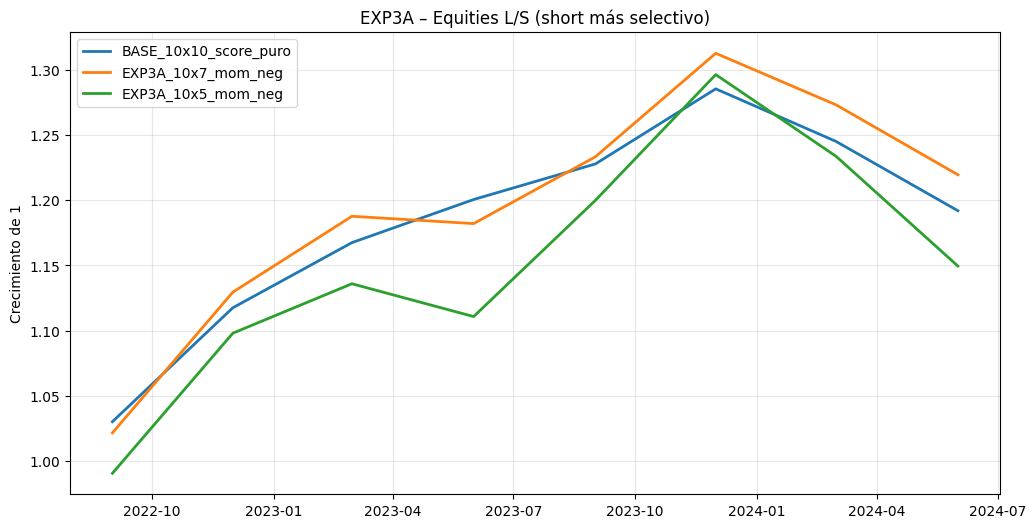

In [145]:

# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 2 – EXP3A: Short más selectivo (5% / 7%)
# ------------------------------------------------------------------------------
# Idea:
#   - Mantener el LONG por score del modelo.
#   - Mejorar el SHORT haciendo la pata más angosta y exigiendo momentum negativo.
#   - Comparar:
#       BASE_10x10            -> score puro
#       EXP3A_10x7_MOMNEG     -> short 7% + momentum negativo
#       EXP3A_10x5_MOMNEG     -> short 5% + momentum negativo
# ==============================================================================

print("\n" + "="*80)
print("EXPERIMENTOS SHORT – EXP3A (short más selectivo)")
print("="*80)

def _run_short_strategy(
    df_exp: pd.DataFrame,
    meta: dict,
    *,
    strategy_name: str,
    long_frac: float = 0.10,
    short_frac: float = 0.10,
    min_names: int = 5,
    candidate_mult: float = 2.0,
    require_negative_mom: bool = False,
    use_consensus: bool = False,
    sector_cap: float | None = None,
):
    mom_col = meta.get("mom_col")
    sector_col = meta.get("sector_col")
    periods_per_year = int(meta.get("periods_per_year", 4))

    rows = []
    monthly = []

    for mes, g0 in df_exp.groupby("Mes", sort=True):
        g = g0.dropna(subset=["score_exp", "ret_eval"]).copy()
        if len(g) < max(10, 2 * min_names):
            continue

        n = len(g)
        n_long = max(min_names, int(math.ceil(long_frac * n)))
        n_short = max(min_names, int(math.ceil(short_frac * n)))
        n_pool = max(n_short, int(math.ceil(candidate_mult * n_short)))

        # LONG = top score_exp
        long_leg = g.sort_values("score_exp", ascending=False).head(n_long).copy()

        # Pool candidato SHORT = peores scores
        short_pool = g.sort_values("score_exp", ascending=True).head(n_pool).copy()

        n_mom_candidates = np.nan
        if require_negative_mom and mom_col and mom_col in short_pool.columns:
            short_pool_m = short_pool[short_pool[mom_col].astype(float) < 0].copy()
            n_mom_candidates = len(short_pool_m)
            if len(short_pool_m) >= min_names:
                short_pool = short_pool_m

        if use_consensus:
            short_pool = short_pool.copy()
            short_pool["short_overlay"] = _build_short_overlay(short_pool, meta)
            short_leg, n_skipped_cap = _select_with_sector_cap(
                short_pool,
                n_pick=n_short,
                score_col="short_overlay",
                sector_col=sector_col,
                max_sector_frac=sector_cap,
            )
        else:
            # score bajo = peor => ordenar ascendente
            short_leg = short_pool.sort_values("score_exp", ascending=True).head(n_short).copy()
            n_skipped_cap = 0

        if len(short_leg) < min_names:
            # fallback suave al score puro
            short_leg = g.sort_values("score_exp", ascending=True).head(n_short).copy()

        ret_long = float(long_leg["ret_eval"].mean()) if len(long_leg) else np.nan
        ret_short = float(-short_leg["ret_eval"].mean()) if len(short_leg) else np.nan
        ret_ls = ret_long + ret_short if (np.isfinite(ret_long) and np.isfinite(ret_short)) else np.nan

        monthly.append({
            "Mes": mes,
            "ret_long": ret_long,
            "ret_short": ret_short,
            "ret_ls": ret_ls,
            "n_universo": n,
            "n_long": len(long_leg),
            "n_short": len(short_leg),
            "n_pool_short": len(short_pool),
            "n_mom_candidates": n_mom_candidates,
            "n_skipped_cap": n_skipped_cap,
            "avg_short_score": float(short_leg["score_exp"].mean()) if len(short_leg) else np.nan,
            "avg_short_ret": float(short_leg["ret_eval"].mean()) if len(short_leg) else np.nan,
            "avg_short_mom": float(short_leg[meta["mom_col"]].mean()) if (len(short_leg) and meta.get("mom_col") in short_leg.columns) else np.nan,
        })

    ser = pd.DataFrame(monthly).set_index("Mes").sort_index() if monthly else pd.DataFrame()
    if ser.empty:
        return {"name": strategy_name, "monthly": ser, "summary": pd.Series(dtype=float)}

    stats = _annualized_stats(ser["ret_ls"], periods_per_year=periods_per_year, rf_per_period=0.0)
    beta, alpha = _beta_alpha_vs_spy(ser["ret_ls"], periods_per_year=periods_per_year)

    summary = {
        "estrategia": strategy_name,
        "ret_total_ls": stats["ret_total"],
        "ret_anual_ls": stats["ret_anual"],
        "vol_anual_ls": stats["vol_anual"],
        "sharpe_ls": stats["sharpe"],
        "hit_ratio_ls": stats["hit_ratio"],
        "mdd_ls": stats["mdd"],
        "beta_spy": beta,
        "alpha_anual": alpha,
        "ret_anual_long": _annualized_stats(ser["ret_long"], periods_per_year=periods_per_year)["ret_anual"],
        "ret_anual_short": _annualized_stats(ser["ret_short"], periods_per_year=periods_per_year)["ret_anual"],
        "prom_short_mom": float(ser["avg_short_mom"].dropna().mean()) if "avg_short_mom" in ser.columns else np.nan,
        "pool_short_prom": float(ser["n_pool_short"].mean()),
        "short_names_prom": float(ser["n_short"].mean()),
        "meses": int(len(ser)),
    }
    return {"name": strategy_name, "monthly": ser, "summary": summary}

if "SHORT_EXP_PANEL" not in globals():
    print("❌ Falta SHORT_EXP_PANEL. Ejecuta primero el bloque experimental anterior.")
else:
    df_exp = globals()["SHORT_EXP_PANEL"]
    meta = globals()["SHORT_EXP_META"]

    short_results = []
    short_results.append(_run_short_strategy(
        df_exp, meta,
        strategy_name="BASE_10x10_score_puro",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=False,
        use_consensus=False,
        candidate_mult=1.0,
    ))
    short_results.append(_run_short_strategy(
        df_exp, meta,
        strategy_name="EXP3A_10x7_mom_neg",
        long_frac=0.10, short_frac=0.07,
        require_negative_mom=True,
        use_consensus=False,
        candidate_mult=2.0,
    ))
    short_results.append(_run_short_strategy(
        df_exp, meta,
        strategy_name="EXP3A_10x5_mom_neg",
        long_frac=0.10, short_frac=0.05,
        require_negative_mom=True,
        use_consensus=False,
        candidate_mult=2.0,
    ))

    SHORT_EXP_RESULTS = {r["name"]: r for r in short_results}
    globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

    summary_a = pd.DataFrame([r["summary"] for r in short_results]).sort_values(
        ["sharpe_ls", "ret_anual_ls"], ascending=False
    ).reset_index(drop=True)

    print("Resumen – EXP3A")
    display(summary_a.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "ret_anual_long": "{:+.2%}",
        "ret_anual_short": "{:+.2%}",
        "prom_short_mom": "{:+.3f}",
        "pool_short_prom": "{:.1f}",
        "short_names_prom": "{:.1f}",
    }))

    # Curvas de equity
    plt.figure(figsize=(12, 6))
    for r in short_results:
        ser = r["monthly"]["ret_ls"].dropna()
        if ser.empty:
            continue
        eq = (1 + ser).cumprod()
        idx = eq.index.to_timestamp() if isinstance(eq.index, pd.PeriodIndex) else pd.to_datetime(eq.index)
        plt.plot(idx, eq, linewidth=2, label=r["name"])
    plt.title("EXP3A – Equities L/S (short más selectivo)")
    plt.ylabel("Crecimiento de 1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



EXPERIMENTOS SHORT – EXP3B / EXP3C (consenso y sector-cap)
Ranking global – experimentos short


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,meses
0,EXP3B_10x10_consenso,+24.51%,+11.59%,8.07%,1.41,88%,-5.38%,+0.18,+6.70%,+24.25%,-11.66%,+0.019,40.1,16.5,8
1,BASE_10x10_score_puro,+19.21%,+9.18%,8.37%,1.10,75%,-7.29%,+0.23,+3.10%,+24.25%,-13.52%,+0.095,18.0,18.0,8
2,EXP3A_10x7_mom_neg,+21.97%,+10.44%,10.03%,1.05,62%,-7.11%,+0.58,-4.69%,+24.25%,-12.27%,+0.105,26.0,13.0,8
3,EXP3C_10x10_consenso_sectorcap35,+12.81%,+6.21%,7.08%,0.89,88%,-5.06%,+0.15,+2.36%,+24.25%,-16.19%,+0.081,40.1,16.5,8
4,EXP3A_10x5_mom_neg,+14.96%,+7.22%,13.22%,0.59,50%,-11.35%,+0.87,-14.87%,+24.25%,-14.89%,+0.071,18.0,9.0,8



Tabla corta – candidatos principales


,estrategia,ret_anual_ls,vol_anual_ls,sharpe_ls,ret_anual_short,beta_spy,alpha_anual,mdd_ls
0,EXP3B_10x10_consenso,+11.59%,8.07%,1.41,-11.66%,+0.18,+6.70%,-5.38%
1,BASE_10x10_score_puro,+9.18%,8.37%,1.10,-13.52%,+0.23,+3.10%,-7.29%
2,EXP3A_10x7_mom_neg,+10.44%,10.03%,1.05,-12.27%,+0.58,-4.69%,-7.11%
3,EXP3C_10x10_consenso_sectorcap35,+6.21%,7.08%,0.89,-16.19%,+0.15,+2.36%,-5.06%
4,EXP3A_10x5_mom_neg,+7.22%,13.22%,0.59,-14.89%,+0.87,-14.87%,-11.35%


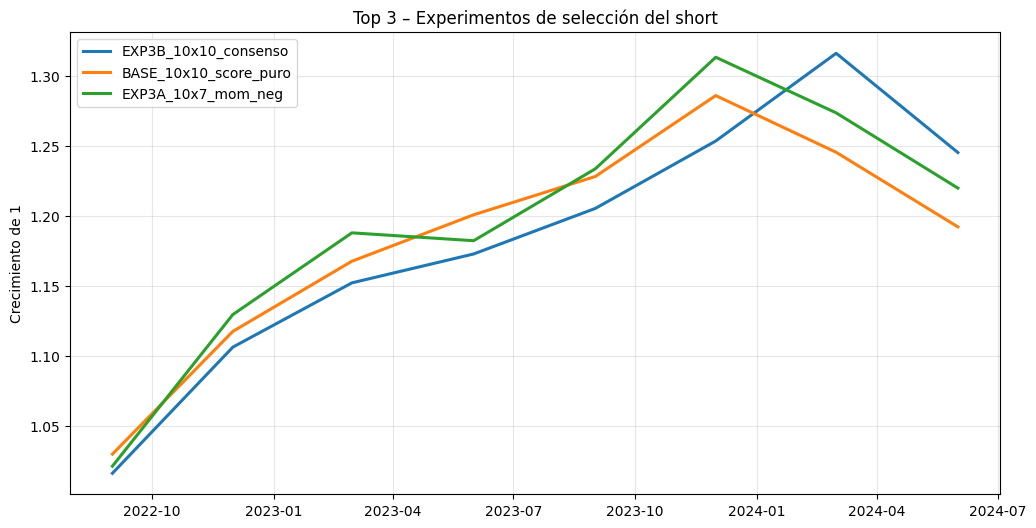


Diagnóstico sectorial del mejor experimento: EXP3B_10x10_consenso


,nombres_short
Sector_GICS,
Information Technology,2
Consumer Staples,1
Utilities,1


,Empresa,score_exp,ret_eval,Sector_GICS,mom_12_1_lag1,sec_score_z_safe,PE_zscore_6m,ROCE__PIT
409,EXC US Equity,-0.750210,0.171627,Utilities,-0.008323,-0.525464,-0.449146,9.056367
138,MDLZ US Equity,-0.637726,0.125764,Consumer Staples,-0.020517,0.127848,-0.778276,9.138000
479,XRX US Equity,-0.279900,-0.106713,Information Technology,-0.058649,0.610359,0.669732,-25.091167
277,PRGS US Equity,-0.241519,0.241614,Information Technology,-0.084008,1.152137,-0.718707,16.351300


In [146]:

# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 3 – EXP3B / EXP3C: Overlay de consenso y cap sectorial
# ------------------------------------------------------------------------------
# Idea:
#   - EXP3B: dentro del pool de peores scores, elegir shorts por consenso:
#            modelo malo + momentum malo + sector malo + valuación cara + calidad débil
#   - EXP3C: lo mismo, pero con tope por sector en la pata short
# ==============================================================================

print("\n" + "="*80)
print("EXPERIMENTOS SHORT – EXP3B / EXP3C (consenso y sector-cap)")
print("="*80)

if "SHORT_EXP_PANEL" not in globals():
    print("❌ Falta SHORT_EXP_PANEL. Ejecuta primero el bloque experimental 1.")
else:
    df_exp = globals()["SHORT_EXP_PANEL"]
    meta = globals()["SHORT_EXP_META"]

    extra_results = []
    extra_results.append(_run_short_strategy(
        df_exp, meta,
        strategy_name="EXP3B_10x10_consenso",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=None,
    ))
    extra_results.append(_run_short_strategy(
        df_exp, meta,
        strategy_name="EXP3C_10x10_consenso_sectorcap35",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=0.35,
    ))

    if "SHORT_EXP_RESULTS" not in globals():
        SHORT_EXP_RESULTS = {}
    else:
        SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]

    for r in extra_results:
        SHORT_EXP_RESULTS[r["name"]] = r
    globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

    summary_all = pd.DataFrame([v["summary"] for v in SHORT_EXP_RESULTS.values()]).sort_values(
        ["sharpe_ls", "ret_anual_ls", "alpha_anual"], ascending=False
    ).reset_index(drop=True)

    print("Ranking global – experimentos short")
    display(summary_all.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "ret_anual_long": "{:+.2%}",
        "ret_anual_short": "{:+.2%}",
        "prom_short_mom": "{:+.3f}",
        "pool_short_prom": "{:.1f}",
        "short_names_prom": "{:.1f}",
    }))

    # Tabla breve para tesis / lectura ejecutiva
    cols_show = [
        "estrategia", "ret_anual_ls", "vol_anual_ls", "sharpe_ls",
        "ret_anual_short", "beta_spy", "alpha_anual", "mdd_ls"
    ]
    print("\nTabla corta – candidatos principales")
    display(summary_all[cols_show].style.format({
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "ret_anual_short": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "mdd_ls": "{:+.2%}",
    }))

    # Curvas de equity de los mejores 3 por Sharpe
    top_names = list(summary_all["estrategia"].head(3))
    plt.figure(figsize=(12, 6))
    for name in top_names:
        ser = SHORT_EXP_RESULTS[name]["monthly"]["ret_ls"].dropna()
        if ser.empty:
            continue
        eq = (1 + ser).cumprod()
        idx = eq.index.to_timestamp() if isinstance(eq.index, pd.PeriodIndex) else pd.to_datetime(eq.index)
        plt.plot(idx, eq, linewidth=2.2, label=name)
    plt.title("Top 3 – Experimentos de selección del short")
    plt.ylabel("Crecimiento de 1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Diagnóstico de concentración sectorial del mejor experimento (si hay sector)
    best_name = summary_all.iloc[0]["estrategia"] if not summary_all.empty else None
    sector_col = meta.get("sector_col")
    if best_name and sector_col and sector_col in df_exp.columns:
        print(f"\nDiagnóstico sectorial del mejor experimento: {best_name}")
        # Reconstrucción simple del último mes disponible para inspección
        last_m = df_exp["Mes"].max()
        g = df_exp[df_exp["Mes"] == last_m].dropna(subset=["score_exp", "ret_eval"]).copy()
        if not g.empty:
            n = len(g)
            n_short = max(5, int(math.ceil(0.10 * n)))
            pool = g.sort_values("score_exp", ascending=True).head(max(n_short, int(math.ceil(2.5 * n_short)))).copy()
            mom_col = meta.get("mom_col")
            if mom_col and mom_col in pool.columns:
                pool = pool[pool[mom_col].astype(float) < 0].copy() if (pool[mom_col].astype(float) < 0).any() else pool
            pool["short_overlay"] = _build_short_overlay(pool, meta)
            short_leg, _ = _select_with_sector_cap(
                pool, n_pick=n_short, score_col="short_overlay", sector_col=sector_col, max_sector_frac=0.35
            )
            if not short_leg.empty:
                display(short_leg.groupby(sector_col).size().sort_values(ascending=False).rename("nombres_short").to_frame())
                cols_preview = ["Empresa", "score_exp", "ret_eval", sector_col]
                for c in [meta.get("mom_col"), meta.get("sec_col"), meta.get("val_col"), meta.get("qual_col")]:
                    if c and c in short_leg.columns and c not in cols_preview:
                        cols_preview.append(c)
                display(short_leg[cols_preview].sort_values("score_exp", ascending=True).head(20))


# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 4 – Extensiones sobre EXP3B (base ganadora)
# ------------------------------------------------------------------------------
# Objetivo:
#   - Probar mejoras incrementales sobre la mejor variante actual:
#       EXP3B_10x10_consenso
#   - Nuevas pruebas:
#       EXP3D_10x10_consenso_sectorcap50  -> cap sectorial suave
#       EXP3E_10x10_consenso_betaneutral  -> ajuste ex-ante por beta (si existe beta feature)
#       EXP3F_10x7_consenso               -> ajuste fino del ancho short
# ==============================================================================


EXPERIMENTOS SHORT – EXP3D / EXP3E / EXP3F (v2 sobre EXP3B)
Beta feature detectada para v2: None
Resumen – EXP3D / EXP3E / EXP3F


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,beta_scale_prom,beta_neutral_share,meses
0,EXP3D_10x10_consenso_sectorcap50,+22.58%,+10.72%,7.11%,1.48,88%,-3.93%,+0.21,+5.00%,+24.25%,-12.32%,+0.047,40.1,16.5,1.00,0%,8
1,EXP3E_10x10_consenso_betaneutral,+24.51%,+11.59%,8.07%,1.41,88%,-5.38%,+0.18,+6.70%,+24.25%,-11.66%,+0.019,40.1,16.5,1.00,0%,8
2,EXP3F_10x7_consenso,+25.47%,+12.01%,10.34%,1.16,88%,-7.31%,+0.43,+0.87%,+24.25%,-11.13%,+0.022,29.5,12.0,1.00,0%,8



Comparación rápida contra EXP3B (si ya está en SHORT_EXP_RESULTS)


,estrategia,ret_anual_ls,vol_anual_ls,sharpe_ls,ret_anual_short,beta_spy,alpha_anual,mdd_ls,beta_scale_prom,beta_neutral_share
0,EXP3D_10x10_consenso_sectorcap50,+10.72%,7.11%,1.48,-12.32%,+0.21,+5.00%,-3.93%,1.00,0%
1,EXP3B_10x10_consenso,+11.59%,8.07%,1.41,-11.66%,+0.18,+6.70%,-5.38%,nan,nan%
2,EXP3E_10x10_consenso_betaneutral,+11.59%,8.07%,1.41,-11.66%,+0.18,+6.70%,-5.38%,1.00,0%
3,EXP3F_10x7_consenso,+12.01%,10.34%,1.16,-11.13%,+0.43,+0.87%,-7.31%,1.00,0%


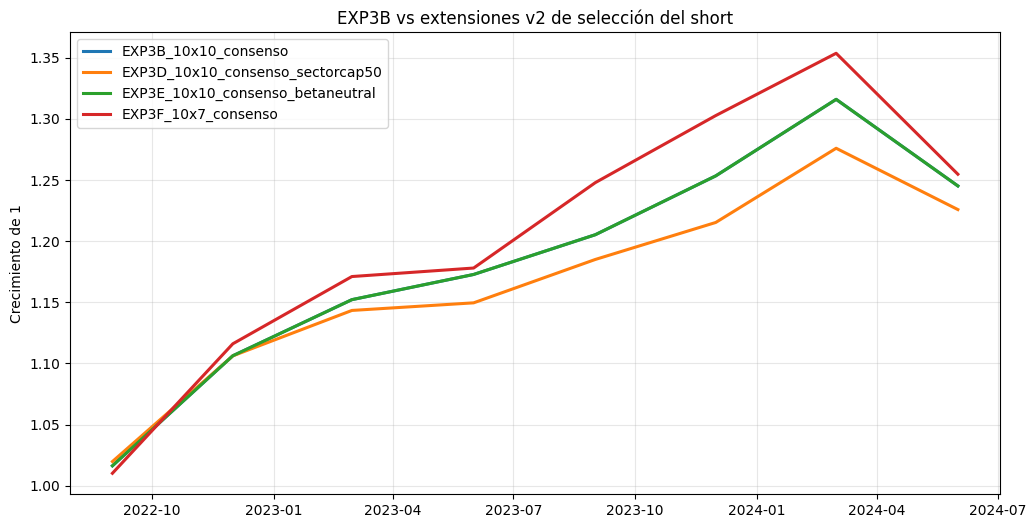

In [147]:
print("\n" + "="*80)
print("EXPERIMENTOS SHORT – EXP3D / EXP3E / EXP3F (v2 sobre EXP3B)")
print("="*80)

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

def _find_beta_col(df_cols):
    exact = [
        "beta_12m_lag1", "beta_12m", "beta_252d_lag1", "beta_252d",
        "beta_1y_lag1", "beta_1y", "beta_rolling_252_lag1",
        "beta_lag1", "beta"
    ]
    for c in exact:
        if c in df_cols:
            return c
    # fallback prudente: primera columna que parezca beta, evitando nombres obvios de métricas agregadas
    beta_like = [c for c in df_cols if ("beta" in str(c).lower()) and ("spy" not in str(c).lower())]
    return beta_like[0] if beta_like else None

def _ensure_beta_in_short_panel():
    if "SHORT_EXP_PANEL" not in globals() or "SHORT_EXP_META" not in globals():
        raise RuntimeError("Falta SHORT_EXP_PANEL / SHORT_EXP_META. Ejecuta primero los bloques 162–164.")
    if "df_sorted" not in globals() or globals()["df_sorted"] is None or globals()["df_sorted"].empty:
        raise RuntimeError("No existe df_sorted para enriquecer el panel experimental.")

    df_exp = globals()["SHORT_EXP_PANEL"].copy()
    meta = dict(globals()["SHORT_EXP_META"])

    beta_col = meta.get("beta_col")
    if beta_col and beta_col in df_exp.columns:
        globals()["SHORT_EXP_PANEL"] = df_exp
        globals()["SHORT_EXP_META"] = meta
        return beta_col

    df_aux = globals()["df_sorted"].copy()
    if "Fecha" not in df_aux.columns or "Empresa" not in df_aux.columns:
        return None
    df_aux["Fecha"] = pd.to_datetime(df_aux["Fecha"], errors="coerce")

    beta_col = _find_beta_col(df_aux.columns)
    if beta_col is None:
        meta["beta_col"] = None
        globals()["SHORT_EXP_META"] = meta
        return None

    if "Fecha" in df_exp.columns:
        df_exp["Fecha"] = pd.to_datetime(df_exp["Fecha"], errors="coerce")

    merge_cols = ["Fecha", "Empresa", beta_col]
    df_beta = df_aux[merge_cols].drop_duplicates(subset=["Fecha", "Empresa"]).copy()
    df_exp = df_exp.merge(df_beta, on=["Fecha", "Empresa"], how="left", suffixes=("", "_beta_new"))

    # si vino duplicado por alguna razón, preferir la columna original y si no la nueva
    if f"{beta_col}_beta_new" in df_exp.columns:
        if beta_col not in df_exp.columns:
            df_exp[beta_col] = df_exp[f"{beta_col}_beta_new"]
        else:
            df_exp[beta_col] = pd.to_numeric(df_exp[beta_col], errors="coerce").fillna(
                pd.to_numeric(df_exp[f"{beta_col}_beta_new"], errors="coerce")
            )
        df_exp = df_exp.drop(columns=[f"{beta_col}_beta_new"], errors="ignore")

    meta["beta_col"] = beta_col
    globals()["SHORT_EXP_PANEL"] = df_exp
    globals()["SHORT_EXP_META"] = meta
    return beta_col

def _run_short_strategy_plus(
    df_exp: pd.DataFrame,
    meta: dict,
    *,
    strategy_name: str,
    long_frac: float = 0.10,
    short_frac: float = 0.10,
    min_names: int = 5,
    candidate_mult: float = 2.5,
    require_negative_mom: bool = True,
    use_consensus: bool = True,
    sector_cap: float | None = None,
    beta_neutral: bool = False,
    beta_scale_clip: tuple[float, float] = (0.50, 1.50),
):
    mom_col = meta.get("mom_col")
    sector_col = meta.get("sector_col")
    beta_col = meta.get("beta_col")
    periods_per_year = int(meta.get("periods_per_year", 4))

    monthly = []

    for mes, g0 in df_exp.groupby("Mes", sort=True):
        g = g0.dropna(subset=["score_exp", "ret_eval"]).copy()
        if len(g) < max(10, 2 * min_names):
            continue

        n = len(g)
        n_long = max(min_names, int(math.ceil(long_frac * n)))
        n_short = max(min_names, int(math.ceil(short_frac * n)))
        n_pool = max(n_short, int(math.ceil(candidate_mult * n_short)))

        long_leg = g.sort_values("score_exp", ascending=False).head(n_long).copy()
        short_pool = g.sort_values("score_exp", ascending=True).head(n_pool).copy()

        n_mom_candidates = np.nan
        if require_negative_mom and mom_col and mom_col in short_pool.columns:
            short_pool_m = short_pool[pd.to_numeric(short_pool[mom_col], errors="coerce") < 0].copy()
            n_mom_candidates = len(short_pool_m)
            if len(short_pool_m) >= min_names:
                short_pool = short_pool_m

        if use_consensus:
            short_pool = short_pool.copy()
            short_pool["short_overlay"] = _build_short_overlay(short_pool, meta)
            short_leg, n_skipped_cap = _select_with_sector_cap(
                short_pool,
                n_pick=n_short,
                score_col="short_overlay",
                sector_col=sector_col,
                max_sector_frac=sector_cap,
            )
        else:
            short_leg = short_pool.sort_values("score_exp", ascending=True).head(n_short).copy()
            n_skipped_cap = 0

        if len(short_leg) < min_names:
            short_leg = g.sort_values("score_exp", ascending=True).head(n_short).copy()

        ret_long_eq = float(long_leg["ret_eval"].mean()) if len(long_leg) else np.nan
        ret_short_eq = float(-short_leg["ret_eval"].mean()) if len(short_leg) else np.nan

        beta_scale = 1.0
        beta_long = np.nan
        beta_short = np.nan
        beta_neutral_applied = False

        if beta_neutral and beta_col and (beta_col in long_leg.columns) and (beta_col in short_leg.columns):
            beta_long = float(pd.to_numeric(long_leg[beta_col], errors="coerce").mean())
            beta_short = float(pd.to_numeric(short_leg[beta_col], errors="coerce").mean())
            if np.isfinite(beta_long) and np.isfinite(beta_short) and abs(beta_short) > 1e-8:
                beta_scale = abs(beta_long / beta_short)
                beta_scale = float(np.clip(beta_scale, beta_scale_clip[0], beta_scale_clip[1]))
                beta_neutral_applied = True

        ret_long = ret_long_eq
        ret_short = ret_short_eq * beta_scale
        ret_ls = ret_long + ret_short if (np.isfinite(ret_long) and np.isfinite(ret_short)) else np.nan

        monthly.append({
            "Mes": mes,
            "ret_long": ret_long,
            "ret_short": ret_short,
            "ret_ls": ret_ls,
            "ret_long_eq": ret_long_eq,
            "ret_short_eq": ret_short_eq,
            "n_universo": n,
            "n_long": len(long_leg),
            "n_short": len(short_leg),
            "n_pool_short": len(short_pool),
            "n_mom_candidates": n_mom_candidates,
            "n_skipped_cap": n_skipped_cap,
            "beta_scale": beta_scale,
            "beta_long_prom": beta_long,
            "beta_short_prom": beta_short,
            "beta_neutral_applied": beta_neutral_applied,
            "avg_short_score": float(short_leg["score_exp"].mean()) if len(short_leg) else np.nan,
            "avg_short_ret": float(short_leg["ret_eval"].mean()) if len(short_leg) else np.nan,
            "avg_short_mom": float(pd.to_numeric(short_leg[mom_col], errors="coerce").mean())
                             if (len(short_leg) and mom_col and mom_col in short_leg.columns) else np.nan,
        })

    ser = pd.DataFrame(monthly)
    if ser.empty:
        summary = {
            "estrategia": strategy_name,
            "ret_total_ls": np.nan, "ret_anual_ls": np.nan, "vol_anual_ls": np.nan,
            "sharpe_ls": np.nan, "hit_ratio_ls": np.nan, "mdd_ls": np.nan,
            "beta_spy": np.nan, "alpha_anual": np.nan,
            "ret_anual_long": np.nan, "ret_anual_short": np.nan,
            "prom_short_mom": np.nan, "pool_short_prom": np.nan, "short_names_prom": np.nan,
            "beta_scale_prom": np.nan, "beta_neutral_share": np.nan, "meses": 0,
        }
        return {"name": strategy_name, "monthly": ser, "summary": summary}

    ser["Mes"] = pd.to_datetime(ser["Mes"].astype(str), errors="coerce").dt.to_period("M")
    ser = ser.sort_values("Mes").set_index("Mes")

    stats = _annualized_stats(ser["ret_ls"], periods_per_year=periods_per_year)
    beta, alpha = _beta_alpha_vs_spy(ser["ret_ls"], periods_per_year=periods_per_year)

    summary = {
        "estrategia": strategy_name,
        "ret_total_ls": stats["ret_total"],
        "ret_anual_ls": stats["ret_anual"],
        "vol_anual_ls": stats["vol_anual"],
        "sharpe_ls": stats["sharpe"],
        "hit_ratio_ls": stats["hit_ratio"],
        "mdd_ls": stats["mdd"],
        "beta_spy": beta,
        "alpha_anual": alpha,
        "ret_anual_long": _annualized_stats(ser["ret_long"], periods_per_year=periods_per_year)["ret_anual"],
        "ret_anual_short": _annualized_stats(ser["ret_short"], periods_per_year=periods_per_year)["ret_anual"],
        "prom_short_mom": float(ser["avg_short_mom"].dropna().mean()) if "avg_short_mom" in ser.columns else np.nan,
        "pool_short_prom": float(ser["n_pool_short"].mean()) if "n_pool_short" in ser.columns else np.nan,
        "short_names_prom": float(ser["n_short"].mean()) if "n_short" in ser.columns else np.nan,
        "beta_scale_prom": float(ser["beta_scale"].mean()) if "beta_scale" in ser.columns else np.nan,
        "beta_neutral_share": float(ser["beta_neutral_applied"].mean()) if "beta_neutral_applied" in ser.columns else np.nan,
        "meses": int(len(ser)),
    }
    return {"name": strategy_name, "monthly": ser, "summary": summary}

if "SHORT_EXP_PANEL" not in globals():
    print("❌ Falta SHORT_EXP_PANEL. Ejecuta primero los bloques 162–164.")
else:
    beta_col_detected = _ensure_beta_in_short_panel()
    df_exp = globals()["SHORT_EXP_PANEL"]
    meta = globals()["SHORT_EXP_META"]

    print(f"Beta feature detectada para v2: {beta_col_detected}")

    new_results = []
    new_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3D_10x10_consenso_sectorcap50",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=0.50,
        beta_neutral=False,
    ))
    new_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3E_10x10_consenso_betaneutral",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=None,
        beta_neutral=True,
        beta_scale_clip=(0.50, 1.50),
    ))
    new_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3F_10x7_consenso",
        long_frac=0.10, short_frac=0.07,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=None,
        beta_neutral=False,
    ))

    if "SHORT_EXP_RESULTS" not in globals():
        SHORT_EXP_RESULTS = {}
    else:
        SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]

    for r in new_results:
        SHORT_EXP_RESULTS[r["name"]] = r
    globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

    summary_v2 = pd.DataFrame([r["summary"] for r in new_results]).sort_values(
        ["sharpe_ls", "ret_anual_ls", "alpha_anual"], ascending=False
    ).reset_index(drop=True)

    print("Resumen – EXP3D / EXP3E / EXP3F")
    display(summary_v2.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "ret_anual_long": "{:+.2%}",
        "ret_anual_short": "{:+.2%}",
        "prom_short_mom": "{:+.3f}",
        "beta_scale_prom": "{:.2f}",
        "beta_neutral_share": "{:.0%}",
        "pool_short_prom": "{:.1f}",
        "short_names_prom": "{:.1f}",
    }))

    print("\nComparación rápida contra EXP3B (si ya está en SHORT_EXP_RESULTS)")
    comp_names = [n for n in [
        "EXP3B_10x10_consenso",
        "EXP3D_10x10_consenso_sectorcap50",
        "EXP3E_10x10_consenso_betaneutral",
        "EXP3F_10x7_consenso",
    ] if n in SHORT_EXP_RESULTS]
    if comp_names:
        comp = pd.DataFrame([SHORT_EXP_RESULTS[n]["summary"] for n in comp_names]).sort_values(
            ["sharpe_ls", "ret_anual_ls"], ascending=False
        ).reset_index(drop=True)
        display(comp[[
            "estrategia", "ret_anual_ls", "vol_anual_ls", "sharpe_ls",
            "ret_anual_short", "beta_spy", "alpha_anual", "mdd_ls",
            "beta_scale_prom", "beta_neutral_share"
        ]].style.format({
            "ret_anual_ls": "{:+.2%}",
            "vol_anual_ls": "{:.2%}",
            "sharpe_ls": "{:.2f}",
            "ret_anual_short": "{:+.2%}",
            "beta_spy": "{:+.2f}",
            "alpha_anual": "{:+.2%}",
            "mdd_ls": "{:+.2%}",
            "beta_scale_prom": "{:.2f}",
            "beta_neutral_share": "{:.0%}",
        }))

    # Curvas de equity: base ganadora vs nuevas variantes
    eq_names = [n for n in [
        "EXP3B_10x10_consenso",
        "EXP3D_10x10_consenso_sectorcap50",
        "EXP3E_10x10_consenso_betaneutral",
        "EXP3F_10x7_consenso",
    ] if n in SHORT_EXP_RESULTS]

    if eq_names:
        plt.figure(figsize=(12, 6))
        for name in eq_names:
            ser = SHORT_EXP_RESULTS[name]["monthly"]["ret_ls"].dropna()
            if ser.empty:
                continue
            eq = (1.0 + ser).cumprod()
            idx = eq.index.to_timestamp() if isinstance(eq.index, pd.PeriodIndex) else pd.to_datetime(eq.index)
            plt.plot(idx, eq, linewidth=2.2, label=name)
        plt.title("EXP3B vs extensiones v2 de selección del short")
        plt.ylabel("Crecimiento de 1")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


## Apéndice: Checklist “a prueba de defensa” (1 página)

### A. Supuestos operativos y línea de tiempo (lo más auditado)

* **Fecha de señal**: las features usadas para decidir en *t* están disponibles **a más tardar al cierre de t-1** (o especificar el desfase real).
* **Rebalance**: mensual / trimestral (definir) y **fecha exacta** (p.ej., último día hábil).
* **Universe**: criterio de elegibilidad (liquidez, precio mínimo, market cap, etc.) y si es **dinámico** (entra/sale) o fijo.
* **Costos**: costos por lado (bps), slippage, y cómo se calcula turnover y costos netos.

**Evidencia mínima**: un diagrama/timeline + una tabla de supuestos.

---

### B. Datos y sesgos (dejar “cerradas” las objeciones)

* **Survivorship/delisting**: aclarar si el dataset incluye delistings y delisting returns. Si no, **limitar el alcance** de conclusiones.
* **Look-ahead suave en macro**: confirmar que se usa **lag** conservador (t-1) o explicar la limitación por no usar “vintages”.
* **Revisiones**: reconocer que macro/contables pueden revisarse; indicar cómo impacta.

**Evidencia mínima**: descripción del dataset + limitaciones explícitas.

---

### C. Validación temporal y prevención de leakage (metodología)

* **Purged walk-forward + embargo**: documentar parámetros (train_min, gap/embargo, hold) en “pasos” del dataset.
* **Separación estricta de entrenamiento/validación**: tuning solo con datos “pasados” respecto al fold.
* **Sanity checks**: tests de permutación, shifts de target, lags extra, y “split count” (que efectivamente hay folds válidos).

**Evidencia mínima**: tabla de parámetros CV + salida resumida de tests.

---

### D. Métricas y “significancia” (para finanzas, clave)

* **IC**: reportar IC promedio y distribución (por mes/quarter).
* **Overlapping returns**: si horizonte > frecuencia de rebalance, ajustar inferencia (HAC/Newey-West) o usar rebalance no solapado.
* **Performance neta**: Sharpe/Sortino y drawdown, siempre **neto de costos**.

**Evidencia mínima**: IC por período + equity curve neta + drawdown.

---

### E. Múltiple testing / selección de modelo (el punto débil típico)

* Si usás DSR/Deflated Sharpe: declarar **# de trials efectivos** (proxy) y cómo se computa.
* Si no podés cuantificar trials: declarar limitación y reforzar con **holdout** y tests de robustez.

**Evidencia mínima**: sección breve de “Model selection risk”.

---

### F. Robustez mínima que “cierra”

* Ablations: **solo contables**, **solo mercado**, **solo macro**, **combinado**.
* Sensibilidad a costos: 0/10/25/50 bps.
* Estabilidad: rolling metrics y subperíodos/regímenes.

---

## Párrafos listos para pegar (con placeholders)

### 1) Supuestos y disponibilidad de información

> La estrategia se implementa bajo el supuesto de información disponible (“as-of”) consistente con una ejecución realista. Para cada fecha de decisión (t), todas las variables explicativas se construyen utilizando únicamente información observada hasta (t-1). En particular, las variables contables se anclan con un rezago conservador de ([X]) períodos respecto a su fecha de reporte, y las variables macroeconómicas se utilizan con rezago ([1]) período para mitigar riesgos de look-ahead asociados a calendarios de publicación y revisiones. El portafolio se rebalancea con frecuencia ([mensual/trimestral]), ejecutando las órdenes al ([cierre del último día hábil / apertura del siguiente]), y se reporta performance neta de costos de transacción.

### 2) Validación temporal (purged walk-forward)

> Para evaluar capacidad predictiva fuera de muestra y evitar leakage temporal, se utiliza un esquema de validación tipo *purged walk-forward* con embargo. En cada fold, el conjunto de entrenamiento incluye observaciones previas a la ventana de prueba, y se excluye un intervalo de separación (embargo) de ([gap]) pasos alrededor de la ventana de test para reducir dependencia temporal entre entrenamiento y evaluación. Los hiperparámetros se seleccionan exclusivamente dentro del entrenamiento mediante validación interna temporalmente consistente. Este diseño replica el flujo causal de un inversor que entrena modelos con historia pasada y toma decisiones sobre datos futuros.

### 3) Métricas: IC y performance

> Se reportan métricas de predicción (Information Coefficient, IC) y métricas económicas (retornos, Sharpe, drawdown) para capturar tanto señal estadística como relevancia financiera. El IC se calcula como la correlación rank (Spearman) entre el score del modelo y el retorno futuro, agregada por período. La performance se presenta en términos brutos y netos de costos, donde los costos se aproximan como ([bps]) por lado multiplicado por el turnover del portafolio.

### 4) Riesgo de selección y múltiple testing

> Dado que el proceso incluye exploración de arquitecturas, transformaciones y configuraciones de entrenamiento, existe riesgo de *model selection bias*. Para mitigarlo, se reserva un período holdout final no utilizado en tuning ni en selección de configuración. Adicionalmente, se reporta un ajuste por múltiple testing mediante ([DSR u otro]) empleando como proxy el número de configuraciones efectivamente evaluadas. En caso de no poder observar “vintages” de datos macro o delisting returns, las conclusiones se interpretan bajo dichas limitaciones.

### 5) Limitaciones (honestas pero controladas)

> Este trabajo no incorpora ([vintages macro / delisting returns / microestructura intradiaria]), por lo que los resultados deben interpretarse como evidencia bajo el marco de datos disponible. No obstante, el uso de validación temporal purgada, costos de transacción y múltiples pruebas de robustez reduce la probabilidad de que los hallazgos respondan a leakage o sobreajuste local.

---

## Figuras mínimas recomendadas (las que más rinden en defensa)

1. **Timeline de información y ejecución**

   * Un diagrama: “datos disponibles → features → score → rebalance → retorno objetivo”.
   * Cierra discusiones de look-ahead.

2. **IC por período (barra o línea)**

   * Eje X: mes/quarter; Eje Y: IC.
   * Mostrar media, mediana, % períodos positivos.

3. **Distribución de IC (histograma + cuantiles)**

   * Reportar percentiles 10/50/90.

4. **Equity curve neta vs benchmark**

   * Curva del portafolio (neto) y benchmark.
   * Anotar costos asumidos.

5. **Drawdown neto**

   * Identifica riesgo y períodos de estrés.

6. **Turnover por período + costos implícitos**

   * Turnover mensual y “cost drag” estimado.

7. **Ablations (tabla o gráfico)**

   * (Contables / Macro / Mercado / Combinado) con IC y Sharpe neto.

8. **Rolling Sharpe / rolling IC** (ventana 12–24 períodos)

   * Evidencia de estabilidad o régimen.

---

## Checklist final de verificación (para el capítulo de resultados)

* [ ] El holdout está **totalmente fuera** de tuning/selección.
* [ ] No hay features construidas con datos de (t) para predecir (t).
* [ ] Hay folds válidos (no “OOF vacío”).
* [ ] IC y performance se reportan **neto de costos**.
* [ ] Se discuten sesgos (survivorship/delisting y macro as-of) y su impacto.
* [ ] Hay al menos 1–2 robustez/ablations que sostienen la historia.


# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 5 – v3: afinado fino sobre EXP3D
# ------------------------------------------------------------------------------
# Objetivo:
#   - Partir del ganador v2 (EXP3D_10x10_consenso_sectorcap50) y buscar una mejora
#     incremental del equilibrio entre:
#       * short menos negativo,
#       * retorno total anualizado,
#       * menor beta / drawdown,
#       * Sharpe más alto.
#   - Grilla corta y priorizada:
#       EXP3G_10x10_consenso_sectorcap45
#       EXP3H_10x10_consenso_sectorcap55
#       EXP3I_10x9_consenso_sectorcap50
#       EXP3J_10x8_consenso_sectorcap50
# ==============================================================================



EXPERIMENTOS SHORT – v3 (afinado fino sobre EXP3D)
Beta feature detectada para v3: None
Resumen – v3 (grilla corta sobre EXP3D)


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,beta_scale_prom,beta_neutral_share,meses
0,EXP3H_10x10_consenso_sectorcap55,+22.58%,+10.72%,7.11%,1.48,88%,-3.93%,+0.21,+5.00%,+24.25%,-12.32%,+0.047,40.1,16.5,1.00,0%,8
1,EXP3I_10x9_consenso_sectorcap50,+19.84%,+9.47%,6.62%,1.41,88%,-3.70%,+0.17,+4.83%,+24.25%,-13.43%,+0.053,38.2,15.5,1.00,0%,8
2,EXP3G_10x10_consenso_sectorcap45,+19.25%,+9.20%,6.66%,1.36,88%,-3.74%,+0.19,+4.23%,+24.25%,-13.64%,+0.062,40.1,16.5,1.00,0%,8
3,EXP3J_10x8_consenso_sectorcap50,+20.07%,+9.57%,7.00%,1.35,88%,-4.32%,+0.30,+1.74%,+24.25%,-13.31%,+0.042,33.9,13.8,1.00,0%,8



Comparación focalizada: base anterior vs mejor v2 vs candidatos v3


,estrategia,ret_anual_ls,vol_anual_ls,sharpe_ls,ret_anual_short,beta_spy,alpha_anual,mdd_ls
0,EXP3D_10x10_consenso_sectorcap50,+10.72%,7.11%,1.48,-12.32%,+0.21,+5.00%,-3.93%
1,EXP3H_10x10_consenso_sectorcap55,+10.72%,7.11%,1.48,-12.32%,+0.21,+5.00%,-3.93%
2,EXP3I_10x9_consenso_sectorcap50,+9.47%,6.62%,1.41,-13.43%,+0.17,+4.83%,-3.70%
3,EXP3B_10x10_consenso,+11.59%,8.07%,1.41,-11.66%,+0.18,+6.70%,-5.38%
4,EXP3G_10x10_consenso_sectorcap45,+9.20%,6.66%,1.36,-13.64%,+0.19,+4.23%,-3.74%
5,EXP3J_10x8_consenso_sectorcap50,+9.57%,7.00%,1.35,-13.31%,+0.30,+1.74%,-4.32%


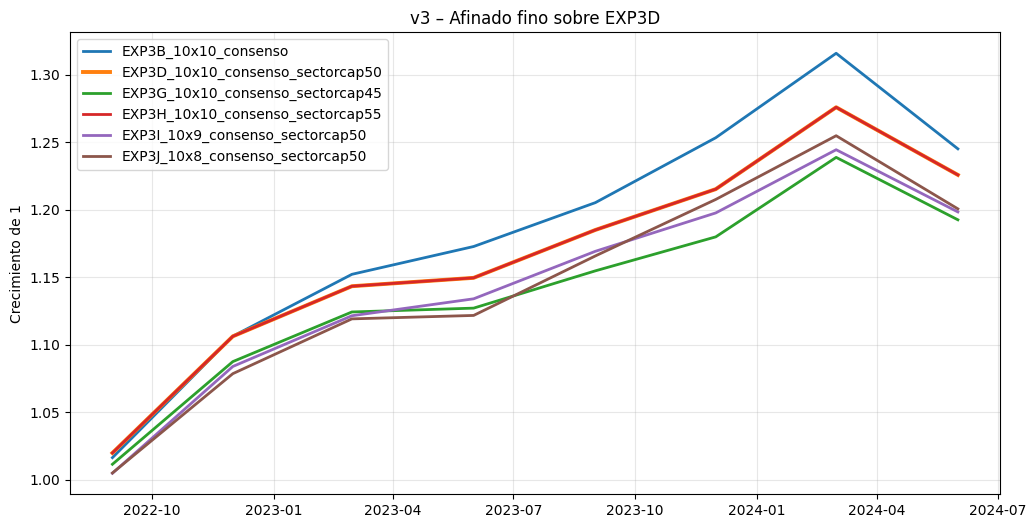


Mejor candidato v3 por Sharpe / retorno / alpha:
  • Estrategia: EXP3H_10x10_consenso_sectorcap55
  • Retorno anualizado L/S: +10.72%
  • Vol anualizada: 7.11%
  • Sharpe: 1.48
  • Short anualizado: -12.32%
  • Beta vs SPY: +0.21
  • Alpha anual: +5.00%
  • MDD: -3.93%


In [148]:

print("\n" + "="*80)
print("EXPERIMENTOS SHORT – v3 (afinado fino sobre EXP3D)")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "SHORT_EXP_PANEL" not in globals() or "SHORT_EXP_META" not in globals():
    print("❌ Faltan SHORT_EXP_PANEL / SHORT_EXP_META. Ejecuta primero los bloques 162–166.")
elif "_run_short_strategy_plus" not in globals():
    print("❌ Falta _run_short_strategy_plus. Ejecuta primero el bloque v2 (celda 166).")
else:
    # Reutilizar panel enriquecido y, si existe, volver a intentar detectar beta
    try:
        beta_col_v3 = _ensure_beta_in_short_panel() if "_ensure_beta_in_short_panel" in globals() else globals()["SHORT_EXP_META"].get("beta_col")
    except Exception as e:
        beta_col_v3 = globals()["SHORT_EXP_META"].get("beta_col")
        print(f"⚠️ No se pudo re-enriquecer el panel con beta: {e}")

    df_exp = globals()["SHORT_EXP_PANEL"]
    meta = globals()["SHORT_EXP_META"]

    print(f"Beta feature detectada para v3: {beta_col_v3}")

    v3_results = []
    v3_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3G_10x10_consenso_sectorcap45",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=0.45,
        beta_neutral=False,
    ))
    v3_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3H_10x10_consenso_sectorcap55",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=0.55,
        beta_neutral=False,
    ))
    v3_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3I_10x9_consenso_sectorcap50",
        long_frac=0.10, short_frac=0.09,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=0.50,
        beta_neutral=False,
    ))
    v3_results.append(_run_short_strategy_plus(
        df_exp, meta,
        strategy_name="EXP3J_10x8_consenso_sectorcap50",
        long_frac=0.10, short_frac=0.08,
        require_negative_mom=True,
        use_consensus=True,
        candidate_mult=2.5,
        sector_cap=0.50,
        beta_neutral=False,
    ))

    if "SHORT_EXP_RESULTS" not in globals():
        SHORT_EXP_RESULTS = {}
    else:
        SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]

    for r in v3_results:
        SHORT_EXP_RESULTS[r["name"]] = r
    globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

    summary_v3 = pd.DataFrame([r["summary"] for r in v3_results]).sort_values(
        ["sharpe_ls", "ret_anual_ls", "alpha_anual"], ascending=False
    ).reset_index(drop=True)

    print("Resumen – v3 (grilla corta sobre EXP3D)")
    display(summary_v3.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "ret_anual_long": "{:+.2%}",
        "ret_anual_short": "{:+.2%}",
        "prom_short_mom": "{:+.3f}",
        "beta_scale_prom": "{:.2f}",
        "beta_neutral_share": "{:.0%}",
        "pool_short_prom": "{:.1f}",
        "short_names_prom": "{:.1f}",
    }))

    print("\nComparación focalizada: base anterior vs mejor v2 vs candidatos v3")
    focus_names = [n for n in [
        "EXP3B_10x10_consenso",
        "EXP3D_10x10_consenso_sectorcap50",
        "EXP3G_10x10_consenso_sectorcap45",
        "EXP3H_10x10_consenso_sectorcap55",
        "EXP3I_10x9_consenso_sectorcap50",
        "EXP3J_10x8_consenso_sectorcap50",
    ] if n in SHORT_EXP_RESULTS]

    if focus_names:
        focus = pd.DataFrame([SHORT_EXP_RESULTS[n]["summary"] for n in focus_names]).copy()
        focus = focus.sort_values(["sharpe_ls", "ret_anual_ls", "alpha_anual"], ascending=False).reset_index(drop=True)
        display(focus[[
            "estrategia", "ret_anual_ls", "vol_anual_ls", "sharpe_ls",
            "ret_anual_short", "beta_spy", "alpha_anual", "mdd_ls"
        ]].style.format({
            "ret_anual_ls": "{:+.2%}",
            "vol_anual_ls": "{:.2%}",
            "sharpe_ls": "{:.2f}",
            "ret_anual_short": "{:+.2%}",
            "beta_spy": "{:+.2f}",
            "alpha_anual": "{:+.2%}",
            "mdd_ls": "{:+.2%}",
        }))

    # Curvas de equity de la base y variantes v3
    eq_names = [n for n in [
        "EXP3B_10x10_consenso",
        "EXP3D_10x10_consenso_sectorcap50",
        "EXP3G_10x10_consenso_sectorcap45",
        "EXP3H_10x10_consenso_sectorcap55",
        "EXP3I_10x9_consenso_sectorcap50",
        "EXP3J_10x8_consenso_sectorcap50",
    ] if n in SHORT_EXP_RESULTS]

    if eq_names:
        plt.figure(figsize=(12, 6))
        for name in eq_names:
            ser = SHORT_EXP_RESULTS[name]["monthly"]["ret_ls"].dropna()
            if ser.empty:
                continue
            eq = (1.0 + ser).cumprod()
            idx = eq.index.to_timestamp() if isinstance(eq.index, pd.PeriodIndex) else pd.to_datetime(eq.index)
            lw = 2.8 if name == "EXP3D_10x10_consenso_sectorcap50" else 2.0
            plt.plot(idx, eq, linewidth=lw, label=name)
        plt.title("v3 – Afinado fino sobre EXP3D")
        plt.ylabel("Crecimiento de 1")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # Diagnóstico simple: mejor candidato v3
    if not summary_v3.empty:
        best_v3 = summary_v3.iloc[0]["estrategia"]
        best_row = summary_v3.iloc[0]
        print("\nMejor candidato v3 por Sharpe / retorno / alpha:")
        print(f"  • Estrategia: {best_v3}")
        print(f"  • Retorno anualizado L/S: {best_row['ret_anual_ls']:+.2%}")
        print(f"  • Vol anualizada: {best_row['vol_anual_ls']:.2%}")
        print(f"  • Sharpe: {best_row['sharpe_ls']:.2f}")
        print(f"  • Short anualizado: {best_row['ret_anual_short']:+.2%}")
        print(f"  • Beta vs SPY: {best_row['beta_spy']:+.2f}")
        print(f"  • Alpha anual: {best_row['alpha_anual']:+.2%}")
        print(f"  • MDD: {best_row['mdd_ls']:+.2%}")



# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 6 – Hedge explícito / beta-neutralización sobre EXP3D
# ------------------------------------------------------------------------------
# Objetivo:
#   - Mantener la selección de nombres de `EXP3D_10x10_consenso_sectorcap50`.
#   - No seguir agregando clasificadores para short.
#   - Probar si el short puede servir mejor como cobertura del portafolio mediante:
#       1. hedge explícito con SPY de peso constante,
#       2. hedge explícito dinámico usando beta ex-ante estimada con ventana expanding,
#       3. hedge dinámico solo en régimen risk-off,
#       4. (opcional) reescalado de la pata short si existe beta por acción.
# ==============================================================================




EXPERIMENTOS SHORT – v6 (hedge explícito / beta-neutralización sobre EXP3D)

Resumen – v6 (hedge explícito / beta-neutralización)


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_base,ret_anual_long,ret_anual_short,ret_anual_spyhedge,avg_hedge_weight,max_hedge_weight,riskoff_share,hedge_mode,meses
3,EXP6D_10x10_consenso_sectorcap50_spyhedge_riskoff,+22.58%,+10.72%,7.11%,1.48,87.5%,-3.93%,0.21,+5.00%,+10.72%,+24.25%,-12.32%,+0.00%,0.00,0.00,0.0%,SPY hedge dinámico solo en risk-off,8
0,EXP6A_10x10_consenso_sectorcap50_spyhedge20,+10.67%,+5.20%,6.83%,0.78,87.5%,-5.00%,0.01,+5.00%,+10.72%,+24.25%,-12.32%,-5.13%,0.20,0.20,0.0%,SPY hedge constante 20%,8
2,EXP6C_10x10_consenso_sectorcap50_spyhedge_dyn,+8.60%,+4.21%,6.88%,0.63,75.0%,-4.75%,-0.06,+5.95%,+10.72%,+24.25%,-12.32%,-6.06%,0.22,0.34,0.0%,SPY hedge dinámico por beta expanding,8
1,EXP6B_10x10_consenso_sectorcap50_spyhedge25,+7.85%,+3.85%,6.84%,0.58,75.0%,-5.26%,-0.04,+5.00%,+10.72%,+24.25%,-12.32%,-6.39%,0.25,0.25,0.0%,SPY hedge constante 25%,8



Comparación focal contra EXP3D / EXP3B


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,beta_scale_prom,beta_neutral_share,meses,ret_anual_base,ret_anual_spyhedge,avg_hedge_weight,max_hedge_weight,riskoff_share,hedge_mode
0,EXP3D_10x10_consenso_sectorcap50,+22.58%,+10.72%,7.11%,1.48,87.5%,-3.93%,0.21,+5.00%,+24.25%,-12.32%,0.046953,40.125000,16.500000,1.000000,0.000000,8,nan,+nan%,nan,nan,nan%,nan
2,EXP6D_10x10_consenso_sectorcap50_spyhedge_riskoff,+22.58%,+10.72%,7.11%,1.48,87.5%,-3.93%,0.21,+5.00%,+24.25%,-12.32%,nan,nan,nan,nan,nan,8,0.107164,+0.00%,0.00,0.00,0.0%,SPY hedge dinámico solo en risk-off
1,EXP3B_10x10_consenso,+24.51%,+11.59%,8.07%,1.41,87.5%,-5.38%,0.18,+6.70%,+24.25%,-11.66%,0.019196,40.125000,16.500000,nan,nan,8,nan,+nan%,nan,nan,nan%,nan
3,EXP6A_10x10_consenso_sectorcap50_spyhedge20,+10.67%,+5.20%,6.83%,0.78,87.5%,-5.00%,0.01,+5.00%,+24.25%,-12.32%,nan,nan,nan,nan,nan,8,0.107164,-5.13%,0.20,0.20,0.0%,SPY hedge constante 20%
4,EXP6C_10x10_consenso_sectorcap50_spyhedge_dyn,+8.60%,+4.21%,6.88%,0.63,75.0%,-4.75%,-0.06,+5.95%,+24.25%,-12.32%,nan,nan,nan,nan,nan,8,0.107164,-6.06%,0.22,0.34,0.0%,SPY hedge dinámico por beta expanding
5,EXP6B_10x10_consenso_sectorcap50_spyhedge25,+7.85%,+3.85%,6.84%,0.58,75.0%,-5.26%,-0.04,+5.00%,+24.25%,-12.32%,nan,nan,nan,nan,nan,8,0.107164,-6.39%,0.25,0.25,0.0%,SPY hedge constante 25%


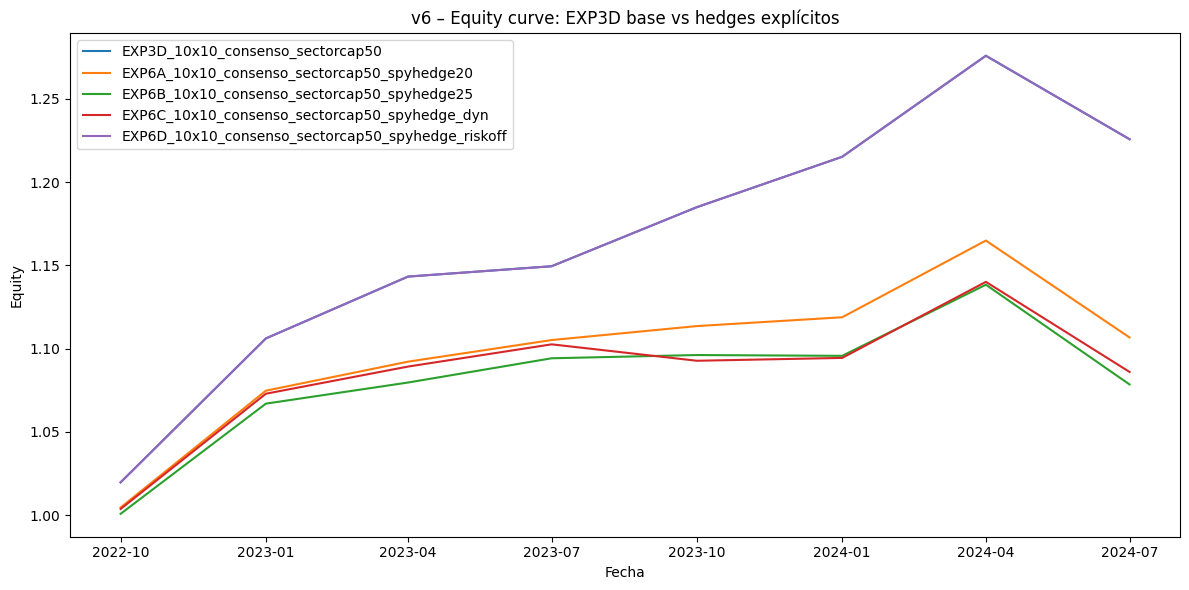


Ganador v6 por Sharpe:
estrategia      EXP6D_10x10_consenso_sectorcap50_spyhedge_riskoff
ret_anual_ls                                             0.107164
vol_anual_ls                                             0.071054
sharpe_ls                                                1.481626
beta_spy                                                 0.211724
alpha_anual                                              0.050001
Name: 3, dtype: object


In [149]:

print("\n" + "="*80)
print("EXPERIMENTOS SHORT – v6 (hedge explícito / beta-neutralización sobre EXP3D)")
print("="*80)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _spy_series_from_bench(target_index):
    if "bench_3m" not in globals() or getattr(globals()["bench_3m"], "empty", True):
        return pd.Series(index=target_index, dtype=float)
    bench = globals()["bench_3m"].copy()
    if "SPY" not in bench.columns:
        return pd.Series(index=target_index, dtype=float)
    spy = pd.Series(bench["SPY"]).astype(float)
    try:
        if isinstance(spy.index, pd.PeriodIndex):
            spy.index = spy.index.asfreq("M")
        else:
            spy.index = pd.to_datetime(spy.index, errors="coerce").to_period("M")
    except Exception:
        spy.index = pd.to_datetime(pd.Index(spy.index), errors="coerce").to_period("M")
    spy = spy[~spy.index.isna()]
    return spy.reindex(target_index)

def _rolling_beta_exante(port_ret: pd.Series, spy_ret: pd.Series, *, min_obs: int = 4,
                         default_beta: float = 0.20, clip: tuple[float, float] = (0.0, 0.60)) -> pd.Series:
    idx = port_ret.index
    out = []
    for i, mes in enumerate(idx):
        x = pd.Series(port_ret.iloc[:i], index=idx[:i]).astype(float)
        y = pd.Series(spy_ret.iloc[:i], index=idx[:i]).astype(float)
        valid = x.index.intersection(y.dropna().index)
        x = x.reindex(valid).dropna()
        y = y.reindex(valid).dropna()
        beta = default_beta
        if len(valid) >= min_obs and len(x) >= min_obs and len(y) >= min_obs:
            vy = float(np.var(y, ddof=1))
            if np.isfinite(vy) and vy > 0:
                beta = float(np.cov(x, y, ddof=1)[0, 1] / vy)
        if not np.isfinite(beta):
            beta = default_beta
        lo, hi = clip
        beta = float(np.clip(beta, lo, hi))
        out.append(beta)
    return pd.Series(out, index=idx, dtype=float)

def _prior_2q_compound(s: pd.Series) -> pd.Series:
    x = (1.0 + pd.Series(s).astype(float))
    out = x.shift(1).rolling(2).apply(np.prod, raw=True) - 1.0
    return out

def _evaluate_hedged_monthly(monthly_df: pd.DataFrame, *, strategy_name: str, periods_per_year: int = 4):
    m = monthly_df.copy().sort_index()
    stats = _annualized_stats(m["ret_ls"], periods_per_year=periods_per_year, rf_per_period=0.0)
    beta, alpha = _beta_alpha_vs_spy(m["ret_ls"], periods_per_year=periods_per_year)
    out = {
        "estrategia": strategy_name,
        "ret_total_ls": stats["ret_total"],
        "ret_anual_ls": stats["ret_anual"],
        "vol_anual_ls": stats["vol_anual"],
        "sharpe_ls": stats["sharpe"],
        "hit_ratio_ls": stats["hit_ratio"],
        "mdd_ls": stats["mdd"],
        "beta_spy": beta,
        "alpha_anual": alpha,
        "ret_anual_long": _annualized_stats(m["ret_long"], periods_per_year=periods_per_year)["ret_anual"] if "ret_long" in m else np.nan,
        "ret_anual_short": _annualized_stats(m["ret_short"], periods_per_year=periods_per_year)["ret_anual"] if "ret_short" in m else np.nan,
        "ret_anual_base": _annualized_stats(m["ret_ls_base"], periods_per_year=periods_per_year)["ret_anual"] if "ret_ls_base" in m else np.nan,
        "ret_anual_spyhedge": _annualized_stats(m["ret_hedge_spy"], periods_per_year=periods_per_year)["ret_anual"] if "ret_hedge_spy" in m else np.nan,
        "avg_hedge_weight": float(pd.to_numeric(m.get("hedge_w", np.nan), errors="coerce").mean()) if "hedge_w" in m else np.nan,
        "max_hedge_weight": float(pd.to_numeric(m.get("hedge_w", np.nan), errors="coerce").max()) if "hedge_w" in m else np.nan,
        "riskoff_share": float(pd.to_numeric(m.get("riskoff_flag", np.nan), errors="coerce").mean()) if "riskoff_flag" in m else np.nan,
        "meses": int(len(m)),
    }
    return out

def _ts_index(idx):
    if isinstance(idx, pd.PeriodIndex):
        return idx.to_timestamp(how="end")
    try:
        return pd.to_datetime(idx)
    except Exception:
        return idx

def _build_exp3d_base_monthly():
    base_res = _run_short_strategy_plus(
        globals()["SHORT_EXP_PANEL"],
        globals()["SHORT_EXP_META"],
        strategy_name="EXP3D_10x10_consenso_sectorcap50_REBUILD",
        long_frac=0.10,
        short_frac=0.10,
        min_names=5,
        candidate_mult=2.5,
        require_negative_mom=True,
        use_consensus=True,
        sector_cap=0.50,
        beta_neutral=False,
    )
    monthly = base_res["monthly"].copy()
    monthly = monthly.sort_index()
    return base_res, monthly

if "SHORT_EXP_PANEL" not in globals() or "SHORT_EXP_META" not in globals():
    print("❌ Faltan SHORT_EXP_PANEL / SHORT_EXP_META. Ejecuta primero los bloques 163–170.")
elif "_run_short_strategy_plus" not in globals():
    print("❌ Falta _run_short_strategy_plus. Ejecuta primero el bloque v2/v3.")
else:
    base_res, monthly_base = _build_exp3d_base_monthly()

    spy = _spy_series_from_bench(monthly_base.index)
    if spy.notna().sum() == 0:
        print("❌ No se encontró SPY usable en bench_3m. No se pueden correr los hedges explícitos.")
    else:
        monthly_base = monthly_base.copy()
        monthly_base["spy_ret"] = spy
        default_beta = base_res["summary"].get("beta_spy", np.nan)
        if not np.isfinite(default_beta):
            default_beta = 0.20
        default_beta = float(np.clip(default_beta, 0.0, 0.60))

        # Dinámica ex-ante sobre retornos de la estrategia base
        monthly_base["hedge_w_dyn"] = _rolling_beta_exante(
            monthly_base["ret_ls"], monthly_base["spy_ret"],
            min_obs=4, default_beta=default_beta, clip=(0.0, 0.60)
        )
        monthly_base["spy_2q_prior"] = _prior_2q_compound(monthly_base["spy_ret"])
        monthly_base["riskoff_flag"] = (monthly_base["spy_2q_prior"] < 0).astype(float)
        monthly_base["hedge_w_const20"] = 0.20
        monthly_base["hedge_w_const25"] = 0.25
        monthly_base["hedge_w_riskoff"] = monthly_base["hedge_w_dyn"] * monthly_base["riskoff_flag"]

        # Variante opcional: beta scaling de la pata short si existe beta ex-ante por acción
        beta_scaling_available = False
        beta_scale_series = pd.Series(index=monthly_base.index, dtype=float)
        try:
            beta_col = globals()["SHORT_EXP_META"].get("beta_col")
            if beta_col and beta_col in globals()["SHORT_EXP_PANEL"].columns:
                beta_scaling_available = True
        except Exception:
            beta_scaling_available = False

        def _apply_spy_hedge(df_m, hedge_col, name, hedge_mode):
            m = df_m.copy()
            m["ret_ls_base"] = m["ret_ls"].astype(float)
            m["hedge_w"] = pd.to_numeric(m[hedge_col], errors="coerce").fillna(0.0)
            m["ret_hedge_spy"] = -m["hedge_w"] * m["spy_ret"].astype(float)
            m["ret_ls"] = m["ret_ls_base"] + m["ret_hedge_spy"]
            summary = _evaluate_hedged_monthly(m, strategy_name=name, periods_per_year=int(globals()["SHORT_EXP_META"].get("periods_per_year", 4)))
            summary["hedge_mode"] = hedge_mode
            return {"name": name, "monthly": m, "summary": pd.Series(summary)}

        v6_results = []
        v6_results.append(_apply_spy_hedge(
            monthly_base, "hedge_w_const20",
            "EXP6A_10x10_consenso_sectorcap50_spyhedge20",
            "SPY hedge constante 20%"
        ))
        v6_results.append(_apply_spy_hedge(
            monthly_base, "hedge_w_const25",
            "EXP6B_10x10_consenso_sectorcap50_spyhedge25",
            "SPY hedge constante 25%"
        ))
        v6_results.append(_apply_spy_hedge(
            monthly_base, "hedge_w_dyn",
            "EXP6C_10x10_consenso_sectorcap50_spyhedge_dyn",
            "SPY hedge dinámico por beta expanding"
        ))
        v6_results.append(_apply_spy_hedge(
            monthly_base, "hedge_w_riskoff",
            "EXP6D_10x10_consenso_sectorcap50_spyhedge_riskoff",
            "SPY hedge dinámico solo en risk-off"
        ))

        if beta_scaling_available:
            # Reconstrucción con scaling de short sobre beta media de las patas
            df_exp = globals()["SHORT_EXP_PANEL"].copy()
            meta = globals()["SHORT_EXP_META"]
            periods_per_year = int(meta.get("periods_per_year", 4))
            mom_col = meta.get("mom_col")
            sector_col = meta.get("sector_col")
            beta_col = meta.get("beta_col")
            monthly_scaled = []
            for mes, g0 in df_exp.groupby("Mes", sort=True):
                g = g0.dropna(subset=["score_exp", "ret_eval", beta_col]).copy()
                if len(g) < 10:
                    continue
                n = len(g)
                n_long = max(5, int(math.ceil(0.10 * n)))
                n_short = max(5, int(math.ceil(0.10 * n)))
                n_pool = max(n_short, int(math.ceil(2.5 * n_short)))

                long_leg = g.sort_values("score_exp", ascending=False).head(n_long).copy()
                short_pool = g.sort_values("score_exp", ascending=True).head(n_pool).copy()
                if mom_col and mom_col in short_pool.columns:
                    short_pool_m = short_pool[pd.to_numeric(short_pool[mom_col], errors="coerce") < 0].copy()
                    if len(short_pool_m) >= 5:
                        short_pool = short_pool_m
                short_pool["short_overlay"] = _build_short_overlay(short_pool, meta)
                short_leg, _ = _select_with_sector_cap(
                    short_pool,
                    n_pick=n_short,
                    score_col="short_overlay",
                    sector_col=sector_col,
                    max_sector_frac=0.50,
                )
                if len(short_leg) < 5:
                    short_leg = g.sort_values("score_exp", ascending=True).head(n_short).copy()

                beta_long = float(pd.to_numeric(long_leg[beta_col], errors="coerce").mean())
                beta_short = float(pd.to_numeric(short_leg[beta_col], errors="coerce").mean())
                if np.isfinite(beta_long) and np.isfinite(beta_short) and abs(beta_short) > 1e-6:
                    short_scale = float(np.clip(beta_long / beta_short, 0.50, 1.50))
                else:
                    short_scale = 1.0

                ret_long = float(pd.to_numeric(long_leg["ret_eval"], errors="coerce").mean())
                ret_short = float(-pd.to_numeric(short_leg["ret_eval"], errors="coerce").mean())
                ret_ls_base = ret_long + ret_short
                ret_ls_scaled = ret_long + short_scale * ret_short

                monthly_scaled.append({
                    "Mes": mes,
                    "ret_long": ret_long,
                    "ret_short": ret_short,
                    "ret_ls_base": ret_ls_base,
                    "ret_ls": ret_ls_scaled,
                    "spy_ret": float(spy.get(mes, np.nan)),
                    "hedge_w": np.nan,
                    "ret_hedge_spy": 0.0,
                    "short_scale": short_scale,
                })

            if monthly_scaled:
                monthly_scaled = pd.DataFrame(monthly_scaled).set_index("Mes").sort_index()
                summary_scaled = _evaluate_hedged_monthly(
                    monthly_scaled,
                    strategy_name="EXP6E_10x10_consenso_sectorcap50_shortscale_beta",
                    periods_per_year=int(globals()["SHORT_EXP_META"].get("periods_per_year", 4))
                )
                summary_scaled["hedge_mode"] = "Reescalado short por beta media de las patas"
                summary_scaled["avg_short_scale"] = float(pd.to_numeric(monthly_scaled["short_scale"], errors="coerce").mean())
                v6_results.append({"name": "EXP6E_10x10_consenso_sectorcap50_shortscale_beta",
                                   "monthly": monthly_scaled,
                                   "summary": pd.Series(summary_scaled)})

        # Guardar y mostrar
        if "SHORT_EXP_RESULTS" not in globals():
            SHORT_EXP_RESULTS = {}
        else:
            SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]

        for r in v6_results:
            SHORT_EXP_RESULTS[r["name"]] = r

        globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

        v6_df = pd.DataFrame([r["summary"] for r in v6_results]).copy()
        order_cols = [
            "estrategia", "ret_total_ls", "ret_anual_ls", "vol_anual_ls", "sharpe_ls",
            "hit_ratio_ls", "mdd_ls", "beta_spy", "alpha_anual", "ret_anual_base",
            "ret_anual_long", "ret_anual_short", "ret_anual_spyhedge",
            "avg_hedge_weight", "max_hedge_weight", "riskoff_share", "hedge_mode", "meses"
        ]
        order_cols = [c for c in order_cols if c in v6_df.columns] + [c for c in v6_df.columns if c not in order_cols]
        v6_df = v6_df[order_cols].sort_values(["sharpe_ls", "ret_anual_ls"], ascending=[False, False])

        print("\nResumen – v6 (hedge explícito / beta-neutralización)")
        display(v6_df.style.format({
            "ret_total_ls": "{:+.2%}",
            "ret_anual_ls": "{:+.2%}",
            "vol_anual_ls": "{:.2%}",
            "sharpe_ls": "{:.2f}",
            "hit_ratio_ls": "{:.1%}",
            "mdd_ls": "{:+.2%}",
            "beta_spy": "{:.2f}",
            "alpha_anual": "{:+.2%}",
            "ret_anual_base": "{:+.2%}",
            "ret_anual_long": "{:+.2%}",
            "ret_anual_short": "{:+.2%}",
            "ret_anual_spyhedge": "{:+.2%}",
            "avg_hedge_weight": "{:.2f}",
            "max_hedge_weight": "{:.2f}",
            "riskoff_share": "{:.1%}",
        }))

        focus_names = [
            "EXP3D_10x10_consenso_sectorcap50",
            "EXP3B_10x10_consenso",
        ] + list(v6_df["estrategia"].values)
        focus_names = [n for n in focus_names if n in SHORT_EXP_RESULTS]
        if focus_names:
            focus = pd.DataFrame([SHORT_EXP_RESULTS[n]["summary"] for n in focus_names]).copy()
            focus = focus.sort_values(["sharpe_ls", "ret_anual_ls"], ascending=[False, False])
            print("\nComparación focal contra EXP3D / EXP3B")
            display(focus.style.format({
                "ret_total_ls": "{:+.2%}",
                "ret_anual_ls": "{:+.2%}",
                "vol_anual_ls": "{:.2%}",
                "sharpe_ls": "{:.2f}",
                "hit_ratio_ls": "{:.1%}",
                "mdd_ls": "{:+.2%}",
                "beta_spy": "{:.2f}",
                "alpha_anual": "{:+.2%}",
                "ret_anual_long": "{:+.2%}",
                "ret_anual_short": "{:+.2%}",
                "ret_anual_spyhedge": "{:+.2%}",
                "avg_hedge_weight": "{:.2f}",
                "max_hedge_weight": "{:.2f}",
                "riskoff_share": "{:.1%}",
            }))

        plt.figure(figsize=(12, 6))
        plot_names = [
            "EXP3D_10x10_consenso_sectorcap50",
            "EXP6A_10x10_consenso_sectorcap50_spyhedge20",
            "EXP6B_10x10_consenso_sectorcap50_spyhedge25",
            "EXP6C_10x10_consenso_sectorcap50_spyhedge_dyn",
            "EXP6D_10x10_consenso_sectorcap50_spyhedge_riskoff",
        ]
        if beta_scaling_available:
            plot_names.append("EXP6E_10x10_consenso_sectorcap50_shortscale_beta")
        plot_names = [n for n in plot_names if n in SHORT_EXP_RESULTS]
        for name in plot_names:
            monthly = SHORT_EXP_RESULTS[name]["monthly"]
            if "ret_ls" not in monthly.columns:
                continue
            ser = pd.Series(monthly["ret_ls"]).dropna().astype(float)
            if ser.empty:
                continue
            eq = (1.0 + ser).cumprod()
            plt.plot(_ts_index(eq.index), eq.values, label=name)
        plt.title("v6 – Equity curve: EXP3D base vs hedges explícitos")
        plt.xlabel("Fecha")
        plt.ylabel("Equity")
        plt.legend()
        plt.tight_layout()
        plt.show()

        print("\nGanador v6 por Sharpe:")
        if not v6_df.empty:
            print(v6_df.iloc[0][["estrategia", "ret_anual_ls", "vol_anual_ls", "sharpe_ls", "beta_spy", "alpha_anual"]])


# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 7 – cierre: long-only vs short residual / sector-relative
# ------------------------------------------------------------------------------
# Objetivo:
#   - Responder si el short justifica su existencia frente a un benchmark long-only.
#   - Cambiar la lógica del short desde "caída absoluta" a "debilidad relativa"
#     dentro de sector, manteniendo el long del modelo base.
#   - Probar:
#       EXP7A_longonly_top10
#       EXP7B_10x10_sectorrel_cap50
#       EXP7C_10x10_hybrid_sectorrel_cap50
#       EXP7D_10x10_hybrid_sectorrel_betafilter_cap50 (si hay beta usable)
# ==============================================================================



EXPERIMENTOS SHORT – v7 (long-only + short residual / sector-relative)
Preparando y corriendo variantes v7...
beta_col usable: None

Resumen – v7


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,pool_short_prom,short_names_prom,meses,variant,prom_short_mom,hybrid_weight,sector_cap,beta_filter_q
0,EXP7A_longonly_top10,+54.37%,+24.25%,11.57%,1.98,88%,-3.83%,+0.92,-1.19%,+24.25%,+nan%,nan,0.0,8,long_only,+nan,nan%,nan%,nan%
1,EXP7C_10x10_hybrid_sectorrel_cap50,+21.12%,+10.06%,7.22%,1.37,88%,-3.93%,+0.20,+4.61%,+24.25%,-12.91%,40.1,16.5,8,sector_relative,+0.051,50%,50%,nan%
2,EXP7B_10x10_sectorrel_cap50,+19.55%,+9.34%,6.82%,1.35,88%,-3.93%,+0.19,+4.27%,+24.25%,-13.53%,40.1,16.5,8,sector_relative,+0.063,100%,50%,nan%



Comparación focal contra bases previas + v7


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,beta_scale_prom,beta_neutral_share,meses,variant,hybrid_weight,sector_cap,beta_filter_q
0,EXP7A_longonly_top10,+54.37%,+24.25%,11.57%,1.98,88%,-3.83%,+0.92,-1.19%,+24.25%,+nan%,nan,nan,0.000000,nan,nan,8,long_only,nan%,nan%,nan%
1,EXP3D_10x10_consenso_sectorcap50,+22.58%,+10.72%,7.11%,1.48,88%,-3.93%,+0.21,+5.00%,+24.25%,-12.32%,0.046953,40.125000,16.500000,1.000000,0.000000,8,nan,nan%,nan%,nan%
2,EXP3B_10x10_consenso,+24.51%,+11.59%,8.07%,1.41,88%,-5.38%,+0.18,+6.70%,+24.25%,-11.66%,0.019196,40.125000,16.500000,nan,nan,8,nan,nan%,nan%,nan%
3,EXP7C_10x10_hybrid_sectorrel_cap50,+21.12%,+10.06%,7.22%,1.37,88%,-3.93%,+0.20,+4.61%,+24.25%,-12.91%,0.050973,40.125000,16.500000,nan,nan,8,sector_relative,50%,50%,nan%
4,EXP7B_10x10_sectorrel_cap50,+19.55%,+9.34%,6.82%,1.35,88%,-3.93%,+0.19,+4.27%,+24.25%,-13.53%,0.062554,40.125000,16.500000,nan,nan,8,sector_relative,100%,50%,nan%


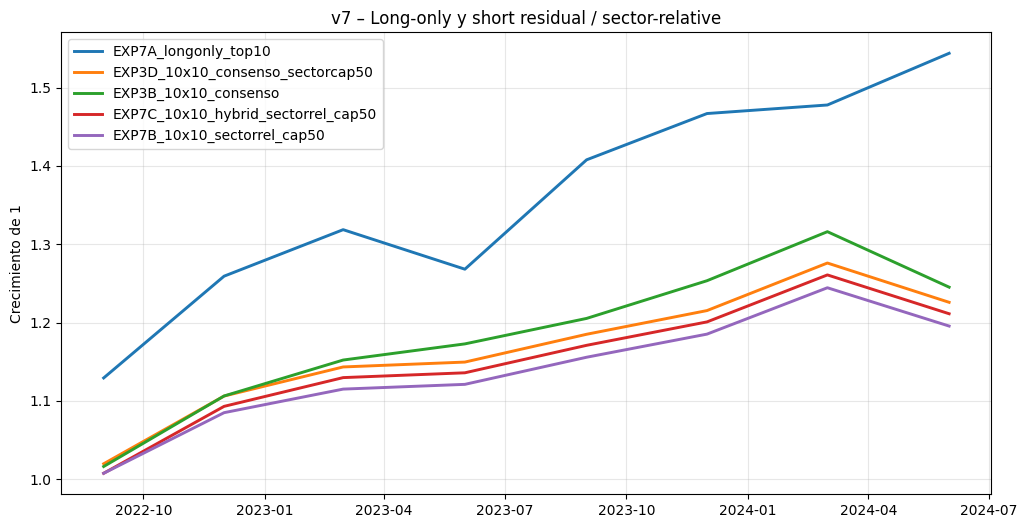


Diagnóstico automático v7
Ganador v7: EXP7A_longonly_top10
  · Ret anual L/S: +24.25%
  · Sharpe:        1.98
  · Beta vs SPY:   +0.92
  · MDD:           -3.83%
  · Short anual:   +nan%


In [150]:

print("\n" + "="*80)
print("EXPERIMENTOS SHORT – v7 (long-only + short residual / sector-relative)")
print("="*80)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _group_badness_rank(s: pd.Series, group: pd.Series | None, *, lower_is_worse: bool = True, min_group: int = 3) -> pd.Series:
    x = pd.to_numeric(pd.Series(s), errors="coerce")
    base = _badness_rank(x, lower_is_worse=lower_is_worse)
    if group is None:
        return base
    g = pd.Series(group, index=x.index)
    out = pd.Series(np.nan, index=x.index, dtype=float)
    valid = ~(g.isna()) & ~(x.isna())
    if valid.sum() == 0:
        return base
    for sec, idx in g[valid].groupby(g[valid]).groups.items():
        idx = list(idx)
        if len(idx) >= min_group:
            out.loc[idx] = _badness_rank(x.loc[idx], lower_is_worse=lower_is_worse)
    return out.fillna(base).astype(float)

def _build_short_overlay_sectorrel(g: pd.DataFrame, meta: dict) -> pd.Series:
    sector_col = meta.get("sector_col")
    grp = g[sector_col] if (sector_col and sector_col in g.columns) else None

    pieces = {
        "modelo_sr": _group_badness_rank(g["score_exp"], grp, lower_is_worse=True),
    }

    mom_col = meta.get("mom_col")
    if mom_col and mom_col in g.columns:
        pieces["mom_sr"] = _group_badness_rank(g[mom_col], grp, lower_is_worse=True)

    val_col = meta.get("val_col")
    if val_col and val_col in g.columns:
        pieces["val_sr"] = _group_badness_rank(g[val_col], grp, lower_is_worse=False)

    qual_col = meta.get("qual_col")
    if qual_col and qual_col in g.columns:
        pieces["qual_sr"] = _group_badness_rank(g[qual_col], grp, lower_is_worse=True)

    # Sector score global opcional: si un sector entero se ve débil, conservar algo de esa información.
    sec_col = meta.get("sec_col")
    if sec_col and sec_col in g.columns:
        pieces["sector_global"] = _badness_rank(g[sec_col], lower_is_worse=True)

    weights = {
        "modelo_sr": 0.45,
        "mom_sr": 0.25,
        "val_sr": 0.10,
        "qual_sr": 0.10,
        "sector_global": 0.10,
    }

    available = {k: v for k, v in pieces.items() if isinstance(v, pd.Series)}
    if not available:
        return _badness_rank(g["score_exp"], lower_is_worse=True)

    w_sum = sum(weights.get(k, 0.0) for k in available.keys())
    combo = pd.Series(0.0, index=g.index, dtype=float)
    for k, ser in available.items():
        combo = combo.add((weights.get(k, 0.0) / w_sum) * ser, fill_value=0.0)
    return combo.astype(float)

def _run_long_only_benchmark(
    df_exp: pd.DataFrame,
    meta: dict,
    *,
    strategy_name: str = "EXP7A_longonly_top10",
    long_frac: float = 0.10,
    min_names: int = 5,
):
    periods_per_year = int(meta.get("periods_per_year", 4))
    monthly = []

    for mes, g0 in df_exp.groupby("Mes", sort=True):
        g = g0.dropna(subset=["score_exp", "ret_eval"]).copy()
        if len(g) < max(10, 2 * min_names):
            continue
        n = len(g)
        n_long = max(min_names, int(math.ceil(long_frac * n)))
        long_leg = g.sort_values("score_exp", ascending=False).head(n_long).copy()
        ret_long = float(long_leg["ret_eval"].mean()) if len(long_leg) else np.nan
        monthly.append({
            "Mes": mes,
            "ret_long": ret_long,
            "ret_ls": ret_long,   # para reutilizar métricas comparables
            "n_universo": n,
            "n_long": len(long_leg),
        })

    ser = pd.DataFrame(monthly).set_index("Mes").sort_index() if monthly else pd.DataFrame()
    if ser.empty:
        return {"name": strategy_name, "monthly": ser, "summary": pd.Series(dtype=float)}

    stats = _annualized_stats(ser["ret_ls"], periods_per_year=periods_per_year, rf_per_period=0.0)
    beta, alpha = _beta_alpha_vs_spy(ser["ret_ls"], periods_per_year=periods_per_year)

    summary = {
        "estrategia": strategy_name,
        "ret_total_ls": stats["ret_total"],
        "ret_anual_ls": stats["ret_anual"],
        "vol_anual_ls": stats["vol_anual"],
        "sharpe_ls": stats["sharpe"],
        "hit_ratio_ls": stats["hit_ratio"],
        "mdd_ls": stats["mdd"],
        "beta_spy": beta,
        "alpha_anual": alpha,
        "ret_anual_long": stats["ret_anual"],
        "ret_anual_short": np.nan,
        "pool_short_prom": np.nan,
        "short_names_prom": 0.0,
        "meses": int(len(ser)),
        "variant": "long_only",
    }
    return {"name": strategy_name, "monthly": ser, "summary": summary}

def _run_short_strategy_sectorrel(
    df_exp: pd.DataFrame,
    meta: dict,
    *,
    strategy_name: str,
    long_frac: float = 0.10,
    short_frac: float = 0.10,
    min_names: int = 5,
    candidate_mult: float = 2.5,
    require_negative_mom: bool = True,
    sector_cap: float | None = 0.50,
    hybrid_weight: float = 0.50,   # peso del overlay sector-relative; resto = consenso base
    beta_filter_quantile: float | None = None,
):
    mom_col = meta.get("mom_col")
    sector_col = meta.get("sector_col")
    beta_col = meta.get("beta_col")
    periods_per_year = int(meta.get("periods_per_year", 4))
    monthly = []

    for mes, g0 in df_exp.groupby("Mes", sort=True):
        g = g0.dropna(subset=["score_exp", "ret_eval"]).copy()
        if len(g) < max(10, 2 * min_names):
            continue

        n = len(g)
        n_long = max(min_names, int(math.ceil(long_frac * n)))
        n_short = max(min_names, int(math.ceil(short_frac * n)))
        n_pool = max(n_short, int(math.ceil(candidate_mult * n_short)))

        long_leg = g.sort_values("score_exp", ascending=False).head(n_long).copy()
        short_pool = g.sort_values("score_exp", ascending=True).head(n_pool).copy()

        n_mom_candidates = np.nan
        if require_negative_mom and mom_col and mom_col in short_pool.columns:
            short_pool_m = short_pool[pd.to_numeric(short_pool[mom_col], errors="coerce") < 0].copy()
            n_mom_candidates = len(short_pool_m)
            if len(short_pool_m) >= min_names:
                short_pool = short_pool_m

        n_beta_filtered = 0
        if beta_filter_quantile is not None and beta_col and beta_col in short_pool.columns:
            beta_vals = pd.to_numeric(short_pool[beta_col], errors="coerce")
            if beta_vals.notna().sum() >= max(min_names, 5):
                cut = float(beta_vals.quantile(beta_filter_quantile))
                filt = short_pool[beta_vals <= cut].copy()
                n_beta_filtered = int(len(short_pool) - len(filt))
                if len(filt) >= min_names:
                    short_pool = filt

        short_pool = short_pool.copy()
        short_pool["short_overlay_base"] = _build_short_overlay(short_pool, meta)
        short_pool["short_overlay_sectorrel"] = _build_short_overlay_sectorrel(short_pool, meta)
        hw = float(hybrid_weight)
        short_pool["short_overlay_combo"] = (1.0 - hw) * short_pool["short_overlay_base"] + hw * short_pool["short_overlay_sectorrel"]

        short_leg, n_skipped_cap = _select_with_sector_cap(
            short_pool,
            n_pick=n_short,
            score_col="short_overlay_combo",
            sector_col=sector_col,
            max_sector_frac=sector_cap,
        )
        if len(short_leg) < min_names:
            short_leg = short_pool.sort_values("short_overlay_combo", ascending=False).head(n_short).copy()

        ret_long = float(long_leg["ret_eval"].mean()) if len(long_leg) else np.nan
        ret_short = float(-short_leg["ret_eval"].mean()) if len(short_leg) else np.nan
        ret_ls = ret_long + ret_short if (np.isfinite(ret_long) and np.isfinite(ret_short)) else np.nan

        monthly.append({
            "Mes": mes,
            "ret_long": ret_long,
            "ret_short": ret_short,
            "ret_ls": ret_ls,
            "n_universo": n,
            "n_long": len(long_leg),
            "n_short": len(short_leg),
            "n_pool_short": len(short_pool),
            "n_mom_candidates": n_mom_candidates,
            "n_beta_filtered": n_beta_filtered,
            "n_skipped_cap": n_skipped_cap,
            "avg_short_score": float(short_leg["score_exp"].mean()) if len(short_leg) else np.nan,
            "avg_short_ret": float(short_leg["ret_eval"].mean()) if len(short_leg) else np.nan,
            "avg_short_mom": float(short_leg[mom_col].mean()) if (len(short_leg) and mom_col and mom_col in short_leg.columns) else np.nan,
            "avg_short_combo": float(short_leg["short_overlay_combo"].mean()) if len(short_leg) else np.nan,
            "avg_short_sectorrel": float(short_leg["short_overlay_sectorrel"].mean()) if len(short_leg) else np.nan,
        })

    ser = pd.DataFrame(monthly).set_index("Mes").sort_index() if monthly else pd.DataFrame()
    if ser.empty:
        return {"name": strategy_name, "monthly": ser, "summary": pd.Series(dtype=float)}

    stats = _annualized_stats(ser["ret_ls"], periods_per_year=periods_per_year, rf_per_period=0.0)
    beta, alpha = _beta_alpha_vs_spy(ser["ret_ls"], periods_per_year=periods_per_year)

    summary = {
        "estrategia": strategy_name,
        "ret_total_ls": stats["ret_total"],
        "ret_anual_ls": stats["ret_anual"],
        "vol_anual_ls": stats["vol_anual"],
        "sharpe_ls": stats["sharpe"],
        "hit_ratio_ls": stats["hit_ratio"],
        "mdd_ls": stats["mdd"],
        "beta_spy": beta,
        "alpha_anual": alpha,
        "ret_anual_long": _annualized_stats(ser["ret_long"], periods_per_year=periods_per_year)["ret_anual"],
        "ret_anual_short": _annualized_stats(ser["ret_short"], periods_per_year=periods_per_year)["ret_anual"],
        "prom_short_mom": float(ser["avg_short_mom"].mean()) if "avg_short_mom" in ser.columns else np.nan,
        "pool_short_prom": float(ser["n_pool_short"].mean()) if "n_pool_short" in ser.columns else np.nan,
        "short_names_prom": float(ser["n_short"].mean()) if "n_short" in ser.columns else np.nan,
        "meses": int(len(ser)),
        "variant": "sector_relative",
        "hybrid_weight": float(hybrid_weight),
        "sector_cap": sector_cap,
        "beta_filter_q": beta_filter_quantile if beta_filter_quantile is not None else np.nan,
    }
    return {"name": strategy_name, "monthly": ser, "summary": summary}

if "SHORT_EXP_PANEL" not in globals() or "SHORT_EXP_META" not in globals():
    print("❌ Faltan SHORT_EXP_PANEL / SHORT_EXP_META. Ejecuta primero los bloques 162–166.")
else:
    df_exp = globals()["SHORT_EXP_PANEL"]
    meta = globals()["SHORT_EXP_META"]
    # Intentar enriquecer con beta por acción si existe
    try:
        if "_ensure_beta_in_short_panel" in globals():
            beta_col_v7 = _ensure_beta_in_short_panel()
        else:
            beta_col_v7 = meta.get("beta_col")
    except Exception as e:
        beta_col_v7 = meta.get("beta_col")
        print(f"⚠️ No se pudo actualizar beta en panel v7: {e}")

    print("Preparando y corriendo variantes v7...")
    print(f"beta_col usable: {beta_col_v7}")

    v7_results = []
    v7_results.append(_run_long_only_benchmark(
        df_exp, meta, strategy_name="EXP7A_longonly_top10", long_frac=0.10, min_names=5
    ))
    v7_results.append(_run_short_strategy_sectorrel(
        df_exp, meta,
        strategy_name="EXP7B_10x10_sectorrel_cap50",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True, sector_cap=0.50,
        hybrid_weight=1.00, beta_filter_quantile=None,
    ))
    v7_results.append(_run_short_strategy_sectorrel(
        df_exp, meta,
        strategy_name="EXP7C_10x10_hybrid_sectorrel_cap50",
        long_frac=0.10, short_frac=0.10,
        require_negative_mom=True, sector_cap=0.50,
        hybrid_weight=0.50, beta_filter_quantile=None,
    ))
    if beta_col_v7 is not None:
        v7_results.append(_run_short_strategy_sectorrel(
            df_exp, meta,
            strategy_name="EXP7D_10x10_hybrid_sectorrel_betafilter_cap50",
            long_frac=0.10, short_frac=0.10,
            require_negative_mom=True, sector_cap=0.50,
            hybrid_weight=0.50, beta_filter_quantile=0.75,  # excluye el cuartil más alto de beta dentro del pool
        ))

    if "SHORT_EXP_RESULTS" not in globals():
        SHORT_EXP_RESULTS = {}
    else:
        SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]
    for r in v7_results:
        SHORT_EXP_RESULTS[r["name"]] = r
    globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

    v7_summary = pd.DataFrame([r["summary"] for r in v7_results]).sort_values(
        ["sharpe_ls", "ret_anual_ls", "alpha_anual"], ascending=False
    ).reset_index(drop=True)

    print("\nResumen – v7")
    display(v7_summary.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "ret_anual_long": "{:+.2%}",
        "ret_anual_short": "{:+.2%}",
        "prom_short_mom": "{:+.3f}",
        "pool_short_prom": "{:.1f}",
        "short_names_prom": "{:.1f}",
        "hybrid_weight": "{:.0%}",
        "sector_cap": "{:.0%}",
        "beta_filter_q": "{:.0%}",
    }))

    compare_names = ["EXP3D_10x10_consenso_sectorcap50", "EXP3B_10x10_consenso"] + list(v7_summary["estrategia"])
    rows = []
    for name in compare_names:
        if name in SHORT_EXP_RESULTS:
            rows.append(SHORT_EXP_RESULTS[name]["summary"])
    if rows:
        compare = pd.DataFrame(rows).sort_values(["sharpe_ls", "ret_anual_ls"], ascending=False).reset_index(drop=True)
        print("\nComparación focal contra bases previas + v7")
        display(compare.style.format({
            "ret_total_ls": "{:+.2%}",
            "ret_anual_ls": "{:+.2%}",
            "vol_anual_ls": "{:.2%}",
            "sharpe_ls": "{:.2f}",
            "hit_ratio_ls": "{:.0%}",
            "mdd_ls": "{:+.2%}",
            "beta_spy": "{:+.2f}",
            "alpha_anual": "{:+.2%}",
            "ret_anual_long": "{:+.2%}",
            "ret_anual_short": "{:+.2%}",
            "hybrid_weight": "{:.0%}",
            "sector_cap": "{:.0%}",
            "beta_filter_q": "{:.0%}",
        }))

        # Curvas de equity solo si hay monthly con índice usable
        plt.figure(figsize=(12, 6))
        plotted = 0
        for name in compare["estrategia"].head(5):
            monthly = SHORT_EXP_RESULTS.get(name, {}).get("monthly")
            if monthly is None or getattr(monthly, "empty", True):
                continue
            if "ret_ls" not in monthly.columns:
                continue
            eq = (1.0 + pd.Series(monthly["ret_ls"]).fillna(0.0)).cumprod()
            idx = monthly.index if monthly.index.name == "Mes" else eq.index
            try:
                if isinstance(idx, pd.PeriodIndex):
                    x = idx.to_timestamp()
                else:
                    x = pd.to_datetime(idx, errors="coerce")
                plt.plot(x, eq.values, linewidth=2.1, label=name)
                plotted += 1
            except Exception:
                continue
        if plotted > 0:
            plt.title("v7 – Long-only y short residual / sector-relative")
            plt.ylabel("Crecimiento de 1")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            print("ℹ️ No se pudieron graficar curvas de equity en v7, pero las métricas sí quedaron calculadas.")

        if not v7_summary.empty:
            winner = v7_summary.iloc[0]
            print("\nDiagnóstico automático v7")
            print(f"Ganador v7: {winner['estrategia']}")
            print(f"  · Ret anual L/S: {winner['ret_anual_ls']:+.2%}")
            print(f"  · Sharpe:        {winner['sharpe_ls']:.2f}")
            print(f"  · Beta vs SPY:   {winner['beta_spy']:+.2f}")
            print(f"  · MDD:           {winner['mdd_ls']:+.2%}")
            print(f"  · Short anual:   {winner.get('ret_anual_short', np.nan):+.2%}")


# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 8 – grilla de tamaños de portafolio
# ------------------------------------------------------------------------------
# Objetivo:
#   - Exprimir una de las últimas palancas simples y defendibles que quedan:
#     variar el tamaño del portafolio.
#   - Probar si la señal mejora con más o menos concentración, tanto en long-only
#     como en long-short.
#   - Mantener intacto el pipeline principal, reutilizando la mejor lógica
#     conocida para L/S: consenso + momentum negativo + sector cap suave.
#
# Se prueban dos familias:
#   1) Long-only:
#        EXP8A_longonly_top05
#        EXP8B_longonly_top10
#        EXP8C_longonly_top15
#        EXP8D_longonly_top20
#        EXP8E_longonly_top25
#   2) Long-short:
#        EXP8F_10x10_consenso_cap50
#        EXP8G_15x10_consenso_cap50
#        EXP8H_20x10_consenso_cap50
#        EXP8I_10x05_consenso_cap50
#        EXP8J_10x15_consenso_cap50
# ==============================================================================



EXPERIMENTOS SHORT – v8 (grilla de tamaños de portafolio)

1) Corriendo long-only con distintos tamaños...
2) Corriendo long-short con distintos tamaños...

Resumen – v8 long-only


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,pool_short_prom,short_names_prom,meses,variant,spy_ret_total,spy_ret_anual,spy_vol_anual,spy_sharpe,activo_vs_spy_anual,info_ratio_vs_spy,univ_ret_total,univ_ret_anual,univ_vol_anual,univ_sharpe,activo_vs_univ_anual,info_ratio_vs_univ
0,EXP8A_longonly_top05,+60.53%,+26.70%,8.62%,2.86,100%,+0.00%,+0.63,+8.20%,0.266988,nan,nan,0.000000,8,long_only,+64.71%,+28.34%,9.22%,2.83,-1.64%,-0.20,+49.82%,+22.40%,12.44%,1.72,+3.20%,0.58
1,EXP8B_longonly_top10,+54.37%,+24.25%,11.57%,1.98,88%,-3.83%,+0.92,-1.19%,0.242458,nan,nan,0.000000,8,long_only,+64.71%,+28.34%,9.22%,2.83,-3.46%,-0.41,+49.82%,+22.40%,12.44%,1.72,+1.44%,0.43
2,EXP8C_longonly_top15,+59.02%,+26.10%,12.56%,1.95,88%,-2.35%,+1.01,-1.89%,0.261040,nan,nan,0.000000,8,long_only,+64.71%,+28.34%,9.22%,2.83,-1.88%,-0.19,+49.82%,+22.40%,12.44%,1.72,+3.12%,0.84
3,EXP8D_longonly_top20,+60.81%,+26.81%,13.72%,1.84,88%,-2.61%,+1.02,-1.45%,0.268115,nan,nan,0.000000,8,long_only,+64.71%,+28.34%,9.22%,2.83,-1.29%,-0.09,+49.82%,+22.40%,12.44%,1.72,+3.80%,0.76
4,EXP8E_longonly_top25,+58.53%,+25.91%,13.84%,1.77,75%,-2.98%,+1.08,-3.68%,0.259099,nan,nan,0.000000,8,long_only,+64.71%,+28.34%,9.22%,2.83,-2.00%,-0.17,+49.82%,+22.40%,12.44%,1.72,+3.05%,0.66



Resumen – v8 long-short


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,prom_short_mom,pool_short_prom,short_names_prom,beta_scale_prom,beta_neutral_share,meses,long_frac,short_frac,sector_cap
0,EXP8F_10x10_consenso_cap50,+22.58%,+10.72%,7.11%,1.48,88%,-3.93%,+0.21,+5.00%,+24.25%,-12.32%,+0.047,40.1,16.5,1.000000,0.000000,8,10%,10%,50%
1,EXP8G_15x10_consenso_cap50,+26.25%,+12.36%,9.11%,1.34,88%,-5.98%,+0.30,+4.30%,+26.10%,-12.32%,+0.047,40.1,16.5,1.000000,0.000000,8,15%,10%,50%
2,EXP8H_20x10_consenso_cap50,+27.81%,+13.06%,10.15%,1.27,88%,-5.97%,+0.31,+4.74%,+26.81%,-12.32%,+0.047,40.1,16.5,1.000000,0.000000,8,20%,10%,50%
3,EXP8J_10x15_consenso_cap50,+23.36%,+11.07%,9.64%,1.14,75%,-4.75%,-0.03,+11.94%,+24.25%,-12.29%,+0.026,44.9,19.2,1.000000,0.000000,8,10%,15%,50%
4,EXP8I_10x05_consenso_cap50,+13.72%,+6.64%,11.74%,0.60,50%,-8.94%,+0.66,-10.04%,+24.25%,-15.51%,+0.057,23.0,9.0,1.000000,0.000000,8,10%,5%,50%



Comparación focal contra bases previas + v8


,estrategia,ret_total_ls,ret_anual_ls,vol_anual_ls,sharpe_ls,hit_ratio_ls,mdd_ls,beta_spy,alpha_anual,ret_anual_long,ret_anual_short,pool_short_prom,short_names_prom,meses,variant,prom_short_mom,beta_scale_prom,beta_neutral_share,spy_ret_total,spy_ret_anual,spy_vol_anual,spy_sharpe,activo_vs_spy_anual,info_ratio_vs_spy,univ_ret_total,univ_ret_anual,univ_vol_anual,univ_sharpe,activo_vs_univ_anual,info_ratio_vs_univ,long_frac,short_frac,sector_cap
0,EXP8A_longonly_top05,+60.53%,+26.70%,8.62%,2.86,100%,+0.00%,+0.63,+8.20%,+26.70%,+nan%,nan,0.000000,8,long_only,nan,nan,nan,0.647112,+28.34%,0.092201,2.83,-1.64%,-0.20,0.498175,+22.40%,0.124448,1.72,+3.20%,0.58,nan%,nan%,nan
1,EXP7A_longonly_top10,+54.37%,+24.25%,11.57%,1.98,88%,-3.83%,+0.92,-1.19%,+24.25%,+nan%,nan,0.000000,8,long_only,nan,nan,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan%,nan%,nan
2,EXP8B_longonly_top10,+54.37%,+24.25%,11.57%,1.98,88%,-3.83%,+0.92,-1.19%,+24.25%,+nan%,nan,0.000000,8,long_only,nan,nan,nan,0.647112,+28.34%,0.092201,2.83,-3.46%,-0.41,0.498175,+22.40%,0.124448,1.72,+1.44%,0.43,nan%,nan%,nan
3,EXP8C_longonly_top15,+59.02%,+26.10%,12.56%,1.95,88%,-2.35%,+1.01,-1.89%,+26.10%,+nan%,nan,0.000000,8,long_only,nan,nan,nan,0.647112,+28.34%,0.092201,2.83,-1.88%,-0.19,0.498175,+22.40%,0.124448,1.72,+3.12%,0.84,nan%,nan%,nan
4,EXP8D_longonly_top20,+60.81%,+26.81%,13.72%,1.84,88%,-2.61%,+1.02,-1.45%,+26.81%,+nan%,nan,0.000000,8,long_only,nan,nan,nan,0.647112,+28.34%,0.092201,2.83,-1.29%,-0.09,0.498175,+22.40%,0.124448,1.72,+3.80%,0.76,nan%,nan%,nan
5,EXP8E_longonly_top25,+58.53%,+25.91%,13.84%,1.77,75%,-2.98%,+1.08,-3.68%,+25.91%,+nan%,nan,0.000000,8,long_only,nan,nan,nan,0.647112,+28.34%,0.092201,2.83,-2.00%,-0.17,0.498175,+22.40%,0.124448,1.72,+3.05%,0.66,nan%,nan%,nan
6,EXP3D_10x10_consenso_sectorcap50,+22.58%,+10.72%,7.11%,1.48,88%,-3.93%,+0.21,+5.00%,+24.25%,-12.32%,40.125000,16.500000,8,nan,0.046953,1.000000,0.000000,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan%,nan%,nan
7,EXP8F_10x10_consenso_cap50,+22.58%,+10.72%,7.11%,1.48,88%,-3.93%,+0.21,+5.00%,+24.25%,-12.32%,40.125000,16.500000,8,nan,0.046953,1.000000,0.000000,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,10%,10%,0.500000
8,EXP3B_10x10_consenso,+24.51%,+11.59%,8.07%,1.41,88%,-5.38%,+0.18,+6.70%,+24.25%,-11.66%,40.125000,16.500000,8,nan,0.019196,nan,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan%,nan%,nan
9,EXP8G_15x10_consenso_cap50,+26.25%,+12.36%,9.11%,1.34,88%,-5.98%,+0.30,+4.30%,+26.10%,-12.32%,40.125000,16.500000,8,nan,0.046953,1.000000,0.000000,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,nan,+nan%,nan,15%,10%,0.500000


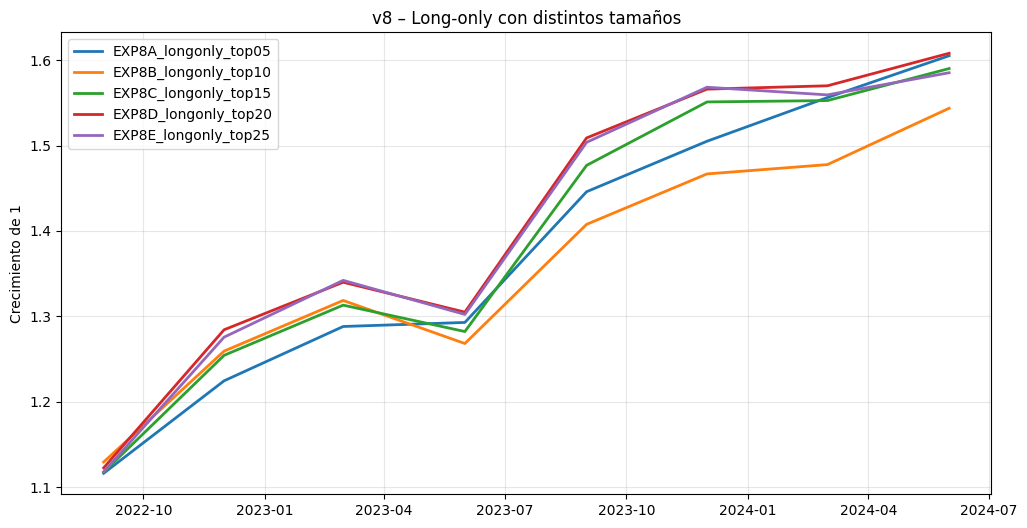

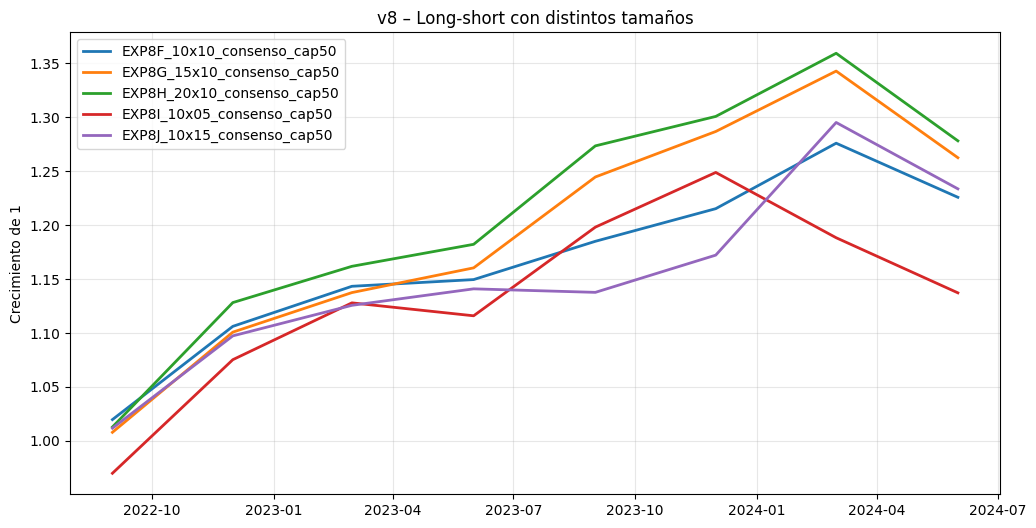


Diagnóstico automático v8 – long-only
Ganador long-only: EXP8A_longonly_top05
  · Ret anual:      +26.70%
  · Sharpe:         2.86
  · Beta vs SPY:    +0.63
  · Activo vs SPY:  -1.64%
  · Activo vs Univ: +3.20%

Diagnóstico automático v8 – long-short
Ganador long-short: EXP8F_10x10_consenso_cap50
  · Ret anual L/S:   +10.72%
  · Sharpe:          1.48
  · Beta vs SPY:     +0.21
  · Short anual:     -12.32%


In [151]:
print("\n" + "="*80)
print("EXPERIMENTOS SHORT – v8 (grilla de tamaños de portafolio)")
print("="*80)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "SHORT_EXP_PANEL" not in globals() or "SHORT_EXP_META" not in globals():
    raise RuntimeError("Falta SHORT_EXP_PANEL / SHORT_EXP_META. Ejecuta primero los bloques experimentales base.")

df_exp = globals()["SHORT_EXP_PANEL"].copy()
meta = dict(globals()["SHORT_EXP_META"])

# -------------------- Helpers locales --------------------
def _spy_series_from_bench_v8(target_index):
    if "bench_3m" not in globals() or getattr(globals()["bench_3m"], "empty", True):
        return pd.Series(index=target_index, dtype=float)
    bench = globals()["bench_3m"].copy()
    if "SPY" not in bench.columns:
        return pd.Series(index=target_index, dtype=float)
    spy = pd.Series(bench["SPY"]).astype(float)
    try:
        if isinstance(spy.index, pd.PeriodIndex):
            spy.index = spy.index.asfreq("M")
        else:
            spy.index = pd.to_datetime(spy.index, errors="coerce").to_period("M")
    except Exception:
        spy.index = pd.to_datetime(pd.Index(spy.index), errors="coerce").to_period("M")
    spy = spy[~spy.index.isna()]
    return spy.reindex(target_index)

def _universe_series_from_panel_v8(df_panel: pd.DataFrame):
    if df_panel is None or getattr(df_panel, "empty", True):
        return pd.Series(dtype=float)
    if "Mes" not in df_panel.columns or "ret_eval" not in df_panel.columns:
        return pd.Series(dtype=float)
    u = (df_panel.groupby("Mes", sort=True)["ret_eval"].mean()).astype(float)
    return pd.Series(u)

def _active_metrics_vs_bench(ret_ser: pd.Series, bench_ser: pd.Series, periods_per_year: int = 4):
    x = pd.Series(ret_ser).astype(float).dropna()
    y = pd.Series(bench_ser).astype(float).dropna()
    idx = x.index.intersection(y.index)
    x = x.reindex(idx).dropna()
    y = y.reindex(idx).dropna()
    if len(idx) == 0:
        return {
            "bench_ret_total": np.nan, "bench_ret_anual": np.nan, "bench_vol_anual": np.nan,
            "bench_sharpe": np.nan, "ret_activo_anual": np.nan, "info_ratio": np.nan,
        }
    s_b = _annualized_stats(y, periods_per_year=periods_per_year, rf_per_period=0.0)
    active = x - y
    s_a = _annualized_stats(active, periods_per_year=periods_per_year, rf_per_period=0.0)
    info_ratio = np.nan
    if len(active) > 1:
        sd = float(active.std(ddof=1))
        if np.isfinite(sd) and sd > 0:
            info_ratio = float(active.mean() / sd * np.sqrt(periods_per_year))
    return {
        "bench_ret_total": s_b["ret_total"],
        "bench_ret_anual": s_b["ret_anual"],
        "bench_vol_anual": s_b["vol_anual"],
        "bench_sharpe": s_b["sharpe"],
        "ret_activo_anual": s_a["ret_anual"],
        "info_ratio": info_ratio,
    }

def _augment_long_summary_with_bench(summary: dict, monthly: pd.DataFrame, df_panel: pd.DataFrame, periods_per_year: int = 4):
    ser = pd.Series(monthly["ret_ls"]).astype(float).dropna()
    spy = _spy_series_from_bench_v8(ser.index)
    uni = _universe_series_from_panel_v8(df_panel).reindex(ser.index)

    spy_metrics = _active_metrics_vs_bench(ser, spy, periods_per_year=periods_per_year)
    uni_metrics = _active_metrics_vs_bench(ser, uni, periods_per_year=periods_per_year)

    summary = dict(summary)
    summary.update({
        "spy_ret_total": spy_metrics["bench_ret_total"],
        "spy_ret_anual": spy_metrics["bench_ret_anual"],
        "spy_vol_anual": spy_metrics["bench_vol_anual"],
        "spy_sharpe": spy_metrics["bench_sharpe"],
        "activo_vs_spy_anual": spy_metrics["ret_activo_anual"],
        "info_ratio_vs_spy": spy_metrics["info_ratio"],

        "univ_ret_total": uni_metrics["bench_ret_total"],
        "univ_ret_anual": uni_metrics["bench_ret_anual"],
        "univ_vol_anual": uni_metrics["bench_vol_anual"],
        "univ_sharpe": uni_metrics["bench_sharpe"],
        "activo_vs_univ_anual": uni_metrics["ret_activo_anual"],
        "info_ratio_vs_univ": uni_metrics["info_ratio"],
    })
    return summary

def _run_ls_v8(df_exp: pd.DataFrame, meta: dict, **kwargs):
    # Preferir la versión "plus" (la que replicó EXP3D), con fallback a la simple.
    if "_run_short_strategy_plus" in globals():
        return _run_short_strategy_plus(
            df_exp, meta,
            candidate_mult=2.5,
            require_negative_mom=True,
            use_consensus=True,
            sector_cap=0.50,
            beta_neutral=False,
            **kwargs,
        )
    return _run_short_strategy(
        df_exp, meta,
        candidate_mult=2.5,
        require_negative_mom=True,
        use_consensus=True,
        sector_cap=0.50,
        **kwargs,
    )

periods_per_year = int(meta.get("periods_per_year", 4))

# -------------------- 1) Long-only: tamaños --------------------
print("\n1) Corriendo long-only con distintos tamaños...")

long_specs = [
    ("EXP8A_longonly_top05", 0.05),
    ("EXP8B_longonly_top10", 0.10),
    ("EXP8C_longonly_top15", 0.15),
    ("EXP8D_longonly_top20", 0.20),
    ("EXP8E_longonly_top25", 0.25),
]

v8_long_results = []
for name, frac in long_specs:
    r = _run_long_only_benchmark(df_exp, meta, strategy_name=name, long_frac=frac, min_names=5)
    if isinstance(r.get("summary"), dict):
        r["summary"] = _augment_long_summary_with_bench(r["summary"], r["monthly"], df_exp, periods_per_year=periods_per_year)
    v8_long_results.append(r)

# -------------------- 2) Long-short: tamaños --------------------
print("2) Corriendo long-short con distintos tamaños...")

ls_specs = [
    ("EXP8F_10x10_consenso_cap50", 0.10, 0.10),
    ("EXP8G_15x10_consenso_cap50", 0.15, 0.10),
    ("EXP8H_20x10_consenso_cap50", 0.20, 0.10),
    ("EXP8I_10x05_consenso_cap50", 0.10, 0.05),
    ("EXP8J_10x15_consenso_cap50", 0.10, 0.15),
]

v8_ls_results = []
for name, lf, sf in ls_specs:
    r = _run_ls_v8(
        df_exp, meta,
        strategy_name=name,
        long_frac=lf,
        short_frac=sf,
        min_names=5,
    )
    # dejar trazabilidad del tamaño
    if isinstance(r.get("summary"), dict):
        r["summary"]["long_frac"] = lf
        r["summary"]["short_frac"] = sf
        r["summary"]["sector_cap"] = 0.50
    v8_ls_results.append(r)

# Guardar en resultados globales
if "SHORT_EXP_RESULTS" not in globals():
    SHORT_EXP_RESULTS = {}
else:
    SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]
for r in v8_long_results + v8_ls_results:
    SHORT_EXP_RESULTS[r["name"]] = r
globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS

# -------------------- Resúmenes --------------------
v8_long_summary = pd.DataFrame([r["summary"] for r in v8_long_results]).sort_values(
    ["sharpe_ls", "ret_anual_ls"], ascending=False
).reset_index(drop=True)

v8_ls_summary = pd.DataFrame([r["summary"] for r in v8_ls_results]).sort_values(
    ["sharpe_ls", "ret_anual_ls", "alpha_anual"], ascending=False
).reset_index(drop=True)

print("\nResumen – v8 long-only")
display(v8_long_summary.style.format({
    "ret_total_ls": "{:+.2%}",
    "ret_anual_ls": "{:+.2%}",
    "vol_anual_ls": "{:.2%}",
    "sharpe_ls": "{:.2f}",
    "hit_ratio_ls": "{:.0%}",
    "mdd_ls": "{:+.2%}",
    "beta_spy": "{:+.2f}",
    "alpha_anual": "{:+.2%}",
    "spy_ret_total": "{:+.2%}",
    "spy_ret_anual": "{:+.2%}",
    "spy_vol_anual": "{:.2%}",
    "spy_sharpe": "{:.2f}",
    "activo_vs_spy_anual": "{:+.2%}",
    "info_ratio_vs_spy": "{:.2f}",
    "univ_ret_total": "{:+.2%}",
    "univ_ret_anual": "{:+.2%}",
    "univ_vol_anual": "{:.2%}",
    "univ_sharpe": "{:.2f}",
    "activo_vs_univ_anual": "{:+.2%}",
    "info_ratio_vs_univ": "{:.2f}",
}))

print("\nResumen – v8 long-short")
display(v8_ls_summary.style.format({
    "ret_total_ls": "{:+.2%}",
    "ret_anual_ls": "{:+.2%}",
    "vol_anual_ls": "{:.2%}",
    "sharpe_ls": "{:.2f}",
    "hit_ratio_ls": "{:.0%}",
    "mdd_ls": "{:+.2%}",
    "beta_spy": "{:+.2f}",
    "alpha_anual": "{:+.2%}",
    "ret_anual_long": "{:+.2%}",
    "ret_anual_short": "{:+.2%}",
    "prom_short_mom": "{:+.3f}",
    "pool_short_prom": "{:.1f}",
    "short_names_prom": "{:.1f}",
    "long_frac": "{:.0%}",
    "short_frac": "{:.0%}",
    "sector_cap": "{:.0%}",
}))

# -------------------- Comparaciones focales --------------------
compare_names = [
    "EXP7A_longonly_top10",
    "EXP3D_10x10_consenso_sectorcap50",
    "EXP3B_10x10_consenso",
] + list(v8_long_summary["estrategia"]) + list(v8_ls_summary["estrategia"])

rows = []
for name in compare_names:
    if name in SHORT_EXP_RESULTS:
        rows.append(SHORT_EXP_RESULTS[name]["summary"])

if rows:
    compare = pd.DataFrame(rows).drop_duplicates(subset=["estrategia"]).reset_index(drop=True)
    compare = compare.sort_values(["sharpe_ls", "ret_anual_ls"], ascending=False).reset_index(drop=True)

    print("\nComparación focal contra bases previas + v8")
    display(compare.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "ret_anual_long": "{:+.2%}",
        "ret_anual_short": "{:+.2%}",
        "long_frac": "{:.0%}",
        "short_frac": "{:.0%}",
        "spy_ret_anual": "{:+.2%}",
        "spy_sharpe": "{:.2f}",
        "activo_vs_spy_anual": "{:+.2%}",
        "info_ratio_vs_spy": "{:.2f}",
        "univ_ret_anual": "{:+.2%}",
        "univ_sharpe": "{:.2f}",
        "activo_vs_univ_anual": "{:+.2%}",
        "info_ratio_vs_univ": "{:.2f}",
    }))

# -------------------- Curvas de equity --------------------
# Long-only
plt.figure(figsize=(12, 6))
plotted = 0
for r in v8_long_results:
    monthly = r.get("monthly")
    if monthly is None or getattr(monthly, "empty", True) or "ret_ls" not in monthly.columns:
        continue
    eq = (1.0 + pd.Series(monthly["ret_ls"]).fillna(0.0)).cumprod()
    idx = eq.index
    x = idx.to_timestamp() if isinstance(idx, pd.PeriodIndex) else pd.to_datetime(idx, errors="coerce")
    plt.plot(x, eq.values, linewidth=2.0, label=r["name"])
    plotted += 1
if plotted > 0:
    plt.title("v8 – Long-only con distintos tamaños")
    plt.ylabel("Crecimiento de 1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# L/S
plt.figure(figsize=(12, 6))
plotted = 0
for r in v8_ls_results:
    monthly = r.get("monthly")
    if monthly is None or getattr(monthly, "empty", True) or "ret_ls" not in monthly.columns:
        continue
    eq = (1.0 + pd.Series(monthly["ret_ls"]).fillna(0.0)).cumprod()
    idx = eq.index
    x = idx.to_timestamp() if isinstance(idx, pd.PeriodIndex) else pd.to_datetime(idx, errors="coerce")
    plt.plot(x, eq.values, linewidth=2.0, label=r["name"])
    plotted += 1
if plotted > 0:
    plt.title("v8 – Long-short con distintos tamaños")
    plt.ylabel("Crecimiento de 1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# -------------------- Diagnóstico automático --------------------
if not v8_long_summary.empty:
    w_long = v8_long_summary.iloc[0]
    print("\nDiagnóstico automático v8 – long-only")
    print(f"Ganador long-only: {w_long['estrategia']}")
    print(f"  · Ret anual:      {w_long['ret_anual_ls']:+.2%}")
    print(f"  · Sharpe:         {w_long['sharpe_ls']:.2f}")
    print(f"  · Beta vs SPY:    {w_long['beta_spy']:+.2f}")
    print(f"  · Activo vs SPY:  {w_long.get('activo_vs_spy_anual', np.nan):+.2%}")
    print(f"  · Activo vs Univ: {w_long.get('activo_vs_univ_anual', np.nan):+.2%}")

if not v8_ls_summary.empty:
    w_ls = v8_ls_summary.iloc[0]
    print("\nDiagnóstico automático v8 – long-short")
    print(f"Ganador long-short: {w_ls['estrategia']}")
    print(f"  · Ret anual L/S:   {w_ls['ret_anual_ls']:+.2%}")
    print(f"  · Sharpe:          {w_ls['sharpe_ls']:.2f}")
    print(f"  · Beta vs SPY:     {w_ls['beta_spy']:+.2f}")
    print(f"  · Short anual:     {w_ls.get('ret_anual_short', np.nan):+.2%}")


# ==============================================================================
# BLOQUE EXPERIMENTAL SHORT 9 – long-only en TODO el CV-OOS
# ------------------------------------------------------------------------------
# Objetivo:
#   - Validar si la mejora observada en holdout para el long-only concentrado
#     también se sostiene cuando se mira TODO el CV-OOS extendido.
#   - Correr una grilla corta long-only (top05/top10/top15/top20/top25) sobre
#     `CV_OOS`, usando el score del modelo y la misma convención económica que
#     el bloque 19.3c.
#   - Comparar cada tamaño contra:
#       * SPY en la misma ventana temporal,
#       * universo promedio del panel CV_OOS.
# ==============================================================================

In [ ]:

print("\n" + "="*80)
print("EXPERIMENTOS LONG-ONLY – v9 (grilla sobre TODO el CV-OOS)")
print("="*80)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "CV_OOS" not in globals():
    raise RuntimeError("Falta CV_OOS. Ejecuta primero el BLOQUE 19.3c (CV-OOS extendido).")

cv_panel = globals()["CV_OOS"].copy()
if cv_panel.empty:
    raise RuntimeError("CV_OOS está vacío.")

# -------------------- columnas base --------------------
ret_col_cv = "ret_raw" if ("ret_raw" in cv_panel.columns and cv_panel["ret_raw"].notna().sum() > 0) else "y_true"
score_col_cv = "score_final" if "score_final" in cv_panel.columns else "y_pred"
ticker_col_cv = globals().get("TICKER_COL", "Empresa")
if ticker_col_cv not in cv_panel.columns:
    if "Empresa" in cv_panel.columns:
        ticker_col_cv = "Empresa"
    elif "ticker" in cv_panel.columns:
        ticker_col_cv = "ticker"

# Mes a Period[M]
if "Mes" not in cv_panel.columns:
    if "Fecha" in cv_panel.columns:
        cv_panel["Mes"] = pd.to_datetime(cv_panel["Fecha"], errors="coerce").dt.to_period("M")
    else:
        raise RuntimeError("CV_OOS no tiene Mes ni Fecha.")
else:
    if not pd.api.types.is_period_dtype(cv_panel["Mes"].dtype):
        cv_panel["Mes"] = pd.to_datetime(cv_panel["Mes"], errors="coerce").dt.to_period("M")

# Si falta ticker, crear uno sintético por row_id
if ticker_col_cv not in cv_panel.columns:
    if "row_id" in cv_panel.columns:
        cv_panel["_ticker_tmp"] = cv_panel["row_id"].astype(str)
        ticker_col_cv = "_ticker_tmp"
    else:
        cv_panel["_ticker_tmp"] = np.arange(len(cv_panel)).astype(str)
        ticker_col_cv = "_ticker_tmp"

# Normalización de tipos
cv_panel[score_col_cv] = pd.to_numeric(cv_panel[score_col_cv], errors="coerce")
cv_panel[ret_col_cv] = pd.to_numeric(cv_panel[ret_col_cv], errors="coerce")

# -------------------- helpers --------------------
def _annualized_stats_local(r: pd.Series, periods_per_year: int = 4):
    r = pd.Series(r).astype(float).dropna()
    if r.empty:
        return {
            "ret_total": np.nan, "ret_anual": np.nan, "vol_anual": np.nan,
            "sharpe": np.nan, "hit_ratio": np.nan, "mdd": np.nan
        }
    wealth = (1.0 + r).cumprod()
    ret_total = float(wealth.iloc[-1] - 1.0)
    years = len(r) / float(periods_per_year) if periods_per_year > 0 else np.nan
    if np.isfinite(years) and years > 0 and wealth.iloc[-1] > 0:
        ret_anual = float(wealth.iloc[-1] ** (1.0 / years) - 1.0)
    else:
        ret_anual = np.nan
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year)) if len(r) > 1 else np.nan
    mean_ann = float(r.mean() * periods_per_year) if len(r) > 0 else np.nan
    sharpe = float(mean_ann / vol) if (np.isfinite(vol) and vol > 0) else np.nan
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    mdd = float(dd.min()) if len(dd) else np.nan
    hit = float((r > 0).mean()) if len(r) else np.nan
    return {
        "ret_total": ret_total, "ret_anual": ret_anual, "vol_anual": vol,
        "sharpe": sharpe, "hit_ratio": hit, "mdd": mdd
    }

def _series_to_period_m_local(s):
    s = pd.Series(s).copy()
    try:
        if isinstance(s.index, pd.PeriodIndex):
            s.index = s.index.asfreq("M")
        else:
            s.index = pd.to_datetime(s.index, errors="coerce").to_period("M")
    except Exception:
        s.index = pd.to_datetime(pd.Index(s.index), errors="coerce").to_period("M")
    s = s[~s.index.isna()]
    if s.index.has_duplicates:
        s = s.groupby(level=0).last()
    return s.astype(float)

def _spy_series_cv(target_index):
    if "bench_3m" not in globals() or getattr(globals()["bench_3m"], "empty", True):
        return pd.Series(index=target_index, dtype=float)
    bench = globals()["bench_3m"].copy()
    if "SPY" not in bench.columns:
        return pd.Series(index=target_index, dtype=float)
    spy = pd.Series(bench["SPY"]).astype(float)
    spy = _series_to_period_m_local(spy)
    return spy.reindex(target_index)

def _universe_series_cv(df_panel):
    if df_panel is None or getattr(df_panel, "empty", True):
        return pd.Series(dtype=float)
    u = pd.Series(dtype=float)
    if "Mes" in df_panel.columns and ret_col_cv in df_panel.columns:
        u = df_panel.groupby("Mes", sort=True)[ret_col_cv].mean().astype(float)
        if not isinstance(u.index, pd.PeriodIndex):
            u.index = pd.to_datetime(u.index, errors="coerce").to_period("M")
    return pd.Series(u)

def _active_metrics_local(ret_ser: pd.Series, bench_ser: pd.Series, periods_per_year: int = 4):
    x = pd.Series(ret_ser).astype(float).dropna()
    y = pd.Series(bench_ser).astype(float).dropna()
    idx = x.index.intersection(y.index)
    x = x.reindex(idx).dropna()
    y = y.reindex(idx).dropna()
    if len(idx) == 0:
        return {
            "bench_ret_total": np.nan, "bench_ret_anual": np.nan,
            "bench_vol_anual": np.nan, "bench_sharpe": np.nan,
            "activo_anual": np.nan, "info_ratio": np.nan,
            "beta": np.nan, "alpha_anual": np.nan,
        }
    sb = _annualized_stats_local(y, periods_per_year=periods_per_year)
    active = x - y
    sa = _annualized_stats_local(active, periods_per_year=periods_per_year)
    info_ratio = np.nan
    if len(active) > 1:
        sd = float(active.std(ddof=1))
        if np.isfinite(sd) and sd > 0:
            info_ratio = float(active.mean() / sd * np.sqrt(periods_per_year))
    beta = np.nan
    alpha_ann = np.nan
    if len(idx) > 1:
        vy = float(np.var(y, ddof=1))
        if np.isfinite(vy) and vy > 0:
            beta = float(np.cov(x, y, ddof=1)[0, 1] / vy)
            alpha_ann = float(sb["ret_anual"])
            if np.isfinite(beta) and np.isfinite(sb["ret_anual"]) and np.isfinite(_annualized_stats_local(x, periods_per_year=periods_per_year)["ret_anual"]):
                alpha_ann = float(_annualized_stats_local(x, periods_per_year=periods_per_year)["ret_anual"] - beta * sb["ret_anual"])
    return {
        "bench_ret_total": sb["ret_total"],
        "bench_ret_anual": sb["ret_anual"],
        "bench_vol_anual": sb["vol_anual"],
        "bench_sharpe": sb["sharpe"],
        "activo_anual": sa["ret_anual"],
        "info_ratio": info_ratio,
        "beta": beta,
        "alpha_anual": alpha_ann,
    }

def _run_long_only_cv(df_panel, *, long_frac: float, strategy_name: str, min_names: int = 5, periods_per_year: int = 4):
    monthly_rows = []
    for mes, g0 in df_panel.groupby("Mes", sort=True):
        g = g0.dropna(subset=[score_col_cv, ret_col_cv]).copy()
        if len(g) < max(10, 2 * min_names):
            continue
        n_long = int(math.ceil(len(g) * float(long_frac)))
        n_long = max(min_names, n_long)
        n_long = min(n_long, len(g))
        g = g.sort_values(score_col_cv, ascending=False)
        longs = g.head(n_long).copy()
        ret = float(longs[ret_col_cv].mean()) if len(longs) else np.nan
        monthly_rows.append({
            "Mes": mes,
            "ret_ls": ret,
            "n_total": int(len(g)),
            "n_long": int(len(longs)),
            "avg_score_long": float(longs[score_col_cv].mean()) if len(longs) else np.nan,
        })
    monthly = pd.DataFrame(monthly_rows)
    if monthly.empty:
        return {
            "name": strategy_name,
            "monthly": monthly,
            "summary": {
                "estrategia": strategy_name,
                "ret_total_ls": np.nan,
                "ret_anual_ls": np.nan,
                "vol_anual_ls": np.nan,
                "sharpe_ls": np.nan,
                "hit_ratio_ls": np.nan,
                "mdd_ls": np.nan,
                "beta_spy": np.nan,
                "alpha_anual": np.nan,
                "long_frac": long_frac,
                "meses": 0,
            }
        }
    monthly["Mes"] = pd.PeriodIndex(monthly["Mes"], freq="M")
    ser = pd.Series(monthly["ret_ls"].values, index=monthly["Mes"]).astype(float)

    stats = _annualized_stats_local(ser, periods_per_year=periods_per_year)
    spy = _spy_series_cv(ser.index)
    univ = _universe_series_cv(df_panel).reindex(ser.index)

    spy_m = _active_metrics_local(ser, spy, periods_per_year=periods_per_year)
    uni_m = _active_metrics_local(ser, univ, periods_per_year=periods_per_year)

    summary = {
        "estrategia": strategy_name,
        "ret_total_ls": stats["ret_total"],
        "ret_anual_ls": stats["ret_anual"],
        "vol_anual_ls": stats["vol_anual"],
        "sharpe_ls": stats["sharpe"],
        "hit_ratio_ls": stats["hit_ratio"],
        "mdd_ls": stats["mdd"],
        "beta_spy": spy_m["beta"],
        "alpha_anual": spy_m["alpha_anual"],
        "long_frac": long_frac,
        "meses": int(len(ser)),

        "spy_ret_total": spy_m["bench_ret_total"],
        "spy_ret_anual": spy_m["bench_ret_anual"],
        "spy_vol_anual": spy_m["bench_vol_anual"],
        "spy_sharpe": spy_m["bench_sharpe"],
        "activo_vs_spy_anual": spy_m["activo_anual"],
        "info_ratio_vs_spy": spy_m["info_ratio"],

        "univ_ret_total": uni_m["bench_ret_total"],
        "univ_ret_anual": uni_m["bench_ret_anual"],
        "univ_vol_anual": uni_m["bench_vol_anual"],
        "univ_sharpe": uni_m["bench_sharpe"],
        "activo_vs_univ_anual": uni_m["activo_anual"],
        "info_ratio_vs_univ": uni_m["info_ratio"],

        "n_long_prom": float(monthly["n_long"].mean()),
        "n_total_prom": float(monthly["n_total"].mean()),
    }
    return {"name": strategy_name, "monthly": monthly, "summary": summary}

periods_per_year_v9 = int(round(12 / int(globals().get("STEP_M", 3)))) if int(globals().get("STEP_M", 3)) > 0 else 4

print(f"CV_OOS panel listo: filas={len(cv_panel):,} | meses={cv_panel['Mes'].nunique():,} | ret_col={ret_col_cv} | score_col={score_col_cv}")
print(f"periods_per_year={periods_per_year_v9} | ticker_col={ticker_col_cv}")

# -------------------- grilla long-only CV-OOS --------------------
specs_v9 = [
    ("EXP9A_CV_longonly_top05", 0.05),
    ("EXP9B_CV_longonly_top10", 0.10),
    ("EXP9C_CV_longonly_top15", 0.15),
    ("EXP9D_CV_longonly_top20", 0.20),
    ("EXP9E_CV_longonly_top25", 0.25),
]

v9_results = []
for name, frac in specs_v9:
    print(f"Corriendo {name} ...")
    r = _run_long_only_cv(cv_panel, long_frac=frac, strategy_name=name, min_names=5, periods_per_year=periods_per_year_v9)
    v9_results.append(r)

# guardar global
if "SHORT_EXP_RESULTS" not in globals():
    SHORT_EXP_RESULTS = {}
else:
    SHORT_EXP_RESULTS = globals()["SHORT_EXP_RESULTS"]
for r in v9_results:
    SHORT_EXP_RESULTS[r["name"]] = r
globals()["SHORT_EXP_RESULTS"] = SHORT_EXP_RESULTS
globals()["V9_LONG_CV_RESULTS"] = v9_results

# -------------------- resumen --------------------
v9_summary = pd.DataFrame([r["summary"] for r in v9_results]).sort_values(
    ["sharpe_ls", "ret_anual_ls"], ascending=False
).reset_index(drop=True)

print("\nResumen – v9 long-only sobre TODO el CV-OOS")
display(v9_summary.style.format({
    "ret_total_ls": "{:+.2%}",
    "ret_anual_ls": "{:+.2%}",
    "vol_anual_ls": "{:.2%}",
    "sharpe_ls": "{:.2f}",
    "hit_ratio_ls": "{:.0%}",
    "mdd_ls": "{:+.2%}",
    "beta_spy": "{:+.2f}",
    "alpha_anual": "{:+.2%}",
    "spy_ret_total": "{:+.2%}",
    "spy_ret_anual": "{:+.2%}",
    "spy_vol_anual": "{:.2%}",
    "spy_sharpe": "{:.2f}",
    "activo_vs_spy_anual": "{:+.2%}",
    "info_ratio_vs_spy": "{:.2f}",
    "univ_ret_total": "{:+.2%}",
    "univ_ret_anual": "{:+.2%}",
    "univ_vol_anual": "{:.2%}",
    "univ_sharpe": "{:.2f}",
    "activo_vs_univ_anual": "{:+.2%}",
    "info_ratio_vs_univ": "{:.2f}",
    "long_frac": "{:.0%}",
    "n_long_prom": "{:.1f}",
    "n_total_prom": "{:.1f}",
}))

# -------------------- comparación focal --------------------
compare_names_v9 = [
    "EXP8A_longonly_top05",
    "EXP7A_longonly_top10",
    "EXP3D_10x10_consenso_sectorcap50",
    "EXP3B_10x10_consenso",
] + list(v9_summary["estrategia"])

rows = []
for name in compare_names_v9:
    if name in SHORT_EXP_RESULTS:
        rows.append(SHORT_EXP_RESULTS[name]["summary"])
if rows:
    compare_v9 = pd.DataFrame(rows).drop_duplicates(subset=["estrategia"]).reset_index(drop=True)
    compare_v9 = compare_v9.sort_values(["sharpe_ls", "ret_anual_ls"], ascending=False).reset_index(drop=True)
    print("\nComparación focal – holdout vs CV-OOS (long-only) + mejores L/S")
    display(compare_v9.style.format({
        "ret_total_ls": "{:+.2%}",
        "ret_anual_ls": "{:+.2%}",
        "vol_anual_ls": "{:.2%}",
        "sharpe_ls": "{:.2f}",
        "hit_ratio_ls": "{:.0%}",
        "mdd_ls": "{:+.2%}",
        "beta_spy": "{:+.2f}",
        "alpha_anual": "{:+.2%}",
        "spy_ret_anual": "{:+.2%}",
        "spy_sharpe": "{:.2f}",
        "activo_vs_spy_anual": "{:+.2%}",
        "info_ratio_vs_spy": "{:.2f}",
        "univ_ret_anual": "{:+.2%}",
        "univ_sharpe": "{:.2f}",
        "activo_vs_univ_anual": "{:+.2%}",
        "info_ratio_vs_univ": "{:.2f}",
        "long_frac": "{:.0%}",
        "n_long_prom": "{:.1f}",
    }))
    globals()["V9_COMPARE"] = compare_v9

# -------------------- curvas de equity --------------------
plt.figure(figsize=(12, 6))
plotted = 0
for r in v9_results:
    monthly = r.get("monthly")
    if monthly is None or monthly.empty:
        continue
    idx = pd.PeriodIndex(monthly["Mes"], freq="M")
    eq = (1.0 + pd.Series(monthly["ret_ls"].astype(float).values, index=idx)).cumprod()
    plt.plot(eq.index.to_timestamp("M"), eq.values, linewidth=2.0, label=r["name"])
    plotted += 1

spy_idx = None
if v9_results and not v9_results[0]["monthly"].empty:
    spy_idx = pd.PeriodIndex(v9_results[0]["monthly"]["Mes"], freq="M")
    spy = _spy_series_cv(spy_idx)
    if len(spy.dropna()) > 0:
        eq_spy = (1.0 + spy.fillna(0.0)).cumprod()
        plt.plot(eq_spy.index.to_timestamp("M"), eq_spy.values, linestyle="--", linewidth=2.2, label="SPY (mismo tramo)")
        plotted += 1
    univ = _universe_series_cv(cv_panel).reindex(spy_idx)
    if len(univ.dropna()) > 0:
        eq_univ = (1.0 + univ.fillna(0.0)).cumprod()
        plt.plot(eq_univ.index.to_timestamp("M"), eq_univ.values, linestyle=":", linewidth=2.2, label="Universo promedio CV_OOS")
        plotted += 1

plt.title("v9 – Long-only sobre TODO el CV-OOS")
plt.xlabel("Fecha")
plt.ylabel("Índice de riqueza (base=1)")
if plotted > 0:
    plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

if not v9_summary.empty:
    winner = v9_summary.iloc[0]
    print("\n🏁 Ganador v9 (por Sharpe / retorno):")
    print(winner[[
        "estrategia", "ret_total_ls", "ret_anual_ls", "vol_anual_ls",
        "sharpe_ls", "beta_spy", "alpha_anual",
        "activo_vs_spy_anual", "activo_vs_univ_anual"
    ]].to_string())
